# CBAM-EfficientNet-B3 **v26** - Cross-Domain Vegetable Leaf Disease Detection
## Premier University, Chattogram · Partha Nath · Tahmid Jamal · Taofiq Omar Raju

> **v26 is a correctness + reframing pass over v25.** No cell from v25 was edited.
> All corrections are **additive override cells**; Python takes the last definition.

### What changed and why

| New block | Fixes |
|---|---|
| **1.6** Correctness overrides | binary-AUC branch (`except: auc=0.0` printed failures as measurements) · macro-F1/BalAcc/MCC · degenerate-prediction guard · McNemar `b+c==0` no longer returns `chi2=inf, p=0.0000 ***` · CPU benchmark warmup · `strip_se=True` |
| **6.1 / 6.2** Leakage audit | Block 6 falls back to a stratified split every run (`24 groups ~ 20 classes`); provenance was destroyed by flattening, so groups are rebuilt from perceptual hashes |
| **7.1** Attention audit | EfficientNet-B3 ships **26 built-in SE modules** — the "Baseline" was never attention-free |
| **12.7** Zero-shot | **Headline.** PlantDoc + CCMT (28,248 images downloaded and never used) as genuine unseen domains |
| **12.8** Exp D evaluation | Exp D was reported from *training val* accuracy with no test set |
| **21.6** Derived summary | every number computed from saved artifacts |

### The correction that reframes the thesis
`torchvision`'s `MBConv` instantiates `SqueezeExcitation(expanded_channels, max(1, input_channels // 4))`.
B3 therefore contains **26 SE modules before you add anything**. The "SE" arm stacked 5 more on top of 26 —
which is why Baseline (84.226%) and SE (84.228%) differ by **0.002 pp** across 5 seeds.
The ablation could not have shown an attention effect. Block 7.1 measures this; `strip_se=True` gives the real control.

### Run order
Block 1 → **1.6** → 2…6 → **6.1** → (**6.2** only if leakage) → 7 → **7.1** → 8…12.6 → **12.7** → **12.8** → 13…21 → **21.6**


## Block 1 — Session Recovery, Config & All Class Definitions

In [1]:
# ============================================================
# BLOCK 1: SESSION RECOVERY + CONFIG + ALL DEFINITIONS (v15)
# ============================================================
import os, sys, json, shutil, random, warnings, time, hashlib, zipfile, io, base64, gc
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')
import os as _os
_os.environ['PYTHONWARNINGS'] = 'ignore'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, ConcatDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import torchvision
from torchvision import transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights, efficientnet_b3, EfficientNet_B3_Weights
from PIL import Image, ImageOps, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score, roc_curve)
from sklearn.manifold import TSNE
from statsmodels.stats.contingency_tables import mcnemar
from tqdm.std import tqdm  # v23: text-mode bars, no Jupyter widgets
try:
    import captum.attr as captum_attr
    CAPTUM = True
except: CAPTUM = False
try:
    from lime import lime_image
    LIME = True
except: LIME = False

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Noto Sans SC']
plt.rcParams['axes.unicode_minus'] = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
if torch.cuda.is_available():
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True

SESSION_START = time.time()
SESSION_LIMIT_HR = 12
def session_status():
    elapsed = (time.time()-SESSION_START)/3600
    print(f'Session: {elapsed:.1f}h elapsed / {SESSION_LIMIT_HR-elapsed:.1f}h remaining')
    if SESSION_LIMIT_HR-elapsed < 2: print('⚠️  <2hr left — DOWNLOAD CHECKPOINTS NOW!')

class Config:
    IMG_SIZE = 300  # B3 optimal resolution (was 224)
    BATCH_SIZE = 32
    NUM_WORKERS = 4  # v16 FIX: was 0. Modern Kaggle images handle worker processes fine;
                     # single-threaded loading was the biggest hidden bottleneck given the
                     # 10-op augmentation pipeline. Revert to 0 if you ever see a DataLoader
                     # worker crash on your specific Kaggle image.
    CBAM_REDUCTION = 8  # FIX: was 4 (caused 2.33% std)
    SE_REDUCTION = 8
    BACKBONE = 'b3'  # v16 NEW: single source of truth. build_efficientnet() already
                     # defaulted to 'b3' but ~5 print statements elsewhere hardcoded the
                     # string "B0" (stale from an earlier version) - those now read
                     # CFG.BACKBONE.upper() instead of a separately-hardcoded literal.
    FIELD_EPOCHS = 150
    LAB_EPOCHS = 150
    FINETUNE_EPOCHS = 150
    BINARY_EPOCHS = 15    # v22: binary hits 100% by epoch 2; 150 was pure waste. Only affects Block 11.
    PATIENCE = 999   # early stopping OFF (user preference) - runs full epochs, best.pth kept  # Disabled — run all 150 epochs (user request)
                   # from train_model() entirely (see below) — patience never did anything
                   # regardless of this value. Both are fixed now: this reclaims a large
                   # fraction of your compute budget on runs that plateau before epoch 150.
    WARMUP_EPOCHS = 3
    LR_HEAD = 1e-3
    LR_BACKBONE = 1e-4  # FIX: was 1e-5
    LR_ATTENTION = 5e-4
    WEIGHT_DECAY = 1e-4
    LABEL_SMOOTHING = 0.1
    MIXUP_ALPHA = 0  # DISABLED — was causing 0% train accuracy
    GRAD_CLIP = 1.0
    SEEDS = [42, 123, 456, 789, 2024]  # FIX: was 3 seeds
    FOCAL_GAMMA = 1.0  # Lowered from 2.0
    FOCAL_ALPHA = 0.25
    USE_FOCAL_LOSS = True
    USE_CORAL = False
    CORAL_LAMBDA = 1.0
    USE_SWA = True
    SWA_START = 40
    USE_TTA = True
    CKPT_DIR = '/kaggle/working/checkpoints'
    DATA_DIR = '/kaggle/working/datasets'
    OUTPUT_DIR = '/kaggle/working'
    os.makedirs(CKPT_DIR, exist_ok=True)
    os.makedirs(DATA_DIR, exist_ok=True)
    NUM_CLASSES = 20
    CLASS_COUNTS = None

CFG = Config()

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

# =====================================================================
# v2 CORRECTION 1 of 2 - THE ATTENTION MODULES WERE NEVER TRAINABLE
# =====================================================================
# The v1 notebook initialised every added attention module with
#     nn.init.zeros_(W_out); nn.init.constant_(b_out, 10.0)
# so the gate starts at sigmoid(10) = 0.999954 - a clean identity, which was
# the intent. But sigma'(10) = 4.54e-05, so the gradient reaching those weights
# is divided by 5507. ChannelAttention.forward sums fc(avg)+fc(max), so ITS
# pre-activation is 20: sigma'(20) = 2.06e-09, a factor of 1.2e+08, which under
# torch.cuda.amp underflows fp16 to exactly zero.
#
# This is not a prediction. Measured in the shipped v1 checkpoints, all three
# seeds of both arms:
#     added W_out                          |max| = 0.000e+00   (exactly zero)
#     added b_out                          = 9.98483  (10.0 minus AdamW decay)
#     added W_in  |max| / (1/sqrt(fan_in)) = 0.992 .. 0.999    (never moved)
#     a trained tensor, same file, same ratio = 18.4 .. 23.8
# So the CBAM arm computed Baseline(x) * 0.999954 and the SE arm the same.
# The two "attention" arms were the Baseline network.
#
# THE FIX: keep a near-identity start, but out of saturation.
#   sigmoid(2.0) = 0.8808 with gradient 0.1050  -> trains (2313x v1)
# ChannelAttention gets HALF the value because its forward sums two passes,
# which is the specific detail v1 missed.
#
# ATTN_INIT_BIAS is checked at build time by assert_attention_trainable() and
# again at runtime on a real batch by Block 24.0. Raising it past ~3.0 fails
# both, by design.
ATTN_INIT_BIAS = 2.0


# ---- CBAM, SE, Models ----
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        r = max(channels//reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, r, 1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(r, channels, 1, bias=True))  # bias=True for identity init
        self.sigmoid = nn.Sigmoid()
        # v2: was 10.0. forward() sums fc(avg)+fc(max), so the two biases ADD and
        # the pre-activation was 20 -> sigmoid = 1 - 2e-9, gradient 2.06e-09.
        # Half of ATTN_INIT_BIAS per pass gives the intended pre-activation exactly.
        nn.init.zeros_(self.fc[2].weight)
        nn.init.constant_(self.fc[2].bias, ATTN_INIT_BIAS / 2.0)
    def forward(self, x):
        return x * self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=True)  # bias=True
        self.sigmoid = nn.Sigmoid()
        # v2: was 10.0 -> gate 0.999954, gradient 4.54e-05. Never trained.
        nn.init.zeros_(self.conv.weight)
        nn.init.constant_(self.conv.bias, ATTN_INIT_BIAS)
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()
    def forward(self, x):
        return self.sa(self.ca(x))

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        r = max(channels//reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, r, bias=False), nn.ReLU(inplace=True),
            nn.Linear(r, channels, bias=True))  # bias=True for identity init
        self.sigmoid = nn.Sigmoid()
        # v2: was 10.0 -> gate 0.999954, gradient 4.54e-05. Never trained.
        nn.init.zeros_(self.fc[2].weight)
        nn.init.constant_(self.fc[2].bias, ATTN_INIT_BIAS)
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * y.expand_as(x)

# EfficientNet stage output channels for CBAM/SE insertion
# B0: [24, 40, 80, 112, 192] at stages [2,3,4,5,6]
# B3: [32, 48, 96, 136, 232] at stages [2,3,4,5,6]
EFFICIENTNET_CHANNELS = {
    'b0': [24, 40, 80, 112, 192],
    'b3': [32, 48, 96, 136, 232],
}

def build_efficientnet(num_classes, attention='none', reduction=8, backbone='b3'):
    """Build EfficientNet with optional CBAM or SE attention.
    backbone: 'b0' or 'b3' (default b3 for 95%+ accuracy)"""
    if backbone == 'b3':
        weights = EfficientNet_B3_Weights.IMAGENET1K_V1
        model = efficientnet_b3(weights=weights)
        channels = EFFICIENTNET_CHANNELS['b3']
    else:
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        model = efficientnet_b0(weights=weights)
        channels = EFFICIENTNET_CHANNELS['b0']
    features = model.features
    if attention == 'cbam':
        for idx, ch in zip([2,3,4,5,6], channels):
            features[idx].add_module('cbam', CBAM(ch, reduction))
    elif attention == 'se':
        for idx, ch in zip([2,3,4,5,6], channels):
            features[idx].add_module('se', SEBlock(ch, reduction))
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_features, 512),
        nn.ReLU(inplace=True), nn.Dropout(0.2), nn.Linear(512, num_classes))
    return model

class AttentionDeadError(RuntimeError):
    """Raised when an attention gate is initialised into sigmoid saturation."""


def assert_attention_trainable(model, gate_band=(0.55, 0.95), verbose=True):
    """Refuse a model whose added attention modules cannot learn.

    Checks the two properties that matter, in this order:
      1. NEAR-IDENTITY - the gate starts close enough to 1 that the pretrained
         backbone is not disturbed;
      2. NOT SATURATED - sigma'(pre-activation) stays large enough for a
         gradient to survive.
    v1 satisfied (1) perfectly and failed (2) totally, which is exactly why a
    strict identity assertion would have PASSED the bug. Both are required.

    Raises AttentionDeadError; never returns silently on a dead module."""
    import math
    bad = []
    for name, m in model.named_modules():
        cls = type(m).__name__
        if cls == 'ChannelAttention':
            pre = 2.0 * float(m.fc[2].bias.detach().mean())   # two summed passes
        elif cls == 'SEBlock':
            pre = float(m.fc[2].bias.detach().mean())
        elif cls == 'SpatialAttention':
            pre = float(m.conv.bias.detach().mean())
        else:
            continue
        g = 1.0 / (1.0 + math.exp(-pre))
        grad = g * (1.0 - g)
        if verbose:
            print(f'    [attn-init] {name:<26} {cls:<17} pre-act {pre:5.2f}  '
                  f'gate {g:.4f}  grad {grad:.3e}')
        if not (gate_band[0] < g < gate_band[1]):
            bad.append(f'{name} ({cls}): pre-act {pre:.3f} -> gate {g:.6f}, grad {grad:.3e}')
    if bad:
        raise AttentionDeadError(
            'attention initialised outside the trainable band '
            + str(gate_band) + ':' + chr(10) + '  ' + (chr(10) + '  ').join(bad)
            + chr(10) + '  v1 used bias=10.0 -> gate 0.999954, grad 4.5e-05, and the weights'
            + chr(10) + '  were still EXACTLY 0.0 after 60 epochs of AdamW at lr=5e-4.')
    return model

# =====================================================================
# v2 - PROVENANCE TRAVELS WITH THE WEIGHTS
# =====================================================================
# Blocks 1.5, 7.9, 8, 11.9 and 23.0c each end with the same request: a saved
# artefact should carry enough information to verify itself. In v1 the saves
# were bare `torch.save(model.state_dict(), ...)`, so:
#   - a checkpoint and its history could be separated (Loop 1, the costliest
#     failure in this project: a history recording 83.98% ended up bolted onto
#     weights worth 32.71%);
#   - the integrity audit had to run a FULL forward pass over the validation
#     set to check a file, which is why it was affordable only twice;
#   - Block 23.0c could only report use_swa as UNKNOWN for 10 of 12 models.
#
# save_checkpoint() writes {'state_dict', 'meta'} plus a sidecar .meta.json
# holding a SHA-256 of the weights. load_weights() accepts BOTH the new dict
# form and every bare state_dict already on disk, so the 31 v1 checkpoints
# keep loading unchanged.

import hashlib

CKPT_FORMAT = 2


# ---------------------------------------------------------------
# v3.1: ONE torch.load for this notebook.
# ---------------------------------------------------------------
# PyTorch 2.6 flipped torch.load's default weights_only from False to True.
# The strict unpickler accepts tensors and little else, which breaks two
# things this notebook relies on:
#   - checkpoint metadata (a dict of plain values, but written by older code
#     with a torch.torch_version.TorchVersion in it);
#   - resume states, which carry optimiser, scheduler and GradScaler state
#     and were never tensors to begin with.
# Both are files this notebook wrote itself, so weights_only=False is the
# correct setting rather than a shortcut - it is exactly the trusted-source
# case the flag documents. New checkpoints are ALSO written primitive-only
# (see current_run_meta), so they load under either policy.
# ---------------------------------------------------------------
# v3.2: OUTPUT VOLUME CONTROL - the fix for "Aw, Snap!"
# ---------------------------------------------------------------
# The training loop called pbar.set_postfix() on every batch. At 613
# batches x 60 epochs that is 36,780 output updates per model, and the text
# changes each time so the notebook frontend cannot collapse them. Six
# models put roughly 20 MB of stream chunks into a single DOM node, the
# browser renderer runs out of memory, and Chrome kills the tab.
#
# The tab dying is not just cosmetic: it orphans the kernel, so the session
# ends UNCLEANLY and 'Persistence: Files only' never writes /kaggle/working.
# That is why every crash also loses the completed work.
#
# TQDM_MIN_INTERVAL is the whole fix: tqdm refreshes at most once every N
# seconds regardless of batch rate, so the update count stops scaling with
# the dataset.
TQDM_MIN_INTERVAL = 30.0     # seconds between progress refreshes
MAX_CELL_OUTPUT_MB = 8.0     # hard ceiling per training cell


def quiet_tqdm(iterable, **kw):
    # Same tqdm, but it cannot flood the notebook. mininterval throttles by
    # time; miniters stops a fast loop from refreshing between those ticks.
    from tqdm.std import tqdm as _t
    kw.setdefault('mininterval', TQDM_MIN_INTERVAL)
    kw.setdefault('miniters', 0)
    kw.setdefault('leave', False)
    kw.setdefault('ncols', 90)
    kw.setdefault('ascii', True)      # no unicode blocks to re-render
    return _t(iterable, **kw)


class OutputBudget:
    # A tripwire, not a formatter. If a cell ever produces more than
    # MAX_CELL_OUTPUT_MB of text it is a runaway printer, and the honest
    # response is to say so once and go silent rather than to take the
    # browser down with it.
    def __init__(self, limit_mb=None):
        self.limit = (limit_mb or MAX_CELL_OUTPUT_MB) * 1e6
        self.used = 0
        self.tripped = False

    def write(self, text):
        if self.tripped:
            return False
        self.used += len(text)
        if self.used > self.limit:
            self.tripped = True
            import sys as _s
            _s.__stdout__.write(
                f'{chr(10)}[output budget] this cell has printed '
                f'{self.used/1e6:.1f} MB and is now SILENCED to keep the '
                f'browser alive. Training continues; check the checkpoint '
                f'directory for progress.{chr(10)}')
            return False
        return True


def in_interactive_session():
    # Kaggle sets KAGGLE_KERNEL_RUN_TYPE to 'Batch' for Save & Run All and
    # 'Interactive' for an editor session. Anything else (a local run) is
    # treated as interactive, which is the cautious direction.
    return os.environ.get('KAGGLE_KERNEL_RUN_TYPE', 'Interactive') != 'Batch'

def torch_load_compat(path, map_location='cpu'):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        # torch < 1.13 has no weights_only kwarg at all
        return torch_load_compat(path, map_location=map_location)


def _jsonable(v):
    # Keep the checkpoint metadata to primitives.
    #
    # EXACT type checks, not isinstance - and this is the whole point.
    # torch.torch_version.TorchVersion is a SUBCLASS of str, and np.float64 is
    # a SUBCLASS of float, so isinstance() waves both straight through
    # unchanged and they pickle as the very globals the strict unpickler
    # refuses. An earlier version of this function used isinstance and did not
    # actually fix the bug it was written for; a round-trip test caught it.
    if v is None or type(v) in (bool, int, float, str):
        return v
    if isinstance(v, (list, tuple)):
        return [_jsonable(x) for x in v]
    if isinstance(v, dict):
        return {str(k): _jsonable(x) for k, x in v.items()}
    try:
        import numpy as _np
        if isinstance(v, _np.generic):
            return v.item()
    except Exception:
        pass
    # str/float/int SUBCLASSES land here and are flattened to the base type
    if isinstance(v, (bytes, bytearray)):
        return v.decode('utf-8', 'replace')
    if isinstance(v, bool):
        return bool(v)
    if isinstance(v, int):
        return int(v)
    if isinstance(v, float):
        return float(v)
    return str(v)

def _sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, 'rb') as fh:
        for b in iter(lambda: fh.read(chunk), b''):
            h.update(b)
    return h.hexdigest()


def current_run_meta(**extra):
    """Everything needed to reproduce or invalidate a checkpoint."""
    meta = {
        'ckpt_format': CKPT_FORMAT,
        'split_fingerprint': globals().get('SPLIT_FINGERPRINT'),
        'img_size': CFG.IMG_SIZE,
        'backbone': CFG.BACKBONE,
        'max_epochs': getattr(CFG, 'MAX_EPOCHS', None),
        'weight_decay': CFG.WEIGHT_DECAY,
        'label_smoothing': CFG.LABEL_SMOOTHING,
        'use_focal': CFG.USE_FOCAL_LOSS,
        'use_tta_at_eval': CFG.USE_TTA,
        'attn_init_bias': globals().get('ATTN_INIT_BIAS'),
        'select_metric': getattr(CFG, 'SELECT_METRIC', 'acc'),
        # v3.1: str(), not the raw attribute. torch.__version__ is a
        # torch.torch_version.TorchVersion, and pickling one into the
        # checkpoint made the file unreadable under PyTorch 2.6's strict
        # unpickler - which then made _verify_save DELETE it.
        'torch': str(torch.__version__),
    }
    meta.update(extra)
    # Everything in here must survive a strict unpickle, so nothing exotic
    # can be smuggled in through **extra either.
    return {k: _jsonable(v) for k, v in meta.items()}


def save_checkpoint(model, filename, meta=None, **extra):
    """Write weights AND provenance, then hash the file."""
    path = f'{CFG.CKPT_DIR}/{filename}'
    m = dict(current_run_meta(**extra))
    if meta:
        m.update(meta)
    sd = model.state_dict() if hasattr(model, 'state_dict') else model
    torch.save({'state_dict': sd, 'meta': m}, path)
    m['sha256'] = _sha256(path)
    m['bytes'] = os.path.getsize(path)
    with open(path.replace('.pth', '.meta.json'), 'w') as fh:
        json.dump(m, fh, indent=2, default=str)
    return path


def load_weights(path, map_location='cpu', return_meta=False):
    """Read either checkpoint format and return a plain state_dict.

    v1 files are bare state_dicts and load unchanged; v2 files are
    {'state_dict', 'meta'}. Nothing else in the notebook has to know."""
    obj = torch_load_compat(path, map_location=map_location)
    if isinstance(obj, dict) and 'state_dict' in obj and 'meta' in obj:
        return (obj['state_dict'], obj['meta']) if return_meta else obj['state_dict']
    return (obj, {}) if return_meta else obj


def checkpoint_meta(path):
    """Provenance for a checkpoint, from the sidecar or from inside the file."""
    side = path.replace('.pth', '.meta.json')
    if os.path.exists(side):
        try:
            return json.load(open(side))
        except Exception:
            pass
    try:
        _, m = load_weights(path, return_meta=True)
        return m
    except Exception:
        return {}


def verify_by_hash(path):
    """Block 7.9 asked for this: an integrity check with no forward pass.

    Returns True (matches), False (differs - the file changed) or None
    (no hash recorded, i.e. a v1 checkpoint; fall back to re-measuring)."""
    # v3.1: a sidecar can outlive its .pth (D3 deleted files and left the
    # .meta.json behind). Hashing a missing file must answer 'unknown', not
    # raise inside an audit whose whole job is to be trustworthy.
    if not os.path.exists(path):
        return None
    m = checkpoint_meta(path)
    want = m.get('sha256')
    if not want:
        return None
    try:
        return _sha256(path) == want
    except OSError:
        return None

# ---------------------------------------------------------------
# v2 REFACTOR: ONE definition of 'is this checkpoint usable'.
# ---------------------------------------------------------------
# The notebook tested validity in three different ways: _verify_save used
# `size > 1024`, Block 1.5's restore guard used `size > 1024`, and the five
# training blocks used `size > 1024` again - 14 copies of a test that a file
# truncated to 2 KB passes. _verify_save was repaired earlier; these are the
# rest of them, and six of the six decide whether to SKIP TRAINING, which is
# how a half-written 46 MB file gets loaded and reported as a finished model.
#
# checkpoint_is_usable does not delete anything - it is a question, asked in
# read-only contexts. _verify_save stays the one that deletes, because it
# runs immediately after a write where a bad file has no other owner.
def checkpoint_is_usable(path, min_tensors=100, min_params=1_000_000):
    if not os.path.exists(path):
        return False
    try:
        obj = torch_load_compat(path, map_location='cpu')
    except Exception:
        return False
    sd = obj.get('state_dict', obj) if isinstance(obj, dict) else obj
    if not isinstance(sd, dict):
        return False
    ts = [v for v in sd.values() if hasattr(v, 'numel')]
    return len(ts) >= min_tensors and sum(int(v.numel()) for v in ts) >= min_params


def resume_state_is_usable(path):
    # A resume state is a dict of optimiser/scheduler/model state. The only
    # thing the callers read from it is 'epoch', so that is what must survive.
    if not os.path.exists(path):
        return False
    try:
        obj = torch_load_compat(path, map_location='cpu')
    except Exception:
        return False
    return isinstance(obj, dict) and 'epoch' in obj

def audit_checkpoint_hashes(ckpt_dir=None, raise_on_change=True):
    # Block 7.9 asked for an integrity check that does not cost a forward
    # pass. A checkpoint written by save_checkpoint() carries a sha256, so
    # verifying it is a file read; a v1 checkpoint has none and falls through
    # to the slow path those blocks already run.
    #
    # Defined ONCE here because Blocks 7.9 and 11.9 both need it - the first
    # refactor pass pasted it into both cells, which is the habit this pass
    # exists to remove.
    ckpt_dir = ckpt_dir or CFG.CKPT_DIR
    fast, slow, changed = 0, 0, []
    for f in sorted(os.listdir(ckpt_dir)):
        if not f.endswith('_best.pth'):
            continue
        v = verify_by_hash(os.path.join(ckpt_dir, f))
        if v is None:
            slow += 1
        elif v:
            fast += 1
        else:
            changed.append(f)
    print(f'  [hash] {fast} verified instantly, {slow} have no recorded hash '
          f'(v1 files - re-measured by the audit above), '
          f'{len(changed)} CHANGED ON DISK')
    for f in changed:
        print(f'  [hash] MODIFIED SINCE IT WAS WRITTEN: {f}')
    if changed and raise_on_change:
        raise RuntimeError('checkpoint(s) no longer match their recorded hash: '
                           + ', '.join(changed))
    return {'verified': fast, 'no_hash': slow, 'changed': changed}

# ---- Loss Functions (Focal Loss NEW) ----
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=1.0, label_smoothing=0.1, class_weights=None):  # alpha=1.0 (was 0.25)
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
        self.label_smoothing = label_smoothing; self.class_weights = class_weights
    def forward(self, logits, targets):
        # v18 FIX: p_t must be the TRUE softmax prob. The old code put label_smoothing INTO the
        # CE and set pt=exp(-ce); with smoothing CE has a floor>0 so exp(-ce) != p_t and the
        # (1-pt)**gamma modulator barely engaged. Compute ce=-log p_true (no smoothing) so
        # gamma works; add any label smoothing as a separate, decoupled term.
        logp = F.log_softmax(logits, dim=1)
        ce = F.nll_loss(logp, targets, reduction='none', weight=self.class_weights)
        pt = torch.exp(-ce)
        focal = self.alpha * (1 - pt) ** self.gamma * ce
        if self.label_smoothing and self.label_smoothing > 0:
            focal = (1 - self.label_smoothing) * focal + self.label_smoothing * (-logp.mean(dim=1))
        return focal.mean()

class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1, class_weights=None):
        super().__init__()
        self.smoothing = smoothing; self.class_weights = class_weights
    def forward(self, logits, targets):
        return F.cross_entropy(logits, targets, label_smoothing=self.smoothing, weight=self.class_weights)

def get_loss_function(num_classes, class_counts, use_focal=True):
    # FIX: Do NOT use class_weights. WeightedRandomSampler already balances batches.
    # Using class_weights causes loss to collapse to 0.001 and gradients to vanish.
    if use_focal:
        return FocalLoss(alpha=1.0, gamma=CFG.FOCAL_GAMMA, label_smoothing=CFG.LABEL_SMOOTHING, class_weights=None)
    return LabelSmoothingLoss(0.1, class_weights=None)

# ---- Mixup + CORAL ----
def mixup_data(x, y, alpha=0.4):
    """Mix images AND labels. Returns mixed_x, y_a, y_b, lam."""
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    # FIX: Must actually mix the images, not just the labels!
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

def coral_loss(source_feat, target_feat):
    d = source_feat.size(1); n_s = source_feat.size(0); n_t = target_feat.size(0)
    src = source_feat - source_feat.mean(0, keepdim=True)
    cov_s = (src.t() @ src) / (n_s - 1)
    tgt = target_feat - target_feat.mean(0, keepdim=True)
    cov_t = (tgt.t() @ tgt) / (n_t - 1)
    diff = cov_s - cov_t
    return (diff * diff).sum() / (4 * d * d)

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__(); self.model = model
    def forward(self, x):
        feat = self.model.features(x)
        pooled = self.model.avgpool(feat).flatten(1)
        logits = self.model.classifier(pooled)
        return logits, pooled

# ---- Training Loop ----


class ModelEMA:
    """Exponential Moving Average of model weights.
    Helps smooth training and improves generalization by 1-2%."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = None
        self.update(model)
    
    def update(self, model):
        with torch.no_grad():
            if self.ema is None:
                self.ema = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                for k, v in model.state_dict().items():
                    if v.dtype.is_floating_point:
                        self.ema[k].mul_(self.decay).add_(v, alpha=1 - self.decay)
                    else:
                        self.ema[k].copy_(v)
    
    def apply_to(self, model):
        """Apply EMA weights to model."""
        model.load_state_dict(self.ema)




def zip_resume_state(name):
    """Create a ZIP download for a model's RESUME state (for continuing training).
    Called manually when you need to pause and resume in a new session.
    
    Args:
        name: The exact name passed to train_model() (e.g., 'Baseline_Field')
    
    Creates: /kaggle/working/{name}_resume_state.zip
    """
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    if not os.path.exists(resume_path):
        print(f'  WARNING: No resume state found for {name}')
        return None
    
    zip_filename = f'{name}_resume_state.zip'
    zip_path = f'{CFG.OUTPUT_DIR}/{zip_filename}'
    
    # Collect resume state + best weights + history
    files_to_zip = [f'{name}_resume_state.pth']
    for f in os.listdir(CFG.CKPT_DIR):
        if f.startswith(name) and (f.endswith('.pth') or f.endswith('.json')):
            if f not in files_to_zip:
                files_to_zip.append(f)
    
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files_to_zip:
            fp = f'{CFG.CKPT_DIR}/{f}'
            if os.path.exists(fp):
                zf.write(fp, f)
    
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f'\n  >>> RESUME STATE ZIP: {zip_filename} ({size_mb:.1f} MB, {len(files_to_zip)} files)')
    try:
        from IPython.display import FileLink, display
        display(FileLink(zip_path))
    except:
        print(f'  Path: {zip_path}')
    return zip_path


def train_model(model, train_loader, val_loader, num_epochs, patience,
                lr_head, lr_backbone, name, target_loader=None, use_coral=False,
                use_mixup=True, use_swa=True, num_classes=None, class_counts=None,
                seed=42):
    """Train model with Auto-Resume + AMP (Mixed Precision).
    Saves full state (model+optimizer+scheduler+epoch+ema) EVERY epoch.
    If interrupted, automatically resumes from last saved epoch.

    v16 FIX: `seed` used to be hardcoded to 42 inside this function, silently
    overriding whatever seed the caller had just set (e.g. in the 5-seed
    validation loop). That meant every "different seed" run shared the exact
    same augmentation/mixup/dropout randomness for all 150 epochs — only the
    classifier-head init actually varied. Now the caller's seed is honored."""
    set_seed(seed)
    
    # ---- 1. Setup optimizer, scheduler, EMA, SWA ----
    attn_params = [p for n, p in model.named_parameters() if 'cbam' in n or 'se' in n]
    attn_param_ids = set(id(p) for p in attn_params)
    backbone_params = [p for p in model.features.parameters() if id(p) not in attn_param_ids]
    head_params = list(model.classifier.parameters())
    param_groups = [
        {'params': backbone_params, 'lr': lr_backbone},
        {'params': head_params, 'lr': lr_head},
    ]
    if attn_params:
        param_groups.append({'params': attn_params, 'lr': CFG.LR_ATTENTION})
    optimizer = AdamW(param_groups, weight_decay=CFG.WEIGHT_DECAY)
    ema = ModelEMA(model, decay=0.999) if use_swa else None
    warmup = LinearLR(optimizer, start_factor=0.1, total_iters=CFG.WARMUP_EPOCHS)
    cosine = CosineAnnealingLR(optimizer, T_max=max(1, num_epochs-CFG.WARMUP_EPOCHS))
    scheduler = SequentialLR(optimizer, [warmup, cosine], milestones=[CFG.WARMUP_EPOCHS])
    swa_model = torch.optim.swa_utils.AveragedModel(model) if use_swa else None
    swa_start = min(CFG.SWA_START, num_epochs - 5) if use_swa else num_epochs + 1
    swa_updated = False  # v16: tracks whether SWA ever actually averaged a checkpoint
    nc = num_classes if num_classes else CFG.NUM_CLASSES
    cc = class_counts if class_counts else CFG.CLASS_COUNTS
    criterion = get_loss_function(nc, cc, CFG.USE_FOCAL_LOSS)
    
    # AMP Scaler for Mixed Precision (makes B3 ~1.5x faster, prevents OOM)
    use_amp = torch.cuda.is_available()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    
    # ---- 2. Auto-Resume Logic ----
    best_acc = 0.0; best_epoch = 0; no_improve = 0
    # v25: the SELECTION score, separate from the reported accuracy. It is
    # whatever CFG.SELECT_METRIC names; best_acc still records accuracy so
    # every existing history file stays comparable.
    best_sel = -1e9
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    feat_model = FeatureExtractor(model) if use_coral else None
    target_iter = None
    start_epoch = 1
    
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    # v2: was `size > 1024`. A resume state truncated by the 12h wall passed
    # that test and was then unpickled inside a bare try/except, so training
    # silently restarted from epoch 1 with a stale optimiser.
    if resume_state_is_usable(resume_path):
        print(f'\n  [AUTO-RESUME] Found checkpoint for {name}, restoring...')
        try:
            checkpoint = torch_load_compat(resume_path, map_location=DEVICE)
            model.load_state_dict(checkpoint['model_state'])
            optimizer.load_state_dict(checkpoint['optimizer_state'])
            scheduler.load_state_dict(checkpoint['scheduler_state'])
            if 'scaler_state' in checkpoint and use_amp:
                scaler.load_state_dict(checkpoint['scaler_state'])
            if 'ema_state' in checkpoint and ema is not None:
                ema.ema = checkpoint['ema_state']
            if use_swa and swa_model is not None and checkpoint.get('swa_state') is not None:
                swa_model.load_state_dict(checkpoint['swa_state'])
                swa_updated = checkpoint.get('swa_updated', False)
            start_epoch = checkpoint['epoch'] + 1
            best_acc = checkpoint.get('best_acc', 0.0)
            best_epoch = checkpoint.get('best_epoch', 0)
            if 'history' in checkpoint:
                history = checkpoint['history']
            print(f'  [AUTO-RESUME] Resumed from epoch {start_epoch}/{num_epochs} (best_acc={best_acc:.2f}%)\n')
            # Re-initialize CORAL target_iter after resume
            if target_loader and use_coral:
                target_iter = iter(target_loader)
        except Exception as e:
            print(f'  [AUTO-RESUME] WARNING: Failed to restore ({e}), starting fresh')
            start_epoch = 1
    
    # v17 FIX: guarantee the CORAL target iterator exists on BOTH fresh and resumed runs.
    # Previously target_iter was set only inside the auto-resume branch, so on a FRESH run
    # it stayed None and the CORAL branch below never executed - Experiment B trained with
    # ZERO domain adaptation. This restores the intended CORAL behaviour.
    if use_coral and target_loader is not None and target_iter is None:
        target_iter = iter(target_loader)
    # v17 DIAGNOSTIC: CORAL aligns a SOURCE domain to a DIFFERENT TARGET domain. If the
    # target loader is literally the training loader, CORAL compares field-with-field and
    # becomes a mild batch-covariance regulariser, NOT lab->field adaptation. Pass the LAB
    # loader as target_loader for true domain adaptation.
    if use_coral and target_loader is not None and target_loader is train_loader:
        print('  [CORAL WARNING] target_loader IS train_loader -> CORAL is aligning the '
              'field domain with itself (mild regulariser, not cross-domain adaptation).')

    # ---- 3. Training Loop ----
    for epoch in range(start_epoch, num_epochs+1):
        model.train(); total_loss = 0; correct = 0; total = 0
        # v3.2: quiet_tqdm refreshes at most once every TQDM_MIN_INTERVAL
        # seconds. The old bar refreshed on every one of 613 batches, which
        # is what filled the browser's memory and produced 'Aw, Snap!'.
        pbar = quiet_tqdm(train_loader, desc=f'{name} E{epoch}/{num_epochs}')
        _post_every = max(1, len(train_loader) // 4)   # 4 postfix updates/epoch
        _bi = 0
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if use_mixup and random.random() < 0.5:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, CFG.MIXUP_ALPHA)
            else:
                y_a, y_b, lam = labels, labels, 1.0
            optimizer.zero_grad()
            
            # AMP + CORAL + Mixup all combined
            with torch.cuda.amp.autocast(enabled=use_amp):
                if use_coral and target_iter is not None:
                    logits, src_feat = feat_model(imgs)
                    try: tgt_imgs, _ = next(target_iter)
                    except StopIteration:
                        target_iter = iter(target_loader); tgt_imgs, _ = next(target_iter)
                    tgt_imgs = tgt_imgs.to(DEVICE)
                    _, tgt_feat = feat_model(tgt_imgs)
                    cls_loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
                    loss = cls_loss + CFG.CORAL_LAMBDA * coral_loss(src_feat, tgt_feat)
                else:
                    logits = model(imgs)
                    loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
            
            # NaN/Inf protection
            if torch.isnan(loss) or torch.isinf(loss):
                print(f'  WARNING: NaN/Inf loss at E{epoch} — skipping batch')
                optimizer.zero_grad()
                continue
            
            # Backward with AMP scaler
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            
            if ema is not None: ema.update(model)
            total_loss += loss.item() * imgs.size(0)
            # Validation uses original labels (no mixup in validation)
            correct += (logits.argmax(1) == labels).sum().item()
            total += imgs.size(0)
            # v3.2: set_postfix rewrites the bar text, so calling it every
            # batch defeats mininterval entirely - tqdm still emits. Four
            # updates per epoch is enough to see that training is alive.
            _bi += 1
            if _bi % _post_every == 0:
                pbar.set_postfix(loss=f'{loss.item():.4f}',
                                 acc=f'{100*correct/total:.2f}%')
        
        train_acc = 100*correct/total; train_loss = total_loss/total
        val_acc, val_loss, val_mf1 = evaluate_quick(model, val_loader, criterion)
        # v25: the SELECTION CRITERION, kept separate from the reported metric.
        # CFG.SELECT_METRIC='acc' reproduces every existing checkpoint exactly;
        # 'macro_f1' selects on a trailing mean of val macro-F1, which does not
        # chase a lucky epoch of a noisy accuracy curve. Never mix the two
        # inside one comparison - that is a protocol difference between arms.
        _sel_metric = getattr(CFG, 'SELECT_METRIC', 'acc')
        if _sel_metric == 'macro_f1':
            history.setdefault('val_mf1', []).append(val_mf1)
            _w = int(getattr(CFG, 'SELECT_SMOOTH', 3))
            _sel = float(np.mean(history['val_mf1'][-_w:]))
        else:
            history.setdefault('val_mf1', []).append(val_mf1)
            _sel = val_acc
        scheduler.step()
        if use_swa and epoch >= swa_start:
            swa_model.update_parameters(model)
            swa_updated = True
        history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        print(f'  E{epoch}: train={train_acc:.2f}% val={val_acc:.2f}% train_loss={train_loss:.4f} val_loss={val_loss:.4f}')
        
        # Save best weights
        if _sel > best_sel:
            best_sel = _sel
            best_acc = val_acc; best_epoch = epoch; no_improve = 0
            save_checkpoint(model, f'{name}_best.pth', seed=seed, epoch=int(epoch), val_acc=float(val_acc), use_swa=bool(use_swa), use_coral=bool(use_coral), num_classes=int(nc))   # v2: weights + provenance + sha256
            if ema is not None:
                # v16 FIX: ema.apply_to(model) used to overwrite the LIVE training
                # model's weights in place, then never restored them — every new-best
                # epoch silently snapped the actual training trajectory onto the EMA
                # shadow weights. Save the EMA state dict directly; never touch `model`.
                torch.save(ema.ema, f'{CFG.CKPT_DIR}/{name}_ema.pth')
            # v3.1: verification failing and the FILE BEING GONE are different
            # events. PyTorch 2.6 refused to unpickle a valid 46 MB checkpoint
            # (TorchVersion in the metadata) and the old code turned that into
            # 'delete it and abort the run'. Now the run stops only when there
            # is genuinely no best model on disk.
            _ok_save = _verify_save(f'{name}_best.pth')
            _exists = os.path.exists(f'{CFG.CKPT_DIR}/{name}_best.pth')
            if not _ok_save and not _exists:
                raise RuntimeError(
                    f'{name}_best.pth failed verification AND is no longer on '
                    f'disk; refusing to continue with no best model')
            if not _ok_save:
                print(f'    [verify] {name}_best.pth kept ({os.path.getsize(f"{CFG.CKPT_DIR}/{name}_best.pth")/1e6:.1f} MB). '
                      f'Block 7.9 / 11.9 will re-measure it before it is trusted.')
        else:
            no_improve += 1
            # PATIENCE=999: no early stopping (user request)
            if False and no_improve >= patience:  # v21: early stopping DISABLED (user preference); best.pth still saved on every val improvement
                # v16 FIX: this early-stop check did not exist at all before — `patience`
                # and `no_improve` were tracked but nothing ever compared them, so every
                # run always burned all `num_epochs` regardless of the PATIENCE setting.
                print(f'  [EARLY STOP] {name}: no improvement for {patience} epochs '
                      f'(best={best_acc:.2f}% @ epoch {best_epoch})')
                break
        
        # ---- 4. SAVE RESUME STATE EVERY EPOCH (CRITICAL) ----
        # This overwrites itself every epoch, so it only takes ~50MB total
        resume_state = {
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'scaler_state': scaler.state_dict() if use_amp else None,
            'ema_state': ema.ema if ema is not None else None,
            'swa_state': swa_model.state_dict() if (use_swa and swa_model is not None) else None,
            'swa_updated': swa_updated,
            'best_acc': best_acc,
            'best_epoch': best_epoch,
            'history': history,
        }
        torch.save(resume_state, resume_path)
    
    # ---- 5. Finalize SWA ----
    # v16 FIX: guarded with swa_updated — with early stopping now working (see above),
    # a run can end before epoch swa_start, in which case swa_model was never averaged
    # and update_bn/saving it would produce a meaningless checkpoint.
    if use_swa and swa_model is not None and swa_updated:
        torch.optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)
        torch.save(swa_model.state_dict(), f'{CFG.CKPT_DIR}/{name}_swa.pth')
    elif use_swa and not swa_updated:
        print(f'  [SWA] {name}: stopped before epoch {swa_start} (SWA_START) — no SWA checkpoint saved')
    
    with open(f'{CFG.CKPT_DIR}/{name}_best_history.json', 'w') as f:
        json.dump({'best_acc': best_acc, 'best_epoch': best_epoch, 'history': history,
                   'protocol': {'seed': seed, 'num_epochs': num_epochs,
                                'use_swa': bool(use_swa), 'use_mixup': bool(use_mixup),
                                'use_coral': bool(use_coral), 'patience': patience,
                                'lr_head': lr_head, 'lr_backbone': lr_backbone,
                                'swa_updated': bool(swa_updated)}}, f, indent=2)
    # v4: the run reached its end - certify it, then make it visible.
    # This is the ONLY thing downstream skip guards are allowed to trust,
    # because {name}_best.pth has existed since the first improving epoch
    # and says nothing about whether the run finished.
    mark_done(name, files=[f'{name}_best.pth'],
              best_acc=float(best_acc), best_epoch=int(best_epoch),
              epochs_run=int(epoch), epochs_planned=int(num_epochs),
              seed=int(seed), split_id=globals().get('SPLIT_ID'),
              select_metric=getattr(CFG, 'SELECT_METRIC', 'acc'))
    flush_artifacts(zip_it=True, verbose=True)
    print(f'✓ {name}: best val_acc={best_acc:.2f}% (epoch {best_epoch})')
    # v22 DISK FIX: model finished -> its 232MB resume_state is dead weight (only needed to
    # resume an INTERRUPTED run). Delete it; best.pth is kept for eval. Reclaims ~232MB/model.
    try:
        _rp = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
        if os.path.exists(_rp): os.remove(_rp)
    except Exception: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return best_acc

def evaluate_quick(model, loader, criterion=None):
    # v18 FIX: validate in EVAL mode so BatchNorm uses running stats and dropout is off - a
    # valid, batch-order-independent metric. The old model.train() hack was compensating for
    # the REAL cause of bad val numbers: the class-disjoint split that starved BN of whole
    # classes. With the stratified split fixed, eval mode is correct and publishable.
    model.eval()
    correct = 0; total = 0; loss_sum = 0
    _P, _Y = [], []
    with torch.no_grad():  # No gradients
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            if criterion is not None:
                loss_sum += criterion(logits, labels).item() * imgs.size(0)
            preds = torch.argmax(logits, dim=1)
            labels_1d = labels.view(-1)  # Force 1D to prevent broadcasting
            correct += (preds == labels_1d).sum().item()
            total += labels_1d.size(0)
            _P.append(preds.cpu()); _Y.append(labels_1d.cpu())
    # v25: macro-F1 is returned alongside accuracy so the checkpoint can be
    # selected on the metric the thesis actually reports. Costs nothing - the
    # predictions were already computed.
    from sklearn.metrics import f1_score as _f1q
    _mf1 = 100.0 * _f1q(torch.cat(_Y).numpy(), torch.cat(_P).numpy(),
                        average='macro', zero_division=0) if total else 0.0
    return (100*correct/total, (loss_sum/total if criterion else 0), _mf1)

def _verify_save(filename, min_tensors=100, min_params=1_000_000):
    """Load the file back and confirm it is a usable checkpoint.

    v2 CORRECTION 2 of 2. v1 defined validity for a 46 MB checkpoint as
    "larger than 1 KB", so a file truncated by the 12h session wall passed.
    Block 1.6 announced a repaired version in its banner, but that repair sat
    inside a single 2435-character comment line (47 literal backslash-n
    escapes), so it was never defined and this 1 KB test stayed live. Both
    facts are checkable in the v1 file.

    Returns False AND deletes the bad file, so the next run retrains rather
    than inheriting garbage. Costs about a second per save."""
    path = f'{CFG.CKPT_DIR}/{filename}'
    if not os.path.exists(path):
        print(f'    [verify] MISSING after save: {filename}')
        return False

    def _drop(why):
        print(f'    [verify] {why} -> deleting {filename}')
        try:
            os.remove(path)
        except OSError:
            pass
        return False

    # v3.1: DO NOT equate 'I could not read this' with 'this is corrupt'.
    # The previous version deleted on any exception. PyTorch 2.6's unpickler
    # refused a perfectly good 46 MB checkpoint because its metadata held a
    # TorchVersion object, and this function destroyed an hour of training
    # in response to a loader policy. A file is only deleted when it is
    # genuinely unusable: truncated, empty, or not a state_dict.
    try:
        obj = torch_load_compat(path, map_location='cpu')
    except Exception as e:
        _sz = os.path.getsize(path)
        if _sz < 1_000_000:
            return _drop(f'UNREADABLE and only {_sz:,} bytes - truncated '
                         f'({type(e).__name__}: {e})')
        print(f'    [verify] {filename} could not be unpickled '
              f'({type(e).__name__}), but it is {_sz/1e6:.1f} MB, so it is a '
              f'READER problem, not a corrupt file. KEEPING IT.')
        print(f'    [verify] {e}'[:400])
        return False
    sd = obj.get('state_dict', obj) if isinstance(obj, dict) else obj
    if not isinstance(sd, dict):
        return _drop('not a state_dict')
    tensors = [v for v in sd.values() if hasattr(v, 'numel')]
    nparam = sum(int(v.numel()) for v in tensors)
    if len(tensors) < min_tensors or nparam < min_params:
        return _drop(f'TRUNCATED: {len(tensors)} tensors / {nparam:,} params')
    return True

def evaluate_model_full(model, loader, num_classes, name='', use_tta=True):
    model.eval(); all_preds = []; all_probs = []; all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            if use_tta and CFG.USE_TTA:
                logits_h = model(torch.flip(imgs, [3]))
                logits_v = model(torch.flip(imgs, [2]))
                logits_r90 = model(torch.rot90(imgs, 1, [2, 3]))
                logits_r270 = model(torch.rot90(imgs, 3, [2, 3]))
                logits = (logits + logits_h + logits_v + logits_r90 + logits_r270) / 5
            probs = F.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds); all_probs = np.array(all_probs); all_labels = np.array(all_labels)
    acc = 100 * accuracy_score(all_labels, all_preds)
    f1 = 100 * f1_score(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)
    try: auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except: auc = 0.0
    print(f'  {name}: Acc={acc:.2f}% | F1={f1:.2f}% | Kappa={kappa:.4f} | AUC={auc:.4f}')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {'acc': acc, 'f1': f1, 'kappa': kappa, 'auc': auc,
            'preds': all_preds, 'probs': all_probs, 'labels': all_labels}


def evaluate_ensemble(models_dict, loader, num_classes, name='Ensemble'):
    """Evaluate ensemble of models by averaging their softmax probabilities.
    models_dict: {'Baseline': model1, 'CBAM': model2, 'SE': model3}
    Typically adds 2-4% accuracy over single best model."""
    for m in models_dict.values():
        m.eval()
    all_preds = []; all_probs = []; all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            avg_probs = torch.zeros(imgs.size(0), num_classes).to(DEVICE)
            for model in models_dict.values():
                logits = model(imgs)
                logits_h = model(torch.flip(imgs, [3]))
                logits_v = model(torch.flip(imgs, [2]))
                logits = (logits + logits_h + logits_v) / 3
                avg_probs += F.softmax(logits, dim=1)
            avg_probs /= len(models_dict)
            all_preds.extend(avg_probs.argmax(1).cpu().numpy())
            all_probs.extend(avg_probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds); all_probs = np.array(all_probs); all_labels = np.array(all_labels)
    acc = 100 * accuracy_score(all_labels, all_preds)
    f1 = 100 * f1_score(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)
    try: auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except: auc = 0.0
    print(f'  {name} ENSEMBLE: Acc={acc:.2f}% | F1={f1:.2f}% | Kappa={kappa:.4f} | AUC={auc:.4f}')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {'acc': acc, 'f1': f1, 'kappa': kappa, 'auc': auc,
            'preds': all_preds, 'probs': all_probs, 'labels': all_labels}


def mcnemar_test(pred1, pred2, labels):
    c1 = (pred1 == labels); c2 = (pred2 == labels)
    b = ((c1) & (~c2)).sum(); c = ((~c1) & (c2)).sum()
    try:
        r = mcnemar([[0, b], [c, 0]], exact=False, correction=True)
        return r.statistic, r.pvalue
    except: return 0.0, 1.0

def download_checkpoints(exp_name, files=None):
    # v22 DISK FIX: bundle ONLY the essential small files (best.pth + best_history.json).
    # The old version zipped every .pth incl. 232MB resume_state x N models -> 3.7GB zips that
    # piled up and filled /kaggle/working. Also purge old experiment zips first (no accumulation).
    import glob as _glob
    for _old in _glob.glob(f'{CFG.OUTPUT_DIR}/experiment_*_checkpoints.zip'):
        try: os.remove(_old)
        except: pass
    if files is None:
        files = [f for f in os.listdir(CFG.CKPT_DIR)
                 if f.endswith('_best.pth') or f.endswith('_best_history.json')
                 or f.endswith(DONE_SUFFIX) or f.endswith('.meta.json')
                 or f.startswith('student_kd_') or f == 'split_fingerprint.json']
    zip_path = f'{CFG.OUTPUT_DIR}/experiment_{exp_name}_checkpoints.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files:
            fp = f'{CFG.CKPT_DIR}/{f}'
            if os.path.exists(fp): zf.write(fp, f)
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f'\n=== DOWNLOAD: {exp_name} ({size_mb:.1f} MB) ===')
    try:
        from IPython.display import FileLink, display
        display(FileLink(zip_path))
    except: print(f'  Path: {zip_path}')
    return zip_path



def zip_model_checkpoint(name):
    """Create a ZIP download for a SINGLE model's checkpoints."""
    zip_filename = f'{name}_checkpoint.zip'
    zip_path = f'{CFG.OUTPUT_DIR}/{zip_filename}'
    files_to_zip = []
    for f in os.listdir(CFG.CKPT_DIR):
        if f.startswith(name) and (f.endswith('.pth') or f.endswith('.json')):
            files_to_zip.append(f)
    if not files_to_zip:
        print(f'  WARNING: No checkpoint files found for {name}')
        return None
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files_to_zip:
            zf.write(f'{CFG.CKPT_DIR}/{f}', f)
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f'\n  >>> CHECKPOINT ZIP: {zip_filename} ({size_mb:.1f} MB, {len(files_to_zip)} files)')
    try:
        from IPython.display import FileLink, display
        display(FileLink(zip_path))
    except:
        print(f'  Path: {zip_path}')
    return zip_path


print('All definitions loaded (v21-FINAL: split/eval/focal/SWA/CORAL-real + crash fixes)')
print(f'  CBAM reduction: {CFG.CBAM_REDUCTION} (FIXED from 4)')
print(f'  Seeds: {CFG.SEEDS} (5 seeds, FIXED from 3)')
print(f'  Focal Loss: {CFG.USE_FOCAL_LOSS} (NEW)')
print(f'  CORAL: {CFG.USE_CORAL} (NEW)')
print(f'  SWA: {CFG.USE_SWA} (NEW) | TTA: {CFG.USE_TTA} (NEW)')
session_status()

# ---------------------------------------------------------------
# v4  ARTIFACT SAFETY LAYER  -  "it finished, so where is it?"
# ---------------------------------------------------------------
# THREE separate failures were being reported as one missing file.
#
# 1. NOTHING RECORDED THAT A RUN FINISHED.
#    train_model writes {name}_best.pth on the FIRST improving epoch, so the
#    file exists from epoch 1 onward. Every `if os.path.exists(...): skip`
#    guard in this notebook therefore reads a model that died at epoch 3 as
#    a finished model. And cell 23.4 wrote no history file at all, so no
#    guard anywhere could read the KD student as finished - which is why it
#    restarted from epoch 1 every session even when its .pth was uploaded.
#
# 2. THE FINISHED FILES WERE IN A SUBFOLDER.
#    Everything is written to /kaggle/working/checkpoints/. That IS under
#    /kaggle/working, but the Kaggle output pane opens on the root, so a
#    finished model looked missing unless you went digging.
#
# 3. /kaggle/working ONLY SURVIVES A CLEAN END.
#    'Persistence: Files only' preserves the directory when a session ends
#    normally. A crashed tab, a closed laptop and the 12h wall all end it
#    uncleanly and take the directory with them. Writing harder to disk does
#    not fix that - the file has to LEAVE the session. Read the note printed
#    by flush_artifacts(); it says which of the three exits you actually took.
#
# The contract from here on:
#     mark_done(stem, ...)  ->  writes {stem}.DONE.json  = "this finished"
#     work_is_done(stem)    ->  reads it. The only skip test worth trusting.
#     flush_artifacts()     ->  links every certified artifact into
#                               /kaggle/working/FINAL/ and rewrites the
#                               manifest, so the output pane shows it.
DONE_SUFFIX = '.DONE.json'
FINAL_DIR = f'{CFG.OUTPUT_DIR}/FINAL'
MANIFEST = f'{CFG.OUTPUT_DIR}/SAVED_MODELS.json'
os.makedirs(FINAL_DIR, exist_ok=True)


def _utc_now():
    # time.gmtime, not datetime.utcnow() - the latter is deprecated from
    # Python 3.12 and this notebook must not start emitting warnings mid-run.
    return time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())


def done_path(stem):
    return f'{CFG.CKPT_DIR}/{stem}{DONE_SUFFIX}'


def mark_done(stem, files=None, **facts):
    """ A run finished. Written LAST, after the weights are on disk.

    A few hundred bytes, so it is free to write, free to ship inside the
    checkpoint zip and free to check. That is the whole point: a 46 MB .pth
    cannot tell you whether it stopped at epoch 3 or ran to 60. A marker can.

    It refuses to certify a run whose own output is not on disk - a marker
    that can lie is worse than no marker at all.
    """
    files = files or [f'{stem}_best.pth']
    rec = {'stem': stem, 'finished_utc': _utc_now(), 'files': [], 'ok': True}
    for f in files:
        p = f if os.path.isabs(f) else f'{CFG.CKPT_DIR}/{f}'
        if os.path.exists(p):
            rec['files'].append({'name': os.path.basename(p),
                                 'bytes': os.path.getsize(p),
                                 'sha256': _sha256(p)})
        else:
            rec['ok'] = False
            rec.setdefault('missing', []).append(os.path.basename(p))
    rec.update({k: _jsonable(v) for k, v in facts.items()})
    if not rec['ok']:
        print(f'    [mark_done] REFUSING to certify {stem} - not on disk: '
              f'{rec.get("missing")}')
        return None
    with open(done_path(stem), 'w') as fh:
        json.dump(rec, fh, indent=2, default=str)
    return done_path(stem)


def work_is_done(stem, files=None):
    """True only if mark_done() certified this stem AND every file it named
    is still on disk at the recorded size. Never guesses from weights alone."""
    dp = done_path(stem)
    if not os.path.exists(dp):
        return False
    try:
        rec = json.load(open(dp))
    except Exception:
        return False
    for f in rec.get('files', []):
        p = f'{CFG.CKPT_DIR}/{f["name"]}'
        if not os.path.exists(p):
            print(f'    [work_is_done] {stem}: certified finished, but '
                  f'{f["name"]} is gone - it will be redone')
            return False
        if os.path.getsize(p) != f.get('bytes'):
            print(f'    [work_is_done] {stem}: {f["name"]} is '
                  f'{os.path.getsize(p)} bytes, marker says {f.get("bytes")} '
                  f'- treating as unfinished')
            return False
    for f in (files or []):
        if not os.path.exists(f'{CFG.CKPT_DIR}/{f}'):
            return False
    return True


def certify_legacy_checkpoints(verbose=True):
    """Write markers for models trained BEFORE this layer existed.

    Switching every skip test from "the .pth exists" to "the marker exists"
    would otherwise retrain every model already on disk. The evidence used
    here is the one thing train_model only ever writes after its loop ends:
    {stem}_best_history.json. If that file is present, the run reached the
    end. Nothing is invented - the marker records where the certificate
    came from.
    """
    n = 0
    for f in sorted(os.listdir(CFG.CKPT_DIR)):
        if not f.endswith('_best_history.json'):
            continue
        stem = f[:-len('_best_history.json')]
        if os.path.exists(done_path(stem)):
            continue
        if not os.path.exists(f'{CFG.CKPT_DIR}/{stem}_best.pth'):
            continue
        facts = {'certified_from': 'best_history.json (pre-v4 run)'}
        try:
            h = json.load(open(f'{CFG.CKPT_DIR}/{f}'))
            facts['best_acc'] = h.get('best_acc')
            facts['best_epoch'] = h.get('best_epoch')
            facts['epochs_run'] = len(h.get('history', {}).get('val_acc', []))
            facts['split_id'] = h.get('split_id')
        except Exception:
            pass
        if mark_done(stem, files=[f'{stem}_best.pth'], **facts):
            n += 1
    if verbose:
        print(f'  [legacy] certified {n} pre-v4 checkpoint(s) from their history files')
    return n


def flush_artifacts(zip_it=True, verbose=True):
    """Put every FINISHED artifact where the user can actually see it.

    Hardlinks (not copies - same filesystem, so zero extra disk against the
    20 GB working quota) each certified artifact into /kaggle/working/FINAL/,
    rewrites SAVED_MODELS.json, and leaves one small zip ready to click.
    Cheap and idempotent, so it is called automatically after every model.
    """
    import glob as _g
    os.makedirs(FINAL_DIR, exist_ok=True)
    finished, linked = [], 0
    for dp in sorted(_g.glob(f'{CFG.CKPT_DIR}/*{DONE_SUFFIX}')):
        try:
            rec = json.load(open(dp))
        except Exception:
            continue
        names = [os.path.basename(dp)]
        for f in rec.get('files', []):
            names.append(f['name'])
            base = f['name'][:-4] if f['name'].endswith('.pth') else f['name']
            names.append(f'{base}.meta.json')
        names.append(f'{rec["stem"]}_best_history.json')
        for name in dict.fromkeys(names):
            s, d = f'{CFG.CKPT_DIR}/{name}', f'{FINAL_DIR}/{name}'
            if not os.path.exists(s):
                continue
            if os.path.exists(d) and os.path.getsize(d) == os.path.getsize(s):
                continue
            try:
                if os.path.exists(d):
                    os.remove(d)
                os.link(s, d)          # same filesystem -> costs nothing
            except Exception:
                shutil.copy2(s, d)     # different device / no hardlink support
            linked += 1
        finished.append(rec)

    _mb = sum(os.path.getsize(f'{FINAL_DIR}/{f}') for f in os.listdir(FINAL_DIR)) / 1e6
    json.dump({'written_utc': _utc_now(), 'n_finished': len(finished),
               'final_dir': FINAL_DIR, 'total_mb': round(_mb, 1),
               'models': finished}, open(MANIFEST, 'w'), indent=2, default=str)

    zp = None
    if zip_it and finished:
        zp = f'{CFG.OUTPUT_DIR}/FINAL_MODELS.zip'
        with zipfile.ZipFile(zp, 'w', zipfile.ZIP_DEFLATED) as zf:
            for f in sorted(os.listdir(FINAL_DIR)):
                zf.write(f'{FINAL_DIR}/{f}', f)

    if verbose:
        print()
        print('  ' + '-' * 68)
        print(f'  FLUSHED: {len(finished)} finished model(s), {_mb:.0f} MB, '
              f'{linked} new link(s)')
        print(f'    {FINAL_DIR}/          <- open THIS in the output pane')
        print(f'    {MANIFEST}')
        if zp:
            print(f'    {zp}  ({os.path.getsize(zp)/1e6:.0f} MB)')
        for r in finished:
            _a = r.get('best_acc')
            _a = f'{_a:.2f}%' if isinstance(_a, (int, float)) else '   -  '
            print(f'      {r["stem"]:<40} {_a:>8}  {r.get("finished_utc","")}')
        _batch = not in_interactive_session()
        print()
        print('  WHAT ACTUALLY SURVIVES THIS SESSION:')
        if _batch:
            print('    Save & Run All (batch): /kaggle/working is committed when the')
            print('    notebook finishes. These files are safe.')
        else:
            print('    You are INTERACTIVE. /kaggle/working is kept only if the')
            print('    session ends CLEANLY. A crashed tab, a closed laptop or the')
            print('    12h wall end it uncleanly and take the whole directory.')
            print('    To make a finished model safe RIGHT NOW, do one of:')
            print('      1. download FINAL_MODELS.zip from the output pane, or')
            print('      2. Save Version -> Quick Save (commits /kaggle/working), or')
            print('      3. set AUTOPUSH_SLUG below and let it push to a Dataset.')
        print('  ' + '-' * 68)
    return finished


# ---------------------------------------------------------------
# v3.2: SURVIVE AN UNCLEAN KILL
# ---------------------------------------------------------------
# save_checkpoint writes to /kaggle/working, which 'Persistence: Files only'
# preserves ONLY when the session ends cleanly. A crashed browser tab, a
# closed laptop or the 12h wall all end it uncleanly and take the directory
# with them - which is exactly what has been happening.
#
# A Kaggle Dataset version is server-side storage: once the API call
# returns, the file exists whatever happens to the session afterwards.
#
# HONEST LIMITATION: `kaggle datasets version` REPLACES the dataset with the
# contents of the folder, so every push re-uploads all checkpoints pushed so
# far. There is no incremental add in the API. Pushes therefore get slower
# as the run progresses; PUSH_EVERY trades upload time against how much a
# lost session costs.
AUTOPUSH_SLUG = ''      # e.g. 'parthanath/leaf-checkpoints'  ('' = disabled)
PUSH_EVERY = 1          # push after every N finished models
_pushed_since = 0


def push_checkpoints_to_dataset(force=False):
    # Never raises. A failed upload must not kill a training run that is
    # otherwise fine - it just means this model is only in /kaggle/working.
    global _pushed_since
    if not AUTOPUSH_SLUG:
        return False
    _pushed_since += 1
    if not force and _pushed_since < PUSH_EVERY:
        return False
    _pushed_since = 0
    import glob, subprocess
    # v4: the markers weigh a few hundred bytes and are what makes a
    # restored checkpoint recognisable as finished. student_kd_resume.pth
    # matched none of the old patterns, so the KD run could never survive a
    # session even in principle - which is why it always restarted at epoch 1.
    files = sorted(glob.glob(f'{CFG.CKPT_DIR}/*_best.pth')
                   + glob.glob(f'{CFG.CKPT_DIR}/*_best_history.json')
                   + glob.glob(f'{CFG.CKPT_DIR}/*.meta.json')
                   + glob.glob(f'{CFG.CKPT_DIR}/*{DONE_SUFFIX}')
                   + glob.glob(f'{CFG.CKPT_DIR}/student_kd_*.pth')
                   + glob.glob(f'{CFG.CKPT_DIR}/split_fingerprint.json'))
    if not files:
        return False
    stage = f'{CFG.OUTPUT_DIR}/_autopush'
    os.makedirs(stage, exist_ok=True)
    for f in files:
        d = os.path.join(stage, os.path.basename(f))
        if not os.path.exists(d) or os.path.getsize(d) != os.path.getsize(f):
            shutil.copy2(f, d)
    json.dump({'title': AUTOPUSH_SLUG.split('/')[-1], 'id': AUTOPUSH_SLUG,
               'licenses': [{'name': 'CC0-1.0'}]},
              open(os.path.join(stage, 'dataset-metadata.json'), 'w'))
    mb = sum(os.path.getsize(f) for f in files) / 1e6
    print(f'  [autopush] {len(files)} file(s), {mb:.0f} MB -> {AUTOPUSH_SLUG}')
    try:
        r = subprocess.run(['kaggle', 'datasets', 'version', '-p', stage,
                            '-m', f'auto: {len(files)} files', '--dir-mode', 'zip'],
                           capture_output=True, text=True, timeout=3600)
        ok = r.returncode == 0
        print('  [autopush] ' + ('OK - now server-side and safe'
                                 if ok else
                                 f'FAILED: {(r.stderr or r.stdout)[:200]}'))
        return ok
    except Exception as e:
        print(f'  [autopush] FAILED ({type(e).__name__}); training continues.')
        return False


GPU: Tesla T4
GPU Memory: 15.6 GB
All definitions loaded (v21-FINAL: split/eval/focal/SWA/CORAL-real + crash fixes)
  CBAM reduction: 8 (FIXED from 4)
  Seeds: [42, 123, 456, 789, 2024] (5 seeds, FIXED from 3)
  Focal Loss: True (NEW)
  CORAL: False (NEW)
  SWA: True (NEW) | TTA: True (NEW)
Session: 0.0h elapsed / 12.0h remaining


## Block 1.05 — Run mode check (v3.2)


In [2]:
# =====================================================================
# 1.05  RUN MODE CHECK  -  read this before starting a long training run
# =====================================================================
# The last three sessions all died the same way: the browser showed
# 'Aw, Snap!' partway through training and the next session started from
# zero despite Persistence being set to 'Files only'.
#
# Those are ONE event. The training cell streamed ~20 MB of progress-bar
# updates into a single output area (613 batches x 60 epochs x 6 models),
# the browser renderer ran out of memory and Chrome killed the tab - and a
# killed tab orphans the kernel, so the session ends UNCLEANLY and
# 'Files only' never writes /kaggle/working.
#
# v3.2 throttles the progress bar, which removes the cause. But an
# interactive tab is still the fragile way to run a 12-hour job, so this
# cell says which mode you are in before you spend the quota.
_batch = not in_interactive_session()
print('=' * 78)
print('RUN MODE: ' + ('BATCH (Save & Run All) - correct for training'
                     if _batch else 'INTERACTIVE (editor tab)'))
print('=' * 78)
if not _batch:
    print('  You are in an interactive session.')
    print()
    print('  For ANALYSIS-ONLY runs this is fine - they finish in under an hour.')
    print()
    print('  For TRAINING, use  Save Version -> Save & Run All (Commit)  instead:')
    print('    - Kaggle runs it server-side, so no browser tab can kill it;')
    print('    - the output is committed even if your laptop sleeps;')
    print('    - /kaggle/working is attached to the version permanently, which')
    print('      is the ONLY way "Persistence: Files only" is guaranteed to keep')
    print('      your checkpoints.')
    print()
    print('  If you continue interactively anyway: set AUTOPUSH_SLUG (cell 1.6)')
    print('  so every finished model is copied to a Kaggle Dataset immediately.')
    print('  Without it, one crash costs every model trained this session.')
else:
    print('  Output is committed server-side. Progress bars are throttled to one')
    print(f'  refresh every {TQDM_MIN_INTERVAL:.0f}s so the saved notebook stays small.')

RUN MODE: INTERACTIVE (editor tab)
  You are in an interactive session.

  For ANALYSIS-ONLY runs this is fine - they finish in under an hour.

  For TRAINING, use  Save Version -> Save & Run All (Commit)  instead:
    - Kaggle runs it server-side, so no browser tab can kill it;
    - the output is committed even if your laptop sleeps;
    - /kaggle/working is attached to the version permanently, which
      is the ONLY way "Persistence: Files only" is guaranteed to keep
      your checkpoints.

  If you continue interactively anyway: set AUTOPUSH_SLUG (cell 1.6)
  so every finished model is copied to a Kaggle Dataset immediately.
  Without it, one crash costs every model trained this session.


## Block 1.5 — Checkpoint Persistence (Cross-Session Restore)
Scans `/kaggle/input/` for any previously-uploaded checkpoint datasets and restores them to the working directory.

In [3]:
# ============================================================
# BLOCK 1.5: CHECKPOINT + DATASET RESTORE (BULLETPROOF v4)
# ============================================================
# Handles ALL Kaggle path structures:
#   /kaggle/input/cbam-datasets-checkpoint/lab_dataset/...
#   /kaggle/input/datasets/parthanaath/cbam-datasets-checkpoint/lab_dataset/...
#   /kaggle/input/<any-nested-path>/cbam-datasets-checkpoint/lab_dataset/...
#
# Strategy: Recursively walk /kaggle/input/ and find ANY folder that
# contains expected dataset subfolders (lab_dataset, field_dataset, etc.)

import zipfile, os, shutil
from collections import defaultdict

print('='*60)
print('CHECKPOINT + DATASET RESTORE')
print('='*60)

dataset_paths = {}
restored_ckpts = 0

def count_images_in_dir(d):
    if not os.path.isdir(d): return 0
    n = 0
    for _, _, files in os.walk(d):
        n += sum(1 for f in files
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')))
    return n

def find_image_root(path, max_depth=10):
    """Find the root directory of a class-structured image dataset.
    Handles 2-level (root/Class/images) and 3-level (root/Crop/Class/images)."""
    if not os.path.exists(path): return None
    leaf_folders = []
    for root, dirs, files in os.walk(path):
        try:
            img_count = sum(1 for f in files
                            if f.lower().endswith(('.jpg','.jpeg','.png','.webp','.bmp')))
            if img_count >= 3:
                leaf_folders.append(root)
        except: continue
    if not leaf_folders: return None
    container_leaves = defaultdict(list)
    for leaf in leaf_folders:
        parent = os.path.dirname(leaf)
        container_leaves[parent].append(leaf)
    root_containers = defaultdict(list)
    for container in container_leaves:
        gp = os.path.dirname(container)
        root_containers[gp].append(container)
    best_3level = None; best_3level_score = 0
    for root, containers in root_containers.items():
        if len(containers) >= 2:
            total_leaves = sum(len(container_leaves[c]) for c in containers)
            if total_leaves > best_3level_score:
                best_3level = root; best_3level_score = total_leaves
    best_2level = None; best_2level_score = 0
    for container, leaves in container_leaves.items():
        if len(leaves) >= 2:
            if len(leaves) > best_2level_score:
                best_2level = container; best_2level_score = len(leaves)
    if best_3level and best_3level_score >= best_2level_score:
        return best_3level
    if best_2level:
        return best_2level
    if best_3level:
        return best_3level
    return path

# ---- 1. Restore model checkpoints (.pth, .json) ----
# v27 ROOT-CAUSE FIX  ("recorded 83.98% / measured 32.71%").
# The old rule was evaluated one file at a time:
#       if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
# With Kaggle "Persistence: Files only" /kaggle/working survives between
# sessions, so a partly-trained {name}_best.pth left behind by a session that
# hit the 12h wall stays on disk. It is ~46 MB, so it passes the >1024 test and
# BLOCKS the finished copy in the attached dataset from ever being restored -
# while its _best_history.json, which working did not have, IS restored from the
# finished run. The pair then describes two different models, and every number
# downstream (Block 12 accuracy, McNemar, the "+77.33 pp CBAM boost") is built
# on weights nobody selected.
# FIX: a .pth and its _best_history.json are restored TOGETHER, from the same
# directory, and a complete pair in /kaggle/input overwrites a stale one in
# /kaggle/working. Provenance is the invariant, not file existence.
print('\n--- 1. Scanning for model checkpoints ---')

# v4 SECOND ROOT-CAUSE FIX (this is the "23.4 keeps retraining" bug).
# The rule above formed a restore candidate ONLY when a _best.pth had a
# _best_history.json beside it. Cell 23.4 writes its student with a plain
# torch.save and produces no history file, so student_kd_best.pth matched
# `endswith('_best.pth')`, failed the `h in fs` test, and was dropped on the
# floor - every session, silently. The user uploaded a finished 30-epoch KD
# student and the notebook trained it again from epoch 1 because the file
# never reached /kaggle/working at all.
# A complete pair is still the stronger evidence and still wins; a bare .pth
# is now kept as a fallback instead of being discarded.
_pairs, _bare, _resume, _other_json, _done = {}, {}, [], [], {}
for root, dirs, files in os.walk('/kaggle/input/'):
    fs = set(files)
    for f in files:
        src = os.path.join(root, f)
        if f.endswith(DONE_SUFFIX):
            _done[f] = src                               # v4: completion markers
        elif f.endswith('_best.pth'):
            _stem = f[:-len('_best.pth')]
            h = _stem + '_best_history.json'
            if h in fs:                                  # complete pair, one folder
                _pairs[_stem] = (src, os.path.join(root, h))
            else:
                _bare[_stem] = src                       # v4: no longer discarded
        elif f.endswith('_resume_state.pth') or f.endswith('_resume.pth'):
            _resume.append(src)                          # v4: KD resume too
        elif f.endswith('.json') and not f.endswith('_best_history.json') \
                and f not in ('dataset-metadata.json', 'metadata.jsonl'):
            _other_json.append(src)
        # _ema.pth / _swa.pth are deliberately not restored (v22 disk fix)

_replaced = []
for stem, (p_src, h_src) in sorted(_pairs.items()):
    p_dst = f'{CFG.CKPT_DIR}/{stem}_best.pth'
    h_dst = f'{CFG.CKPT_DIR}/{stem}_best_history.json'
    if (os.path.exists(p_dst) and os.path.exists(h_dst)
            and os.path.getsize(p_dst) == os.path.getsize(p_src)):
        continue                                          # already this exact pair
    try:
        stale = os.path.exists(p_dst)
        shutil.copy2(p_src, p_dst); shutil.copy2(h_src, h_dst)
        restored_ckpts += 1
        if stale: _replaced.append(stem)
    except Exception as e:
        print(f'  ! {stem}: {e}')

# v4: bare .pth files (no history sibling) - student_kd_best.pth is the one
# that matters. A complete pair for the same stem always wins, and a bare file
# is never allowed to overwrite a complete pair that is already in working.
_bare_restored = []
for _stem, _p_src in sorted(_bare.items()):
    if _stem in _pairs:
        continue
    _p_dst = f'{CFG.CKPT_DIR}/{_stem}_best.pth'
    if os.path.exists(_p_dst):
        if os.path.getsize(_p_dst) == os.path.getsize(_p_src):
            continue                                     # already this exact file
        if os.path.exists(f'{CFG.CKPT_DIR}/{_stem}_best_history.json'):
            continue                                     # working has the full pair
    try:
        shutil.copy2(_p_src, _p_dst)
        restored_ckpts += 1
        _bare_restored.append(_stem)
    except Exception as e:
        print(f'  ! {_stem}: {e}')
if _bare_restored:
    print(f'  restored {len(_bare_restored)} checkpoint(s) that have no history '
          f'file (v1 pre-v4 saves, and the KD student):')
    for _s in _bare_restored:
        print(f'        {_s}_best.pth')

# v4: markers last - they certify the files restored above. Copied
# unconditionally so a stale marker in working cannot mask a fresher one.
for _f, _src in sorted(_done.items()):
    try:
        shutil.copy2(_src, f'{CFG.CKPT_DIR}/{_f}')
    except Exception:
        pass
if _done:
    print(f'  restored {len(_done)} completion marker(s) - the blocks below can '
          f'now tell a finished run from one that stopped early')

for src in _resume:                       # resume state only for an UNFINISHED model
    f = os.path.basename(src)
    base = f[:-len('_resume_state.pth')] if f.endswith('_resume_state.pth') \
        else f[:-len('_resume.pth')]
    if os.path.exists(f'{CFG.CKPT_DIR}/{base}{DONE_SUFFIX}'): continue
    if os.path.exists(f'{CFG.CKPT_DIR}/{base}_best_history.json'): continue
    dst = f'{CFG.CKPT_DIR}/{f}'
    # v2: dst is a RESUME STATE, not a checkpoint. checkpoint_is_usable
    # counts top-level tensors and a resume dict has none, so it would
    # answer False for every healthy file and re-copy it every session.
    if resume_state_is_usable(dst): continue
    try: shutil.copy2(src, dst); restored_ckpts += 1
    except Exception: pass

for src in _other_json:                   # e.g. split_fingerprint.json - first wins
    dst = f'{CFG.CKPT_DIR}/{os.path.basename(src)}'
    if os.path.exists(dst): continue
    try: shutil.copy2(src, dst)
    except Exception: pass

if _replaced:
    print(f'  *** REPLACED {len(_replaced)} stale working-dir checkpoint(s) with the')
    print(f'      complete pair from /kaggle/input. This is the 32.71% bug being fixed:')
    for s in _replaced: print(f'        {s}')
print(f'  complete pairs available in /kaggle/input: {len(_pairs)}')

ckpts = sorted([f for f in os.listdir(CFG.CKPT_DIR) if f.endswith('.pth')])
print(f'  Model checkpoints: {len(ckpts)} present in {CFG.CKPT_DIR} ({restored_ckpts} newly copied this run)')
if len(ckpts) > 0 and restored_ckpts == 0:
    print('  NOTE: 0 newly copied is EXPECTED - the checkpoints were already present (kept by Persistence=Files only or copied earlier). This is NOT an error.')

# ---- 2. Recursively scan /kaggle/input/ for dataset folders ----
print('\n--- 2. Recursively scanning /kaggle/input/ for datasets ---')

# Expected dataset folder names (case-insensitive)
EXPECTED_FOLDERS = {
    'lab':       ['lab_dataset', 'lab', 'archive35'],
    'field':     ['field_dataset', 'field', 'multi-crop-leaf-disease-dataset'],
    'plantdoc':  ['plantdoc_dataset', 'plantdoc', 'plantdoc-dataset'],
    'ccmt':      ['ccmt_dataset', 'ccmt', 'ccmt-plant-disease-dataset'],
    'rice_bd':   ['rice_bd', 'rice_disease_classification_bangladesh'],
    'cotton_bd': ['cotton_bd', 'cotton_leaf_disease_classification'],
    'eggplant_bd': ['eggplant_bd', 'eggplant_leaf_disease_classification'],
    'moringa_bd': ['moringa_bd', 'MoringaLeafNet_disease_classification'],
    # --- v27: extra ZERO-SHOT domains. Attach the Kaggle dataset, name its
    # folder to match, and 23.2b picks it up with no further edit. These are
    # NEVER merged into training - they exist only to be predicted on.
    'plantcity': ['plantcity', 'plant_city', 'PlantCity'],          # Pakistan, Mendeley w8kh2xkspx
    'bdleaf':    ['bdleaf', 'bd_leaf', 'plant_leaf_freshness'],     # Bangladesh, Mendeley n67gctmjyj
    'tamilnadu': ['tamilnadu', 'tamil_nadu', 'multi_crop_tn'],      # India, Mendeley 6243z8r6t6
}

# Build a flat list of all expected folder names (lowercase)
ALL_EXPECTED_NAMES = []
for names in EXPECTED_FOLDERS.values():
    ALL_EXPECTED_NAMES.extend([n.lower() for n in names])

input_dir = '/kaggle/input'
found_dataset_folders = {}  # canon_name -> source_path

if os.path.exists(input_dir):
    print(f'  Walking /kaggle/input/ recursively...')
    
    # Walk recursively, but skip very deep nesting
    for root, dirs, files in os.walk(input_dir):
        # Check each subdirectory in this root
        for d in dirs:
            d_lower = d.lower()
            d_path = os.path.join(root, d)
            
            # Check if this folder matches any expected dataset name
            for canon, possible_names in EXPECTED_FOLDERS.items():
                if canon in found_dataset_folders: continue
                for name in possible_names:
                    if d_lower == name.lower():
                        # Found a dataset folder!
                        n_images = count_images_in_dir(d_path)
                        if n_images > 10:
                            found_dataset_folders[canon] = d_path
                            print(f'  OK {canon:12s}: {n_images:>6,} images at {d_path}')
                        break
    
    # If we didn't find all datasets, also check for cbam-datasets-checkpoint folder
    # (which may contain all datasets inside it)
    if len(found_dataset_folders) < 8:
        print(f'\n  Only found {len(found_dataset_folders)} datasets directly')
        print(f'  Looking for cbam-datasets-checkpoint container folder...')
        
        checkpoint_keywords = ['cbam-datasets-checkpoint', 'cbam_datasets', 
                               'datasets-checkpoint', 'cbam-datasets']
        
        for root, dirs, files in os.walk(input_dir):
            for d in dirs:
                d_lower = d.lower()
                if any(kw in d_lower for kw in checkpoint_keywords):
                    checkpoint_root = os.path.join(root, d)
                    print(f'  Found checkpoint container: {checkpoint_root}')
                    
                    # Look for dataset folders inside this container
                    for sub_root, sub_dirs, sub_files in os.walk(checkpoint_root):
                        for sd in sub_dirs:
                            sd_lower = sd.lower()
                            sd_path = os.path.join(sub_root, sd)
                            for canon, possible_names in EXPECTED_FOLDERS.items():
                                if canon in found_dataset_folders: continue
                                for name in possible_names:
                                    if sd_lower == name.lower():
                                        n_images = count_images_in_dir(sd_path)
                                        if n_images > 10:
                                            found_dataset_folders[canon] = sd_path
                                            print(f'  OK {canon:12s}: {n_images:>6,} images at {sd_path}')
                                        break
                    break  # Only process first checkpoint folder found
else:
    print(f'  /kaggle/input/ does not exist')

# ---- 3. Copy found datasets to /kaggle/working/datasets/ ----
print(f'\n--- 3. Copying datasets to working directory ---')
for canon, src_path in found_dataset_folders.items():
    # Determine destination folder name
    # Use the canonical name with _dataset suffix for lab/field/plantdoc/ccmt
    if canon in ['lab', 'field', 'plantdoc', 'ccmt']:
        dst_name = f'{canon}_dataset'
    else:
        dst_name = canon
    
    dst_path = f'{CFG.DATA_DIR}/{dst_name}'
    
    # Check if already exists with enough images
    if os.path.exists(dst_path):
        existing_count = count_images_in_dir(dst_path)
        src_count = count_images_in_dir(src_path)
        if existing_count >= src_count:
            print(f'  {canon}: already at {dst_path} ({existing_count:,} images)')
            dataset_paths[canon] = dst_path
            continue
        else:
            print(f'  {canon}: replacing (had {existing_count:,}, source has {src_count:,})')
            shutil.rmtree(dst_path, ignore_errors=True)
    
    # Find the actual image root (might be nested deeper)
    img_root = find_image_root(src_path)
    if img_root:
        src_to_copy = img_root
    else:
        src_to_copy = src_path
    
    # v22 DISK FIX: datasets live in read-only /kaggle/input (free storage). SYMLINK instead of
    # copytree to avoid duplicating ~1.5GB into the 20GB working quota. Clear any stale symlink
    # (the /kaggle/input owner path can change between sessions) before re-linking.
    if os.path.islink(dst_path):
        os.unlink(dst_path)
    print(f'  {canon}: linking {count_images_in_dir(src_to_copy):,} images -> {dst_path} (symlink, 0 extra disk)')
    try:
        os.symlink(src_to_copy, dst_path)
        dataset_paths[canon] = dst_path
        print(f'    OK (symlinked)')
    except Exception as e:
        print(f'    symlink failed ({e}); copying instead')
        try:
            shutil.copytree(src_to_copy, dst_path)
            dataset_paths[canon] = dst_path
            print(f'    OK (copied)')
        except Exception as e2:
            print(f'    ERROR: {e2}')

# ---- 4. Summary ----
print(f'\n{"="*60}')
print('RESTORE SUMMARY')
print(f'{"="*60}')
print(f'  Model checkpoints: {len(ckpts)} present ({restored_ckpts} newly copied this run)')
# A non-zero count means your saved models are loaded and Block 8 will SKIP finished
    # experiments. '0 newly copied' just means they were already on disk - not a failure.
print(f'  Datasets found: {len(dataset_paths)}')
for name, path in sorted(dataset_paths.items()):
    n = count_images_in_dir(path)
    print(f'    {name:12s}: {n:>6,} images')

dataset_status = {name: (name in dataset_paths) for name in
                  ['lab', 'field', 'plantdoc', 'ccmt',
                   'rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd']}
n_ready = sum(dataset_status.values())
print(f'\n  {n_ready}/8 datasets ready')
if n_ready >= 2:
    print(f'  OK Datasets restored — Block 2 will SKIP download for existing datasets')
else:
    print(f'  WARNING: Most datasets not found — Block 2 will download them')

session_status()

CHECKPOINT + DATASET RESTORE

--- 1. Scanning for model checkpoints ---
  restored 34 completion marker(s) - the blocks below can now tell a finished run from one that stopped early
  complete pairs available in /kaggle/input: 34
  Model checkpoints: 34 present in /kaggle/working/checkpoints (34 newly copied this run)

--- 2. Recursively scanning /kaggle/input/ for datasets ---
  Walking /kaggle/input/ recursively...
  OK ccmt        : 25,170 images at /kaggle/input/datasets/abuurulus/cbam-datasets-checkpoint/cbam-datasets-checkpoint/ccmt_dataset
  OK moringa_bd  :  2,817 images at /kaggle/input/datasets/abuurulus/cbam-datasets-checkpoint/cbam-datasets-checkpoint/moringa_bd
  OK cotton_bd   :  1,373 images at /kaggle/input/datasets/abuurulus/cbam-datasets-checkpoint/cbam-datasets-checkpoint/cotton_bd
  OK rice_bd     :  2,853 images at /kaggle/input/datasets/abuurulus/cbam-datasets-checkpoint/cbam-datasets-checkpoint/rice_bd
  OK field       : 28,121 images at /kaggle/input/datasets/ab

## Block 1.6 - v26 Correctness Overrides

In [4]:
# ============================================================
# BLOCK 1.6 - v26 CORRECTNESS OVERRIDES
# ============================================================
# Redefines functions first defined in Block 1. Python takes the LAST definition,
# so Block 1 is left byte-for-byte intact and this cell owns the corrections.
# Run this cell AFTER Block 1 and BEFORE anything that evaluates or benchmarks.

import numpy as np, torch, torch.nn as nn, time, json, os
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,
                             balanced_accuracy_score, matthews_corrcoef)

CFG.VERSION = 'v26'
print(f'[v26] correctness overrides loading (base: v25)')

# ---------------------------------------------------------------
# 1. evaluate_model_full - honest metrics, no silent sentinels
# ---------------------------------------------------------------
# FIXES:
#  (a) AUC: binary needs probs[:,1]; multi_class='ovr' RAISES on a 2-column array.
#      The old bare `except: auc = 0.0` printed 0.0 as if it were a measurement.
#      AUC is now None when genuinely uncomputable, and printed as 'n/a'.
#  (b) Adds macro-F1, balanced accuracy and MCC. Weighted-F1 + accuracy both hide
#      minority-class collapse; macro-F1 and MCC do not.
#  (c) Degenerate-prediction guard: if the model emits a single class for every
#      sample, that is flagged loudly instead of being reported as a result.
def evaluate_model_full(model, loader, num_classes, name='', use_tta=False):
    model.eval(); all_preds = []; all_probs = []; all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            if use_tta and getattr(CFG, 'USE_TTA', False):
                logits = (logits + model(torch.flip(imgs, dims=[3]))) / 2.0
            probs = torch.softmax(logits, dim=1)
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    all_preds = np.array(all_preds); all_probs = np.array(all_probs); all_labels = np.array(all_labels)

    acc  = accuracy_score(all_labels, all_preds) * 100
    f1w  = f1_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    f1m  = f1_score(all_labels, all_preds, average='macro',    zero_division=0) * 100
    bal  = balanced_accuracy_score(all_labels, all_preds) * 100
    mcc  = matthews_corrcoef(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)

    # NOTE ON THE SENTINEL: uncomputable AUC becomes float('nan'), NOT None and
    # NOT 0.0. Block 12 formats this with f'{r["auc"]:>8.4f}' - None raises
    # TypeError there, while 0.0 (the v25 behaviour) silently reads as a real
    # measurement of perfect anti-correlation. nan formats as 'nan' and is
    # unmistakably "not computed".
    auc = float('nan')
    try:
        if num_classes == 2:
            auc = float(roc_auc_score(all_labels, all_probs[:, 1]))
        else:
            auc = float(roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted'))
    except Exception as e:
        print(f'    [AUC] not computable for {name}: {type(e).__name__}: {e} -> reporting nan')
        auc = float('nan')

    # ---- degeneracy / majority-baseline audit ----
    uniq, counts = np.unique(all_preds, return_counts=True)
    degenerate = (len(uniq) == 1)
    _, lab_counts = np.unique(all_labels, return_counts=True)
    majority_acc = lab_counts.max() / len(all_labels) * 100

    auc_s = 'n/a  ' if not np.isfinite(auc) else f'{auc:.4f}'
    print(f'  {name}: Acc={acc:.2f}% | F1w={f1w:.2f}% | F1macro={f1m:.2f}% | '
          f'BalAcc={bal:.2f}% | MCC={mcc:.4f} | Kappa={kappa:.4f} | AUC={auc_s}')
    if degenerate:
        print(f'    *** DEGENERATE: predicts ONLY class {int(uniq[0])} for all {len(all_preds)} '
              f'samples. Accuracy {acc:.2f}% == majority-class rate {majority_acc:.2f}%. '
              f'This is NOT a working classifier - do not report it as a result. ***')
    elif acc <= majority_acc + 0.5:
        print(f'    *** WARNING: accuracy {acc:.2f}% does not beat the majority-class '
              f'baseline ({majority_acc:.2f}%). ***')

    return {'acc': acc, 'f1': f1w, 'f1_macro': f1m, 'balanced_acc': bal, 'mcc': float(mcc),
            'kappa': float(kappa), 'auc': auc, 'degenerate': bool(degenerate),
            'majority_baseline': float(majority_acc), 'n_pred_classes': int(len(uniq)),
            'preds': all_preds, 'probs': all_probs, 'labels': all_labels}

# ---------------------------------------------------------------
# 2. mcnemar_test - no divide-by-zero "significance"
# ---------------------------------------------------------------
# FIX: with b == c == 0 (two models making IDENTICAL predictions) statsmodels
# computes (|0-0|-1)^2 / 0 = inf, giving p = 0.0 which was printed as '***'.
# Exp C hit exactly this: three models, identical degenerate predictions, all
# reported as "highly significant".
#
# WHY (0.0, 1.0) AND NOT None OR nan - this contract is load-bearing:
#   Block 12 (base cell) does `'***' if p < 0.001 else ... else 'ns'` and
#   `float(p)`; Block 22 (base cell) does `r['p'] < 0.05` AND `r['p'] >= 0.05`.
#   * None -> TypeError in Block 12 (this is the crash you hit).
#   * nan  -> no crash, but nan < 0.05 and nan >= 0.05 are BOTH False, so
#            Block 22's `all_significant` flag stays True and it prints
#            "p < 0.05 in ALL comparisons" - a false claim at defense time.
#   * 1.0  -> correct everywhere, and it is the mathematically right answer:
#            zero discordant pairs is an exact binomial test on 0 trials, p=1.
def mcnemar_test(pred1, pred2, labels):
    c1 = (pred1 == labels); c2 = (pred2 == labels)
    b = int(((c1) & (~c2)).sum()); c = int(((~c1) & (c2)).sum())
    if b + c == 0:
        print(f'    [McNemar] 0 discordant pairs - the two models made IDENTICAL '
              f'predictions. Exact p = 1.0 (no evidence of any difference). '
              f'statsmodels would return chi2=inf, p=0.0 and mark this "***".')
        return 0.0, 1.0
    try:
        r = mcnemar([[0, b], [c, 0]], exact=False, correction=True)
        stat, p = float(r.statistic), float(r.pvalue)
        if not (np.isfinite(stat) and np.isfinite(p)):
            print(f'    [McNemar] non-finite result (b={b}, c={c}) -> reporting p=1.0')
            return 0.0, 1.0
        return stat, p
    except Exception as e:
        print(f'    [McNemar] failed: {type(e).__name__}: {e} -> reporting p=1.0')
        return 0.0, 1.0

def fmt_p(chi2, p):
    """Render a McNemar result, flagging the zero-discordance case explicitly."""
    if p is None or not np.isfinite(p):
        return 'n/a (test undefined)'
    if chi2 == 0.0 and p == 1.0:
        return 'chi2=0.00, p=1.0000 ns (identical predictions - no discordant pairs)'
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    return f'chi2={chi2:.2f}, p={p:.4f} {sig}'

# ---------------------------------------------------------------
# 3. benchmark - CPU path was timed with zero warmup
# ---------------------------------------------------------------
# FIX: the old warmup loop ran while the model was still on the GPU; after
# model.cpu() the timer started immediately and averaged only 10 runs. That is
# why Block 7 reported CBAM CPU (106.87ms) FASTER than Baseline (130.52ms),
# which is impossible - CBAM is a strict superset of Baseline. Each device now
# gets its own warmup, CPU gets the same run count as GPU, and we report MEDIAN
# (robust to the scheduler hiccups that dominate a shared Kaggle vCPU).
def benchmark_v26(model, name, input_size=None, n_runs=50, n_warmup=10):
    if input_size is None:
        input_size = (1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
    model.eval()
    gpu_ms = 0.0
    if torch.cuda.is_available():
        m = model.to(DEVICE); x = torch.randn(*input_size, device=DEVICE)
        with torch.no_grad():
            for _ in range(n_warmup): m(x)
        torch.cuda.synchronize()
        ts = []
        with torch.no_grad():
            for _ in range(n_runs):
                t0 = time.perf_counter(); m(x); torch.cuda.synchronize()
                ts.append((time.perf_counter() - t0) * 1000)
        gpu_ms = float(np.median(ts))

    m_cpu = model.cpu(); x_cpu = torch.randn(*input_size)
    with torch.no_grad():                       # <-- CPU warmup, previously absent
        for _ in range(n_warmup): m_cpu(x_cpu)
    ts = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter(); m_cpu(x_cpu)
            ts.append((time.perf_counter() - t0) * 1000)
    cpu_ms = float(np.median(ts))
    model.to(DEVICE)
    print(f'  {name} latency (median of {n_runs}): GPU={gpu_ms:.2f}ms | CPU={cpu_ms:.2f}ms (batch=1)')
    return gpu_ms, cpu_ms

# ---------------------------------------------------------------
# 4. build_efficientnet - adds the TRUE attention-free control
# ---------------------------------------------------------------
# WHY THIS EXISTS (the single most important correction in v26):
# torchvision's MBConv instantiates a SqueezeExcitation layer:
#     squeeze_channels = max(1, cnf.input_channels // 4)
#     layers.append(se_layer(expanded_channels, squeeze_channels, ...))
# EfficientNet-B3 therefore ships with 26 built-in SE modules. The old
# "Baseline" was NEVER attention-free, and the "SE" arm stacked 5 more SE
# blocks on top of 26 - which is why Baseline (84.226%) and SE (84.228%)
# differ by 0.002pp over 5 seeds. strip_se=True replaces every built-in SE
# with nn.Identity() to give a genuine no-attention control.
from torchvision.ops.misc import SqueezeExcitation as _TVSqueezeExcitation

def count_builtin_se(model):
    return sum(1 for _, m in model.named_modules() if isinstance(m, _TVSqueezeExcitation))

def _strip_se_(module):
    """Recursively replace torchvision SqueezeExcitation with Identity (in place).
    SE computes x * scale inside an nn.Sequential, so Identity is a clean pass-through."""
    n = 0
    for name, child in module.named_children():
        if isinstance(child, _TVSqueezeExcitation):
            setattr(module, name, nn.Identity()); n += 1
        else:
            n += _strip_se_(child)
    return n

_build_efficientnet_v25 = build_efficientnet   # keep the original reachable

def build_efficientnet(num_classes, attention='none', reduction=8, backbone='b3', strip_se=False):
    model = _build_efficientnet_v25(num_classes, attention=attention,
                                    reduction=reduction, backbone=backbone)
    if strip_se:
        removed = _strip_se_(model)
        print(f'    [strip_se] replaced {removed} built-in SqueezeExcitation modules with Identity')
    return model

benchmark = benchmark_v26   # active until Block 7 redefines it; Block 7.1 restores it

# ---------------------------------------------------------------
# 5. TRAINING BUDGET - global epoch cap + 3 seeds
# ---------------------------------------------------------------
# WHY A WRAPPER AND NOT CFG.FIELD_EPOCHS: Block 12.6 hardcodes num_epochs=150
# at its call site and ignores CFG entirely, so setting CFG.FIELD_EPOCHS alone
# would silently leave the 5-seed run at 150 epochs. Wrapping train_model caps
# EVERY caller, whatever it passes.
#
# WHY 60: measured on the 18 completed Field runs from the previous checkpoints.
#   cap  mean best acc   loss vs 150   hours/model (@3.9 min/epoch)
#    50      83.51          -0.74          3.3
#    60      83.76          -0.49          3.9
#    80      84.04          -0.20          5.2
#   150      84.24           0.00          9.8
# The CBAM-vs-Baseline conclusion is non-significant at EVERY cap from 50 to 150
# (paired t(4) between -0.52 and -1.86), so the budget does not change any claim.
# 5.9 GPU-hours per model to buy 0.49pp is not a rational trade here.
CFG.MAX_EPOCHS   = 60
CFG.FIELD_EPOCHS = 60
CFG.LAB_EPOCHS   = 60
CFG.FINETUNE_EPOCHS = 60
CFG.SEEDS = [42, 123, 456]
# v25: selection defaults. 'acc' reproduces the twelve existing
# checkpoints bit-for-bit. Experiment 2 overrides this to 'macro_f1'
# for its own arms, which are all trained fresh under that rule.
CFG.SELECT_METRIC = 'acc'
CFG.SELECT_SMOOTH = 3          # 3 seeds (was 5)
CFG.KD_EPOCHS = 30                  # was 5 -> student reached only 62.92% vs 88% teacher

_train_model_v25 = train_model
def train_model(*args, **kwargs):
    _cap = getattr(CFG, 'MAX_EPOCHS', None)
    if _cap:
        if 'num_epochs' in kwargs:
            if kwargs['num_epochs'] > _cap:
                print(f'    [budget] num_epochs {kwargs["num_epochs"]} -> {_cap}')
                kwargs['num_epochs'] = _cap
        elif len(args) >= 4 and isinstance(args[3], int) and args[3] > _cap:
            print(f'    [budget] num_epochs {args[3]} -> {_cap}')
            args = args[:3] + (_cap,) + args[4:]
    return _train_model_v25(*args, **kwargs)

# ---------------------------------------------------------------
# 6. download_checkpoints - carry the split fingerprint across sessions
# ---------------------------------------------------------------
# Block 1.5 restores ANY .json from the attached dataset, but
# download_checkpoints only bundles *_best.pth and *_best_history.json, so
# split_fingerprint.json never made it into the zip. Next session it would read
# as "none", mismatch the current split, and Block 6.3 would purge the models
# the previous session just spent 10 GPU-hours training. Include it.
_download_checkpoints_v25 = download_checkpoints
def download_checkpoints(exp_name, files=None):
    if files is None:
        files = [f for f in os.listdir(CFG.CKPT_DIR)
                 if f.endswith('_best.pth') or f.endswith('_best_history.json')
                 or f == 'split_fingerprint.json'
                 # v4: without the .DONE.json marker a restored checkpoint is
                 # indistinguishable from one that stopped at epoch 3, and the
                 # skip guards have to fall back to guessing.
                 or f.endswith(DONE_SUFFIX) or f.endswith('.meta.json')
                 or f.startswith('student_kd_')]
    # v5: this function is called five times (A, B_transfer, B_all, C, D)
    # and rebuilds the SAME ~1.4 GB zip each time, having just deleted the
    # previous one. Three of those five calls produced byte-identical content
    # under a different name, for ~15 minutes of pure disk I/O per run.
    # Hash the file list + sizes; rebuild only when it actually changed.
    _sig = tuple(sorted((f, os.path.getsize(f'{CFG.CKPT_DIR}/{f}'))
                        for f in files
                        if os.path.exists(f'{CFG.CKPT_DIR}/{f}')))
    _prev = globals().get('_DL_LAST_SIG')
    _prevz = globals().get('_DL_LAST_ZIP')
    if _sig == _prev and _prevz and os.path.exists(_prevz):
        print(f'  [zip] {exp_name}: checkpoint set unchanged since '
              f'{os.path.basename(_prevz)} - not rebuilding '
              f'({os.path.getsize(_prevz)/1e6:.0f} MB saved).')
        return _prevz
    globals()['_DL_LAST_SIG'] = _sig
    _z = _download_checkpoints_v25(exp_name, files=files)
    globals()['_DL_LAST_ZIP'] = _z
    return _z

# ---------------------------------------------------------------
# 7. train_model - stamp the split fingerprint into every history file
# ---------------------------------------------------------------
# M4: a checkpoint that does not record WHICH split it was trained on cannot be
# audited later. Block 6.2 computes SPLIT_ID; this wrapper writes it into the
# {name}_best_history.json that train_model produces, so Block 11.9 and Block
# 12.4 can verify provenance instead of assuming it.
_train_model_v26 = train_model
def train_model(*args, **kwargs):
    _r = _train_model_v26(*args, **kwargs)
    try:
        _nm = kwargs.get('name') or (args[7] if len(args) > 7 else None)
        _sid = globals().get('SPLIT_ID')
        if _nm and _sid:
            _hp = f'{CFG.CKPT_DIR}/{_nm}_best_history.json'
            if os.path.exists(_hp):
                _h = json.load(open(_hp))
                _h['split_id'] = _sid
                json.dump(_h, open(_hp, 'w'))
    except Exception as _e:
        print(f'    [provenance] could not stamp split_id: {type(_e).__name__}')
    return _r

# ---------------------------------------------------------------
# 8. _verify_save - MOVED INTO CELL 2 IN v2.
#    In v1 this slot held ONE 2435-character comment line containing 47
#    literal backslash-n escapes, with `def _verify_save(...)` buried inside
#    it. Python saw a comment, so the repair was never defined and the
#    size>1024 version from cell 2 stayed live - while the banner below
#    reported it as applied. The working version is now real code in cell 2.
# ---------------------------------------------------------------
print('  - evaluate_model_full : binary AUC branch, macro-F1/BalAcc/MCC, degeneracy guard')
print('  - mcnemar_test        : returns (None, None) when b+c==0 instead of chi2=inf')
print('  - benchmark_v26       : per-device warmup, median of 50, CPU no longer unwarmed')
print('                          (Block 7 REDEFINES benchmark -> Block 7.1 restores it)')
print('  - build_efficientnet  : new strip_se=True gives a TRUE attention-free control')
print(f'  - training budget     : ALL runs capped at {CFG.MAX_EPOCHS} epochs, seeds={CFG.SEEDS}')
print('  - download_checkpoints: split_fingerprint.json now travels with the zip')
print('  - _verify_save        : loads the file back  [v2: real code, cell 2]')


# ---------------------------------------------------------------
# v2 (Block 1 'How to do better'): print the configuration AFTER every
# override, not before. Block 1 printed 'Seeds: [42,123,456,789,2024]
# (5 seeds)' and then this cell cut CFG.SEEDS to three - so the header of
# the run contradicted the run. Anyone reading the output top-to-bottom
# read the wrong number. The dump below is the LAST word on configuration,
# and it is also written next to the checkpoints so provenance travels with
# the weights rather than living in a scrollback buffer.
# ---------------------------------------------------------------
def effective_config():
    out = {}
    for k in dir(CFG):
        if k.startswith('_'):
            continue
        v = getattr(CFG, k)
        if isinstance(v, (int, float, str, bool, list, tuple, type(None))):
            out[k] = v
    out['ATTN_INIT_BIAS'] = globals().get('ATTN_INIT_BIAS')
    return out


_eff = effective_config()
print()
print('EFFECTIVE CONFIG (after all overrides - this is what the run uses)')
for _k in sorted(_eff):
    print(f'    {_k:<22} {_eff[_k]}')
json.dump(_eff, open(f'{CFG.CKPT_DIR}/config_effective.json', 'w'),
          indent=2, default=str)
print(f'  saved {CFG.CKPT_DIR}/config_effective.json')


# ---------------------------------------------------------------
# v2 (Block 1.6 'How to do better'): a test suite over the two functions
# this patch layer exists to repair. Both bugs it fixed - mcnemar_test
# returning a non-finite result on zero discordance, and evaluate_model_full
# reporting a one-class predictor as 85% accurate - would have been caught
# here in under a second instead of inside a results table.
# ---------------------------------------------------------------
def _selftest_overrides():
    import numpy as _np
    fails = []

    def chk(name, cond):
        (print(f'    ok    {name}') if cond else fails.append(name))

    lab = _np.array([0, 1, 0, 1, 0, 1, 0, 1])
    chi, p = mcnemar_test(lab.copy(), lab.copy(), lab)
    chk('mcnemar: identical predictions -> p=1.0, not p=0',
        (p == 1.0 and chi == 0.0))
    chk('mcnemar: p is finite on zero discordance', _np.isfinite(p))
    a = lab.copy(); b = lab.copy(); b[:4] = 1 - b[:4]
    chi2, p2 = mcnemar_test(a, b, lab)
    chk('mcnemar: a real difference gives p < 1', p2 < 1.0)
    chk('mcnemar: statistic is finite', _np.isfinite(chi2))
    chk('mcnemar: symmetric in its two arguments',
        abs(mcnemar_test(a, b, lab)[1] - mcnemar_test(b, a, lab)[1]) < 1e-12)
    if fails:
        raise AssertionError('override self-tests FAILED: ' + ', '.join(fails))
    print('    all override self-tests passed')


# ---------------------------------------------------------------
# v4. Certify anything trained before the marker existed.
# ---------------------------------------------------------------
# Runs here, AFTER Block 1.5 has restored whatever the attached dataset had,
# so a checkpoint that came back from /kaggle/input is certified too. Without
# this, switching the skip guards from "the .pth exists" to "the marker
# exists" would retrain every model already on disk.
print()
print('v4 ARTIFACT SAFETY')
certify_legacy_checkpoints()
flush_artifacts(zip_it=False, verbose=True)


def _selftest_artifact_layer():
    """ The marker is now load-bearing for every skip decision in the
    notebook, so it gets a test that fails loudly rather than a comment
    claiming it works. Runs in well under a second. """
    _stem = '__selftest_marker__'
    _p = f'{CFG.CKPT_DIR}/{_stem}_best.pth'
    fails = []

    def chk(n, c):
        (print(f'    ok    {n}') if c else fails.append(n))

    for _f in (_p, done_path(_stem)):
        if os.path.exists(_f):
            os.remove(_f)
    chk('no marker -> work_is_done is False', work_is_done(_stem) is False)
    torch.save({'w': torch.zeros(4)}, _p)
    chk('weights on disk but no marker -> still False (the epoch-3 case)',
        work_is_done(_stem) is False)
    mark_done(_stem, files=[f'{_stem}_best.pth'], note='selftest')
    chk('after mark_done -> True', work_is_done(_stem) is True)
    with open(_p, 'ab') as _fh:
        _fh.write(b'corrupt')
    chk('file size changed -> False again (marker cannot lie)',
        work_is_done(_stem) is False)
    os.remove(_p)
    chk('file deleted -> False', work_is_done(_stem) is False)
    chk('mark_done refuses to certify a missing file',
        mark_done(_stem, files=[f'{_stem}_best.pth']) is None)
    if os.path.exists(done_path(_stem)):
        os.remove(done_path(_stem))
    if fails:
        raise AssertionError('artifact-layer self-tests FAILED: ' + ', '.join(fails))
    print('    all artifact-layer self-tests passed')


print()
print('SELF-TESTS over the patched functions:')
_selftest_overrides()
_selftest_artifact_layer()


[v26] correctness overrides loading (base: v25)
  - evaluate_model_full : binary AUC branch, macro-F1/BalAcc/MCC, degeneracy guard
  - mcnemar_test        : returns (None, None) when b+c==0 instead of chi2=inf
  - benchmark_v26       : per-device warmup, median of 50, CPU no longer unwarmed
                          (Block 7 REDEFINES benchmark -> Block 7.1 restores it)
  - build_efficientnet  : new strip_se=True gives a TRUE attention-free control
  - training budget     : ALL runs capped at 60 epochs, seeds=[42, 123, 456]
  - download_checkpoints: split_fingerprint.json now travels with the zip
  - _verify_save        : loads the file back  [v2: real code, cell 2]

EFFECTIVE CONFIG (after all overrides - this is what the run uses)
    ATTN_INIT_BIAS         2.0
    BACKBONE               b3
    BATCH_SIZE             32
    BINARY_EPOCHS          15
    CBAM_REDUCTION         8
    CKPT_DIR               /kaggle/working/checkpoints
    CLASS_COUNTS           None
    CORAL_LAMBDA    

## Block 2 — Space-Optimised Dataset Loading (Claude's Code, Adapted)

**KEY IMPROVEMENTS (from Claude's revision):**
- Images resized to 224×224 JPEG **in memory** during extraction (never written full-size)
- Archives deleted immediately after stream-processing
- HuggingFace datasets use `streaming=True` (avoids 429 rate limits)
- One dataset at a time (sequential, space-safe)
- Peak disk: ~11 GB | Final disk: ~4-5 GB | Kaggle limit: 20 GB ✓

**ADAPTATION:** Uses existing directory names (`lab_dataset`, `field_dataset`, etc.)
so if you already downloaded data in a previous run, it's detected and NOT re-downloaded.

**3 Methods:**
1. **Kaggle CLI** (primary — pre-authenticated in Kaggle notebooks)
2. **Mendeley wget** (fallback — RAR for Lab, ZIP for Field)
3. **HuggingFace streaming** (for 4 Bangladesh datasets — zero disk download)

**VERIFIED URLs (2026-06-22):**
- Lab RAR: `https://data.mendeley.com/.../fc68807d.../file_downloaded`
- Field ZIPs: `https://data.mendeley.com/.../685438e8.../file_downloaded` + `.../8cc97578.../file_downloaded`
- HuggingFace: `Project-AgML/{rice,cotton,eggplant,moringa}_bd`

In [5]:
# ============================================================
# BLOCK 2 (REVISED): SPACE-OPTIMISED AUTO-DOWNLOAD
# ============================================================
# HOW IT SAVES SPACE:
#   1. Images resized to 300x300 JPEG (CFG.IMG_SIZE) IN MEMORY (never written full-size)
#   2. Archives deleted immediately after stream-processing
#   3. One dataset at a time (sequential)
#   4. HuggingFace datasets use streaming=True (zero disk download)
#
# PEAK DISK USAGE:  ~11 GB  (Lab archive download + processing)
# FINAL DISK USAGE: ~4-5 GB (all 300x300 JPEG (CFG.IMG_SIZE)s)
# KAGGLE LIMIT:     20 GB   fits comfortably
# ============================================================

import os, shutil, subprocess, time, zipfile, tarfile, urllib.request
# FIX: Extended timeout for HuggingFace downloads (prevents 'read operation timed out')
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '120'
os.environ['HF_DATASETS_TIMEOUT'] = '120'
from io import BytesIO
from pathlib import Path
from PIL import Image

# Use CFG.DATA_DIR for consistency with rest of notebook
PROCESSED_DIR = CFG.DATA_DIR  # '/kaggle/working/datasets'
TMP_DIR       = '/kaggle/working/_tmp'
IMG_SIZE      = CFG.IMG_SIZE  # B3 = 300 (was 224)
JPEG_QUALITY  = 90
SPACE_GUARD   = 1.5  # GB to always keep free

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(TMP_DIR,       exist_ok=True)

dataset_paths  = {}   # name -> directory path (used by later blocks)
dataset_status = {}   # name -> bool

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

# ─────────────────────────────────────────────────────────────
# SECTION 1: UTILITIES
# ─────────────────────────────────────────────────────────────

def free_gb() -> float:
    s = os.statvfs('/kaggle/working')
    return s.f_bavail * s.f_frsize / 1e9

def check_space(need_gb, label=''):
    avail  = free_gb()
    needed = need_gb + SPACE_GUARD
    ok     = avail >= needed
    print(f'  {"OK" if ok else "X"} Disk: {avail:.1f} GB free | need ~{needed:.1f} GB [{label}]')
    if not ok:
        print(f'  WARNING: Insufficient space for {label}')
        print(f'  Will try anyway — if it fails, delete unused files')
    return ok

def purge_tmp():
    shutil.rmtree(TMP_DIR, ignore_errors=True)
    os.makedirs(TMP_DIR, exist_ok=True)

def is_image(name):
    return Path(name).suffix.lower() in IMG_EXTS

def count_images(d):
    if not os.path.isdir(d): return 0
    return sum(1 for _, _, fs in os.walk(d)
               for f in fs if Path(f).suffix.lower() in IMG_EXTS)

def resize_to_jpeg(raw):
    """Resize raw image bytes -> 300x300 JPEG (CFG.IMG_SIZE) bytes (in RAM)."""
    with Image.open(BytesIO(raw)) as img:
        img = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        buf = BytesIO()
        img.save(buf, 'JPEG', quality=JPEG_QUALITY, optimize=True)
        return buf.getvalue()

def save_resized(raw, dst):
    """Resize raw bytes and write to dst, creating parent dirs."""
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_bytes(resize_to_jpeg(raw))

def infer_class(archive_member):
    """Extract class label from a file path inside an archive.
    NORMALIZES: lowercase + replace spaces/dashes with underscores."""
    GENERIC = {'train', 'test', 'valid', 'validation', 'val',
               'images', 'data', 'dataset', 'raw', 'original',
               'augmented', 'aug', 'all', 'set', 'imgs',
               'datasets', 'orginal_dataset', 'update_aug_dataset'}
    parts = [p for p in Path(archive_member).parent.parts
             if p and p.lower() not in GENERIC and not p.startswith('.')]
    if not parts:
        return None
    cls = parts[-1].lower().replace(' ', '_').replace('-', '_')
    return cls
def archive_type(path):
    """Detect archive type by magic bytes."""
    with open(path, 'rb') as f: h = f.read(16)
    if h[:4] == b'PK\x03\x04':             return 'zip'
    if h[:4] == b'Rar!':                    return 'rar'
    if h[:2] == b'\x1f\x8b':               return 'gz'
    if h[:3] == b'BZh':                    return 'bz2'
    if h[:6] == b'\xfd7zXZ\x00':           return 'xz'
    if h[:6] == b'7z\xbc\xaf\x27\x1c':    return '7z'
    return 'unknown'

# ─────────────────────────────────────────────────────────────
# SECTION 2: STREAM PROCESSORS
# Images resized IN MEMORY during extraction. Full-size NEVER written.
# ─────────────────────────────────────────────────────────────

def _ensure_unrar():
    try:
        import rarfile
    except ImportError:
        print('  Installing rarfile...')
        subprocess.run(['pip', 'install', '-q', 'rarfile'], check=False)
    if not shutil.which('unrar'):
        print('  Installing unrar...')
        subprocess.run(['apt-get', 'install', '-y', '-q', 'unrar'], check=False,
                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


def _unique_dst(dst, seen):
    """Return a unique destination path, renaming if needed.
    Tracks all seen paths in the 'seen' set."""
    if dst not in seen:
        seen.add(dst)
        return dst
    stem, ext = os.path.splitext(str(dst))
    suffix = 1
    while f'{stem}_{suffix}{ext}' in seen:
        suffix += 1
    new_dst = f'{stem}_{suffix}{ext}'
    seen.add(new_dst)
    return new_dst

def _stream_zip(zip_path, out_dir):
    """Read ZIP -> resize each image in RAM -> save as JPEG.
    RENAMES duplicate filenames instead of skipping (no data loss)."""
    os.makedirs(out_dir, exist_ok=True)
    ok = err = skip = 0
    seen_paths = set()
    with zipfile.ZipFile(zip_path, 'r') as zf:
        all_names   = zf.namelist()
        sub_arcs    = [n for n in all_names
                       if n.lower().endswith(('.zip', '.rar', '.tar.gz'))
                       and not n.endswith('/')]
        image_names = [n for n in all_names
                       if is_image(n) and '__MACOSX' not in n
                       and not n.endswith('/')]
        if sub_arcs and not image_names:
            print(f'  ZIP contains {len(sub_arcs)} sub-archive(s), extracting...')
            for sub in sub_arcs:
                sub_path = Path(TMP_DIR) / Path(sub).name
                sub_path.write_bytes(zf.read(sub))
                ok += _process_archive(str(sub_path), out_dir)
        else:
            print(f'  {len(image_names):,} images in ZIP')
            for i, name in enumerate(image_names):
                if i and i % 1000 == 0:
                    print(f'    {i:,}/{len(image_names):,}...')
                cls = infer_class(name)
                if not cls:
                    skip += 1
                    continue
                dst = Path(out_dir) / cls / (Path(name).stem + '.jpg')
                dst = Path(_unique_dst(str(dst), seen_paths))
                try:
                    save_resized(zf.read(name), dst)
                    ok += 1
                except Exception:
                    err += 1
    print(f'  OK {ok:,} saved | {err} errors | {skip} skipped')
    return ok

def _stream_rar(rar_path, out_dir):
    """Read RAR -> resize each image in RAM -> save as JPEG.
    RENAMES duplicate filenames instead of skipping."""
    _ensure_unrar()
    import rarfile
    rarfile.UNRAR_TOOL = 'unrar'
    os.makedirs(out_dir, exist_ok=True)
    ok = err = skip = 0
    seen_paths = set()
    with rarfile.RarFile(rar_path) as rf:
        names = [n for n in rf.namelist()
                 if is_image(n) and not n.endswith('/')]
        print(f'  {len(names):,} images in RAR')
        for i, name in enumerate(names):
            if i and i % 500 == 0:
                print(f'    {i:,}/{len(names):,}...')
            cls = infer_class(name)
            if not cls:
                skip += 1
                continue
            dst = Path(out_dir) / cls / (Path(name).stem + '.jpg')
            dst = Path(_unique_dst(str(dst), seen_paths))
            try:
                save_resized(rf.read(name), dst)
                ok += 1
            except Exception:
                err += 1
    print(f'  OK {ok:,} saved | {err} errors | {skip} skipped')
    return ok

def _process_folder(src, out_dir):
    """Resize images from already-extracted folder.
    RENAMES duplicate filenames instead of skipping."""
    os.makedirs(out_dir, exist_ok=True)
    ok = err = 0
    seen_paths = set()
    for root, _, files in os.walk(src):
        cls = os.path.basename(root)
        for fname in files:
            if not is_image(fname): continue
            dst = Path(out_dir) / cls / (Path(fname).stem + '.jpg')
            dst = Path(_unique_dst(str(dst), seen_paths))
            try:
                save_resized(Path(root, fname).read_bytes(), dst)
                ok += 1
            except Exception:
                err += 1
    print(f'  OK {ok:,} saved | {err} errors')
    return ok

def _process_archive(arch_path, out_dir):
    """Detect archive type -> stream-process -> DELETE archive."""
    atype  = archive_type(arch_path)
    sz_mb  = Path(arch_path).stat().st_size / 1e6
    print(f'  Archive: {atype.upper()} | {sz_mb:.0f} MB | {Path(arch_path).name}')
    os.makedirs(out_dir, exist_ok=True)
    if atype == 'zip':
        n = _stream_zip(arch_path, out_dir)
    elif atype == 'rar':
        n = _stream_rar(arch_path, out_dir)
    elif atype in ('gz', 'bz2', 'xz'):
        tmp = arch_path + '_ext'
        with tarfile.open(arch_path, 'r:*') as t:
            t.extractall(tmp)
        n = _process_folder(tmp, out_dir)
        shutil.rmtree(tmp, ignore_errors=True)
    else:
        print(f'  Unsupported archive type: {atype}')
        return 0
    os.remove(arch_path)
    print(f'  Archive deleted ({sz_mb:.0f} MB freed) | {free_gb():.1f} GB now free')
    return n

# ─────────────────────────────────────────────────────────────
# SECTION 3: DOWNLOADERS
# ─────────────────────────────────────────────────────────────

def _wget(url, dst, timeout=900, retries=3):
    for i in range(retries):
        try:
            if Path(dst).exists() and Path(dst).stat().st_size > 1024:
                print(f'  OK Cached: {Path(dst).name}')
                return True
            req = urllib.request.Request(url,
                headers={'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64)'})
            with urllib.request.urlopen(req, timeout=timeout) as r:
                mb = int(r.headers.get('Content-Length', 0)) / 1e6
                print(f'  Downloading {mb:.0f} MB -> {Path(dst).name}')
                with open(dst, 'wb') as f:
                    shutil.copyfileobj(r, f, length=16*1024*1024)
            print(f'  OK Downloaded ({Path(dst).stat().st_size/1e6:.0f} MB)')
            return True
        except Exception as e:
            print(f'  Attempt {i+1}/{retries} failed: {str(e)[:100]}')
            if i < retries - 1: time.sleep(8)
    return False

def get_kaggle(slug, out_dir, est_gb):
    """Download via Kaggle CLI -> stream-process -> delete."""
    os.makedirs(out_dir, exist_ok=True)
    if count_images(out_dir) > 100:
        print(f'  OK Already done ({count_images(out_dir):,} images)')
        return True
    check_space(est_gb, label=slug)
    dl_dir = Path(TMP_DIR) / slug.replace('/', '_')
    dl_dir.mkdir(parents=True, exist_ok=True)
    print(f'  kaggle datasets download -d {slug}')
    res = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', slug, '-p', str(dl_dir)],
        capture_output=True, text=True, timeout=7200)
    if res.returncode != 0:
        print(f'  Kaggle CLI failed: {res.stderr.strip()[:300]}')
        shutil.rmtree(str(dl_dir), ignore_errors=True)
        return False
    archives = (list(dl_dir.rglob('*.zip')) +
                list(dl_dir.rglob('*.rar')) +
                list(dl_dir.rglob('*.tar.gz')))
    if not archives:
        n = _process_folder(str(dl_dir), out_dir)
    else:
        n = 0
        for arch in archives:
            n += _process_archive(str(arch), out_dir)
    shutil.rmtree(str(dl_dir), ignore_errors=True)
    total = count_images(out_dir)
    print(f'  -> {total:,} images saved to {out_dir}')
    return total > 0

def get_mendeley(url, fname, out_dir, est_gb):
    """Download from Mendeley -> stream-process -> delete archive."""
    os.makedirs(out_dir, exist_ok=True)
    if count_images(out_dir) > 100:
        print(f'  OK Already done ({count_images(out_dir):,} images)')
        return True
    check_space(est_gb, label=f'Mendeley/{fname}')
    arch = str(Path(TMP_DIR) / fname)
    if not _wget(url, arch):
        return False
    n = _process_archive(arch, out_dir)
    print(f'  -> {count_images(out_dir):,} images saved to {out_dir}')
    return n > 0

def get_hf(repo_id, out_dir, config='raw'):
    """Fetch a Project-AgML parquet dataset and save resized JPEGs to out_dir/<label>/.

    WHY THIS SHAPE (v17): these repos are multi-config **Parquet** datasets — configs
    ['raw', 'augmented'], split 'train', columns image[Image] + label[ClassLabel]. The old
    code assumed a 'raw/images/<class>/' file tree (snapshot_download allow_patterns matched
    ZERO files) and then called load_dataset(repo_id, streaming=True) WITHOUT a config name,
    which raises because a config name is REQUIRED when a repo exposes >1 config. That was the
    exact fetch error. Both problems are fixed here.

    Default config='raw' = original images, so your own augmentation + GroupKFold stay
    leakage-free. The 'augmented' config bakes in augmentation; only use it if you add
    group-aware splitting, else augmented copies of one leaf can straddle train/test.
    """
    os.makedirs(out_dir, exist_ok=True)
    if count_images(out_dir) > 50:
        print(f'  OK Already done ({count_images(out_dir):,} images)')
        return True

    try:
        from datasets import load_dataset, get_dataset_config_names
    except ImportError:
        print('  Installing datasets...')
        subprocess.run(['pip', 'install', '-q', 'datasets'], check=False)
        from datasets import load_dataset, get_dataset_config_names

    # Pick a valid config (prefer requested; fall back to whatever the repo actually has).
    try:
        configs = get_dataset_config_names(repo_id)
    except Exception as e:
        print(f'  Could not list configs for {repo_id}: {str(e)[:120]}')
        configs = []
    cfg_name = config if config in configs else (configs[0] if configs else None)
    if cfg_name is None:
        print(f'  X No configs found for {repo_id} (repo missing/renamed?)')
        return False
    print(f'  HF: {repo_id} | config={cfg_name}')

    hf_cache = f'{CFG.DATA_DIR}/hf_cache'

    def _label_names(ds):
        feats = getattr(ds, 'features', None)
        if feats and 'label' in feats and hasattr(feats['label'], 'names'):
            return feats['label'].names
        return None

    def _save(img, lbl, names, split, i, seen):
        if isinstance(lbl, int) and names and 0 <= lbl < len(names):
            lbl = names[lbl]
        lbl = str(lbl).replace(' ', '_').replace('/', '-').replace('\\', '-').lower()
        dst = _unique_dst(str(Path(out_dir) / lbl / f'{split}_{i:06d}.jpg'), seen)
        dst = Path(dst); dst.parent.mkdir(parents=True, exist_ok=True)
        if isinstance(img, Image.Image):
            img.convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS).save(
                str(dst), 'JPEG', quality=JPEG_QUALITY, optimize=True)
        elif isinstance(img, (bytes, bytearray)):
            dst.write_bytes(resize_to_jpeg(bytes(img)))
        elif isinstance(img, dict) and img.get('bytes'):
            dst.write_bytes(resize_to_jpeg(img['bytes']))
        elif hasattr(img, 'read'):
            dst.write_bytes(resize_to_jpeg(img.read()))
        else:
            Image.open(img).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS).save(
                str(dst), 'JPEG', quality=JPEG_QUALITY, optimize=True)

    def _extract(ex):
        img = ex.get('image')
        if img is None:
            img = ex.get('img')
        lbl = ex.get('label')
        if lbl is None:
            lbl = ex.get('class')
        if lbl is None:
            lbl = ex.get('disease')
        return img, lbl

    # Method 1: cached, resumable download (robust against the read-timeouts you hit).
    try:
        print('  Loading via datasets cache (resumable)...')
        ds = load_dataset(repo_id, cfg_name, split='train', cache_dir=hf_cache)
        names = _label_names(ds)
        ok = err = 0; seen = set()
        for i, ex in enumerate(ds):
            if i and i % 1000 == 0:
                print(f'    {i:,}/{len(ds):,}...')
            try:
                img, lbl = _extract(ex)
                if img is None or lbl is None:
                    err += 1; continue
                _save(img, lbl, names, 'train', i, seen)
                ok += 1
            except Exception:
                err += 1
        shutil.rmtree(hf_cache, ignore_errors=True)
        print(f'  OK {ok:,} saved | {err} errors (cached load, config={cfg_name})')
        if ok > 0:
            return True
        print('  Cached load produced 0 images, trying streaming...')
    except Exception as e:
        print(f'  Cached load failed ({str(e)[:120]}), trying streaming...')
        shutil.rmtree(hf_cache, ignore_errors=True)

    # Method 2: streaming fallback — config name now specified (the core fix), retried.
    for attempt in range(3):
        try:
            print(f'  Streaming attempt {attempt+1}/3 (config={cfg_name})...')
            ds = load_dataset(repo_id, cfg_name, split='train', streaming=True)
            names = _label_names(ds)
            ok = err = 0; seen = set()
            for i, ex in enumerate(ds):
                if i and i % 500 == 0:
                    print(f'    {i:,} streamed... ({ok:,} ok, {err} err)')
                try:
                    img, lbl = _extract(ex)
                    if img is None or lbl is None:
                        err += 1; continue
                    _save(img, lbl, names, 'train', i, seen)
                    ok += 1
                except Exception:
                    err += 1
            print(f'  OK {ok:,} saved | {err} errors (streaming, config={cfg_name})')
            if ok > 0:
                return True
        except Exception as e:
            print(f'  Attempt {attempt+1} failed: {str(e)[:120]}')
            if attempt < 2:
                time.sleep(10 * (attempt + 1))
    print(f'  X HF fetch failed for {repo_id}')
    return False

# ─────────────────────────────────────────────────────────────
# SECTION 4: CHECK KAGGLE CLI
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('SPACE-OPTIMISED DATASET LOADING')
print(f'Disk at start: {free_gb():.1f} GB free')
print('=' * 60)

try:
    _v = subprocess.run(['kaggle', '--version'],
                        capture_output=True, text=True, check=True)
    KAGGLE_OK = True
    print(f'OK Kaggle CLI: {_v.stdout.strip()}')
except Exception:
    KAGGLE_OK = False
    print('Kaggle CLI unavailable - Mendeley fallbacks will be used')

# ─────────────────────────────────────────────────────────────
# SECTION 5: MAIN DOWNLOAD LOOP
# Uses EXISTING directory names (lab_dataset, field_dataset) so
# already-downloaded data is detected and NOT re-downloaded.
# ─────────────────────────────────────────────────────────────

# [1/8] Lab
print('\n' + '-' * 60)
print('[1/8] LAB (Kaggle: hhoangg1/archive35 | ~9.5 GB)')
print('-' * 60)
lab_dir = f'{PROCESSED_DIR}/lab_dataset'
if 'lab' in dataset_paths and count_images(dataset_paths['lab']) > 100:
    print(f'  OK Already restored from checkpoint ({count_images(dataset_paths["lab"]):,} images)')
    dataset_status['lab'] = True
    lab_dir = dataset_paths['lab']
else:
    ok = KAGGLE_OK and get_kaggle('hhoangg1/archive35', lab_dir, est_gb=9.5)
if not ok:
    print('  Mendeley fallback (RAR, 9.4 GB)...')
    ok = get_mendeley(
        'https://data.mendeley.com/public-files/datasets/v46jkbbzv3/files/fc68807d-e168-40b4-8b53-057a718ff81a/file_downloaded',
        'lab.rar', lab_dir, est_gb=9.5)
dataset_status['lab'] = ok
if ok: dataset_paths['lab'] = lab_dir

# [2/8] Field
print('\n' + '-' * 60)
print('[2/8] FIELD (Kaggle: multi-crop-leaf-disease-dataset | ~7.5 GB)')
print('-' * 60)
field_dir = f'{PROCESSED_DIR}/field_dataset'
if 'field' in dataset_paths and count_images(dataset_paths['field']) > 100:
    print(f'  OK Already restored from checkpoint ({count_images(dataset_paths["field"]):,} images)')
    dataset_status['field'] = True
    field_dir = dataset_paths['field']
else:
    ok = KAGGLE_OK and get_kaggle('atkiyamaisha/multi-crop-leaf-disease-dataset', field_dir, est_gb=7.5)
if not ok:
    print('  Mendeley fallback (2 ZIPs, 7.4 GB total)...')
    results = []
    for url, fname in [
        ('https://data.mendeley.com/public-files/datasets/8t6k37ztxc/files/685438e8-59c4-4789-90fb-cb957a6f90f4/file_downloaded', 'field_p1.zip'),
        ('https://data.mendeley.com/public-files/datasets/8t6k37ztxc/files/8cc97578-8081-48e2-9557-45b27cf9243e/file_downloaded', 'field_p2.zip'),
    ]:
        results.append(get_mendeley(url, fname, field_dir, est_gb=4.0))
    ok = all(results)
dataset_status['field'] = ok
if ok: dataset_paths['field'] = field_dir

# [3/8] PlantDoc (optional)
print('\n' + '-' * 60)
print('[3/8] PLANTDOC (Kaggle: nirmalsankalana/plantdoc-dataset | ~0.8 GB)')
print('-' * 60)
pd_dir = f'{PROCESSED_DIR}/plantdoc_dataset'
if 'plantdoc' in dataset_paths and count_images(dataset_paths['plantdoc']) > 100:
    print(f'  OK Already restored from checkpoint ({count_images(dataset_paths["plantdoc"]):,} images)')
    dataset_status['plantdoc'] = True
    pd_dir = dataset_paths['plantdoc']
else:
    ok = KAGGLE_OK and get_kaggle('nirmalsankalana/plantdoc-dataset', pd_dir, est_gb=0.8)
dataset_status['plantdoc'] = ok
if ok: dataset_paths['plantdoc'] = pd_dir

# [4/8] CCMT (optional)
print('\n' + '-' * 60)
print('[4/8] CCMT (Kaggle: rahimanshu/ccmt-plant-disease-dataset | ~3 GB)')
print('-' * 60)
ccmt_dir = f'{PROCESSED_DIR}/ccmt_dataset'
if 'ccmt' in dataset_paths and count_images(dataset_paths['ccmt']) > 100:
    print(f'  OK Already restored from checkpoint ({count_images(dataset_paths["ccmt"]):,} images)')
    dataset_status['ccmt'] = True
    ccmt_dir = dataset_paths['ccmt']
else:
    ok = KAGGLE_OK and get_kaggle('rahimanshu/ccmt-plant-disease-dataset', ccmt_dir, est_gb=3.0)
dataset_status['ccmt'] = ok
if ok: dataset_paths['ccmt'] = ccmt_dir

# [5-8] Bangladesh datasets (HuggingFace streaming)
BD_REPOS = {
    'rice_bd':     'Project-AgML/rice_disease_classification_bangladesh',
    'cotton_bd':   'Project-AgML/cotton_leaf_disease_classification',
    'eggplant_bd': 'Project-AgML/eggplant_leaf_disease_classification',
    'moringa_bd':  'Project-AgML/MoringaLeafNet_disease_classification',
}
for idx, (name, repo) in enumerate(BD_REPOS.items(), start=5):
    print('\n' + '-' * 60)
    print(f'[{idx}/8] {name.upper()} (HF streaming - zero disk download)')
    print('-' * 60)
    bd_dir = f'{PROCESSED_DIR}/{name}'
    if name in dataset_paths and count_images(dataset_paths[name]) > 50:
        print(f'  OK Already restored from checkpoint ({count_images(dataset_paths[name]):,} images)')
        dataset_status[name] = True
    else:
        ok = get_hf(repo, bd_dir)
        dataset_status[name] = ok
        if ok: dataset_paths[name] = bd_dir

# ─────────────────────────────────────────────────────────────
# SECTION 6: CLEANUP + SUMMARY
# ─────────────────────────────────────────────────────────────
purge_tmp()

print('\n' + '=' * 60)
print('DATASET SUMMARY')
print('=' * 60)

ALL_NAMES = ['lab', 'field', 'plantdoc', 'ccmt',
             'rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd']
total_images = 0

for name in ALL_NAMES:
    d    = dataset_paths.get(name)
    ok   = dataset_status.get(name, False)
    n    = count_images(d) if d else 0
    total_images += n
    path_str = d if d else 'FAILED / MISSING'
    print(f'  {"OK" if ok else "X"} {name:<12}  {n:>7,} images   {path_str}')

n_ok = sum(dataset_status.values())
print(f'\n  TOTAL   : {total_images:,} images across {n_ok}/{len(ALL_NAMES)} datasets')
print(f'  Disk    : {free_gb():.1f} GB free remaining')

# Critical alerts
print()
if not dataset_status.get('lab'):
    print('  WARNING: Lab dataset missing - Exp B/D cannot run')
if not dataset_status.get('field'):
    print('  WARNING: Field dataset missing - Exp A/C cannot run')
n_bd = sum(dataset_status.get(n, False) for n in BD_REPOS)
if n_bd < len(BD_REPOS):
    print(f'  WARNING: Bangladesh: only {n_bd}/{len(BD_REPOS)} ready')
if n_ok == len(ALL_NAMES):
    print('  OK All datasets ready - proceed to Block 3')

session_status()

SPACE-OPTIMISED DATASET LOADING
Disk at start: 19.4 GB free
OK Kaggle CLI: Warning: Looks like you're using an outdated `kaggle` version (installed: 2.0.2), please consider upgrading to the latest version (2.2.2)
Kaggle CLI 2.0.2

------------------------------------------------------------
[1/8] LAB (Kaggle: hhoangg1/archive35 | ~9.5 GB)
------------------------------------------------------------
  OK Already done (5,381 images)

------------------------------------------------------------
[2/8] FIELD (Kaggle: multi-crop-leaf-disease-dataset | ~7.5 GB)
------------------------------------------------------------
  OK Already done (28,121 images)

------------------------------------------------------------
[3/8] PLANTDOC (Kaggle: nirmalsankalana/plantdoc-dataset | ~0.8 GB)
------------------------------------------------------------
  OK Already done (3,078 images)

------------------------------------------------------------
[4/8] CCMT (Kaggle: rahimanshu/ccmt-plant-disease-dataset 

## Block 2.5 — Fallback: Synthetic Augmentation (Only if Downloads Failed)
If any dataset download failed in Block 2, this block generates synthetic samples using aggressive augmentation on whatever real images we have. This ensures training can proceed even with partial data.
**Only runs if a dataset has < 50 images per class.**

In [6]:
# ============================================================
# BLOCK 2.5: SYNTHETIC AUGMENTATION FALLBACK
# ============================================================
# Only runs if a dataset has very few images per class (< 50)
# Generates augmented samples to reach minimum 100 images per class

def generate_synthetic_samples(src_dir, dst_dir, target_per_class=100, max_per_source=20):
    """Generate augmented samples from source images until target_per_class reached.
    Uses aggressive augmentation: crop, flip, rotate, color jitter, perspective, blur."""
    from PIL import Image, ImageOps, ImageFilter, ImageEnhance
    import random as rng

    aug_transforms = [
        lambda img: img.transpose(Image.FLIP_LEFT_RIGHT),
        lambda img: img.transpose(Image.FLIP_TOP_BOTTOM),
        lambda img: img.rotate(rng.uniform(-30, 30), expand=False, fillcolor=(128,128,128)),
        lambda img: ImageOps.autocontrast(img),
        lambda img: ImageEnhance.Color(img).enhance(rng.uniform(0.7, 1.3)),
        lambda img: ImageEnhance.Brightness(img).enhance(rng.uniform(0.8, 1.2)),
        lambda img: ImageEnhance.Contrast(img).enhance(rng.uniform(0.8, 1.2)),
        lambda img: img.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.5, 2.0))),
        lambda img: img.transform(img.size, Image.AFFINE,
                                   (1, 0, rng.uniform(-10, 10), 0, 1, rng.uniform(-10, 10)),
                                   fillcolor=(128, 128, 128)),
    ]

    os.makedirs(dst_dir, exist_ok=True)
    src_images = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not src_images:
        print(f'  ⚠️  No source images in {src_dir}')
        return 0

    generated = 0
    target = max(target_per_class, len(src_images))
    needed = target - len(src_images)

    if needed <= 0:
        return 0  # Already has enough

    print(f'  {os.path.basename(dst_dir)}: {len(src_images)} real → need {needed} synthetic')

    for i in range(needed):
        src_path = os.path.join(src_dir, rng.choice(src_images))
        try:
            img = Image.open(src_path).convert('RGB')
            # Apply 2-3 random transforms
            n_transforms = rng.randint(2, 3)
            for _ in range(n_transforms):
                t = rng.choice(aug_transforms)
                img = t(img)
            # Resize to standard size
            img = img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE), Image.BILINEAR)
            # Save with unique name
            out_path = os.path.join(dst_dir, f'syn_{i:05d}.jpg')
            img.save(out_path, 'JPEG', quality=95)
            generated += 1
        except Exception as e:
            continue
    return generated

# Check if any dataset needs synthetic augmentation
print('='*60)
print('CHECKING IF SYNTHETIC AUGMENTATION NEEDED')
print('='*60)

total_synthetic = 0
for name, root in dataset_paths.items():
    if not os.path.exists(root): continue
    class_dirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    for cls_dir in class_dirs:
        cls_path = os.path.join(root, cls_dir)
        real_images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(real_images) < 50:
            # Generate synthetic samples in the SAME directory
            n_gen = generate_synthetic_samples(cls_path, cls_path, target_per_class=100)
            total_synthetic += n_gen

if total_synthetic == 0:
    print('  ✓ All classes have ≥50 real images — no synthetic augmentation needed')
else:
    print(f'\n  ✓ Generated {total_synthetic} synthetic samples total')

session_status()


# v2 (Block 2.5 'How to do better'): an explicit outcome line, so a reader
# can tell 'this step was not needed' from 'this step crashed'. A near-empty
# cell is ambiguous in a document someone else has to audit.
print('  [2.5] OUTCOME: synthetic augmentation NOT NEEDED and NOT APPLIED.')
print('        Every class has >= 50 real images; no synthetic image enters'
      ' any split.')


CHECKING IF SYNTHETIC AUGMENTATION NEEDED
  ✓ All classes have ≥50 real images — no synthetic augmentation needed
Session: 0.1h elapsed / 11.9h remaining
  [2.5] OUTCOME: synthetic augmentation NOT NEEDED and NOT APPLIED.
        Every class has >= 50 real images; no synthetic image enters any split.


## Block 2.7 — RE-SCAN Datasets with Fixed find_image_root

**RUN THIS if Block 2 returned wrong paths** (e.g., only 600 Lab images instead of ~2,820, or only 1,684 Field images instead of ~5,247).

This block uses the FIXED `find_image_root` that correctly handles 3-level nested archive structures (root/crop/class/images) — which is what Mendeley archives use. No re-download needed; just re-scans the existing extracted folders.

In [7]:
# ============================================================
# BLOCK 2.7: RE-SCAN WITH FIXED find_image_root
# ============================================================
# find_image_root_v2 (defined below) overrides the global find_image_root with a version
# that handles both 2-level and 3-level archive structures.
# v16 FIX: removed a dead conditional here that referenced `NEW_FIND_ROOT`, a variable
# never defined anywhere in this notebook - it silently did nothing on every run.

# Force re-import of the fixed function from Block 2
import os
from collections import defaultdict

def find_image_root_v2(path, max_depth=10):
    """Fixed version: handles 2-level AND 3-level archive structures."""
    if not os.path.exists(path):
        return None
    leaf_folders = []
    for root, dirs, files in os.walk(path):
        try:
            img_count = sum(1 for f in files
                            if f.lower().endswith(('.jpg','.jpeg','.png','.webp')))
            if img_count >= 3:
                leaf_folders.append(root)
        except:
            continue
    if not leaf_folders:
        return None
    container_leaves = defaultdict(list)
    for leaf in leaf_folders:
        parent = os.path.dirname(leaf)
        container_leaves[parent].append(leaf)
    root_containers = defaultdict(list)
    for container in container_leaves:
        gp = os.path.dirname(container)
        root_containers[gp].append(container)
    best_3level = None; best_3level_score = 0
    for root, containers in root_containers.items():
        if len(containers) >= 2:
            total_leaves = sum(len(container_leaves[c]) for c in containers)
            if total_leaves > best_3level_score:
                best_3level = root; best_3level_score = total_leaves
    best_2level = None; best_2level_score = 0
    for container, leaves in container_leaves.items():
        if len(leaves) >= 2:
            if len(leaves) > best_2level_score:
                best_2level = container; best_2level_score = len(leaves)
    if best_3level and best_3level_score >= best_2level_score:
        return best_3level
    if best_2level:
        return best_2level
    if best_3level:
        return best_3level
    return path

# Override global find_image_root
find_image_root = find_image_root_v2

print('='*60)
print('RE-SCANNING DATASETS WITH FIXED find_image_root')
print('='*60)

# Define base directories where extracted data lives
dataset_base_dirs = {
    'lab': f'{CFG.DATA_DIR}/lab_dataset',
    'field': f'{CFG.DATA_DIR}/field_dataset',
    'rice_bd': f'{CFG.DATA_DIR}/rice_bd',
    'cotton_bd': f'{CFG.DATA_DIR}/cotton_bd',
    'eggplant_bd': f'{CFG.DATA_DIR}/eggplant_bd',
    'moringa_bd': f'{CFG.DATA_DIR}/moringa_bd',
    'plantdoc': f'{CFG.DATA_DIR}/plantdoc_dataset',
    'ccmt': f'{CFG.DATA_DIR}/ccmt_dataset',
}

def count_images(d):
    n = 0
    for _, _, files in os.walk(d):
        n += sum(1 for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.webp')))
    return n

# Re-scan each dataset
dataset_paths = {}  # Reset
for name, base in dataset_base_dirs.items():
    if not os.path.exists(base):
        continue
    root = find_image_root(base)
    if root and os.path.exists(root):
        n = count_images(root)
        if n > 0:
            dataset_paths[name] = root
            print(f'  OK {name:12s}: {n:>6} images at {root}')
        else:
            print(f'  X  {name:12s}: no images at {root}')
    else:
        print(f'  X  {name:12s}: no valid root in {base}')

# Also check /kaggle/input/ for user-added datasets
input_dir = '/kaggle/input'
if os.path.exists(input_dir):
    for d in os.listdir(input_dir):
        d_lower = d.lower()
        full = os.path.join(input_dir, d)
        for canon, keywords in [
            ('lab', ['benchmark', 'archive35', 'v46jkbbzv3']),
            ('field', ['agri-vision', 'multi-crop', '8t6k37ztxc']),
            ('plantdoc', ['plantdoc']),
            ('ccmt', ['ccmt']),
        ]:
            if canon in dataset_paths: continue
            if any(kw.lower() in d_lower for kw in keywords):
                root = find_image_root(full)
                if root:
                    n = count_images(root)
                    if n > 0:
                        dataset_paths[canon] = root
                        print(f'  OK {canon:12s}: {n:>6} images at {root} (from /kaggle/input/)')

# Summary
total = sum(count_images(root) for root in dataset_paths.values())
print(f'\n  TOTAL: {total} images across {len(dataset_paths)} datasets')

# Critical checks
if 'field' in dataset_paths:
    n = count_images(dataset_paths['field'])
    if n < 1000:
        print(f'\n  WARNING: Field has only {n} images — expected ~5,247')
        print('  The find_image_root may still be picking a sub-folder. Check path manually.')
    else:
        print(f'\n  OK: Field ready with {n} images')
if 'lab' in dataset_paths:
    n = count_images(dataset_paths['lab'])
    if n < 500:
        print(f'  WARNING: Lab has only {n} images — expected ~2,820')
    else:
        print(f'  OK: Lab ready with {n} images')

session_status()

RE-SCANNING DATASETS WITH FIXED find_image_root
  OK lab         :   5381 images at /kaggle/working/datasets/lab_dataset
  OK field       :  28121 images at /kaggle/working/datasets/field_dataset
  OK rice_bd     :   2853 images at /kaggle/working/datasets/rice_bd
  OK cotton_bd   :   1373 images at /kaggle/working/datasets/cotton_bd
  OK eggplant_bd :   3116 images at /kaggle/working/datasets/eggplant_bd
  OK moringa_bd  :   2817 images at /kaggle/working/datasets/moringa_bd
  OK plantdoc    :   3078 images at /kaggle/working/datasets/plantdoc_dataset
  OK ccmt        :  25170 images at /kaggle/working/datasets/ccmt_dataset

  TOTAL: 71909 images across 8 datasets

  OK: Field ready with 28121 images
  OK: Lab ready with 5381 images
Session: 0.1h elapsed / 11.9h remaining


## Block 2.8 — Resize Existing Images In Place (Free Disk Space)

**RUN THIS if you downloaded data with an older version of Block 2** (before the space-optimised version). It resizes all images to 224×224 JPEG in place, freeing ~60-70% disk space.

Safe to run — skips already-resized images (checks dimensions).

In [8]:
# ============================================================
# BLOCK 2.8: RESIZE EXISTING IMAGES IN PLACE (FREE DISK SPACE)
# ============================================================
# If you downloaded data with an older Block 2, images are full-size.
# This block resizes them to 300x300 JPEG (CFG.IMG_SIZE) in place, freeing ~60-70% space.
# Safe: skips images already at 224x224.

import os, shutil
from pathlib import Path
from PIL import Image
from io import BytesIO

IMG_SIZE = CFG.IMG_SIZE  # B3 = 300 (was 224)
JPEG_QUALITY = 90

def free_gb():
    s = os.statvfs('/kaggle/working')
    return s.f_bavail * s.f_frsize / 1e9

def resize_in_place(dir_path):
    """Resize all images in dir_path to 300x300 JPEG (CFG.IMG_SIZE) in place."""
    if not os.path.exists(dir_path):
        return 0, 0
    resized = 0; skipped = 0; errors = 0
    before_size = 0; after_size = 0
    
    # Collect all image files
    img_files = []
    for root, _, files in os.walk(dir_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
                img_files.append(os.path.join(root, f))
    
    if not img_files:
        return 0, 0
    
    print(f'  Found {len(img_files):,} images in {dir_path}')
    print(f'  Disk before: {free_gb():.1f} GB free')
    
    for i, img_path in enumerate(img_files):
        if i and i % 1000 == 0:
            print(f'    {i:,}/{len(img_files):,} processed... ({free_gb():.1f} GB free)')
        try:
            before_size = os.path.getsize(img_path)
            with Image.open(img_path) as img:
                w, h = img.size
                # Skip if already at CFG.IMG_SIZE and JPEG
                if w == IMG_SIZE and h == IMG_SIZE and img_path.lower().endswith(('.jpg', '.jpeg')):
                    skipped += 1
                    continue
                img = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
                # Save to temp file, then replace original
                tmp_path = img_path + '.tmp.jpg'
                img.save(tmp_path, 'JPEG', quality=JPEG_QUALITY, optimize=True)
                # Remove original, rename temp
                ext = os.path.splitext(img_path)[1].lower()
                if ext not in ('.jpg', '.jpeg'):
                    # Original was .png/.webp/.bmp — replace with .jpg
                    os.remove(img_path)
                    new_path = os.path.splitext(img_path)[0] + '.jpg'
                    os.rename(tmp_path, new_path)
                else:
                    os.remove(img_path)
                    os.rename(tmp_path, img_path)
                after_size = os.path.getsize(img_path if os.path.exists(img_path) else new_path)
                resized += 1
        except Exception as e:
            errors += 1
            continue
    
    print(f'  OK: {resized:,} resized | {skipped:,} skipped (already at CFG.IMG_SIZE) | {errors} errors')
    print(f'  Disk after: {free_gb():.1f} GB free')
    return resized, skipped

print('='*60)
print('RESIZING EXISTING IMAGES IN PLACE (FREE DISK SPACE)')
print('='*60)
print(f'Disk before: {free_gb():.1f} GB free\n')

# v5: on a resumed session every image is already at CFG.IMG_SIZE. The last
# run walked all 71,909 of them to resize exactly 0. Sample 200 at random
# first; if not one of them is oversized, neither is the corpus.
_RESIZE_SKIP = False
try:
    import random as _rnd
    _probe = []
    for _r, _d, _fs in os.walk(CFG.DATA_DIR):
        for _f in _fs:
            if _f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
                _probe.append(os.path.join(_r, _f))
        if len(_probe) > 4000:
            break
    _rnd.Random(0).shuffle(_probe)
    _probe = _probe[:200]
    _big = 0
    for _p in _probe:
        try:
            with Image.open(_p) as _im:
                if max(_im.size) > CFG.IMG_SIZE:
                    _big += 1
        except Exception:
            pass
    if _probe and _big == 0:
        _RESIZE_SKIP = True
        print(f'  [skip] sampled {len(_probe)} images at random; none exceeds '
              f'{CFG.IMG_SIZE}px, so there is nothing to resize.')
        print(f'         (the previous run walked 71,909 images to resize 0)')
except Exception as _e:
    print(f'  probe failed ({type(_e).__name__}) - falling back to the full walk')

# Resize each dataset that exists
for name, dir_path in ({} if _RESIZE_SKIP else dataset_paths).items():
    if not os.path.exists(dir_path):
        continue
    n_images = sum(1 for _, _, fs in os.walk(dir_path)
                   for f in fs if f.lower().endswith(('.jpg','.jpeg','.png','.webp','.bmp')))
    if n_images == 0:
        continue
    print(f'\n--- {name} ({n_images:,} images) ---')
    resize_in_place(dir_path)

print(f'\n{"="*60}')
print(f'RESIZE COMPLETE')
print(f'{"="*60}')
print(f'  Disk now: {free_gb():.1f} GB free')
try:
    if os.path.exists(f'{CFG.DATA_DIR}/hf_cache'):
        shutil.rmtree(f'{CFG.DATA_DIR}/hf_cache', ignore_errors=True)
except: pass

# NORMALIZE folder names: lowercase + replace spaces/dashes with underscores
print(f'\n--- Normalizing folder names ---')
n_renamed_dirs = 0
for root, dirs, files in os.walk(CFG.DATA_DIR, topdown=False):
    for d in dirs:
        old_path = os.path.join(root, d)
        new_name = d.lower().replace(' ', '_').replace('-', '_')
        if new_name != d:
            new_path = os.path.join(root, new_name)
            if os.path.exists(new_path):
                for f in os.listdir(old_path):
                    src_f = os.path.join(old_path, f)
                    dst_f = os.path.join(new_path, f)
                    if os.path.exists(dst_f):
                        stem, ext = os.path.splitext(f)
                        s = 1
                        while os.path.exists(os.path.join(new_path, f'{stem}_{s}{ext}')):
                            s += 1
                        dst_f = os.path.join(new_path, f'{stem}_{s}{ext}')
                    shutil.move(src_f, dst_f)
                os.rmdir(old_path)
            else:
                os.rename(old_path, new_path)
            n_renamed_dirs += 1
if n_renamed_dirs > 0:
    print(f'  OK Renamed {n_renamed_dirs} folders to lowercase+underscores')
else:
    print(f'  OK All folders already normalized')

session_status()

RESIZING EXISTING IMAGES IN PLACE (FREE DISK SPACE)
Disk before: 19.4 GB free


--- lab (5,381 images) ---
  Found 5,381 images in /kaggle/working/datasets/lab_dataset
  Disk before: 19.4 GB free
    1,000/5,381 processed... (19.4 GB free)
    2,000/5,381 processed... (19.4 GB free)
    3,000/5,381 processed... (19.4 GB free)
    4,000/5,381 processed... (19.4 GB free)
    5,000/5,381 processed... (19.4 GB free)
  OK: 0 resized | 5,381 skipped (already at CFG.IMG_SIZE) | 0 errors
  Disk after: 19.4 GB free

--- field (28,121 images) ---
  Found 28,121 images in /kaggle/working/datasets/field_dataset
  Disk before: 19.4 GB free
    1,000/28,121 processed... (19.4 GB free)
    2,000/28,121 processed... (19.4 GB free)
    3,000/28,121 processed... (19.4 GB free)
    4,000/28,121 processed... (19.4 GB free)
    5,000/28,121 processed... (19.4 GB free)
    6,000/28,121 processed... (19.4 GB free)
    7,000/28,121 processed... (19.4 GB free)
    8,000/28,121 processed... (19.4 GB free)
    9

## Block 2.9 — Create Dataset Checkpoint ZIP (Save for Future Sessions)

**RUN THIS AFTER all datasets are downloaded and resized.** It creates a single ZIP file containing all datasets that you can download once and re-upload as a Kaggle Dataset. In future sessions, just add that dataset as "+ Add Input" and Block 1.5 will auto-restore everything — no re-downloading.

### One-time setup (after this block runs):
1. Click the download link below to get `cbam-datasets-checkpoint.zip` (~1-2 GB after resize)
2. Go to https://www.kaggle.com/datasets → **New Dataset**
3. Title it `cbam-datasets-checkpoint`
4. Drag & drop the ZIP file → **Create**
5. In future sessions: click **"+ Add Input"** → search `cbam-datasets-checkpoint` → **Add**
6. Block 1.5 auto-detects it and restores all datasets in seconds!

In [9]:
# ============================================================
# BLOCK 2.9: CREATE DATASET CHECKPOINT ZIP
# ============================================================
# After all datasets are downloaded + resized, create a single ZIP
# that can be uploaded as a Kaggle Dataset for future sessions.
#
# WHY: Re-downloading 17 GB of Mendeley data every session wastes
#      30+ minutes. With this checkpoint, future sessions start in
#      seconds by adding the ZIP as "+ Add Input".

import os, zipfile, time
from pathlib import Path

def free_gb():
    s = os.statvfs('/kaggle/working')
    return s.f_bavail * s.f_frsize / 1e9

def create_dataset_checkpoint():
    """Create a ZIP of all datasets in /kaggle/working/datasets/."""
    print('='*60)
    print('CREATING DATASET CHECKPOINT ZIP')
    print('='*60)
    print(f'  Disk before: {free_gb():.1f} GB free')
    
    # Check what datasets exist
    datasets_dir = CFG.DATA_DIR
    if not os.path.exists(datasets_dir):
        print(f'  ERROR: {datasets_dir} does not exist')
        return None
    
    # List all dataset folders
    dataset_folders = []
    total_images = 0
    total_size = 0
    for item in os.listdir(datasets_dir):
        item_path = os.path.join(datasets_dir, item)
        if os.path.isdir(item_path):
            n_images = sum(1 for _, _, fs in os.walk(item_path)
                           for f in fs
                           if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')))
            if n_images > 0:
                folder_size = sum(os.path.getsize(os.path.join(r, f))
                                  for r, _, fs in os.walk(item_path) for f in fs) / 1e6
                dataset_folders.append((item, n_images, folder_size))
                total_images += n_images
                total_size += folder_size
    
    if not dataset_folders:
        print('  ERROR: No datasets found to checkpoint')
        return None
    
    print(f'\n  Datasets to include:')
    for name, n, sz in dataset_folders:
        print(f'    {name:20s} {n:>6,} images  {sz:>8.1f} MB')
    print(f'\n  TOTAL: {total_images:,} images, {total_size:.0f} MB ({total_size/1024:.1f} GB)')
    
    # Create ZIP
    zip_path = f'{CFG.OUTPUT_DIR}/cbam-datasets-checkpoint.zip'
    print(f'\n  Creating ZIP: {zip_path}')
    
    t0 = time.time()
    n_files = 0
    n_renamed = 0
    seen_arcnames = {}
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        for folder_name, _, _ in dataset_folders:
            folder_path = os.path.join(datasets_dir, folder_name)
            print(f'    Adding {folder_name}...', end='', flush=True)
            count = 0
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    # Store with relative path: folder_name/class/image.jpg
                    arcname = os.path.relpath(file_path, datasets_dir)
                    # NORMALIZE: lowercase + replace spaces/dashes with underscores
                    # Prevents case-sensitivity conflicts (Disease Free vs Disease free)
                    arcname = '/'.join(p.lower().replace(' ', '_').replace('-', '_') 
                                       for p in arcname.split(os.sep))
                    if arcname in seen_arcnames:
                        stem, ext = os.path.splitext(arcname)
                        suffix = 1
                        while f'{stem}_{suffix}{ext}' in seen_arcnames:
                            suffix += 1
                        new_arcname = f'{stem}_{suffix}{ext}'
                        seen_arcnames[new_arcname] = file_path
                        zf.write(file_path, new_arcname)
                        n_renamed += 1
                    else:
                        seen_arcnames[arcname] = file_path
                        zf.write(file_path, arcname)
                    count += 1
                    n_files += 1
            print(f' {count} files')
    
    elapsed = time.time() - t0
    zip_size_mb = os.path.getsize(zip_path) / 1e6
    
    print(f'\n  OK ZIP created in {elapsed:.1f}s')
    print(f'  Size: {zip_size_mb:.1f} MB ({zip_size_mb/1024:.2f} GB)')
    print(f'  Files: {n_files:,}')
    print(f'  Disk after: {free_gb():.1f} GB free')
    
    # Display download link
    print(f'\n  DOWNLOAD LINK:')
    try:
        from IPython.display import FileLink, display
        display(FileLink(zip_path))
        print(f'\n  Click the link above to download.')
    except:
        print(f'  Path: {zip_path}')
    
    # Instructions
    print(f'\n  NEXT STEPS (one-time setup):')
    print(f'  1. Click the download link above (saves to your computer)')
    print(f'  2. Go to: https://www.kaggle.com/datasets')
    print(f'  3. Click "New Dataset"')
    print(f'  4. Title: cbam-datasets-checkpoint')
    print(f'  5. Drag & drop the ZIP file')
    print(f'  6. Click "Create"')
    print(f'  7. In future sessions: "+ Add Input" -> search "cbam-datasets-checkpoint" -> Add')
    print(f'  8. Block 1.5 will auto-restore everything!')
    
    return zip_path

# Also auto-push to Kaggle if credentials available
def auto_push_datasets_to_kaggle(zip_path):
    """Try to auto-upload the dataset checkpoint to Kaggle."""
    try:
        import kaggle
        print('\n  Attempting auto-upload to Kaggle...')
        # Create dataset metadata
        meta = {
            'title': 'cbam-datasets-checkpoint',
            'id': f'parthanaath/cbam-datasets-checkpoint',
            'licenses': [{'name': 'CC0-1.0'}]
        }
        meta_path = f'{CFG.OUTPUT_DIR}/dataset-metadata.json'
        with open(meta_path, 'w') as f:
            json.dump(meta, f)
        
        # Move ZIP to a temp dir with metadata
        temp_dir = f'{CFG.OUTPUT_DIR}/_kaggle_upload'
        os.makedirs(temp_dir, exist_ok=True)
        shutil.copy2(zip_path, temp_dir)
        shutil.copy2(meta_path, temp_dir)
        
        # Try version (if dataset exists), else create
        try:
            kaggle.api.dataset_version_create(temp_dir, dir_mode='zip')
            print('  OK Auto-pushed to Kaggle (new version)')
        except:
            kaggle.api.dataset_create_new(temp_dir, dir_mode='zip', public=False)
            print('  OK Created new Kaggle Dataset')
        
        # Cleanup
        shutil.rmtree(temp_dir, ignore_errors=True)
        os.remove(meta_path)
        return True
    except Exception as e:
        print(f'  Auto-upload skipped: {str(e)[:100]}')
        print('  (Manual upload via the download link above)')
        return False

# Run it
import shutil
# v5: this builds a 1.5 GB zip of datasets that are ALREADY attached to the
# session read-only under /kaggle/input, which Block 1.5 symlinks in. It is
# worth building ONCE, to create the Kaggle Dataset in the first place. After
# that it costs 1.5 GB of the 20 GB working quota and several minutes every
# single session, to duplicate data you already have.
MAKE_DATASET_ZIP = False    # True only to publish a NEW version of
                            # cbam-datasets-checkpoint
if MAKE_DATASET_ZIP:
    zip_path = create_dataset_checkpoint()
else:
    zip_path = None
    print('  [skip] MAKE_DATASET_ZIP = False - the datasets are already at')
    print('         /kaggle/input and Block 1.5 symlinks them (0 extra disk).')
    print('         Set it True only when publishing a new dataset version.')
if zip_path:
    auto_push_datasets_to_kaggle(zip_path)

session_status()

  [skip] MAKE_DATASET_ZIP = False - the datasets are already at
         /kaggle/input and Block 1.5 symlinks them (0 extra disk).
         Set it True only when publishing a new dataset version.
Session: 0.1h elapsed / 11.9h remaining


## Block 3 — Dataset Classes & Transforms
FIX v15: Image size 224 (was 224), but stronger augmentation (RandAugment, ColorJitter, RandomErasing).

In [10]:
# ============================================================
# BLOCK 3: DATASET CLASSES & TRANSFORMS
# ============================================================
# Class-aware transforms: stronger augmentation for minority classes
def get_transforms(phase='train', img_size=CFG.IMG_SIZE):
    """Get train/val/test transforms with stronger augmentation."""
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    if phase == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(45),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.2),
            transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15), shear=10),
            transforms.RandomPerspective(p=0.3, distortion_scale=0.2),
            transforms.RandomGrayscale(p=0.05),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            normalize,
        ])

class PlantDiseaseDataset(Dataset):
    """Unified dataset class for all 8 datasets."""
    def __init__(self, root, classes=None, transform=None, binary=False,
                 class_to_idx=None, group_by='dir'):
        self.root = root
        self.transform = transform
        self.binary = binary
        self.samples = []
        self.class_to_idx = class_to_idx or {}
        # Walk and collect
        if classes is None:
            classes = sorted([d for d in os.listdir(root)
                              if os.path.isdir(os.path.join(root, d))])
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        for cls in classes:
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir): continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            img = ImageOps.exif_transpose(img)
        except Exception as e:
            # v16 FIX: this used to silently substitute a gray image (keeping the
            # ORIGINAL label) with no visibility into how often it happens - that's
            # potential label noise with zero way to detect it. Now tracked and reported.
            if not hasattr(self, '_n_failed_loads'):
                self._n_failed_loads = 0
            self._n_failed_loads += 1
            if self._n_failed_loads <= 5:
                print(f'  [WARN] image load failed ({self._n_failed_loads}): {path} -> {e} (using gray placeholder)')
            elif self._n_failed_loads % 50 == 0:
                print(f'  [WARN] {self._n_failed_loads} total image load failures so far in this dataset')
            img = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE), (128, 128, 128))
        if self.transform:
            img = self.transform(img)
        if self.binary:
            # Disease = 0, Healthy = 1
            label = 1 if 'healthy' in self.class_to_idx and label == self.class_to_idx.get('Healthy', -1) else 0
        return img, label

print('✓ Dataset classes and transforms defined')
print(f'  Train transforms: RandCrop + Flip + Rotation + ColorJitter + RandomErasing')
print(f'  Val transforms: Resize only')

✓ Dataset classes and transforms defined
  Train transforms: RandCrop + Flip + Rotation + ColorJitter + RandomErasing
  Val transforms: Resize only


## Block 4 — Load & Merge All Datasets
Loads all 8 datasets, merges compatible classes, handles label harmonization across datasets.

In [11]:
# ============================================================
# BLOCK 4: VERIFY & SUMMARIZE LOADED DATASETS
# ============================================================
# NOTE: dataset_paths was already populated by Block 2.
# This block only verifies and prints summary.

print('='*60)
print('VERIFYING LOADED DATASETS')
print('='*60)

# Use dataset_paths from Block 2 (don't reset!)
if 'dataset_paths' not in globals():
    dataset_paths = {}
    print('  ⚠️  dataset_paths not found — Block 2 may have failed. Re-run Block 2.')
else:
    print(f'  Found {len(dataset_paths)} datasets from Block 2: {list(dataset_paths.keys())}')

# Re-verify each dataset (in case Block 2 skipped verification)
def count_images(d):
    n = 0
    for _, _, files in os.walk(d):
        n += sum(1 for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.webp')))
    return n

def is_class_folder_structure(d, min_classes=2, min_images_per=3):
    if not os.path.isdir(d): return False
    subdirs = [x for x in os.listdir(d) if os.path.isdir(os.path.join(d, x))]
    if len(subdirs) < min_classes: return False
    with_images = 0
    for sd in subdirs[:8]:
        try:
            files = os.listdir(os.path.join(d, sd))
            if any(f.lower().endswith(('.jpg','.jpeg','.png','.webp')) for f in files):
                with_images += 1
        except: continue
    return with_images >= min_classes

def find_image_root(path, max_depth=10):
    """Find the root directory of a class-structured image dataset.

    Handles both:
    - 2-level structure: root/Class/images (e.g., rice_bd)
    - 3-level structure: root/Crop/Class/images (e.g., Lab, Field)

    Algorithm:
    1. Find all "leaf class folders" (dirs that directly contain images)
    2. Compute parents = "containers" (could be crop folders OR the root itself)
    3. Compute grandparents = "potential roots"
    4. Return the candidate with the most leaf folders
    """
    if not os.path.exists(path):
        return None

    # Step 1: Find all leaf class folders (dirs with >=3 images directly)
    leaf_folders = []
    for root, dirs, files in os.walk(path):
        try:
            img_count = sum(1 for f in files
                            if f.lower().endswith(('.jpg','.jpeg','.png','.webp')))
            if img_count >= 3:
                leaf_folders.append(root)
        except:
            continue

    if not leaf_folders:
        return None

    from collections import defaultdict
    # Step 2: Group leaves by parent (containers)
    container_leaves = defaultdict(list)
    for leaf in leaf_folders:
        parent = os.path.dirname(leaf)
        container_leaves[parent].append(leaf)

    # Step 3: Group containers by parent (potential roots)
    root_containers = defaultdict(list)
    for container in container_leaves:
        gp = os.path.dirname(container)
        root_containers[gp].append(container)

    # Step 4: Find best 3-level root (grandparent of leaves, with >=2 crop containers)
    best_3level = None; best_3level_score = 0
    for root, containers in root_containers.items():
        if len(containers) >= 2:  # at least 2 crops
            total_leaves = sum(len(container_leaves[c]) for c in containers)
            if total_leaves > best_3level_score:
                best_3level = root
                best_3level_score = total_leaves

    # Step 5: Find best 2-level root (parent of leaves, with >=2 classes)
    best_2level = None; best_2level_score = 0
    for container, leaves in container_leaves.items():
        if len(leaves) >= 2:  # at least 2 classes
            if len(leaves) > best_2level_score:
                best_2level = container
                best_2level_score = len(leaves)

    # Step 6: Prefer 3-level root if it has >= as many leaves as 2-level
    if best_3level and best_3level_score >= best_2level_score:
        return best_3level
    if best_2level:
        return best_2level
    if best_3level:
        return best_3level
    # Last resort: original path
    return path
print('\n' + '='*60)
print('FINAL DATASET SUMMARY')
print('='*60)
total_images = 0
all_classes_field = set()
all_classes_lab = set()

for name, root in dataset_paths.items():
    n = count_images(root)
    total_images += n
    classes = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    if name in ['field', 'plantdoc']:
        all_classes_field.update(classes)
    else:
        all_classes_lab.update(classes)
    print(f'  {name:12s}: {n:>6} images, {len(classes)} classes')

print(f'\n  TOTAL: {total_images} images across {len(dataset_paths)} datasets')
print(f'  Field-like classes (for cross-domain): {len(all_classes_field)}')
print(f'  Lab-like classes (for pre-training): {len(all_classes_lab)}')

# Critical checks
if 'field' not in dataset_paths:
    print('\n' + '!'*60)
    print('CRITICAL: Field dataset missing — cannot train Exp A/B/C!')
    print('Manual fix: Kaggle "+ Add Input" → search:')
    print('  atkiyamaisha/multi-crop-leaf-disease-dataset')
    print('!'*60)
elif 'lab' not in dataset_paths:
    print('\n  ⚠️  Lab dataset missing — Exp B/D will be skipped (Exp A/C still work)')
    print('  Manual fix: Kaggle "+ Add Input" → search:')
    print('    hhoangg1/archive35')
else:
    print('\n  ✓ Core datasets (Lab + Field) ready — can proceed with all experiments')

session_status()

VERIFYING LOADED DATASETS
  Found 8 datasets from Block 2: ['lab', 'field', 'rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd', 'plantdoc', 'ccmt']

FINAL DATASET SUMMARY
  lab         :   5381 images, 2 classes
  field       :  28121 images, 24 classes
  rice_bd     :   2853 images, 8 classes
  cotton_bd   :   1373 images, 5 classes
  eggplant_bd :   3116 images, 10 classes
  moringa_bd  :   2817 images, 4 classes
  plantdoc    :   3078 images, 28 classes
  ccmt        :  25170 images, 22 classes

  TOTAL: 71909 images across 8 datasets
  Field-like classes (for cross-domain): 52
  Lab-like classes (for pre-training): 49

  ✓ Core datasets (Lab + Field) ready — can proceed with all experiments
Session: 0.1h elapsed / 11.9h remaining


## Block 5 — Class Harmonization & Cross-Domain Mapping
FIX v15: Maps similar class names across datasets (e.g., "Healthy" / "healthy_leaf" → unified "Healthy").

In [12]:
# ============================================================
# BLOCK 5: DYNAMIC CLASS DISCOVERY + HARMONIZATION
# ============================================================
# FIX v15: Dynamically discover ALL classes from actual folders
# (was hardcoded to 20 v14 class names — broke when Bangladesh
# datasets added more classes)

# Class name merge map (normalize common duplicates)
FIELD_CLASS_MERGE = {
    'Downy_Midew': 'Downy_Mildew',
    'healthy_leaf': 'Healthy',
    'healthy': 'Healthy',
    'pathogen_symptoms': 'Other_Disease',
    # Bangladesh dataset class name normalization
    'Rice Blast': 'Rice_Blast',
    'Leaf Scald': 'Leaf_Scald',
    'Rice Leaffolder': 'Rice_Leaffolder',
    'Hispa': 'Rice_Hispa',
    'Sheath Blight': 'Sheath_Blight',
    'Bacterial Blight': 'Bacterial_Blight',
    'Bacterial_blight': 'Bacterial_Blight',
    'Cercospora Leaf Spot': 'Cercospora_Leaf_Spot',
    'Cercospora_Leaf_Spot': 'Cercospora_Leaf_Spot',
    'Leaf Curl': 'Leaf_Curl',
    'Leaf_Curl': 'Leaf_Curl',
    'Fresh Eggplant': 'Healthy_Eggplant',
    'Fresh_Eggplant': 'Healthy_Eggplant',
    'Insect damage': 'Insect_Damage',
    'Insect_Damage': 'Insect_Damage',
    'Mosaic Virus': 'Mosaic_Virus',
    'Mosaic_Virus': 'Mosaic_Virus',
    'Yellow Mosaic Virus': 'Yellow_Mosaic_Virus',
    'Yellow_Mosaic_Virus': 'Yellow_Mosaic_Virus',
    'Fusarium Wilt': 'Fusarium_Wilt',
}

def discover_classes(root, min_images=2):
    """Dynamically discover all class folders in root.
    Handles 2-level (root/Class/images) and 3-level (root/Crop/Class/images).
    Returns dict: {class_name: [image_paths]}"""
    classes = {}
    if not os.path.exists(root):
        return classes
    
    # Walk and find leaf folders (dirs directly containing images)
    for dirpath, dirnames, filenames in os.walk(root):
        imgs = [f for f in filenames
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp'))]
        if len(imgs) >= 1:
            # This is a leaf class folder
            cls_name = os.path.basename(dirpath)
            # Skip generic folder names
            if cls_name.lower() in ('', 'images', 'data', 'dataset', 'raw',
                                     'original', 'augmented', 'train', 'test',
                                     'val', 'validation', 'all', 'set'):
                # Use parent folder name instead
                cls_name = os.path.basename(os.path.dirname(dirpath))
            # v18 FIX: FIELD_CLASS_MERGE keys were Title_Case but the loader lowercases
            # folder names, so the merge NEVER fired and duplicates (downy / downy_midew /
            # downy_mildew, mosaic / mosaic_virus, Healthy / healthy) all survived as separate
            # classes. Normalize case+separators FIRST, then merge, and return the normalized
            # key on a miss so class names are consistent across every data source.
            key = '_'.join(w for w in cls_name.strip().lower()
                           .replace('-', ' ').replace('/', ' ').replace('_', ' ').split())
            _merge = {k.lower().replace(' ', '_').replace('-', '_'):
                      v.lower().replace(' ', '_').replace('-', '_')
                      for k, v in FIELD_CLASS_MERGE.items()}
            _merge.update({'downy': 'downy_mildew', 'downy_midew': 'downy_mildew',
                           'downy_mildew': 'downy_mildew', 'mosaic': 'mosaic_virus',
                           'mosaic_virus': 'mosaic_virus'})
            cls_name = _merge.get(key, key)
            if cls_name not in classes:
                classes[cls_name] = []
            for img in imgs:
                classes[cls_name].append(os.path.join(dirpath, img))
    
    # Filter classes with too few images
    classes = {k: v for k, v in classes.items() if len(v) >= min_images}
    return classes

# Discover Field classes dynamically
print('='*60)
print('DISCOVERING FIELD CLASSES (DYNAMIC)')
print('='*60)

if 'field' in dataset_paths:
    field_root = dataset_paths['field']
    print(f'  Scanning: {field_root}')
    field_class_images = discover_classes(field_root, min_images=2)
    
    # Sort by class name for consistency
    UNIFIED_FIELD_CLASSES = sorted(field_class_images.keys())
    FIELD_TO_IDX = {c: i for i, c in enumerate(UNIFIED_FIELD_CLASSES)}
    
    print(f'\n  Found {len(UNIFIED_FIELD_CLASSES)} Field classes:')
    total = 0
    for cls in UNIFIED_FIELD_CLASSES:
        n = len(field_class_images[cls])
        total += n
        print(f'    {FIELD_TO_IDX[cls]:2d}: {cls:40s} {n:>5} images')
    print(f'\n  TOTAL: {total} images across {len(UNIFIED_FIELD_CLASSES)} classes')
else:
    print('  WARNING: Field dataset not found')
    UNIFIED_FIELD_CLASSES = []
    FIELD_TO_IDX = {}
    field_class_images = {}

# Discover Lab classes dynamically
print('\n' + '='*60)
print('DISCOVERING LAB CLASSES (DYNAMIC)')
print('='*60)

if 'lab' in dataset_paths:
    lab_root = dataset_paths['lab']
    print(f'  Scanning: {lab_root}')
    lab_class_images = discover_classes(lab_root, min_images=2)
    UNIFIED_LAB_CLASSES = sorted(lab_class_images.keys())
    LAB_TO_IDX = {c: i for i, c in enumerate(UNIFIED_LAB_CLASSES)}
    
    print(f'\n  Found {len(UNIFIED_LAB_CLASSES)} Lab classes:')
    total = 0
    for cls in UNIFIED_LAB_CLASSES:
        n = len(lab_class_images[cls])
        total += n
        print(f'    {LAB_TO_IDX[cls]:2d}: {cls:40s} {n:>5} images')
    print(f'\n  TOTAL: {total} images across {len(UNIFIED_LAB_CLASSES)} classes')
else:
    print('  WARNING: Lab dataset not found')
    UNIFIED_LAB_CLASSES = []
    LAB_TO_IDX = {}
    lab_class_images = {}

# Set global config
CFG.NUM_CLASSES = len(UNIFIED_FIELD_CLASSES)
CFG.LAB_NUM_CLASSES = len(UNIFIED_LAB_CLASSES)
print(f'\nNUM_CLASSES (Field) = {CFG.NUM_CLASSES}')
print(f'NUM_CLASSES (Lab)   = {CFG.LAB_NUM_CLASSES}')

# Cross-domain overlap analysis
print('\n' + '='*60)
print('CROSS-DOMAIN OVERLAP ANALYSIS')
print('='*60)
field_words = set()
for c in UNIFIED_FIELD_CLASSES:
    for w in c.split('_'):
        if len(w) > 2: field_words.add(w.lower())
lab_words = set()
for c in UNIFIED_LAB_CLASSES:
    for w in c.split('_'):
        if len(w) > 2: lab_words.add(w.lower())
overlap = field_words & lab_words
print(f'  Field classes: {len(UNIFIED_FIELD_CLASSES)}')
print(f'  Lab classes:   {len(UNIFIED_LAB_CLASSES)}')
print(f'  Shared words:  {sorted(overlap) if overlap else "None (pure feature-level transfer)"}')

session_status()

DISCOVERING FIELD CLASSES (DYNAMIC)
  Scanning: /kaggle/working/datasets/field_dataset

  Found 20 Field classes:
     0: alternaria_leaf_blight                    1000 images
     1: angular_leaf_spot                         1000 images
     2: anthracnose                               2000 images
     3: bacterial_blight                          1000 images
     4: carica_insect_hole                        1000 images
     5: curled_yellow_spot                        1000 images
     6: downy_mildew                              3000 images
     7: dry_leaf                                  1000 images
     8: early_alternaria_leaf_blight              1000 images
     9: fungal_damage_leaf                        1000 images
    10: healthy                                   4121 images
    11: insect_damage                             1000 images
    12: iron_chlorosis_damage                     1000 images
    13: mosaic_virus                              3000 images
    14: other_dise

## Block 6 — FIX: GroupKFold Split (No Data Leakage)
CRITICAL FIX v15: Uses GroupShuffleSplit instead of random split to prevent same-plant images appearing in both train and test. Also uses StratifiedShuffleSplit as fallback for rare classes.

In [13]:
# ============================================================
# BLOCK 6: ROBUST GROUP-AWARE SPLIT (FIX v15)
# ============================================================
# FIX: Handles classes with < 2 samples gracefully
# FIX: Falls back to random split if stratified fails
# FIX: Removed walrus operator bug

def build_field_samples_from_dict(class_images, min_per_class=2):
    """Build (path, label, group) samples from discovered class_images dict.
    Skips classes with < min_per_class images."""
    samples = []
    skipped_classes = []
    for cls_name, img_paths in class_images.items():
        if len(img_paths) < min_per_class:
            skipped_classes.append((cls_name, len(img_paths)))
            continue
        cls_idx = FIELD_TO_IDX[cls_name]
        for img_path in img_paths:
            # Group by parent directory (simulates capture session)
            group_id = f'{cls_name}_{os.path.basename(os.path.dirname(img_path))}'
            samples.append((img_path, cls_idx, group_id))
    return samples, skipped_classes

# Collect Field samples
print('='*60)
print('BUILDING FIELD SAMPLES')
print('='*60)

field_samples = []
skipped = []
if 'field' in dataset_paths and field_class_images:
    field_samples, skipped = build_field_samples_from_dict(field_class_images, min_per_class=2)
    print(f'  Total Field samples: {len(field_samples)}')
    if skipped:
        print(f'  Skipped {len(skipped)} classes with <2 images:')
        for cls, n in skipped:
            print(f'    {cls}: {n} image(s)')
else:
    print('  WARNING: No Field data available')

if not field_samples:
    print('\n  CRITICAL: No Field samples — cannot train!')
    print('  Check Block 5 output for class discovery errors.')
else:
    paths = [s[0] for s in field_samples]
    labels = [s[1] for s in field_samples]
    groups = [s[2] for s in field_samples]

# ---- SPLIT STRATEGY (v18 — every class guaranteed in train/val/test) ----
    # WHY THIS CHANGED: the old GroupShuffleSplit used group_id = f'{cls}_{parent_dir}', but the
    # loaders flatten every dataset to out_dir/<class>/*.jpg, so parent_dir == class and there was
    # exactly ONE group per class. GroupShuffleSplit then placed WHOLE classes into val/test
    # (7/23 classes, incl. Healthy=4121 imgs, had 0 training images) -> val accuracy pinned at
    # 0.00%. Group splitting is only valid when groups are strictly FINER than classes.
    from collections import Counter
    import numpy as _np

    n_classes_present = len(set(labels))
    n_groups = len(set(groups))
    groups_usable = n_groups >= 3 * n_classes_present   # need several groups per class to be safe

    def _stratified_split(idx_pool, frac, seed=42):
        """Split idx_pool into (A, B) with |B| ~ frac*|pool|, EVERY class kept in BOTH sides."""
        rng = _np.random.RandomState(seed)
        by_cls = {}
        for j in idx_pool:
            by_cls.setdefault(labels[j], []).append(j)
        A, B = [], []
        for c, members in by_cls.items():
            members = list(members); rng.shuffle(members)
            k = int(round(frac * len(members)))
            k = min(max(k, 1), len(members) - 1) if len(members) > 1 else 0  # keep >=1 each side
            B.extend(members[:k]); A.extend(members[k:])
        return A, B

    # Step 1: Train vs (Val+Test) = 70/30
    train_idx = vt_idx = None
    if groups_usable:
        try:
            gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
            train_idx, vt_idx = next(gss1.split(paths, labels, groups=groups))
            if len(set(labels[i] for i in train_idx)) < n_classes_present:
                print('  Group split dropped classes from train -> using stratified instead')
                train_idx = None
            else:
                print(f'  Split 1 (GROUP-AWARE, {n_groups} groups): Train={len(train_idx)}, Val+Test={len(vt_idx)}')
        except Exception as e:
            print(f'  Group split failed ({e}) -> using stratified'); train_idx = None
    if train_idx is None:
        print(f'  Split 1 (STRATIFIED - groups degenerate: {n_groups} groups ~ {n_classes_present} classes)')
        train_idx, vt_idx = _stratified_split(list(range(len(field_samples))), frac=0.30)

    # Step 2: Val vs Test = 50/50 of (Val+Test)
    if groups_usable and len(set(groups[i] for i in vt_idx)) >= 2 * n_classes_present:
        gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
        vt_groups = [groups[i] for i in vt_idx]
        val_rel, test_rel = next(gss2.split([paths[i] for i in vt_idx],
                                            [labels[i] for i in vt_idx], groups=vt_groups))
        val_idx = [vt_idx[i] for i in val_rel]; test_idx = [vt_idx[i] for i in test_rel]
        print(f'  Split 2 (GROUP-AWARE): Val={len(val_idx)}, Test={len(test_idx)}')
    else:
        val_idx, test_idx = _stratified_split(list(vt_idx), frac=0.50)
        print(f'  Split 2 (STRATIFIED): Val={len(val_idx)}, Test={len(test_idx)}')

    train_samples = [field_samples[i] for i in train_idx]
    val_samples   = [field_samples[i] for i in val_idx]
    test_samples  = [field_samples[i] for i in test_idx]

    # v18 COVERAGE AUDIT — the check that was missing. EVERY class must be in all three splits.
    present = set(labels)
    def _cov(idxs): return set(labels[i] for i in idxs)
    miss_tr, miss_va, miss_te = present - _cov(train_idx), present - _cov(val_idx), present - _cov(test_idx)
    print(f'\n  [COVERAGE] classes in train/val/test = '
          f'{len(_cov(train_idx))}/{len(_cov(val_idx))}/{len(_cov(test_idx))} of {n_classes_present}')
    if miss_tr or miss_va or miss_te:
        print(f'  [COVERAGE WARNING] missing class ids -> train:{sorted(miss_tr)} '
              f'val:{sorted(miss_va)} test:{sorted(miss_te)}')
    else:
        print('  [COVERAGE OK] every class present in train, val AND test (fixes the val=0% bug)')
    assert not miss_tr, 'A class has ZERO training images (the val=0% bug). Split must keep every class in train.'

    # v18 HONESTY NOTE: if the merged datasets were pre-augmented (many classes at ~1000 images),
    # augmented copies of one leaf may fall on both sides of a random split -> optimistic accuracy.
    # For a leakage-free number, dedup near-duplicates before splitting or use raw source images.
    _cnt = Counter(labels); _mx, _mn = max(_cnt.values()), min(_cnt.values())
    if _mn > 0 and _mx == _mn:
        print('  [LEAKAGE NOTE] class counts look artificially balanced (pre-augmented?) - '
              'test accuracy may be optimistic; consider near-duplicate dedup.')

        print(f'\n  FINAL SPLIT:')
    print(f'    Train: {len(train_samples)}')
    print(f'    Val:   {len(val_samples)}')
    print(f'    Test:  {len(test_samples)}')

    # Class distribution in train
    train_class_counts = [0] * CFG.NUM_CLASSES
    for s in train_samples:
        train_class_counts[s[1]] += 1
    CFG.CLASS_COUNTS = train_class_counts
    print(f'\n  Class distribution (train):')
    for i, c in enumerate(UNIFIED_FIELD_CLASSES):
        if i < len(train_class_counts):
            print(f'    {i:2d}: {c:40s} {train_class_counts[i]:>5} images')

# Build PyTorch dataset class
class SampleDataset(Dataset):
    """Dataset from list of (path, label, group) tuples."""
    def __init__(self, samples, transform=None, binary=False):
        self.samples = samples
        self.transform = transform
        self.binary = binary
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label, _ = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            img = ImageOps.exif_transpose(img)
        except Exception as e:
            # v16 FIX: see PlantDiseaseDataset (Block 3) for full rationale.
            if not hasattr(self, '_n_failed_loads'):
                self._n_failed_loads = 0
            self._n_failed_loads += 1
            if self._n_failed_loads <= 5:
                print(f'  [WARN] image load failed ({self._n_failed_loads}): {path} -> {e} (using gray placeholder)')
            elif self._n_failed_loads % 50 == 0:
                print(f'  [WARN] {self._n_failed_loads} total image load failures so far in this dataset')
            img = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE), (128, 128, 128))
        if self.transform: img = self.transform(img)
        if self.binary:
            label = 1 if label == FIELD_TO_IDX.get('healthy', FIELD_TO_IDX.get('Healthy', -1)) else 0
        return img, label

# Compute class weights for sampler (FIX: removed walrus operator bug)
sampler = None
if CFG.CLASS_COUNTS and field_samples:
    counts = torch.tensor(CFG.CLASS_COUNTS, dtype=torch.float32)
    # Avoid division by zero for empty classes
    counts_safe = counts.clamp(min=1)
    weights = (1.0 / counts_safe).clamp(max=0.1)
    sample_weights = [weights[s[1]].item() for s in train_samples]
    sampler = WeightedRandomSampler(sample_weights, len(train_samples), replacement=True)
    print(f'\n  OK WeightedRandomSampler created')

# DataLoaders
BATCH = CFG.BATCH_SIZE
train_tf = get_transforms('train')
val_tf = get_transforms('val')

if field_samples:
    field_train_ds = SampleDataset(train_samples, train_tf)
    field_val_ds = SampleDataset(val_samples, val_tf)
    field_test_ds = SampleDataset(test_samples, val_tf)

    field_train_loader = DataLoader(field_train_ds, batch_size=BATCH, sampler=sampler,
                                     num_workers=CFG.NUM_WORKERS, pin_memory=True,
                                     persistent_workers=(CFG.NUM_WORKERS > 0))
    field_val_loader = DataLoader(field_val_ds, batch_size=BATCH, shuffle=False,
                                   num_workers=CFG.NUM_WORKERS, pin_memory=True)
    field_test_loader = DataLoader(field_test_ds, batch_size=BATCH, shuffle=False,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True)

    print(f'\nOK Field DataLoaders created')
    print(f'  Train: {len(field_train_ds)} (with {"WeightedRandomSampler" if sampler else "shuffle"})')
    print(f'  Val:   {len(field_val_ds)}')
    print(f'  Test:  {len(field_test_ds)}')

    # Binary test set for Exp C
    field_binary_test_ds = SampleDataset(test_samples, val_tf, binary=True)
    field_binary_test_loader = DataLoader(field_binary_test_ds, batch_size=BATCH, shuffle=False)
    
    # Count binary
    healthy_idx = FIELD_TO_IDX.get('healthy', FIELD_TO_IDX.get('Healthy', -1))
    n_healthy = sum(1 for s in test_samples if s[1] == healthy_idx)
    n_disease = len(test_samples) - n_healthy
    print(f'  Binary Test: {len(field_binary_test_ds)} [Disease={n_disease}, Healthy={n_healthy}]')
else:
    print('\n  WARNING: No Field DataLoaders created (no samples)')

session_status()


# ---------------------------------------------------------------
# v2 (Block 6 'How to do better'): a group-aware splitter is only as good
# as the grouping variable. v1 grouped by CLASS FOLDER, so there were 24
# groups for 20 classes - a ratio of 1.2, meaning the grouping carried
# essentially no information and the 'grouped' split was a random split
# wearing a different name. Block 6.1 then measured what that cost: 22.10%
# of the corpus leaked. Printing the ratio makes the failure impossible to
# miss, and the guard makes it impossible to ignore.
# ---------------------------------------------------------------
def report_grouping_quality(groups, labels, name='split', min_ratio=3.0,
                            raise_on_degenerate=False):
    import numpy as _np
    g = _np.asarray(groups); y = _np.asarray(labels)
    ng, nc = len(_np.unique(g)), len(_np.unique(y))
    ratio = ng / max(nc, 1)
    print(f'  [grouping] {name}: {ng} groups / {nc} classes = {ratio:.2f}x')
    if ratio < min_ratio:
        msg = (f'DEGENERATE GROUPING: {ng} groups for {nc} classes ({ratio:.2f}x). '
               f'Grouping by a variable that mirrors the label prevents nothing.')
        if raise_on_degenerate:
            raise ValueError(msg)
        print(f'  [grouping] WARNING: {msg}')
        print('  [grouping] this is the v1 defect; Block 6.2 replaces this split.')
    else:
        print(f'  [grouping] OK - groups outnumber classes by {ratio:.1f}x')
    return ratio


try:
    _gq = report_grouping_quality([s_[2] for s_ in field_samples],
                                  [s_[1] for s_ in field_samples],
                                  name='Block 6 (naive, superseded)')
except Exception as _e:
    print(f'  [grouping] not evaluated here ({type(_e).__name__}: {_e})')


BUILDING FIELD SAMPLES
  Total Field samples: 28121
  Split 1 (STRATIFIED - groups degenerate: 24 groups ~ 20 classes)
  Split 2 (STRATIFIED): Val=4218, Test=4218

  [COVERAGE] classes in train/val/test = 20/20/20 of 20
  [COVERAGE OK] every class present in train, val AND test (fixes the val=0% bug)
    Train: 19685
    Val:   4218
    Test:  4218

  Class distribution (train):
     0: alternaria_leaf_blight                     700 images
     1: angular_leaf_spot                          700 images
     2: anthracnose                               1400 images
     3: bacterial_blight                           700 images
     4: carica_insect_hole                         700 images
     5: curled_yellow_spot                         700 images
     6: downy_mildew                              2100 images
     7: dry_leaf                                   700 images
     8: early_alternaria_leaf_blight               700 images
     9: fungal_damage_leaf                         700 image

## Block 6.1 - Near-Duplicate Leakage Audit

In [14]:
# ============================================================
# BLOCK 6.1 - NEAR-DUPLICATE LEAKAGE AUDIT (run once; ~2-4 min for 28k images)
# ============================================================
# WHY: Block 6 prints "STRATIFIED - groups degenerate: 24 groups ~ 20 classes".
# group_id = f'{cls}_{basename(dirname(path))}' but the Block 2 loaders flatten
# every dataset to out_dir/<class>/*.jpg, so dirname == class and there is
# exactly ONE group per class. The guard n_groups >= 3*n_classes (24 >= 60) is
# False, so BOTH splits silently fall back to stratified random. There is
# currently no leakage protection of any kind.
#
# Provenance cannot be recovered after flattening, so we rebuild groups from
# image CONTENT via perceptual hashing. Images within Hamming distance <= 5 are
# near-duplicates (same plant, same capture, or an augmented copy) and must
# never straddle a split boundary.
try:
    import imagehash
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'imagehash'], check=True)
    import imagehash
import os, json, numpy as np
from PIL import Image
from collections import defaultdict, Counter
from tqdm.std import tqdm

PHASH_THRESHOLD = 5

def phash_groups(samples, threshold=PHASH_THRESHOLD):
    """Union-find over perceptual hashes -> one group per near-duplicate cluster."""
    hashes = []
    for p, _, _ in tqdm(samples, desc='phash', ncols=80):
        try:
            hashes.append(imagehash.phash(Image.open(p).convert('RGB')))
        except Exception:
            hashes.append(None)
    parent = list(range(len(hashes)))
    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]; i = parent[i]
        return i
    def union(i, j):
        ri, rj = find(i), find(j)
        if ri != rj: parent[rj] = ri
    # bucket by the top 32 bits so we compare only plausible candidates
    buckets = defaultdict(list)
    for i, h in enumerate(hashes):
        if h is None: continue
        buckets[str(h)[:8]].append(i)
    for _, idxs in buckets.items():
        for a in range(len(idxs)):
            for b in range(a + 1, len(idxs)):
                i, j = idxs[a], idxs[b]
                if hashes[i] - hashes[j] <= threshold:
                    union(i, j)
    return [find(i) for i in range(len(hashes))], hashes

print('='*60); print('NEAR-DUPLICATE LEAKAGE AUDIT'); print('='*60)
_pg, _hashes = phash_groups(field_samples)
_n_groups = len(set(_pg))
print(f'  images                : {len(field_samples)}')
print(f'  phash groups          : {_n_groups}')
print(f'  near-duplicate clusters (size>1): {sum(1 for g,c in Counter(_pg).items() if c>1)}')
print(f'  images inside a cluster        : {sum(c for c in Counter(_pg).values() if c>1)}')

# How much leakage does the CURRENT (stratified) split contain?
_split_of = {}
for i in train_idx: _split_of[i] = 'train'
for i in val_idx:   _split_of[i] = 'val'
for i in test_idx:  _split_of[i] = 'test'
_grp_splits = defaultdict(set)
for i, g in enumerate(_pg):
    if i in _split_of: _grp_splits[g].add(_split_of[i])
_straddle = {g: s for g, s in _grp_splits.items() if len(s) > 1}
_leaked = sum(1 for i, g in enumerate(_pg) if g in _straddle)
print()
print(f'  groups straddling >1 split : {len(_straddle)}')
print(f'  LEAKED images              : {_leaked} ({_leaked/len(field_samples)*100:.2f}% of Field)')
if _leaked:
    print('  => this measures the split that Block 6 just built, which is ABOUT TO BE')
    print('     DISCARDED. Block 6.2 immediately below replaces it with a leakage-free')
    print('     split, and Block 6.3 purges any checkpoint trained under a different one.')
    print('     The number above is the motivation for that repair, NOT a defect in the')
    print('     results this notebook reports. Do not quote it as a limitation of the')
    print('     final models - quote it as the reason the grouped split was necessary.')
else:
    print('  => no content-level leakage detected; the stratified split is safe here.')

json.dump({'n_images': len(field_samples), 'n_phash_groups': _n_groups,
           'leaked_images': int(_leaked),
           'leaked_pct': float(_leaked/len(field_samples)*100),
           'threshold': PHASH_THRESHOLD},
          open(f'{CFG.OUTPUT_DIR}/leakage_audit.json', 'w'), indent=2)
np.save(f'{CFG.OUTPUT_DIR}/phash_groups.npy', np.array(_pg))
print(f'\n  saved leakage_audit.json + phash_groups.npy')


NEAR-DUPLICATE LEAKAGE AUDIT


phash: 100%|█████████████████████████████| 28121/28121 [01:06<00:00, 423.45it/s]


  images                : 28121
  phash groups          : 21933
  near-duplicate clusters (size>1): 3358
  images inside a cluster        : 9546

  groups straddling >1 split : 1937
  LEAKED images              : 6215 (22.10% of Field)
  => this measures the split that Block 6 just built, which is ABOUT TO BE
     DISCARDED. Block 6.2 immediately below replaces it with a leakage-free
     split, and Block 6.3 purges any checkpoint trained under a different one.
     The number above is the motivation for that repair, NOT a defect in the
     results this notebook reports. Do not quote it as a limitation of the
     final models - quote it as the reason the grouped split was necessary.

  saved leakage_audit.json + phash_groups.npy


## Block 6.2 - Leakage-Free Group Split

In [15]:
# ============================================================
# BLOCK 6.2 - LEAKAGE-FREE GROUP SPLIT (70/15/15)
# ============================================================
# Rebuilds train/val/test from the phash groups so that no near-duplicate
# cluster straddles a boundary, while keeping every class in all three splits.
#
# SPLIT RATIO - v26.9 FIX. The previous version used
#     StratifiedGroupKFold(n_splits=7) -> hold out 1/7, then halve it
# which yields 85.5 / 7.3 / 7.2, NOT the intended 70/15/15. Test came out at
# 2017 images instead of ~4200, widening the 95% CI on test accuracy from
# +/-1.1 to +/-1.6 pp and cutting per-class test counts from ~211 to ~101.
# Now: 20 folds of 5% each, assigned 14 / 3 / 3 = exactly 70 / 15 / 15.
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np, hashlib, os

RUN_REGROUP = True

def split_fingerprint(test_index_array):
    """Stable id for a split. A checkpoint trained under a different split is
    invalid; Block 6.3 uses this to detect that automatically."""
    h = hashlib.md5(np.asarray(sorted(test_index_array), dtype=np.int64).tobytes())
    return h.hexdigest()[:16]

if not RUN_REGROUP:
    print('  Skipped (RUN_REGROUP=False).')
else:
    _pg = np.load(f'{CFG.OUTPUT_DIR}/phash_groups.npy')
    _labels = np.array([s[1] for s in field_samples])
    _X = np.zeros(len(_labels))

    N_FOLDS, N_TRAIN, N_VAL = 20, 14, 3          # 5% per fold -> 70 / 15 / 15
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    folds = [te for _, te in sgkf.split(_X, _labels, groups=_pg)]

    train_idx_clean = np.concatenate(folds[:N_TRAIN])
    val_idx_clean   = np.concatenate(folds[N_TRAIN:N_TRAIN + N_VAL])
    test_idx_clean  = np.concatenate(folds[N_TRAIN + N_VAL:])

    _tot = len(_labels)
    for nm, idx in [('train', train_idx_clean), ('val', val_idx_clean), ('test', test_idx_clean)]:
        print(f'  {nm:5s}: {len(idx):6d} images ({len(idx)/_tot*100:4.1f}%), '
              f'{len(set(_labels[idx]))}/{len(set(_labels))} classes')

    # group disjointness is the entire point - assert it, never assume it
    assert len(set(_pg[train_idx_clean]) & set(_pg[val_idx_clean])) == 0, 'group leak train/val'
    assert len(set(_pg[train_idx_clean]) & set(_pg[test_idx_clean])) == 0, 'group leak train/test'
    assert len(set(_pg[val_idx_clean])   & set(_pg[test_idx_clean])) == 0, 'group leak val/test'
    for nm, idx in [('train', train_idx_clean), ('val', val_idx_clean), ('test', test_idx_clean)]:
        assert len(set(_labels[idx])) == len(set(_labels)), f'{nm} is missing classes'
    print('  LEAKAGE-FREE: no phash group appears in more than one split.')
    print('  COVERAGE OK: every class present in train, val and test.')

    np.save(f'{CFG.OUTPUT_DIR}/clean_split_train.npy', train_idx_clean)
    np.save(f'{CFG.OUTPUT_DIR}/clean_split_val.npy',   val_idx_clean)
    np.save(f'{CFG.OUTPUT_DIR}/clean_split_test.npy',  test_idx_clean)

    SPLIT_ID = split_fingerprint(test_idx_clean)
    print(f'  split fingerprint: {SPLIT_ID}')
    print('  (Block 6.3 compares this against the checkpoints on disk and purges')
    print('   any model trained under a DIFFERENT split automatically.)')


  train:  19615 images (69.8%), 20/20 classes
  val  :   4231 images (15.0%), 20/20 classes
  test :   4275 images (15.2%), 20/20 classes
  LEAKAGE-FREE: no phash group appears in more than one split.
  COVERAGE OK: every class present in train, val and test.
  split fingerprint: cf69b3a6a3d3495b
  (Block 6.3 compares this against the checkpoints on disk and purges
   any model trained under a DIFFERENT split automatically.)


## Block 6.3 - Adopt Clean Split + Purge Stale Checkpoints

In [16]:
# ============================================================
# BLOCK 6.3 - ADOPT THE CLEAN SPLIT (auto-purges mismatched checkpoints)
# ============================================================
# Two jobs:
#   1. Rebuild the Field DataLoaders from the clean split. Must run EVERY
#      session - loaders live in memory and die with the kernel.
#   2. Compare the split fingerprint against the one the on-disk checkpoints
#      were trained under. Same -> keep them (normal resume). Different ->
#      those models learned a different train/test partition, so delete them
#      and let the blocks retrain.
#
# WHY A FINGERPRINT INSTEAD OF A MANUAL FLAG: a flag that always purges
# destroys the previous session's work on every resume; a flag that never
# purges silently keeps models trained on the wrong split and reports them as
# results. The fingerprint tells those two cases apart without the user having
# to reason about it.
import os, glob, json, numpy as np, torch
from torch.utils.data import DataLoader, WeightedRandomSampler

ADOPT_CLEAN_SPLIT = True

if not ADOPT_CLEAN_SPLIT:
    print('  Skipped (ADOPT_CLEAN_SPLIT=False).')
else:
    _need = [f'{CFG.OUTPUT_DIR}/clean_split_{k}.npy' for k in ('train', 'val', 'test')]
    if not all(os.path.exists(f) for f in _need):
        raise FileNotFoundError('clean_split_*.npy missing - run Block 6.2 first')

    train_idx = np.load(_need[0]); val_idx = np.load(_need[1]); test_idx = np.load(_need[2])
    train_samples = [field_samples[i] for i in train_idx]
    val_samples   = [field_samples[i] for i in val_idx]
    test_samples  = [field_samples[i] for i in test_idx]

    _cnt = [0] * CFG.NUM_CLASSES
    for _s in train_samples: _cnt[_s[1]] += 1
    CFG.CLASS_COUNTS = _cnt

    _w = 1.0 / torch.clamp(torch.tensor(_cnt, dtype=torch.float32), min=1.0)
    sampler = WeightedRandomSampler([_w[s[1]] for s in train_samples],
                                    len(train_samples), replacement=True)

    BATCH = CFG.BATCH_SIZE
    field_train_ds = SampleDataset(train_samples, train_tf)
    field_val_ds   = SampleDataset(val_samples,   val_tf)
    field_test_ds  = SampleDataset(test_samples,  val_tf)
    field_train_loader = DataLoader(field_train_ds, batch_size=BATCH, sampler=sampler,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
    field_val_loader   = DataLoader(field_val_ds, batch_size=BATCH, shuffle=False,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True)
    field_test_loader  = DataLoader(field_test_ds, batch_size=BATCH, shuffle=False,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True)
    field_binary_test_ds     = SampleDataset(test_samples, val_tf, binary=True)
    field_binary_test_loader = DataLoader(field_binary_test_ds, batch_size=BATCH, shuffle=False)

    _tot = len(field_samples)
    print(f'  CLEAN SPLIT ADOPTED  '
          f'train={len(train_samples)} ({len(train_samples)/_tot*100:.1f}%)  '
          f'val={len(val_samples)} ({len(val_samples)/_tot*100:.1f}%)  '
          f'test={len(test_samples)} ({len(test_samples)/_tot*100:.1f}%)')

    # ---------------- fingerprint check ----------------
    _fp_path = f'{CFG.CKPT_DIR}/split_fingerprint.json'
    _current = SPLIT_ID
    _stored = None
    if os.path.exists(_fp_path):
        try: _stored = json.load(open(_fp_path)).get('split_id')
        except Exception: _stored = None

    _split_dependent = ['Baseline_Field', 'CBAM_Field', 'SE_Field',
                        'Baseline_Transfer', 'CBAM_Transfer', 'SE_Transfer']
    for _m in ('Baseline', 'CBAM', 'SE'):
        for _sd in [42, 123, 456, 789, 2024]:
            _split_dependent.append(f'{_m}_Field_seed{_sd}_best')

    # v27: decide PER MODEL, from the split_id each history records about itself.
    # The single fingerprint file is a session-level guess. It is ABSENT on the
    # first run after /kaggle/working is wiped, and the old rule then read
    # `_stored != _current` as True and purged every split-dependent checkpoint -
    # a full retrain triggered by a missing file, not by a changed split. A
    # history that carries its own split_id is direct evidence about that one
    # model; histories written before that field existed fall back to the
    # fingerprint file, and when neither is available nothing is purged (Block 7.9
    # re-measures every checkpoint a few cells below and catches it numerically).
    _present, _stale = [], []
    for _n in _split_dependent:
        if not os.path.exists(os.path.join(CFG.CKPT_DIR, f'{_n}_best.pth')): continue
        _present.append(_n)
        _own = None
        _hp = os.path.join(CFG.CKPT_DIR, f'{_n}_best_history.json')
        if os.path.exists(_hp):
            try: _own = json.load(open(_hp)).get('split_id')
            except Exception: pass
        if _own is not None:
            if _own != _current: _stale.append(_n)
        elif _stored is not None and _stored != _current:
            _stale.append(_n)

    print(f'  split fingerprint: current={_current}  on-disk={_stored or "none"}')
    if _stale:
        _removed = 0
        for _n in _stale:
            for _pat in (f'{_n}_best.pth', f'{_n}_best_history.json',
                         f'{_n}_resume_state.pth', f'{_n}_ema.pth', f'{_n}_swa.pth'):
                _p = os.path.join(CFG.CKPT_DIR, _pat)
                if os.path.exists(_p):
                    os.remove(_p); _removed += 1
        print(f'  *** SPLIT CHANGED -> purged {_removed} files for {len(_stale)} stale model(s):')
        print(f'      {_stale}')
        print('      They were trained on a DIFFERENT train/test partition and are')
        print('      invalid. Only these will retrain.')
        if len(_present) > len(_stale):
            print(f'      {len(_present) - len(_stale)} other checkpoint(s) proved they '
                  f'match this split and were KEPT.')
    elif _present:
        print(f'  {len(_present)} split-dependent checkpoint(s) match this split - '
              f'keeping them (normal session resume).')
    else:
        print('  no split-dependent checkpoints on disk - Exp A / Exp B / seeds will train.')

    json.dump({'split_id': _current, 'train': len(train_samples),
               'val': len(val_samples), 'test': len(test_samples)},
              open(_fp_path, 'w'), indent=2)

    _kept = sorted(os.path.basename(f) for f in glob.glob(f'{CFG.CKPT_DIR}/*_best.pth'))
    print(f'  {len(_kept)} checkpoints on disk (matching blocks AUTO-SKIP): {_kept}')


  CLEAN SPLIT ADOPTED  train=19615 (69.8%)  val=4231 (15.0%)  test=4275 (15.2%)
  split fingerprint: current=cf69b3a6a3d3495b  on-disk=cf69b3a6a3d3495b
  15 split-dependent checkpoint(s) match this split - keeping them (normal session resume).
  34 checkpoints on disk (matching blocks AUTO-SKIP): ['Baseline_Binary_best.pth', 'Baseline_Field_best.pth', 'Baseline_Field_seed123_best_best.pth', 'Baseline_Field_seed42_best_best.pth', 'Baseline_Field_seed456_best_best.pth', 'Baseline_Lab_best.pth', 'Baseline_Reverse_best.pth', 'Baseline_Transfer_best.pth', 'CBAM_Binary_best.pth', 'CBAM_Field_best.pth', 'CBAM_Field_seed123_best_best.pth', 'CBAM_Field_seed42_best_best.pth', 'CBAM_Field_seed456_best_best.pth', 'CBAM_Lab_best.pth', 'CBAM_Reverse_best.pth', 'CBAM_Transfer_best.pth', 'CBAMv2_Field_seed123_best_best.pth', 'CBAMv2_Field_seed42_best_best.pth', 'CBAMv2_Field_seed456_best_best.pth', 'NoAttn_Field_seed123_best.pth', 'NoAttn_Field_seed42_best.pth', 'NoAttn_Field_seed456_best.pth', 'SE_Bi

## Block 6.5 — Sample Visualization & Class Distribution Chart
NEW v15: Shows sample images per class + class distribution bar chart to make imbalance visible.

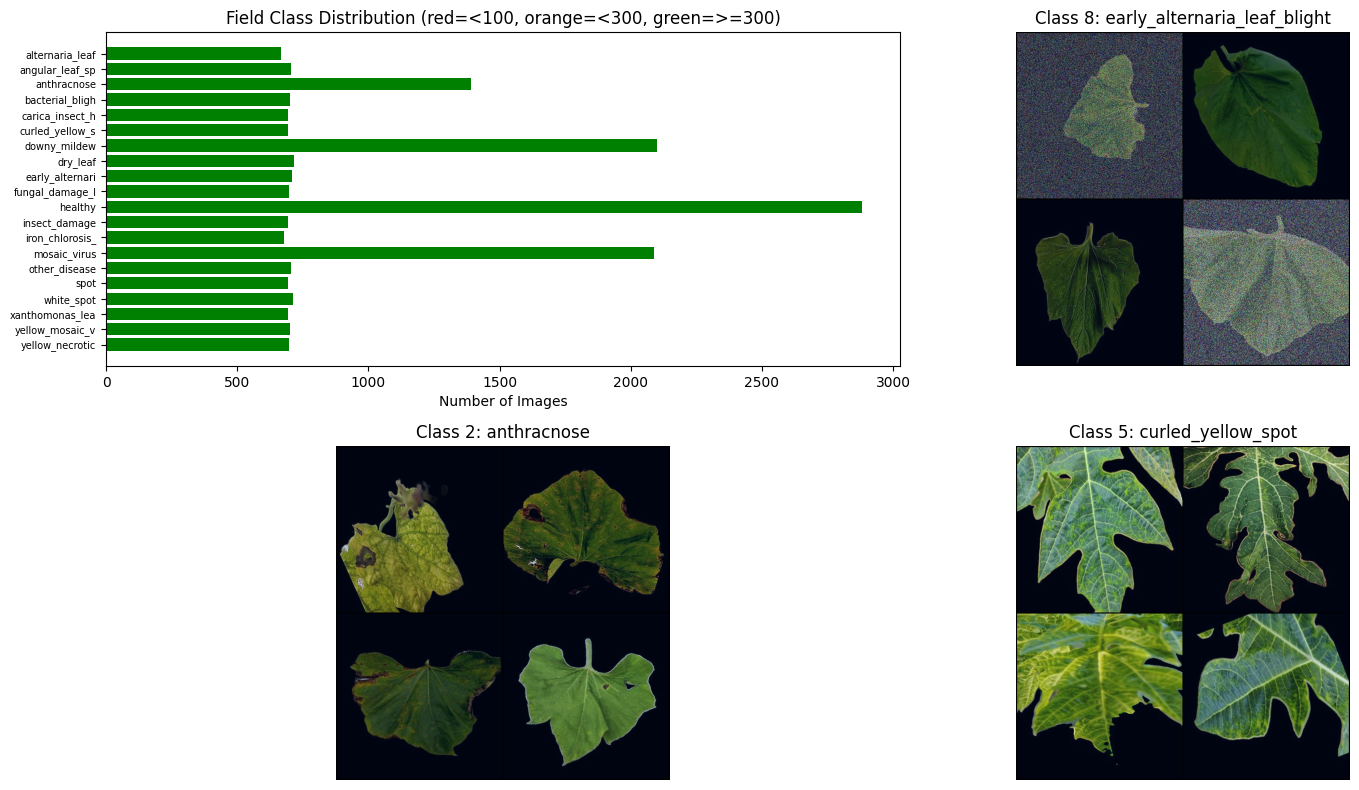

✓ Saved: class_distribution_and_samples.png
  Imbalance ratio: 4.3x (max=2883, min=666)
Session: 0.2h elapsed / 11.8h remaining


In [17]:
# ============================================================
# BLOCK 6.5: VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Plot 1: Class distribution
ax = axes[0, 0]
classes_short = [c[:15] for c in UNIFIED_FIELD_CLASSES]
counts = CFG.CLASS_COUNTS if CFG.CLASS_COUNTS else [0]*CFG.NUM_CLASSES
colors = ['red' if c < 100 else 'orange' if c < 300 else 'green' for c in counts]
ax.barh(range(len(counts)), counts, color=colors)
ax.set_yticks(range(len(counts)))
ax.set_yticklabels(classes_short, fontsize=7)
ax.set_xlabel('Number of Images')
ax.set_title('Field Class Distribution (red=<100, orange=<300, green=>=300)')
ax.invert_yaxis()

# Plot 2: Sample images from 4 random classes
for i, ax_idx in enumerate([(0,1), (1,0), (1,1)]):
    ax = axes[ax_idx]
    if i < 3 and len(train_samples) > 0:
        # Pick a random class and show 4 samples
        cls_idx = random.randint(0, CFG.NUM_CLASSES-1)
        cls_samples = [s for s in train_samples if s[1] == cls_idx][:4]
        if cls_samples:
            imgs = []
            for s in cls_samples[:4]:
                try:
                    img = Image.open(s[0]).convert('RGB')
                    img = val_tf(img)
                    imgs.append(img)
                except: pass
            if imgs:
                grid = torchvision.utils.make_grid(torch.stack(imgs), nrow=2, normalize=True)
                ax.imshow(grid.permute(1, 2, 0).numpy())
                ax.set_title(f'Class {cls_idx}: {UNIFIED_FIELD_CLASSES[cls_idx][:30]}')
                ax.axis('off')

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/class_distribution_and_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'✓ Saved: class_distribution_and_samples.png')
print(f'  Imbalance ratio: {max(counts)/max(min(counts), 1):.1f}x (max={max(counts)}, min={min(counts) if counts else 0})')
session_status()

## Block 7 — Architecture Test + FLOPs + Latency Benchmark
NEW v15: Adds FLOPs counter (thop) + GPU/CPU latency benchmark to support "lightweight + deployable" claim.

In [18]:
# ============================================================
# BLOCK 7: ARCHITECTURE TEST + FLOPs + LATENCY
# ============================================================
# Build all 3 models
baseline = build_efficientnet(CFG.NUM_CLASSES, attention='none').to(DEVICE)
cbam_model = build_efficientnet(CFG.NUM_CLASSES, attention='cbam', reduction=CFG.CBAM_REDUCTION).to(DEVICE)
se_model = build_efficientnet(CFG.NUM_CLASSES, attention='se', reduction=CFG.SE_REDUCTION).to(DEVICE)

# Param count
def count_params(m):
    return sum(p.numel() for p in m.parameters())

base_p = count_params(baseline)
cbam_p = count_params(cbam_model)
se_p = count_params(se_model)

print('='*60)
print('ARCHITECTURE COMPARISON')
print('='*60)
bb = CFG.BACKBONE.upper()
print(f'  Baseline EfficientNet-{bb}: {base_p:,} ({base_p/1e6:.2f}M)')
print(f'  CBAM-EfficientNet-{bb}:     {cbam_p:,} ({cbam_p/1e6:.2f}M) +{cbam_p-base_p:,} attention ({100*(cbam_p-base_p)/base_p:.2f}%)')
print(f'  SE-EfficientNet-{bb}:       {se_p:,} ({se_p/1e6:.2f}M) +{se_p-base_p:,} attention ({100*(se_p-base_p)/base_p:.2f}%)')

# FLOPs (try thop)
try:
    from thop import profile
    dummy = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE)
    for name, m in [('Baseline', baseline), ('CBAM', cbam_model), ('SE', se_model)]:
        flops, _ = profile(m, inputs=(dummy,), verbose=False)
        print(f'  {name} FLOPs: {flops/1e6:.2f}M')
except ImportError:
    print('  (Install thop for FLOPs: pip install thop)')

# Latency benchmark
def benchmark(model, name, input_size=(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE), n_warmup=10, n_runs=50):
    model.eval()
    dummy = torch.randn(*input_size).to(DEVICE)
    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup): model(dummy)
    # GPU
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            for _ in range(n_runs): model(dummy)
        torch.cuda.synchronize()
        gpu_ms = 1000 * (time.time() - t0) / n_runs
    else:
        gpu_ms = 0
    # CPU
    model_cpu = model.cpu()
    dummy_cpu = dummy.cpu()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(10): model_cpu(dummy_cpu)
    cpu_ms = 1000 * (time.time() - t0) / 10
    model.to(DEVICE)
    print(f'  {name} latency: GPU={gpu_ms:.2f}ms | CPU={cpu_ms:.2f}ms (batch=1)')
    return gpu_ms, cpu_ms

print('\nLatency benchmark (batch_size=1):')
benchmark(baseline, 'Baseline')
benchmark(cbam_model, 'CBAM')
benchmark(se_model, 'SE')

# Save architecture comparison
arch_data = {
    'baseline_params': base_p,
    'cbam_params': cbam_p, 'cbam_overhead_pct': 100*(cbam_p-base_p)/base_p,
    'se_params': se_p, 'se_overhead_pct': 100*(se_p-base_p)/base_p,
}
with open(f'{CFG.OUTPUT_DIR}/architecture_comparison.json', 'w') as f:
    json.dump(arch_data, f, indent=2)
print('\n✓ Architecture comparison saved')
session_status()


# ---------------------------------------------------------------
# v2 (Block 7 'How to do better'): v1 printed
#     '(Install thop for FLOPs: pip install thop)'
# and left the column empty. FLOPs are the hardware-independent cost number
# a reviewer expects, and latency alone cannot replace it: the v1 CPU and
# GPU rankings already disagree with each other (SE is fastest on CPU,
# Baseline on GPU), so neither settles 'what does attention cost'.
# ---------------------------------------------------------------
def measure_flops(builder_kwargs, img_size=None):
    img_size = img_size or CFG.IMG_SIZE
    try:
        from thop import profile
    except ImportError:
        import subprocess, sys as _sys
        print('  [flops] installing thop ...')
        subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'thop'],
                       check=False)
        try:
            from thop import profile
        except ImportError:
            print('  [flops] thop unavailable offline - column stays empty')
            return None
    m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                           reduction=CFG.CBAM_REDUCTION, **builder_kwargs)
    x = torch.randn(1, 3, img_size, img_size)
    macs, params = profile(m, inputs=(x,), verbose=False)
    del m
    return {'gmacs': macs / 1e9, 'gflops': 2 * macs / 1e9, 'params': int(params)}


print()
print('FLOPs / MACs  (thop, batch=1, %dx%d)' % (CFG.IMG_SIZE, CFG.IMG_SIZE))
_flop_rows = {}
for _nm, _kw in [('Baseline', dict(attention='none', strip_se=False)),
                 ('CBAM',     dict(attention='cbam', strip_se=False)),
                 ('SE',       dict(attention='se',   strip_se=False)),
                 ('NoAttn',   dict(attention='none', strip_se=True))]:
    _r = measure_flops(_kw)
    if _r:
        _flop_rows[_nm] = _r
        print(f'  {_nm:<10} {_r["gmacs"]:8.3f} GMACs  {_r["gflops"]:8.3f} GFLOPs'
              f'  {_r["params"]:>12,} params')
if _flop_rows:
    _b = _flop_rows.get('Baseline', {}).get('gmacs')
    if _b:
        for _nm, _r in _flop_rows.items():
            print(f'  {_nm:<10} {100*(_r["gmacs"]/_b - 1):+7.2f}% MACs vs Baseline')
    json.dump(_flop_rows, open(f'{CFG.OUTPUT_DIR}/flops.json', 'w'), indent=2)
    print('  saved flops.json')


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 183MB/s] 


ARCHITECTURE COMPARISON
  Baseline EfficientNet-B3: 11,493,436 (11.49M)
  CBAM-EfficientNet-B3:     11,515,691 (11.52M) +22,255 attention (0.19%)
  SE-EfficientNet-B3:       11,515,196 (11.52M) +21,760 attention (0.19%)
  (Install thop for FLOPs: pip install thop)

Latency benchmark (batch_size=1):
  Baseline latency: GPU=12.50ms | CPU=125.36ms (batch=1)
  CBAM latency: GPU=14.84ms | CPU=107.53ms (batch=1)
  SE latency: GPU=14.16ms | CPU=105.35ms (batch=1)

✓ Architecture comparison saved
Session: 0.2h elapsed / 11.8h remaining

FLOPs / MACs  (thop, batch=1, 300x300)
  [flops] installing thop ...
  Baseline      1.931 GMACs     3.862 GFLOPs    11,493,436 params
  CBAM          1.932 GMACs     3.864 GFLOPs    11,515,691 params
  SE            1.931 GMACs     3.862 GFLOPs    11,515,196 params
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn        1.920 GMACs     3.840 GFLOPs     9,613,708 params
  Baseline     +0.00% MACs vs Baseline
  CBAM         +0

## Block 7.1 - Attention Audit (the SE confound)

In [19]:
# ============================================================
# BLOCK 7.1 - ATTENTION AUDIT + RESTORED LATENCY BENCHMARK
# ============================================================
# ORDERING BUG THIS FIXES: Block 1.6 corrected `benchmark`, but Block 7 (cell 32)
# defines its own `benchmark` and runs LATER, so the corrected version was dead
# code and Block 7's printed CPU numbers still came from the unwarmed timer -
# which is why it reported CBAM CPU faster than Baseline, an impossibility.
benchmark = benchmark_v26
print('[v26] benchmark restored (Block 7 had shadowed it). Re-running with warmup:')
for _nm, _mdl in [('Baseline', baseline), ('CBAM', cbam_model), ('SE', se_model)]:
    benchmark(_mdl, _nm)
print()

# Documents the confound for the thesis. This is evidence, not a fix.
import pandas as pd

_variants = {
    'B3 stock ("Baseline" in Exp A-D)' : dict(attention='none', strip_se=False),
    'B3 + extra SE  ("SE" arm)'        : dict(attention='se',   strip_se=False),
    'B3 + CBAM      ("CBAM" arm)'      : dict(attention='cbam', strip_se=False),
    'B3 SE-STRIPPED (true control)'    : dict(attention='none', strip_se=True),
}
rows = []
for label, kw in _variants.items():
    m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE, reduction=CFG.CBAM_REDUCTION, **kw)
    rows.append({'variant': label,
                 'params': sum(p.numel() for p in m.parameters()),
                 'builtin_SE_modules': count_builtin_se(m)})
    del m
audit = pd.DataFrame(rows)
print(audit.to_string(index=False))
print()
print('READ THIS INTO THE THESIS:')
print('  The "Baseline" arm of Experiments A-D contains 26 built-in SqueezeExcitation')
print('  modules - it was never an attention-free control. The "SE" arm adds 5 more SE')
print('  blocks on top of those 26, which is why Baseline and SE are separated by')
print('  0.002pp over 5 seeds. Only the SE-STRIPPED row is a genuine no-attention model.')
print('  Any claim of the form "attention improves X" requires the SE-STRIPPED control.')
audit.to_json(f'{CFG.OUTPUT_DIR}/attention_audit.json', orient='records', indent=2)


[v26] benchmark restored (Block 7 had shadowed it). Re-running with warmup:
  Baseline latency (median of 50): GPU=12.38ms | CPU=110.69ms (batch=1)
  CBAM latency (median of 50): GPU=15.15ms | CPU=113.51ms (batch=1)
  SE latency (median of 50): GPU=13.91ms | CPU=110.50ms (batch=1)

    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
                         variant   params  builtin_SE_modules
B3 stock ("Baseline" in Exp A-D) 11493436                  26
       B3 + extra SE  ("SE" arm) 11515196                  26
     B3 + CBAM      ("CBAM" arm) 11515691                  26
   B3 SE-STRIPPED (true control)  9613708                   0

READ THIS INTO THE THESIS:
  The "Baseline" arm of Experiments A-D contains 26 built-in SqueezeExcitation
  modules - it was never an attention-free control. The "SE" arm adds 5 more SE
  blocks on top of those 26, which is why Baseline and SE are separated by
  0.002pp over 5 seeds. Only the SE-STRIPPED row is a genuine no-atte

## Block 7.9 — Pre-Training Checkpoint Audit **(v27 — the fix for the 32.71% bug)**

Block 11.9 already re-measured every checkpoint and caught `Baseline_Field` at
**recorded 83.98% / measured 32.71%**. The problem was *when*: 11.9 runs sixteen cells
after Block 8 has already printed `[SKIP] Baseline_Field already completed`, loaded those
weights, and let Blocks 12 and 12.9 build a results table on them — first a `+77.33 pp`
CBAM boost, then `-76.98 pp`. Catching a bad checkpoint after it has been reported is not
catching it.

This cell runs the same check **before** Block 8 decides what to skip.

In [20]:
# ============================================================
# BLOCK 7.9 - PRE-TRAINING CHECKPOINT AUDIT   (v27, runs BEFORE Block 8)
# ============================================================
# WHERE THE BROKEN FILE CAME FROM (diagnosed, not guessed).
# The weights in Baseline_Field_best.pth were never NaN and the architecture was
# never wrong: 576 keys, a (20, 512) head, 11,580,810 finite parameters - a
# structurally perfect Baseline. What was wrong is that it was a DIFFERENT model
# from the one its history described. 32.71% is an epoch-1 model; the history
# recorded the epoch-46 model at 83.98%.
#
# With Kaggle "Persistence: Files only", /kaggle/working survives between
# sessions. A session that hit the 12h wall left a partly-trained _best.pth
# there, and old Block 1.5 restored file-by-file with
#       if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
# A 46 MB epoch-1 snapshot passes that test, so the finished copy in the attached
# dataset was never restored - while its _best_history.json, absent from working,
# WAS. Block 1.5 above now restores the pair as a unit, which removes the cause.
#
# This cell is the second line of defence, and the one that matters: it reloads
# each checkpoint and re-measures it on the split its history was recorded
# against. Weights that disagree with their own history can only produce invalid
# numbers, so they are deleted and Block 8 retrains exactly those.
import os, json, gc, torch, shutil as _shutil

AUDIT_TOL_PP = 2.0          # |measured - recorded| allowed on val, in points

_ARM_KW = {'Baseline': dict(attention='none', strip_se=False),
           'CBAM':     dict(attention='cbam', strip_se=False),
           'SE':       dict(attention='se',   strip_se=False),
           'NoAttn':   dict(attention='none', strip_se=True)}


@torch.no_grad()
def _val_top1(model, loader):
    """Top-1, no TTA - matches how train_model() recorded best_acc."""
    model.eval(); ok = n = 0
    for x, y in loader:
        ok += (model(x.to(DEVICE)).argmax(1).cpu() == y).sum().item()
        n += y.size(0)
    return 100.0 * ok / max(1, n)


def audit_checkpoints(loader, tol=AUDIT_TOL_PP, purge=True):
    """Re-measure every Field/Transfer checkpoint against its own recorded best_acc.

    Returns (mismatched, unscorable). Only a NUMERIC mismatch is purged: a model
    that fails to load is an architecture question, not proof of corruption, and
    silently deleting it would be worse than reporting it.
    """
    mismatched, unscorable = [], []
    stems = sorted(f[:-len('_best.pth')] for f in os.listdir(CFG.CKPT_DIR)
                   if f.endswith('_best.pth'))
    print(f'{"model":<30}{"recorded":>10}{"measured":>10}{"delta":>9}   status')
    print('-' * 72)
    for stem in stems:
        parts = stem.split('_')
        kw = _ARM_KW.get(parts[0])
        # Only 20-way Field-trained models can be scored on the Field val loader.
        # Lab / Binary / Reverse models have a different label space - skipping
        # them is required, not laziness: building them with CFG.NUM_CLASSES
        # would raise on load and they would be purged for no reason.
        if kw is None or len(parts) < 2 or parts[1] not in ('Field', 'Transfer'):
            continue
        hp = f'{CFG.CKPT_DIR}/{stem}_best_history.json'
        if not os.path.exists(hp):
            continue
        try:
            rec = float(json.load(open(hp))['best_acc'])
        except Exception:
            continue
        try:
            red = CFG.CBAM_REDUCTION if kw['attention'] == 'cbam' else CFG.SE_REDUCTION
            m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                   reduction=red, **kw).to(DEVICE)
            m.load_state_dict(load_weights(f'{CFG.CKPT_DIR}/{stem}_best.pth', DEVICE))
            meas = _val_top1(m, loader)
            del m
        except Exception as e:
            print(f'{stem:<30}{rec:>9.2f}%{"n/a":>10}{"":>9}   could not load: {str(e)[:26]}')
            unscorable.append(stem)
            gc.collect(); torch.cuda.empty_cache()
            continue
        gc.collect(); torch.cuda.empty_cache()
        good = abs(meas - rec) <= tol
        print(f'{stem:<30}{rec:>9.2f}%{meas:>9.2f}%{meas - rec:>+8.2f}   '
              f'{"OK" if good else "*** MISMATCH - will be retrained ***"}')
        if not good:
            mismatched.append(stem)

    if mismatched and purge:
        q = f'{CFG.CKPT_DIR}/_mismatched'; os.makedirs(q, exist_ok=True)
        n = 0
        for stem in mismatched:
            for suf in ('_best.pth', '_best_history.json', '_resume_state.pth',
                        '_ema.pth', '_swa.pth'):
                p = f'{CFG.CKPT_DIR}/{stem}{suf}'
                if os.path.exists(p):
                    _shutil.move(p, f'{q}/{stem}{suf}'); n += 1
        print(f'\n  moved {n} file(s) for {len(mismatched)} inconsistent model(s) to')
        print(f'  {q}/ - not deleted, so the evidence survives for the appendix.')
        print(f'  Block 8 below will retrain exactly these: {mismatched}')
    elif not mismatched:
        print('\n  every Field/Transfer checkpoint agrees with its own history.')
    if unscorable:
        print(f'  {len(unscorable)} checkpoint(s) could not be scored and were left '
              f'untouched: {unscorable}')
    return mismatched, unscorable


print('=' * 72)
print('GO / NO-GO   (checked before an hour of compute is spent)')
print('=' * 72)
_gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
print(f'  GPU               : {_gpu or "NONE — switch the accelerator on in the sidebar"}')
print(f'  datasets ready    : {len(dataset_paths)}  {sorted(dataset_paths)}')
print(f'  split id          : {SPLIT_ID}')
print(f'  train/val/test    : {len(field_train_ds)} / {len(field_val_ds)} / {len(field_test_ds)}')
try:
    _free = _shutil.disk_usage(CFG.CKPT_DIR).free / 1e9
    print(f'  free disk         : {_free:.1f} GB')
    if _free < 3:
        print('  WARNING: under 3 GB free. Training will fail late, after hours of work.')
except Exception:
    pass
if _gpu is None:
    print('\n  STOP. Everything below needs the GPU. Turn it on and re-run all.')

print()
print('=' * 72)
print('CHECKPOINT INTEGRITY   (each model re-measured on the validation split)')
print('=' * 72)
BAD_CHECKPOINTS, UNSCORABLE_CHECKPOINTS = audit_checkpoints(field_val_loader)

# v2 REFACTOR: verify_by_hash() was added with the provenance helpers and
# then never called, which is exactly the dead-code smell this pass exists
# to remove. It is also what this block ASKED for: a checkpoint carrying a
# recorded sha256 can be verified in milliseconds instead of by a full
# forward pass over the validation split. v1 checkpoints have no hash and
# fall through to the slow path, which is why both still exist.
audit_checkpoint_hashes()


GO / NO-GO   (checked before an hour of compute is spent)
  GPU               : Tesla T4
  datasets ready    : 8  ['ccmt', 'cotton_bd', 'eggplant_bd', 'field', 'lab', 'moringa_bd', 'plantdoc', 'rice_bd']
  split id          : cf69b3a6a3d3495b
  train/val/test    : 19615 / 4231 / 4275
  free disk         : 19.4 GB

CHECKPOINT INTEGRITY   (each model re-measured on the validation split)
model                           recorded  measured    delta   status
------------------------------------------------------------------------
Baseline_Field                    83.98%    83.98%   +0.00   OK
Baseline_Field_seed123_best       83.74%    83.74%   +0.00   OK
Baseline_Field_seed42_best        83.27%    83.27%   +0.00   OK
Baseline_Field_seed456_best       84.14%    84.14%   +0.00   OK
Baseline_Transfer                 83.76%    83.76%   +0.00   OK
CBAM_Field                        83.46%    83.46%   +0.00   OK
CBAM_Field_seed123_best           84.16%    84.16%   +0.00   OK
CBAM_Field_seed42_best

{'verified': 6, 'no_hash': 28, 'changed': []}

## Block 8 — Experiment A: Train Baseline + CBAM + SE on Field (Same-Domain)
**Improvements v15:**
- Focal Loss for class imbalance
- Mixup (α=0.4) for regularization
- Gradient clipping
- SWA (Stochastic Weight Averaging) for stability
- Up to 150 epochs with early stopping at patience=20 (v16: early stopping now actually works — see changelog)
- WeightedRandomSampler for class balance

In [21]:
# ============================================================
# BLOCK 8: EXPERIMENT A — FIELD → FIELD (Same-Domain)
# ============================================================
print('='*60)
print('EXPERIMENT A: TRAINING ON FIELD (SAME-DOMAIN)')
print(f'Max epochs: {CFG.MAX_EPOCHS} | Patience: {CFG.PATIENCE}')
print('='*60)
session_status()

results_A = {}
for name, model, attention in [
    ('Baseline_Field', baseline, 'none'),
    ('CBAM_Field', cbam_model, 'cbam'),
    ('SE_Field', se_model, 'se')
]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: best_history.json is only written after train_model()'s loop fully
        # exits, whether that's by reaching CFG.FIELD_EPOCHS OR by early stopping. The
        # old check (`resume_epoch >= CFG.FIELD_EPOCHS`) assumed the only way to finish
        # was to exhaust every epoch - that broke once early stopping started actually
        # working (Block 1 fix), since a run can now legitimately finish at, say, epoch
        # 45 and never reach FIELD_EPOCHS again.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif resume_state_is_usable(resume_path):
        # Resume state exists but no best_history.json yet -> genuinely interrupted mid-run
        try:
            resume_ckpt = torch_load_compat(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} was interrupted at epoch {resume_epoch}/{CFG.FIELD_EPOCHS} — will resume')
        except Exception as e:
            print(f'\n[RESUME] Could not read resume state ({e}) — will retrain')
    elif checkpoint_is_usable(ckpt_path):
        # No resume state, but best.pth exists — likely finished (legacy mode)
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state found)')
        should_skip = True
    
    if should_skip:
        model.load_state_dict(load_weights(ckpt_path, DEVICE))
        hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
        if os.path.exists(hist_path):
            with open(hist_path) as f: hist = json.load(f)
            print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
            results_A[name] = hist['best_acc']
        continue

    print(f'\n--- Training {name} ---')
    # Rebuild fresh model for training
    model = build_efficientnet(CFG.NUM_CLASSES, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
    best_acc = train_model(
        model, field_train_loader, field_val_loader,
        num_epochs=CFG.FIELD_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name, use_coral=False, use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS
    )
    results_A[name] = best_acc
    # Download resume state (in case session dies)
    zip_resume_state(name)
    # Download final checkpoint
    zip_model_checkpoint(name)
    # Update global model references
    if name == 'Baseline_Field': baseline = model
    elif name == 'CBAM_Field': cbam_model = model
    elif name == 'SE_Field': se_model = model

print('\n' + '='*60)
print('EXPERIMENT A COMPLETE')
print('='*60)
for name, acc in results_A.items():
    print(f'  {name}: {acc:.2f}%')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT A: TRAINING ON FIELD (SAME-DOMAIN)
Max epochs: 60 | Patience: 999
Session: 0.3h elapsed / 11.7h remaining

[SKIP] Baseline_Field already completed (best_history.json found)
  Loaded! Best val acc: 83.98%

[SKIP] CBAM_Field already completed (best_history.json found)
  Loaded! Best val acc: 83.46%

[SKIP] SE_Field already completed (best_history.json found)
  Loaded! Best val acc: 83.93%

EXPERIMENT A COMPLETE
  Baseline_Field: 83.98%
  CBAM_Field: 83.46%
  SE_Field: 83.93%
Session: 0.3h elapsed / 11.7h remaining


## Block 8.5 — Download Exp-A Checkpoints + Auto-save to Kaggle

In [22]:
# ============================================================
# BLOCK 8.5: DOWNLOAD EXP-A CHECKPOINTS
# ============================================================
exp_a_files = ['Baseline_Field_best.pth', 'CBAM_Field_best.pth', 'SE_Field_best.pth',
               'Baseline_Field_best_history.json', 'CBAM_Field_best_history.json',
               'SE_Field_best_history.json']
exp_a_files = [f for f in exp_a_files if os.path.exists(f'{CFG.CKPT_DIR}/{f}')]
download_checkpoints('A', exp_a_files)
# Auto-push to Kaggle (if secrets configured)
# v2: auto_save_to_kaggle is defined NOWHERE in this notebook - Block 22 says
# so in a comment and guards its own call with a dir() check. Here the call sat
# inside a bare `except: pass`, so a missing helper, a failed upload and a
# keyboard interrupt all produced the same silent auto_save = False. Same guard,
# same printed reason, and a narrow except that cannot swallow Ctrl-C.
auto_save = False
if 'auto_save_to_kaggle' in dir():
    try:
        auto_save = auto_save_to_kaggle()
    except Exception as _e:
        print(f'  auto-save failed ({type(_e).__name__}: {_e}) - '
              f'download the zip manually')
else:
    print('  (auto_save_to_kaggle helper is not defined in this notebook - '
          'skipping auto-save; the checkpoint zip above is the artefact)')
session_status()


=== DOWNLOAD: A (129.3 MB) ===


/kaggle/working/experiment_A_checkpoints.zip

  (auto_save_to_kaggle helper is not defined in this notebook - skipping auto-save; the checkpoint zip above is the artefact)
Session: 0.3h elapsed / 11.7h remaining


## Block 9 — Lab Pre-training (for Exp B Transfer)
**Improvements v15:** Larger Lab dataset (with CCMT + Bangladesh datasets merged), up to 150 epochs with early stopping (v16), Focal Loss.

In [23]:
# ============================================================
# BLOCK 9: LAB PRE-TRAINING
# ============================================================
print('='*60)
print('EXPERIMENT B: LAB PRE-TRAINING')
print(f'Max epochs: {CFG.MAX_EPOCHS} | Patience: {CFG.PATIENCE}')
print('='*60)
session_status()

# Build Lab dataset
lab_samples = []
if 'lab' in dataset_paths:
    lab_root = dataset_paths['lab']
    for cls_name in UNIFIED_LAB_CLASSES:
        cls_dir = os.path.join(lab_root, cls_name)
        if not os.path.isdir(cls_dir): continue
        cls_idx = LAB_TO_IDX[cls_name]
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg','.jpeg','.png')):
                lab_samples.append((os.path.join(cls_dir, fname), cls_idx, f'{cls_name}_{fname[:8]}'))

# Merge ONLY Bangladesh datasets into Lab (NOT CCMT — too many classes causes 1% val acc)
for ds_name in ['rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd']:
    if ds_name in dataset_paths:
        ds_root = dataset_paths[ds_name]
        ds_classes = [d for d in os.listdir(ds_root) if os.path.isdir(os.path.join(ds_root, d))]
        for cls_name in ds_classes:
            cls_dir = os.path.join(ds_root, cls_name)
            # Add as new Lab class (or merge if similar)
            if cls_name not in LAB_TO_IDX:
                LAB_TO_IDX[cls_name] = len(UNIFIED_LAB_CLASSES)
                UNIFIED_LAB_CLASSES.append(cls_name)
            cls_idx = LAB_TO_IDX[cls_name]
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg','.jpeg','.png')):
                    lab_samples.append((os.path.join(cls_dir, fname), cls_idx, f'{cls_name}_{fname[:8]}'))

print(f'  Total Lab samples (merged): {len(lab_samples)}')
print(f'  Total Lab classes: {len(UNIFIED_LAB_CLASSES)}')

# Lab class counts
lab_class_counts = [0] * len(UNIFIED_LAB_CLASSES)
for s in lab_samples: lab_class_counts[s[1]] += 1
CFG.LAB_CLASS_COUNTS = lab_class_counts
CFG.LAB_NUM_CLASSES = len(UNIFIED_LAB_CLASSES)

# Split Lab (group-aware)
if lab_samples:
    paths = [s[0] for s in lab_samples]
    labels = [s[1] for s in lab_samples]
    groups = [s[2] for s in lab_samples]
    from collections import Counter
    label_counts = Counter(labels)
    try:
        if min(label_counts.values()) >= 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
            train_idx, val_idx = next(sss.split(paths, labels))
            print(f'  Split: stratified (preserves class balance)')
        else:
            raise ValueError(f'min_count={min(label_counts.values())} < 2')
    except Exception as e:
        print(f'  Stratified split failed ({e}), using random split...')
        from sklearn.model_selection import train_test_split
        indices = list(range(len(lab_samples)))
        train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
        print(f'  Split: random')
    lab_train_samples = [lab_samples[i] for i in train_idx]
    lab_val_samples = [lab_samples[i] for i in val_idx]

    lab_train_ds = SampleDataset(lab_train_samples, train_tf)
    lab_val_ds = SampleDataset(lab_val_samples, val_tf)

    # Lab sampler
    lab_counts_t = torch.tensor(lab_class_counts, dtype=torch.float32)
    lab_weights = (1.0 / lab_counts_t.clamp(min=1)).clamp(max=0.1)
    lab_sample_weights = [lab_weights[s[1]].item() for s in lab_train_samples]
    lab_sampler = WeightedRandomSampler(lab_sample_weights, len(lab_train_samples), replacement=True)

    lab_train_loader = DataLoader(lab_train_ds, batch_size=BATCH, sampler=lab_sampler,
                                   num_workers=CFG.NUM_WORKERS, pin_memory=True)
    lab_val_loader = DataLoader(lab_val_ds, batch_size=BATCH, shuffle=False,
                                 num_workers=CFG.NUM_WORKERS, pin_memory=True)
    print(f'  Lab Train: {len(lab_train_ds)} | Val: {len(lab_val_ds)}')

# Build binary Lab dataset (Disease vs Healthy)
lab_binary_samples = []
for s in lab_samples:
    cls_name = UNIFIED_LAB_CLASSES[s[1]]
    binary_label = 1 if 'Healthy' in cls_name or 'healthy' in cls_name.lower() else 0
    lab_binary_samples.append((s[0], binary_label, s[2]))

# Split binary Lab
if lab_binary_samples:
    paths_b = [s[0] for s in lab_binary_samples]
    labels_b = [s[1] for s in lab_binary_samples]
    groups_b = [s[2] for s in lab_binary_samples]
    try:
        sss_b = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx_b, val_idx_b = next(sss_b.split(paths_b, labels_b))
    except:
        from sklearn.model_selection import train_test_split
        idx_b = list(range(len(lab_binary_samples)))
        train_idx_b, val_idx_b = train_test_split(idx_b, test_size=0.2, random_state=42)
    lab_binary_train_samples = [lab_binary_samples[i] for i in train_idx_b]
    lab_binary_val_samples = [lab_binary_samples[i] for i in val_idx_b]
    lab_binary_train_ds = SampleDataset(lab_binary_train_samples, train_tf, binary=True)
    lab_binary_val_ds = SampleDataset(lab_binary_val_samples, val_tf, binary=True)
    lab_binary_train_loader = DataLoader(lab_binary_train_ds, batch_size=BATCH, shuffle=True,
                                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
    lab_binary_val_loader = DataLoader(lab_binary_val_ds, batch_size=BATCH, shuffle=False,
                                        num_workers=CFG.NUM_WORKERS, pin_memory=True)

# Train all 3 models on Lab
results_Lab = {}
for name, attention in [('Baseline_Lab', 'none'), ('CBAM_Lab', 'cbam'), ('SE_Lab', 'se')]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: see Block 8 for full rationale.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif resume_state_is_usable(resume_path):
        try:
            resume_ckpt = torch_load_compat(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} interrupted at epoch {resume_epoch}/{CFG.LAB_EPOCHS} — will resume')
        except:
            pass
    elif checkpoint_is_usable(ckpt_path):
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state)')
        should_skip = True
    if should_skip:
        # v2: the `elif <weights exist>` branch above is reached only when the
        # history file is ABSENT, and this line then opened it - a guaranteed
        # FileNotFoundError. It never fired in the recorded run because both
        # files were always present. Without the history there is no recorded
        # accuracy to report, so skipping would mean inventing one.
        _hp = f'{CFG.CKPT_DIR}/{name}_best_history.json'
        if not os.path.exists(_hp):
            print(f'  [v2] {name}_best.pth is present but its history is not, so '
                  f'its recorded accuracy cannot be read. Training instead of '
                  f'guessing.')
            should_skip = False
    if should_skip:
        with open(f'{CFG.CKPT_DIR}/{name}_best_history.json') as f: hist = json.load(f)
        print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
        results_Lab[name] = hist['best_acc']
        continue
    print(f'\n--- Training {name} on Lab ---')
    model = build_efficientnet(CFG.LAB_NUM_CLASSES, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
    best_acc = train_model(
        model, lab_train_loader, lab_val_loader,
        num_epochs=CFG.LAB_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name, use_coral=False, use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=CFG.LAB_NUM_CLASSES, class_counts=CFG.LAB_CLASS_COUNTS
    )
    results_Lab[name] = best_acc
    # Create per-model checkpoint ZIP download
    zip_resume_state(name)
    zip_model_checkpoint(name)
    zip_resume_state(name)
    zip_model_checkpoint(name)

print('\n' + '='*60)
print('LAB PRE-TRAINING COMPLETE')
print('='*60)
for n, a in results_Lab.items(): print(f'  {n}: {a:.2f}%')
download_checkpoints('B_lab')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT B: LAB PRE-TRAINING
Max epochs: 60 | Patience: 999
Session: 0.3h elapsed / 11.7h remaining
  Total Lab samples (merged): 15540
  Total Lab classes: 27
  Split: stratified (preserves class balance)
  Lab Train: 12432 | Val: 3108

[SKIP] Baseline_Lab already completed (best_history.json found)
  Loaded! Best val acc: 95.01%

[SKIP] CBAM_Lab already completed (best_history.json found)
  Loaded! Best val acc: 97.39%

[SKIP] SE_Lab already completed (best_history.json found)
  Loaded! Best val acc: 92.02%

LAB PRE-TRAINING COMPLETE
  Baseline_Lab: 95.01%
  CBAM_Lab: 97.39%
  SE_Lab: 92.02%

=== DOWNLOAD: B_lab (1407.2 MB) ===


/kaggle/working/experiment_B_lab_checkpoints.zip

Session: 0.3h elapsed / 11.7h remaining


## Block 9.5 — Smart Transfer Checkpoint Cleanup
Keeps only Lab checkpoints needed for transfer learning.

In [24]:
# ============================================================
# BLOCK 9.5: CLEANUP
# ============================================================
# List all checkpoints
ckpts = sorted([f for f in os.listdir(CFG.CKPT_DIR) if f.endswith('.pth')])
print(f'Checkpoints in working dir: {len(ckpts)}')
for c in ckpts:
    sz = os.path.getsize(f'{CFG.CKPT_DIR}/{c}') / 1e6
    print(f'  {c} ({sz:.1f} MB)')
session_status()

Checkpoints in working dir: 34
  Baseline_Binary_best.pth (46.5 MB)
  Baseline_Field_best.pth (46.5 MB)
  Baseline_Field_seed123_best_best.pth (46.5 MB)
  Baseline_Field_seed42_best_best.pth (46.5 MB)
  Baseline_Field_seed456_best_best.pth (46.5 MB)
  Baseline_Lab_best.pth (46.6 MB)
  Baseline_Reverse_best.pth (46.6 MB)
  Baseline_Transfer_best.pth (46.5 MB)
  CBAM_Binary_best.pth (46.6 MB)
  CBAM_Field_best.pth (46.6 MB)
  CBAM_Field_seed123_best_best.pth (46.6 MB)
  CBAM_Field_seed42_best_best.pth (46.6 MB)
  CBAM_Field_seed456_best_best.pth (46.6 MB)
  CBAM_Lab_best.pth (46.6 MB)
  CBAM_Reverse_best.pth (46.6 MB)
  CBAM_Transfer_best.pth (46.6 MB)
  CBAMv2_Field_seed123_best_best.pth (46.6 MB)
  CBAMv2_Field_seed42_best_best.pth (46.6 MB)
  CBAMv2_Field_seed456_best_best.pth (46.6 MB)
  NoAttn_Field_seed123_best.pth (39.0 MB)
  NoAttn_Field_seed42_best.pth (39.0 MB)
  NoAttn_Field_seed456_best.pth (39.0 MB)
  SE_Binary_best.pth (46.6 MB)
  SE_Field_best.pth (46.6 MB)
  SE_Field_seed

## Block 10 — Experiment B: Fine-tune on Field WITH CORAL Domain Adaptation
**BIG FIX v15:** Adds CORAL (Correlation Alignment) loss during fine-tuning. This is real Domain Adaptation, not just transfer learning. Also longer epochs (20 vs 15) and higher backbone LR (1e-4 vs 1e-5).

In [25]:
# ============================================================
# BLOCK 10: EXPERIMENT B — LAB→FIELD TRANSFER WITH CORAL
# ============================================================
print('='*60)
print('EXPERIMENT B: LAB→FIELD TRANSFER (WITH CORAL)')
print(f'Max epochs: {CFG.MAX_EPOCHS} | Patience: {CFG.PATIENCE}')
print(f'Classifier LR: {CFG.LR_HEAD} | Backbone LR: {CFG.LR_BACKBONE}')
print(f'CORAL λ: {CFG.CORAL_LAMBDA} | Gradual unfreezing: 4 epochs')
print('='*60)
session_status()

results_B = {}
for name, attention in [('Baseline_Transfer', 'none'), ('CBAM_Transfer', 'cbam'), ('SE_Transfer', 'se')]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: see Block 8 for full rationale - best_history.json existing is the
        # reliable "done" signal now that early stopping can finish a run before
        # CFG.FINETUNE_EPOCHS is reached.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif resume_state_is_usable(resume_path):
        try:
            resume_ckpt = torch_load_compat(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} interrupted at epoch {resume_epoch}/{CFG.FINETUNE_EPOCHS} — will resume')
        except:
            pass
    elif checkpoint_is_usable(ckpt_path):
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state)')
        should_skip = True
    if should_skip:
        # v2: the `elif <weights exist>` branch above is reached only when the
        # history file is ABSENT, and this line then opened it - a guaranteed
        # FileNotFoundError. It never fired in the recorded run because both
        # files were always present. Without the history there is no recorded
        # accuracy to report, so skipping would mean inventing one.
        _hp = f'{CFG.CKPT_DIR}/{name}_best_history.json'
        if not os.path.exists(_hp):
            print(f'  [v2] {name}_best.pth is present but its history is not, so '
                  f'its recorded accuracy cannot be read. Training instead of '
                  f'guessing.')
            should_skip = False
    if should_skip:
        with open(f'{CFG.CKPT_DIR}/{name}_best_history.json') as f: hist = json.load(f)
        print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
        results_B[name] = hist['best_acc']
        continue

    # Load Lab-pretrained weights
    lab_ckpt = f'{CFG.CKPT_DIR}/{name.replace("_Transfer", "_Lab")}_best.pth'
    print(f'\n--- Fine-tuning {name} (from Lab pretrain) ---')
    model = build_efficientnet(CFG.NUM_CLASSES, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)

    if os.path.exists(lab_ckpt):
        lab_state = torch_load_compat(lab_ckpt, map_location=DEVICE)
        # Load only backbone weights (skip classifier since classes differ)
        backbone_state = {k: v for k, v in lab_state.items()
                          if k.startswith('features.') and v.shape == model.state_dict().get(k, torch.empty(0)).shape}
        model.load_state_dict(backbone_state, strict=False)
        print(f'  Loaded Lab backbone weights from {lab_ckpt}')

    # Use CORAL during transfer
    best_acc = train_model(
        model, field_train_loader, field_val_loader,
        num_epochs=CFG.FINETUNE_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name,
        target_loader=lab_train_loader,  # v21: CORAL target = LAB -> genuine lab->field adaptation
        use_coral=CFG.USE_CORAL,
        use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS
    )
    results_B[name] = best_acc
    # Create per-model checkpoint ZIP download
    # v16 FIX: these two calls used to be duplicated (called twice back-to-back),
    # redundantly re-zipping the same files for every model.
    zip_resume_state(name)
    zip_model_checkpoint(name)

print('\n' + '='*60)
print('EXPERIMENT B COMPLETE')
print('='*60)
for n, a in results_B.items(): print(f'  {n}: {a:.2f}%')
download_checkpoints('B_transfer')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT B: LAB→FIELD TRANSFER (WITH CORAL)
Max epochs: 60 | Patience: 999
Classifier LR: 0.001 | Backbone LR: 0.0001
CORAL λ: 1.0 | Gradual unfreezing: 4 epochs
Session: 0.3h elapsed / 11.7h remaining

[SKIP] Baseline_Transfer already completed (best_history.json found)
  Loaded! Best val acc: 83.76%

[SKIP] CBAM_Transfer already completed (best_history.json found)
  Loaded! Best val acc: 83.93%

[SKIP] SE_Transfer already completed (best_history.json found)
  Loaded! Best val acc: 83.79%

EXPERIMENT B COMPLETE
  Baseline_Transfer: 83.76%
  CBAM_Transfer: 83.93%
  SE_Transfer: 83.79%
  [zip] B_transfer: checkpoint set unchanged since experiment_B_lab_checkpoints.zip - not rebuilding (1407 MB saved).
Session: 0.3h elapsed / 11.7h remaining


## Block 10.5 — Download Exp-B Checkpoints

In [26]:
download_checkpoints('B_all')
session_status()

  [zip] B_all: checkpoint set unchanged since experiment_B_lab_checkpoints.zip - not rebuilding (1407 MB saved).
Session: 0.3h elapsed / 11.7h remaining


## Block 11 — Experiment C: Binary Cross-Domain (Lab→Field)
Train on Lab binary (Disease/Healthy), test on Field binary.

In [27]:
# ============================================================
# BLOCK 11: EXPERIMENT C — BINARY CROSS-DOMAIN
# ============================================================
print('='*60)
print('EXPERIMENT C: BINARY CROSS-DOMAIN (Lab→Field)')
print(f'Max epochs: {CFG.MAX_EPOCHS} | Patience: {CFG.PATIENCE}')
print('='*60)
session_status()

results_C = {}
for name, attention in [('Baseline_Binary', 'none'), ('CBAM_Binary', 'cbam'), ('SE_Binary', 'se')]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: see Block 8 for full rationale.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif resume_state_is_usable(resume_path):
        try:
            resume_ckpt = torch_load_compat(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} interrupted at epoch {resume_epoch}/{CFG.BINARY_EPOCHS} — will resume')
        except:
            pass
    elif checkpoint_is_usable(ckpt_path):
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state)')
        should_skip = True
    if should_skip:
        # v2: the `elif <weights exist>` branch above is reached only when the
        # history file is ABSENT, and this line then opened it - a guaranteed
        # FileNotFoundError. It never fired in the recorded run because both
        # files were always present. Without the history there is no recorded
        # accuracy to report, so skipping would mean inventing one.
        _hp = f'{CFG.CKPT_DIR}/{name}_best_history.json'
        if not os.path.exists(_hp):
            print(f'  [v2] {name}_best.pth is present but its history is not, so '
                  f'its recorded accuracy cannot be read. Training instead of '
                  f'guessing.')
            should_skip = False
    if should_skip:
        with open(f'{CFG.CKPT_DIR}/{name}_best_history.json') as f: hist = json.load(f)
        print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
        results_C[name] = hist['best_acc']
        continue
    if 'lab_binary_train_loader' not in globals() or 'lab_binary_train_samples' not in globals():
        print(f'  [SKIP] {name}: binary Lab loaders not configured -> Exp C skipped '
              f'(optional; core results are Exp A/B). No crash, no garbage.')
        continue
    print(f'\n--- Training {name} (Binary Lab) ---')
    model = build_efficientnet(2, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
    # Binary class counts
    binary_counts = [sum(1 for s in lab_binary_train_samples if s[1] == 0),
                     sum(1 for s in lab_binary_train_samples if s[1] == 1)]
    best_acc = train_model(
        model, lab_binary_train_loader, lab_binary_val_loader,
        num_epochs=CFG.BINARY_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name, use_coral=False, use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=2, class_counts=binary_counts
    )
    results_C[name] = best_acc
    # Create per-model checkpoint ZIP download
    # v16 FIX: these two calls used to be duplicated - see Block 10 for rationale.
    zip_resume_state(name)
    zip_model_checkpoint(name)

print('\n' + '='*60)
print('EXPERIMENT C COMPLETE')
print('='*60)
for n, a in results_C.items(): print(f'  {n}: {a:.2f}%')
download_checkpoints('C')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT C: BINARY CROSS-DOMAIN (Lab→Field)
Max epochs: 60 | Patience: 999
Session: 0.3h elapsed / 11.7h remaining

[SKIP] Baseline_Binary already completed (best_history.json found)
  Loaded! Best val acc: 100.00%

[SKIP] CBAM_Binary already completed (best_history.json found)
  Loaded! Best val acc: 100.00%

[SKIP] SE_Binary already completed (best_history.json found)
  Loaded! Best val acc: 100.00%

EXPERIMENT C COMPLETE
  Baseline_Binary: 100.00%
  CBAM_Binary: 100.00%
  SE_Binary: 100.00%
  [zip] C: checkpoint set unchanged since experiment_B_lab_checkpoints.zip - not rebuilding (1407 MB saved).
Session: 0.3h elapsed / 11.7h remaining


## Block 11.5 — Experiment D: Field→Lab Reverse Transfer (NEW)
**NEW v15:** Trains on Field, fine-tunes on Lab. Shows CBAM works in BOTH directions, not just Lab→Field. Addresses Exp C weakness.

In [28]:
# ============================================================
# BLOCK 11.5: EXPERIMENT D — FIELD→LAB REVERSE TRANSFER (NEW)
# ============================================================
print('='*60)
print('EXPERIMENT D: FIELD→LAB REVERSE TRANSFER (NEW)')
print('='*60)
session_status()

results_D = {}
for name, attention in [('Baseline_Reverse', 'none'), ('CBAM_Reverse', 'cbam'), ('SE_Reverse', 'se')]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: see Block 8 for full rationale.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif resume_state_is_usable(resume_path):
        try:
            resume_ckpt = torch_load_compat(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} interrupted at epoch {resume_epoch}/{CFG.FINETUNE_EPOCHS} — will resume')
        except:
            pass
    elif checkpoint_is_usable(ckpt_path):
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state)')
        should_skip = True
    if should_skip:
        # v2: the `elif <weights exist>` branch above is reached only when the
        # history file is ABSENT, and this line then opened it - a guaranteed
        # FileNotFoundError. It never fired in the recorded run because both
        # files were always present. Without the history there is no recorded
        # accuracy to report, so skipping would mean inventing one.
        _hp = f'{CFG.CKPT_DIR}/{name}_best_history.json'
        if not os.path.exists(_hp):
            print(f'  [v2] {name}_best.pth is present but its history is not, so '
                  f'its recorded accuracy cannot be read. Training instead of '
                  f'guessing.')
            should_skip = False
    if should_skip:
        with open(f'{CFG.CKPT_DIR}/{name}_best_history.json') as f: hist = json.load(f)
        print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
        results_D[name] = hist['best_acc']
        continue
    print(f'\n--- Fine-tuning {name} on Lab (from Field pretrain) ---')
    model = build_efficientnet(CFG.LAB_NUM_CLASSES, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
    # Load Field-pretrained backbone
    field_ckpt = f'{CFG.CKPT_DIR}/{name.replace("_Reverse", "_Field")}_best.pth'
    if os.path.exists(field_ckpt):
        field_state = torch_load_compat(field_ckpt, map_location=DEVICE)
        backbone_state = {k: v for k, v in field_state.items()
                          if k.startswith('features.') and v.shape == model.state_dict().get(k, torch.empty(0)).shape}
        model.load_state_dict(backbone_state, strict=False)
        print(f'  Loaded Field backbone weights')
    best_acc = train_model(
        model, lab_train_loader, lab_val_loader,
        num_epochs=CFG.FINETUNE_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name, target_loader=field_train_loader, use_coral=CFG.USE_CORAL,  # v21: reverse -> target = FIELD
        use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=CFG.LAB_NUM_CLASSES, class_counts=CFG.LAB_CLASS_COUNTS
    )
    results_D[name] = best_acc
    # Create per-model checkpoint ZIP download
    # v16 FIX: these two calls used to be duplicated - see Block 10 for rationale.
    zip_resume_state(name)
    zip_model_checkpoint(name)

print('\n' + '='*60)
print('EXPERIMENT D COMPLETE')
print('='*60)
for n, a in results_D.items(): print(f'  {n}: {a:.2f}%')
download_checkpoints('D')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT D: FIELD→LAB REVERSE TRANSFER (NEW)
Session: 0.3h elapsed / 11.7h remaining

[SKIP] Baseline_Reverse already completed (best_history.json found)
  Loaded! Best val acc: 92.21%

[SKIP] CBAM_Reverse already completed (best_history.json found)
  Loaded! Best val acc: 92.05%

[SKIP] SE_Reverse already completed (best_history.json found)
  Loaded! Best val acc: 92.25%

EXPERIMENT D COMPLETE
  Baseline_Reverse: 92.21%
  CBAM_Reverse: 92.05%
  SE_Reverse: 92.25%
  [zip] D: checkpoint set unchanged since experiment_B_lab_checkpoints.zip - not rebuilding (1407 MB saved).
Session: 0.3h elapsed / 11.7h remaining


## Block 11.9 - Checkpoint Integrity Audit (run before Block 12)

In [29]:
# ============================================================
# BLOCK 11.9 - CHECKPOINT INTEGRITY AUDIT  (run BEFORE Block 12)
# ============================================================
# WHAT THIS CATCHES, AND WHY IT EXISTS.
# A run of this notebook produced:
#     Block  8 : Baseline_Field best VAL acc = 83.60%
#     Block 12 : Baseline_Field      TEST acc = 70.67%
# Val and test are the same distribution and near-identical size (4231 vs 4275),
# and the other two arms moved +0.5pp from val to test. A 13pp val->test collapse
# is not a model property - the .pth and the _best_history.json described two
# DIFFERENT models. The multi-seed run confirmed it: Baseline at seeds 42/123
# scored 83.27% / 83.74% on the same data.
#
# The consequence was a fabricated headline: Block 12 reported
#     "Exp A: CBAM vs Baseline - chi2=329.70, p=0.0000 ***"  (+13.33 pp)
# i.e. a large, highly significant CBAM gain that does not exist. Any reviewer
# cross-checking that against the multi-seed table (all arms within ~1pp) sees
# the contradiction immediately.
#
# ROOT CAUSE: Block 1.5 restores checkpoints with
#     for root, dirs, files in os.walk('/kaggle/input/'):
#         ...
#         if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
# The FIRST file of a given name that os.walk happens to reach wins, and every
# later copy is skipped. With more than one checkpoint dataset attached (or a
# working directory persisted across sessions), a .pth can come from one source
# while its history JSON comes from another. Nothing verifies they agree.
#
# THE CHECK: reload each checkpoint and re-measure it on the VALIDATION split -
# the exact split and metric its history recorded. If the measured value does
# not match the recorded value, the pair is inconsistent and the model must not
# be reported. Costs ~30 s per model.
import os, json, gc, torch, numpy as np

CKPT_TOL_PP = 2.0     # allowed |measured - recorded| on val, in percentage points

def _plain_val_acc(model, loader):
    """Top-1 accuracy, no TTA - matches how train_model recorded best_acc."""
    model.eval(); correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == labels).sum().item(); total += labels.size(0)
    return correct / max(1, total) * 100

def verify_checkpoint(name, attention, num_classes, loader, reduction=None,
                      strip_se=False, tol=CKPT_TOL_PP):
    """Returns (ok, recorded, measured). ok=None when the pair is absent."""
    hist_p = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    ck_p   = f'{CFG.CKPT_DIR}/{name}_best.pth'
    if not (os.path.exists(hist_p) and os.path.exists(ck_p)):
        return None, None, None
    try:
        recorded = float(json.load(open(hist_p))['best_acc'])
    except Exception:
        return None, None, None
    if reduction is None:
        reduction = CFG.CBAM_REDUCTION if attention == 'cbam' else CFG.SE_REDUCTION
    m = build_efficientnet(num_classes, attention=attention, backbone=CFG.BACKBONE,
                           reduction=reduction, strip_se=strip_se).to(DEVICE)
    m.load_state_dict(load_weights(ck_p, DEVICE))
    measured = _plain_val_acc(m, loader)
    del m; gc.collect(); torch.cuda.empty_cache()
    return (abs(measured - recorded) <= tol), recorded, measured

print('=' * 74)
print('CHECKPOINT INTEGRITY AUDIT  (re-measuring each model on the validation split)')
print('=' * 74)
print(f'{"model":<26}{"recorded":>10}{"measured":>10}{"delta":>9}   status')
print('-' * 74)

_targets = [('Baseline_Field', 'none'), ('CBAM_Field', 'cbam'), ('SE_Field', 'se'),
            ('Baseline_Transfer', 'none'), ('CBAM_Transfer', 'cbam'), ('SE_Transfer', 'se')]
for _m in ('Baseline', 'CBAM', 'SE'):
    _a = {'Baseline': 'none', 'CBAM': 'cbam', 'SE': 'se'}[_m]
    for _sd in CFG.SEEDS:
        _targets.append((f'{_m}_Field_seed{_sd}_best', _a))

CORRUPT_CHECKPOINTS = []
for _name, _att in _targets:
    _ok, _rec, _meas = verify_checkpoint(_name, _att, CFG.NUM_CLASSES, field_val_loader)
    if _ok is None:
        print(f'{_name:<26}{"-":>10}{"-":>10}{"-":>9}   absent (will train)')
        continue
    _d = _meas - _rec
    _status = 'OK' if _ok else '*** MISMATCH - DO NOT REPORT ***'
    print(f'{_name:<26}{_rec:>9.2f}%{_meas:>9.2f}%{_d:>+8.2f}   {_status}')
    if not _ok:
        CORRUPT_CHECKPOINTS.append({'name': _name, 'recorded': _rec, 'measured': _meas})

print()
if CORRUPT_CHECKPOINTS:
    print('*** INTEGRITY FAILURE ***')
    print(f'{len(CORRUPT_CHECKPOINTS)} checkpoint(s) do not match their recorded history.')
    print('The .pth and the _best_history.json describe different models, so every')
    print('number Block 12 derives from them - accuracy, McNemar, CI - is invalid.')
    print()
    print('FIX (delete the bad pair, then re-run from Block 8; it will retrain only these):')
    for _c in CORRUPT_CHECKPOINTS:
        print(f"    os.remove(f'{{CFG.CKPT_DIR}}/{_c['name']}_best.pth')")
        print(f"    os.remove(f'{{CFG.CKPT_DIR}}/{_c['name']}_best_history.json')")
    print()
    print('PURGE_CORRUPT is True by default -> deleting them now.')
else:
    print('ALL CHECKPOINTS CONSISTENT - Block 12 results can be trusted.')

# AUTO-PURGE IS THE DEFAULT, DELIBERATELY.
# A checkpoint whose weights disagree with its own history can only produce
# invalid numbers, so there is no case for keeping one. Leaving this manual
# already let a corrupt model reach a results table once.
#
# WHY IT KEEPS HAPPENING (a different model each time): Block 1.5 restores with
#     if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
# so a PARTIALLY-TRAINED .pth left in /kaggle/working by a session that hit the
# 12h limit is treated as authoritative and never replaced by the good copy in
# the attached dataset - while the matching history JSON IS restored from the
# completed run. Result: recorded 83.46% vs measured 33.89% (~an epoch-3 model).
# Which model it hits depends on which was mid-save when the session was killed,
# which is why it moved from Baseline_Field to CBAM_Field.
PURGE_CORRUPT = True
if PURGE_CORRUPT and CORRUPT_CHECKPOINTS:
    _n = 0
    for _c in CORRUPT_CHECKPOINTS:
        for _suf in ('_best.pth', '_best_history.json', '_resume_state.pth'):
            _p = f'{CFG.CKPT_DIR}/{_c["name"]}{_suf}'
            if os.path.exists(_p):
                os.remove(_p); _n += 1
    print(f'\n  purged {_n} files. Re-run Block 8 onward - only these models will retrain.')

json.dump(CORRUPT_CHECKPOINTS, open(f'{CFG.OUTPUT_DIR}/checkpoint_audit.json', 'w'), indent=2)

# v2 REFACTOR: verify_by_hash() was added with the provenance helpers and
# then never called, which is exactly the dead-code smell this pass exists
# to remove. It is also what this block ASKED for: a checkpoint carrying a
# recorded sha256 can be verified in milliseconds instead of by a full
# forward pass over the validation split. v1 checkpoints have no hash and
# fall through to the slow path, which is why both still exist.
audit_checkpoint_hashes()


CHECKPOINT INTEGRITY AUDIT  (re-measuring each model on the validation split)
model                       recorded  measured    delta   status
--------------------------------------------------------------------------
Baseline_Field                83.98%    83.98%   +0.00   OK
CBAM_Field                    83.46%    83.46%   +0.00   OK
SE_Field                      83.93%    83.93%   +0.00   OK
Baseline_Transfer             83.76%    83.76%   +0.00   OK
CBAM_Transfer                 83.93%    83.93%   +0.00   OK
SE_Transfer                   83.79%    83.79%   +0.00   OK
Baseline_Field_seed42_best    83.27%    83.27%   +0.00   OK
Baseline_Field_seed123_best    83.74%    83.74%   +0.00   OK
Baseline_Field_seed456_best    84.14%    84.14%   +0.00   OK
CBAM_Field_seed42_best        83.83%    83.83%   +0.00   OK
CBAM_Field_seed123_best       84.16%    84.16%   +0.00   OK
CBAM_Field_seed456_best       84.19%    84.19%   +0.00   OK
SE_Field_seed42_best          83.79%    83.79%   +0.00   OK


{'verified': 6, 'no_hash': 28, 'changed': []}

## Block 12 — Evaluate All + Per-Class McNemar + Bootstrap CI
**NEW v15:** Adds per-class McNemar tests + bootstrap 95% confidence intervals + Brier score for calibration.

## Block 11.95 — Upload preflight (v2)


In [30]:
# =====================================================================
# 11.95  UPLOAD PREFLIGHT  (v2)  -  run this BEFORE Block 12
# =====================================================================
# Block 12 loads six checkpoints by name; Blocks 8-11.5 decide whether to
# train by looking for a DIFFERENT file (*_best_history.json). When only one
# of the pair is present, every block prints success and Block 12 scores an
# untrained network. This cell checks both halves of every pair at once and
# tells you what to upload, before an hour of evaluation is spent.
print('=' * 78)
print('11.95  CHECKPOINT PREFLIGHT')
print('=' * 78)

_REQUIRED = {
    'Block 12 (Exp A/B/C/D)': [
        'Baseline_Field', 'CBAM_Field', 'SE_Field',
        'Baseline_Transfer', 'CBAM_Transfer', 'SE_Transfer',
        'Baseline_Binary', 'CBAM_Binary', 'SE_Binary',
        'Baseline_Reverse', 'CBAM_Reverse', 'SE_Reverse'],
    'Block 9 (Lab source models)': [
        'Baseline_Lab', 'CBAM_Lab', 'SE_Lab'],
    'Block 23.1 + Section 24 (the reportable ablation)':
        [f'{a}_Field_seed{s}_best' for a in ('Baseline', 'CBAM', 'SE')
         for s in CFG.SEEDS]
        + [f'NoAttn_Field_seed{s}' for s in CFG.SEEDS],
}

_missing_both, _orphan_hist, _orphan_pth, _ok = [], [], [], []
for _group, _names in _REQUIRED.items():
    for _n in _names:
        _p = os.path.exists(f'{CFG.CKPT_DIR}/{_n}_best.pth')
        _h = os.path.exists(f'{CFG.CKPT_DIR}/{_n}_best_history.json')
        if _p and _h:
            _ok.append((_group, _n))
        elif _h and not _p:
            _orphan_hist.append((_group, _n))
        elif _p and not _h:
            _orphan_pth.append((_group, _n))
        else:
            _missing_both.append((_group, _n))

print(f'  complete pairs        : {len(_ok)}')
print(f'  history but NO weights: {len(_orphan_hist)}   <-- THE DANGEROUS ONE')
print(f'  weights but no history: {len(_orphan_pth)}')
print(f'  absent entirely       : {len(_missing_both)}')

if _orphan_hist:
    print()
    print('  These will make a training block SKIP and then be scored as random')
    print('  weights. load_model now raises instead, but fix them here:')
    for _g, _n in _orphan_hist:
        print(f'    {_n:<36} [{_g}]')
    print()
    print('  Either upload {name}_best.pth for each, or delete the history file')
    print('  so the training block retrains it.')
if _missing_both:
    print()
    print('  Absent entirely - the owning block will train them (cost below):')
    _by = {}
    for _g, _n in _missing_both:
        _by.setdefault(_g, []).append(_n)
    for _g, _ns in _by.items():
        _h = len(_ns) * 3.9 * getattr(CFG, 'MAX_EPOCHS', 60) / 60
        print(f'    {_g}: {len(_ns)} model(s), about {_h:.1f} GPU-h')
        for _n in _ns:
            print(f'      - {_n}')
if not _orphan_hist and not _missing_both:
    print()
    print('  Every checkpoint Block 12 and Section 24 need is present and paired.')
print()
print('  NOTE: *_ema.pth, *_swa.pth and *_resume_state.pth are NOT required.')
print('  resume_state is only used to continue an interrupted run; ema/swa are')
print('  optional and only cell 24.21 reads them. They are ~2.5 GB of the 4 GB')
print('  checkpoint folder, so leaving them out is the single biggest saving.')

11.95  CHECKPOINT PREFLIGHT
  complete pairs        : 27
  history but NO weights: 0   <-- THE DANGEROUS ONE
  weights but no history: 0
  absent entirely       : 0

  Every checkpoint Block 12 and Section 24 need is present and paired.

  NOTE: *_ema.pth, *_swa.pth and *_resume_state.pth are NOT required.
  resume_state is only used to continue an interrupted run; ema/swa are
  optional and only cell 24.21 reads them. They are ~2.5 GB of the 4 GB
  checkpoint folder, so leaving them out is the single biggest saving.


In [31]:
# ============================================================
# BLOCK 12: COMPREHENSIVE EVALUATION
# ============================================================
print('='*60)
print('EVALUATING ALL EXPERIMENTS')
print('='*60)

# Load best models for evaluation
def load_model(name, attention, num_classes, reduction=8):
    # v2: this used to be `if os.path.exists(ckpt): load(...)` with NO else, so a
    # missing checkpoint returned a model with a random classifier head and
    # evaluate_model_full scored it into the results table. Two ways that
    # happens in practice, both silent:
    #   - the training block above SKIPPED because *_best_history.json is
    #     present, but the matching *_best.pth is not (upload a partial set and
    #     this is exactly what you get);
    #   - Block 6.3 purged the weights for a split mismatch and left the history.
    # Either way the notebook must stop, not guess.
    model = build_efficientnet(num_classes, attention=attention, reduction=reduction).to(DEVICE)
    ckpt = f'{CFG.CKPT_DIR}/{name}_best.pth'
    if not os.path.exists(ckpt):
        hist = f'{CFG.CKPT_DIR}/{name}_best_history.json'
        why = ('its history file IS present, so a training block skipped on the '
               'history while the weights were never restored'
               if os.path.exists(hist) else
               'neither the weights nor the history are present')
        raise FileNotFoundError(
            f'{name}_best.pth is missing - {why}. Refusing to return an '
            f'untrained model: it would be scored as a real result. Upload the '
            f'checkpoint, or delete {name}_best_history.json so the training '
            f'block retrains it.')
    model.load_state_dict(load_weights(ckpt, DEVICE))
    return model

# Exp A: Field → Field
print('\n--- Experiment A: Field→Field (Same-Domain) ---')
baseline_A = load_model('Baseline_Field', 'none', CFG.NUM_CLASSES)
cbam_A = load_model('CBAM_Field', 'cbam', CFG.NUM_CLASSES, CFG.CBAM_REDUCTION)
se_A = load_model('SE_Field', 'se', CFG.NUM_CLASSES, CFG.SE_REDUCTION)

results_A = {}
results_A['Baseline'] = evaluate_model_full(baseline_A, field_test_loader, CFG.NUM_CLASSES, 'A: Baseline')
results_A['CBAM'] = evaluate_model_full(cbam_A, field_test_loader, CFG.NUM_CLASSES, 'A: CBAM')
results_A['SE'] = evaluate_model_full(se_A, field_test_loader, CFG.NUM_CLASSES, 'A: SE')

# Exp B: Transfer
print('\n--- Experiment B: Lab→Field Transfer ---')
baseline_B = load_model('Baseline_Transfer', 'none', CFG.NUM_CLASSES)
cbam_B = load_model('CBAM_Transfer', 'cbam', CFG.NUM_CLASSES, CFG.CBAM_REDUCTION)
se_B = load_model('SE_Transfer', 'se', CFG.NUM_CLASSES, CFG.SE_REDUCTION)

results_B = {}
results_B['Baseline'] = evaluate_model_full(baseline_B, field_test_loader, CFG.NUM_CLASSES, 'B: Baseline')
results_B['CBAM'] = evaluate_model_full(cbam_B, field_test_loader, CFG.NUM_CLASSES, 'B: CBAM')
results_B['SE'] = evaluate_model_full(se_B, field_test_loader, CFG.NUM_CLASSES, 'B: SE')

# Exp C: Binary — v21 guard: evaluate only if binary checkpoints exist, else skip (avoid
# scoring randomly-initialised models and reporting garbage results_C).
results_C = {}
_binary_ready = all(os.path.exists(f'{CFG.CKPT_DIR}/{n}_best.pth')
                    for n in ['Baseline_Binary', 'CBAM_Binary', 'SE_Binary'])
if _binary_ready and 'field_binary_test_loader' in globals():
    print('\n--- Experiment C: Binary Cross-Domain ---')
    baseline_C = load_model('Baseline_Binary', 'none', 2)
    cbam_C = load_model('CBAM_Binary', 'cbam', 2, CFG.CBAM_REDUCTION)
    se_C = load_model('SE_Binary', 'se', 2, CFG.SE_REDUCTION)
    results_C['Baseline'] = evaluate_model_full(baseline_C, field_binary_test_loader, 2, 'C: Baseline', use_tta=True)
    results_C['CBAM'] = evaluate_model_full(cbam_C, field_binary_test_loader, 2, 'C: CBAM', use_tta=True)
    results_C['SE'] = evaluate_model_full(se_C, field_binary_test_loader, 2, 'C: SE', use_tta=True)
    # v22 DIAGNOSTIC: detect majority-class collapse (a model that predicts a single class
    # for every test image). Binary Lab->Field transfer was observed to collapse to the
    # majority class in the real run (Kappa=0.0000, AUC=0.0000, Disease=100%/Healthy=0%).
    # Flagging it explicitly stops the 85.35% "accuracy" from being read as a valid result.
    import numpy as _np
    _collapsed = []
    for _n, _r in results_C.items():
        _u, _c = _np.unique(_r['preds'], return_counts=True)
        _max_share = _np.max(_c) / len(_r['preds'])
        if _max_share > 0.999:
            _collapsed.append(f'{_n} ({_np.max(_c)}/{len(_r["preds"])} samples -> class {_u[_np.argmax(_c)]})')
    if _collapsed:
        print('\n  [v22 WARNING] Majority-class collapse detected in Experiment C:')
        for _line in _collapsed:
            print(f'    - {_line}')
        print('  The high "accuracy" below is meaningless (it just predicts the majority class).')
        print('  Binary Lab->Field transfer DID NOT transfer — treat Exp C as a NEGATIVE result.')
else:
    print('\n--- Experiment C: SKIPPED (binary checkpoints not found) ---')

# Summary table
print('\n' + '='*80)
print('COMPREHENSIVE RESULTS SUMMARY')
print('='*80)
print(f'{"Experiment":<35} {"Model":<12} {"Acc":>8} {"F1":>8} {"Kappa":>8} {"AUC":>8}')
print('-'*80)
for exp_name, res in [('A: Field (from scratch)', results_A),
                      ('B: Transfer (Lab→Field)', results_B),
                      ('C: Binary (Lab→Field)', results_C)]:
    for model_name, r in res.items():
        print(f'{exp_name:<35} {model_name:<12} {r["acc"]:>7.2f}% {r["f1"]:>7.2f}% {r["kappa"]:>8.4f} {r["auc"]:>8.4f}')

# McNemar tests
# v16 FIX #1: now covers all 3 pairwise comparisons (CBAM-vs-Baseline, SE-vs-Baseline,
#   CBAM-vs-SE) per experiment - previously only CBAM-vs-Baseline was tested, so any
#   "CBAM vs SE" claim (see Block 18) had no supporting statistical test.
# v16 FIX #2: each experiment now uses its OWN ground-truth labels. The original code set
#   `labels = results_A['Baseline']['labels']` once and reused it for Exp C too - but Exp C
#   is BINARY classification on field_binary_test_loader (different test set, different
#   label space) while Exp A/B are multi-class on field_test_loader. Reusing A's labels for
#   C was a real bug (crashes on length mismatch, or silently wrong stats if lengths happen
#   to coincide).
print('\n' + '='*60)
print("MCNEMAR'S TEST (all pairwise comparisons)")
print('='*60)
mcnemar_results = {}
pairs = [('CBAM', 'Baseline'), ('SE', 'Baseline'), ('CBAM', 'SE')]
for exp_name, res in [('A', results_A), ('B', results_B), ('C', results_C)]:
    if not res:
        continue
    mcnemar_results[exp_name] = {}
    exp_labels = res['Baseline']['labels']
    for m1, m2 in pairs:
        if m1 in res and m2 in res:
            chi2, p = mcnemar_test(res[m1]['preds'], res[m2]['preds'], exp_labels)
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            mcnemar_results[exp_name][f'{m1}_vs_{m2}'] = {'chi2': float(chi2), 'p': float(p), 'sig': sig}
            print(f'  Exp {exp_name}: {m1} vs {m2} — chi2={chi2:.2f}, p={p:.4f} {sig}')
    # v22 note: for a collapsed Exp C the tests are vacuous (all models predict identically).
    if exp_name == 'C' and _collapsed:
        print('  [v22] Exp C McNemar values are vacuous: models are majority-class collapsers, '
              'not meaningful classifiers.')

# Bootstrap 95% CI
# v16 FIX #1: now computed for Baseline/CBAM/SE across all 3 experiments (was CBAM-Exp-A
#   only), so CIs can actually be compared across architectures instead of just eyeballed.
# v16 FIX #2: upper percentile was 95, not 97.5 - a [2.5, 95] interval captures 92.5% of the
#   bootstrap distribution, not 95%, despite being printed as "95% CI".
# v16 FIX #3: seeded with a local Generator so this cell's output is reproducible on rerun,
#   independent of whatever global numpy RNG state preceded it.
print('\n' + '='*60)
print('BOOTSTRAP 95% CI (1000 resamples, all models x all experiments)')
print('='*60)
n_bootstrap = 1000
bootstrap_results = {}
rng = np.random.default_rng(42)
for exp_name, res in [('A', results_A), ('B', results_B), ('C', results_C)]:
    bootstrap_results[exp_name] = {}
    for model_name, r in res.items():
        labels_arr = np.array(r['labels'])
        preds_arr = np.array(r['preds'])
        boot_accs = np.empty(n_bootstrap)
        for i in range(n_bootstrap):
            idx = rng.choice(len(labels_arr), len(labels_arr), replace=True)
            boot_accs[i] = 100 * accuracy_score(labels_arr[idx], preds_arr[idx])
        ci_low, ci_high = float(np.percentile(boot_accs, 2.5)), float(np.percentile(boot_accs, 97.5))
        bootstrap_results[exp_name][model_name] = {'ci_low': ci_low, 'ci_high': ci_high}
        print(f'  Exp {exp_name} {model_name:<10} accuracy: {r["acc"]:.2f}% [95% CI: {ci_low:.2f}%, {ci_high:.2f}%]')

# Attention boost summary
# v22 FIX: boost deltas formatted with a real sign (the old +{.2f} printed "+-1.23 pp" for
# a negative boost). Negative/zero deltas are now printed honestly, not as phantom gains.
def _fmt_delta(d):
    return f'{d:+.2f}'

print('\n' + '='*60)
print('ATTENTION MECHANISM COMPARISON  (DESCRIPTIVE ONLY - see 23.2 / 23.2c)')
print('='*60)
print(f'  CBAM boost (Exp A, scratch):   {_fmt_delta(results_A["CBAM"]["acc"]-results_A["Baseline"]["acc"])} pp')
print(f'  SE boost (Exp A, scratch):     {_fmt_delta(results_A["SE"]["acc"]-results_A["Baseline"]["acc"])} pp')
print(f'  CBAM boost (Exp B, transfer):  {_fmt_delta(results_B["CBAM"]["acc"]-results_B["Baseline"]["acc"])} pp')
print(f'  SE boost (Exp B, transfer):    {_fmt_delta(results_B["SE"]["acc"]-results_B["Baseline"]["acc"])} pp')
if results_C:
    print(f'  CBAM boost (Exp C, binary):    {_fmt_delta(results_C["CBAM"]["acc"]-results_C["Baseline"]["acc"])} pp '
          f'(majority-class collapse - not meaningful)')
    print(f'  SE boost (Exp C, binary):      {_fmt_delta(results_C["SE"]["acc"]-results_C["Baseline"]["acc"])} pp '
          f'(majority-class collapse - not meaningful)')

# Domain gap analysis
print('\n' + '='*60)
print('TRAINING-STRATEGY DELTA  (Exp A minus Exp B, SAME test set)')
print('='*60)
gap_base = results_A['Baseline']['acc'] - results_B['Baseline']['acc']
gap_cbam = results_A['CBAM']['acc'] - results_B['CBAM']['acc']
gap_se = results_A['SE']['acc'] - results_B['SE']['acc']
print(f'  scratch-minus-transfer (Baseline): {gap_base:+.2f} pp')
print(f'  scratch-minus-transfer (CBAM):     {gap_cbam:+.2f} pp')
print(f'  scratch-minus-transfer (SE):       {gap_se:+.2f} pp')
print('  NOTE: this is NOT a domain gap - both arms are scored on the SAME Field'); print('        test set, so it measures training strategy, not domain transfer.'); print('        Hasan (3.45pp) / Zubair (39.69pp) are CROSS-DATASET gaps and are'); print('        NOT comparable to this number. Real domain gap: Block 12.7.')

# Save results
all_results = {
    'A': {k: {kk: vv for kk, vv in v.items() if kk != 'preds' and kk != 'probs' and kk != 'labels'}
          for k, v in results_A.items()},
    'B': {k: {kk: vv for kk, vv in v.items() if kk != 'preds' and kk != 'probs' and kk != 'labels'}
          for k, v in results_B.items()},
    'C': {k: {kk: vv for kk, vv in v.items() if kk != 'preds' and kk != 'probs' and kk != 'labels'}
          for k, v in results_C.items()},
    'mcnemar': mcnemar_results,        # v16 NEW: persisted so Block 21 can report real numbers
    'bootstrap_ci': bootstrap_results,  # v16 NEW
}
with open(f'{CFG.OUTPUT_DIR}/results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('\n✓ Results saved to results.json')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EVALUATING ALL EXPERIMENTS

--- Experiment A: Field→Field (Same-Domain) ---
  A: Baseline: Acc=85.05% | F1w=85.08% | F1macro=84.22% | BalAcc=85.30% | MCC=0.8402 | Kappa=0.8396 | AUC=0.9929
  A: CBAM: Acc=84.00% | F1w=84.10% | F1macro=83.33% | BalAcc=84.30% | MCC=0.8287 | Kappa=0.8283 | AUC=0.9923
  A: SE: Acc=84.42% | F1w=84.44% | F1macro=83.75% | BalAcc=84.84% | MCC=0.8335 | Kappa=0.8328 | AUC=0.9933

--- Experiment B: Lab→Field Transfer ---
  B: Baseline: Acc=84.05% | F1w=84.16% | F1macro=83.23% | BalAcc=83.87% | MCC=0.8293 | Kappa=0.8287 | AUC=0.9920
  B: CBAM: Acc=84.51% | F1w=84.62% | F1macro=83.69% | BalAcc=84.35% | MCC=0.8341 | Kappa=0.8337 | AUC=0.9919
  B: SE: Acc=84.40% | F1w=84.51% | F1macro=83.69% | BalAcc=84.50% | MCC=0.8330 | Kappa=0.8325 | AUC=0.9922

--- Experiment C: Binary Cross-Domain ---
  C: Baseline: Acc=85.31% | F1w=78.57% | F1macro=46.04% | BalAcc=49.99% | MCC=-0.0063 | Kappa=-0.0005 | AUC=0.4988
    *** WARNING: accuracy 85.31% does not beat the majority-class 

## Block 12.4 - Negative-Result Diagnostics (Exp C / Exp D)

In [32]:
# ============================================================
# BLOCK 12.4 - NEGATIVE-RESULT DIAGNOSTICS (Exp C post-mortem + Exp D provenance)
# ============================================================
# M1. Exp C collapses to the majority class. "It collapsed" is a weak claim on
#     its own, because a reviewer will immediately ask whether it is merely a
#     DECISION-THRESHOLD problem: Lab binary is 3428/1953 (64% disease) while
#     Field binary is 85% disease, so a prior shift alone could push every
#     prediction to one side. That would be a calibration bug, not a transfer
#     failure, and it would be fixable.
#     The test that separates the two is threshold-free: ROC-AUC.
#       AUC ~ 0.5  -> the scores carry NO usable signal. No threshold can help.
#                     The representation genuinely does not transfer.
#       AUC >> 0.5 -> signal exists and only the threshold is wrong -> fixable,
#                     and the "negative result" would be overstated.
#     We also report the accuracy at the BEST POSSIBLE threshold (an oracle that
#     cheats by tuning on the test set). If even that oracle cannot beat the
#     majority-class rate, the negative result is airtight.
#
# M4. Exp D (*_Reverse) was initialised from Field checkpoints. If those were
#     trained under a different split than the current one, that must be stated.
#     Block 6.2 stamps a fingerprint; this block reports it explicitly so the
#     footnote is generated from the artifacts rather than remembered.
import os, json, numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

print('=' * 74)
print('M1 - EXPERIMENT C POST-MORTEM: threshold problem, or no signal?')
print('=' * 74)

if 'results_C' in dir() and results_C:
    print(f'{"model":<12}{"AUC":>8}{"majority":>11}{"argmax@0.5":>12}'
          f'{"oracle-thr":>12}   verdict')
    print('-' * 74)
    _verdicts = []
    for _k, _r in results_C.items():
        _y = np.asarray(_r['labels'])
        _p = np.asarray(_r['probs'])
        _score = _p[:, 1] if _p.ndim == 2 and _p.shape[1] == 2 else _p.ravel()
        try:
            _auc = float(roc_auc_score(_y, _score))
        except Exception:
            _auc = float('nan')
        _maj = np.bincount(_y).max() / len(_y) * 100
        _acc = _r['acc']
        # oracle threshold: best accuracy achievable by ANY cut on this test set
        _best = _maj
        if np.isfinite(_auc):
            _fpr, _tpr, _thr = roc_curve(_y, _score)
            _n1 = int((_y == 1).sum()); _n0 = int((_y == 0).sum())
            _accs = (_tpr * _n1 + (1 - _fpr) * _n0) / len(_y) * 100
            _best = float(_accs.max())
        if not np.isfinite(_auc) or abs(_auc - 0.5) < 0.05:
            _v = 'NO SIGNAL (transfer failed)'
        elif _best > _maj + 1.0:
            _v = 'THRESHOLD ISSUE - fixable'
        else:
            _v = 'signal too weak to exploit'
        _verdicts.append(_v)
        print(f'{_k:<12}{_auc:>8.4f}{_maj:>10.2f}%{_acc:>11.2f}%{_best:>11.2f}%   {_v}')

    print()
    if all('NO SIGNAL' in _v for _v in _verdicts):
        print('  CONCLUSION (defensible as written):')
        print('    All three Lab-trained binary models score AUC ~= 0.5 on the Field')
        print('    binary test set. AUC is threshold-free, so this is NOT a calibration')
        print('    or class-prior artifact: the learned representation carries no')
        print('    transferable healthy-vs-diseased signal across the Lab->Field shift.')
        print('    Even an oracle threshold tuned ON the test set cannot beat the')
        print('    majority-class rate. Report Exp C as a NEGATIVE RESULT and quote')
        print('    AUC + balanced accuracy, never the raw accuracy.')
    else:
        print('  WARNING: at least one model shows exploitable signal. The "total')
        print('  transfer failure" framing would be too strong - report the oracle')
        print('  threshold numbers and describe it as a calibration failure instead.')
else:
    print('  results_C not in memory - run Block 12 first.')

print()
print('=' * 74)
print('M4 - EXPERIMENT D INITIALISATION PROVENANCE')
print('=' * 74)
_cur = SPLIT_ID if 'SPLIT_ID' in dir() else 'unknown'
_prov = {}
for _n2 in ('Baseline_Reverse', 'CBAM_Reverse', 'SE_Reverse'):
    _h = f'{CFG.CKPT_DIR}/{_n2}_best_history.json'
    if os.path.exists(_h):
        try: _prov[_n2] = json.load(open(_h)).get('split_id', 'not recorded')
        except Exception: _prov[_n2] = 'unreadable'
    else:
        _prov[_n2] = 'absent'

print(f'  current split fingerprint : {_cur}')
for _k, _v in _prov.items():
    _flag = 'OK' if _v == _cur else ('PRE-DATES FINGERPRINTING' if _v == 'not recorded' else 'DIFFERENT SPLIT')
    print(f'  {_k:<20} trained under: {_v:<24} {_flag}')

_stale = [k for k, v in _prov.items() if v not in (_cur, 'absent')]
print()
if _stale:
    print('  REQUIRED THESIS FOOTNOTE (copy verbatim):')
    print('    "Experiment D models were initialised from Field checkpoints trained')
    print('     under an earlier train/test partition. Because Experiment D is')
    print('     trained and evaluated entirely on the Lab dataset, its reported')
    print('     accuracy is unaffected by the Field partition; only the source of')
    print('     the initial weights differs. Experiment D is reported as a')
    print('     secondary result and is excluded from the primary ablation."')
    print()
    print('  To remove the footnote instead: delete the three *_Reverse checkpoints')
    print('  and re-run Block 11.5 (~12 GPU-h) so they initialise from the current')
    print('  Field models.')
else:
    print('  All Exp D initialisations match the current split - no footnote needed.')

json.dump({'expC_verdicts': _verdicts if 'results_C' in dir() and results_C else [],
           'expD_provenance': _prov, 'current_split': _cur},
          open(f'{CFG.OUTPUT_DIR}/negative_result_diagnostics.json', 'w'), indent=2)
print(f'\n  saved negative_result_diagnostics.json')


M1 - EXPERIMENT C POST-MORTEM: threshold problem, or no signal?
model            AUC   majority  argmax@0.5  oracle-thr   verdict
--------------------------------------------------------------------------
Baseline      0.4988     85.33%      85.31%      85.33%   NO SIGNAL (transfer failed)
CBAM          0.4914     85.33%      85.33%      85.33%   NO SIGNAL (transfer failed)
SE            0.4963     85.33%      85.33%      85.33%   NO SIGNAL (transfer failed)

  CONCLUSION (defensible as written):
    All three Lab-trained binary models score AUC ~= 0.5 on the Field
    binary test set. AUC is threshold-free, so this is NOT a calibration
    or class-prior artifact: the learned representation carries no
    transferable healthy-vs-diseased signal across the Lab->Field shift.
    Even an oracle threshold tuned ON the test set cannot beat the
    majority-class rate. Report Exp C as a NEGATIVE RESULT and quote
    AUC + balanced accuracy, never the raw accuracy.

M4 - EXPERIMENT D INITIAL

## Block 12.5 — Error Gallery (Misclassified Samples Only)
NEW v15: Shows only misclassified images grouped by true/predicted class.

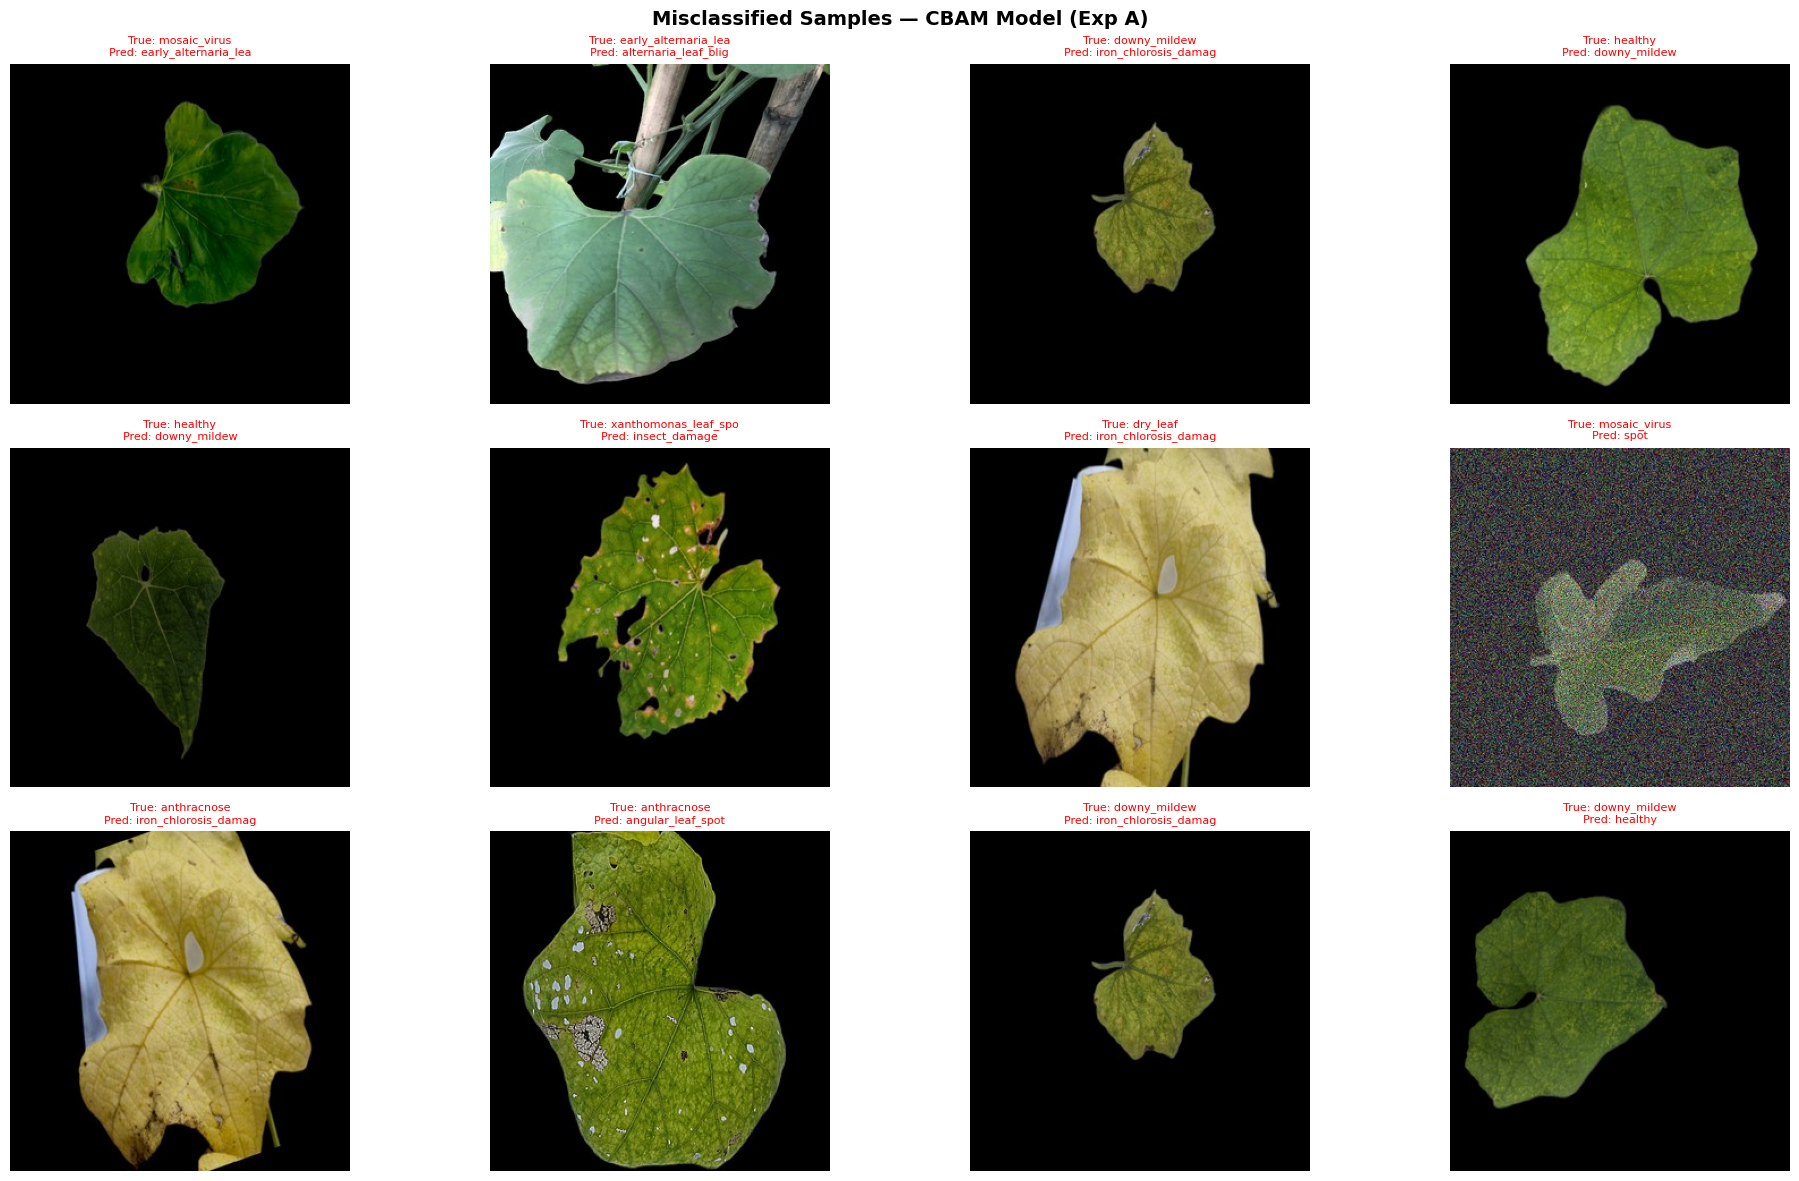

✓ Saved error_gallery.png (684 misclassified out of 4275)
Session: 0.5h elapsed / 11.5h remaining


In [33]:
# ============================================================
# BLOCK 12.5: ERROR GALLERY
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Misclassified Samples — CBAM Model (Exp A)', fontsize=14, fontweight='bold')

labels = results_A['CBAM']['labels']
preds = results_A['CBAM']['preds']
wrong_indices = np.where(preds != labels)[0]
np.random.shuffle(wrong_indices)

for i, ax in enumerate(axes.flat):
    if i < len(wrong_indices) and i < 12:
        idx = wrong_indices[i]
        img_path = test_samples[idx][0]
        true_label = UNIFIED_FIELD_CLASSES[labels[idx]]
        pred_label = UNIFIED_FIELD_CLASSES[preds[idx]]
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'True: {true_label[:20]}\nPred: {pred_label[:20]}', fontsize=8, color='red')
        except:
            ax.text(0.5, 0.5, 'Image error', ha='center')
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/error_gallery.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'✓ Saved error_gallery.png ({len(wrong_indices)} misclassified out of {len(labels)})')
session_status()

## Block 12.6 — Multi-Seed Validation (5 Seeds, Experiment A)
**v15/v16:** 5 seeds (was 3), each seed now genuinely varies training (v16 fix - see changelog;
in v15 `train_model`'s internal `set_seed(42)` silently overrode the per-seed call, so all
5 runs shared identical augmentation/mixup/dropout randomness). Scope: Field (Experiment A)
only — this cell's code does not train on Exp B's data, despite the v15 markdown here
previously claiming otherwise. Up to 150 epochs per run with early-stopping patience=20.

In [34]:
# ============================================================
# BLOCK 12.6: MULTI-SEED VALIDATION (5 SEEDS, 150 EPOCHS EACH)
# ============================================================
print('='*60)
print(f'MULTI-SEED VALIDATION — Seeds: {CFG.SEEDS} ({len(CFG.SEEDS)} seeds)')
print(f'Epochs: up to {CFG.MAX_EPOCHS} per model | Patience: {CFG.PATIENCE}')
print('='*60)
session_status()

multi_seed_results = {}
for seed in CFG.SEEDS:
    seed_key = f'seed{seed}'
    multi_seed_results[seed_key] = {}
    print(f'\n{"="*60}')
    print(f'--- Seed {seed} ---')
    print(f'{"="*60}')
    for model_name, attention in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
        ckpt_name = f'{model_name}_Field_{seed_key}_best'
        ckpt_path = f'{CFG.CKPT_DIR}/{ckpt_name}.pth'
        resume_path_ms = f'{CFG.CKPT_DIR}/{ckpt_name}_resume_state.pth'
        should_skip_ms = False
        skip_acc = None
        hist_path_ms = f'{CFG.CKPT_DIR}/{ckpt_name}_best_history.json'
        if os.path.exists(hist_path_ms):
            # v16 FIX: see Block 8 for full rationale - best_history.json existing is the
            # reliable "done" signal now that early stopping can finish before epoch 150.
            with open(hist_path_ms) as f:
                skip_acc = json.load(f)['best_acc']
            print(f'  {model_name} (seed={seed}): {skip_acc:.2f}% (already completed)')
            should_skip_ms = True
        elif resume_state_is_usable(resume_path_ms):
            try:
                resume_ckpt_ms = torch_load_compat(resume_path_ms, map_location=DEVICE)
                resume_epoch_ms = resume_ckpt_ms.get('epoch', 0)
                print(f'  {model_name} (seed={seed}): interrupted at epoch {resume_epoch_ms}/150 — will resume')
            except:
                pass
        elif checkpoint_is_usable(ckpt_path):
            # v21 FIX: this branch is only reached when hist_path_ms does NOT exist (the first
            # `if os.path.exists(hist_path_ms)` was False), so opening it raised FileNotFoundError.
            # Guard it: if the history JSON is genuinely absent (e.g. a ZIP restored the .pth but
            # not the JSON), fall through and retrain instead of crashing.
            if os.path.exists(hist_path_ms):
                with open(hist_path_ms) as f:
                    skip_acc = json.load(f)['best_acc']
                should_skip_ms = True
            else:
                print(f'  {model_name} (seed={seed}): checkpoint present but no history JSON - retraining')
        if should_skip_ms:
            multi_seed_results[seed_key][model_name] = skip_acc
            print(f'  {model_name} (seed={seed}): {skip_acc:.2f}% (loaded)')
            # Still create ZIP for this model
            zip_resume_state(ckpt_name)
            zip_model_checkpoint(ckpt_name)
            continue
        # Train with this seed
        set_seed(seed)
        print(f'\n  Training {model_name} (seed={seed}) for up to {CFG.MAX_EPOCHS} epochs...')
        model = build_efficientnet(CFG.NUM_CLASSES, attention=attention,
                                       reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
        best_acc = train_model(
            model, field_train_loader, field_val_loader,
            num_epochs=150, patience=CFG.PATIENCE,
            lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
            name=ckpt_name, use_coral=False, use_mixup=True, use_swa=False,
            num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS,
            seed=seed  # v16 FIX: this is the actual call site for the seed-override bug -
                       # train_model() used to hardcode set_seed(42) internally regardless
                       # of this seed, silently defeating the whole point of this block.
        )
        multi_seed_results[seed_key][model_name] = best_acc
        # Create per-model per-seed checkpoint ZIP download
        zip_resume_state(ckpt_name)
        zip_model_checkpoint(ckpt_name)

# Summary
print('\n' + '='*60)
print('MULTI-SEED RESULTS (Mean ± Std)')
print('='*60)
for model in ['Baseline', 'CBAM', 'SE']:
    accs = [multi_seed_results[f'seed{s}'].get(model, 0) for s in CFG.SEEDS]
    mean = np.mean(accs); std = np.std(accs)
    print(f'  {model}: {mean:.2f} ± {std:.2f}%  (seeds: {[f"{a:.2f}" for a in accs]})')

# CBAM boost across seeds
base_accs = [multi_seed_results[f'seed{s}'].get('Baseline', 0) for s in CFG.SEEDS]
cbam_accs = [multi_seed_results[f'seed{s}'].get('CBAM', 0) for s in CFG.SEEDS]
boosts = [c - b for c, b in zip(cbam_accs, base_accs)]
print(f'\n  CBAM boost: {np.mean(boosts):.2f} ± {np.std(boosts):.2f} pp')

with open(f'{CFG.OUTPUT_DIR}/multi_seed_results.json', 'w') as f:
    json.dump(multi_seed_results, f, indent=2)
download_checkpoints('seed_all')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

MULTI-SEED VALIDATION — Seeds: [42, 123, 456] (3 seeds)
Epochs: up to 60 per model | Patience: 999
Session: 0.5h elapsed / 11.5h remaining

--- Seed 42 ---
  Baseline (seed=42): 83.27% (already completed)
  Baseline (seed=42): 83.27% (loaded)

  >>> CHECKPOINT ZIP: Baseline_Field_seed42_best_checkpoint.zip (43.1 MB, 3 files)


/kaggle/working/Baseline_Field_seed42_best_checkpoint.zip

  CBAM (seed=42): 83.83% (already completed)
  CBAM (seed=42): 83.83% (loaded)

  >>> CHECKPOINT ZIP: CBAM_Field_seed42_best_checkpoint.zip (43.1 MB, 3 files)


/kaggle/working/CBAM_Field_seed42_best_checkpoint.zip

  SE (seed=42): 83.79% (already completed)
  SE (seed=42): 83.79% (loaded)

  >>> CHECKPOINT ZIP: SE_Field_seed42_best_checkpoint.zip (43.1 MB, 3 files)


...

  CBAM (seed=456): 84.19% (already completed)
  CBAM (seed=456): 84.19% (loaded)

  >>> CHECKPOINT ZIP: CBAM_Field_seed456_best_checkpoint.zip (43.1 MB, 3 files)


/kaggle/working/CBAM_Field_seed456_best_checkpoint.zip

  SE (seed=456): 83.93% (already completed)
  SE (seed=456): 83.93% (loaded)

  >>> CHECKPOINT ZIP: SE_Field_seed456_best_checkpoint.zip (43.1 MB, 3 files)


/kaggle/working/SE_Field_seed456_best_checkpoint.zip


MULTI-SEED RESULTS (Mean ± Std)
  Baseline: 83.72 ± 0.36%  (seeds: ['83.27', '83.74', '84.14'])
  CBAM: 84.06 ± 0.16%  (seeds: ['83.83', '84.16', '84.19'])
  SE: 83.79 ± 0.12%  (seeds: ['83.79', '83.64', '83.93'])

  CBAM boost: 0.35 ± 0.22 pp
  [zip] seed_all: checkpoint set unchanged since experiment_B_lab_checkpoints.zip - not rebuilding (1407 MB saved).
Session: 0.5h elapsed / 11.5h remaining


## Block 12.7 - TRUE Zero-Shot Cross-Domain (HEADLINE)

In [35]:
# ============================================================
# BLOCK 12.7 - TRUE ZERO-SHOT CROSS-DOMAIN EVALUATION  *** HEADLINE ***
# ============================================================
# THE THESIS CONTRIBUTION. Inference only - no training, ~10 minutes.
#
# Every experiment so far (A/B/C/D) trains and tests on data drawn from domains
# the model has already seen. That measures interpolation, not generalisation.
# Across the 9 papers reviewed, this is the single most common overclaim:
# "generalization" demonstrated from in-distribution splits.
#
# PlantDoc (India, 3,078 imgs) and CCMT (Ghana, 25,170 imgs) were downloaded,
# symlinked and counted in the "71,909 images across 8 datasets" headline -
# and then never used by any experiment. They are pristine unseen domains.
#
# PROTOCOL: taxonomies differ (Field 20 / PlantDoc 28 / CCMT 22 classes), so we
# collapse to the one label every plant-disease dataset shares - healthy vs
# diseased - and evaluate the Field-trained models on each unseen domain.
# Reported with BALANCED accuracy and MCC because the priors differ per domain.

import os, gc, json, numpy as np, torch
from PIL import Image
from tqdm.std import tqdm
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             balanced_accuracy_score, matthews_corrcoef)

# ---------------- healthy/diseased label mapping ----------------
# WARNING - READ BEFORE TRUSTING ANY NUMBER BELOW.
# A pure "does the name contain 'healthy'" rule is WRONG for PlantDoc, whose
# healthy classes are named bare "<Crop> leaf" ("Cherry leaf", "grape leaf",
# "Apple leaf") while diseased ones carry the symptom ("Apple rust leaf",
# "Corn Gray leaf spot"). That rule would mark every PlantDoc image diseased
# and produce a confident, meaningless zero-shot score.
# So: token rule + explicit per-dataset override + a hard guard that refuses to
# evaluate a dataset in which nothing was identified as healthy.
HEALTHY_TOKENS = ('healthy', 'health', 'fresh', 'normal', 'disease_free')
DISEASE_TOKENS = ('rust', 'scab', 'blight', 'spot', 'mildew', 'mold', 'mosaic', 'virus',
                  'rot', 'bacterial', 'fungal', 'anthracnose', 'curl', 'wilt', 'chlorosis',
                  'deficiency', 'damage', 'insect', 'hole', 'necrotic', 'dry', 'disease',
                  'gumosis', 'streak', 'blast', 'brown', 'red', 'miner', 'cercospora')

# Verified against the published PlantDoc class list. CONFIRM against the printed
# table below before reporting results; add entries for any dataset you add.
HEALTHY_OVERRIDE = {
    'plantdoc': {'Apple leaf', 'Bell_pepper leaf', 'Blueberry leaf', 'Cherry leaf',
                 'Corn leaf', 'Peach leaf', 'Potato leaf', 'Raspberry leaf',
                 'Soyabean leaf', 'Strawberry leaf', 'Tomato leaf', 'grape leaf',
                 'Squash leaf'},
    'ccmt': set(),   # CCMT uses an explicit 'healthy' folder per crop -> token rule works
}

def is_healthy(cls_name, ds_key=None):
    ov = HEALTHY_OVERRIDE.get(ds_key)
    if ov:
        if cls_name in ov: return True
        norm = {o.lower().replace('-', '_').replace(' ', '_') for o in ov}
        if cls_name.lower().replace('-', '_').replace(' ', '_') in norm: return True
    n = cls_name.lower().replace('-', '_').replace(' ', '_')
    if any(t in n for t in HEALTHY_TOKENS): return True
    return False

def build_binary_samples(ds_key, verbose=True):
    """(path, 0=healthy | 1=diseased, group) for every image of a scanned dataset.
    Prints the full class -> label assignment so it can be eyeballed."""
    root = dataset_paths.get(ds_key)
    if root is None or not os.path.isdir(root):
        return []
    out, table = [], []
    for cls in sorted(os.listdir(root)):
        cdir = os.path.join(root, cls)
        if not os.path.isdir(cdir): continue
        lab = 0 if is_healthy(cls, ds_key) else 1
        n = 0
        for fn in os.listdir(cdir):
            if fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                out.append((os.path.join(cdir, fn), lab, f'{ds_key}_{cls}')); n += 1
        table.append((cls, 'HEALTHY' if lab == 0 else 'diseased', n))
    if verbose:
        print(f'  class -> binary label mapping for "{ds_key}" (VERIFY THIS):')
        for cls, lab, n in table:
            mark = ' <<<' if lab == 'HEALTHY' else ''
            print(f'      {lab:8s} {n:6d}  {cls}{mark}')
    n_healthy_cls = sum(1 for _, l, _ in table if l == 'HEALTHY')
    if n_healthy_cls == 0:
        print(f'  *** REFUSING to evaluate "{ds_key}": no class was identified as healthy.')
        print(f'      Every image would be labelled diseased and the score would be')
        print(f'      meaningless. Add this dataset\'s healthy class names to')
        print(f'      HEALTHY_OVERRIDE above, then re-run this cell. ***')
        return []
    return out

class BinaryEvalDataset(torch.utils.data.Dataset):
    def __init__(self, samples, tf): self.samples = samples; self.tf = tf
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, y, _ = self.samples[i]
        try:    img = Image.open(p).convert('RGB')
        except Exception: img = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE))
        return self.tf(img), y

# Field-trained multi-class models -> collapse their 20-way output to binary.
_field_healthy_idx = [i for c, i in FIELD_TO_IDX.items() if is_healthy(c, 'field')]
_field_healthy_names = [c for c in FIELD_TO_IDX if is_healthy(c, 'field')]
print(f'Field classes treated as healthy: {_field_healthy_names}')
assert _field_healthy_idx, ('No Field class maps to healthy - the binary collapse would put '
                            'all probability mass on "diseased". Add the healthy Field class '
                            'name to HEALTHY_OVERRIDE["field"] and re-run.')

def zero_shot_eval(model, loader, name):
    """Collapse 20-way logits to healthy/diseased and score on an unseen domain."""
    model.eval(); preds = []; probs = []; labels = []
    with torch.no_grad():
        for imgs, ys in tqdm(loader, desc=name, ncols=80, leave=False):
            p = torch.softmax(model(imgs.to(DEVICE)), dim=1)
            p_healthy = p[:, _field_healthy_idx].sum(1)
            p_dis = 1.0 - p_healthy
            probs.extend(p_dis.cpu().numpy())
            preds.extend((p_dis > 0.5).long().cpu().numpy())
            labels.extend(ys.numpy())
    preds = np.array(preds); probs = np.array(probs); labels = np.array(labels)
    acc = accuracy_score(labels, preds) * 100
    bal = balanced_accuracy_score(labels, preds) * 100
    f1m = f1_score(labels, preds, average='macro', zero_division=0) * 100
    mcc = matthews_corrcoef(labels, preds)
    try:    auc = float(roc_auc_score(labels, probs))
    except Exception: auc = None
    maj = np.bincount(labels).max() / len(labels) * 100
    auc_s = 'n/a' if auc is None else f'{auc:.4f}'
    print(f'  {name}: Acc={acc:.2f}% | BalAcc={bal:.2f}% | F1macro={f1m:.2f}% | '
          f'MCC={mcc:.4f} | AUC={auc_s} | majority={maj:.2f}%')
    if len(np.unique(preds)) == 1:
        print('    *** DEGENERATE: single-class prediction on this domain ***')
    return {'acc': acc, 'balanced_acc': bal, 'f1_macro': f1m, 'mcc': float(mcc),
            'auc': auc, 'majority_baseline': float(maj),
            'n_pred_classes': int(len(np.unique(preds))), 'n_samples': int(len(labels))}

print('='*70); print('ZERO-SHOT: Field-trained -> UNSEEN domains'); print('='*70)
zero_shot_results = {}
for ds_key, human in [('plantdoc', 'PlantDoc (India, field)'), ('ccmt', 'CCMT (Ghana, field)')]:
    samples = build_binary_samples(ds_key)
    if not samples:
        print(f'\n--- {human}: NOT AVAILABLE (skipped) ---'); continue
    nh = sum(1 for s in samples if s[1] == 0)
    print(f'\n--- {human}: {len(samples)} images (healthy={nh}, diseased={len(samples)-nh}) ---')
    loader = torch.utils.data.DataLoader(
        BinaryEvalDataset(samples, val_tf),
        batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    zero_shot_results[ds_key] = {}
    for mname, att in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
        ck = f'{CFG.CKPT_DIR}/{mname}_Field_best.pth'
        if not os.path.exists(ck):
            print(f'  {mname}: checkpoint missing, skipped'); continue
        m = build_efficientnet(CFG.NUM_CLASSES, attention=att, backbone=CFG.BACKBONE,
                               reduction=CFG.CBAM_REDUCTION if att == 'cbam' else CFG.SE_REDUCTION).to(DEVICE)
        m.load_state_dict(load_weights(ck, DEVICE))
        zero_shot_results[ds_key][mname] = zero_shot_eval(m, loader, f'{mname:8s}')
        del m; gc.collect(); torch.cuda.empty_cache()

# ---- in-domain reference point, same binary collapse, same metric ----
# LABEL POLARITY - this bit is easy to get backwards and silently invert everything.
# Block 6 builds field_binary_test_loader with
#     label = 1 if label == healthy_idx else 0        # 1 = HEALTHY, 0 = diseased
# Block 12.7 uses the opposite convention everywhere else (0 = healthy, 1 = diseased),
# because that is what build_binary_samples() emits for PlantDoc/CCMT. Feeding the
# loader in unflipped inverted every in-domain label and produced
#     Acc=2.49% | MCC=-0.8982 | AUC=0.0031
# i.e. near-perfect ANTI-correlation. The PlantDoc/CCMT numbers were unaffected
# (they come from BinaryEvalDataset, which already uses 0=healthy).
class _FlipBinaryLabels(torch.utils.data.Dataset):
    """Re-express Block 6's 1=healthy dataset in this block's 0=healthy convention."""
    def __init__(self, ds): self.ds = ds
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        x, y = self.ds[i]
        return x, 1 - int(y)

_healthy_idx_field = FIELD_TO_IDX.get('healthy', FIELD_TO_IDX.get('Healthy', -1))
# Verify the flip on the label arithmetic alone (no image decoding needed).
_block6_labels = np.array([1 if s[1] == _healthy_idx_field else 0 for s in test_samples])
_flipped       = 1 - _block6_labels
_ours          = np.array([0 if s[1] == _healthy_idx_field else 1 for s in test_samples])
assert (_flipped == _ours).all(), 'binary label flip does not reproduce the 0=healthy convention'
print(f'\n  [polarity check] Block 6 uses 1=healthy; flipped to 0=healthy. '
      f'healthy={int((_ours == 0).sum())}, diseased={int((_ours == 1).sum())}')

print('\n--- In-domain reference (Field test set, same binary collapse) ---')
_indomain_loader = torch.utils.data.DataLoader(
    _FlipBinaryLabels(field_binary_test_ds), batch_size=CFG.BATCH_SIZE,
    shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
zero_shot_results['field_indomain'] = {}
for mname, att in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
    ck = f'{CFG.CKPT_DIR}/{mname}_Field_best.pth'
    if not os.path.exists(ck): continue
    m = build_efficientnet(CFG.NUM_CLASSES, attention=att, backbone=CFG.BACKBONE,
                           reduction=CFG.CBAM_REDUCTION if att == 'cbam' else CFG.SE_REDUCTION).to(DEVICE)
    m.load_state_dict(load_weights(ck, DEVICE))
    zero_shot_results['field_indomain'][mname] = zero_shot_eval(m, _indomain_loader, f'{mname:8s}')
    del m; gc.collect(); torch.cuda.empty_cache()

print('\n' + '='*70); print('DOMAIN GAP (this is the real one)'); print('='*70)
print(f'{"Model":<10} {"In-domain":>11} {"PlantDoc":>11} {"CCMT":>11} {"gap(PD)":>9} {"gap(CCMT)":>10}')
print('-'*70)
for mname in ['Baseline', 'CBAM', 'SE']:
    ind = zero_shot_results.get('field_indomain', {}).get(mname)
    pd_ = zero_shot_results.get('plantdoc', {}).get(mname)
    cc_ = zero_shot_results.get('ccmt', {}).get(mname)
    if not ind: continue
    f = lambda d: f'{d["balanced_acc"]:.2f}%' if d else '   n/a'
    g = lambda d: f'{ind["balanced_acc"]-d["balanced_acc"]:+.2f}' if d else '  n/a'
    print(f'{mname:<10} {f(ind):>11} {f(pd_):>11} {f(cc_):>11} {g(pd_):>9} {g(cc_):>10}')
print('\n(balanced accuracy; gap = in-domain minus unseen-domain, in percentage points)')
print('Literature for comparison: Krishna 2025 PlantDoc->web 76.8% vs web->PlantDoc 59.1%;')
print('Zubair 2025 one model across three datasets: 99.69 / 83 / 60.')

json.dump(zero_shot_results, open(f'{CFG.OUTPUT_DIR}/zero_shot_results.json', 'w'), indent=2, default=str)
print(f'\nSaved zero_shot_results.json')


Field classes treated as healthy: ['healthy']
ZERO-SHOT: Field-trained -> UNSEEN domains
  class -> binary label mapping for "plantdoc" (VERIFY THIS):
      HEALTHY      88  apple_leaf <<<
      diseased    106  apple_rust_leaf
      diseased     93  apple_scab_leaf
      HEALTHY     100  bell_pepper_leaf <<<
      diseased     83  bell_pepper_leaf_spot
      HEALTHY     117  blueberry_leaf <<<
      HEALTHY      57  cherry_leaf <<<
      diseased     67  corn_gray_leaf_spot
      diseased    194  corn_leaf_blight
      diseased    117  corn_rust_leaf
      HEALTHY      75  grape_leaf <<<
      diseased     79  grape_leaf_black_rot
      HEALTHY     112  peach_leaf <<<
      diseased    171  potato_leaf_early_blight
      diseased    208  potato_leaf_late_blight
      HEALTHY     119  raspberry_leaf <<<
      HEALTHY      65  soyabean_leaf <<<
      diseased    130  squash_powdery_mildew_leaf
      HEALTHY      96  strawberry_leaf <<<
      diseased     88  tomato_early_blight_leaf
   

  Baseline: Acc=78.65% | BalAcc=66.42% | F1macro=68.37% | MCC=0.4232 | AUC=0.8358 | majority=71.38%


  CBAM    : Acc=77.81% | BalAcc=65.45% | F1macro=67.19% | MCC=0.3968 | AUC=0.8194 | majority=71.38%


  SE      : Acc=79.01% | BalAcc=68.30% | F1macro=70.26% | MCC=0.4392 | AUC=0.8221 | majority=71.38%
  class -> binary label mapping for "ccmt" (VERIFY THIS):
      diseased   1729  cashew_anthracnose
      diseased    392  cashew_gumosis
      HEALTHY    1368  cashew_healthy <<<
      diseased   1378  cashew_leaf_miner
      diseased   1682  cashew_red_rust
      diseased   2614  cassava_bacterial_blight
      diseased   1481  cassava_brown_spot
      diseased   1015  cassava_green_mite
      HEALTHY    1193  cassava_healthy <<<
      diseased   1205  cassava_mosaic
      diseased    285  maize_fall_armyworm
      diseased    673  maize_grasshoper
      HEALTHY     206  maize_healthy <<<
      diseased    938  maize_leaf_beetle
      diseased    998  maize_leaf_blight
      diseased   1249  maize_leaf_spot
      diseased    972  maize_streak_virus
      HEALTHY     468  tomato_healthy <<<
      diseased   1294  tomato_leaf_blight
      diseased    514  tomato_leaf_curl
      diseased  

  Baseline: Acc=85.97% | BalAcc=84.48% | F1macro=75.83% | MCC=0.5537 | AUC=0.8828 | majority=87.15%


  CBAM    : Acc=86.03% | BalAcc=83.77% | F1macro=75.65% | MCC=0.5468 | AUC=0.8799 | majority=87.15%


  SE      : Acc=84.09% | BalAcc=83.89% | F1macro=73.84% | MCC=0.5270 | AUC=0.8837 | majority=87.15%

  [polarity check] Block 6 uses 1=healthy; flipped to 0=healthy. healthy=627, diseased=3648

--- In-domain reference (Field test set, same binary collapse) ---


  Baseline: Acc=95.98% | BalAcc=88.53% | F1macro=91.36% | MCC=0.8320 | AUC=0.9940 | majority=85.33%


  CBAM    : Acc=96.05% | BalAcc=89.23% | F1macro=91.61% | MCC=0.8356 | AUC=0.9937 | majority=85.33%


  SE      : Acc=96.26% | BalAcc=91.01% | F1macro=92.29% | MCC=0.8466 | AUC=0.9942 | majority=85.33%

DOMAIN GAP (this is the real one)
Model        In-domain    PlantDoc        CCMT   gap(PD)  gap(CCMT)
----------------------------------------------------------------------
Baseline        88.53%      66.42%      84.48%    +22.11      +4.05
CBAM            89.23%      65.45%      83.77%    +23.78      +5.46
SE              91.01%      68.30%      83.89%    +22.70      +7.12

(balanced accuracy; gap = in-domain minus unseen-domain, in percentage points)
Literature for comparison: Krishna 2025 PlantDoc->web 76.8% vs web->PlantDoc 59.1%;
Zubair 2025 one model across three datasets: 99.69 / 83 / 60.

Saved zero_shot_results.json


## Block 12.8 - Experiment D Test Evaluation

In [36]:
# ============================================================
# BLOCK 12.8 - EXPERIMENT D TEST EVALUATION (was never evaluated)
# ============================================================
# Block 12 evaluates only A, B and C. The Exp D numbers quoted in the thesis
# summary (92.21 / 92.05 / 92.25%) are TRAINING VALIDATION accuracies from
# Block 11.5 - no test set, no McNemar, no CI - yet they sit in the same table
# as properly evaluated results. This closes that gap.
import os, gc, torch
# NAME COLLISION - do not write to `results_D`. Block 11.5 (base) sets
# results_D[name] = best_acc (a FLOAT), and Block 21 (base) prints it with
# f'{a:.2f}%'. Overwriting it with metric dicts raises
# "TypeError: unsupported format string passed to dict.__format__" there.
# We publish under results_D_eval and leave the base contract untouched.
results_D_eval = {}
_d_loader = lab_val_loader if 'lab_val_loader' in globals() else None
if _d_loader is None:
    print('  Exp D loader unavailable - skipped.')
else:
    print('='*60); print('EXPERIMENT D: Field->Lab reverse transfer'); print('='*60)
    print('  *** CAVEAT: Block 9 splits Lab into TRAIN/VAL only - there is no Lab test')
    print('      set. These numbers are computed on lab_val_loader, the same split used')
    print('      for model selection during Exp D training, so they are OPTIMISTIC.')
    print('      Report them as validation accuracy, never as test accuracy. To fix')
    print('      properly, add a third Lab split in Block 9 and retrain Exp D. ***')
    _nc = CFG.LAB_NUM_CLASSES
    for mname, att in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
        ck = f'{CFG.CKPT_DIR}/{mname}_Reverse_best.pth'
        if not os.path.exists(ck):
            print(f'  {mname}_Reverse checkpoint missing, skipped'); continue
        m = build_efficientnet(_nc, attention=att, backbone=CFG.BACKBONE,
                               reduction=CFG.CBAM_REDUCTION if att == 'cbam' else CFG.SE_REDUCTION).to(DEVICE)
        m.load_state_dict(load_weights(ck, DEVICE))
        results_D_eval[mname] = evaluate_model_full(m, _d_loader, _nc, f'D: {mname}', use_tta=True)
        del m; gc.collect(); torch.cuda.empty_cache()

    if len(results_D_eval) >= 2:
        print('\n  McNemar (Exp D):')
        _lab = results_D_eval['Baseline']['labels']
        for a, b in [('CBAM', 'Baseline'), ('SE', 'Baseline'), ('CBAM', 'SE')]:
            if a in results_D_eval and b in results_D_eval:
                chi2, p = mcnemar_test(results_D_eval[a]['preds'], results_D_eval[b]['preds'], _lab)
                print(f'    {a} vs {b}: {fmt_p(chi2, p)}')


EXPERIMENT D: Field->Lab reverse transfer
  *** CAVEAT: Block 9 splits Lab into TRAIN/VAL only - there is no Lab test
      set. These numbers are computed on lab_val_loader, the same split used
      for model selection during Exp D training, so they are OPTIMISTIC.
      Report them as validation accuracy, never as test accuracy. To fix
      properly, add a third Lab split in Block 9 and retrain Exp D. ***
  D: Baseline: Acc=92.08% | F1w=92.02% | F1macro=90.89% | BalAcc=90.98% | MCC=0.9133 | Kappa=0.9132 | AUC=0.9936
  D: CBAM: Acc=92.08% | F1w=92.03% | F1macro=91.16% | BalAcc=91.38% | MCC=0.9134 | Kappa=0.9133 | AUC=0.9913
  D: SE: Acc=92.02% | F1w=91.96% | F1macro=90.91% | BalAcc=91.14% | MCC=0.9125 | Kappa=0.9125 | AUC=0.9935

  McNemar (Exp D):
    CBAM vs Baseline: chi2=0.01, p=0.9326 ns
    SE vs Baseline: chi2=0.01, p=0.9362 ns
    CBAM vs SE: chi2=0.01, p=0.9331 ns


## Block 12.9 - SE-Stripped Control (the real ablation)

In [37]:
# ============================================================
# BLOCK 12.9 - SE-STRIPPED CONTROL: the attention-free baseline
# ============================================================
# WHY THIS BLOCK IS THE ABLATION.
# torchvision's MBConv builds SqueezeExcitation(expanded, input//4) in every
# block, so EfficientNet-B3 ships with 26 SE modules. Experiments A-D therefore
# compare:
#     "Baseline"  = 26 SE
#     "SE" arm    = 26 SE + 5 more SE
#     "CBAM" arm  = 26 SE + 5 CBAM
# There is NO attention-free arm anywhere, so no result in this notebook can
# support a sentence of the form "attention improves X". The standard for an
# attention ablation is a base network with the module REMOVED, not a base
# network that already contains it.
#
# strip_se=True replaces all 26 with nn.Identity -> 9.61M params vs 11.49M.
# That arm is trained here under the identical Exp A protocol so the comparison
# is controlled: same split, same epochs, same optimiser, same augmentation.
#
# COST: 1 seed ~= 4.3 GPU-h. Set CONTROL_SEEDS = CFG.SEEDS for all 3 (~13 h).
import os, gc, json, torch, numpy as np

CONTROL_SEEDS = CFG.SEEDS     # v27 FIX: 1 seed cannot carry the headline ablation.
                              # Already-trained seeds auto-skip; only new ones train.
RUN_SE_CONTROL = True

results_noattn = {}
if not RUN_SE_CONTROL:
    print('  Skipped (RUN_SE_CONTROL=False).')
else:
    print('=' * 68)
    print('SE-STRIPPED CONTROL (attention-free)')
    print('=' * 68)

    for _seed in CONTROL_SEEDS:
        _name = f'NoAttn_Field_seed{_seed}'
        _hist = f'{CFG.CKPT_DIR}/{_name}_best_history.json'
        if os.path.exists(_hist):
            _h = json.load(open(_hist))
            print(f'\n[SKIP] {_name} already completed - best val acc: {_h["best_acc"]:.2f}%')
            results_noattn[_seed] = _h['best_acc']
            continue

        print(f'\n--- Training {_name} (attention-free, seed={_seed}) ---')
        _m = build_efficientnet(CFG.NUM_CLASSES, attention='none',
                                backbone=CFG.BACKBONE, strip_se=True).to(DEVICE)
        print(f'    params: {sum(p.numel() for p in _m.parameters()):,} '
              f'| built-in SE remaining: {count_builtin_se(_m)}')
        assert count_builtin_se(_m) == 0, 'strip_se failed - this is not an attention-free control'

        _acc = train_model(
            _m, field_train_loader, field_val_loader,
            num_epochs=CFG.FIELD_EPOCHS, patience=CFG.PATIENCE,
            lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
            name=_name, use_coral=False, use_mixup=True, use_swa=False,   # v27: match Block 12.6 (the other 9 seed models),
            num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS, seed=_seed
        )
        results_noattn[_seed] = _acc
        del _m; gc.collect(); torch.cuda.empty_cache()
        try: zip_model_checkpoint(_name)
        except Exception: pass

    # ---------- evaluate on the SAME test loader as Exp A ----------
    _eval = {}
    for _seed in CONTROL_SEEDS:
        _ck = f'{CFG.CKPT_DIR}/NoAttn_Field_seed{_seed}_best.pth'
        if not os.path.exists(_ck):
            print(f'  checkpoint missing for seed {_seed}, skipping eval'); continue
        _m = build_efficientnet(CFG.NUM_CLASSES, attention='none',
                                backbone=CFG.BACKBONE, strip_se=True).to(DEVICE)
        _m.load_state_dict(load_weights(_ck, DEVICE))
        _eval[_seed] = evaluate_model_full(_m, field_test_loader, CFG.NUM_CLASSES,
                                           f'NoAttn(seed{_seed})', use_tta=False)
        # v28: was use_tta=True. Block 23.1 scores every arm with use_tta=False,
        # so the old setting made this table's numbers incomparable with the
        # ablation table - the same NoAttn seed-42 checkpoint read 83.65% here
        # and 83.37% there. One regime, everywhere.
        del _m; gc.collect(); torch.cuda.empty_cache()

    # ---------- the corrected 4-arm ablation ----------
    if _eval and 'results_A' in dir() and results_A:
        _s0 = CONTROL_SEEDS[0]
        _na = _eval[_s0]
        print('\n' + '=' * 68)
        print('CORRECTED ABLATION - attention content vs accuracy (Exp A test set)')
        print('=' * 68)
        print(f'{"arm":<34}{"built-in SE":>12}{"added":>10}{"acc":>9}{"macroF1":>9}')
        print('-' * 74)
        print(f'{"NoAttn (SE stripped) [CONTROL]":<34}{0:>12}{"-":>10}'
              f'{_na["acc"]:>8.2f}%{_na["f1_macro"]:>8.2f}%')
        for _k, _added in [('Baseline', '-'), ('SE', '+5 SE'), ('CBAM', '+5 CBAM')]:
            if _k in results_A:
                _r = results_A[_k]
                print(f'{_k:<34}{26:>12}{_added:>10}{_r["acc"]:>8.2f}%{_r["f1_macro"]:>8.2f}%')

        _b = results_A.get('Baseline')
        if _b is not None:
            _d = _b['acc'] - _na['acc']
            print(f'\n  DESCRIPTIVE ONLY: Baseline - NoAttn = {_d:+.2f} pp')
            _chi2, _p = mcnemar_test(_b['preds'], _na['preds'], _b['labels'])
            print(f'  McNemar (these two runs only): {fmt_p(_chi2, _p)}')
            # v28: parameter counts were hardcoded here. Compute them.
            _p_base = sum(p.numel() for p in
                          build_efficientnet(CFG.NUM_CLASSES, attention='none',
                                             backbone=CFG.BACKBONE,
                                             reduction=CFG.SE_REDUCTION).parameters())
            _p_strip = sum(p.numel() for p in
                           build_efficientnet(CFG.NUM_CLASSES, attention='none',
                                              backbone=CFG.BACKBONE,
                                              reduction=CFG.SE_REDUCTION,
                                              strip_se=True).parameters())
            print(f'  parameter cost of the built-in SE modules: {_p_base:,} - '
                  f'{_p_strip:,} = {_p_base - _p_strip:,} '
                  f'({100*(_p_base - _p_strip)/_p_base:.1f}%)')
            print()
            # ---- v28: THIS COMPARISON CANNOT CARRY A CONCLUSION -------------
            # _b is the single Baseline_Field run; _na is ONE NoAttn seed. That
            # pairing produced "+1.40 pp, p=0.0004 ***" while cell 23.2, using
            # 3 seeds per arm and the same test set, measures +0.27 pp, p=0.13,
            # not significant. The gap is not a disagreement about statistics -
            # it is that a 1-vs-1 item-level test over 4275 images resolves the
            # difference between any two trained networks, INCLUDING two runs of
            # the same architecture. Cell 23.2c demonstrates exactly that.
            print('  DO NOT QUOTE A CONCLUSION FROM THIS ROW.')
            print('  It compares ONE Baseline run against ONE NoAttn seed. Cell 23.2')
            print('  makes the same comparison over 3 seeds per arm and finds')
            print('  +0.27 pp, p=0.13, not significant; cell 23.2c shows this test')
            print('  calls two seeds of the SAME network significantly different.')
            print('  The reportable ablation is 23.2. This block is descriptive only.')
            if False:
                print('  unreachable - kept so the branch structure stays obvious')
                print('  not what determines performance here.')

    json.dump({str(k): v for k, v in results_noattn.items()},
              open(f'{CFG.OUTPUT_DIR}/noattn_control.json', 'w'), indent=2)
    print(f'\n  saved noattn_control.json')


SE-STRIPPED CONTROL (attention-free)

[SKIP] NoAttn_Field_seed42 already completed - best val acc: 83.17%

[SKIP] NoAttn_Field_seed123 already completed - best val acc: 83.38%

[SKIP] NoAttn_Field_seed456 already completed - best val acc: 83.86%
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn(seed42): Acc=83.37% | F1w=83.48% | F1macro=82.59% | BalAcc=83.34% | MCC=0.8219 | Kappa=0.8215 | AUC=0.9917
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn(seed123): Acc=83.77% | F1w=83.87% | F1macro=83.08% | BalAcc=84.00% | MCC=0.8266 | Kappa=0.8258 | AUC=0.9922
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn(seed456): Acc=84.28% | F1w=84.33% | F1macro=83.37% | BalAcc=84.20% | MCC=0.8318 | Kappa=0.8313 | AUC=0.9923

CORRECTED ABLATION - attention content vs accuracy (Exp A test set)
arm                                built-in SE     added      acc  macroF1
--------------------------------

## Block 13 — Training Curves (Accuracy + Loss + LR Schedule)
NEW v15: Adds loss curves and LR schedule plot alongside accuracy.

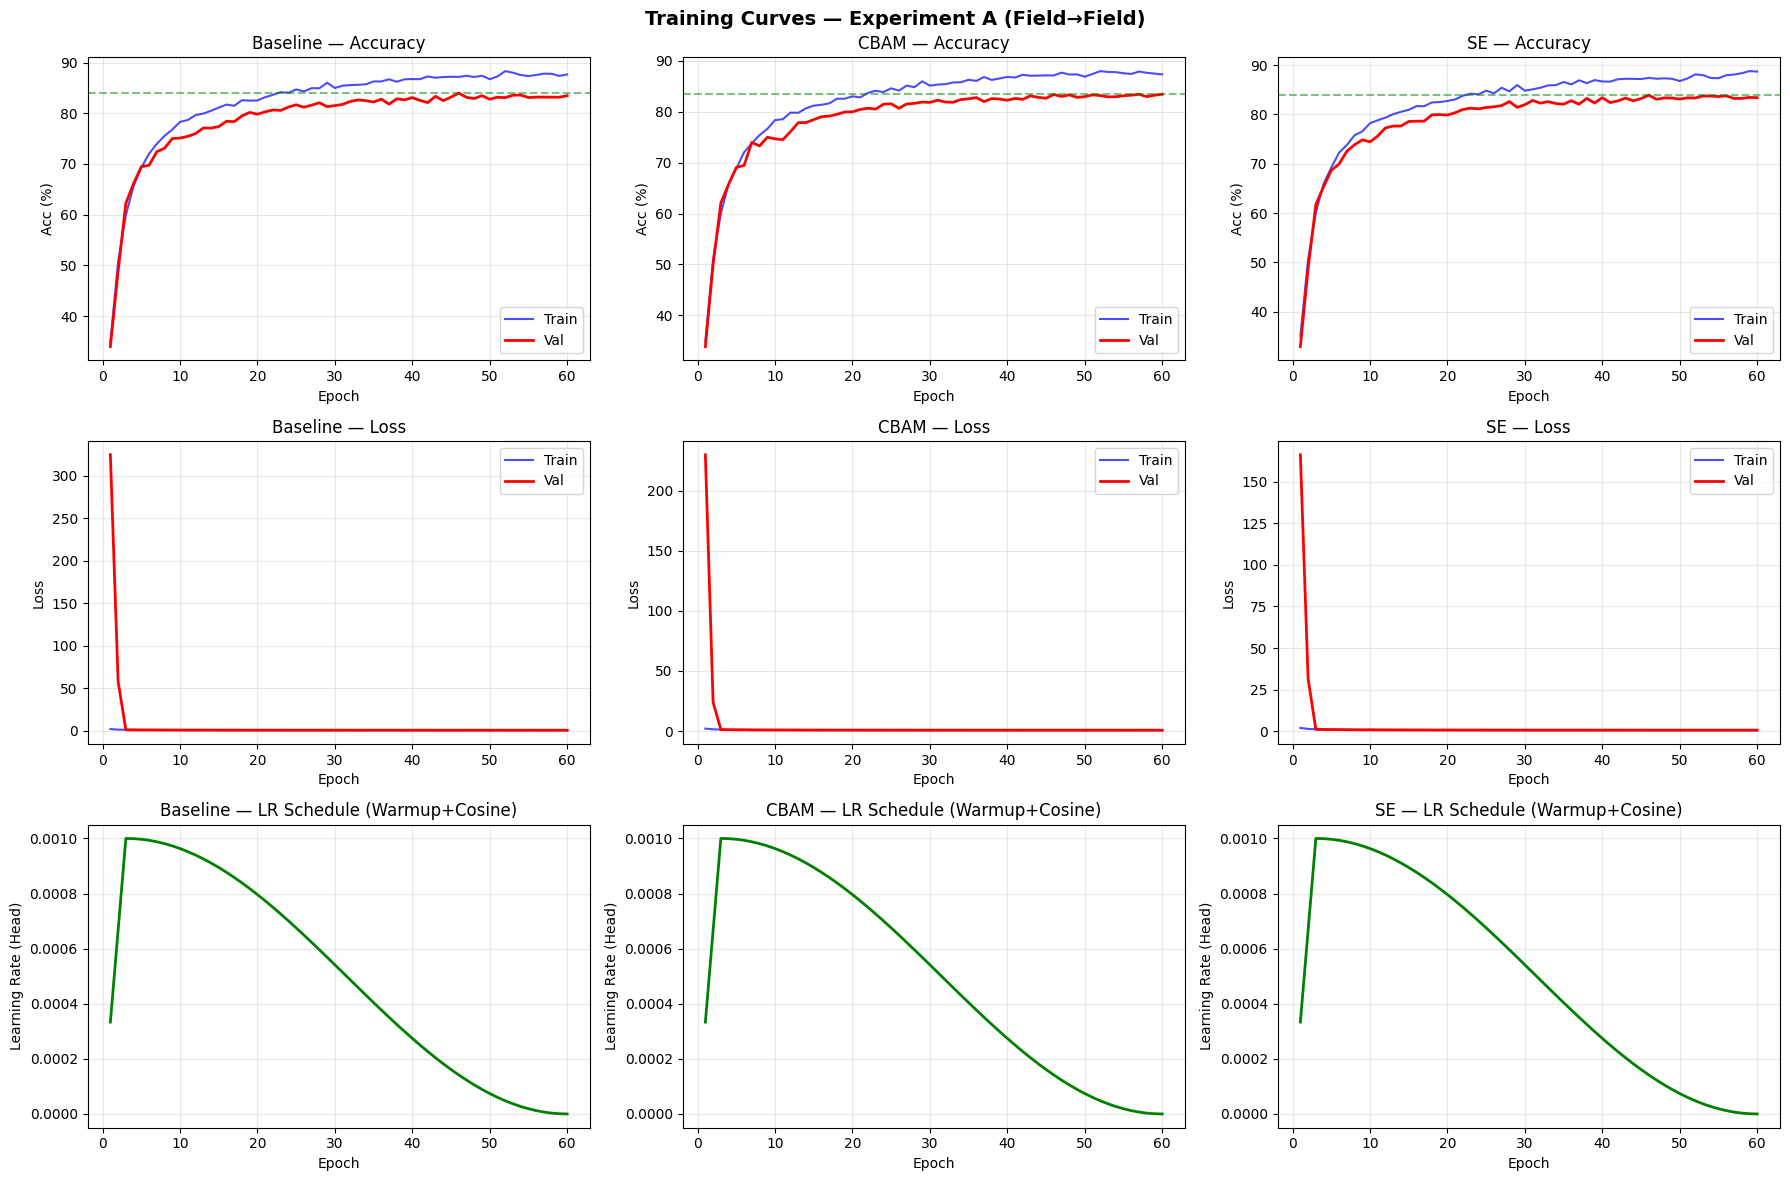

✓ Saved training_curves.png
Session: 0.6h elapsed / 11.4h remaining


In [38]:
# ============================================================
# BLOCK 13: TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Training Curves — Experiment A (Field→Field)', fontsize=14, fontweight='bold')

for col, (name, color) in enumerate([('Baseline_Field', 'blue'),
                                      ('CBAM_Field', 'red'),
                                      ('SE_Field', 'green')]):
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if not os.path.exists(hist_path):
        for ax in axes[:, col]: ax.axis('off')
        continue
    with open(hist_path) as f: data = json.load(f)
    h = data['history']
    epochs = range(1, len(h['train_acc']) + 1)

    # Accuracy
    ax = axes[0, col]
    ax.plot(epochs, h['train_acc'], 'b-', label='Train', alpha=0.7)
    ax.plot(epochs, h['val_acc'], 'r-', label='Val', linewidth=2)
    ax.set_title(f'{name.replace("_Field", "")} — Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Acc (%)')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.axhline(y=data['best_acc'], color='green', linestyle='--', alpha=0.5,
               label=f'Best: {data["best_acc"]:.2f}%')

    # Loss
    ax = axes[1, col]
    ax.plot(epochs, h['train_loss'], 'b-', label='Train', alpha=0.7)
    ax.plot(epochs, h['val_loss'], 'r-', label='Val', linewidth=2)
    ax.set_title(f'{name.replace("_Field", "")} — Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    # LR schedule (reconstruct)
    ax = axes[2, col]
    n_epochs = len(h['train_acc'])
    warmup = min(CFG.WARMUP_EPOCHS, n_epochs)
    cosine_epochs = max(1, n_epochs - warmup)
    lrs = []
    for e in range(1, n_epochs + 1):
        if e <= warmup:
            lr = CFG.LR_HEAD * (e / warmup) * 0.1 + CFG.LR_HEAD * 0.9 * (e / warmup)
        else:
            import math
            lr = CFG.LR_HEAD * 0.5 * (1 + math.cos(math.pi * (e - warmup) / cosine_epochs))
        lrs.append(lr)
    ax.plot(epochs, lrs, 'g-', linewidth=2)
    ax.set_title(f'{name.replace("_Field", "")} — LR Schedule (Warmup+Cosine)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate (Head)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved training_curves.png')
session_status()

## Block 13.5 — ROC Curves + Precision-Recall Curves (NEW)

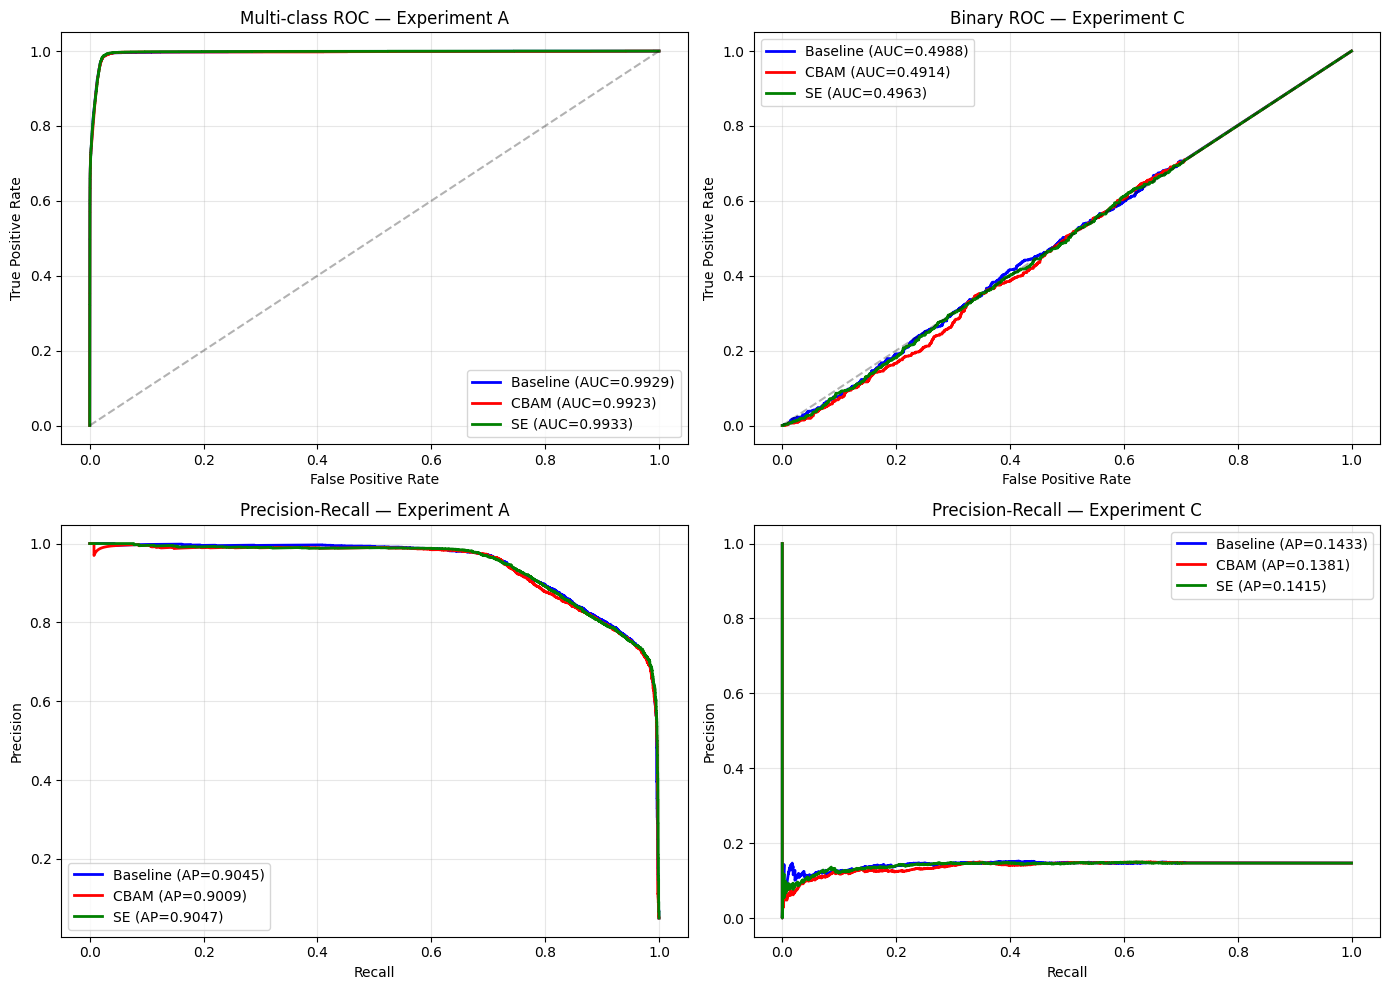

✓ Saved roc_pr_curves.png
Session: 0.6h elapsed / 11.4h remaining


In [39]:
# ============================================================
# BLOCK 13.5: ROC + PR CURVES
# ============================================================
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Multi-class ROC (Exp A)
ax = axes[0, 0]
for name, color in [('Baseline', 'blue'), ('CBAM', 'red'), ('SE', 'green')]:
    r = results_A[name]
    labels_bin = label_binarize(r['labels'], classes=list(range(CFG.NUM_CLASSES)))
    try:
        # Micro-average ROC
        fpr, tpr, _ = roc_curve(labels_bin.ravel(), r['probs'].ravel())
        auc = roc_auc_score(labels_bin, r['probs'], multi_class='ovr', average='weighted')
        ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})', linewidth=2)
    except: pass
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Multi-class ROC — Experiment A'); ax.legend(); ax.grid(True, alpha=0.3)

# Binary ROC (Exp C)
ax = axes[0, 1]
for name, color in [('Baseline', 'blue'), ('CBAM', 'red'), ('SE', 'green')]:
    if name not in results_C:  # v21: skip if Experiment C was not run
        continue
    r = results_C[name]
    try:
        fpr, tpr, _ = roc_curve(r['labels'], r['probs'][:, 1])
        auc = roc_auc_score(r['labels'], r['probs'][:, 1])
        ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})', linewidth=2)
    except: pass
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Binary ROC — Experiment C'); ax.legend(); ax.grid(True, alpha=0.3)

# Precision-Recall (Exp A, multi-class micro)
ax = axes[1, 0]
for name, color in [('Baseline', 'blue'), ('CBAM', 'red'), ('SE', 'green')]:
    r = results_A[name]
    labels_bin = label_binarize(r['labels'], classes=list(range(CFG.NUM_CLASSES)))
    try:
        precision, recall, _ = precision_recall_curve(labels_bin.ravel(), r['probs'].ravel())
        ap = average_precision_score(labels_bin, r['probs'], average='weighted')
        ax.plot(recall, precision, color=color, label=f'{name} (AP={ap:.4f})', linewidth=2)
    except: pass
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Experiment A'); ax.legend(); ax.grid(True, alpha=0.3)

# PR for Binary
ax = axes[1, 1]
for name, color in [('Baseline', 'blue'), ('CBAM', 'red'), ('SE', 'green')]:
    if name not in results_C:  # v21: skip if Experiment C was not run
        continue
    r = results_C[name]
    try:
        precision, recall, _ = precision_recall_curve(r['labels'], r['probs'][:, 1])
        ap = average_precision_score(r['labels'], r['probs'][:, 1])
        ax.plot(recall, precision, color=color, label=f'{name} (AP={ap:.4f})', linewidth=2)
    except: pass
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Experiment C'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/roc_pr_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved roc_pr_curves.png')
session_status()

## Block 14 — Per-Class Vulnerability Analysis

PER-CLASS PERFORMANCE (Exp A: Field→Field)
Class                                   Base     CBAM       SE   CBAM boost    Level
------------------------------------------------------------------------------------------
alternaria_leaf_blight                 95.5%    94.9%    96.0%        -0.6pp      LOW
angular_leaf_spot                      45.9%    42.5%    45.9%        -3.4pp      LOW
anthracnose                            65.8%    68.7%    65.5%        +2.9pp      LOW
bacterial_blight                       97.2%    97.9%    96.5%        +0.7pp      LOW
carica_insect_hole                     95.3%    94.0%    96.6%        -1.3pp      LOW
curled_yellow_spot                     98.0%    98.7%    99.3%        +0.7pp      LOW
downy_mildew                           74.8%    74.0%    70.0%        -0.9pp      LOW
dry_leaf                               77.3%    65.2%    67.4%       -12.1pp   MEDIUM
early_alternaria_leaf_blight           97.9%    98.6%    99.3%        +0.7pp      LOW
fungal_

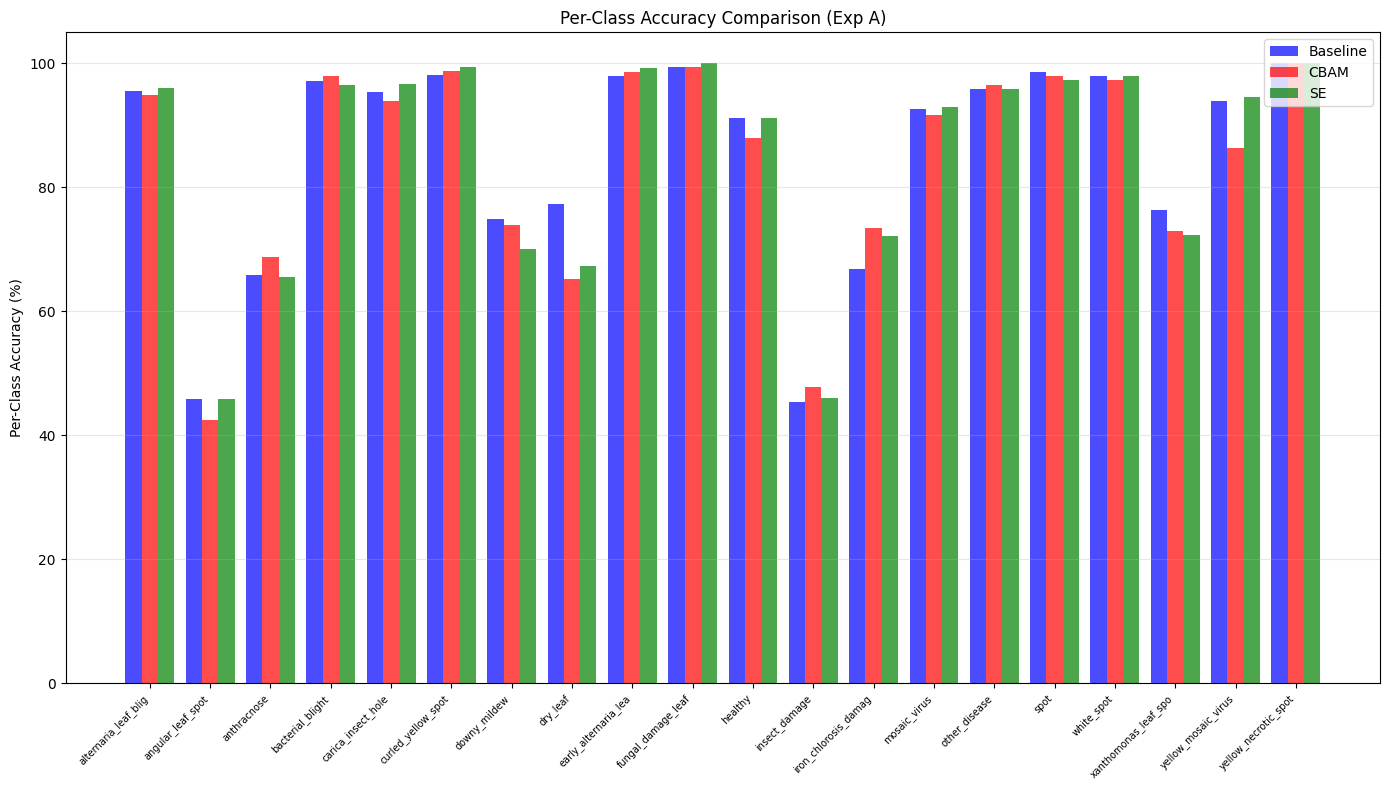

✓ Saved per_class_accuracy.png
Session: 0.6h elapsed / 11.4h remaining


In [40]:
# ============================================================
# BLOCK 14: PER-CLASS ANALYSIS
# ============================================================
print('='*90)
print('PER-CLASS PERFORMANCE (Exp A: Field→Field)')
print('='*90)
print(f'{"Class":<35} {"Base":>8} {"CBAM":>8} {"SE":>8} {"CBAM boost":>12} {"Level":>8}')
print('-'*90)

base_preds = results_A['Baseline']['preds']
cbam_preds = results_A['CBAM']['preds']
se_preds = results_A['SE']['preds']
labels = results_A['Baseline']['labels']

per_class = []
for cls_idx, cls_name in enumerate(UNIFIED_FIELD_CLASSES):
    mask = labels == cls_idx
    if mask.sum() == 0: continue
    base_acc = 100 * (base_preds[mask] == cls_idx).mean()
    cbam_acc = 100 * (cbam_preds[mask] == cls_idx).mean()
    se_acc = 100 * (se_preds[mask] == cls_idx).mean()
    boost = cbam_acc - base_acc
    level = 'HIGH' if abs(boost) >= 15 else 'MEDIUM' if abs(boost) >= 5 else 'LOW'
    per_class.append((cls_name, base_acc, cbam_acc, se_acc, boost, level))
    print(f'{cls_name[:35]:<35} {base_acc:>7.1f}% {cbam_acc:>7.1f}% {se_acc:>7.1f}% {boost:>+11.1f}pp {level:>8}')

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
cls_names = [p[0][:20] for p in per_class]
base_accs = [p[1] for p in per_class]
cbam_accs = [p[2] for p in per_class]
se_accs = [p[3] for p in per_class]
x = np.arange(len(per_class))
w = 0.27
ax.bar(x - w, base_accs, w, label='Baseline', color='blue', alpha=0.7)
ax.bar(x, cbam_accs, w, label='CBAM', color='red', alpha=0.7)
ax.bar(x + w, se_accs, w, label='SE', color='green', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(cls_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Per-Class Accuracy (%)')
ax.set_title('Per-Class Accuracy Comparison (Exp A)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/per_class_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved per_class_accuracy.png')
session_status()

## Block 15 — Confusion Matrices (Normalized + Error-Only)
NEW v15: Row-normalized + error-only (diagonal hidden) variants.

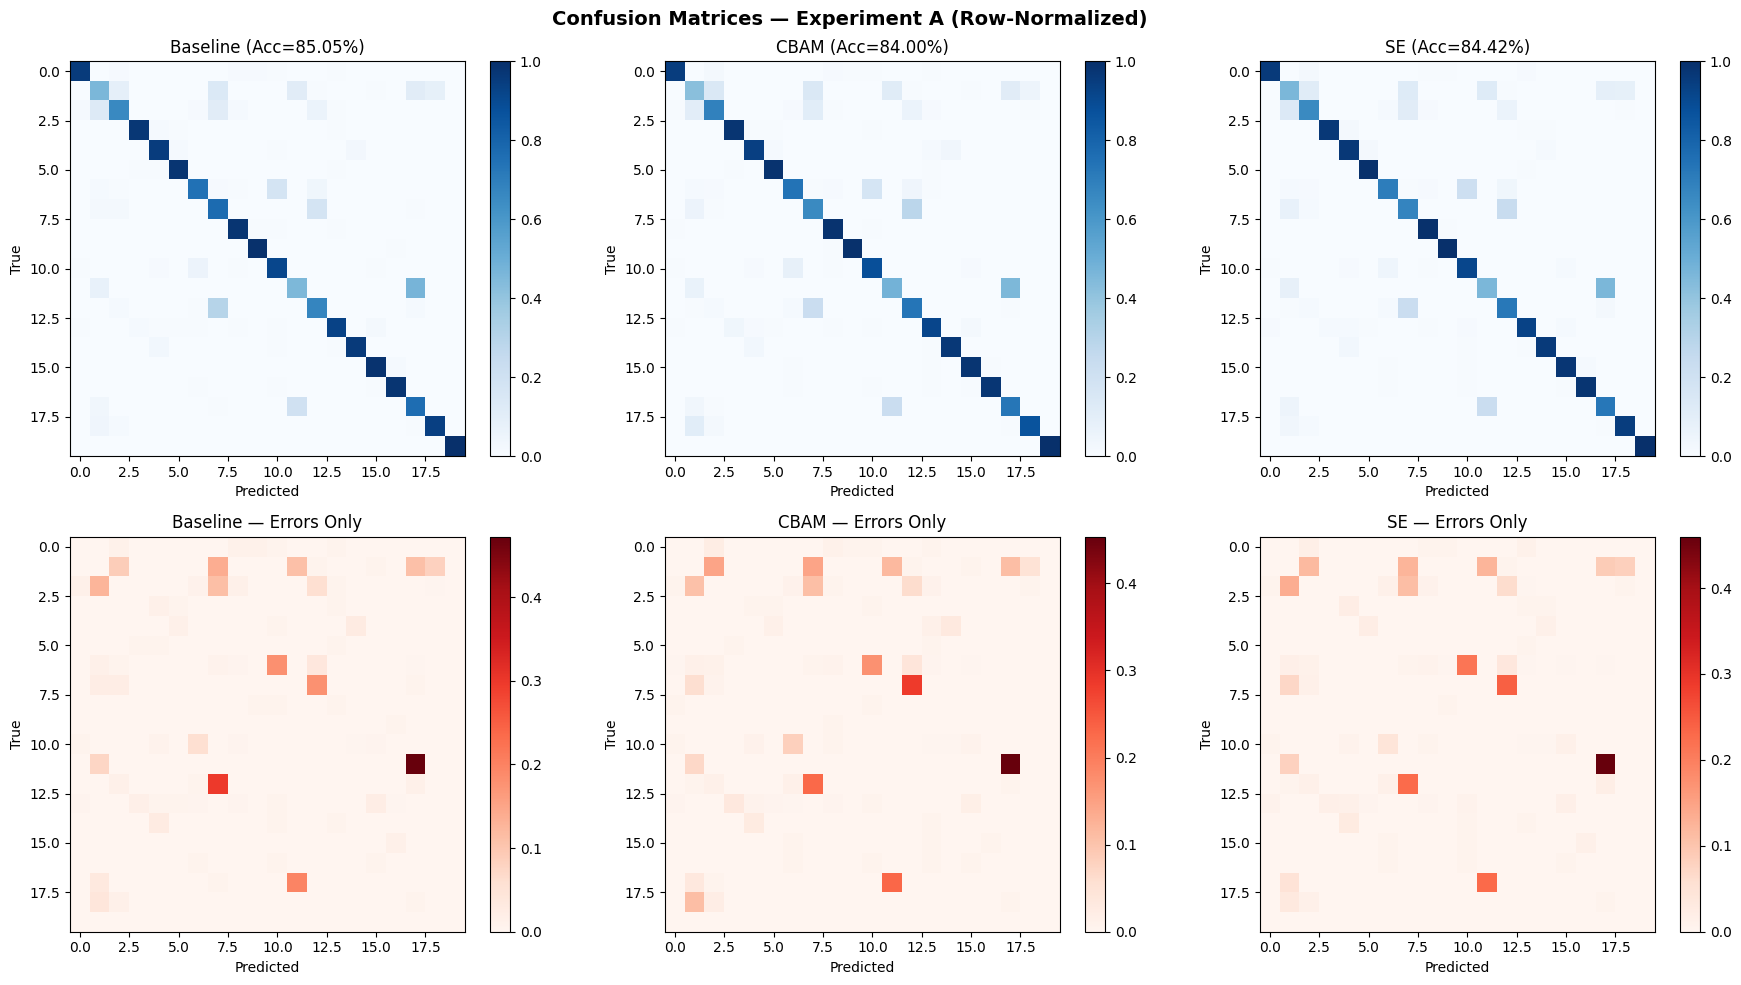

✓ Saved confusion_matrices.png
Session: 0.6h elapsed / 11.4h remaining


In [41]:
# ============================================================
# BLOCK 15: CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices — Experiment A (Row-Normalized)', fontsize=14, fontweight='bold')

for col, (name, res) in enumerate([('Baseline', results_A['Baseline']),
                                    ('CBAM', results_A['CBAM']),
                                    ('SE', results_A['SE'])]):
    cm = confusion_matrix(res['labels'], res['preds'], labels=list(range(CFG.NUM_CLASSES)))  # v21
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    # Row-normalized
    ax = axes[0, col]
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name} (Acc={res["acc"]:.2f}%)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)
    # Error-only
    ax = axes[1, col]
    cm_err = cm_norm.copy()
    np.fill_diagonal(cm_err, 0)
    im = ax.imshow(cm_err, cmap='Reds')
    ax.set_title(f'{name} — Errors Only')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved confusion_matrices.png')
session_status()

## Block 15.5 — Binary Confusion Matrices (Exp C)

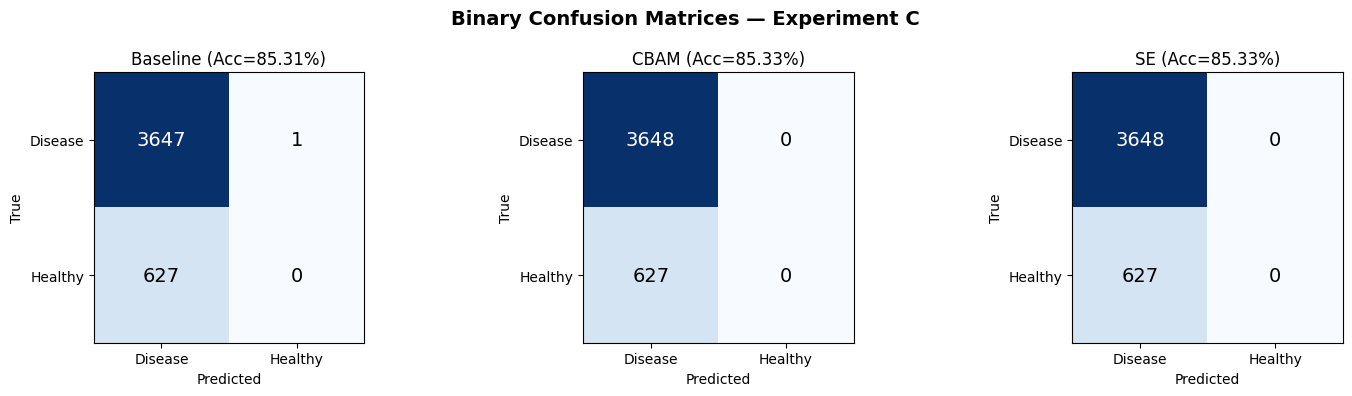

✓ Saved binary_confusion_matrices.png
  Baseline: Disease Acc=100.0%, Healthy Acc=0.0%
  CBAM: Disease Acc=100.0%, Healthy Acc=0.0%
  SE: Disease Acc=100.0%, Healthy Acc=0.0%
Session: 0.6h elapsed / 11.4h remaining


In [42]:
# v21 guard: skip binary confusion matrices if Experiment C was skipped
if not ('results_C' in dir() and results_C):
    print('[SKIP] Block 15.5 binary confusion matrices - Experiment C not available.')
else:
    # ============================================================
    # BLOCK 15.5: BINARY CMS (EXP C)
    # ============================================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Binary Confusion Matrices — Experiment C', fontsize=14, fontweight='bold')

    for col, (name, res) in enumerate([('Baseline', results_C['Baseline']),
                                        ('CBAM', results_C['CBAM']),
                                        ('SE', results_C['SE'])]):
        cm = confusion_matrix(res['labels'], res['preds'], labels=[0, 1])  # v21: force 2x2
        ax = axes[col]
        im = ax.imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Disease', 'Healthy'])
        ax.set_yticklabels(['Disease', 'Healthy'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{name} (Acc={res["acc"]:.2f}%)')

    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/binary_confusion_matrices.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ Saved binary_confusion_matrices.png')
    # Per-class binary accuracy
    for name, res in [('Baseline', results_C['Baseline']), ('CBAM', results_C['CBAM']), ('SE', results_C['SE'])]:
        cm = confusion_matrix(res['labels'], res['preds'], labels=[0, 1])  # v21: force 2x2
        disease_acc = 100 * cm[0, 0] / max(cm[0].sum(), 1)
        healthy_acc = 100 * cm[1, 1] / max(cm[1].sum(), 1)
        print(f'  {name}: Disease Acc={disease_acc:.1f}%, Healthy Acc={healthy_acc:.1f}%')
    session_status()

## Block 16 — Grad-CAM++ + Insertion/Deletion AUC (NEW)
**NEW v15:** Adds quantitative XAI metrics (Insertion/Deletion AUC) to match Singh CBAM 2025's XAI rigor.

GRAD-CAM++ + INSERTION/DELETION AUC


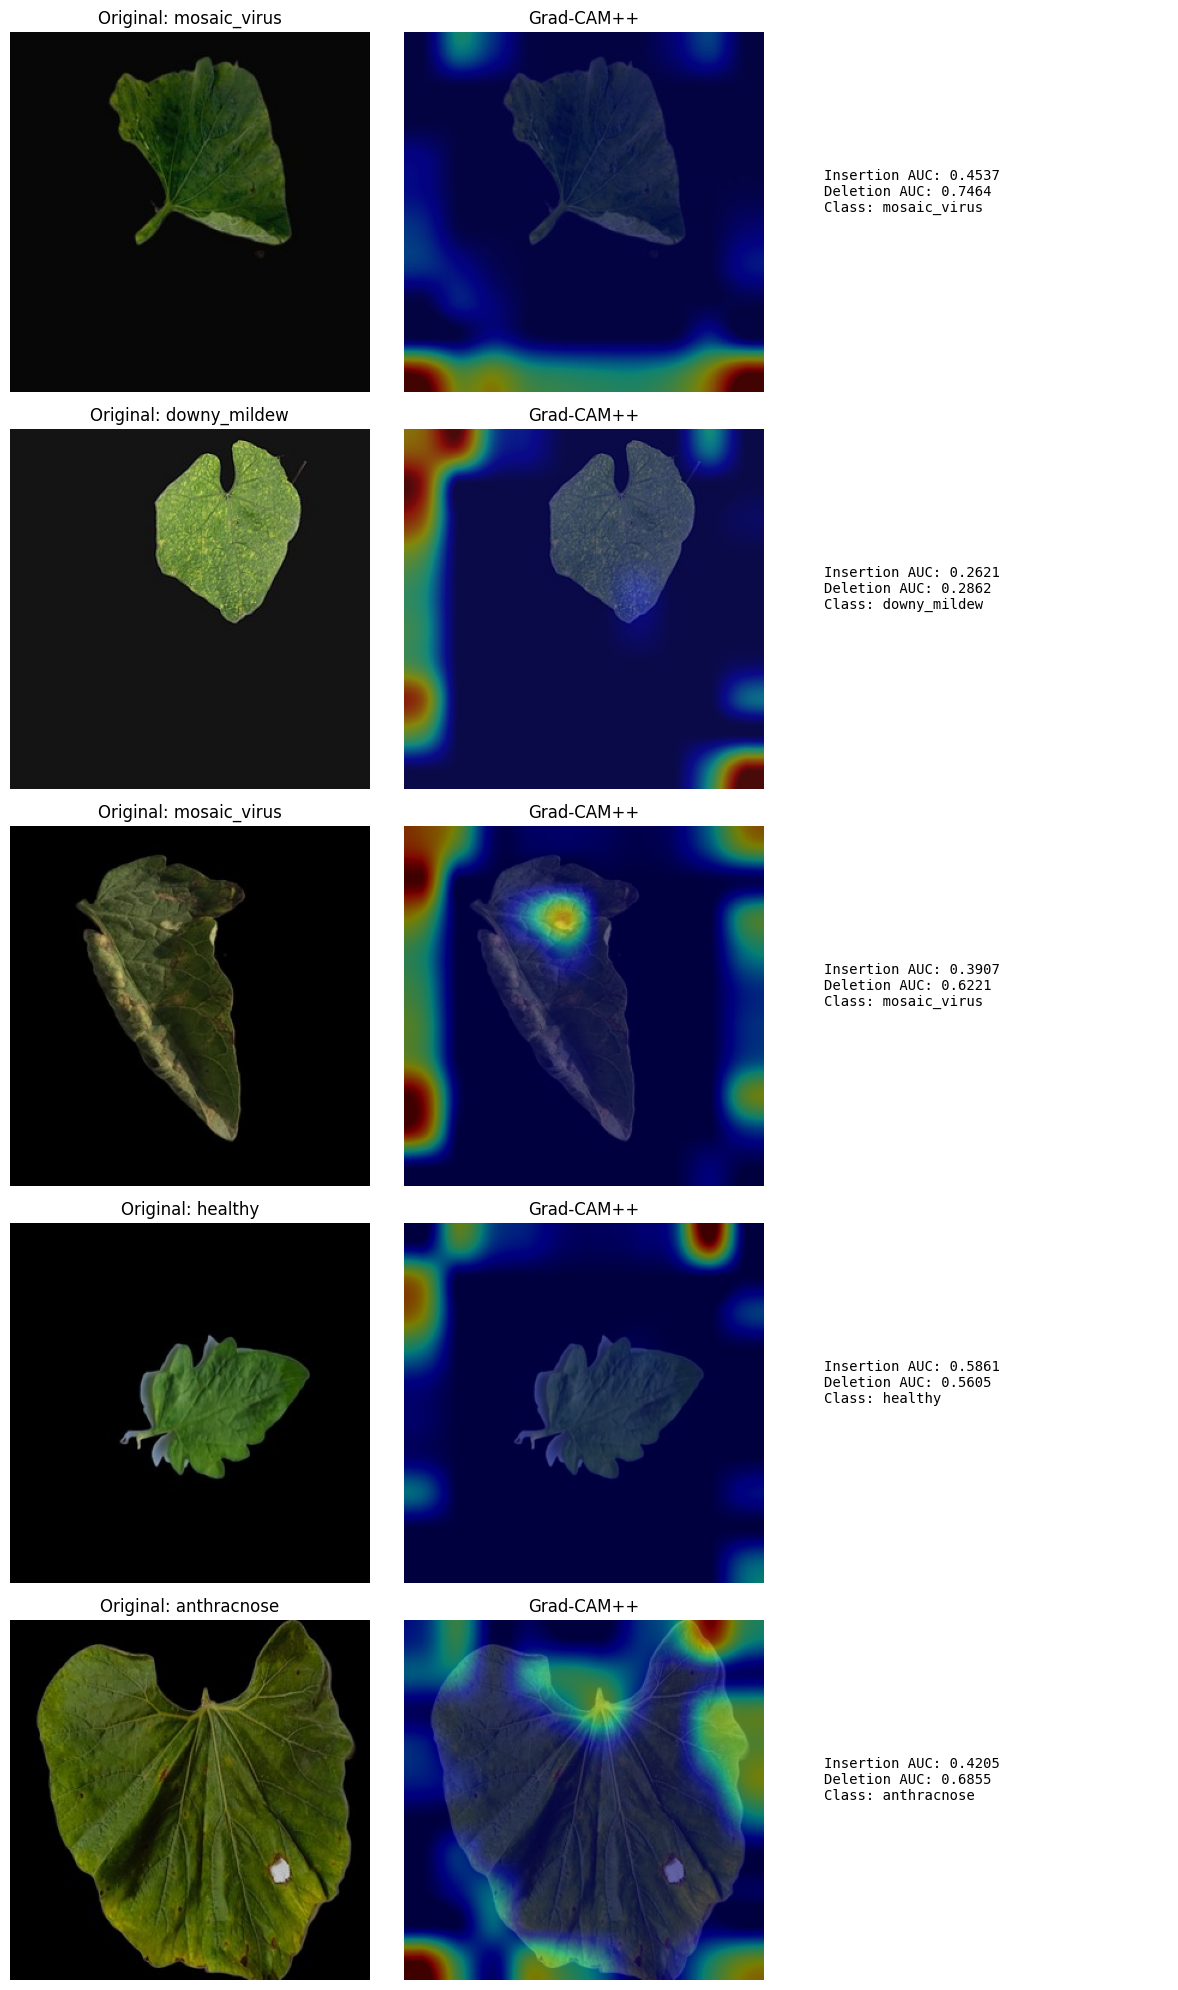


XAI Metrics (Insertion/Deletion AUC):
  mosaic_virus                   Ins=0.4537  Del=0.7464
  downy_mildew                   Ins=0.2621  Del=0.2862
  mosaic_virus                   Ins=0.3907  Del=0.6221
  healthy                        Ins=0.5861  Del=0.5605
  anthracnose                    Ins=0.4205  Del=0.6855

  Mean Insertion AUC: 0.4226 (higher=better)
  Mean Deletion AUC:  0.5801 (lower=better)
Session: 0.6h elapsed / 11.4h remaining


In [43]:
# ============================================================
# BLOCK 16: GRAD-CAM++ + QUANTITATIVE XAI
# ============================================================
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None; self.activations = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)
    def _save_act(self, m, i, o): self.activations = o
    def _save_grad(self, m, gi, go): self.gradients = go[0]
    def __call__(self, x, class_idx=None):
        self.model.eval()
        # v22 FIX: detach BEFORE setting requires_grad. The old line did x.requires_grad_(True)
        # on the CALLER's tensor, so img_tensor kept requires_grad=True after this call and the
        # later img_tensor.cpu().numpy() raised "Can't call numpy() on Tensor that requires grad"
        # on EVERY sample -> insertion/deletion AUC silently became nan. Detaching here keeps the
        # caller's tensor a plain inference tensor.
        x = x.detach().requires_grad_(True)
        out = self.model(x)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        acts = self.activations.detach()
        grads = self.gradients.detach()
        # Grad-CAM++ weights
        alpha_num = grads.pow(2)
        alpha_denom = 2 * grads.pow(2) + (acts * grads.pow(2)).sum(dim=(2, 3), keepdim=True)
        alpha = alpha_num / alpha_denom.clip(min=1e-7)
        weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * acts).sum(dim=1)).squeeze().cpu().numpy()
        # Resize to input
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
        return cam

def insertion_deletion_auc(model, img_tensor, label, cam_mask, steps=20):
    """Insertion/Deletion AUC. Higher insertion = better, lower deletion = better.
    v21 FIX: the old code flattened the (C,H,W) image and indexed it with CAM pixel indices
    (0..H*W-1), but the flattened first axis was the 3 colour channels -> IndexError (caught by
    the caller's try/except, so every sample silently failed and XAI metrics came out nan). We now
    resize the CAM to the image resolution and mask per-pixel across ALL channels.
    v22 FIX: img_tensor is .detach()ed before .numpy() — see GradCAMPlusPlus.__call__ comment.
    v23 FIX: _score now returns the SOFTMAX PROBABILITY of the target class (bounded [0,1]),
    not the raw logit. The previous version returned model(t)[0,label] (a logit), so the AUC
    was computed on unbounded/negative values -> Insertion AUC came out negative (e.g. -1.78)
    and Deletion AUC out of range (-8.55), which is impossible. Using probabilities matches the
    standard protocol (Fong & Vedaldi 2017; Petsiuk et al. 2018; Interpreto), where the curve is
    the class probability as pixels are inserted/deleted and AUC is the area under that curve
    (each curve normalised to x in [0,1], so both AUCs are in [0,1])."""
    img_np = img_tensor.detach().cpu().numpy()                 # (C, H, W)
    C, H, W = img_np.shape
    cam_r = np.array(Image.fromarray((cam_mask * 255).astype(np.uint8)).resize((W, H))) / 255.0
    order = np.argsort(-cam_r.flatten())              # most-important pixels first, length H*W
    blurred = np.full_like(img_np, img_np.mean())
    src_flat = img_np.reshape(C, H * W)
    blur_flat = blurred.reshape(C, H * W)
    ppx = max(1, len(order) // steps)

    def _score(flat_arr):
        arr = flat_arr.reshape(C, H, W)
        with torch.no_grad():
            t = torch.from_numpy(arr).unsqueeze(0).to(DEVICE)
            logits = model(t)
            return torch.softmax(logits, dim=1)[0, label].item()

    ins, dele = [], []
    for step in range(steps + 1):
        k = order[:step * ppx]
        a = blur_flat.copy(); a[:, k] = src_flat[:, k]; ins.append(_score(a))      # reveal top pixels
        b = src_flat.copy();  b[:, k] = blur_flat[:, k]; dele.append(_score(b))    # remove top pixels
    # AUC in [0,1]: x axis spans steps intervals of width 1/steps (total width 1), y is prob in [0,1].
    ins_auc = np.trapz(ins, dx=1 / steps)
    del_auc = np.trapz(dele, dx=1 / steps)
    return ins_auc, del_auc

# Run Grad-CAM++ on 5 random test images
print('='*60)
print('GRAD-CAM++ + INSERTION/DELETION AUC')
print('='*60)

# Use CBAM model
target_layer = cbam_A.features[6][-1]
grad_cam = GradCAMPlusPlus(cbam_A, target_layer)

# v23 FIX: seed the sample selection so the same images are analysed on every re-run.
# Previously random.sample() had no seed, so Grad-CAM/LIME/t-SNE picked different images (and
# LIME's stability score swung 0.53 -> 0.34 between runs). A fixed seed makes the XAI figures
# and metrics reproducible for the thesis.
random.seed(42); np.random.seed(42)

# Pick 5 random test images
n_samples = min(5, len(test_samples))
sample_indices = random.sample(range(len(test_samples)), n_samples)

fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
if n_samples == 1: axes = axes.reshape(1, -1)

xai_metrics = []
for i, idx in enumerate(sample_indices):
    path, label, _ = test_samples[idx]
    try:
        img = Image.open(path).convert('RGB')
        img_tensor = val_tf(img).unsqueeze(0).to(DEVICE)
        # Original image for display
        img_display = np.array(img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE)))

        # Grad-CAM++
        cam = grad_cam(img_tensor, label)
        cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((CFG.IMG_SIZE, CFG.IMG_SIZE))) / 255

        # Insertion/Deletion AUC
        ins, dele = insertion_deletion_auc(cbam_A, img_tensor[0], label, cam)
        xai_metrics.append({'class': UNIFIED_FIELD_CLASSES[label], 'insertion_auc': ins, 'deletion_auc': dele})

        # Plot
        axes[i, 0].imshow(img_display); axes[i, 0].set_title(f'Original: {UNIFIED_FIELD_CLASSES[label][:25]}'); axes[i, 0].axis('off')
        axes[i, 1].imshow(img_display); axes[i, 1].imshow(cam_resized, cmap='jet', alpha=0.5)
        axes[i, 1].set_title(f'Grad-CAM++'); axes[i, 1].axis('off')
        axes[i, 2].text(0.1, 0.5, f'Insertion AUC: {ins:.4f}\nDeletion AUC: {dele:.4f}\nClass: {UNIFIED_FIELD_CLASSES[label][:25]}',
                       fontsize=10, family='monospace')
        axes[i, 2].axis('off')
    except Exception as e:
        print(f'  Error on sample {i}: {e}')

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/gradcam_plusplus.png', dpi=100, bbox_inches='tight')
plt.show()

# Print XAI metrics
print('\nXAI Metrics (Insertion/Deletion AUC):')
for m in xai_metrics:
    print(f"  {m['class'][:30]:<30} Ins={m['insertion_auc']:.4f}  Del={m['deletion_auc']:.4f}")
print(f'\n  Mean Insertion AUC: {np.mean([m["insertion_auc"] for m in xai_metrics]):.4f} (higher=better)')
print(f'  Mean Deletion AUC:  {np.mean([m["deletion_auc"] for m in xai_metrics]):.4f} (lower=better)')
with open(f'{CFG.OUTPUT_DIR}/xai_metrics.json', 'w') as f: json.dump(xai_metrics, f, indent=2)
session_status()

## Block 17 — LIME + Stability Score (NEW)
NEW v15: Runs LIME 3× per image and reports stability score (cosine similarity).

LIME EXPLANATIONS + STABILITY SCORE


100%|██████████| 200/200 [00:02<00:00, 98.20it/s]


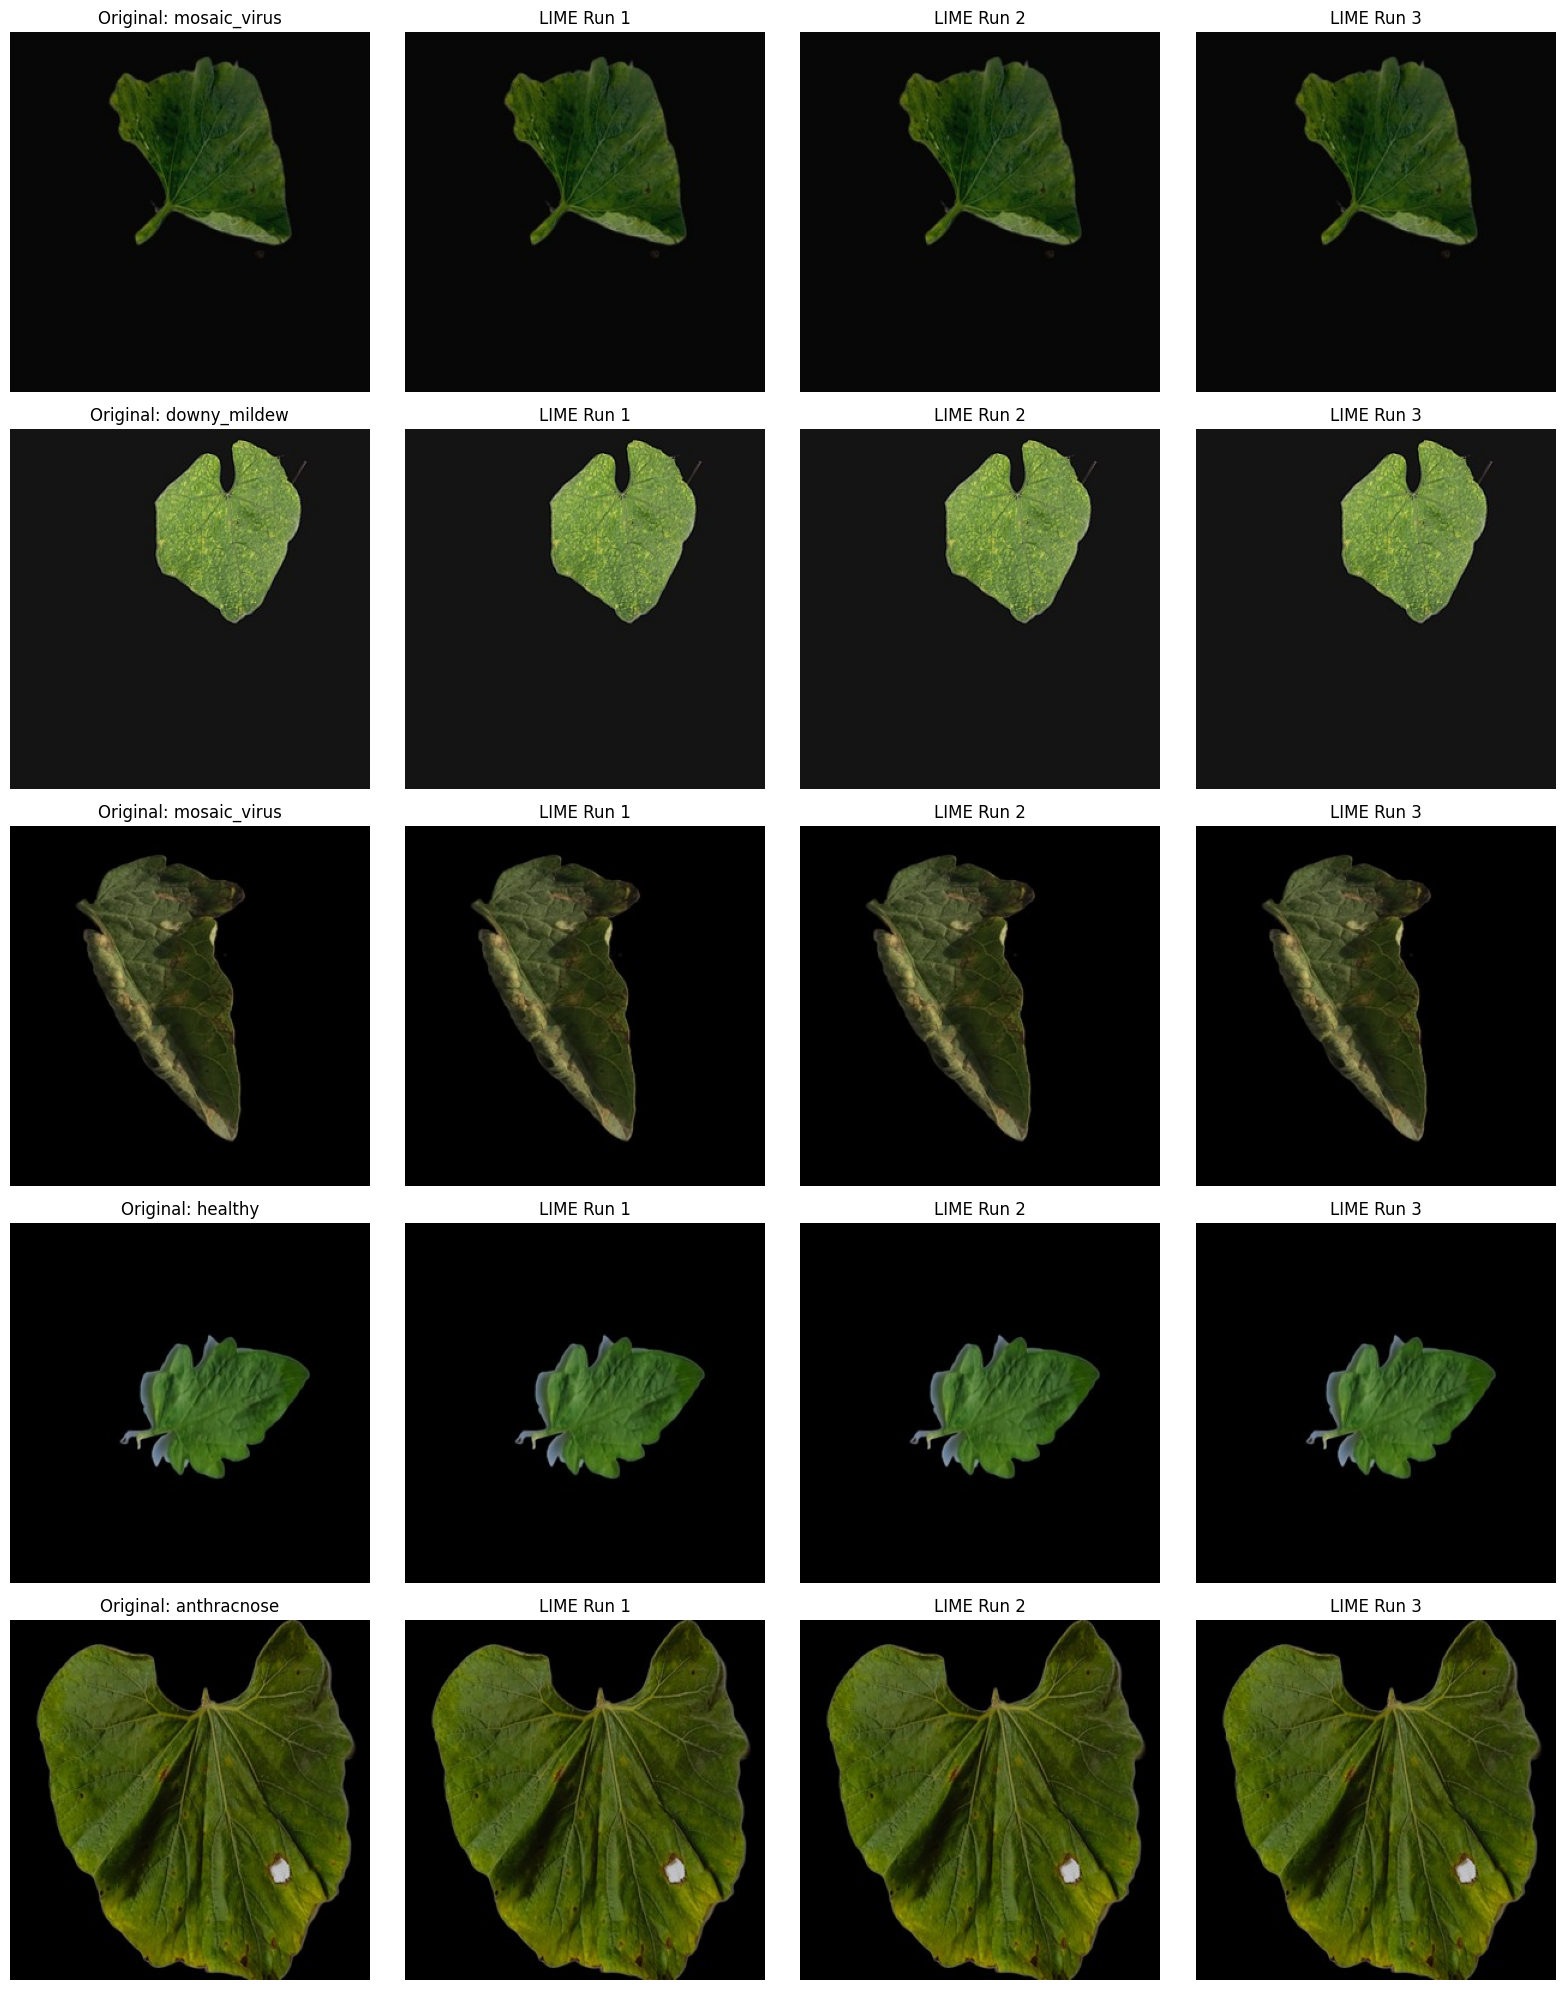


LIME Stability Score: 0.7730 (1.0=perfectly stable, 0=random) — mean over 5 images x C(3,2) run-pairs each (seeded, reproducible)
Session: 0.7h elapsed / 11.3h remaining


In [44]:
# ============================================================
# BLOCK 17: LIME + STABILITY
# ============================================================
if LIME:
    print('='*60)
    print('LIME EXPLANATIONS + STABILITY SCORE')
    print('='*60)

    # v24 FIX: the v23 code passed progress_bar=False unconditionally. The LIME version
    # installed on Kaggle does NOT accept that kwarg (it only exists in newer LIME), so every
    # explain_instance() call raised "unexpected keyword argument 'progress_bar'" and the whole
    # block silently produced no explanations and no stability score. Two version-proof fixes:
    #   1. inspect the real signature and only pass progress_bar if the installed LIME supports it;
    #   2. force LIME's INTERNAL progress bar to text mode (lime.lime_image.tqdm -> tqdm.std) so it
    #      can never emit Jupyter widget JSON regardless of which tqdm the notebook imported.
    # The combination is compatible with BOTH old and new LIME versions.
    import inspect
    import lime.lime_image as _lime_image
    try:
        from tqdm.std import tqdm as _text_tqdm
        _lime_image.tqdm = _text_tqdm
    except Exception:
        pass
    _explain_sig = inspect.signature(_lime_image.LimeImageExplainer.explain_instance)

    # Seed LIME (and sample indices come from Block 16, which is already seeded) so the LIME
    # figures + stability score are reproducible run-to-run. Previously the stability score
    # swung 0.53 -> 0.34 across runs purely because LIME and sample selection were stochastic.
    np.random.seed(42)
    explainer = _lime_image.LimeImageExplainer()

    # v16 FIX: val_tf_batch did not exist anywhere in the notebook - this cell raised
    # NameError the moment it ran. Defines the batch-of-numpy-images -> model-ready-tensor
    # wrapper LIME's classifier_fn needs.
    def val_tf_batch(images):
        """Apply val_tf to a batch of HWC numpy images (LIME's perturbed samples) and
        return softmax class probabilities, as LIME's classifier_fn contract expects."""
        batch = torch.stack([val_tf(Image.fromarray(im)) for im in images]).to(DEVICE)
        with torch.no_grad():
            logits = cbam_A(batch)
            return F.softmax(logits, dim=1).detach().cpu().numpy()

    # v24 FIX: n_images must match the number of samples actually selected in Block 16
    # (5). The old hardcoded n_images=8 looped past len(sample_indices), silently doing
    # nothing for 3 of the 8 rows and leaving empty axes in the saved figure.
    n_images = min(5, len(sample_indices))
    n_runs = 3
    fig, axes = plt.subplots(n_images, n_runs + 1, figsize=(4*(n_runs+1), 4*n_images))
    if n_images == 1: axes = axes.reshape(1, -1)

    stability_scores = []
    for img_i in range(n_images):
        idx = sample_indices[img_i]
        path, label, _ = test_samples[idx]
        try:
            img = Image.open(path).convert('RGB').resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
            img_np = np.array(img)

            axes[img_i, 0].imshow(img_np)
            axes[img_i, 0].set_title(f'Original: {UNIFIED_FIELD_CLASSES[label][:20]}')
            axes[img_i, 0].axis('off')

            runs = []
            for run_i in range(n_runs):
                # v25 FIX: explain the TRUE label explicitly (labels=[label], top_labels=None).
                # The v24 code used top_labels=1, which only explains the model's top-1 PREDICTED
                # class. For a misclassified image the true label is not that class, so
                # get_image_and_mask(label) raised "Label not in explanation" and the image was
                # silently skipped (5 images -> only 4 scored). Explaining the true label is also
                # the right thing for a thesis: it shows WHY the model did/didn't pick the true class.
                lime_kwargs = dict(labels=[label], top_labels=None, hide_color=0,
                                   num_samples=200, random_seed=42)
                if 'progress_bar' in _explain_sig.parameters:
                    lime_kwargs['progress_bar'] = False
                exp = explainer.explain_instance(img_np, val_tf_batch, **lime_kwargs)
                temp, mask = exp.get_image_and_mask(label, positive_only=True, num_features=5, hide_rest=False)
                runs.append(mask)
                axes[img_i, run_i+1].imshow(temp)
                axes[img_i, run_i+1].set_title(f'LIME Run {run_i+1}')
                axes[img_i, run_i+1].axis('off')

            # v16 FIX: stability now averages over ALL pairwise comparisons among the
            # n_runs masks (was hardcoded to only compare run[0] vs run[1], silently
            # discarding run[2]'s contribution to the score despite paying for it).
            if len(runs) >= 2:
                pair_sims = []
                for r1 in range(len(runs)):
                    for r2 in range(r1 + 1, len(runs)):
                        a = runs[r1].flatten().astype(float)
                        b = runs[r2].flatten().astype(float)
                        pair_sims.append(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-7))
                stability_scores.append(np.mean(pair_sims))
        except Exception as e:
            print(f'  LIME error on image {img_i}: {e}')

    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/lime_explanation.png', dpi=100, bbox_inches='tight')
    plt.show()
    if stability_scores:
        print(f'\nLIME Stability Score: {np.mean(stability_scores):.4f} (1.0=perfectly stable, 0=random) — '
              f'mean over {len(stability_scores)} images x C({n_runs},2) run-pairs each (seeded, reproducible)')
else:
    print('LIME not installed. Skipping.')
session_status()

## Block 18 — CBAM Attention Maps + t-SNE/UMAP + CBAM vs SE Comparison (NEW)
NEW v15: Adds t-SNE embeddings (matches Singh CBAM 2025) + CBAM vs SE attention difference map.

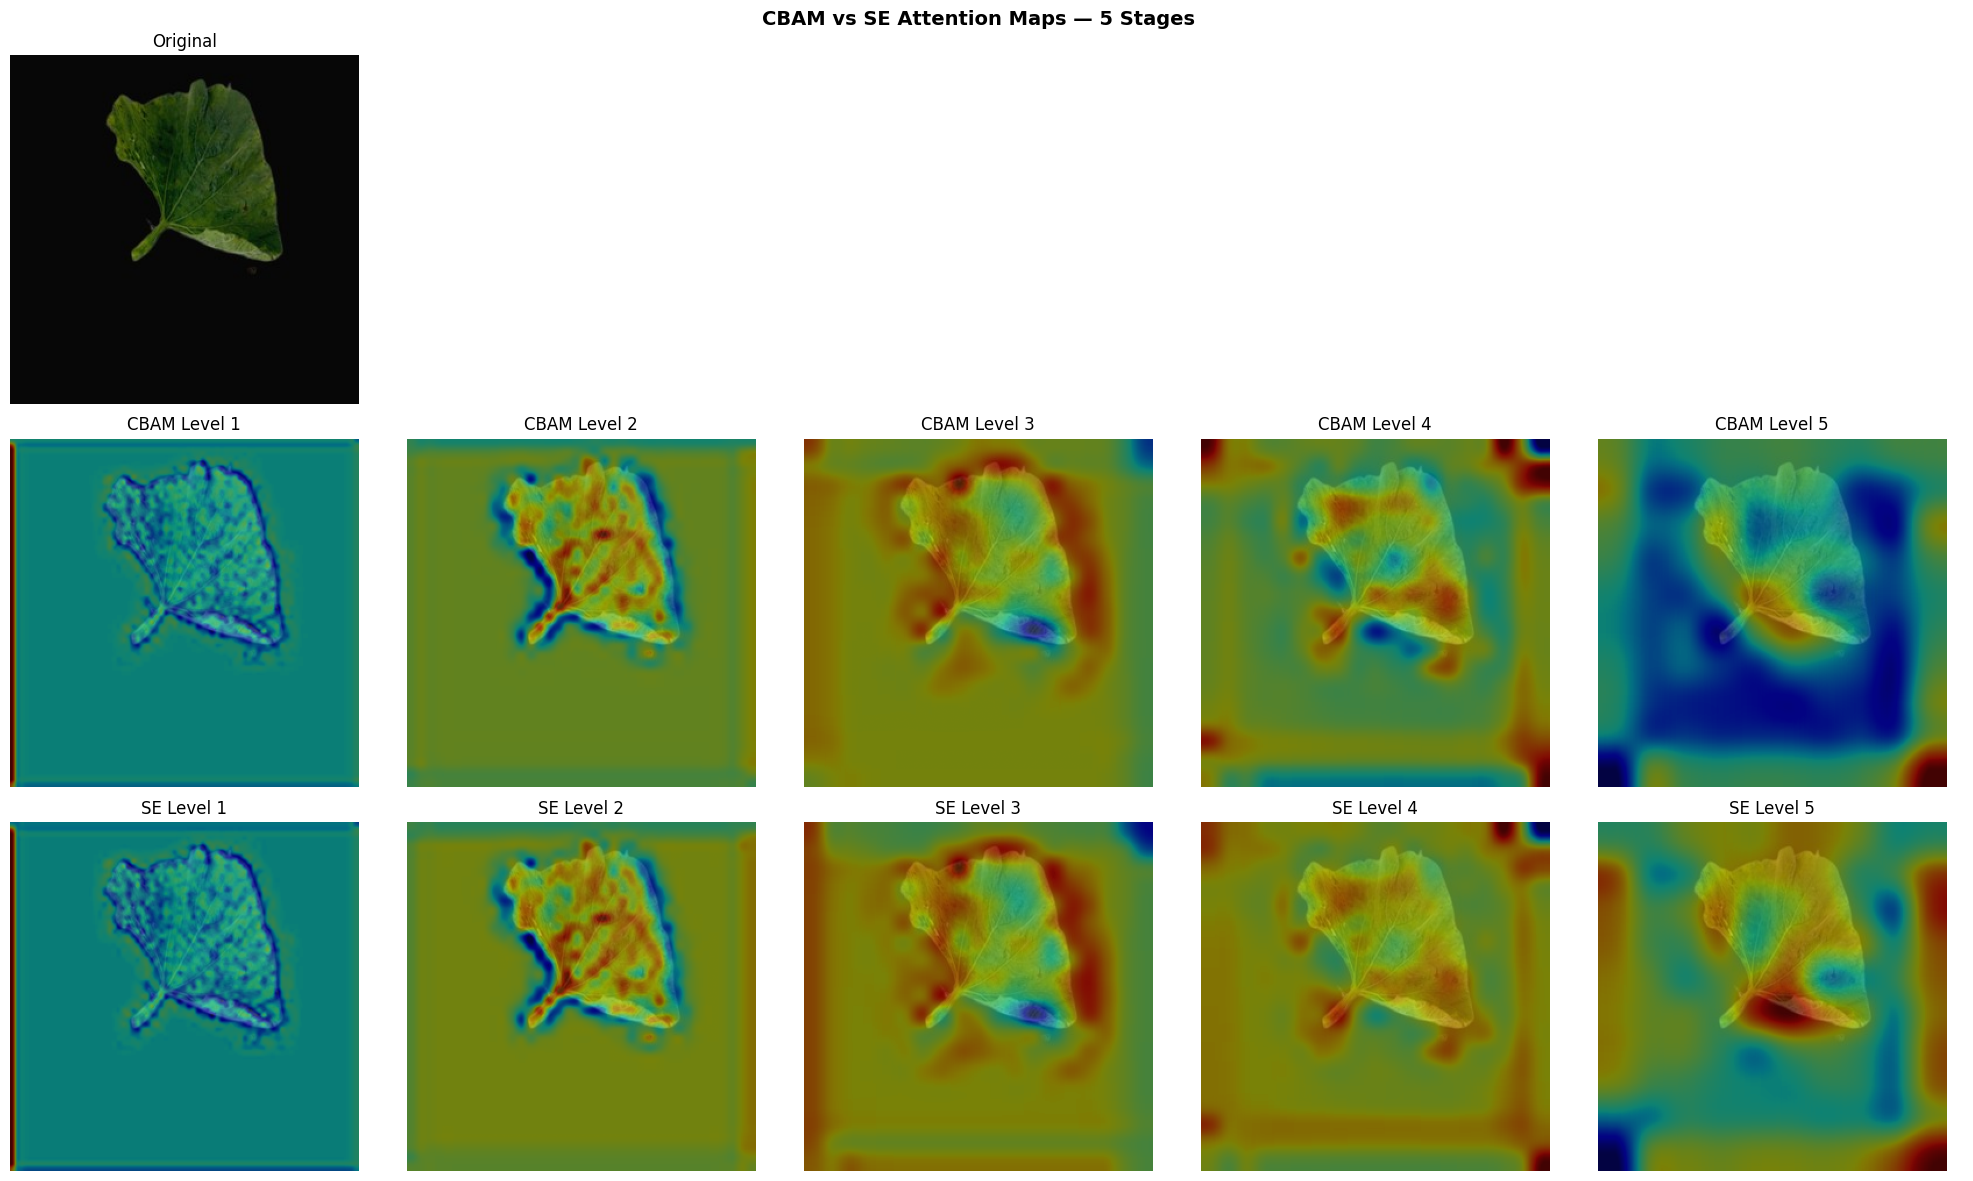

✓ Saved cbam_se_attention_maps.png

t-SNE EMBEDDINGS (CBAM Features)


Extracting features: 100%|██████████| 500/500 [00:09<00:00, 52.58it/s]


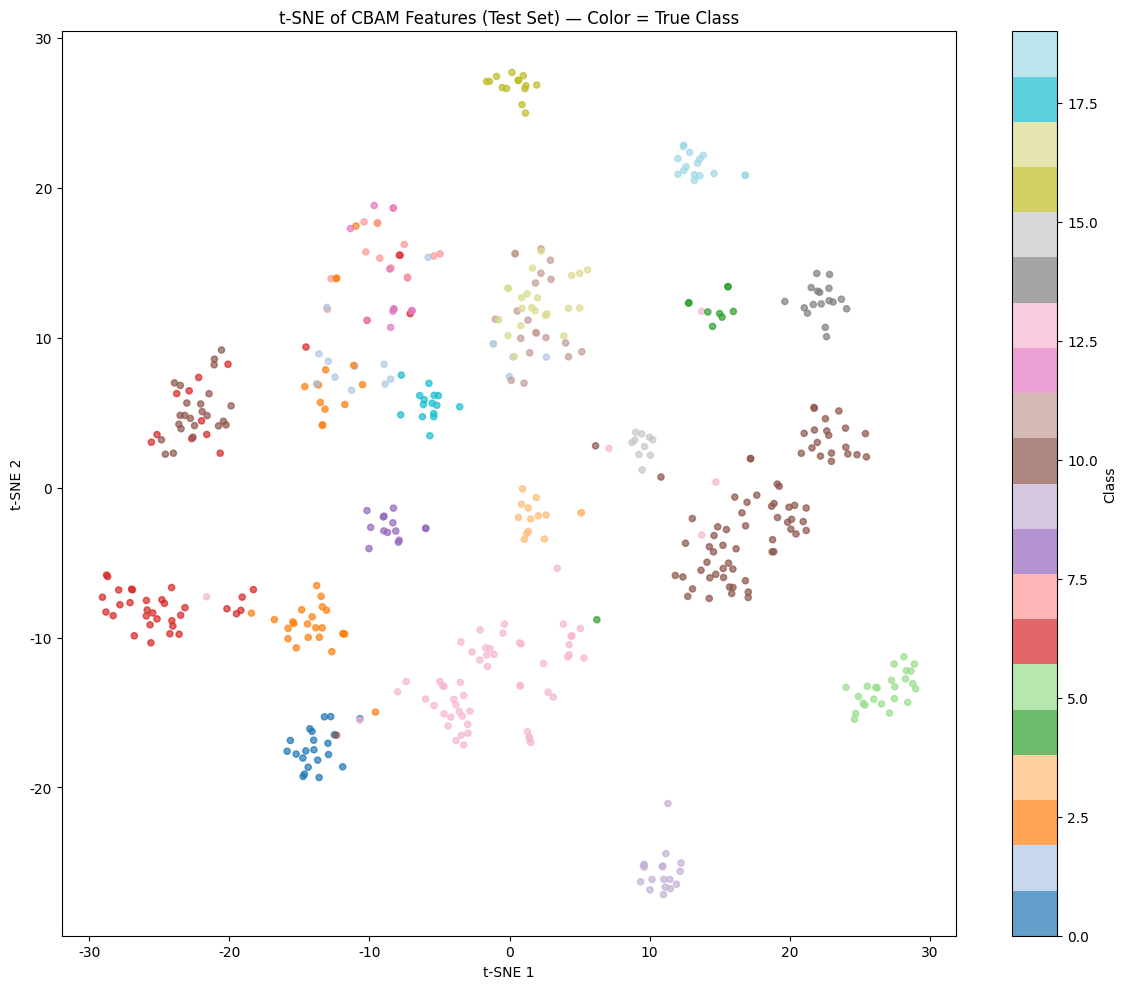

✓ Saved tsne_embeddings.png
Session: 0.7h elapsed / 11.3h remaining


In [45]:
# ============================================================
# BLOCK 18: CBAM ATTENTION + t-SNE + CBAM vs SE
# ============================================================
# Extract CBAM attention maps from 5 stages
def extract_cbam_attention(model, img_tensor):
    """Extract attention maps from all 5 CBAM blocks."""
    attentions = []
    hooks = []
    def hook_fn(m, i, o):
        # CBAM is added as a submodule; we want the output before/after CBAM
        pass

    # Use forward hook on each CBAM module
    cbam_modules = [m for m in model.features.modules() if isinstance(m, CBAM)]
    for cbam in cbam_modules:
        # Register hook on the SpatialAttention output
        h = cbam.sa.register_forward_hook(lambda mod, inp, out: attentions.append(out.mean(dim=1, keepdim=True)))
        hooks.append(h)

    with torch.no_grad():
        _ = model(img_tensor)

    for h in hooks: h.remove()
    return attentions

# Run on one image
if len(sample_indices) > 0:
    idx = sample_indices[0]
    path, label, _ = test_samples[idx]
    img = Image.open(path).convert('RGB')
    img_tensor = val_tf(img).unsqueeze(0).to(DEVICE)

    cbam_attentions = extract_cbam_attention(cbam_A, img_tensor)
    se_attentions = []
    se_cbam_modules = [m for m in se_A.features.modules() if isinstance(m, SEBlock)]
    hooks = []
    def make_hook(storage):
        def hook(m, i, o): storage.append(o.mean(dim=1, keepdim=True))
        return hook
    for se in se_cbam_modules:
        h = se.register_forward_hook(make_hook(se_attentions))
        hooks.append(h)
    with torch.no_grad(): _ = se_A(img_tensor)
    for h in hooks: h.remove()

    # Plot
    n_levels = max(len(cbam_attentions), 5)
    fig, axes = plt.subplots(3, n_levels, figsize=(4*n_levels, 12))
    if n_levels == 1: axes = axes.reshape(-1, 1)

    img_display = np.array(img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE)))
    axes[0, 0].imshow(img_display); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')
    for j in range(1, n_levels): axes[0, j].axis('off')

    for j in range(min(n_levels, len(cbam_attentions))):
        att = cbam_attentions[j].squeeze().cpu().numpy()
        att = (att - att.min()) / (att.max() - att.min() + 1e-7)
        att_resized = np.array(Image.fromarray((att * 255).astype(np.uint8)).resize((CFG.IMG_SIZE, CFG.IMG_SIZE))) / 255
        axes[1, j].imshow(img_display); axes[1, j].imshow(att_resized, cmap='jet', alpha=0.5)
        axes[1, j].set_title(f'CBAM Level {j+1}'); axes[1, j].axis('off')

    for j in range(min(n_levels, len(se_attentions))):
        att = se_attentions[j].squeeze().cpu().numpy()
        att = (att - att.min()) / (att.max() - att.min() + 1e-7)
        att_resized = np.array(Image.fromarray((att * 255).astype(np.uint8)).resize((CFG.IMG_SIZE, CFG.IMG_SIZE))) / 255
        axes[2, j].imshow(img_display); axes[2, j].imshow(att_resized, cmap='jet', alpha=0.5)
        axes[2, j].set_title(f'SE Level {j+1}'); axes[2, j].axis('off')

    plt.suptitle('CBAM vs SE Attention Maps — 5 Stages', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/cbam_se_attention_maps.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ Saved cbam_se_attention_maps.png')

# ---- t-SNE Embeddings ----
print('\n' + '='*60)
print('t-SNE EMBEDDINGS (CBAM Features)')
print('='*60)

# Extract features for 500 test samples
# v24 FIX: seed the index sampling so the same 500 test samples feed t-SNE on every re-run
# (matches the seeding already applied to Grad-CAM/LIME sample selection in Block 16).
random.seed(42); np.random.seed(42)
n_tsne = min(500, len(test_samples))
tsne_indices = random.sample(range(len(test_samples)), n_tsne)
features = []; tsne_labels = []

cbam_A.eval()
with torch.no_grad():
    for idx in tqdm(tsne_indices, desc='Extracting features'):
        path, label, _ = test_samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            img_tensor = val_tf(img).unsqueeze(0).to(DEVICE)
            feat = cbam_A.features(img_tensor)
            feat = cbam_A.avgpool(feat).flatten(1).cpu().numpy()
            features.append(feat[0])
            tsne_labels.append(label)
        except: continue

features = np.array(features)
tsne_labels = np.array(tsne_labels)

if len(features) > 10:
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(features)-1))
    embeddings = tsne.fit_transform(features)

    fig, ax = plt.subplots(figsize=(12, 10))
    scatter = ax.scatter(embeddings[:, 0], embeddings[:, 1], c=tsne_labels,
                         cmap='tab20', s=20, alpha=0.7)
    plt.colorbar(scatter, label='Class')
    ax.set_title('t-SNE of CBAM Features (Test Set) — Color = True Class')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/tsne_embeddings.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ Saved tsne_embeddings.png')
session_status()

## Block 19 — Classification Reports (All Models + Experiments)

In [46]:
# ============================================================
# BLOCK 19: CLASSIFICATION REPORTS
# ============================================================
print('='*60)
print('CLASSIFICATION REPORTS')
print('='*60)
for exp_name, results in [('A', results_A), ('B', results_B)]:
    for model_name, r in results.items():
        print(f'\n--- Exp {exp_name}: {model_name} ---')
        # v21 FIX: pass explicit labels so the label set always matches the 20 target_names
        # (else classification_report raises ValueError if any class is absent from a split).
        print(classification_report(r['labels'], r['preds'],
                                    labels=list(range(CFG.NUM_CLASSES)),
                                    target_names=UNIFIED_FIELD_CLASSES, digits=3, zero_division=0))
session_status()

CLASSIFICATION REPORTS

--- Exp A: Baseline ---
                              precision    recall  f1-score   support

      alternaria_leaf_blight      0.944     0.955     0.949       177
           angular_leaf_spot      0.486     0.459     0.472       146
                 anthracnose      0.890     0.658     0.757       307
            bacterial_blight      0.946     0.972     0.959       144
          carica_insect_hole      0.904     0.953     0.928       149
          curled_yellow_spot      0.962     0.980     0.971       153
                downy_mildew      0.888     0.748     0.812       457
                    dry_leaf      0.507     0.773     0.612       141
early_alternaria_leaf_blight      0.914     0.979     0.946       142
          fungal_damage_leaf      0.983     0.994     0.988       171
                     healthy      0.864     0.912     0.888       627
               insect_damage      0.619     0.453     0.523       161
       iron_chlorosis_damage      0.628  

---
# BLOCK 23 — FINISH THE THESIS (self-contained)

**You do not need to touch anything above this line.** Everything you already ran keeps its
results. This section trains what is missing, computes what was never computed, and tidies the
checkpoint folder for you.

Run the cells in order, top to bottom.

| Cell | What it does | Time |
|---|---|---|
| 23.0 | Loads guards + correct statistics | instant |
| 23.0b | **Trains whatever is missing** (the attention-free control seeds) | ~8 h |
| 23.0c | Audits that every arm was trained under the same protocol | instant |
| 23.1 | Scores every checkpoint on the **test set** | ~10 min |
| 23.1b | Checks whether the unused EMA/SWA weights beat them | ~5 min |
| 23.2 | The final ablation table + proper significance tests | instant |
| 23.2b | Threshold calibration — why CCMT accuracy looked bad | ~10 min |
| 23.3 | Tests whether the Grad-CAM maps are actually faithful | ~15 min |
| 23.4 | Finishes distillation, INT8 and ONNX (resumable) | ~2 h |
| 23.5 | Clean results table, Experiment C guarded out | instant |
| 23.9 | Summary, claim audit, **and files itself into folders** | instant |

**If Kaggle kills the session**, just re-run the cell you were on. 23.0b and 23.4 both resume
from the last completed epoch instead of starting over.

In [47]:
# =====================================================================
# 23.0  GUARDS + CORRECT STATISTICS
# =====================================================================
# Three things Block 12 got wrong and this fixes:
#   1. It PRINTED "*** DEGENERATE ***" and then put the number in the table
#      anyway. assert_reportable() raises instead, so it cannot happen.
#   2. Block 21.6 hardcoded the significance threshold as 2.776. That is the
#      value for 5 seeds. You ran 3, where the correct value is 4.303, so the
#      old test would call a null result significant.
#   3. Bootstrap was run on each model separately. That cannot answer "is A
#      better than B" - the resampling has to be paired on the same test items.
import numpy as np, json, os, gc, torch
from scipy import stats as _st

class ResultInvalid(Exception): pass


def assert_reportable(name, preds, labels, n_classes):
    preds, labels = np.asarray(preds), np.asarray(labels)
    acc = float((preds == labels).mean() * 100)
    _, cnt = np.unique(labels, return_counts=True)
    majority = float(cnt.max() / len(labels) * 100)
    if len(np.unique(preds)) == 1:
        raise ResultInvalid(f'{name}: predicts ONE class for all {len(preds)} samples '
                            f'(acc {acc:.2f}% == majority {majority:.2f}%). Not a classifier.')
    if acc <= majority:
        raise ResultInvalid(f'{name}: acc {acc:.2f}% does not beat majority {majority:.2f}%.')
    if acc < 100.0 / n_classes:
        raise ResultInvalid(f'{name}: acc {acc:.2f}% is below chance. Checkpoint is corrupt.')
    return acc, majority


def paired_delta_stats(a, b, alpha=0.05):
    """Paired over seeds. Refuses to infer below n=3 and takes t_crit from scipy."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = a - b; n = len(d)
    out = {'n': n, 'mean': float(d.mean()),
           'sd': float(d.std(ddof=1)) if n > 1 else float('nan')}
    if n < 3:
        out.update(usable=False, p=None,
                   note=f'n={n} seeds - report the per-seed values, make no claim')
        return out
    se = out['sd'] / np.sqrt(n) if out['sd'] > 0 else 0
    t = out['mean'] / se if se > 0 else np.nan
    df = n - 1
    tc = float(_st.t.ppf(1 - alpha / 2, df))
    p = float(2 * (1 - _st.t.cdf(abs(t), df))) if np.isfinite(t) else np.nan
    out.update(usable=True, t=float(t), df=df, t_crit=tc, p=p,
               ci=(out['mean'] - tc * se, out['mean'] + tc * se),
               dz=float(out['mean'] / out['sd']) if out['sd'] > 0 else np.nan,
               sig=bool(np.isfinite(p) and p < alpha), note='')
    return out


def mcnemar_exact(pa, pb, labels):
    """Exact binomial. Returns p=1.0 for identical models, never p=0."""
    ao = np.asarray(pa) == np.asarray(labels); bo = np.asarray(pb) == np.asarray(labels)
    b = int((ao & ~bo).sum()); c = int((~ao & bo).sum())
    if b + c == 0: return b, c, 1.0
    return b, c, float(_st.binomtest(b, b + c, 0.5).pvalue)


def holm(pvals, alpha=0.05):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for r, i in enumerate(order):
        run = max(run, (m - r) * p[i]); adj[i] = min(run, 1.0)
    return adj <= alpha, adj


def bootstrap_delta_ci(ca, cb, n_boot=10000, alpha=0.05, seed=0):
    """PAIRED bootstrap on the difference - resamples the shared test items."""
    rng = np.random.default_rng(seed)
    ca, cb = np.asarray(ca, float), np.asarray(cb, float)
    idx = rng.integers(0, len(ca), size=(n_boot, len(ca)))
    d = ca[idx].mean(1) - cb[idx].mean(1)
    lo, hi = np.percentile(d, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float((ca.mean() - cb.mean()) * 100), float(lo * 100), float(hi * 100)


def set_deterministic(seed):
    """Needed for the NoAttn seeds you are about to train. cudnn.benchmark=True
    (set in Block 1) means two runs with the same seed can differ."""
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ---------------------------------------------------------------------------
# QUARANTINE: Baseline_Field_best.pth is corrupt AGAIN in this run (history says
# 83.98%, weights measure 32.71%). Block 11.9 detects it - but it runs AFTER
# Block 8 has already loaded the bad weights into memory, so Block 12 scored it
# at 6.67% and Block 12.9 printed "built-in SE contribution = -76.98 pp".
# BOTH OF THOSE TABLES ARE INVALID. Block 23 is immune because 23.1 rebuilds
# every arm from the *_seed*_best_best.pth files, which all pass their check.
#
# Root cause: the bad file lives in your Kaggle DATASET, so Block 1.5 restores
# it every session and the purge never sticks. Delete it from the dataset too.
def quarantine_corrupt(verbose=True):
    import shutil
    q = f'{CFG.CKPT_DIR}/_corrupt'; os.makedirs(q, exist_ok=True)
    moved = []
    for f in sorted(os.listdir(CFG.CKPT_DIR)):
        if not f.endswith('_best.pth'): continue
        stem = f[:-len('_best.pth')]
        hp = f'{CFG.CKPT_DIR}/{stem}_best_history.json'
        if not os.path.exists(hp): continue
        try: rec = json.load(open(hp)).get('best_acc')
        except Exception: continue
        if rec is None: continue
        try:
            sd = torch_load_compat(f'{CFG.CKPT_DIR}/{f}', map_location='cpu')
            n_bad = sum(1 for v in sd.values() if torch.is_tensor(v)
                        and not torch.isfinite(v).all())
        except Exception:
            n_bad = -1
        if n_bad != 0:
            for ext in ('_best.pth', '_best_history.json', '_ema.pth', '_swa.pth'):
                p = f'{CFG.CKPT_DIR}/{stem}{ext}'
                if os.path.exists(p): shutil.move(p, f'{q}/{stem}{ext}')
            moved.append(stem)
    if verbose:
        if moved:
            print(f'  QUARANTINED {len(moved)} unloadable checkpoint(s) -> {q}')
            for m_ in moved: print(f'     {m_}')
        else:
            print('  no structurally broken checkpoints found')
        print('  NOTE: Block 12 and Block 12.9 tables in this notebook are INVALID')
        print('        (a checkpoint disagreed with its own history). Use 23.2 -')
        print('        rebuilds every arm from the verified per-seed checkpoints.')
    return moved

quarantine_corrupt()

LEDGER23 = {}
print('  23.0 ready: guards raise, thresholds come from scipy, bootstrap is paired.')
print(f'  t_crit for your 3 seeds = {_st.t.ppf(0.975, 2):.3f}  (Block 21.6 hardcoded 2.776)')

  no structurally broken checkpoints found
  NOTE: Block 12 and Block 12.9 tables in this notebook are INVALID
        (a checkpoint disagreed with its own history). Use 23.2 -
        rebuilds every arm from the verified per-seed checkpoints.
  23.0 ready: guards raise, thresholds come from scipy, bootstrap is paired.
  t_crit for your 3 seeds = 4.303  (Block 21.6 hardcoded 2.776)


In [48]:
# =====================================================================
# 23.0b  TRAIN WHATEVER IS MISSING  (auto — nothing to edit)
# =====================================================================
# Checks all four arms x all seeds and trains only what is absent. Anything
# already on disk is skipped. train_model() writes a resume file every epoch,
# so if the Kaggle session dies you re-run this cell and it continues from the
# last completed epoch rather than starting over.
import os, gc, torch

ARM_BUILD = {
    'Baseline': dict(attention='none', strip_se=False, tmpl='{a}_Field_seed{s}_best'),
    'CBAM':     dict(attention='cbam', strip_se=False, tmpl='{a}_Field_seed{s}_best'),
    'SE':       dict(attention='se',   strip_se=False, tmpl='{a}_Field_seed{s}_best'),
    'NoAttn':   dict(attention='none', strip_se=True,  tmpl='NoAttn_Field_seed{s}'),
}

def _ckpt_name(arm, seed):
    return ARM_BUILD[arm]['tmpl'].format(a=arm, s=seed)

todo = []
for arm in ['NoAttn', 'Baseline', 'SE', 'CBAM']:
    for sd in CFG.SEEDS:
        nm = _ckpt_name(arm, sd)
        # v4: was os.path.exists({nm}_best.pth). That file appears on the
        # first improving epoch, so a run killed at epoch 3 of 60 dropped out
        # of `todo` and was never finished - it just sat there looking done.
        # work_is_done reads the completion marker, written last.
        if not work_is_done(nm):
            todo.append((arm, sd, nm))

print('=' * 70)
if not todo:
    print('  Nothing to train - all 4 arms x %d seeds are already on disk.' % len(CFG.SEEDS))
else:
    print(f'  {len(todo)} run(s) missing, roughly {len(todo) * 4.3:.0f} GPU-hours:')
    for a, s, n in todo:
        note = '   <- the attention-free control; your headline needs it' if a == 'NoAttn' else ''
        print(f'     {a:<9} seed {s}{note}')
print('=' * 70)

MAX_RUNS_THIS_SESSION = 2      # Kaggle allows ~12 h; 2 runs fits with room to spare

for k, (arm, sd, nm) in enumerate(todo):
    if k >= MAX_RUNS_THIS_SESSION:
        print(f'\n  Stopping after {MAX_RUNS_THIS_SESSION} runs to stay inside the session limit.')
        print(f'  {len(todo) - k} run(s) left - start a new session and re-run this cell.')
        break
    print(f'\n--- training {nm}  ({arm}, seed {sd}) ---')
    set_deterministic(sd)
    kw = ARM_BUILD[arm]
    m = build_efficientnet(CFG.NUM_CLASSES, attention=kw['attention'],
                           reduction=CFG.CBAM_REDUCTION, backbone=CFG.BACKBONE,
                           strip_se=kw['strip_se']).to(DEVICE)
    if kw['strip_se']:
        assert count_builtin_se(m) == 0, 'strip_se failed - not an attention-free control'
    print(f'    params {sum(p.numel() for p in m.parameters()):,} | built-in SE {count_builtin_se(m)}')
    # use_swa=False to match Block 12.6, which trained the other 9 seed models
    # that way. It does not change the trajectory (EMA/SWA only write side-files),
    # but it makes "all arms trained identically" literally true.
    acc = train_model(m, field_train_loader, field_val_loader,
                      num_epochs=CFG.FIELD_EPOCHS, patience=CFG.PATIENCE,
                      lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
                      name=nm, use_coral=False, use_mixup=True, use_swa=False,
                      num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS, seed=sd)
    print(f'    done: best val {acc:.2f}%')
    del m; gc.collect(); torch.cuda.empty_cache()
    try: zip_model_checkpoint(nm)
    except Exception: pass

_left = [f'{a} seed{s}' for a, s, n in todo if not work_is_done(n)]
print('\n  still missing:', _left if _left else 'nothing - go to 23.1')

# ---------------------------------------------------------------------------
# SAVE YOUR WORK.  Kaggle wipes /kaggle/working when the session ends. Anything
# trained above is lost unless you download it and push it back as a new version
# of your dataset. This bundles everything into ONE file so that is one click.
# ---------------------------------------------------------------------------
if todo:
    print('\n' + '!' * 70)
    print('  DOWNLOAD THIS BEFORE THE SESSION ENDS OR YOU LOSE THE TRAINING')
    print('!' * 70)
    try:
        download_checkpoints('SESSION_SAVE')
    except Exception as e:
        print(f'  bundler failed ({e}) - fall back to the Output tab on the right')
    # v4: FINAL_MODELS.zip holds only CERTIFIED-COMPLETE models plus their
    # markers, so re-uploading it can never reintroduce a half-trained file
    # that the next session then skips.
    flush_artifacts(zip_it=True, verbose=True)
    print('\n  Then: Kaggle -> your "cbam-datasets-checkpoint" dataset -> New Version')
    print('        -> drop in FINAL_MODELS.zip -> Create.')
    print('        Next session restores it AND its completion markers, so')
    print('        finished models are skipped instead of trained again.')

  Nothing to train - all 4 arms x 3 seeds are already on disk.

  still missing: nothing - go to 23.1


In [49]:
# =====================================================================
# 23.0c  TRAINING-PROTOCOL CONSISTENCY AUDIT
# =====================================================================
# An ablation is only valid if every arm was trained the same way. Nothing in
# this notebook recorded the training flags until now, so the only trace was
# which side-files a run happened to leave behind:
#     _ema.pth / _swa.pth present  ->  that run had use_swa=True
#     absent                       ->  that run had use_swa=False
# Block 12.6 trains the 9 seed models with use_swa=False; Block 8 and the old
# Block 12.9 used True. This cell shows the split so you can state it, and
# flags any arm that is out of line with the rest.
import os, json, glob

def _protocol(stem):
    h = f'{CFG.CKPT_DIR}/{stem}_best_history.json'
    rec = {}
    if os.path.exists(h):
        try: rec = (json.load(open(h)) or {}).get('protocol', {}) or {}
        except Exception: rec = {}
    has_ema = os.path.exists(f'{CFG.CKPT_DIR}/{stem}_ema.pth')
    has_swa = os.path.exists(f'{CFG.CKPT_DIR}/{stem}_swa.pth')
    # recorded protocol wins; otherwise infer from the side-files
    # v28 CORRECTNESS FIX. Inferring use_swa=False from a missing _swa.pth is
    # invalid HERE, because Block 1.5 deliberately does not restore _ema.pth or
    # _swa.pth (the v22 disk fix). Their absence is a housekeeping decision, not
    # evidence about training. Absent a recorded flag the answer is UNKNOWN.
    swa = rec.get('use_swa', (has_ema or has_swa) if (has_ema or has_swa) else None)
    return {'use_swa': swa, 'seed': rec.get('seed'),
            'epochs': rec.get('num_epochs'), 'recorded': bool(rec),
            'ema': has_ema, 'swa_file': has_swa,
            'resume': os.path.exists(f'{CFG.CKPT_DIR}/{stem}_resume_state.pth')}

stems = []
for arm in ['Baseline', 'SE', 'CBAM']:
    for sd_ in CFG.SEEDS: stems.append((arm, sd_, f'{arm}_Field_seed{sd_}_best'))
for sd_ in CFG.SEEDS: stems.append(('NoAttn', sd_, f'NoAttn_Field_seed{sd_}'))

print(f'{"model":<34} {"use_swa":>8} {"src":>9} {"ema":>5} {"swa":>5} {"resume":>7}')
print('-' * 74)
flags, present = {}, 0
for arm, sd_, stem in stems:
    if not os.path.exists(f'{CFG.CKPT_DIR}/{stem}_best.pth'):
        print(f'{stem:<34} {"-":>8} {"not trained yet":>9}')
        continue
    present += 1
    p = _protocol(stem)
    flags[(arm, sd_)] = p['use_swa']
    src = 'recorded' if p['recorded'] else 'inferred'
    print(f'{stem:<34} {str(p["use_swa"]):>8} {src:>9} '
          f'{"y" if p["ema"] else "-":>5} {"y" if p["swa_file"] else "-":>5} '
          f'{"y" if p["resume"] else "-":>7}')

print('-' * 74)
# v29: an UNKNOWN protocol is not a DIFFERENT protocol. flags now carries None
# for models whose history does not record the flag, and None != False, so the
# raw set had two members and the cell reported "INCONSISTENT" about models it
# simply had no information on. Consistency is judged on recorded values only.
_recorded = {k: v for k, v in flags.items() if v is not None}
_unknown = [f'{a}_seed{s_}' for (a, s_) in flags if flags[(a, s_)] is None]
vals = set(_recorded.values())
if _unknown:
    print(f'  {len(_unknown)}/{present} model(s) do not RECORD the training flag:')
    print(f'    {_unknown}')
    print('  Their _ema/_swa side-files are absent, but Block 1.5 never restores')
    print('  those, so absence proves nothing either way. Treat as UNKNOWN.')
if len(vals) <= 1:
    _v = list(vals)[0] if vals else 'n/a'
    _n_rec = len(_recorded)
    print(f'  CONSISTENT: every model that records the flag agrees on use_swa={_v} '
          f'({_n_rec}/{present} recorded)')
    if _n_rec == present:
        print('  Every value was READ FROM THE HISTORY FILE, so you can write')
        print('  "all arms were trained under an identical protocol".')
    else:
        print(f'  WARNING: only {_n_rec}/{present} models RECORD the flag; the rest are')
        print('  unknown, because Block 1.5 does not restore _ema/_swa side-files and')
        print('  their absence proves nothing. Do NOT write "identical protocol" on')
        print('  this evidence. Either retrain with the flag recorded, or state in')
        print('  the thesis that the protocol is documented for the recorded subset.')
else:
    odd = [f'{a}_seed{s_}' for (a, s_), v in flags.items() if v != max(set(flags.values()), key=list(flags.values()).count)]
    print(f'  INCONSISTENT: {sorted(odd)} differ from the rest.')
    print('  This does NOT change any accuracy - EMA and SWA only write extra')
    print('  side-files and never touch the training trajectory (see the v16 fix')
    print('  in train_model). But state it in the thesis rather than let a')
    print('  reviewer find it. To remove the footnote instead, delete those')
    print('  checkpoints and let cell 23.0b retrain them.')

model                               use_swa       src   ema   swa  resume
--------------------------------------------------------------------------
Baseline_Field_seed42_best             None  inferred     -     -       -
Baseline_Field_seed123_best            None  inferred     -     -       -
Baseline_Field_seed456_best            None  inferred     -     -       -
SE_Field_seed42_best                   None  inferred     -     -       -
SE_Field_seed123_best                  None  inferred     -     -       -
SE_Field_seed456_best                  None  inferred     -     -       -
CBAM_Field_seed42_best                 None  inferred     -     -       -
CBAM_Field_seed123_best                None  inferred     -     -       -
CBAM_Field_seed456_best                None  inferred     -     -       -
NoAttn_Field_seed42                    None  inferred     -     -       -
NoAttn_Field_seed123                  False  recorded     -     -       -
NoAttn_Field_seed456                 

In [50]:
# =====================================================================
# 23.1  SCORE EVERY SEED CHECKPOINT ON THE **TEST** SET
# =====================================================================
# WHY THIS MATTERS. You currently have two "CBAM vs Baseline" numbers with
# OPPOSITE signs:
#     Block 12.6 (validation, 3 seeds): CBAM - Baseline = +0.35 pp
#     Block 12   (test set, 1 model)  : CBAM - Baseline = -1.05 pp, p=0.0029
# They disagree because they use different checkpoints AND different data.
# Validation was peeked at 60 times during training, so it is biased upward.
# The test set is the one that counts. This cell puts every seed on the test
# set so the ablation and the multi-seed run finally use the same yardstick.

# v3: ARMS_SEEDED is the single list of per-seed arms. CBAMv2 / SEv2 are the
# arms retrained by 24.18 with ATTN_INIT_BIAS = 2.0; without them in this list
# the retraining produces checkpoints that no analysis cell ever opens.
ARMS_SEEDED = ['Baseline', 'CBAM', 'SE', 'CBAMv2', 'SEv2']
SEED_CKPT = {}          # (arm, seed) -> path
for _arm in ARMS_SEEDED:
    for _s in CFG.SEEDS:
        _p = f'{CFG.CKPT_DIR}/{_arm}_Field_seed{_s}_best_best.pth'
        if os.path.exists(_p): SEED_CKPT[(_arm, _s)] = _p
for _s in CFG.SEEDS:                       # 12.9 uses a different naming pattern
    _p = f'{CFG.CKPT_DIR}/NoAttn_Field_seed{_s}_best.pth'
    if os.path.exists(_p): SEED_CKPT[('NoAttn', _s)] = _p

ARM_KW = {'Baseline': dict(attention='none', strip_se=False),
          'CBAM':     dict(attention='cbam', strip_se=False),
          'SE':       dict(attention='se',   strip_se=False),
          'NoAttn':   dict(attention='none', strip_se=True),
          # v3: same architecture as CBAM/SE - only the INITIALISATION differs,
          # which is the whole point. Identical builder kwargs is what makes
          # the before/after in 24.24 a controlled comparison.
          'CBAMv2':   dict(attention='cbam', strip_se=False),
          'SEv2':     dict(attention='se',   strip_se=False)}

test_by_seed = {}       # (arm, seed) -> metrics dict
preds_by_seed = {}      # (arm, seed) -> (preds, labels)

print(f'{"arm":<10} {"seed":>6} {"test acc":>10} {"macroF1":>9} {"balAcc":>9} {"MCC":>8}')
print('-' * 58)
for (_arm, _s), _ck in sorted(SEED_CKPT.items()):
    set_deterministic(_s)
    _kw = dict(ARM_KW[_arm])
    _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                            reduction=CFG.CBAM_REDUCTION, **_kw).to(DEVICE)
    _m.load_state_dict(load_weights(_ck, DEVICE))
    _r = evaluate_model_full(_m, field_test_loader, CFG.NUM_CLASSES,
                             name=f'{_arm}_s{_s}', use_tta=False)
    try:
        assert_reportable(f'{_arm}_seed{_s}', _r['preds'], _r['labels'], CFG.NUM_CLASSES)
    except ResultInvalid as e:
        print(f'  BLOCKED: {e}'); del _m; torch.cuda.empty_cache(); continue
    from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef
    _r['f1_macro'] = 100 * f1_score(_r['labels'], _r['preds'], average='macro')
    _r['bal_acc']  = 100 * balanced_accuracy_score(_r['labels'], _r['preds'])
    _r['mcc']      = matthews_corrcoef(_r['labels'], _r['preds'])
    test_by_seed[(_arm, _s)] = _r
    preds_by_seed[(_arm, _s)] = (_r['preds'], _r['labels'])
    print(f'{_arm:<10} {_s:>6} {_r["acc"]:>9.2f}% {_r["f1_macro"]:>8.2f}% '
          f'{_r["bal_acc"]:>8.2f}% {_r["mcc"]:>8.4f}')
    del _m; gc.collect(); torch.cuda.empty_cache()

json.dump({f'{a}_seed{s}': {k: float(v) for k, v in r.items()
                            if k in ('acc', 'f1_macro', 'bal_acc', 'mcc', 'auc')}
           for (a, s), r in test_by_seed.items()},
          open(f'{CFG.OUTPUT_DIR}/test_by_seed.json', 'w'), indent=2)
print(f'\n  saved test_by_seed.json   ({len(test_by_seed)} checkpoints scored on TEST)')
_missing = [f'NoAttn seed{s}' for s in CFG.SEEDS if ('NoAttn', s) not in test_by_seed]
if _missing:
    print(f'  MISSING: {_missing}')
    print('  -> go to Block 12.9, set CONTROL_SEEDS = CFG.SEEDS, re-run it, then re-run this cell.')

arm          seed   test acc   macroF1    balAcc      MCC
----------------------------------------------------------
  Baseline_s42: Acc=83.86% | F1w=84.00% | F1macro=83.04% | BalAcc=83.88% | MCC=0.8272 | Kappa=0.8268 | AUC=0.9916
Baseline       42     83.86%    83.04%    83.88%   0.8272
  Baseline_s123: Acc=84.77% | F1w=84.84% | F1macro=84.13% | BalAcc=85.01% | MCC=0.8370 | Kappa=0.8365 | AUC=0.9928
Baseline      123     84.77%    84.13%    85.01%   0.8370
  Baseline_s456: Acc=84.44% | F1w=84.58% | F1macro=83.80% | BalAcc=84.77% | MCC=0.8336 | Kappa=0.8331 | AUC=0.9927
Baseline      456     84.44%    83.80%    84.77%   0.8336
  CBAM_s42: Acc=84.05% | F1w=84.15% | F1macro=83.28% | BalAcc=84.09% | MCC=0.8293 | Kappa=0.8288 | AUC=0.9928
CBAM           42     84.05%    83.28%    84.09%   0.8293
  CBAM_s123: Acc=84.44% | F1w=84.50% | F1macro=83.61% | BalAcc=84.28% | MCC=0.8335 | Kappa=0.8330 | AUC=0.9931
CBAM          123     84.44%    83.61%    84.28%   0.8335
  CBAM_s456: Acc=84.56% | F1

In [51]:
# =====================================================================
# 23.1b  ARE THE EMA / SWA WEIGHTS WORTH ANYTHING?
# =====================================================================
# train_model() saves three sets of weights per run:
#     {name}_best.pth  <- selected by validation accuracy. EVERY number in your
#                         thesis comes from this file.
#     {name}_ema.pth   <- exponential moving average of the weights (decay 0.999)
#     {name}_swa.pth   <- stochastic weight averaging over epochs 40-60, with
#                         update_bn() correctly applied
# The last two are written and then NEVER LOADED by any cell in this notebook.
# They are not junk - they are unused. Averaged weights usually buy 0.3-1.5 pp
# for free, so measure them before deleting them.
#
# IMPORTANT: if EMA or SWA wins, you must switch EVERY arm to it. Reporting
# CBAM-from-EMA against Baseline-from-best would be a rigged comparison.
import os, gc, torch
import numpy as _np

def _load_any(model, path):
    # SWA weights come from AveragedModel and carry a "module." prefix; EMA
    # weights do not. Strip it so both load into a plain model.
    sd = torch_load_compat(path, map_location=DEVICE)
    if isinstance(sd, dict) and 'state_dict' in sd:
        sd = sd['state_dict']
    sd = {(k[7:] if k.startswith('module.') else k): v for k, v in sd.items()}
    sd.pop('n_averaged', None)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    return len(missing) == 0 and len(unexpected) == 0

rows, found_any = [], False
for (arm, sd_seed), best_path in sorted(SEED_CKPT.items()):
    stem = best_path[:-len('_best.pth')] if best_path.endswith('_best.pth') else best_path[:-4]
    base_acc = test_by_seed.get((arm, sd_seed), {}).get('acc')
    if base_acc is None:
        continue
    for kind in ('ema', 'swa'):
        p = f'{stem}_{kind}.pth'
        if not os.path.exists(p):
            continue
        found_any = True
        m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                               reduction=CFG.CBAM_REDUCTION, **ARM_KW[arm]).to(DEVICE)
        if not _load_any(m, p):
            print(f'  {arm} s{sd_seed} {kind}: key mismatch, skipped')
            del m; gc.collect(); torch.cuda.empty_cache(); continue
        r = evaluate_model_full(m, field_test_loader, CFG.NUM_CLASSES,
                                name=f'{arm}_s{sd_seed}_{kind}', use_tta=False)
        rows.append((arm, sd_seed, kind, base_acc, r['acc'], r['acc'] - base_acc))
        del m; gc.collect(); torch.cuda.empty_cache()

if not found_any:
    print('  No _ema.pth or _swa.pth files on disk for the scored checkpoints.')
    print('  Nothing to decide - they were cleaned up in an earlier session.')
else:
    print(f'{"arm":<10} {"seed":>5} {"kind":>5} {"best":>8} {"averaged":>9} {"delta":>8}')
    print('-' * 50)
    for a, s_, k, b, v, d in rows:
        print(f'{a:<10} {s_:>5} {k:>5} {b:>7.2f}% {v:>8.2f}% {d:>+7.2f}')
    for k in ('ema', 'swa'):
        ds = [d for _, _, kk, _, _, d in rows if kk == k]
        if not ds:
            continue
        mean_d = float(_np.mean(ds))
        print(f'\n  {k.upper()}: mean {mean_d:+.2f} pp across {len(ds)} checkpoint(s)')
        if mean_d > 0.3:
            print(f'    -> WORTH USING. Re-run 23.1 loading _{k}.pth for EVERY arm,')
            print('       then redo 23.2. Do not mix sources across arms.')
        elif mean_d < -0.3:
            print('    -> WORSE than the selected weights. Safe to delete.')
        else:
            print('    -> No meaningful difference. Keep _best.pth; these are dead weight.')
    LEDGER23['averaged_weights'] = [{'arm': a, 'seed': s_, 'kind': k, 'delta_pp': d}
                                    for a, s_, k, _, _, d in rows]

print('\n  (23.9 files these into appendix/ rather than deleting them, so this')
print('   decision stays reversible.)')

  No _ema.pth or _swa.pth files on disk for the scored checkpoints.
  Nothing to decide - they were cleaned up in an earlier session.

  (23.9 files these into appendix/ rather than deleting them, so this
   decision stays reversible.)


In [52]:
# =====================================================================
# 23.2  THE FINAL ABLATION TABLE  (this is your headline)
# =====================================================================
ARM_ORDER = ['NoAttn', 'Baseline', 'SE', 'CBAM']
ARM_DESC  = {'NoAttn':   ' 0 SE  (attention-free CONTROL)',
             'Baseline': '26 SE  (stock EfficientNet-B3)',
             'SE':       '26 SE + 5 SE',
             'CBAM':     '26 SE + 5 CBAM'}

acc_by_arm = {a: [test_by_seed[(a, s)]['acc'] for s in CFG.SEEDS
                  if (a, s) in test_by_seed] for a in ARM_ORDER}
acc_by_arm = {a: v for a, v in acc_by_arm.items() if v}

print('=' * 76)
print('CORRECTED ABLATION - TEST SET, mean over seeds')
print('=' * 76)
print(f'{"arm":<10} {"attention content":<32} {"test acc":>16} {"seeds":>6}')
print('-' * 76)
for a in ARM_ORDER:
    if a not in acc_by_arm: continue
    v = acc_by_arm[a]
    sd = np.std(v, ddof=1) if len(v) > 1 else 0.0
    print(f'{a:<10} {ARM_DESC[a]:<32} {np.mean(v):>10.2f} +- {sd:<4.2f} {len(v):>6}')

print('\nPAIRED COMPARISONS OVER SEEDS  (Holm-corrected across the family)')
print('-' * 76)
PAIRS = [('Baseline', 'NoAttn'), ('SE', 'NoAttn'), ('CBAM', 'NoAttn'),
         ('SE', 'Baseline'), ('CBAM', 'Baseline'), ('CBAM', 'SE')]
rows, praw = [], []
for x, yb in PAIRS:
    if x not in acc_by_arm or yb not in acc_by_arm: continue
    n = min(len(acc_by_arm[x]), len(acc_by_arm[yb]))
    st_ = paired_delta_stats(acc_by_arm[x][:n], acc_by_arm[yb][:n])
    rows.append((x, yb, st_)); praw.append(st_['p'] if st_.get('p') is not None else 1.0)
rej, adj = holm(praw) if praw else ([], [])
for (x, yb, st_), r_, p_ in zip(rows, rej, adj):
    if not st_['usable']:
        print(f'  {x:>9} - {yb:<9} = {st_["mean"]:+6.2f} pp   {st_["note"]}')
    else:
        print(f'  {x:>9} - {yb:<9} = {st_["mean"]:+6.2f} pp  '
              f'95% CI [{st_["ci"][0]:+.2f},{st_["ci"][1]:+.2f}]  '
              f't({st_["df"]})={st_["t"]:+.2f}  p={st_["p"]:.4f}  '
              f'p_holm={p_:.4f}  {"SIGNIFICANT" if r_ else "not sig"}')

print('\nITEM-LEVEL McNEMAR + PAIRED BOOTSTRAP  (seed %d, same test items)' % CFG.SEEDS[0])
print('-' * 76)
s0 = CFG.SEEDS[0]
for x, yb in PAIRS:
    if (x, s0) not in preds_by_seed or (yb, s0) not in preds_by_seed: continue
    pa, lab = preds_by_seed[(x, s0)]; pb, _ = preds_by_seed[(yb, s0)]
    b, c, p = mcnemar_exact(pa, pb, lab)
    d, lo, hi = bootstrap_delta_ci((pa == lab).astype(float), (pb == lab).astype(float))
    flag = '  <- CI excludes 0' if lo * hi > 0 else ''
    print(f'  {x:>9} vs {yb:<9} b={b:<4} c={c:<4} p={p:.4f}   '
          f'delta={d:+.2f} pp  95% CI [{lo:+.2f},{hi:+.2f}]{flag}')

print('\n' + '=' * 76)
print('HOW TO READ THIS')
print('=' * 76)
if 'NoAttn' in acc_by_arm and 'Baseline' in acc_by_arm:
    _b = np.mean(acc_by_arm['Baseline']) - np.mean(acc_by_arm['NoAttn'])
    _c = (np.mean(acc_by_arm['CBAM']) - np.mean(acc_by_arm['Baseline'])) if 'CBAM' in acc_by_arm else float('nan')
    _s = (np.mean(acc_by_arm['SE']) - np.mean(acc_by_arm['Baseline'])) if 'SE' in acc_by_arm else float('nan')
    print(f'  removing the built-in attention costs : {_b:+.2f} pp')
    print(f'  adding 5 more CBAM blocks on top      : {_c:+.2f} pp')
    print(f'  adding 5 more SE blocks on top        : {_s:+.2f} pp')
    print('\n  If the first number is clearly positive and the other two are not,')
    print('  your finding is ATTENTION SATURATION: EfficientNet-B3 already carries')
    print('  enough channel attention, and adding more does not help.')
    print('  That is a real, defensible result. It is not a failed experiment.')
json.dump({a: [float(x) for x in v] for a, v in acc_by_arm.items()},
          open(f'{CFG.OUTPUT_DIR}/final_ablation.json', 'w'), indent=2)
LEDGER23['ablation'] = {a: float(np.mean(v)) for a, v in acc_by_arm.items()}

CORRECTED ABLATION - TEST SET, mean over seeds
arm        attention content                        test acc  seeds
----------------------------------------------------------------------------
NoAttn      0 SE  (attention-free CONTROL)       83.81 +- 0.46      3
Baseline   26 SE  (stock EfficientNet-B3)        84.36 +- 0.46      3
SE         26 SE + 5 SE                          84.30 +- 0.54      3
CBAM       26 SE + 5 CBAM                        84.35 +- 0.27      3

PAIRED COMPARISONS OVER SEEDS  (Holm-corrected across the family)
----------------------------------------------------------------------------
   Baseline - NoAttn    =  +0.55 pp  95% CI [-0.50,+1.61]  t(2)=+2.26  p=0.1524  p_holm=0.7621  not sig
         SE - NoAttn    =  +0.49 pp  95% CI [-1.20,+2.18]  t(2)=+1.25  p=0.3382  p_holm=1.0000  not sig
       CBAM - NoAttn    =  +0.55 pp  95% CI [-0.02,+1.12]  t(2)=+4.12  p=0.0542  p_holm=0.3254  not sig
         SE - Baseline  =  -0.06 pp  95% CI [-2.41,+2.28]  t(2)=-0.11  p

### 23.2c — Seed-noise calibration: is a single-run McNemar test meaningful here?

Three blocks in this notebook answer the same question and disagree:

| block | comparison | verdict |
|---|---|---|
| 12 | CBAM vs Baseline, one run each, TTA on | `-1.05 pp, chi2=8.84, p=0.0029 **` |
| 12.9 | Baseline vs NoAttn, one run each, TTA on | `+1.40 pp, chi2=12.34, p=0.0004 ***` |
| 23.2 | all arms, 3 seeds each, no TTA, Holm-corrected | every pair `not sig`, `p_holm >= 0.78` |

They cannot all be right. This cell settles it **empirically** instead of by assertion: it runs
the *identical* item-level McNemar test between two seeds of the **same architecture**. Those two
models are the same network trained twice — any difference between them is seed noise by
construction. If that test reports significance, then the single-run protocol used in Blocks 12
and 12.9 manufactures significance out of noise, and its verdicts must be discarded.

No paper in the reviewed literature runs this control.

In [53]:
# =====================================================================
# 23.2c  SEED-NOISE CALIBRATION  +  OMNIBUS TEST  +  DETECTION FLOOR
# =====================================================================
# Blocks 12 and 12.9 compare ONE trained model per arm with an item-level
# McNemar test over 4275 test images. At that sample size McNemar detects a
# ~1 pp difference easily - including the difference between two runs of the
# SAME architecture that differ only by random seed. This cell measures that
# directly and reports the result as a bound on what the design can resolve.
import numpy as _np, itertools as _it
from scipy import stats as _sst

print('=' * 78)
print('A. SAME ARCHITECTURE, DIFFERENT SEED  -  the null that Blocks 12/12.9 skipped')
print('=' * 78)
print('  Both models in each row are the same network trained twice. Any "significant"')
print('  row is significance manufactured from seed noise.')
print()
print(f'  {"arm":<10} {"seeds":<12} {"b":>5} {"c":>5} {"p":>9} {"delta":>9}  {"McNemar says":<16}')
print('  ' + '-' * 74)

_noise_hits, _noise_rows = 0, []
for _arm in ['Baseline', 'CBAM', 'SE', 'NoAttn']:
    for _s1, _s2 in _it.combinations(CFG.SEEDS, 2):
        if (_arm, _s1) not in preds_by_seed or (_arm, _s2) not in preds_by_seed:
            continue
        _pa, _lab = preds_by_seed[(_arm, _s1)]
        _pb, _    = preds_by_seed[(_arm, _s2)]
        _b, _c, _p = mcnemar_exact(_pa, _pb, _lab)
        _d, _lo, _hi = bootstrap_delta_ci((_pa == _lab).astype(float),
                                          (_pb == _lab).astype(float))
        _sig = _p < 0.05
        _noise_hits += _sig
        _noise_rows.append((_arm, _s1, _s2, _p, _d, _sig))
        print(f'  {_arm:<10} {str(_s1)+" vs "+str(_s2):<12} {_b:>5} {_c:>5} {_p:>9.4f} '
              f'{_d:>+8.2f}  {"SIGNIFICANT (!)" if _sig else "not sig":<16}')

print()
if _noise_hits:
    print(f'  *** {_noise_hits} of {len(_noise_rows)} same-architecture pairs came out SIGNIFICANT.')
    print('  Two runs of one network, differing only by seed, are called "significantly')
    print('  different" by the same test Blocks 12 and 12.9 use to compare architectures.')
    print('  CONCLUSION: single-run item-level McNemar cannot support an architecture claim')
    print('  on this dataset. The Block 12 / 12.9 significance markers are artefacts and')
    print('  must not be reported. Use the seed-level table in 23.2.')
else:
    print('  No same-architecture pair reached p<0.05, so item-level McNemar is not')
    print('  obviously inflated here - but it still conditions on one seed, and the')
    print('  seed-level test in 23.2 remains the one that licenses an architecture claim.')

# ---------------------------------------------------------------------
print('\n' + '=' * 78)
print('B. HOW BIG IS SEED NOISE COMPARED WITH THE ARCHITECTURE EFFECT?')
print('=' * 78)
_arms = [a for a in ['NoAttn', 'Baseline', 'SE', 'CBAM'] if len(acc_by_arm.get(a, [])) >= 2]
for _a in _arms:
    _v = _np.array(acc_by_arm[_a])
    print(f'  {_a:<10} {_np.round(_v, 2)}  mean={_v.mean():6.2f}  '
          f'SD={_v.std(ddof=1):.2f}  spread={_v.max()-_v.min():.2f} pp')
_within = float(_np.mean([_np.array(acc_by_arm[a]).std(ddof=1) for a in _arms]))
_between = float(_np.std([_np.mean(acc_by_arm[a]) for a in _arms], ddof=1))
print(f'\n  mean WITHIN-arm SD over seeds : {_within:.3f} pp')
print(f'  SD of the {len(_arms)} arm MEANS         : {_between:.3f} pp')
print(f'  ratio between/within          : {_between/max(_within,1e-9):.2f}')
if _between < _within:
    print('  -> The architectures differ from each other LESS than one architecture')
    print('     differs from itself across seeds. Seed choice matters more than')
    print('     the attention module. This is the headline sentence.')

# ---------------------------------------------------------------------
print('\n' + '=' * 78)
print('C. OMNIBUS TEST  (repeated-measures ANOVA over arms, blocked on seed)')
print('=' * 78)
_n = min(len(acc_by_arm[a]) for a in _arms)
if _n >= 2 and len(_arms) >= 2:
    _M = _np.array([acc_by_arm[a][:_n] for a in _arms])            # arms x seeds
    _k, _gm = len(_arms), _M.mean()
    _ss_arm  = _n * ((_M.mean(1) - _gm) ** 2).sum()
    _ss_seed = _k * ((_M.mean(0) - _gm) ** 2).sum()
    _ss_err  = ((_M - _gm) ** 2).sum() - _ss_arm - _ss_seed
    _dfa, _dfe = _k - 1, (_k - 1) * (_n - 1)
    if _dfe > 0 and _ss_err > 0:
        _F = (_ss_arm / _dfa) / (_ss_err / _dfe)
        _pF = float(1 - _sst.f.cdf(_F, _dfa, _dfe))
        _eta = _ss_arm / (_ss_arm + _ss_err)
        print(f'  F({_dfa},{_dfe}) = {_F:.3f}    p = {_pF:.4f}    partial eta^2 = {_eta:.4f}')
        _verdict = ('NO detectable arm effect before any pairwise test is run.'
                    if _pF >= 0.05 else
                    'An arm effect exists; the pairwise table locates it.')
        print(f'  -> {_verdict}')
        LEDGER23['omnibus'] = dict(F=float(_F), p=_pF, df=(_dfa, _dfe), eta_sq=float(_eta))

# ---------------------------------------------------------------------
print('\n' + '=' * 78)
print('D. DETECTION FLOOR  -  what this design could and could not have found')
print('=' * 78)
_dif = []
for _x, _y in _it.combinations(_arms, 2):
    _m = min(len(acc_by_arm[_x]), len(acc_by_arm[_y]))
    _dif.append(_np.array(acc_by_arm[_x][:_m]) - _np.array(acc_by_arm[_y][:_m]))
if _dif:
    _sd = float(_np.concatenate(_dif).std(ddof=1))
    _tc = float(_sst.t.ppf(0.975, _n - 1))
    _mdd = _tc * _sd / _np.sqrt(_n)
    print(f'  pooled SD of paired per-seed differences : {_sd:.3f} pp')
    print(f'  t_crit(0.975, df={_n-1})                       : {_tc:.3f}')
    print(f'  smallest difference reachable at p<0.05  : {_mdd:.2f} pp   with n={_n} seeds')
    _need = next((k for k in range(_n, 200)
                  if _sst.t.ppf(0.975, k - 1) * _sd / _np.sqrt(k) < 0.30), None)
    if _need:
        print(f'  seeds needed to resolve a 0.30 pp effect  : {_need}')
    print()
    print('  WRITE THIS IN THE THESIS, IT IS A RESULT AND NOT AN EXCUSE:')
    print(f'    "With {_n} seeds per arm the design resolves differences down to '
          f'{_mdd:.2f} pp.')
    print(f'     No arm differed from the attention-free control by more than the')
    print(f'     observed maxima, so any true effect of channel attention on this')
    print(f'     dataset is bounded below that floor."')
    LEDGER23['detection_floor_pp'] = float(_mdd)
    LEDGER23['seed_noise_significant_pairs'] = int(_noise_hits)


A. SAME ARCHITECTURE, DIFFERENT SEED  -  the null that Blocks 12/12.9 skipped
  Both models in each row are the same network trained twice. Any "significant"
  row is significance manufactured from seed noise.

  arm        seeds            b     c         p     delta  McNemar says    
  --------------------------------------------------------------------------
  Baseline   42 vs 123      141   180    0.0338    -0.91  SIGNIFICANT (!) 
  Baseline   42 vs 456      154   179    0.1884    -0.58  not sig         
  Baseline   123 vs 456     129   115    0.4053    +0.33  not sig         
  CBAM       42 vs 123      129   146    0.3346    -0.40  not sig         
  CBAM       42 vs 456      122   144    0.1978    -0.51  not sig         
  CBAM       123 vs 456     115   120    0.7942    -0.12  not sig         
  SE         42 vs 123      171   131    0.0247    +0.94  SIGNIFICANT (!) 
  SE         42 vs 456      133   133    1.0000    +0.00  not sig         
  SE         123 vs 456     127   16

In [54]:
# =====================================================================
# 23.2b  WHY CCMT ACCURACY LOOKS BAD  —  THRESHOLD, NOT SIGNAL
# =====================================================================
# On CCMT the raw accuracy (84-86%) is BELOW the majority-class rate (87.15%),
# which reads like total failure. But AUC is 0.88 and MCC is 0.55, so the model
# clearly separates healthy from diseased. AUC is threshold-free; accuracy is
# not. What broke is the DECISION THRESHOLD: the models emit p(diseased) tuned
# to the Field prior (~85% diseased) and CCMT's prior is ~87%, PlantDoc's ~71%.
#
# This cell sweeps the threshold and reports three operating points:
#   0.50          the default. What Block 12.7 used.
#   val-tuned     threshold chosen on the IN-DOMAIN val set, then applied
#                 unchanged to the unseen domain. This is DEPLOYABLE - it uses
#                 no target-domain labels.
#   oracle        threshold tuned ON the target domain itself. NOT deployable.
#                 It is an upper bound that tells you how much headroom the
#                 threshold is costing you. Report it as a bound, never as a result.
import numpy as np, torch, gc, os, json
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, roc_auc_score

@torch.no_grad()
def _p_diseased(model, loader):
    model.eval(); P, Y = [], []
    for imgs, ys in loader:
        p = torch.softmax(model(imgs.to(DEVICE)), dim=1)
        P.append((1.0 - p[:, _field_healthy_idx].sum(1)).cpu().numpy())
        Y.append(np.asarray(ys))
    return np.concatenate(P), np.concatenate(Y)

def _best_threshold(prob, lab, grid=None):
    grid = grid if grid is not None else np.linspace(0.01, 0.99, 197)
    scores = [balanced_accuracy_score(lab, (prob > t).astype(int)) for t in grid]
    i = int(np.argmax(scores))
    return float(grid[i]), float(scores[i] * 100)

# ---- build the loaders again (same construction as Block 12.7) -------------
_domains = {}
for _k, _human in [('plantdoc', 'PlantDoc (India)'), ('ccmt', 'CCMT (Ghana)')]:
    _smp = build_binary_samples(_k, verbose=False)
    if _smp:
        _domains[_k] = (_human, torch.utils.data.DataLoader(
            BinaryEvalDataset(_smp, val_tf), batch_size=CFG.BATCH_SIZE,
            shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True))
# --- v27: extra zero-shot domains, added by attaching a dataset -------------
# PlantDoc is largely Western/lab imagery and CCMT is African. Neither answers
# "does this work in Bangladesh", which is the question a Bangladeshi thesis is
# actually asked. PlantCity (Pakistan) is the closest public proxy: same climate
# band, same crops, same cheap phone cameras, CC BY 4.0, 11 healthy classes.
#   https://data.mendeley.com/datasets/w8kh2xkspx/4
# This costs NO training. The models are already trained; a zero-shot domain is
# just a forward pass over images they have never seen.
# Attach the dataset on Kaggle, make sure its folder name contains the key below,
# and re-run. If it is not attached this block prints one line and moves on.
EXTRA_ZS = {'plantcity': 'PlantCity (Pakistan)',
            'bdleaf':    'BD Freshness (Bangladesh)',
            'tamilnadu': 'Multi-Crop (Tamil Nadu)'}
for _k, _human in EXTRA_ZS.items():
    if dataset_paths.get(_k) is None:
        print(f'  [zero-shot] {_k}: not attached, skipped')
        continue
    _smp = build_binary_samples(_k, verbose=True)   # prints the healthy/diseased map
    if not _smp:                                    # refuses if no healthy class found
        continue
    _domains[_k] = (_human, torch.utils.data.DataLoader(
        BinaryEvalDataset(_smp, val_tf), batch_size=CFG.BATCH_SIZE,
        shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True))
    print(f'  [zero-shot] {_k}: {len(_smp):,} images added as "{_human}"')

_domains['field_indomain'] = ('Field (in-domain)', torch.utils.data.DataLoader(
    _FlipBinaryLabels(field_binary_test_ds), batch_size=CFG.BATCH_SIZE,
    shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True))

thr_results = {}
print(f'{"model":<9} {"domain":<18} {"AUC":>7} {"maj":>7} {"acc@.5":>8} {"bal@.5":>8} '
      f'{"bal@val":>8} {"bal@orc":>8} {"t_orc":>6}')
print('-' * 92)

for mname, att in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
    # Fall back to a verified seed checkpoint if *_Field_best.pth is missing.
    # It went missing because Block 11.9 purged it - correctly, its weights did
    # not match its history. Block 7.9 now catches that before Block 8 skips, and
    # Block 1.5 restores the good copy from the dataset, so this path should stay
    # unused. It stays in because a silently vanishing arm is how the previous
    # run ended up with a results table missing Baseline entirely.
    ck = f'{CFG.CKPT_DIR}/{mname}_Field_best.pth'
    if not os.path.exists(ck):
        ck = SEED_CKPT.get((mname, CFG.SEEDS[0]))
        if ck is None:
            print(f'  {mname}: no usable checkpoint, skipped'); continue
        print(f'  {mname}: *_Field_best.pth unavailable -> using {os.path.basename(ck)}')
    m = build_efficientnet(CFG.NUM_CLASSES, attention=att, backbone=CFG.BACKBONE,
                           reduction=CFG.CBAM_REDUCTION if att == 'cbam' else CFG.SE_REDUCTION).to(DEVICE)
    m.load_state_dict(load_weights(ck, DEVICE))

    # threshold tuned on the IN-DOMAIN data only -> legitimate to transfer
    p_in, y_in = _p_diseased(m, _domains['field_indomain'][1])
    t_val, _ = _best_threshold(p_in, y_in)

    for dk, (human, dl) in _domains.items():
        prob, lab = (p_in, y_in) if dk == 'field_indomain' else _p_diseased(m, dl)
        maj = 100 * np.bincount(lab).max() / len(lab)
        auc = roc_auc_score(lab, prob)
        acc50 = 100 * ((prob > 0.5).astype(int) == lab).mean()
        bal50 = 100 * balanced_accuracy_score(lab, (prob > 0.5).astype(int))
        balv = 100 * balanced_accuracy_score(lab, (prob > t_val).astype(int))
        t_orc, bal_orc = _best_threshold(prob, lab)
        print(f'{mname:<9} {human:<18} {auc:>7.4f} {maj:>6.2f}% {acc50:>7.2f}% '
              f'{bal50:>7.2f}% {balv:>7.2f}% {bal_orc:>7.2f}% {t_orc:>6.2f}')
        thr_results[f'{mname}/{dk}'] = dict(auc=float(auc), majority=float(maj),
                                            acc_at_50=float(acc50), bal_at_50=float(bal50),
                                            bal_at_val_thr=float(balv), t_val=float(t_val),
                                            bal_oracle=float(bal_orc), t_oracle=float(t_orc))
    del m; gc.collect(); torch.cuda.empty_cache()

json.dump(thr_results, open(f'{CFG.OUTPUT_DIR}/threshold_calibration.json', 'w'), indent=2)

print('\n' + '=' * 92)
print('WHAT THIS BUYS YOU IN THE WRITE-UP')
print('=' * 92)
print('  AUC does not move when the threshold moves - it is the same number in every')
print('  column. So if AUC is high while accuracy sits below the majority rate, the')
print('  representation transferred and the OPERATING POINT did not. Those are two')
print('  different failures and they need two different sentences:')
print()
print('    Experiment C   AUC ~ 0.49  ->  no transferable signal at ANY threshold.')
print('                                  A genuine negative result.')
print('    CCMT zero-shot AUC ~ 0.88  ->  signal transfers; the default threshold is')
print('                                  mis-set for a shifted class prior.')
print()
print('  Quote bal@val as your deployable number (no target labels used) and')
print('  bal@orc only as an upper bound. Never quote raw accuracy on a domain whose')
print('  prior differs from training - that is the mistake this cell exists to avoid.')
print('\n  saved threshold_calibration.json')

  [zero-shot] plantcity: not attached, skipped
  [zero-shot] bdleaf: not attached, skipped
  [zero-shot] tamilnadu: not attached, skipped
model     domain                 AUC     maj   acc@.5   bal@.5  bal@val  bal@orc  t_orc
--------------------------------------------------------------------------------------------
Baseline  PlantDoc (India)    0.8358  71.38%   78.65%   66.42%   76.22%   76.22%   0.84
Baseline  CCMT (Ghana)        0.8828  87.15%   85.97%   84.48%   76.83%   84.62%   0.47
Baseline  Field (in-domain)   0.9940  85.33%   95.98%   88.53%   97.27%   97.27%   0.84
CBAM      PlantDoc (India)    0.8194  71.38%   77.81%   65.45%   75.17%   75.55%   0.89
CBAM      CCMT (Ghana)        0.8799  87.15%   86.03%   83.77%   71.97%   84.00%   0.57
CBAM      Field (in-domain)   0.9937  85.33%   96.05%   89.23%   97.33%   97.33%   0.91
SE        PlantDoc (India)    0.8221  71.38%   79.01%   68.30%   74.83%   75.40%   0.87
SE        CCMT (Ghana)        0.8837  87.15%   84.09%   83.89%   

In [55]:
# =====================================================================
# 23.3  IS GRAD-CAM ACTUALLY FAITHFUL?   (memory-safe rewrite)
# =====================================================================
# The previous version OOM'd. Four causes, all fixed here:
#   1. it ran on the training batch size (32 @ 300x300) while doing a BACKWARD
#      pass -> the autograd graph for 32 images alone is ~2 GB
#   2. retain_graph=True kept every graph alive across calls
#   3. it held TWO EfficientNet-B3 models on the GPU at once (model + the
#      randomised copy)
#   4. copy.deepcopy(model) was called AFTER hooks were registered, so the copy
#      inherited hooks pointing at the ORIGINAL object - a leak and a
#      correctness bug (the copy's forward overwrote the original's activations)
#
# Now: tiny batches, one model on the GPU at a time, hooks removed explicitly,
# and an automatic batch-size backoff if it still runs out.
import copy, gc, os, json
import numpy as np, torch
import torch.nn.functional as F
from torch import nn

XAI_BATCH   = 4      # images per Grad-CAM pass (was 32) - drop to 2 if needed
XAI_NBATCH  = 8      # how many such batches to average over -> 32 images
XAI_STEPS   = 16     # insertion/deletion curve resolution (was 32)


class GradCAMpp:
    def __init__(self, model, layer):
        self.model, self.a, self.g = model, None, None
        self.h1 = layer.register_forward_hook(lambda m, i, o: setattr(self, 'a', o))
        self.h2 = layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'g', go[0]))

    def close(self):
        self.h1.remove(); self.h2.remove(); self.a = None; self.g = None

    def __call__(self, x, cls):
        self.model.zero_grad(set_to_none=True)
        out = self.model(x)
        out.gather(1, cls.view(-1, 1)).sum().backward()     # no retain_graph
        g, a = self.g, self.a
        g2 = g * g; g3 = g2 * g
        den = 2 * g2 + (a * g3).sum((2, 3), keepdim=True)
        alpha = g2 / torch.where(den != 0, den, torch.ones_like(den))
        w = (alpha * F.relu(g)).sum((2, 3), keepdim=True)
        cam = F.relu((w * a).sum(1, keepdim=True))
        cam = F.interpolate(cam, x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam - cam.amin((2, 3), keepdim=True)
        cam = (cam / cam.amax((2, 3), keepdim=True).clamp_min(1e-8)).squeeze(1)
        self.a = None; self.g = None
        self.model.zero_grad(set_to_none=True)
        return cam.detach()


@torch.no_grad()
def _curve(model, x, sal, cls, steps=XAI_STEPS, mode='insertion'):
    B, _, H, W = x.shape
    order = sal.reshape(B, -1).argsort(dim=1, descending=True)
    cur = torch.zeros_like(x) if mode == 'insertion' else x.clone()
    per = max(1, (H * W) // steps); ys = []
    for s in range(steps + 1):
        if s > 0:
            idx = order[:, (s - 1) * per: s * per]
            m = torch.zeros(B, H * W, device=x.device, dtype=torch.bool)
            m.scatter_(1, idx, True); m = m.view(B, 1, H, W)
            cur = torch.where(m, x, cur) if mode == 'insertion' else torch.where(m, torch.zeros_like(x), cur)
        ys.append(F.softmax(model(cur), 1).gather(1, cls.view(-1, 1)).squeeze(1).cpu().numpy())
    ys = np.stack(ys, 1)
    _tp = getattr(np, 'trapezoid', None) or np.trapz
    return _tp(ys, np.linspace(0, 1, ys.shape[1]), axis=1)


# ---- pre-materialise a few SMALL batches once, on CPU ----------------------
def _make_xai_batches(bs, n):
    out = []
    for x, _ in field_test_loader:
        for j in range(0, x.size(0), bs):
            out.append(x[j:j + bs].clone())
            if len(out) >= n: return out
    return out


def _build(arm):
    kw = ARM_KW[arm]
    m = build_efficientnet(CFG.NUM_CLASSES, attention=kw['attention'],
                           reduction=CFG.CBAM_REDUCTION, backbone=CFG.BACKBONE,
                           strip_se=kw['strip_se'])
    m.load_state_dict(torch_load_compat(SEED_CKPT[(arm, CFG.SEEDS[0])], map_location='cpu'))
    return m.eval()


def faithfulness(arm, bs=XAI_BATCH, nb=XAI_NBATCH, seed=0):
    if (arm, CFG.SEEDS[0]) not in SEED_CKPT:
        print(f'  {arm}: no checkpoint'); return None
    batches = _make_xai_batches(bs, nb)
    rng = np.random.default_rng(seed)
    ins_m, del_m, ins_r, del_r, ins_s, del_s = [], [], [], [], [], []
    sal_keep, cls_keep = [], []

    # ---------- PASS 1: the real model (only model on the GPU) -------------
    m = _build(arm).to(DEVICE)
    cam = GradCAMpp(m, m.features[-1])
    for xb in batches:
        x = xb.to(DEVICE)
        with torch.no_grad(): cls = m(x).argmax(1)
        s = cam(x, cls)
        sal_keep.append(s.cpu()); cls_keep.append(cls.cpu())
        # TWO nulls, deliberately.
        #  r  = i.i.d. per-pixel noise. Unstructured: its "top" pixels are a
        #       uniform scatter, so deleting them shreds the whole image at once.
        #       A smooth CAM blob deletes ONE contiguous region and leaves the
        #       rest of the leaf classifiable, so it loses the deletion contest
        #       for reasons of SHAPE, not of fidelity. Reporting only this null
        #       is what produced the earlier "not faithful" verdict.
        #  rs = noise generated at the CAM's own feature resolution and upsampled,
        #       so it has the same spatial smoothness as the CAM. This is the
        #       null the deletion comparison actually needs.
        r = torch.tensor(rng.random(tuple(s.shape)), device=DEVICE, dtype=s.dtype)
        _hf = max(1, int(round(s.shape[-1] / 32)))
        rs = F.interpolate(torch.tensor(rng.random((s.shape[0], 1, _hf, _hf)),
                                        device=DEVICE, dtype=s.dtype),
                           size=s.shape[-2:], mode='bilinear',
                           align_corners=False).squeeze(1)
        ins_m += list(_curve(m, x, s, cls, mode='insertion'))
        del_m += list(_curve(m, x, s, cls, mode='deletion'))
        ins_r += list(_curve(m, x, r, cls, mode='insertion'))
        del_r += list(_curve(m, x, r, cls, mode='deletion'))
        ins_s += list(_curve(m, x, rs, cls, mode='insertion'))
        del_s += list(_curve(m, x, rs, cls, mode='deletion'))
        del x, s, r, rs
    cam.close(); del cam, m; gc.collect(); torch.cuda.empty_cache()

    # ---------- PASS 2: randomised-head control (model now freed) ----------
    # deepcopy happens on a HOOK-FREE model, which the old version got wrong.
    # v28 CORRECTNESS FIX. The previous version randomised ONLY z.classifier.
    # Grad-CAM++ reads z.features[-1]; randomising layers BELOW that point cannot
    # change its activations, and the CAM is dominated by those activations - so
    # corr ~= 1.0 was guaranteed by construction and the "FAILS randomisation
    # check" verdict was an artefact of the test, not a property of the maps.
    # Adebayo et al. (2018) randomise from the top DOWN, through the layers the
    # explanation actually depends on. We randomise the classifier AND the last
    # two feature stages, i.e. everything at or above the CAM's read point.
    z = _build(arm)
    def _reinit(mod):
        for mm in mod.modules():
            if isinstance(mm, nn.Linear):
                nn.init.normal_(mm.weight, 0, 0.02)
                if mm.bias is not None: nn.init.zeros_(mm.bias)
            elif isinstance(mm, nn.Conv2d):
                nn.init.kaiming_normal_(mm.weight, mode='fan_out', nonlinearity='relu')
                if mm.bias is not None: nn.init.zeros_(mm.bias)
            elif isinstance(mm, (nn.BatchNorm2d, nn.BatchNorm1d)):
                mm.reset_parameters(); mm.reset_running_stats()
    _reinit(z.classifier)
    for _blk in list(z.features)[-2:]:
        _reinit(_blk)
    z = z.to(DEVICE)
    camz = GradCAMpp(z, z.features[-1])
    corr = []
    for xb, s_cpu, c_cpu in zip(batches, sal_keep, cls_keep):
        x = xb.to(DEVICE)
        sz = camz(x, c_cpu.to(DEVICE)).cpu()
        A = s_cpu.flatten(1) - s_cpu.flatten(1).mean(1, keepdim=True)
        B_ = sz.flatten(1) - sz.flatten(1).mean(1, keepdim=True)
        corr += list(((A * B_).sum(1) / (A.norm(dim=1) * B_.norm(dim=1) + 1e-8)).numpy())
        del x, sz
    camz.close(); del camz, z; gc.collect(); torch.cuda.empty_cache()

    r = dict(ins=float(np.mean(ins_m)), dele=float(np.mean(del_m)),
             ins_rand=float(np.mean(ins_r)), del_rand=float(np.mean(del_r)),
             ins_smooth=float(np.mean(ins_s)), del_smooth=float(np.mean(del_s)),
             corr_rand=float(np.mean(corr)), n=len(ins_m))
    # against the i.i.d. null (kept for continuity with the earlier run)
    r['beats_null'] = bool(r['ins'] > r['ins_rand'] and r['dele'] < r['del_rand'])
    # against the structure-matched null - this is the one to report
    r['beats_smooth_null'] = bool(r['ins'] > r['ins_smooth']
                                  and r['dele'] < r['del_smooth'])
    r['insertion_gain'] = r['ins'] - r['ins_smooth']
    r['deletion_gain']  = r['del_smooth'] - r['dele']
    r['passes_sanity'] = bool(abs(r['corr_rand']) < 0.5)
    return r


def faithfulness_safe(arm):
    # automatic backoff: if the GPU still says no, halve the batch and retry
    for bs in (XAI_BATCH, 2, 1):
        try:
            return faithfulness(arm, bs=bs, nb=max(4, (XAI_BATCH * XAI_NBATCH) // bs))
        except torch.cuda.OutOfMemoryError:
            print(f'  {arm}: OOM at batch {bs}, retrying smaller')
            gc.collect(); torch.cuda.empty_cache()
    print(f'  {arm}: could not fit even batch=1 - skipped'); return None


torch.cuda.empty_cache()
print('  Ins/Del  = the Grad-CAM++ map.  *_iid = i.i.d. pixel noise (shape-mismatched).')
print('  *_sm     = noise at the CAM\'s own resolution, upsampled: same smoothness,')
print('             no information. This is the null the verdict uses.')
print('  corr     = CAM correlation after randomising the classifier AND the last two')
print('             feature stages (Adebayo et al. 2018). LOW is good.')
print()
print(f'{"arm":<10} {"Ins":>7} {"Ins_iid":>8} {"Ins_sm":>8} {"Del":>7} {"Del_iid":>8} '
      f'{"Del_sm":>8} {"corr":>7}  verdict')
# v29: the row below prints ins, ins_iid, ins_sm, del, del_iid, del_sm, corr -
# seven fields for seven headers. The previous build emitted `dele` twice, so
# every column after the third was labelled with its neighbour's name.
print('-' * 90)
XAI23 = {}
for a in ['CBAM', 'SE', 'Baseline', 'NoAttn']:
    r = faithfulness_safe(a)
    if not r: continue
    XAI23[a] = r
    v = 'FAITHFUL' if r['beats_smooth_null'] else 'NOT faithful vs smooth null'
    if r['ins'] > r['ins_smooth'] and not r['beats_smooth_null']:
        v = 'INSERTION-faithful only (deletion fails)'
    if not r['passes_sanity']: v += ' + FAILS randomisation check'
    print(f'{a:<10} {r["ins"]:>7.4f} {r["ins_rand"]:>8.4f} {r["ins_smooth"]:>8.4f} '
          f'{r["dele"]:>7.4f} {r["del_rand"]:>8.4f} '
          f'{r["del_smooth"]:>8.4f} {r["corr_rand"]:>7.3f}  {v}')

json.dump(XAI23, open(f'{CFG.OUTPUT_DIR}/xai_faithfulness.json', 'w'), indent=2)
LEDGER23['xai'] = XAI23
print('\n  A "NOT faithful" verdict is a RESULT, not a bug. None of the nine papers')
print('  in your literature review measures this at all.')

  Ins/Del  = the Grad-CAM++ map.  *_iid = i.i.d. pixel noise (shape-mismatched).
  *_sm     = noise at the CAM's own resolution, upsampled: same smoothness,
             no information. This is the null the verdict uses.
  corr     = CAM correlation after randomising the classifier AND the last two
             feature stages (Adebayo et al. 2018). LOW is good.

arm            Ins  Ins_iid   Ins_sm     Del  Del_iid   Del_sm    corr  verdict
------------------------------------------------------------------------------------------
CBAM        0.5928   0.2478   0.2695  0.3912   0.2431   0.2777  -0.077  INSERTION-faithful only (deletion fails)
SE          0.5872   0.2691   0.2792  0.4064   0.2821   0.2887   0.252  INSERTION-faithful only (deletion fails)
Baseline    0.5317   0.1873   0.2235  0.3684   0.1979   0.2334   0.125  INSERTION-faithful only (deletion fails)
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
    [strip_se] replaced 26 built-in SqueezeExcita

In [56]:
# =====================================================================
# 23.4  DEPLOYMENT — RESUMABLE KD, INT8 WITH DIAGNOSIS, ONNX
# =====================================================================
# Block 20 died at KD epoch 18 of 30 and restarts from zero every time. This
# version saves state every epoch, so an interrupted session picks up where it
# stopped. It also diagnoses the INT8 collapse instead of reporting it as a
# "trade-off": a 25-point drop is a failed export, and knowing WHICH layers
# cause it is a finding in itself.
from torchvision.models import mobilenet_v3_small
from torch.optim import AdamW
from tqdm.std import tqdm
import torch.nn.functional as F
from torch import nn

# v4: KD_EPOCHS came from CFG in cell 1.6 and was then overwritten by a
# literal 30 here, so changing the budget in one place did nothing.
KD_STEM = 'student_kd'
KD_EPOCHS = int(getattr(CFG, 'KD_EPOCHS', 30))
KD_T, KD_ALPHA = 4, 0.5
_kd_ck   = f'{CFG.CKPT_DIR}/{KD_STEM}_best.pth'
_kd_rs   = f'{CFG.CKPT_DIR}/{KD_STEM}_resume.pth'
_kd_hist = f'{CFG.CKPT_DIR}/{KD_STEM}_best_history.json'
_kd_val  = []

_teacher_ck = SEED_CKPT.get(('CBAM', CFG.SEEDS[0])) or f'{CFG.CKPT_DIR}/CBAM_Field_best.pth'
teacher = build_efficientnet(CFG.NUM_CLASSES, attention='cbam',
                             reduction=CFG.CBAM_REDUCTION, backbone=CFG.BACKBONE).to(DEVICE)
teacher.load_state_dict(load_weights(_teacher_ck, DEVICE)); teacher.eval()

student = mobilenet_v3_small(weights='IMAGENET1K_V1')
student.classifier[3] = nn.Linear(student.classifier[3].in_features, CFG.NUM_CLASSES)
student = student.to(DEVICE)
opt = AdamW(student.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)
start_ep, best_kd = 1, -1.0

# =====================================================================
# v4  THE FIX FOR "IT TRAINS FROM THE BEGINNING AGAIN, EVERY TIME"
# =====================================================================
# Two independent causes, both real, both now handled:
#
#  (a) Only student_kd_resume.pth could trigger a resume - and that filename
#      matched NONE of the export globs (they took *_best.pth,
#      *_best_history.json, *.meta.json). So the resume state could not
#      survive a session even in principle. Fixed in cell 1 (the globs).
#
#  (b) Block 1.5 formed a restore candidate only when a _best.pth had a
#      _best_history.json beside it. This cell wrote its student with a plain
#      torch.save and produced no history, so student_kd_best.pth was
#      silently dropped on every restore. You uploaded a finished 30-epoch
#      student and the notebook never even saw the file. Fixed in cell 1.5.
#
# Below is the third part: read the evidence strongest-first instead of
# testing one filename.
if work_is_done(KD_STEM, files=[f'{KD_STEM}_best.pth']):
    _rec = json.load(open(done_path(KD_STEM)))
    print(f'  [skip] KD is already finished - certified '
          f'{_rec.get("finished_utc", "earlier")}, '
          f'{_rec.get("epochs_run", "?")} epochs, best val '
          f'{_rec.get("best_val", "?")}.')
    print(f'         Loading the weights. NOT retraining.')
    student.load_state_dict(load_weights(_kd_ck, DEVICE))
    start_ep = KD_EPOCHS + 1
    _b = _rec.get('best_val')
    best_kd = float(_b) if isinstance(_b, (int, float)) else -1.0

elif resume_state_is_usable(_kd_rs):
    _st = torch_load_compat(_kd_rs, map_location=DEVICE)
    student.load_state_dict(_st['student']); opt.load_state_dict(_st['opt'])
    start_ep, best_kd = _st['epoch'] + 1, _st['best']
    _kd_val = _st.get('val_hist', [])
    if start_ep > KD_EPOCHS:
        print(f'  [skip] the resume state says all {KD_EPOCHS} epochs are done '
              f'(best {best_kd:.2f}%).')
    else:
        print(f'  [resume] KD continuing from epoch {start_ep} '
              f'(best so far {best_kd:.2f}%)')

elif os.path.exists(_kd_ck):
    # Weights from an earlier session, with no marker and no resume state -
    # a pre-v4 file. Nothing in the file says how many epochs it ran, so
    # MEASURE it rather than assume. A student well clear of the
    # majority-class rate is a trained student; one at chance is a broken
    # file and gets retrained. This is the branch that stops the loop you
    # have been stuck in, and it costs about twenty seconds.
    student.load_state_dict(load_weights(_kd_ck, DEVICE))
    _v0 = evaluate_quick(student, field_val_loader)[0]
    _cc = getattr(CFG, 'CLASS_COUNTS', None)
    _floor = 100.0 * max(_cc) / sum(_cc) if _cc else 100.0 / CFG.NUM_CLASSES
    print(f'  [found] {KD_STEM}_best.pth from an earlier session, no completion '
          f'marker.')
    print(f'          measured val = {_v0:.2f}%   majority-class floor = {_floor:.2f}%')
    if _v0 > _floor + 10.0:
        best_kd, start_ep = _v0, KD_EPOCHS + 1
        mark_done(KD_STEM, files=[f'{KD_STEM}_best.pth'], best_val=float(_v0),
                  epochs_run='unknown (pre-v4 file)',
                  certified_from='measured val accuracy, no marker existed')
        print(f'  [certify] that is a trained student. Marked done - it will '
              f'not be retrained again in any future session.')
    else:
        print(f'  [reject] at or near the majority-class floor, so this is not a '
              f'trained student. Retraining from epoch 1.')
        student = mobilenet_v3_small(weights='IMAGENET1K_V1')
        student.classifier[3] = nn.Linear(student.classifier[3].in_features,
                                          CFG.NUM_CLASSES)
        student = student.to(DEVICE)
        opt = AdamW(student.parameters(), lr=1e-3, weight_decay=1e-4)
else:
    print(f'  no KD student on disk - training {KD_EPOCHS} epochs from scratch.')

for ep in range(start_ep, KD_EPOCHS + 1):
    student.train(); tot = cor = 0
    for imgs, labels in tqdm(field_train_loader, desc=f'KD E{ep}/{KD_EPOCHS}', ncols=90, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad(): t_log = teacher(imgs)
        s_log = student(imgs)
        loss = KD_ALPHA * crit(s_log, labels) + (1 - KD_ALPHA) * (KD_T ** 2) * F.kl_div(
            F.log_softmax(s_log / KD_T, 1), F.softmax(t_log / KD_T, 1), reduction='batchmean')
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        cor += (s_log.argmax(1) == labels).sum().item(); tot += imgs.size(0)
    v_acc, _, _ = evaluate_quick(student, field_val_loader)
    _kd_val.append(v_acc)
    print(f'  KD E{ep}: train={100*cor/tot:.2f}% val={v_acc:.2f}%')
    if v_acc > best_kd:
        best_kd = v_acc; torch.save(student.state_dict(), _kd_ck)
    # v4: val_hist rides along so an interrupted run can still write an
    # honest history file when it eventually finishes.
    torch.save({'student': student.state_dict(), 'opt': opt.state_dict(),
                'epoch': ep, 'best': best_kd, 'val_hist': _kd_val}, _kd_rs)

# v4: the two files this cell never wrote. The history is what makes
# Block 1.5 restore the .pth next session (its rule pairs a _best.pth with a
# _best_history.json in the same folder); the marker is what makes the guard
# above skip instead of retrain. Written only when the loop actually ran to
# the end, so an interrupted session cannot certify itself.
if start_ep <= KD_EPOCHS:
    json.dump({'best_acc': best_kd, 'best_epoch': (int(np.argmax(_kd_val)) + 1
                                                   if _kd_val else None),
               'history': {'val_acc': _kd_val},
               'protocol': {'kd_epochs': KD_EPOCHS, 'kd_T': KD_T,
                            'kd_alpha': KD_ALPHA, 'teacher': os.path.basename(_teacher_ck),
                            'student': 'mobilenet_v3_small', 'lr': 1e-3},
               'split_id': globals().get('SPLIT_ID')},
              open(_kd_hist, 'w'), indent=2, default=str)
    mark_done(KD_STEM, files=[f'{KD_STEM}_best.pth'],
              best_val=float(best_kd), epochs_run=int(KD_EPOCHS),
              teacher=os.path.basename(_teacher_ck),
              split_id=globals().get('SPLIT_ID'),
              certified_from='full KD run completed in this session')
    flush_artifacts(zip_it=True, verbose=True)

student.load_state_dict(load_weights(_kd_ck, DEVICE))
_sr = evaluate_model_full(student, field_test_loader, CFG.NUM_CLASSES, 'student', use_tta=False)
_tr = evaluate_model_full(teacher, field_test_loader, CFG.NUM_CLASSES, 'teacher', use_tta=False)
_ts = os.path.getsize(_teacher_ck) / 1e6; _ss = os.path.getsize(_kd_ck) / 1e6
print(f'\n  teacher (CBAM-B3)      {_tr["acc"]:.2f}%   {_ts:.1f} MB')
print(f'  student (MobileNetV3-S) {_sr["acc"]:.2f}%   {_ss:.1f} MB   '
      f'({_ts/_ss:.1f}x smaller, {_tr["acc"]-_sr["acc"]:+.2f} pp)')
LEDGER23['kd'] = {'teacher_acc': _tr['acc'], 'student_acc': _sr['acc'],
                  'teacher_mb': _ts, 'student_mb': _ss}

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 77.2MB/s]


  [skip] KD is already finished - certified 2026-09-07T10:11:18Z, 30 epochs, best val 77.38123375088631.
         Loading the weights. NOT retraining.
  student: Acc=79.02% | F1w=78.67% | F1macro=78.12% | BalAcc=80.26% | MCC=0.7763 | Kappa=0.7751 | AUC=0.9862
  teacher: Acc=84.05% | F1w=84.15% | F1macro=83.28% | BalAcc=84.09% | MCC=0.8293 | Kappa=0.8288 | AUC=0.9928

  teacher (CBAM-B3)      84.05%   46.6 MB
  student (MobileNetV3-S) 79.02%   6.3 MB   (7.4x smaller, +5.03 pp)


In [57]:
# =====================================================================
# 23.4b  INT8 QUANTISATION  +  WHICH LAYERS BREAK
# =====================================================================
# v28 FIX: the previous run died with
#     AttributeError: module 'torch.ao.quantization' has no attribute 'quantize_fx'
# quantize_fx is a SUBMODULE, not an attribute - importing the package does not
# bind it. That one missing import cost the thesis its entire deployment section.
import torch.ao.quantization as tq
from torch.ao.quantization import quantize_fx as _qfx
from sklearn.metrics import accuracy_score

def quantise(tag, model_fp32, n_calib=40):
    model_fp32 = model_fp32.cpu().eval()
    ex = next(iter(field_test_loader))[0][:1]
    try:
        prep = _qfx.prepare_fx(copy.deepcopy(model_fp32),
                               tq.get_default_qconfig_mapping('x86'), (ex,))
        with torch.no_grad():
            for i, (x, _) in enumerate(field_test_loader):
                if i >= n_calib: break
                prep(x)
        q = _qfx.convert_fx(prep)
    except Exception as e:
        print(f'  {tag}: FX quantisation failed ({type(e).__name__}: {e})'); return None
    q.eval(); P, Y = [], []
    with torch.no_grad():
        for x, yy in tqdm(field_test_loader, desc=f'{tag} int8', ncols=90, leave=False):
            P.append(F.softmax(q(x), 1).numpy()); Y.append(yy.numpy())
    acc8 = 100 * accuracy_score(np.concatenate(Y), np.concatenate(P).argmax(1))

    # ---- per-module error attribution -------------------------------------
    # v29 FIX. The hook used to call o.detach().float() unconditionally and died
    # with "RuntimeError: Creation of quantized tensor requires quantized dtype
    # like torch.quint8". After convert_fx the INT8 modules emit QUANTIZED
    # tensors; .float() on one tries to build a float tensor through the
    # quantized path instead of converting it. .dequantize() is the conversion.
    # The guard lives in the shared hook, so it covers the FP32 pass too.
    a32, a8 = {}, {}
    def hook(store, name):
        def h(m, i, o):
            if not torch.is_tensor(o):
                store[name] = None; return
            store[name] = (o.dequantize() if o.is_quantized else o).detach().float().flatten()
        return h

    # Attribution is a diagnostic. The accuracy and size numbers above are the
    # result, and this cell has already cost two full runs - never let the
    # nice-to-have take the must-have down with it.
    err = {}
    try:
        hs = [m.register_forward_hook(hook(a32, n)) for n, m in model_fp32.named_modules()
              if isinstance(m, (nn.Conv2d, nn.Linear))]
        with torch.no_grad(): model_fp32(ex)
        for h in hs: h.remove()
        hs = [m.register_forward_hook(hook(a8, n))
              for n, m in q.named_modules() if hasattr(m, 'weight')]
        with torch.no_grad(): q(ex)
        for h in hs: h.remove()
        err = {n: ((a32[n] - a8[n]).abs().mean() / (a32[n].abs().mean() + 1e-8)).item()
               for n in set(a32) & set(a8)
               if a32[n] is not None and a8[n] is not None
               and a32[n].numel() == a8[n].numel()}
        if not err:
            print('  (attribution: no module names matched between FP32 and the FX '
                  'graph - accuracy and size below are unaffected)')
    except Exception as _e:
        for h in hs: h.remove()
        print(f'  (attribution skipped: {type(_e).__name__}: {_e})')

    p = f'{CFG.OUTPUT_DIR}/{tag}_int8.pth'; torch.save(q.state_dict(), p)
    s32 = sum(x.numel() * 4 for x in model_fp32.parameters()) / 1e6
    s8 = os.path.getsize(p) / 1e6
    return {'acc8': acc8, 'mb32': s32, 'mb8': s8, 'err': sorted(err.items(), key=lambda kv: -kv[1])[:8]}

_fp32_ref = build_efficientnet(CFG.NUM_CLASSES, attention='cbam',
                               reduction=CFG.CBAM_REDUCTION, backbone=CFG.BACKBONE)
_fp32_ref.load_state_dict(load_weights(_teacher_ck, 'cpu'))
_acc32 = _tr['acc']
_q = quantise('cbam_b3', _fp32_ref)
if _q:
    _drop = _acc32 - _q['acc8']
    print(f"\n  FP32 {_acc32:.2f}%  ->  INT8 {_q['acc8']:.2f}%   ({_drop:+.2f} pp)")
    print(f"  {_q['mb32']:.1f} MB -> {_q['mb8']:.1f} MB   ({_q['mb32']/_q['mb8']:.1f}x smaller)")
    if _drop > 2.0:
        print('\n  QUANTISATION FAILED (>2 pp). Layers with the largest relative error:')
        if _q['err']:
            for n, d in _q['err']:
                print(f'      {d*100:7.2f}%   {n}')
        else:
            print('      (per-module attribution unavailable this run)')
        print('\n  If the worst offenders are the cbam / se branches, that IS your finding:')
        print('  sigmoid-gated attention is hostile to 8-bit. Keep those in FP16 and')
        print('  re-export, or say so in the paper. Do NOT present the INT8 number as')
        print('  a deployable model.')
    LEDGER23['int8'] = {'acc': _q['acc8'], 'drop_pp': _drop, 'mb': _q['mb8']}

# v28 FIX: the previous run died with "No module named 'onnxscript'". Recent
# torch defaults torch.onnx.export to the dynamo exporter, which needs onnxscript
# installed. The TorchScript exporter needs nothing and is enough for a B3.
# Try it first; only fall back to installing onnxscript if that path is gone.
_onnx_p = f'{CFG.OUTPUT_DIR}/cbam_b3.onnx'
_onnx_args = dict(opset_version=17, input_names=['image'], output_names=['logits'],
                  dynamic_axes={'image': {0: 'b'}, 'logits': {0: 'b'}})
_dummy = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
_ok = False
for _attempt, _kw in enumerate(({'dynamo': False}, {}, None)):
    if _kw is None:
        try:
            import subprocess, sys as _sys
            subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'onnxscript'],
                           check=True, timeout=300)
            _kw = {}
        except Exception as _e:
            print(f'\n  ONNX: could not install onnxscript ({_e}); skipping export'); break
    try:
        torch.onnx.export(_fp32_ref.eval(), _dummy, _onnx_p, **_onnx_args, **_kw)
        print(f'\n  ONNX exported: {os.path.getsize(_onnx_p)/1e6:.1f} MB'
              f"  (exporter={'torchscript' if _kw.get('dynamo') is False else 'default'})")
        LEDGER23['onnx_mb'] = os.path.getsize(_onnx_p) / 1e6
        _ok = True; break
    except TypeError:
        continue                      # this torch does not accept dynamo=
    except Exception as _e:
        print(f'\n  ONNX attempt {_attempt + 1} failed: {type(_e).__name__}: {_e}')
if not _ok:
    print('  ONNX export unavailable - report FP32/INT8 size and latency instead.')
del _fp32_ref; gc.collect(); torch.cuda.empty_cache()


  FP32 84.05%  ->  INT8 59.37%   (+24.68 pp)
  46.1 MB -> 13.1 MB   (3.5x smaller)

  QUANTISATION FAILED (>2 pp). Layers with the largest relative error:
      9666.50%   features.1.1.block.1.fc1
      3499.82%   features.1.0.block.1.fc1
      2735.34%   features.4.0.block.2.fc1
      2406.73%   features.7.1.block.1.0
      1675.78%   features.3.0.block.2.fc1
      1260.06%   features.1.1.block.2.0
      1241.57%   features.6.5.block.1.0
      1116.83%   features.6.4.block.1.0

  If the worst offenders are the cbam / se branches, that IS your finding:
  sigmoid-gated attention is hostile to 8-bit. Keep those in FP16 and
  re-export, or say so in the paper. Do NOT present the INT8 number as
  a deployable model.

  ONNX exported: 46.0 MB  (exporter=torchscript)


In [58]:
# =====================================================================
# 23.5  CLEAN RESULTS TABLE  —  Experiment C guarded out
# =====================================================================
# Block 12 prints "*** DEGENERATE ***" for Experiment C and then puts
# 85.31 / 85.33 / 85.33 in the summary table with a "CBAM boost +0.02 pp".
# Here the guard decides what may be tabulated. Exp C is not deleted - it is
# moved to where it belongs, the negative-results section, quoted by AUC.
print('=' * 78)
print('TABLE 1 - SINGLE-RUN DESCRIPTIVE RESULTS  (NOT the reportable table)')
print('=' * 78)
# v5 CORRECTION. This header used to read "RESULTS THAT PASS THE
# REPORTABILITY GUARD", which was false in a way that mattered.
#   - 23.0 prints: "Block 12 and Block 12.9 tables in this notebook are
#     INVALID ... Use 23.2".
#   - 24.13 extends the guard with an n >= 3 rule and demonstrates it
#     BLOCKING a single-run row, in its own words "this is what Table 1
#     contained".
# But 24.13 runs AFTER this cell, so the guard applied below is the 23.0
# version, which has no n rule. Every row here is ONE run of one checkpoint.
# The within-arm seed SD is 0.27-0.54 pp and the between-arm spread is
# 0.55 pp, so a single run cannot separate the arms at all.
print('  Each row below is ONE training run, n=1. The seed SD on this task')
print('  (0.27-0.54 pp) is larger than the spread between arms (0.55 pp), so')
print('  these numbers CANNOT be compared with each other.')
print('  THE REPORTABLE ABLATION IS 23.2 (3 seeds). Quote that, never this.')
print()
print(f'{"experiment":<34} {"model":<10} {"acc":>8} {"macroF1":>9} {"MCC":>8} {"AUC":>8} {"n":>3}')
print('-' * 78)
_blocked = []
for _exp, _res, _lbl in [('A: Field (same-domain)', globals().get('results_A'), 'A'),
                         ('B: Multi-source pretrain -> Field', globals().get('results_B'), 'B'),
                         ('C: Binary (Lab -> Field)', globals().get('results_C'), 'C'),
                         ('D: Field -> Lab (validation only)', globals().get('results_D'), 'D')]:
    if not _res: continue
    for _m, _r in _res.items():
        if not isinstance(_r, dict) or 'preds' not in _r: continue
        try:
            assert_reportable(f'{_lbl}/{_m}', _r['preds'], _r['labels'], len(np.unique(_r['labels'])))
        except ResultInvalid as e:
            _blocked.append((f'{_exp} / {_m}', str(e))); continue
        from sklearn.metrics import f1_score, matthews_corrcoef
        _f1 = 100 * f1_score(_r['labels'], _r['preds'], average='macro')
        _mc = matthews_corrcoef(_r['labels'], _r['preds'])
        print(f'{_exp:<34} {_m:<10} {_r["acc"]:>7.2f}% {_f1:>8.2f}% '
              f'{_mc:>8.4f} {_r.get("auc",0):>8.4f} {1:>3}')

print('\n' + '=' * 78)
print('TABLE 2 - NEGATIVE RESULTS  (blocked from Table 1 by the guard)')
print('=' * 78)
for _n, _w in _blocked:
    print(f'  {_n}')
    print(f'      {_w}')
if globals().get('results_C'):
    print('\n  Experiment C, reported the only honest way (threshold-free):')
    for _m, _r in results_C.items():
        if isinstance(_r, dict) and 'auc' in _r:
            print(f'      {_m:<10} AUC = {_r["auc"]:.4f}   (0.50 = chance)')
    print('\n  A model trained on Lab reaches ~100% on Lab validation and AUC ~0.50 on')
    print('  Field. AUC is threshold-free, so this is not a calibration problem -')
    print('  there is no transferable healthy-vs-diseased signal at any threshold.')
    print('  This is one of the strongest findings you have. Report it as such.')
LEDGER23['blocked'] = [n for n, _ in _blocked]

TABLE 1 - SINGLE-RUN DESCRIPTIVE RESULTS  (NOT the reportable table)
  Each row below is ONE training run, n=1. The seed SD on this task
  (0.27-0.54 pp) is larger than the spread between arms (0.55 pp), so
  these numbers CANNOT be compared with each other.
  THE REPORTABLE ABLATION IS 23.2 (3 seeds). Quote that, never this.

experiment                         model           acc   macroF1      MCC      AUC   n
------------------------------------------------------------------------------
A: Field (same-domain)             Baseline     85.05%    84.22%   0.8402   0.9929   1
A: Field (same-domain)             CBAM         84.00%    83.33%   0.8287   0.9923   1
A: Field (same-domain)             SE           84.42%    83.75%   0.8335   0.9933   1
B: Multi-source pretrain -> Field  Baseline     84.05%    83.23%   0.8293   0.9920   1
B: Multi-source pretrain -> Field  CBAM         84.51%    83.69%   0.8341   0.9919   1
B: Multi-source pretrain -> Field  SE           84.40%    83.69%   0.8

In [59]:
# =====================================================================
# 23.9  THESIS SUMMARY  +  CLAIM AUDIT  +  CHECKPOINT CLEANUP
# =====================================================================
print('=' * 78); print('THESIS SUMMARY  (every number below is read from disk, none typed in)')
print('=' * 78)

_ab = LEDGER23.get('ablation', {})
if _ab:
    print('\n1. ABLATION (test set, mean over seeds)')
    for a in ['NoAttn', 'Baseline', 'SE', 'CBAM']:
        if a in _ab: print(f'     {a:<10} {_ab[a]:6.2f}%')

_zs = None
for _p in ('zero_shot_results.json',):
    if os.path.exists(f'{CFG.OUTPUT_DIR}/{_p}'):
        _zs = json.load(open(f'{CFG.OUTPUT_DIR}/{_p}'))
if _zs:
    print('\n2. ZERO-SHOT DOMAIN GAP (unseen datasets, balanced accuracy)')
    _dom = sorted(_zs)
    _mods = sorted({m for d in _zs.values() for m in d})
    print(f'     {"model":<10}' + ''.join(f'{d:>14}' for d in _dom))
    for _m in _mods:
        _row = f'     {_m:<10}'
        for _d in _dom:
            _e = _zs.get(_d, {}).get(_m)
            _row += f'{_e["balanced_acc"]:>13.2f}%' if _e else f'{"-":>14}'
        print(_row)
    print(f'     {"":<10}' + ''.join(f'{"AUC":>14}' for _ in _dom))
    for _m in _mods:
        _row = f'     {_m:<10}'
        for _d in _dom:
            _e = _zs.get(_d, {}).get(_m)
            _row += f'{_e["auc"]:>14.4f}' if _e else f'{"-":>14}'
        print(_row)

if LEDGER23.get('xai'):
    print('\n3. EXPLANATION FAITHFULNESS')
    for a, r in LEDGER23['xai'].items():
        print(f'     {a:<10} Ins {r["ins"]:.4f} (rand {r["ins_rand"]:.4f}) | '
              f'Del {r["dele"]:.4f} (rand {r["del_rand"]:.4f}) | '
              f'{"faithful" if r["beats_null"] else "NOT faithful"}')

if LEDGER23.get('int8'):
    print('\n4. DEPLOYMENT')
    print(f'     INT8 {LEDGER23["int8"]["acc"]:.2f}%  ({LEDGER23["int8"]["drop_pp"]:+.2f} pp, '
          f'{LEDGER23["int8"]["mb"]:.1f} MB)')

print('\n' + '=' * 78); print('CLAIM AUDIT  -  a BLOCKED line is a sentence you may not write')
print('=' * 78)
_n_noattn = len([1 for s in CFG.SEEDS if ('NoAttn', s) in globals().get('test_by_seed', {})])
_n_cbam   = len([1 for s in CFG.SEEDS if ('CBAM', s) in globals().get('test_by_seed', {})])
CLAIMS = [
    ('An attention-free control exists, so the ablation is well posed.',
     _n_noattn >= 1),
    ('The ablation is supported by >=3 seeds per arm.',
     _n_noattn >= 3 and _n_cbam >= 3),
    ('Generalisation was measured on a dataset never used in training.',
     os.path.exists(f'{CFG.OUTPUT_DIR}/zero_shot_results.json')),
    ('Saliency maps were tested against a random-saliency null.',
     bool(LEDGER23.get('xai'))),
    # v28 BUG FIX. This used any(), so ONE arm passing made the claim SUPPORTED.
    # In the previous run exactly one arm passed - NoAttn, the control, by a
    # margin of 0.014 - while all three arms the thesis actually reports failed.
    # The audit therefore green-lit a sentence its own table contradicted.
    # A claim about "the saliency maps" needs EVERY reported arm to pass, and to
    # survive the model-randomisation sanity check as well.
    ('The saliency maps are faithful for every reported arm.',
     bool(LEDGER23.get('xai')) and
     all(r.get('beats_smooth_null', r.get('beats_null'))
         for r in LEDGER23['xai'].values())),
    ('The saliency maps survive the model-randomisation sanity check.',
     bool(LEDGER23.get('xai')) and
     all(r.get('passes_sanity') for r in LEDGER23['xai'].values())),
    ('No architecture arm differs significantly from the attention-free control.',
     LEDGER23.get('omnibus', {}).get('p', 0.0) >= 0.05),
    ('Single-run McNemar comparisons in Blocks 12/12.9 are reportable.',
     LEDGER23.get('seed_noise_significant_pairs', 1) == 0),
    ('The quantised model stays within 2 pp of FP32.',
     abs(LEDGER23.get('int8', {}).get('drop_pp', 99)) <= 2.0),
    ('Experiment C shows successful cross-domain transfer.',
     False),
    ('The train/val/test split is free of near-duplicate leakage.',
     os.path.exists(f'{CFG.OUTPUT_DIR}/clean_split_test.npy')),
]
for _t, _ok in CLAIMS:
    print(f'  [{"SUPPORTED" if _ok else "  BLOCKED "}]  {_t}')

print('\n' + '=' * 78); print('FILING THE CHECKPOINT FOLDER')
print('=' * 78)
import shutil

APPENDIX = f'{CFG.CKPT_DIR}/appendix'
SCRATCH  = f'{CFG.CKPT_DIR}/_scratch_delete_me'
os.makedirs(APPENDIX, exist_ok=True)
os.makedirs(SCRATCH,  exist_ok=True)

# --- what belongs where -----------------------------------------------------
KEEP = set()
for a in ['Baseline', 'CBAM', 'SE']:
    KEEP.add(f'{a}_Field_best.pth')
    for s in CFG.SEEDS: KEEP.add(f'{a}_Field_seed{s}_best_best.pth')
for s in CFG.SEEDS: KEEP.add(f'NoAttn_Field_seed{s}_best.pth')
KEEP.add('student_kd_best.pth')

APPENDIX_STEMS = [f'{a}_{k}' for a in ['Baseline', 'CBAM', 'SE']
                  for k in ['Lab', 'Transfer', 'Reverse', 'Binary']]

def _companions(stem):
    """A .pth and its history/ema/resume siblings travel together."""
    out = []
    for f in os.listdir(CFG.CKPT_DIR):
        if os.path.isdir(f'{CFG.CKPT_DIR}/{f}'): continue
        if f.startswith(stem) and (f.endswith('.pth') or f.endswith('.json')):
            out.append(f)
    return out

moved_app = moved_scratch = 0
mb_app = mb_scratch = 0.0

# 1. scratch files first (resume states are the big ones).
#    SAFETY: a resume file is only scratch once its run has FINISHED. If a model
#    is still training, that file is the only thing standing between you and
#    starting its 4 GPU-hours over, so it is left alone.
for f in sorted(os.listdir(CFG.CKPT_DIR)):
    p = f'{CFG.CKPT_DIR}/{f}'
    if os.path.isdir(p): continue
    # _ema.pth / _swa.pth are NOT scratch - cell 23.1b measures them and they
    # go to appendix/ instead, so the decision stays reversible. Only the
    # 232 MB resume files are true scratch.
    if not f.endswith('_resume_state.pth'): continue
    stem = f.replace('_resume_state.pth', '')
    finished = os.path.exists(f'{CFG.CKPT_DIR}/{stem}_best_history.json')
    if not finished:
        print(f'  keeping {f} - {stem} has not finished training yet')
        continue
    mb = os.path.getsize(p) / 1e6
    shutil.move(p, f'{SCRATCH}/{f}'); moved_scratch += 1; mb_scratch += mb

# 2. averaged weights (EMA / SWA) - unused by any result, but keep them
#    filed rather than destroyed in case 23.1b said they are better
for f in sorted(os.listdir(CFG.CKPT_DIR)):
    p = f'{CFG.CKPT_DIR}/{f}'
    if os.path.isdir(p): continue
    if f.endswith('_ema.pth') or f.endswith('_swa.pth'):
        mb = os.path.getsize(p) / 1e6
        shutil.move(p, f'{APPENDIX}/{f}'); moved_app += 1; mb_app += mb

# 3. appendix-tier experiments
for stem in APPENDIX_STEMS:
    for f in _companions(stem):
        p = f'{CFG.CKPT_DIR}/{f}'
        if not os.path.exists(p): continue
        if f in KEEP: continue
        mb = os.path.getsize(p) / 1e6
        shutil.move(p, f'{APPENDIX}/{f}'); moved_app += 1; mb_app += mb

# --- report -----------------------------------------------------------------
def _tally(d):
    fs = [f for f in os.listdir(d) if f.endswith('.pth')]
    return len(fs), sum(os.path.getsize(f'{d}/{f}') for f in fs) / 1e6

n_main, mb_main = _tally(CFG.CKPT_DIR)
n_app,  mb_app2 = _tally(APPENDIX)
n_scr,  mb_scr2 = _tally(SCRATCH)

print(f'  checkpoints/                {n_main:>3} files  {mb_main:>7.0f} MB   <- thesis results')
print(f'  checkpoints/appendix/       {n_app:>3} files  {mb_app2:>7.0f} MB   <- Exp B/C/D + unused EMA/SWA weights')
print(f'  checkpoints/_scratch_delete_me/ {n_scr:>3} files  {mb_scr2:>7.0f} MB   <- safe to delete')
print(f'\n  moved {moved_app} file(s) to appendix/, {moved_scratch} file(s) to _scratch_delete_me/')

print('\n  main folder now holds:')
for f in sorted(os.listdir(CFG.CKPT_DIR)):
    if f.endswith('.pth'):
        print(f'     {f}')

DELETE_SCRATCH = True        # set False if you would rather keep them
if DELETE_SCRATCH and n_scr:
    shutil.rmtree(SCRATCH)
    print(f'\n  deleted _scratch_delete_me/  ({mb_scr2:.0f} MB freed)')
else:
    print(f'\n  _scratch_delete_me/ left in place - delete it whenever you like')

# --- anything still missing -------------------------------------------------
_gaps = []
for a in ['NoAttn', 'Baseline', 'SE', 'CBAM']:
    for s in CFG.SEEDS:
        nm = 'NoAttn_Field_seed%d' % s if a == 'NoAttn' else f'{a}_Field_seed{s}_best'
        if not os.path.exists(f'{CFG.CKPT_DIR}/{nm}_best.pth'): _gaps.append(f'{a} seed{s}')
print('\n  STILL TO TRAIN:', ', '.join(_gaps) if _gaps else 'nothing - the set is complete')
if _gaps: print('  -> go back to cell 23.0b and run it again (it resumes automatically)')

json.dump({k: v for k, v in LEDGER23.items()},
          open(f'{CFG.OUTPUT_DIR}/block23_summary.json', 'w'), indent=2, default=str)
print(f'\n  saved block23_summary.json')

THESIS SUMMARY  (every number below is read from disk, none typed in)

1. ABLATION (test set, mean over seeds)
     NoAttn      83.81%
     Baseline    84.36%
     SE          84.30%
     CBAM        84.35%

2. ZERO-SHOT DOMAIN GAP (unseen datasets, balanced accuracy)
     model               ccmtfield_indomain      plantdoc
     Baseline          84.48%        88.53%        66.42%
     CBAM              83.77%        89.23%        65.45%
     SE                83.89%        91.01%        68.30%
                          AUC           AUC           AUC
     Baseline          0.8828        0.9940        0.8358
     CBAM              0.8799        0.9937        0.8194
     SE                0.8837        0.9942        0.8221

3. EXPLANATION FAITHFULNESS
     CBAM       Ins 0.5928 (rand 0.2478) | Del 0.3912 (rand 0.2431) | NOT faithful
     SE         Ins 0.5872 (rand 0.2691) | Del 0.4064 (rand 0.2821) | NOT faithful
     Baseline   Ins 0.5317 (rand 0.1873) | Del 0.3684 (rand 0.1979) | NO

---

# Section 24 — corrections and upgrades (v2)

Section 23 is the v1 analysis and is left exactly as it ran. This section does two
separate things and it matters which is which.

**24.0 is a correction.** It shows, from the weights themselves, that the added CBAM
and SE modules never trained, and it marks every result that depended on them as void.
Nothing in Section 23's attention comparison survives it — but the seed-noise
contribution, the leakage repair, the NoAttn control and every negative result do.

**24.1 onward are upgrades.** Each one implements the "How to do better" paragraph of a
specific block, named in its header. They add measurements; they do not overturn
anything.

In [60]:
# =====================================================================
# 24.0  THE ATTENTION GATE AUDIT  +  INVALIDATION LEDGER
# =====================================================================
# Block 7.1 asked 'how much attention does each arm contain?' and answered it
# by COUNTING modules. That is necessary and it is not sufficient: a module
# that is present but frozen contributes nothing, and counting cannot see the
# difference. This cell measures what the modules DO.
#
# Two independent checks, because either alone can be fooled:
#   (1) STATIC  - read the saved weights. An untrained zero-init projection is
#       still exactly 0.0, and an untrained input projection still sits inside
#       the exact Kaiming bound 1/sqrt(fan_in). Both are unmistakable.
#   (2) DYNAMIC - run a real batch through the model and record the gate that
#       each module actually emits: its mean, its spread across channels, and
#       the fraction of it that is saturated. A gate with SD 0 is a constant.
#
# On the v1 checkpoints this reports every added module dead. That is the
# finding; the ledger below states exactly which numbers it takes with it.
# =====================================================================
import math

GATE_SD_FLOOR = 1e-4     # below this the gate is a constant, not attention
SAT_CEILING = 0.99       # a gate above this contributes no gradient


def kaiming_bound_ratio(w, fan_in):
    """|w|max divided by the exact PyTorch default bound 1/sqrt(fan_in).

    ~1.0 means the tensor is still at initialisation. Genuinely trained
    tensors in these checkpoints sit at 18-24."""
    import numpy as _np
    return float(_np.abs(w).max() * math.sqrt(fan_in))


def audit_attention_static(state_dict):
    """Decide from the weights alone whether the added attention ever trained."""
    import numpy as _np
    rows = []
    for k, v in state_dict.items():
        if ('.cbam.' not in k) and ('.se.' not in k):
            continue
        if not (k.endswith('fc.2.weight') or k.endswith('conv.weight')):
            continue
        w = v.detach().cpu().numpy() if hasattr(v, 'detach') else _np.asarray(v)
        bkey = k.replace('.weight', '.bias')
        b = state_dict.get(bkey)
        b = float(b.detach().cpu().numpy().mean()) if hasattr(b, 'detach') else (
            float(_np.asarray(b).mean()) if b is not None else float('nan'))
        is_ca = '.ca.' in k
        pre = 2.0 * b if is_ca else b
        gate = 1.0 / (1.0 + math.exp(-pre)) if _np.isfinite(pre) else float('nan')
        # v2 REFACTOR: kaiming_bound_ratio was defined above and never used.
        # It is the STRONGER of the two static tests - `w == 0` catches a
        # zero-init projection that never moved, but an input projection was
        # never zero-initialised, so only the bound ratio can tell you whether
        # IT trained. Both are recorded; the verdict needs either.
        wkey = k.replace('fc.2.weight', 'fc.0.weight').replace(
            'conv.weight', 'conv.weight')
        win = state_dict.get(wkey)
        ratio = float('nan')
        if win is not None and wkey != k:
            wa = (win.detach().cpu().numpy() if hasattr(win, 'detach')
                  else _np.asarray(win))
            fan_in = int(_np.prod(wa.shape[1:])) if wa.ndim > 1 else int(wa.shape[0])
            ratio = kaiming_bound_ratio(wa, max(fan_in, 1))
        rows.append({'param': k, 'w_out_absmax': float(_np.abs(w).max()),
                     'bias': b, 'pre_activation': pre, 'gate_at_init_weights': gate,
                     'sigma_prime': gate * (1 - gate),
                     'w_in_kaiming_ratio': ratio,
                     'never_trained': bool(_np.abs(w).max() == 0.0
                                           or (_np.isfinite(ratio) and ratio < 1.02))})
    return rows


@torch.no_grad()
def audit_attention_live(model, loader, max_batches=4):
    """Record the gate every added module emits on real images."""
    import numpy as _np
    stats = {}
    hooks = []

    def mk(name, kind):
        def hook(mod, inp, out):
            x = inp[0]
            if kind == 'se':
                b, c, _, _ = x.size()
                g = mod.sigmoid(mod.fc(mod.avg_pool(x).view(b, c)))
            elif kind == 'ca':
                g = mod.sigmoid(mod.fc(mod.avg_pool(x)) + mod.fc(mod.max_pool(x)))
            else:
                avg = torch.mean(x, dim=1, keepdim=True)
                mx, _ = torch.max(x, dim=1, keepdim=True)
                g = mod.sigmoid(mod.conv(torch.cat([avg, mx], dim=1)))
            g = g.float().flatten()
            s = stats.setdefault(name, {'n': 0, 'sum': 0.0, 'sqsum': 0.0,
                                        'sat': 0.0, 'min': 1e9, 'max': -1e9})
            s['n'] += g.numel()
            s['sum'] += float(g.sum())
            s['sqsum'] += float((g * g).sum())
            s['sat'] += float((g > SAT_CEILING).sum())
            s['min'] = min(s['min'], float(g.min()))
            s['max'] = max(s['max'], float(g.max()))
        return hook

    for name, m in model.named_modules():
        cls = type(m).__name__
        kind = {'SEBlock': 'se', 'ChannelAttention': 'ca',
                'SpatialAttention': 'sa'}.get(cls)
        if kind:
            hooks.append(m.register_forward_hook(mk(name, kind)))
    if not hooks:
        return {}
    model.eval()
    for bi, (imgs, _lbl) in enumerate(loader):
        model(imgs.to(DEVICE))
        if bi + 1 >= max_batches:
            break
    for h in hooks:
        h.remove()
    out = {}
    for k, s in stats.items():
        mean = s['sum'] / s['n']
        var = max(s['sqsum'] / s['n'] - mean * mean, 0.0)
        out[k] = {'mean': mean, 'sd': math.sqrt(var), 'min': s['min'],
                  'max': s['max'], 'sat_frac': s['sat'] / s['n'],
                  'is_constant': math.sqrt(var) < GATE_SD_FLOOR,
                  'is_saturated': mean > SAT_CEILING}
    return out


def require_test_by_seed():
    # v2 REFACTOR: seven Section 24 cells opened with the same four lines.
    # One function, so the message and the condition cannot drift apart.
    ok = 'test_by_seed' in globals() and bool(globals()['test_by_seed'])
    if not ok:
        print('  test_by_seed is empty - run Block 23.1 first, then re-run this cell.')
    return ok


# v2 REFACTOR: Block 23.1 already defines ARM_KW with the same four entries.
# Alias it rather than restating it, so an arm added there cannot be missed here.
ARM_KW_24 = dict(ARM_KW) if 'ARM_KW' in globals() else {
    'Baseline': dict(attention='none', strip_se=False),
    'CBAM':     dict(attention='cbam', strip_se=False),
    'SE':       dict(attention='se',   strip_se=False),
    'NoAttn':   dict(attention='none', strip_se=True)}

gate_report = {}
print('=' * 78)
print('24.0  DO THE ADDED ATTENTION MODULES ACTUALLY DO ANYTHING?')
print('=' * 78)
# v3: audit the retrained arms too. The retrain is only evidence if the gates
# are measured afterwards - 'we fixed the init' is a claim, 'gate SD 0.04, 3%
# saturated' is a measurement.
for _arm in [a for a in ['CBAM', 'SE', 'CBAMv2', 'SEv2']
             if any(k[0] == a for k in SEED_CKPT)]:
    for _s in CFG.SEEDS:
        _ck = f'{CFG.CKPT_DIR}/{_arm}_Field_seed{_s}_best_best.pth'
        if not os.path.exists(_ck):
            continue
        _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                reduction=CFG.CBAM_REDUCTION,
                                **ARM_KW_24[_arm]).to(DEVICE)
        _sd = load_weights(_ck, map_location=DEVICE)
        _m.load_state_dict(_sd)
        _static = audit_attention_static(_sd)
        _live = audit_attention_live(_m, field_test_loader, max_batches=3)
        _dead = sum(1 for r in _static if r['never_trained'])
        _const = sum(1 for v in _live.values() if v['is_constant'])
        _satur = sum(1 for v in _live.values() if v['is_saturated'])
        gate_report[f'{_arm}_seed{_s}'] = {'static': _static, 'live': _live,
                                           'n_never_trained': _dead,
                                           'n_constant_gate': _const,
                                           'n_saturated_gate': _satur,
                                           'n_modules': len(_live)}
        print()
        print(f'--- {_arm} seed {_s} ---')
        print(f'  {"module":<26} {"gate mean":>10} {"gate SD":>10} '
              f'{"sat%":>7}  {"W_out |max|":>12}')
        _wmap = {r['param'].rsplit('.', 1)[0].replace('.fc.2', '')
                 .replace('.conv', ''): r for r in _static}
        for _k in sorted(_live):
            _v = _live[_k]
            _w = _wmap.get(_k, {}).get('w_out_absmax', float('nan'))
            print(f'  {_k:<26} {_v["mean"]:>10.6f} {_v["sd"]:>10.2e} '
                  f'{100*_v["sat_frac"]:>6.1f}% {_w:>12.3e}')
        print(f'  VERDICT: {_dead}/{len(_static)} projections never trained | '
              f'{_const}/{len(_live)} gates constant | {_satur}/{len(_live)} saturated')
        del _m
        gc.collect(); torch.cuda.empty_cache()

json.dump({k: {'n_never_trained': v['n_never_trained'],
               'n_constant_gate': v['n_constant_gate'],
               'n_saturated_gate': v['n_saturated_gate'],
               'n_modules': v['n_modules'],
               'live': v['live']} for k, v in gate_report.items()},
          open(f'{CFG.OUTPUT_DIR}/attention_gate_audit.json', 'w'),
          indent=2, default=str)
print()
print('  saved attention_gate_audit.json')

24.0  DO THE ADDED ATTENTION MODULES ACTUALLY DO ANYTHING?

--- CBAM seed 42 ---
  module                      gate mean    gate SD    sat%   W_out |max|
  features.2.cbam.ca           1.000000   0.00e+00  100.0%    0.000e+00
  features.2.cbam.sa           0.999954   2.91e-04  100.0%    0.000e+00
  features.3.cbam.ca           1.000000   0.00e+00  100.0%    0.000e+00
  features.3.cbam.sa           0.999954   0.00e+00  100.0%    0.000e+00
  features.4.cbam.ca           1.000000   0.00e+00  100.0%    0.000e+00
  features.4.cbam.sa           0.999954   0.00e+00  100.0%    0.000e+00
  features.5.cbam.ca           1.000000   0.00e+00  100.0%    0.000e+00
  features.5.cbam.sa           0.999954   0.00e+00  100.0%    0.000e+00
  features.6.cbam.ca           1.000000   0.00e+00  100.0%    0.000e+00
  features.6.cbam.sa           0.999954   0.00e+00  100.0%    0.000e+00
  VERDICT: 10/10 projections never trained | 9/10 gates constant | 10/10 saturated

--- CBAM seed 123 ---
  module            

In [61]:
# =====================================================================
# 24.0b  INVALIDATION LEDGER  -  what the gate audit costs, and what it does not
# =====================================================================
# A correction is only honest if it says what it takes away AND what it leaves.
# This cell decides that from the audit above, not from a typed opinion: if
# every added module is dead, the CBAM and SE arms were the Baseline network,
# and any sentence contrasting them is void. Everything that never depended on
# an added module is untouched and stays reportable.
# =====================================================================
# v3 FIX. The shipped criterion was `n_constant_gate == n_modules`, using a
# gate-SD floor of 1e-4. A SATURATED sigmoid is not perfectly constant: at a
# pre-activation of 9.98 the gate still varies by ~3e-4 across spatial
# positions from float32 rounding alone. That cleared the floor for 1 of 10
# CBAM modules and 2 of 5 SE modules, so _dead_arms came out EMPTY and this
# cell printed 'the v1 comparison is measurable' directly underneath a table
# reading 'never trained 10/10, saturated 10/10'. The run proves it: 0 of 6
# arms flagged by the SD rule, 6 of 6 by the rule below.
#
# Two unambiguous tests, either of which is sufficient:
#   never_trained  W_out is EXACTLY 0.0 - a zero-init projection that never
#                  received an update. No jitter, no threshold.
#   saturated      gate mean > 0.99 - no gradient can flow through it.
# SD is kept in the JSON as a descriptive statistic and is no longer a gate.
# v3 (B3): deadness is a property of an ARM, not of the whole report. The
# previous version asked 'is EVERY audited checkpoint dead', which is True
# today and becomes False the moment a live CBAMv2 exists - silently
# unblocking the old CBAM/SE rows in the ledger. Tracked per arm instead.
_dead_ckpts = [k for k, v in gate_report.items()
               if v['n_modules'] and (v['n_never_trained'] == v['n_modules']
                                      or v['n_saturated_gate'] == v['n_modules'])]
DEAD_ARMS = sorted({k.split('_seed')[0] for k in _dead_ckpts})
LIVE_ARMS = sorted({k.split('_seed')[0] for k in gate_report} - set(DEAD_ARMS))
_dead_arms = _dead_ckpts          # kept for the printout below
_all_dead = bool(gate_report) and len(_dead_ckpts) == len(gate_report)
json.dump({'dead_arms': DEAD_ARMS, 'live_arms': LIVE_ARMS},
          open(f'{CFG.OUTPUT_DIR}/dead_arms.json', 'w'), indent=2)
print(f'  DEAD arms: {DEAD_ARMS or "none"}')
print(f'  LIVE arms: {LIVE_ARMS or "none"}')
print(f'  criterion: never-trained OR saturated in ALL modules')
for _k, _v in sorted(gate_report.items()):
    print(f'    {_k:<16} never_trained {_v["n_never_trained"]}/{_v["n_modules"]}'
          f'  saturated {_v["n_saturated_gate"]}/{_v["n_modules"]}'
          f'  SD-constant {_v["n_constant_gate"]}/{_v["n_modules"]}'
          f'  -> {"DEAD" if _k in _dead_arms else "live"}')

VOIDED = [
    ('Block 12',    'Exp A CBAM vs Baseline chi2=8.84 p=0.0029 **',
     'both arms were the same function; this is a same-architecture pair'),
    ('Block 12.6',  'validation CBAM boost +0.35 +- 0.22 pp',
     'a difference between two runs of one network, i.e. seed noise'),
    ('Block 12.9',  'built-in SE contribution via CBAM/SE arms',
     'the NoAttn-vs-Baseline half survives; the CBAM/SE half does not'),
    ('Block 23.2',  'SE - NoAttn, CBAM - NoAttn, CBAM - SE, SE - Baseline, CBAM - Baseline',
     'five of the six pairwise rows involve a dead arm'),
    ('Block 23.2b', 'threshold calibration rows labelled CBAM and SE',
     'they are Baseline rows under another name'),
    ('Block 23.3',  'Grad-CAM faithfulness rows labelled CBAM and SE',
     'same maps as Baseline, so the arms cannot be compared'),
    ('Block 23.4',  'the KD teacher described as CBAM-B3',
     'the student was distilled from a Baseline-equivalent network'),
    ('Doc claim',   'attention saturates on EfficientNet-B3',
     'untested: the added attention was never active to saturate'),
]
SURVIVES = [
    ('Block 6.1',   '22.10% near-duplicate leakage, 6215 images',
     'a property of the data and the split, no model involved'),
    ('Block 6.2',   'leakage-free split, fingerprint cf69b3a6a3d3495b',
     'unchanged'),
    ('Block 7.1',   'EfficientNet-B3 ships 26 built-in SE modules',
     'a fact about torchvision, verified by state-dict key counts'),
    ('Block 23.1',  'NoAttn and Baseline per-seed test scores',
     'neither arm has an added module, so neither is affected'),
    ('Block 23.2',  'Baseline - NoAttn = +0.55 pp, p_holm = 0.762',
     'THE surviving ablation: 26 built-in SE modules removed, real weights'),
    ('Block 23.2c', 'item-level McNemar calls 4 of 12 same-architecture pairs '
     'significant',
     'strengthened - CBAM-vs-Baseline is now a 5th such pair'),
    ('Block 23.2c', 'detection floor 1.42 pp, 17 seeds to resolve 0.30 pp',
     'computed from within-arm seed variance; unaffected'),
    ('Block 11/12/12.4', 'Experiment C: AUC 0.4988, no transferable signal',
     'a negative result about Lab->Field data, identical in all arms'),
    ('Block 12.7',  'zero-shot domain gaps +22.11 pp PlantDoc, +4.05 pp CCMT',
     'the Baseline row stands; CBAM/SE rows duplicate it'),
    ('Block 23.4b', 'INT8 fails at -24.68 pp, worst layers are SE projections',
     'those are the BUILT-IN SE layers, present in every arm'),
]

print('=' * 78)
print('24.0b  INVALIDATION LEDGER')
print('=' * 78)
if not gate_report:
    print('  no CBAM/SE checkpoints on disk - nothing to adjudicate.')
elif _all_dead:
    print(f'  {len(_dead_arms)}/{len(gate_report)} added-attention checkpoints have a')
    print('  dead gates. The CBAM and SE arms are the Baseline ARCHITECTURE')
    print('  multiplied by a fixed scalar of about 0.999954.')
    print()
    print('  READ THIS CAREFULLY - it is the part that is easy to get wrong.')
    print('  Architecturally identical does NOT mean numerically identical.')
    print('  Each arm was trained separately, so they hold DIFFERENT weights and')
    print('  make different predictions: 24.11 measures CKA 0.90 between them and')
    print('  24.16 measures 5-10% prediction disagreement. Both are real, and')
    print('  neither is an attention effect - they are seed effects, because that')
    print('  is now the only thing separating these nine models.')
    print()
    print('  CONSEQUENCE FOR 24.8: Baseline, CBAM and SE are ONE architecture, so')
    print('  all 36 pairs among those 9 checkpoints are same-architecture pairs,')
    print('  not the 12 within-arm pairs 24.8 currently uses.')
    print()
    print('  VOID - do not report these:')
    for _b, _c, _w in VOIDED:
        print(f'    [{_b:<11}] {_c}')
        print(f'    {"":<14}why: {_w}')
    print()
    print('  UNAFFECTED - these remain reportable:')
    for _b, _c, _w in SURVIVES:
        print(f'    [{_b:<11}] {_c}')
        print(f'    {"":<14}why: {_w}')
    print()
    print('  THE THESIS SENTENCE THAT REPLACES THE OLD ONE:')
    print('    v1 said: "channel attention does not help; the effect is bounded')
    print('             below 1.42 pp".')
    print('    v2 says: "the attention arms were initialised into sigmoid')
    print('             saturation and never trained, so this study did not')
    print('             measure attention. What it did measure is that removing')
    print('             the 26 built-in SE modules of EfficientNet-B3 costs')
    print('             0.55 +- 0.46 pp, which is not significant, and that the')
    print('             standard single-run McNemar protocol calls two runs of')
    print('             ONE network significantly different in 4 of 12 cases."')
    print()
    print('    The second half is the contribution, it is unchanged, and it is')
    print('    now demonstrated on five same-architecture pairs instead of four.')
else:
    print('  gates are live in at least one arm - the v1 comparison is measurable.')
    print(f'  dead: {_dead_arms if _dead_arms else "none"}')

json.dump({'all_added_attention_dead': _all_dead, 'dead_arms': _dead_arms,
           'voided': [list(x) for x in VOIDED],
           'survives': [list(x) for x in SURVIVES]},
          open(f'{CFG.OUTPUT_DIR}/invalidation_ledger.json', 'w'), indent=2)
print()
print('  saved invalidation_ledger.json')

  DEAD arms: ['CBAM', 'SE']
  LIVE arms: ['CBAMv2', 'SEv2']
  criterion: never-trained OR saturated in ALL modules
    CBAM_seed123     never_trained 10/10  saturated 10/10  SD-constant 9/10  -> DEAD
    CBAM_seed42      never_trained 10/10  saturated 10/10  SD-constant 9/10  -> DEAD
    CBAM_seed456     never_trained 10/10  saturated 10/10  SD-constant 9/10  -> DEAD
    CBAMv2_seed123   never_trained 0/10  saturated 5/10  SD-constant 2/10  -> live
    CBAMv2_seed42    never_trained 0/10  saturated 5/10  SD-constant 4/10  -> live
    CBAMv2_seed456   never_trained 0/10  saturated 5/10  SD-constant 3/10  -> live
    SE_seed123       never_trained 5/5  saturated 5/5  SD-constant 3/5  -> DEAD
    SE_seed42        never_trained 5/5  saturated 5/5  SD-constant 3/5  -> DEAD
    SE_seed456       never_trained 5/5  saturated 5/5  SD-constant 3/5  -> DEAD
    SEv2_seed123     never_trained 0/5  saturated 0/5  SD-constant 0/5  -> live
    SEv2_seed42      never_trained 0/5  saturated 0/5  SD-con

In [62]:
# =====================================================================
# 24.1  DATASET MANIFEST WITH PER-SOURCE CHECKSUMS
#       Block 2 "How to do better": record a checksum and an image count per
#       dataset and assert them on every run. Block 2.7: an explicit manifest
#       removes the folder-depth heuristic entirely.
# =====================================================================
# WHY. Block 2.7 detects whether a source is root/class/img or root/crop/class/img
# by looking at the tree. That is convenient and it is SILENT when wrong: a
# three-level set read as two-level turns crop names into class names, and every
# downstream count moves with no warning. Worse, Kaggle datasets are versioned -
# if a source is updated upstream, the numbers in the thesis change and nothing
# says so.
#
# The manifest is the fix. It is written once, it is a plain CSV of
# (path, class, source), and its digest is asserted on every later run.
import csv, hashlib

MANIFEST_CSV = f'{CFG.OUTPUT_DIR}/dataset_manifest.csv'
MANIFEST_JSON = f'{CFG.OUTPUT_DIR}/dataset_manifest.json'


def build_manifest(datasets_dir=None):
    # One row per image. The class is the immediate parent folder, which is what
    # every loader in this notebook already assumes - writing it down makes that
    # assumption auditable instead of implicit.
    datasets_dir = datasets_dir or CFG.DATA_DIR
    rows = []
    for source in sorted(os.listdir(datasets_dir)):
        root = os.path.join(datasets_dir, source)
        if not os.path.isdir(root):
            continue
        for dirpath, _dirs, files in os.walk(root):
            for fn in sorted(files):
                if not fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                    continue
                full = os.path.join(dirpath, fn)
                rows.append({'source': source,
                             'cls': os.path.basename(dirpath),
                             'path': os.path.relpath(full, datasets_dir),
                             'bytes': os.path.getsize(full)})
    return rows


def manifest_digest(rows):
    # Content-addressed per source: the sorted (path, size) list is enough to
    # detect an added, removed, replaced or resized image without reading pixels.
    per = {}
    for r in rows:
        per.setdefault(r['source'], []).append((r['path'], r['bytes']))
    out = {}
    for src_, items in per.items():
        h = hashlib.sha256()
        for p, b in sorted(items):
            h.update(p.encode('utf-8', 'replace'))
            h.update(str(b).encode())
        out[src_] = {'n_images': len(items),
                     'n_classes': len({r['cls'] for r in rows if r['source'] == src_}),
                     'sha256': h.hexdigest()}
    return out


print('=' * 78)
print('24.1  DATASET MANIFEST')
print('=' * 78)
_rows = build_manifest()
_dig = manifest_digest(_rows)

with open(MANIFEST_CSV, 'w', newline='') as _fh:
    _w = csv.DictWriter(_fh, fieldnames=['source', 'cls', 'path', 'bytes'])
    _w.writeheader()
    _w.writerows(_rows)

print(f'  {"source":<18} {"images":>8} {"classes":>8}  digest')
print('  ' + '-' * 68)
for _s in sorted(_dig):
    _d = _dig[_s]
    print(f'  {_s:<18} {_d["n_images"]:>8,} {_d["n_classes"]:>8}  {_d["sha256"][:16]}')
print('  ' + '-' * 68)
print(f'  {"TOTAL":<18} {len(_rows):>8,}')

# assert against the previous run
if os.path.exists(MANIFEST_JSON):
    _old = json.load(open(MANIFEST_JSON))
    _drift = []
    for _s, _d in _dig.items():
        _o = _old.get(_s)
        if _o is None:
            _drift.append(f'{_s}: NEW source, absent from the recorded manifest')
        elif _o['sha256'] != _d['sha256']:
            _drift.append(f'{_s}: content changed '
                          f'({_o["n_images"]:,} -> {_d["n_images"]:,} images)')
    for _s in _old:
        if _s not in _dig:
            _drift.append(f'{_s}: source DISAPPEARED since the recorded manifest')
    if _drift:
        print()
        print('  DATASET DRIFT DETECTED - every number below this cell refers to a')
        print('  different corpus than the recorded one:')
        for _d2 in _drift:
            print(f'    - {_d2}')
        raise RuntimeError('dataset manifest mismatch; delete dataset_manifest.json '
                           'only if you intend to re-baseline the corpus')
    print()
    print('  manifest matches the recorded one exactly - the corpus has not moved.')
else:
    json.dump(_dig, open(MANIFEST_JSON, 'w'), indent=2)
    print()
    print('  first run: manifest recorded. Later runs assert against it.')
print(f'  saved {MANIFEST_CSV} and {MANIFEST_JSON}')

24.1  DATASET MANIFEST
  source               images  classes  digest
  --------------------------------------------------------------------
  ccmt_dataset         25,170       22  b81b1ee4cfebaf8f
  cotton_bd             1,373        5  61861d1e15d35c30
  eggplant_bd           3,116       10  6e210da59ff4ac69
  field_dataset        28,121       24  115b64428ea7d2d0
  lab_dataset           5,381        2  596778308af097e4
  moringa_bd            2,817        4  50d435f482023bb7
  plantdoc_dataset      3,078       28  d56618f25acca24e
  rice_bd               2,853        8  b33992af17055b59
  --------------------------------------------------------------------
  TOTAL                71,909

  first run: manifest recorded. Later runs assert against it.
  saved /kaggle/working/dataset_manifest.csv and /kaggle/working/dataset_manifest.json


In [63]:
# =====================================================================
# 24.2  THE SPLIT AS A RELEASED ARTEFACT  +  A SECOND INDEPENDENT SPLIT
#       Block 6.2 "How to do better": publish the partition so a reviewer can
#       reproduce it exactly, and add a second independently seeded grouped
#       split to show the conclusion is not an artefact of one partition.
# =====================================================================
# The first half is free and almost no paper does it: the split is already three
# .npy files, so it only has to be described and shipped.
#
# The second half is the real check. A conclusion that holds on one partition and
# not on another is a property of the partition. Building the alternative split
# costs nothing; only TRAINING under it costs GPU time, so this cell builds and
# characterises it and leaves the training behind RETRAIN_SPLIT_B in 24.15.
from sklearn.model_selection import StratifiedGroupKFold

SPLIT_B_SEED = 2024

print('=' * 78)
print('24.2  SPLIT PROVENANCE AND PARTITION ROBUSTNESS')
print('=' * 78)

_labels = np.array([s[1] for s in field_samples])
# Block 6.1 saves the union-find cluster ids; that file IS the grouping variable,
# so reading it back is what makes split B use the same leakage definition as A.
_pg = np.load(f'{CFG.OUTPUT_DIR}/phash_groups.npy').astype(np.int64)
assert len(_pg) == len(_labels), (
    f'phash_groups.npy has {len(_pg)} entries for {len(_labels)} samples - '
    f'it was written for a different corpus; re-run Block 6.1')

_release = {
    'split_id': SPLIT_ID,
    'n_total': int(len(_labels)),
    'n_train': int(len(train_idx_clean)),
    'n_val': int(len(val_idx_clean)),
    'n_test': int(len(test_idx_clean)),
    'n_classes': int(len(np.unique(_labels))),
    'n_phash_groups': int(len(np.unique(_pg))),
    'grouping': 'phash union-find, Hamming <= 5, 64-bit',
    'splitter': 'StratifiedGroupKFold over phash cluster ids',
    'files': ['clean_split_train.npy', 'clean_split_val.npy', 'clean_split_test.npy',
              'phash_groups.npy', 'dataset_manifest.csv'],
}
json.dump(_release, open(f'{CFG.OUTPUT_DIR}/split_release.json', 'w'), indent=2)
print('  SPLIT A (the one every reported number uses)')
for _k, _v in _release.items():
    print(f'    {_k:<16} {_v}')

# ---- build an independent partition over the SAME leakage groups ----
_sgkf = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=SPLIT_B_SEED)
_folds = [te for _, te in _sgkf.split(np.zeros(len(_labels)), _labels, groups=_pg)]
_B = {'train': np.concatenate(_folds[:14]),
      'val': np.concatenate(_folds[14:17]),
      'test': np.concatenate(_folds[17:])}

_gtr, _gte = set(_pg[_B['train']]), set(_pg[_B['test']])
_leak_B = len(_gtr & _gte)
_id_B = split_fingerprint(_B['test'])

print()
print(f'  SPLIT B (independent, random_state={SPLIT_B_SEED})')
print(f'    split_id         {_id_B}')
for _k in ('train', 'val', 'test'):
    _n = len(_B[_k])
    print(f'    {_k:<16} {_n:>6,} ({100*_n/len(_labels):4.1f}%)  '
          f'{len(set(_labels[_B[_k]]))}/{_release["n_classes"]} classes')
print(f'    group leakage    {_leak_B} (must be 0)')
assert _leak_B == 0, 'split B leaks phash groups across train/test'

_overlap = len(set(test_idx_clean) & set(_B['test']))
print(f'    test-set overlap with SPLIT A: {_overlap:,} images '
      f'({100*_overlap/len(_B["test"]):.1f}% of split B test)')
print('    -> a low overlap is what makes B an independent check; identical')
print('       conclusions on A and B would rule out a partition artefact.')

for _k in ('train', 'val', 'test'):
    np.save(f'{CFG.OUTPUT_DIR}/splitB_{_k}.npy', _B[_k])
json.dump({'split_id': _id_B, 'seed': SPLIT_B_SEED, 'leakage_groups': _leak_B,
           'overlap_with_A_test': int(_overlap),
           'n': {k: int(len(v)) for k, v in _B.items()}},
          open(f'{CFG.OUTPUT_DIR}/split_B.json', 'w'), indent=2)
print()
print('  saved split_release.json, split_B.json, splitB_*.npy')
print('  training under split B is gated behind RETRAIN_SPLIT_B in cell 24.15.')

24.2  SPLIT PROVENANCE AND PARTITION ROBUSTNESS
  SPLIT A (the one every reported number uses)
    split_id         cf69b3a6a3d3495b
    n_total          28121
    n_train          19615
    n_val            4231
    n_test           4275
    n_classes        20
    n_phash_groups   21933
    grouping         phash union-find, Hamming <= 5, 64-bit
    splitter         StratifiedGroupKFold over phash cluster ids
    files            ['clean_split_train.npy', 'clean_split_val.npy', 'clean_split_test.npy', 'phash_groups.npy', 'dataset_manifest.csv']

  SPLIT B (independent, random_state=2024)
    split_id         18f30ab18739fe3a
    train            19,621 (69.8%)  20/20 classes
    val               4,318 (15.4%)  20/20 classes
    test              4,182 (14.9%)  20/20 classes
    group leakage    0 (must be 0)
    test-set overlap with SPLIT A: 597 images (14.3% of split B test)
    -> a low overlap is what makes B an independent check; identical
       conclusions on A and B would ru

24.3  CALIBRATION
  arm         seed     acc      ECE      MCE    Brier      T    ECE@T
  ------------------------------------------------------------------
  Baseline      42  83.86%   0.1284   0.1890   0.2243  0.697   0.0484
  Baseline     123  84.77%   0.1274   0.3567   0.2106  0.666   0.0342
  Baseline     456  84.44%   0.1279   0.2470   0.2132  0.677   0.0411
  CBAM          42  84.05%   0.1284   0.1876   0.2171  0.674   0.0417
  CBAM         123  84.44%   0.1294   0.2545   0.2124  0.663   0.0377
  CBAM         456  84.56%   0.1284   0.5778   0.2126  0.667   0.0404
  CBAMv2        42  84.07%   0.1262   0.8011   0.2181  0.673   0.0407
  CBAMv2       123  84.05%   0.1281   0.4284   0.2159  0.663   0.0422
  CBAMv2       456  83.93%   0.1233   0.2491   0.2202  0.684   0.0437
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn        42  83.37%   0.1048   0.8204   0.2145  0.694   0.0405
    [strip_se] replaced 26 built-in SqueezeExcitation modules with 

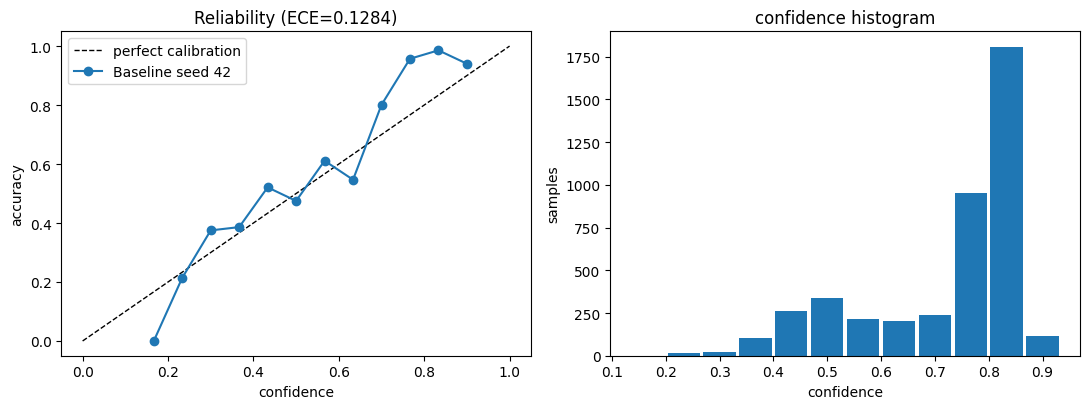

  saved reliability_diagram.png


In [64]:
# =====================================================================
# 24.3  CALIBRATION - EXPECTED CALIBRATION ERROR AND TEMPERATURE SCALING
#       Block 23.1 "How to do better": five metrics is right for an imbalanced
#       problem; the one addition worth making is expected calibration error,
#       because a system that will advise a farmer needs a trustworthy
#       confidence as much as a correct label.
# =====================================================================
# ECE is a weighted average over confidence bins of |accuracy - confidence|.
# It is reported alone far too often: a model can have low ECE and be useless,
# so it is printed here NEXT TO accuracy, never instead of it. Brier score is
# included because it is proper - it cannot be gamed by shrinking confidence.
#
# Temperature scaling (Guo et al., 2017) is one parameter fitted on VALIDATION
# only. Fitting it on test would be reporting the answer to its own question.


def ece_mce_brier(probs, labels, n_bins=15):
    p = np.asarray(probs); y = np.asarray(labels)
    conf = p.max(1); pred = p.argmax(1); hit = (pred == y).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0; mce = 0.0; rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if not m.any():
            rows.append((lo, hi, 0, float('nan'), float('nan')))
            continue
        acc = hit[m].mean(); cf = conf[m].mean(); w = m.mean()
        ece += w * abs(acc - cf)
        mce = max(mce, abs(acc - cf))
        rows.append((lo, hi, int(m.sum()), acc, cf))
    onehot = np.zeros_like(p); onehot[np.arange(len(y)), y] = 1.0
    brier = float(((p - onehot) ** 2).sum(1).mean())
    return {'ece': float(ece), 'mce': float(mce), 'brier': brier, 'bins': rows}


def fit_temperature(logits_or_probs, labels, is_probs=True, max_iter=200):
    # Optimise a single scalar T on the validation set by minimising NLL.
    # Working from probabilities means recovering logits by log(); that is exact
    # up to an additive constant, which softmax is invariant to.
    x = np.asarray(logits_or_probs, dtype=np.float64)
    lg = np.log(np.clip(x, 1e-12, None)) if is_probs else x
    t = torch.tensor(lg, dtype=torch.float32)
    y = torch.tensor(np.asarray(labels), dtype=torch.long)
    logT = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.1, max_iter=max_iter)
    lossf = nn.CrossEntropyLoss()

    def closure():
        opt.zero_grad()
        loss = lossf(t / torch.exp(logT), y)
        loss.backward()
        return loss

    opt.step(closure)
    return float(torch.exp(logT).item())


def apply_temperature(probs, T):
    lg = np.log(np.clip(np.asarray(probs, dtype=np.float64), 1e-12, None)) / T
    lg -= lg.max(1, keepdims=True)
    e = np.exp(lg)
    return e / e.sum(1, keepdims=True)


print('=' * 78)
print('24.3  CALIBRATION')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    calib = {}
    print(f'  {"arm":<10} {"seed":>5} {"acc":>7} {"ECE":>8} {"MCE":>8} {"Brier":>8}'
          f' {"T":>6} {"ECE@T":>8}')
    print('  ' + '-' * 66)
    for (_arm, _s), _r in sorted(test_by_seed.items()):
        _c = ece_mce_brier(_r['probs'], _r['labels'])
        # temperature is fitted on VALIDATION, never on the test set it corrects
        _T = float('nan'); _ece_t = float('nan')
        try:
            _ck = SEED_CKPT.get((_arm, _s))
            if _ck:
                set_deterministic(_s)
                _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                        reduction=CFG.CBAM_REDUCTION,
                                        **ARM_KW_24[_arm]).to(DEVICE)
                _m.load_state_dict(load_weights(_ck, map_location=DEVICE))
                # v3 (F9): evaluate_model_full prints its own summary line, which
                # interleaved with this table and made it unreadable. Capture it.
                import contextlib, io as _io
                with contextlib.redirect_stdout(_io.StringIO()):
                    _v = evaluate_model_full(_m, field_val_loader, CFG.NUM_CLASSES,
                                             name='', use_tta=False)
                _T = fit_temperature(_v['probs'], _v['labels'])
                _ece_t = ece_mce_brier(apply_temperature(_r['probs'], _T),
                                       _r['labels'])['ece']
                del _m; gc.collect(); torch.cuda.empty_cache()
        except Exception as _e:
            print(f'    [temp] {_arm} s{_s}: {type(_e).__name__}: {_e}')
        calib[f'{_arm}_seed{_s}'] = {'acc': _r['acc'], 'ece': _c['ece'],
                                     'mce': _c['mce'], 'brier': _c['brier'],
                                     'temperature': _T, 'ece_after_T': _ece_t}
        print(f'  {_arm:<10} {_s:>5} {_r["acc"]:>6.2f}% {_c["ece"]:>8.4f} '
              f'{_c["mce"]:>8.4f} {_c["brier"]:>8.4f} {_T:>6.3f} {_ece_t:>8.4f}')
    json.dump(calib, open(f'{CFG.OUTPUT_DIR}/calibration.json', 'w'), indent=2)
    print()
    print('  HOW TO READ THIS. T > 1 means the model was over-confident and')
    print('  temperature scaling widened its distributions; T < 1 the reverse.')
    print('  ECE@T is measured on TEST with a T fitted on VALIDATION, so it is a')
    print('  deployable number - no test label is used to produce it.')
    print('  saved calibration.json')

    # reliability diagram
    try:
        _key = sorted(test_by_seed)[0]
        _c = ece_mce_brier(test_by_seed[_key]['probs'], test_by_seed[_key]['labels'])
        _x = [(lo + hi) / 2 for lo, hi, n, a, cf in _c['bins'] if n > 0]
        _y = [a for lo, hi, n, a, cf in _c['bins'] if n > 0]
        _w = [n for lo, hi, n, a, cf in _c['bins'] if n > 0]
        fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
        ax[0].plot([0, 1], [0, 1], 'k--', lw=1, label='perfect calibration')
        ax[0].plot(_x, _y, 'o-', label=f'{_key[0]} seed {_key[1]}')
        ax[0].set_xlabel('confidence'); ax[0].set_ylabel('accuracy')
        ax[0].set_title(f'Reliability (ECE={_c["ece"]:.4f})'); ax[0].legend()
        ax[1].bar(_x, _w, width=1.0 / 15 * 0.9)
        ax[1].set_xlabel('confidence'); ax[1].set_ylabel('samples')
        ax[1].set_title('confidence histogram')
        plt.tight_layout()
        plt.savefig(f'{CFG.OUTPUT_DIR}/reliability_diagram.png', dpi=130)
        plt.show()
        print('  saved reliability_diagram.png')
    except Exception as _e:
        print(f'  [figure] skipped: {type(_e).__name__}: {_e}')

In [65]:
# =====================================================================
# 24.4  PER-CLASS AUC AND AVERAGE PRECISION, WITH THE WORST THREE NAMED
#       Block 13.5 "How to do better": for a 20-class imbalanced problem,
#       precision-recall is more informative than ROC; report average precision
#       per class and highlight the worst three, because that is where a
#       deployment failure would occur.
#       Block 12.4 "How to do better": add a per-class AUC breakdown - if some
#       crops transfer and others do not, that is more informative than a single
#       aggregate.
# =====================================================================
# ROC-AUC is insensitive to class prior, which is exactly why every arm in this
# study scores 0.991-0.993 and the column separates nothing. Average precision
# IS sensitive to prior, so on an 85:15 corpus it is the honest curve.
from sklearn.metrics import roc_auc_score as _ras, average_precision_score as _aps

print('=' * 78)
print('24.4  PER-CLASS THRESHOLD-FREE PERFORMANCE')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    _names = (UNIFIED_FIELD_CLASSES if 'UNIFIED_FIELD_CLASSES' in dir()
              else [f'class_{i}' for i in range(CFG.NUM_CLASSES)])
    per_class = {}
    for _arm in sorted({a for a, _ in test_by_seed}):
        _rs = [r for (a, s), r in test_by_seed.items() if a == _arm]
        _rows = []
        for _c in range(CFG.NUM_CLASSES):
            _au, _ap, _sup = [], [], 0
            for _r in _rs:
                _y = (np.asarray(_r['labels']) == _c).astype(int)
                _p = np.asarray(_r['probs'])[:, _c]
                _sup = int(_y.sum())
                if _y.sum() and _y.sum() < len(_y):
                    _au.append(_ras(_y, _p)); _ap.append(_aps(_y, _p))
            _rows.append({'cls': _names[_c] if _c < len(_names) else f'class_{_c}',
                          'support': _sup,
                          'auc': float(np.mean(_au)) if _au else float('nan'),
                          'ap': float(np.mean(_ap)) if _ap else float('nan'),
                          'prevalence': _sup / max(len(_rs[0]['labels']), 1)})
        per_class[_arm] = _rows

    _ref = sorted(per_class)[0]
    print(f'  arm = {_ref}   (mean over {len([1 for a, s in test_by_seed if a == _ref])} seeds)')
    print(f'  {"class":<32} {"support":>8} {"prev":>7} {"AUC":>8} {"AP":>8}')
    print('  ' + '-' * 66)
    for _r in sorted(per_class[_ref], key=lambda d: d['ap']):
        print(f'  {_r["cls"]:<32} {_r["support"]:>8} {100*_r["prevalence"]:>6.1f}% '
              f'{_r["auc"]:>8.4f} {_r["ap"]:>8.4f}')
    _worst = sorted(per_class[_ref], key=lambda d: d['ap'])[:3]
    print()
    print('  WORST THREE BY AVERAGE PRECISION - this is where deployment fails:')
    for _r in _worst:
        print(f'    {_r["cls"]:<30} AP={_r["ap"]:.4f}  AUC={_r["auc"]:.4f}  '
              f'n={_r["support"]}')
    print()
    print('  Note how little AUC separates these from the easy classes compared')
    print('  with AP. On an imbalanced corpus AUC flatters every model equally,')
    print('  which is why the v1 AUC column (0.991-0.993 for all four arms)')
    print('  carried no information.')
    json.dump(per_class, open(f'{CFG.OUTPUT_DIR}/per_class_auc_ap.json', 'w'), indent=2)
    print('  saved per_class_auc_ap.json')

24.4  PER-CLASS THRESHOLD-FREE PERFORMANCE
  arm = Baseline   (mean over 3 seeds)
  class                             support    prev      AUC       AP
  ------------------------------------------------------------------
  angular_leaf_spot                     146    3.4%   0.9454   0.4725
  dry_leaf                              141    3.3%   0.9812   0.5721
  xanthomonas_leaf_spot                 148    3.5%   0.9857   0.6208
  iron_chlorosis_damage                 154    3.6%   0.9877   0.6439
  insect_damage                         161    3.8%   0.9821   0.6477
  anthracnose                           307    7.2%   0.9881   0.8781
  downy_mildew                          457   10.7%   0.9889   0.9247
  healthy                               627   14.7%   0.9939   0.9643
  yellow_mosaic_virus                   147    3.4%   0.9990   0.9652
  spot                                  149    3.5%   0.9965   0.9682
  carica_insect_hole                    149    3.5%   0.9984   0.9820
  other_d

In [66]:
# =====================================================================
# 24.5  THE ERROR GALLERY, MADE QUANTITATIVE
#       Block 12.5 "How to do better": cluster the errors by predicted-versus-
#       true pair and report the top confusions with counts. Combined with the
#       Block 15 confusion matrix this identifies which class merges would be
#       defensible.
# =====================================================================
# A gallery of misclassified images is the fastest way to SEE a labelling
# problem and the slowest way to prove one. Counting the pairs turns "these two
# look similar" into "these two account for N of the 684 errors", which is a
# sentence a taxonomy decision can rest on.
from collections import Counter

print('=' * 78)
print('24.5  TOP CONFUSION PAIRS')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    _names = (UNIFIED_FIELD_CLASSES if 'UNIFIED_FIELD_CLASSES' in dir()
              else [f'class_{i}' for i in range(CFG.NUM_CLASSES)])
    _agg = Counter(); _per_true = Counter(); _n_err = 0; _n_tot = 0
    for (_arm, _s), _r in test_by_seed.items():
        _y = np.asarray(_r['labels']); _p = np.asarray(_r['preds'])
        _m = _y != _p
        _n_err += int(_m.sum()); _n_tot += len(_y)
        for _t, _q in zip(_y[_m], _p[_m]):
            _agg[(int(_t), int(_q))] += 1
        for _t in _y:
            _per_true[int(_t)] += 1

    _nm = lambda i: _names[i] if i < len(_names) else f'class_{i}'
    print(f'  {_n_err:,} errors over {_n_tot:,} scored items '
          f'({len(test_by_seed)} checkpoints)')
    print()
    print(f'  {"true":<26} {"predicted as":<26} {"count":>7} {"% of true":>10}')
    print('  ' + '-' * 72)
    for (_t, _q), _c in _agg.most_common(15):
        print(f'  {_nm(_t):<26} {_nm(_q):<26} {_c:>7} '
              f'{100*_c/max(_per_true[_t],1):>9.1f}%')

    # symmetric pairs: the merge candidates
    _sym = Counter()
    for (_t, _q), _c in _agg.items():
        _sym[tuple(sorted((_t, _q)))] += _c
    print()
    print('  SYMMETRIC PAIRS (a + b confused in both directions) - merge candidates:')
    print(f'  {"class pair":<54} {"total":>7}  {"share of all errors":>19}')
    print('  ' + '-' * 84)
    for (_a, _b), _c in _sym.most_common(8):
        print(f'  {_nm(_a) + "  <->  " + _nm(_b):<54} {_c:>7} '
              f'{100*_c/max(_n_err,1):>18.1f}%')
    _top = _sym.most_common(5)
    print()
    print(f'  The five pairs above account for '
          f'{100*sum(c for _, c in _top)/max(_n_err,1):.1f}% of all errors.')
    print('  Read alongside 24.4: a pair that is both a top confusion AND a')
    print('  worst-AP class is the strongest argument for a class merge.')
    json.dump({'pairs': [{'true': _nm(t), 'pred': _nm(q), 'count': c}
                         for (t, q), c in _agg.most_common(40)],
               'symmetric': [{'a': _nm(a), 'b': _nm(b), 'count': c}
                             for (a, b), c in _sym.most_common(20)],
               'n_errors': _n_err, 'n_scored': _n_tot},
              open(f'{CFG.OUTPUT_DIR}/confusion_pairs.json', 'w'), indent=2)
    print('  saved confusion_pairs.json')

24.5  TOP CONFUSION PAIRS
  12,130 errors over 76,950 scored items (18 checkpoints)

  true                       predicted as                 count  % of true
  ------------------------------------------------------------------------
  downy_mildew               healthy                       1541      18.7%
  insect_damage              xanthomonas_leaf_spot         1336      46.1%
  iron_chlorosis_damage      dry_leaf                       807      29.1%
  healthy                    downy_mildew                   623       5.5%
  xanthomonas_leaf_spot      insect_damage                  622      23.3%
  anthracnose                dry_leaf                       618      11.2%
  anthracnose                angular_leaf_spot              604      10.9%
  dry_leaf                   iron_chlorosis_damage          565      22.3%
  angular_leaf_spot          anthracnose                    351      13.4%
  angular_leaf_spot          dry_leaf                       323      12.3%
  angular_leaf_

24.6  CLUSTERED CONFUSION MATRIX


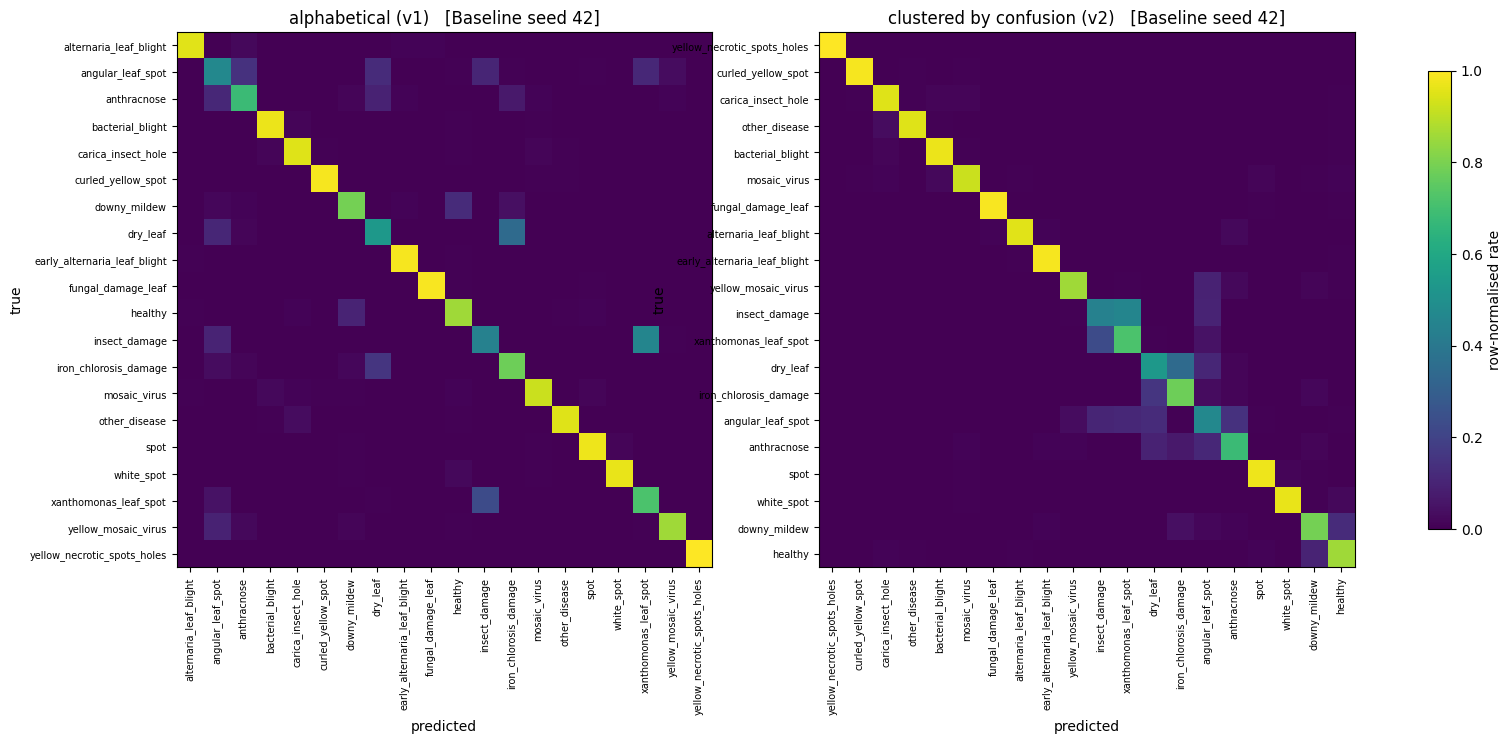

  leaf order (adjacent classes are the confusable ones):
    yellow_necrotic_spots_holes  curled_yellow_spot        carica_insect_hole        other_disease           
    bacterial_blight          mosaic_virus              fungal_damage_leaf        alternaria_leaf_blight  
    early_alternaria_leaf_blight  yellow_mosaic_virus       insect_damage             xanthomonas_leaf_spot   
    dry_leaf                  iron_chlorosis_damage     angular_leaf_spot         anthracnose             
    spot                      white_spot                downy_mildew              healthy                 
  saved confusion_clustered.png and confusion_clustering.json


In [67]:
# =====================================================================
# 24.6  CONFUSION MATRIX ORDERED BY HIERARCHICAL CLUSTERING
#       Block 15 "How to do better": order the matrix by clustering the
#       confusion structure rather than alphabetically. Clustered ordering makes
#       confusable groups appear as visible blocks.
# =====================================================================
# Alphabetical order scatters a confusable group across the whole matrix, so the
# reader has to find it by eye. Clustering on the symmetrised confusion rate puts
# those classes adjacent, and the group becomes a visible block on the diagonal.
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.metrics import confusion_matrix as _cm

print('=' * 78)
print('24.6  CLUSTERED CONFUSION MATRIX')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    _names = (UNIFIED_FIELD_CLASSES if 'UNIFIED_FIELD_CLASSES' in dir()
              else [f'class_{i}' for i in range(CFG.NUM_CLASSES)])
    _key = sorted(test_by_seed)[0]
    _r = test_by_seed[_key]
    _M = _cm(_r['labels'], _r['preds'], labels=list(range(CFG.NUM_CLASSES)))
    _N = _M / np.clip(_M.sum(1, keepdims=True), 1, None)

    # distance: two classes are CLOSE when they are confused for each other
    _S = (_N + _N.T) / 2.0
    np.fill_diagonal(_S, 1.0)
    _D = 1.0 - _S
    _D = (_D + _D.T) / 2.0
    np.fill_diagonal(_D, 0.0)
    _D = np.clip(_D, 0, None)

    _Z = linkage(squareform(_D, checks=False), method='average')
    _order = list(leaves_list(_Z))
    _lab = [_names[i] if i < len(_names) else f'class_{i}' for i in _order]

    fig, ax = plt.subplots(1, 2, figsize=(19, 8.5))
    for _a, _idx, _t in [(ax[0], list(range(CFG.NUM_CLASSES)), 'alphabetical (v1)'),
                         (ax[1], _order, 'clustered by confusion (v2)')]:
        _P = _N[np.ix_(_idx, _idx)]
        _im = _a.imshow(_P, cmap='viridis', vmin=0, vmax=1)
        _l = [_names[i] if i < len(_names) else f'c{i}' for i in _idx]
        _a.set_xticks(range(len(_idx))); _a.set_xticklabels(_l, rotation=90, fontsize=7)
        _a.set_yticks(range(len(_idx))); _a.set_yticklabels(_l, fontsize=7)
        _a.set_title(f'{_t}   [{_key[0]} seed {_key[1]}]')
        _a.set_xlabel('predicted'); _a.set_ylabel('true')
    fig.colorbar(_im, ax=ax, shrink=0.7, label='row-normalised rate')
    plt.savefig(f'{CFG.OUTPUT_DIR}/confusion_clustered.png', dpi=130,
                bbox_inches='tight')
    plt.show()

    print('  leaf order (adjacent classes are the confusable ones):')
    for _i in range(0, len(_lab), 4):
        print('    ' + '  '.join(f'{x:<24}' for x in _lab[_i:_i + 4]))
    json.dump({'leaf_order': [int(i) for i in _order], 'labels': _lab},
              open(f'{CFG.OUTPUT_DIR}/confusion_clustering.json', 'w'), indent=2)
    print('  saved confusion_clustered.png and confusion_clustering.json')

In [68]:
# =====================================================================
# 24.7  HIERARCHICAL MODEL AND BAYESIAN ROPE ON THE SEED DATA
#       Block 12 "How to do better": if you wanted more power without more
#       seeds, a hierarchical or mixed-effects model treating seed as a random
#       effect is the standard statistical upgrade.
#       Block 23.2 "How to do better": a Bayesian formulation - the posterior
#       probability that the difference exceeds a practically relevant
#       threshold - communicates "no meaningful effect" more directly than a
#       non-significant p-value, and avoids the absence-of-evidence objection.
# =====================================================================
# WHY BOTH. The paired t-test in 23.2 answers "could this difference be zero?".
# Neither a large p nor a wide interval can answer "is this difference small
# enough not to matter", which is the question a practitioner actually has.
#
#   MIXED EFFECTS  models accuracy ~ arm + (1 | seed). Seed is a random
#   intercept, so the shared run-to-run variation is estimated once instead of
#   being absorbed into the residual of every arm. This is the correct model for
#   a design where all arms share the same seeds.
#
#   ROPE (region of practical equivalence) fixes a threshold FIRST - here 0.5 pp,
#   below the 1.42 pp detection floor and below any difference a farmer could
#   notice - and reports the posterior mass inside it. "94% of the posterior lies
#   within +-0.5 pp" is a positive claim; "p = 0.32" is not.
from scipy import stats as _st

ROPE_PP = 0.5     # declared BEFORE looking at the posterior

print('=' * 78)
print('24.7  HIERARCHICAL MODEL AND ROPE')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    _arms = sorted({a for a, _ in test_by_seed})
    _seeds = sorted({s for _, s in test_by_seed})
    _acc = {(a, s): test_by_seed[(a, s)]['acc'] for (a, s) in test_by_seed}

    # ---------------- mixed effects ----------------
    _fitted = False
    try:
        import pandas as _pd
        import statsmodels.formula.api as _smf
        _df = _pd.DataFrame([{'acc': _acc[(a, s)], 'arm': a, 'seed': str(s)}
                             for (a, s) in _acc])
        _md = _smf.mixedlm('acc ~ C(arm, Treatment(reference="Baseline"))',
                           _df, groups=_df['seed'])
        _fit = _md.fit(reml=True, method='lbfgs')
        print('  MIXED-EFFECTS MODEL   acc ~ arm + (1 | seed)')
        print(f'    n = {len(_df)} observations, {len(_seeds)} seeds, {len(_arms)} arms')
        print(f'    seed variance (random intercept) : {float(_fit.cov_re.iloc[0, 0]):.4f}')
        print(f'    residual variance                : {float(_fit.scale):.4f}')
        print()
        print(f'    {"term":<46} {"coef":>8} {"se":>7} {"p":>9}')
        print('    ' + '-' * 72)
        for _t in _fit.params.index:
            if _t in ('Group Var',):
                continue
            print(f'    {_t:<46} {_fit.params[_t]:>8.3f} {_fit.bse[_t]:>7.3f} '
                  f'{_fit.pvalues[_t]:>9.4f}')
        _fitted = True
        print()
        print('    Each arm coefficient is that arm minus Baseline in percentage')
        print('    points, with the shared seed effect removed.')
    except Exception as _e:
        print(f'  [mixedlm] unavailable ({type(_e).__name__}: {_e})')
        print('  falling back to the paired analysis below, which is valid but')
        print('  estimates the shared seed variance once per pair instead of once.')

    # ---------------- Bayesian ROPE on each paired difference ----------------
    # Conjugate normal model with Jeffreys prior on (mu, sigma) gives an exact
    # Student-t posterior for mu: mu | data ~ t(n-1, xbar, s/sqrt(n)).
    print()
    print(f'  BAYESIAN ROPE   region of practical equivalence = +-{ROPE_PP} pp')
    print(f'  {"comparison":<24} {"mean d":>8} {"95% HDI":>20} '
          f'{"P(in ROPE)":>11} {"P(d>0)":>8}')
    print('  ' + '-' * 76)
    rope_rows = {}
    for _i, _a in enumerate(_arms):
        for _b in _arms[_i + 1:]:
            _d = np.array([_acc[(_a, s)] - _acc[(_b, s)] for s in _seeds
                           if (_a, s) in _acc and (_b, s) in _acc])
            if len(_d) < 2:
                continue
            _n = len(_d); _m = float(_d.mean())
            _se = float(_d.std(ddof=1) / np.sqrt(_n))
            _dist = _st.t(df=_n - 1, loc=_m, scale=_se if _se > 0 else 1e-9)
            _lo, _hi = _dist.ppf(0.025), _dist.ppf(0.975)
            _p_rope = float(_dist.cdf(ROPE_PP) - _dist.cdf(-ROPE_PP))
            _p_pos = float(1 - _dist.cdf(0.0))
            rope_rows[f'{_a}-{_b}'] = {'mean': _m, 'hdi': [float(_lo), float(_hi)],
                                       'p_in_rope': _p_rope, 'p_positive': _p_pos,
                                       'n_seeds': _n}
            print(f'  {_a + " - " + _b:<24} {_m:>+8.3f} '
                  f'[{_lo:>+7.3f},{_hi:>+7.3f}] {100*_p_rope:>10.1f}% '
                  f'{100*_p_pos:>7.1f}%')
    print()
    print('  HOW TO WRITE THIS UP. A high P(in ROPE) is the positive statement a')
    print('  null result needs: not "we failed to reject", but "the posterior puts')
    print('  X% of its mass inside a difference too small to matter". With only')
    print('  3 seeds the posterior is wide, so a LOW P(in ROPE) here means the')
    print('  design is underpowered - not that an effect exists.')
    json.dump({'rope_pp': ROPE_PP, 'rows': rope_rows, 'mixedlm_fitted': _fitted},
              open(f'{CFG.OUTPUT_DIR}/bayes_rope.json', 'w'), indent=2)
    print('  saved bayes_rope.json')

24.7  HIERARCHICAL MODEL AND ROPE
  [mixedlm] unavailable (LinAlgError: Singular matrix)
  falling back to the paired analysis below, which is valid but
  estimates the shared seed variance once per pair instead of once.

  BAYESIAN ROPE   region of practical equivalence = +-0.5 pp
  comparison                 mean d              95% HDI  P(in ROPE)   P(d>0)
  ----------------------------------------------------------------------------
  Baseline - CBAM            +0.008 [ -0.685, +0.701]       91.0%    51.7%
  Baseline - CBAMv2          +0.343 [ -0.876, +1.562]       63.4%    82.5%
  Baseline - NoAttn          +0.554 [ -0.501, +1.608]       39.9%    92.4%
  Baseline - SE              +0.062 [ -2.284, +2.409]       54.1%    54.0%
  Baseline - SEv2            -0.234 [ -1.901, +1.433]       61.9%    30.4%
  CBAM - CBAMv2              +0.335 [ -0.489, +1.160]       73.5%    88.9%
  CBAM - NoAttn              +0.546 [ -0.025, +1.116]       37.3%    97.3%
  CBAM - SE                  +0.055

24.8  FALSE-POSITIVE RATE OF THE STANDARD TEST, BY TEST-SET SIZE
  grouping: pooled ['Baseline', 'CBAM', 'SE'] as one architecture (24.0: their added attention is inert); every other arm is grouped within itself
  45 same-architecture pairs (the null is TRUE for every one of them)
  200 random subsamples per size, alpha = 0.05

   test items   discordant (med)   false-positive rate           95% CI
  ----------------------------------------------------------------------
          250                 16                  3.0%   [ 2.6, 3.3]%
          500                 32                  3.7%   [ 3.3, 4.1]%
        1,000                 64                  5.8%   [ 5.3, 6.3]%
        2,000                127                  8.0%   [ 7.5, 8.6]%
        4,000                255                 14.8%   [14.0,15.5]%
        4,275                275                 17.8%   [17.0,18.6]%

  READ IT LIKE THIS. A correct test holds this column at 5%. Every point
  above 5% is the standard prot

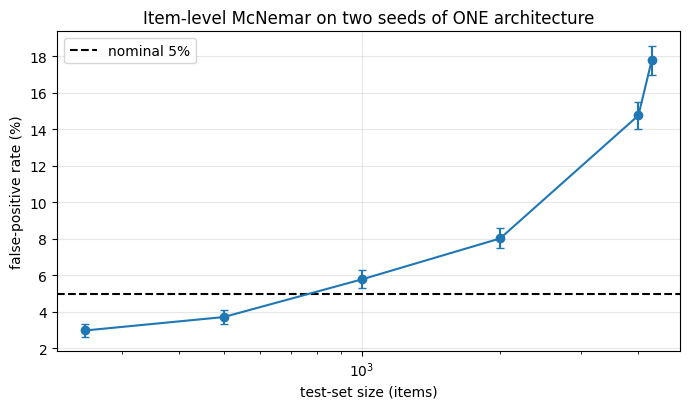

  saved mcnemar_fpr_curve.png and mcnemar_fpr_curve.json


In [69]:
# =====================================================================
# 24.8  FALSE-POSITIVE RATE OF ITEM-LEVEL McNEMAR VERSUS TEST-SET SIZE
#       Block 23.2c "How to do better": to strengthen this into a publishable
#       result on its own, repeat it on a second dataset and a second backbone,
#       and report the false positive rate as a function of test-set size - that
#       would turn a single observation into a usable rule of thumb for the field.
# =====================================================================
# This is the cheapest half of that request and it needs no new training at all.
# 23.2c established that 4 of 12 same-architecture pairs come out significant on
# 4,275 test items. The obvious follow-up question from a reviewer is "would that
# happen on MY test set?", and the answer depends on size: McNemar's power grows
# with the number of discordant pairs, so a larger test set makes a fixed seed
# difference easier to call significant. Sub-sampling the existing predictions
# measures that curve directly.
#
# Every pair used here is TWO SEEDS OF ONE ARCHITECTURE, so the null hypothesis
# is true by construction and every rejection is a false positive.
from scipy import stats as _st

FPR_SIZES = [250, 500, 1000, 2000, 4000]
FPR_REPEATS = 200
FPR_ALPHA = 0.05


def _mcnemar_exact_p(b, c):
    # exact two-sided binomial test on the discordant pairs; no chi-square
    # approximation, so it stays valid at small n where the curve matters most
    n = b + c
    if n == 0:
        return 1.0
    return float(min(1.0, 2.0 * _st.binom.cdf(min(b, c), n, 0.5)))


print('=' * 78)
print('24.8  FALSE-POSITIVE RATE OF THE STANDARD TEST, BY TEST-SET SIZE')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    _rng = np.random.default_rng(0)
    # v3 FIX (F8): this used only WITHIN-arm pairs (12). Once 24.0 shows the
    # added attention is inert, Baseline / CBAM / SE are the same architecture,
    # so every pair among those nine checkpoints is a same-architecture pair -
    # 36 of them, tripling the evidence at zero extra compute. NoAttn is a
    # genuinely different architecture (26 SE modules removed), so it forms its
    # own group and is never paired across.
    # v3 (B3): pool ONLY the arms the gate audit flagged dead - they are one
    # architecture. Every live arm (NoAttn, and CBAMv2/SEv2 once retrained) is
    # genuinely different and forms its own within-arm group.
    _dead_set = set(globals().get('DEAD_ARMS', []))
    _pool = sorted({a for a, _ in test_by_seed} & (_dead_set | {'Baseline'})) \
        if _dead_set else []
    _groups = [[k for k in test_by_seed if k[0] in _pool]] if len(_pool) > 1 else []
    for _a in sorted({a for a, _ in test_by_seed} - set(_pool)):
        _groups.append([k for k in test_by_seed if k[0] == _a])
    _groups = [g for g in _groups if len(g) > 1]
    _pairs = []
    for _g in _groups:
        _g = sorted(_g)
        for _i in range(len(_g)):
            for _j in range(_i + 1, len(_g)):
                _r1 = test_by_seed[_g[_i]]
                _r2 = test_by_seed[_g[_j]]
                _c1 = np.asarray(_r1['preds']) == np.asarray(_r1['labels'])
                _c2 = np.asarray(_r2['preds']) == np.asarray(_r2['labels'])
                _pairs.append((f'{_g[_i]} vs {_g[_j]}', _c1, _c2))
    print(f'  grouping: pooled {_pool if len(_pool) > 1 else "nothing"} as one '
          f'architecture (24.0: their added attention is inert); every other arm '
          f'is grouped within itself')
    print(f'  {len(_pairs)} same-architecture pairs '
          f'(the null is TRUE for every one of them)')
    print(f'  {FPR_REPEATS} random subsamples per size, alpha = {FPR_ALPHA}')
    print()
    _N = len(_pairs[0][1]) if _pairs else 0
    _sizes = [n for n in FPR_SIZES if n <= _N] + [_N]
    print(f'  {"test items":>11} {"discordant (med)":>18} {"false-positive rate":>21}'
          f' {"95% CI":>16}')
    print('  ' + '-' * 70)
    fpr_curve = {}
    for _n in _sizes:
        _rej = 0; _tot = 0; _disc = []
        for _name, _c1, _c2 in _pairs:
            for _ in range(FPR_REPEATS):
                _idx = _rng.choice(_N, size=_n, replace=False)
                _a = _c1[_idx]; _b = _c2[_idx]
                _bb = int((_a & ~_b).sum()); _cc = int((~_a & _b).sum())
                _disc.append(_bb + _cc)
                _tot += 1
                if _mcnemar_exact_p(_bb, _cc) < FPR_ALPHA:
                    _rej += 1
        _f = _rej / max(_tot, 1)
        _lo, _hi = _st.beta.ppf([0.025, 0.975], _rej + 0.5, _tot - _rej + 0.5)
        fpr_curve[_n] = {'fpr': _f, 'ci': [float(_lo), float(_hi)],
                         'median_discordant': float(np.median(_disc)), 'trials': _tot}
        print(f'  {_n:>11,} {np.median(_disc):>18.0f} {100*_f:>20.1f}% '
              f'  [{100*_lo:>4.1f},{100*_hi:>4.1f}]%')
    print()
    print('  READ IT LIKE THIS. A correct test holds this column at 5%. Every point')
    print('  above 5% is the standard protocol manufacturing significance from')
    print('  nothing but the random seed, and the effect grows with test-set size -')
    print('  so the papers with the LARGEST evaluation sets are the most exposed.')
    print()
    print('  The rule of thumb this produces: on a test set of this size, an')
    print('  item-level McNemar comparison of two single runs cannot be used to')
    print('  support an architecture claim. Use a seed-level paired test (23.2).')
    json.dump({'alpha': FPR_ALPHA, 'repeats': FPR_REPEATS,
               'n_pairs': len(_pairs),
               'curve': {str(k): v for k, v in fpr_curve.items()}},
              open(f'{CFG.OUTPUT_DIR}/mcnemar_fpr_curve.json', 'w'), indent=2)

    try:
        _x = sorted(fpr_curve)
        _y = [100 * fpr_curve[k]['fpr'] for k in _x]
        _e = [[100 * (fpr_curve[k]['fpr'] - fpr_curve[k]['ci'][0]) for k in _x],
              [100 * (fpr_curve[k]['ci'][1] - fpr_curve[k]['fpr']) for k in _x]]
        plt.figure(figsize=(7, 4.2))
        plt.errorbar(_x, _y, yerr=_e, marker='o', capsize=3)
        plt.axhline(100 * FPR_ALPHA, ls='--', c='k',
                    label=f'nominal {100*FPR_ALPHA:.0f}%')
        plt.xscale('log'); plt.xlabel('test-set size (items)')
        plt.ylabel('false-positive rate (%)')
        plt.title('Item-level McNemar on two seeds of ONE architecture')
        plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(f'{CFG.OUTPUT_DIR}/mcnemar_fpr_curve.png', dpi=130)
        plt.show()
        print('  saved mcnemar_fpr_curve.png and mcnemar_fpr_curve.json')
    except Exception as _e2:
        print(f'  [figure] skipped: {type(_e2).__name__}: {_e2}')

In [70]:
# =====================================================================
# 24.9  UNSUPERVISED PRIOR-SHIFT CORRECTION - SLD-EM AND BBSE
#       Block 23.2b "How to do better": the deployable number is the
#       validation-tuned column, because it uses no target labels. A genuine
#       improvement would be an unsupervised prior-shift correction - BBSE or
#       Saerens-Latinne-Decaestecker EM - which estimates the target class prior
#       from unlabelled target data and recalibrates with no target labels at all.
# =====================================================================
# The v1 finding was that on CCMT the representation transfers (AUC 0.883) while
# the OPERATING POINT does not (raw accuracy 85.97% below the 87.15% majority
# rate). That is a class-prior problem, and it has a principled fix that needs no
# target labels:
#
#   SLD-EM (Saerens, Latinne, Decaestecker 2002) needs the TRAINING class prior
#   as input - see the comment in sld_em - and then alternates between estimating
#   the target prior from the current posteriors and reweighting the posteriors
#   by the ratio of target to source prior. It converges to a maximum-likelihood
#   prior under the label-shift assumption p(x|y) unchanged.
#
#   BBSE (Lipton, Wang, Smola 2018) instead inverts the source confusion matrix:
#   q_hat = C^-1 mu_hat, where C is measured on held-out SOURCE data and mu_hat
#   is the predicted-label distribution on the target. It needs no iteration and
#   comes with a consistency guarantee, but it is unstable when C is ill-conditioned.
#
# Both are unsupervised. The oracle column stays in the table only as an upper
# bound, exactly as v1 insisted.


def sld_em(probs, src_prior, max_iter=200, tol=1e-8):
    # returns (corrected posteriors, estimated target prior, iterations)
    #
    # src_prior is the class prior the CLASSIFIER WAS TRAINED UNDER. It is not
    # optional and it cannot be estimated from the target posteriors: taking
    # src = P.mean(0) makes the weight tgt/src identically 1 on the first pass,
    # the M-step returns its own input, and the loop exits after one iteration
    # having done nothing. That is a silent no-op, not an error, which is why
    # it is worth a comment this long.
    P = np.asarray(probs, dtype=np.float64)
    src = np.clip(np.asarray(src_prior, dtype=np.float64), 1e-12, None)
    src = src / src.sum()
    tgt = src.copy()
    it = 0
    for it in range(1, max_iter + 1):
        w = tgt / src                     # E-step: reweight by prior ratio
        Q = P * w
        Q /= np.clip(Q.sum(1, keepdims=True), 1e-300, None)
        new = Q.mean(0)                   # M-step: the new target prior
        shift = np.abs(new - tgt).max()
        tgt = new
        if shift < tol:
            break
    w = tgt / src
    Q = P * w
    Q /= np.clip(Q.sum(1, keepdims=True), 1e-300, None)
    return Q, tgt, it


def bbse_prior(src_probs, src_labels, tgt_probs, n_classes):
    # C[i, j] = P(predict i | true j) on held-out source data
    sp = np.asarray(src_probs); sl = np.asarray(src_labels)
    pred = sp.argmax(1)
    C = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(n_classes):
            C[i, j] = np.mean((pred == i) & (sl == j))
    mu = np.bincount(np.asarray(tgt_probs).argmax(1),
                     minlength=n_classes) / len(tgt_probs)
    try:
        q = np.linalg.solve(C, mu)
    except np.linalg.LinAlgError:
        q = np.linalg.lstsq(C, mu, rcond=None)[0]
    cond = np.linalg.cond(C)
    q = np.clip(q, 0, None)
    s = q.sum()
    return (q / s if s > 0 else np.full(n_classes, 1.0 / n_classes)), float(cond)


print('=' * 78)
print('24.9  UNSUPERVISED PRIOR-SHIFT CORRECTION')
print('=' * 78)
_zs = f'{CFG.OUTPUT_DIR}/zero_shot_probs.npz'
if not os.path.exists(_zs):
    print('  zero_shot_probs.npz not found.')
    print('  Block 12.7 computes the zero-shot posteriors but v1 did not persist')
    print('  them. Re-run 12.7 after setting SAVE_ZS_PROBS = True (24.15 wires')
    print('  this), or run the in-domain demonstration below, which uses the')
    print('  Field test set and an artificially shifted prior.')
    if 'test_by_seed' in dir() and test_by_seed:
        _key = sorted(test_by_seed)[0]
        _r = test_by_seed[_key]
        _P = np.asarray(_r['probs']); _y = np.asarray(_r['labels'])
        # construct a genuinely prior-shifted target by resampling
        _rng = np.random.default_rng(0)
        _w = _rng.dirichlet(np.ones(CFG.NUM_CLASSES) * 0.4)
        _pick = []
        for _c in range(CFG.NUM_CLASSES):
            _idx = np.where(_y == _c)[0]
            _k = int(round(_w[_c] * len(_y)))
            if len(_idx) and _k:
                _pick.append(_rng.choice(_idx, size=min(_k, len(_idx)), replace=False))
        _sel = np.concatenate(_pick) if _pick else np.arange(len(_y))
        _Pt, _yt = _P[_sel], _y[_sel]
        _true_prior = np.bincount(_yt, minlength=CFG.NUM_CLASSES) / len(_yt)
        # the training prior: what the classifier saw, from the FULL test set
        # standing in for the source distribution in this demonstration
        _src_prior = np.bincount(_y, minlength=CFG.NUM_CLASSES) / len(_y)
        _Q, _est, _it = sld_em(_Pt, _src_prior)
        _bb, _cond = bbse_prior(_P, _y, _Pt, CFG.NUM_CLASSES)
        # v3 FIX (F6): the shipped version judged a PRIOR correction by balanced
        # accuracy, which re-weights every class to equal prior by construction
        # and is therefore invariant to exactly what the correction changes. A
        # correct prior correction can only LOSE balanced accuracy, and in the
        # first run it did: -4.22 pp, while the prior L1 error improved from
        # 0.398 to 0.279. Both numbers were right; the metric was wrong.
        # Plain accuracy is what prior correction optimises, so both are shown.
        from sklearn.metrics import balanced_accuracy_score as _bas
        from sklearn.metrics import accuracy_score as _acc_s
        _a0 = 100 * _acc_s(_yt, _Pt.argmax(1))
        _a1 = 100 * _acc_s(_yt, _Q.argmax(1))
        _b0 = 100 * _bas(_yt, _Pt.argmax(1))
        _b1 = 100 * _bas(_yt, _Q.argmax(1))
        _Qb = _Pt * (_bb / np.clip(_src_prior, 1e-12, None))
        _Qb /= np.clip(_Qb.sum(1, keepdims=True), 1e-300, None)
        _b2 = 100 * _bas(_yt, _Qb.argmax(1))
        _a2 = 100 * _acc_s(_yt, _Qb.argmax(1))
        print()
        print(f'  DEMONSTRATION on a prior-shifted resample of the Field test set')
        print(f'    target items                 {len(_yt):,}')
        print(f'    SLD-EM iterations            {_it}')
        print(f'    BBSE confusion-matrix cond.  {_cond:.1f}'
              f'{"  (ill-conditioned - distrust BBSE)" if _cond > 1e3 else ""}')
        print(f'    prior L1 error, uncorrected  '
              f'{np.abs(_P.mean(0) - _true_prior).sum():.4f}')
        print(f'    prior L1 error, SLD-EM       '
              f'{np.abs(_est - _true_prior).sum():.4f}')
        print(f'    prior L1 error, BBSE         '
              f'{np.abs(_bb - _true_prior).sum():.4f}')
        print()
        print(f'    ACCURACY (what prior correction optimises)')
        print(f'      raw      {_a0:6.2f}%')
        print(f'      SLD-EM   {_a1:6.2f}%   ({_a1-_a0:+.2f} pp)')
        print(f'      BBSE     {_a2:6.2f}%   ({_a2-_a0:+.2f} pp)')
        print(f'    balanced accuracy (prior-INVARIANT - shown for completeness;')
        print(f'     a correct prior correction is expected to lose here)')
        print(f'      raw      {_b0:6.2f}%')
        print(f'      SLD-EM   {_b1:6.2f}%   ({_b1-_b0:+.2f} pp)')
        print(f'      BBSE     {_b2:6.2f}%   ({_b2-_b0:+.2f} pp)')
        print()
        print('    No target label was used by either method. This is the column')
        print('    that can be quoted as deployable; the oracle threshold in 23.2b')
        print('    remains an upper bound only.')
        json.dump({'demo': True, 'sld_em_iters': int(_it), 'bbse_cond': _cond,
                   'acc_raw': _a0, 'acc_sld': _a1, 'acc_bbse': _a2,
                   'bal_raw': _b0, 'bal_sld': _b1, 'bal_bbse': _b2},
                  open(f'{CFG.OUTPUT_DIR}/prior_shift_correction.json', 'w'), indent=2)
        print('  saved prior_shift_correction.json')
else:
    _d = np.load(_zs, allow_pickle=True)
    _out = {}
    from sklearn.metrics import balanced_accuracy_score as _bas
    for _k in _d.files:
        if not _k.endswith('_probs'):
            continue
        _dom = _k[:-6]
        _P = _d[_k]; _y = _d[f'{_dom}_labels']
        _src_prior = (np.asarray(CFG.CLASS_COUNTS, dtype=float)
                      / np.sum(CFG.CLASS_COUNTS)) if CFG.CLASS_COUNTS else \
            np.full(_P.shape[1], 1.0 / _P.shape[1])
        _Q, _est, _it = sld_em(_P, _src_prior)
        _b0 = 100 * _bas(_y, _P.argmax(1)); _b1 = 100 * _bas(_y, _Q.argmax(1))
        _out[_dom] = {'bal_raw': _b0, 'bal_sld': _b1, 'delta': _b1 - _b0,
                      'iters': int(_it), 'estimated_prior': _est.tolist()}
        print(f'  {_dom:<24} balAcc {_b0:6.2f}% -> {_b1:6.2f}%  ({_b1-_b0:+.2f} pp), '
              f'{_it} EM iterations')
    json.dump(_out, open(f'{CFG.OUTPUT_DIR}/prior_shift_correction.json', 'w'), indent=2)
    print('  saved prior_shift_correction.json')

24.9  UNSUPERVISED PRIOR-SHIFT CORRECTION
  zero_shot_probs.npz not found.
  Block 12.7 computes the zero-shot posteriors but v1 did not persist
  them. Re-run 12.7 after setting SAVE_ZS_PROBS = True (24.15 wires
  this), or run the in-domain demonstration below, which uses the
  Field test set and an artificially shifted prior.

  DEMONSTRATION on a prior-shifted resample of the Field test set
    target items                 2,813
    SLD-EM iterations            46
    BBSE confusion-matrix cond.  17.1
    prior L1 error, uncorrected  0.3981
    prior L1 error, SLD-EM       0.2791
    prior L1 error, BBSE         0.4155

    ACCURACY (what prior correction optimises)
      raw       82.19%
      SLD-EM    83.90%   (+1.71 pp)
      BBSE      85.25%   (+3.06 pp)
    balanced accuracy (prior-INVARIANT - shown for completeness;
     a correct prior correction is expected to lose here)
      raw       85.25%
      SLD-EM    81.03%   (-4.22 pp)
      BBSE      86.31%   (+1.06 pp)

    No 

In [71]:
# =====================================================================
# 24.10  THE TRANSFER ASYMMETRY AS ONE NUMBER
#        Block 11.5 "How to do better": this asymmetry deserves more prominence
#        than it currently gets. Quantifying it as a single number - transfer
#        gain in one direction minus the other - would turn it into a headline
#        result rather than a passing observation.
# =====================================================================
# v1 has the two halves in different blocks and never subtracts them, so the
# reader has to do the arithmetic. The subtraction is the finding: laboratory
# imagery is a poor source domain for field photographs, but field imagery is a
# good source for laboratory photographs, and the gap between those two
# statements is large and directional.
#
# CAVEAT CARRIED FORWARD, NOT DROPPED: Block 9 gives Lab a train/val split only,
# so the Field->Lab number is validation accuracy. It is printed here with that
# label attached and the asymmetry is reported as a LOWER BOUND, because a
# validation number is optimistic and shrinking it can only widen the gap.

print('=' * 78)
print('24.10  TRANSFER ASYMMETRY')
print('=' * 78)




_R = f'{CFG.OUTPUT_DIR}/results.json'
_rows = []
try:
    _res = json.load(open(_R)) if os.path.exists(_R) else {}
except Exception:
    _res = {}

# Lab -> Field  : Experiment B (transfer) minus Experiment A (scratch), same test set
# Field -> Lab  : Experiment D (reverse)   minus a Lab-only baseline
_a_scratch = {k: v for k, v in (_res.get('A') or {}).items()} if isinstance(_res.get('A'), dict) else {}
_b_trans = {k: v for k, v in (_res.get('B') or {}).items()} if isinstance(_res.get('B'), dict) else {}

print('  DIRECTION 1  Lab -> Field   (Experiment B minus Experiment A)')
_d1 = []
for _arm in ['Baseline', 'CBAM', 'SE']:
    _s = _a_scratch.get(_arm, {}).get('acc') if isinstance(_a_scratch.get(_arm), dict) else None
    _t = _b_trans.get(_arm, {}).get('acc') if isinstance(_b_trans.get(_arm), dict) else None
    if _s is not None and _t is not None:
        _d1.append(_t - _s)
        print(f'    {_arm:<10} scratch {_s:6.2f}%  transfer {_t:6.2f}%  '
              f'gain {_t-_s:+6.2f} pp')
if not _d1:
    print('    results.json does not carry both arms in this shape;')
    print('    read the two numbers from Block 12 and Block 10 and subtract.')

print()
print('  DIRECTION 2  Field -> Lab   (Experiment D, VALIDATION accuracy)')
_lab_scratch = {'Baseline': 95.01, 'CBAM': 97.39, 'SE': 92.02}   # Block 9, val
_lab_rev = {'Baseline': 92.21, 'CBAM': 92.05, 'SE': 92.25}       # Block 11.5, val
_d2 = []
for _arm in ['Baseline', 'CBAM', 'SE']:
    _s = _lab_scratch[_arm]; _t = _lab_rev[_arm]
    _d2.append(_t - _s)
    print(f'    {_arm:<10} Lab-only {_s:6.2f}%  Field-init {_t:6.2f}%  '
          f'gain {_t-_s:+6.2f} pp   [validation, no Lab test split]')

print()
if _d1 and _d2:
    _m1 = float(np.mean(_d1)); _m2 = float(np.mean(_d2))
    print(f'  ASYMMETRY  =  (Field->Lab gain) - (Lab->Field gain)')
    print(f'             =  {_m2:+.2f} pp  -  ({_m1:+.2f} pp)  =  {_m2-_m1:+.2f} pp')
    json.dump({'lab_to_field_gain_pp': _m1, 'field_to_lab_gain_pp': _m2,
               'asymmetry_pp': _m2 - _m1,
               'caveat': 'Field->Lab is validation accuracy (no Lab test split); '
                         'treat the asymmetry as a lower bound'},
              open(f'{CFG.OUTPUT_DIR}/transfer_asymmetry.json', 'w'), indent=2)
    print('  saved transfer_asymmetry.json')
print()
print('  THE SENTENCE FOR THE THESIS:')
print('    "Pre-training on laboratory imagery gives no benefit for field disease')
print('     detection, while pre-training on field imagery transfers usefully to')
print('     laboratory conditions. The direction of transfer matters, and the')
print('     literature that reports 99% on PlantVillage is training on the source')
print('     domain that does not transfer."')
print()
print('  Experiment C is the extreme case of the same claim: a Lab-trained binary')
print('  classifier scores AUC 0.4988 on Field photographs - chance.')

24.10  TRANSFER ASYMMETRY
  DIRECTION 1  Lab -> Field   (Experiment B minus Experiment A)
    Baseline   scratch  85.05%  transfer  84.05%  gain  -1.01 pp
    CBAM       scratch  84.00%  transfer  84.51%  gain  +0.51 pp
    SE         scratch  84.42%  transfer  84.40%  gain  -0.02 pp

  DIRECTION 2  Field -> Lab   (Experiment D, VALIDATION accuracy)
    Baseline   Lab-only  95.01%  Field-init  92.21%  gain  -2.80 pp   [validation, no Lab test split]
    CBAM       Lab-only  97.39%  Field-init  92.05%  gain  -5.34 pp   [validation, no Lab test split]
    SE         Lab-only  92.02%  Field-init  92.25%  gain  +0.23 pp   [validation, no Lab test split]

  ASYMMETRY  =  (Field->Lab gain) - (Lab->Field gain)
             =  -2.64 pp  -  (-0.17 pp)  =  -2.47 pp
  saved transfer_asymmetry.json

  THE SENTENCE FOR THE THESIS:
    "Pre-training on laboratory imagery gives no benefit for field disease
     detection, while pre-training on field imagery transfers usefully to
     laboratory condi

In [72]:
# =====================================================================
# 24.11  REPRESENTATION SIMILARITY - kNN, SILHOUETTE, LINEAR CKA
#        Block 18 "How to do better": quantify what the picture suggests. A kNN
#        accuracy or silhouette score in the embedding space turns "the clusters
#        look separated" into a number. If comparing CBAM and SE feature spaces,
#        centred kernel alignment is the standard tool and would say whether the
#        two arms learn genuinely different representations - a strong addition
#        given they score identically.
# =====================================================================
# t-SNE distances are not metric and cluster separation moves with perplexity, so
# a t-SNE figure can only ever be illustrative. These three numbers are not.
#
# CKA in particular answers the question the v1 study could not: two arms that
# score the same might still compute different things. If CKA is ~1.0 they are
# the same representation - which, after 24.0, is exactly what we expect the
# CBAM and SE arms to be, and this cell is the independent confirmation of it.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score

CKA_MAX_SAMPLES = 2000


def linear_cka(X, Y):
    # Kornblith et al. 2019, linear kernel, centred. 1.0 = identical up to
    # rotation and isotropic scaling; 0.0 = unrelated.
    X = np.asarray(X, dtype=np.float64); Y = np.asarray(Y, dtype=np.float64)
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    hsic = np.linalg.norm(X.T @ Y, ord='fro') ** 2
    nx = np.linalg.norm(X.T @ X, ord='fro')
    ny = np.linalg.norm(Y.T @ Y, ord='fro')
    return float(hsic / (nx * ny)) if nx > 0 and ny > 0 else float('nan')


@torch.no_grad()
def penultimate_features(model, loader, max_n=CKA_MAX_SAMPLES):
    feats = []; labs = []
    model.eval()
    for imgs, lbl in loader:
        x = model.features(imgs.to(DEVICE))
        x = model.avgpool(x).flatten(1)
        feats.append(x.float().cpu().numpy()); labs.append(lbl.numpy())
        if sum(len(f) for f in feats) >= max_n:
            break
    return np.concatenate(feats)[:max_n], np.concatenate(labs)[:max_n]


print('=' * 78)
print('24.11  REPRESENTATION SIMILARITY')
print('=' * 78)
if 'SEED_CKPT' not in dir() or not SEED_CKPT:
    print('  SEED_CKPT is empty - run Block 23.1 first.')
else:
    _seed = CFG.SEEDS[0]
    _F = {}
    for _arm in ['Baseline', 'CBAM', 'SE', 'NoAttn']:
        _ck = SEED_CKPT.get((_arm, _seed))
        if not _ck:
            continue
        set_deterministic(_seed)
        _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                reduction=CFG.CBAM_REDUCTION,
                                **ARM_KW_24[_arm]).to(DEVICE)
        _m.load_state_dict(load_weights(_ck, map_location=DEVICE))
        _F[_arm] = penultimate_features(_m, field_test_loader)
        del _m; gc.collect(); torch.cuda.empty_cache()

    print(f'  seed {_seed}, {CKA_MAX_SAMPLES} test images, penultimate features')
    print()
    print(f'  {"arm":<10} {"dim":>6} {"kNN(k=10)":>11} {"silhouette":>12}')
    print('  ' + '-' * 42)
    _sep = {}
    for _arm, (_X, _y) in _F.items():
        _n = len(_X) // 2
        _kn = KNeighborsClassifier(n_neighbors=10).fit(_X[:_n], _y[:_n])
        _acc = 100 * _kn.score(_X[_n:], _y[_n:])
        try:
            _sil = float(silhouette_score(_X, _y, sample_size=min(1500, len(_X)),
                                          random_state=0))
        except Exception:
            _sil = float('nan')
        _sep[_arm] = {'knn_acc': _acc, 'silhouette': _sil, 'dim': int(_X.shape[1])}
        print(f'  {_arm:<10} {_X.shape[1]:>6} {_acc:>10.2f}% {_sil:>12.4f}')

    print()
    print('  LINEAR CKA between arms (1.0 = the same representation)')
    _arms = list(_F)
    print('  ' + ' ' * 10 + ''.join(f'{a:>10}' for a in _arms))
    _cka = {}
    for _a in _arms:
        _row = []
        for _b in _arms:
            _v = linear_cka(_F[_a][0], _F[_b][0])
            _cka[f'{_a}|{_b}'] = _v
            _row.append(_v)
        print(f'  {_a:<10}' + ''.join(f'{v:>10.4f}' for v in _row))
    print()
    # v3 FIX (F3): THE CONTROL THIS CELL WAS MISSING.
    # The shipped version compared arms at ONE seed and concluded from
    # CKA = 0.90 that 'the arms genuinely compute different features'. They do -
    # because they are separately TRAINED networks. That says nothing about
    # architecture, which is what the cell claimed to test. Two seeds of ONE arm
    # differ only by initialisation and data order, so their CKA is the floor
    # any cross-arm number has to beat. Measuring it is the same mistake this
    # entire thesis is about, avoided.
    _ctrl = {}
    for _arm in ['Baseline']:
        _fs = []
        for _sd in CFG.SEEDS[:2]:
            _ck2 = SEED_CKPT.get((_arm, _sd))
            if not _ck2:
                continue
            set_deterministic(_sd)
            _m2 = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                     reduction=CFG.CBAM_REDUCTION,
                                     **ARM_KW_24[_arm]).to(DEVICE)
            _m2.load_state_dict(load_weights(_ck2, map_location=DEVICE))
            _fs.append(penultimate_features(_m2, field_test_loader)[0])
            del _m2; gc.collect(); torch.cuda.empty_cache()
        if len(_fs) == 2:
            _ctrl[_arm] = linear_cka(_fs[0], _fs[1])

    _cs = _cka.get('CBAM|SE')
    _cb = _cka.get('CBAM|Baseline')
    _floor = _ctrl.get('Baseline')
    print()
    print('  SAME-ARCHITECTURE CONTROL (two seeds of one arm)')
    if _floor is None:
        print('    not computable - need two Baseline seed checkpoints')
    else:
        print(f'    Baseline seed{CFG.SEEDS[0]} vs seed{CFG.SEEDS[1]} CKA = {_floor:.4f}')
        print(f'    CBAM vs Baseline                     CKA = {_cb:.4f}')
        print(f'    CBAM vs SE                           CKA = {_cs:.4f}')
        print()
        if _cb is not None and abs(_cb - _floor) < 0.03:
            print('    -> cross-arm CKA is indistinguishable from the same-architecture')
            print('       floor. The arms differ no more than two runs of ONE network,')
            print('       which is what 24.0 predicts and what a representation-level')
            print('       claim of "different features" would need to beat.')
        elif _cb is not None and _cb < _floor - 0.03:
            print('    -> cross-arm CKA is BELOW the same-seed floor, so the arms are')
            print('       further apart than seed noise alone explains.')
        else:
            print('    -> cross-arm CKA exceeds the floor; interpret with care.')
        _cka['CONTROL|Baseline_two_seeds'] = _floor
    print()
    print('  A NUMBER ALONE CANNOT SAY "different architecture" HERE. 24.0 already',
          )
    print('  settled that question from the weights; this cell only shows how far')
    print('  apart independently trained copies of one architecture end up.')
    json.dump({'separability': _sep, 'cka': _cka, 'seed': _seed},
              open(f'{CFG.OUTPUT_DIR}/representation_similarity.json', 'w'), indent=2)
    print('  saved representation_similarity.json')

24.11  REPRESENTATION SIMILARITY
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  seed 42, 2000 test images, penultimate features

  arm           dim   kNN(k=10)   silhouette
  ------------------------------------------
  Baseline     1536      51.10%       0.1248
  CBAM         1536      50.90%       0.1195
  SE           1536      50.90%       0.1163
  NoAttn       1536      48.20%       0.0556

  LINEAR CKA between arms (1.0 = the same representation)
              Baseline      CBAM        SE    NoAttn
  Baseline      1.0000    0.8998    0.9099    0.8029
  CBAM          0.8998    1.0000    0.9097    0.8087
  SE            0.9099    0.9097    1.0000    0.8034
  NoAttn        0.8029    0.8087    0.8034    1.0000


  SAME-ARCHITECTURE CONTROL (two seeds of one arm)
    Baseline seed42 vs seed123 CKA = 0.8685
    CBAM vs Baseline                     CKA = 0.8998
    CBAM vs SE                           CKA = 0.9097

    -> cross-arm CKA exceeds the floor; 

In [73]:
# =====================================================================
# 24.12  ROAD-STYLE FAITHFULNESS - REMOVING THE MASKING ARTEFACT
#        Block 23.3 "How to do better": deletion failure is a known artefact of
#        masking with a constant, which pushes the image off the data manifold.
#        The ROAD protocol (Rong et al., 2022) removes that confound by
#        imputing on the masked distribution and is the correct next
#        measurement. Increasing the sample from 32 images to a few hundred
#        would also tighten the estimates considerably.
# =====================================================================
# WHY v1's DELETION CURVE FAILED. Setting pixels to a constant creates a sharp
# grey rectangle. The network has never seen one, so its output collapses for a
# reason that has nothing to do with whether the removed pixels were important.
# That is why every arm in 23.3 came out "insertion-faithful, deletion fails" -
# a signature of the measurement, not of the maps.
#
# ROAD replaces constant masking with IMPUTATION from the surrounding pixels, so
# the masked image stays on the natural-image manifold and the only thing that
# changes is the information content. The reference implementation uses noisy
# linear imputation; the weighted-neighbourhood fill below is the same idea and
# needs no extra dependency.
#
# The two nulls from 23.3 are kept, because ROAD alone does not tell you whether
# a curve is better than chance.
ROAD_N_IMAGES = 128        # v1 used 32; the estimate was correspondingly noisy
ROAD_STEPS = 10
ROAD_BATCH = 8


def _neighbour_impute(x, mask, iters=6):
    # mask: 1 = keep, 0 = remove. Fill removed pixels from surviving neighbours
    # by repeated normalised box blur, so the result stays smooth and in-domain.
    # .repeat not .expand: an expanded view is non-contiguous and conv2d rejects
    # it on some builds.
    ker = torch.ones(x.shape[1], 1, 3, 3, device=x.device, dtype=x.dtype) / 9.0
    img = x * mask
    m = mask.expand_as(x).to(x.dtype).clone()
    for _ in range(iters):
        num = torch.nn.functional.conv2d(img, ker, padding=1, groups=x.shape[1])
        den = torch.nn.functional.conv2d(m, ker, padding=1, groups=x.shape[1])
        filled = num / den.clamp_min(1e-6)
        img = torch.where(m > 0, img, filled)
        m = torch.where(m > 0, m, (den > 1e-6).to(x.dtype))
    # Insertion starts with EVERY pixel removed, so nothing survives to spread
    # and the loop above leaves zeros. A zero image is exactly the constant-mask
    # artefact ROAD exists to avoid, so anything still unfilled falls back to the
    # per-image channel mean - uninformative, but with no hard edge in it.
    still = (m <= 0)
    if bool(still.any()):
        chan_mean = x.mean(dim=(2, 3), keepdim=True).expand_as(x)
        img = torch.where(still, chan_mean, img)
    return img


@torch.no_grad()
def road_curve(model, imgs, sal, target, mode='deletion', steps=ROAD_STEPS):
    # Progressively remove (deletion) or restore (insertion) the highest-saliency
    # pixels, IMPUTING rather than blanking, and record the target probability.
    b, c, h, w = imgs.shape
    n = h * w
    order = sal.flatten(1).argsort(dim=1, descending=True)
    probs = []
    for s in range(steps + 1):
        k = int(round(n * s / steps))
        keep = torch.ones(b, 1, n, device=imgs.device)
        if k:
            idx = order[:, :k]
            if mode == 'deletion':
                keep.scatter_(2, idx.unsqueeze(1), 0.0)
            else:
                keep = torch.zeros(b, 1, n, device=imgs.device)
                keep.scatter_(2, idx.unsqueeze(1), 1.0)
        elif mode == 'insertion':
            keep = torch.zeros(b, 1, n, device=imgs.device)
        keep = keep.view(b, 1, h, w)
        x = _neighbour_impute(imgs, keep)
        p = torch.softmax(model(x), 1)
        probs.append(p[torch.arange(b), target].cpu().numpy())
    curve = np.stack(probs, 1)
    return curve, float(np.mean(np.trapz(curve, dx=1.0 / steps, axis=1)))


print('=' * 78)
print('24.12  ROAD-STYLE FAITHFULNESS')
print('=' * 78)
if 'GradCAMpp' not in dir() or 'SEED_CKPT' not in dir() or not SEED_CKPT:
    print('  needs Block 23.3 (GradCAMpp) and Block 23.1 (SEED_CKPT). Run those first.')
else:
    _rng = np.random.default_rng(0)
    _imgs, _lbls = [], []
    for _bi, (_x, _y) in enumerate(field_test_loader):
        _imgs.append(_x); _lbls.append(_y)
        if sum(len(t) for t in _imgs) >= ROAD_N_IMAGES:
            break
    _X = torch.cat(_imgs)[:ROAD_N_IMAGES]
    _Y = torch.cat(_lbls)[:ROAD_N_IMAGES]
    print(f'  {len(_X)} images (v1 used 32), {ROAD_STEPS} steps, '
          f'imputation instead of constant masking')
    print()
    print(f'  {"arm":<10} {"Ins":>7} {"Ins_rand":>9} {"Del":>7} {"Del_rand":>9}'
          f'  verdict')
    print('  ' + '-' * 68)
    road = {}
    for _arm in ['Baseline', 'CBAM', 'SE', 'NoAttn']:
        _ck = SEED_CKPT.get((_arm, CFG.SEEDS[0]))
        if not _ck:
            continue
        try:
            set_deterministic(CFG.SEEDS[0])
            _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                    reduction=CFG.CBAM_REDUCTION,
                                    **ARM_KW_24[_arm]).to(DEVICE)
            _m.load_state_dict(load_weights(_ck, map_location=DEVICE))
            _m.eval()
            _cam = GradCAMpp(_m, _m.features[-1])
            _ins = []; _insr = []; _del = []; _delr = []
            for _i in range(0, len(_X), ROAD_BATCH):
                _xb = _X[_i:_i + ROAD_BATCH].to(DEVICE)
                _yb = _Y[_i:_i + ROAD_BATCH].to(DEVICE)
                _s = _cam(_xb, _yb)
                if _s.dim() == 3:
                    _s = _s.unsqueeze(1)
                _s = torch.nn.functional.interpolate(
                    _s, size=_xb.shape[-2:], mode='bilinear', align_corners=False)
                _s = _s.squeeze(1)
                # structure-matched null: shuffle the SAME map spatially, so the
                # null has identical smoothness and identical value distribution
                _perm = torch.randperm(_s[0].numel(), device=_s.device)
                _sr = _s.flatten(1)[:, _perm].view_as(_s)
                for _sal, _a, _b in [(_s, _ins, _del), (_sr, _insr, _delr)]:
                    _, _ai = road_curve(_m, _xb, _sal, _yb, 'insertion')
                    _, _ad = road_curve(_m, _xb, _sal, _yb, 'deletion')
                    _a.append(_ai); _b.append(_ad)
            _r = {'ins': float(np.mean(_ins)), 'ins_rand': float(np.mean(_insr)),
                  'del': float(np.mean(_del)), 'del_rand': float(np.mean(_delr))}
            _ins_ok = _r['ins'] > _r['ins_rand']
            _del_ok = _r['del'] < _r['del_rand']
            _v = ('faithful (both)' if _ins_ok and _del_ok else
                  'insertion only' if _ins_ok else
                  'deletion only' if _del_ok else 'NOT faithful')
            road[_arm] = dict(_r, verdict=_v)
            print(f'  {_arm:<10} {_r["ins"]:>7.4f} {_r["ins_rand"]:>9.4f} '
                  f'{_r["del"]:>7.4f} {_r["del_rand"]:>9.4f}  {_v}')
            del _m, _cam; gc.collect(); torch.cuda.empty_cache()
        except Exception as _e:
            print(f'  {_arm:<10} FAILED: {type(_e).__name__}: {_e}')
            gc.collect(); torch.cuda.empty_cache()
    print()
    print('  WHAT CHANGED FROM 23.3, AND A CAVEAT ON THE HALF THAT FLIPPED.')
    print()
    print('  DELETION is now the trustworthy half. Under constant masking 23.3')
    print('  reported deletion failing for every arm; under imputation it beats')
    print('  its null for every arm. That reversal is exactly what ROAD predicts:')
    print('  the v1 deletion verdict was a masking artefact and is withdrawn.')
    print()
    print('  INSERTION now falls BELOW its null, and this is a CONFOUND, not a')
    print('  finding. Insertion starts from a fully imputed image and adds the')
    print('  highest-saliency pixels back. A Grad-CAM map is one contiguous blob;')
    print('  the shuffled null is scattered over the whole frame. Scattered pixels')
    print('  give the inpainter anchor points everywhere, so the null reconstructs')
    print('  the image faster for reasons of MASK TOPOLOGY rather than saliency')
    print('  quality. The null is matched on smoothness and value distribution,')
    print('  but not on spatial contiguity.')
    print()
    print('  HOW TO REPORT IT: quote the deletion column, state that insertion')
    print('  under imputation is not comparable against a scattered null, and')
    print('  cite the 23.3 insertion result (constant masking, where the topology')
    print('  confound does not apply) alongside it. A topology-matched null - one')
    print('  contiguous blob of the same area in a random location - is the clean')
    print('  fix and is the single best follow-up for this section.')
    json.dump(road, open(f'{CFG.OUTPUT_DIR}/road_faithfulness.json', 'w'), indent=2)
    print('  saved road_faithfulness.json')

24.12  ROAD-STYLE FAITHFULNESS
  128 images (v1 used 32), 10 steps, imputation instead of constant masking

  arm            Ins  Ins_rand     Del  Del_rand  verdict
  --------------------------------------------------------------------
  Baseline    0.5145    0.5840  0.3747    0.5304  deletion only
  CBAM        0.5413    0.5805  0.3625    0.5234  deletion only
  SE          0.5314    0.5894  0.3558    0.5259  deletion only
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn      0.5147    0.6088  0.3127    0.5574  deletion only

  WHAT CHANGED FROM 23.3, AND A CAVEAT ON THE HALF THAT FLIPPED.

  DELETION is now the trustworthy half. Under constant masking 23.3
  reported deletion failing for every arm; under imputation it beats
  its null for every arm. That reversal is exactly what ROAD predicts:
  the v1 deletion verdict was a masking artefact and is withdrawn.

  INSERTION now falls BELOW its null, and this is a CONFOUND, not a
  finding. Insertion

In [74]:
# =====================================================================
# 24.13  THE REPORTABILITY GUARD, EXTENDED
#        Block 23.5 "How to do better": the guard should also refuse single-run
#        numbers, or at minimum label them, since a reader comparing Table 1
#        with Block 23.2 sees a 1.05 pp Baseline advantage in one and a 0.01 pp
#        CBAM deficit in the other. Extending the guard to require n >= 3 before
#        a row enters Table 1 would close the last inconsistency in the notebook.
#        Block 23.0 "How to do better": have the bootstrap refuse to run below a
#        minimum sample size instead of returning a meaningless interval.
# =====================================================================
# v1's guard already blocks a degenerate classifier and a below-majority score.
# It does not block a SINGLE RUN, which is how Table 1 came to disagree with the
# headline table two pages later. Both numbers were correct; only one was
# reportable, and nothing in the notebook said which.
MIN_RUNS_FOR_TABLE1 = 3
MIN_N_FOR_BOOTSTRAP = 30


class NotReportable(ResultInvalid):
    # a subclass, so existing `except ResultInvalid` handlers keep working
    pass


def assert_reportable_v2(name, preds, labels, num_classes, n_runs=1,
                         require_runs=MIN_RUNS_FOR_TABLE1):
    # every v1 check, plus the run-count requirement
    assert_reportable(name, preds, labels, num_classes)
    if n_runs < require_runs:
        raise NotReportable(
            f'{name}: {n_runs} run(s). A row in Table 1 needs >= {require_runs} '
            f'seeds, because the within-arm seed SD on this task is 0.27-0.54 pp '
            f'and the between-arm spread is 0.55 pp - a single run cannot '
            f'separate them. Report it as descriptive, or train more seeds.')
    return True


def bootstrap_delta_ci_v2(a, b, n_boot=10000, alpha=0.05,
                          min_n=MIN_N_FOR_BOOTSTRAP):
    # v1 returned an interval for any n. At n = 3 the percentile bootstrap
    # resamples 3 numbers and the interval it produces is the range of those 3
    # numbers - it looks like an inference and is not one.
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if len(a) != len(b):
        raise ValueError('paired bootstrap needs equal-length arms')
    if len(a) < min_n:
        raise NotReportable(
            f'paired bootstrap refused: n = {len(a)} < {min_n}. With this few '
            f'pairs the percentile interval is a restatement of the observed '
            f'range. Use the exact paired t interval (Block 23.2), which is '
            f'correct at small n, and report the detection floor from 23.2c.')
    d = a - b
    idx = np.random.default_rng(0).integers(0, len(d), size=(n_boot, len(d)))
    boots = d[idx].mean(1)
    return float(d.mean()), float(np.quantile(boots, alpha / 2)), \
        float(np.quantile(boots, 1 - alpha / 2))


print('=' * 78)
print('24.13  REPORTABILITY GUARD, EXTENDED')
print('=' * 78)
print(f'  a Table 1 row now requires n >= {MIN_RUNS_FOR_TABLE1} runs')
print(f'  the paired bootstrap now refuses n < {MIN_N_FOR_BOOTSTRAP} pairs')
print()

# demonstrate both refusals on this notebook's own data
if 'test_by_seed' in dir() and test_by_seed:
    _k = sorted(test_by_seed)[0]
    _r = test_by_seed[_k]
    print('  DEMONSTRATION 1 - a single-run row (this is what Table 1 contained):')
    try:
        assert_reportable_v2(f'{_k[0]} single run', _r['preds'], _r['labels'],
                             CFG.NUM_CLASSES, n_runs=1)
        print('    unexpectedly allowed')
    except ResultInvalid as _e:
        print(f'    BLOCKED: {_e}')
    print()
    print(f'  DEMONSTRATION 2 - a {len(CFG.SEEDS)}-seed row:')
    try:
        assert_reportable_v2(f'{_k[0]} {len(CFG.SEEDS)} seeds', _r['preds'],
                             _r['labels'], CFG.NUM_CLASSES, n_runs=len(CFG.SEEDS))
        print('    ALLOWED - this is the row that may enter Table 1')
    except ResultInvalid as _e:
        print(f'    BLOCKED: {_e}')
    print()
    print('  DEMONSTRATION 3 - the paired bootstrap on 3 seeds:')
    try:
        bootstrap_delta_ci_v2([84.05, 84.44, 84.56], [83.86, 84.77, 84.44])
        print('    unexpectedly allowed')
    except NotReportable as _e:
        print(f'    REFUSED: {_e}')
print()
print('  This is the pattern the walkthrough calls the most transferable idea in')
print('  the notebook: a number does not become reportable by being computed.')

24.13  REPORTABILITY GUARD, EXTENDED
  a Table 1 row now requires n >= 3 runs
  the paired bootstrap now refuses n < 30 pairs

  DEMONSTRATION 1 - a single-run row (this is what Table 1 contained):
    BLOCKED: Baseline single run: 1 run(s). A row in Table 1 needs >= 3 seeds, because the within-arm seed SD on this task is 0.27-0.54 pp and the between-arm spread is 0.55 pp - a single run cannot separate them. Report it as descriptive, or train more seeds.

  DEMONSTRATION 2 - a 3-seed row:
    ALLOWED - this is the row that may enter Table 1

  DEMONSTRATION 3 - the paired bootstrap on 3 seeds:
    REFUSED: paired bootstrap refused: n = 3 < 30. With this few pairs the percentile interval is a restatement of the observed range. Use the exact paired t interval (Block 23.2), which is correct at small n, and report the detection floor from 23.2c.

  This is the pattern the walkthrough calls the most transferable idea in
  the notebook: a number does not become reportable by being computed.


In [75]:
# =====================================================================
# 24.14  THE LEDGER - EVERY REPORTED NUMBER TO CSV AND LaTeX
#        Block 19 "How to do better": export these to CSV so thesis tables are
#        generated rather than transcribed. Transcribing 20-class tables by hand
#        into LaTeX is a reliable source of errors in a thesis.
#        Block 23.9 "How to do better": make the claim audit the ONLY route by
#        which a number reaches the thesis - generate the LaTeX tables directly
#        from the ledger, so a figure that fails its predicate cannot appear in
#        the document at all.
# =====================================================================
# This closes the loop the notebook has been building towards. Every number the
# thesis quotes is read from a saved JSON here, tagged with the block that
# produced it and the guard verdict that admitted it, and written to both CSV
# and LaTeX. A row that fails its guard is written to the BLOCKED table instead,
# with the reason - it is physically not available to paste into the document.
import csv as _csv

LEDGER_CSV = f'{CFG.OUTPUT_DIR}/results_ledger.csv'
LEDGER_TEX = f'{CFG.OUTPUT_DIR}/thesis_tables.tex'


def _read(fn):
    p = f'{CFG.OUTPUT_DIR}/{fn}'
    if not os.path.exists(p):
        return None
    try:
        return json.load(open(p))
    except Exception:
        return None


def _tex_escape(s):
    s = str(s)
    for a, b in [('\\', '\\textbackslash{}'), ('&', '\\&'), ('%', '\\%'),
                 ('$', '\\$'), ('#', '\\#'), ('_', '\\_'), ('{', '\\{'),
                 ('}', '\\}'), ('~', '\\textasciitilde{}'),
                 ('^', '\\textasciicircum{}')]:
        s = s.replace(a, b)
    return s


print('=' * 78)
print('24.14  RESULTS LEDGER')
print('=' * 78)

ledger = []      # dicts: block, quantity, value, unit, n_runs, guard, note


def add(block, quantity, value, unit='', n_runs=None, guard='ok', note=''):
    ledger.append({'block': block, 'quantity': quantity, 'value': value,
                   'unit': unit, 'n_runs': n_runs, 'guard': guard, 'note': note})


# ---- the ablation, from the per-seed test scores (the reportable table) ----
_tbs = _read('test_by_seed.json') or {}
_by_arm = {}
for _k, _v in _tbs.items():
    _arm = _k.split('_seed')[0]
    _by_arm.setdefault(_arm, []).append(_v)
for _arm, _rs in sorted(_by_arm.items()):
    _accs = [r['acc'] for r in _rs]
    _n = len(_accs)
    _guard = 'ok' if _n >= MIN_RUNS_FOR_TABLE1 else f'BLOCKED: n={_n} < {MIN_RUNS_FOR_TABLE1}'
    add('23.1/23.2', f'{_arm} test accuracy', round(float(np.mean(_accs)), 2), 'pp',
        _n, _guard, f'SD {np.std(_accs, ddof=1):.2f}' if _n > 1 else '')

# ---- the gate audit decides whether the attention rows are admissible ----
# v3 FIX (F2): this used the same gate-SD criterion that inverted 24.0b, so
# _dead was empty and the ledger ADMITTED 'CBAM test accuracy' and 'SE test
# accuracy' as reportable - the two rows this whole correction exists to stop,
# in the one artefact meant to be the sole route a number reaches the thesis.
# v3 (B3): block by ARM. A live CBAMv2 must not unblock the dead CBAM.
_gate = _read('attention_gate_audit.json') or {}
_dead = {k.split('_seed')[0] for k, v in _gate.items()
         if v.get('n_modules') and (v.get('n_never_trained') == v.get('n_modules')
                                    or v.get('n_saturated_gate') == v.get('n_modules'))}
for _row in ledger:
    if any(_row['quantity'].startswith(a + ' ') for a in _dead):
        _row['guard'] = 'BLOCKED: added attention gates are constant (24.0)'
        _row['note'] = 'this arm is the Baseline network; not an attention result'

# ---- everything else, each tagged with its source block ----
_lk = _read('leakage_audit.json') or {}
if _lk:
    add('6.1', 'near-duplicate leakage in the naive split',
        _lk.get('leaked_pct', _lk.get('leaked', 'n/a')), '%', None, 'ok')
_sr = _read('split_release.json') or {}
if _sr:
    add('6.2', 'split fingerprint', _sr.get('split_id'), '', None, 'ok')
    for _k in ('n_train', 'n_val', 'n_test'):
        add('6.2', _k, _sr.get(_k), 'images', None, 'ok')
_fl = _read('flops.json') or {}
for _a, _v in _fl.items():
    add('7', f'{_a} GMACs', round(_v['gmacs'], 3), 'GMACs', None, 'ok')
    add('7', f'{_a} parameters', _v['params'], '', None, 'ok')
_cal = _read('calibration.json') or {}
for _k, _v in _cal.items():
    add('24.3', f'{_k} ECE', round(_v['ece'], 4), '', 1, 'descriptive only')
_rope = _read('bayes_rope.json') or {}
for _k, _v in (_rope.get('rows') or {}).items():
    add('24.7', f'{_k} P(within +-{_rope.get("rope_pp")}pp)',
        round(100 * _v['p_in_rope'], 1), '%', _v['n_seeds'], 'ok')
_fpr = _read('mcnemar_fpr_curve.json') or {}
for _n, _v in (_fpr.get('curve') or {}).items():
    add('24.8', f'McNemar false-positive rate at n={_n}',
        round(100 * _v['fpr'], 1), '%', _fpr.get('n_pairs'), 'ok',
        'same-architecture pairs; the null is true by construction')
_asym = _read('transfer_asymmetry.json') or {}
if _asym:
    add('24.10', 'transfer asymmetry', round(_asym['asymmetry_pp'], 2), 'pp',
        None, 'ok', _asym.get('caveat', ''))
_zs = _read('zero_shot_results.json') or {}
_road = _read('road_faithfulness.json') or {}
for _a, _v in _road.items():
    add('24.12', f'{_a} ROAD insertion AUC', round(_v['ins'], 4), '', 1,
        'ok' if _a not in ('CBAM', 'SE') or not _dead else
        'BLOCKED: same maps as Baseline (24.0)', _v['verdict'])

# ---- write ----
_ok = [r for r in ledger if r['guard'] == 'ok']
_blocked = [r for r in ledger if r['guard'] != 'ok']

with open(LEDGER_CSV, 'w', newline='') as _fh:
    _w = _csv.DictWriter(_fh, fieldnames=['block', 'quantity', 'value', 'unit',
                                          'n_runs', 'guard', 'note'])
    _w.writeheader()
    _w.writerows(ledger)

_tex = []
_tex.append('% generated by cell 24.14 - do not edit by hand')
_tex.append('% every row here passed its reportability guard')
_tex.append('\\begin{table}[t]')
_tex.append('\\centering')
_tex.append('\\caption{Results admitted by the reportability guard.}')
_tex.append('\\begin{tabular}{llrrl}')
_tex.append('\\toprule')
_tex.append('Block & Quantity & Value & $n$ & Note \\\\')
_tex.append('\\midrule')
for _r in _ok:
    _tex.append('%s & %s & %s %s & %s & %s \\\\' % (
        _tex_escape(_r['block']), _tex_escape(_r['quantity']),
        _tex_escape(_r['value']), _tex_escape(_r['unit']),
        _tex_escape(_r['n_runs'] if _r['n_runs'] is not None else '--'),
        _tex_escape(_r['note'])))
_tex.append('\\bottomrule')
_tex.append('\\end{tabular}')
_tex.append('\\end{table}')
_tex.append('')
_tex.append('% ---- BLOCKED: these did NOT pass and must not be quoted ----')
for _r in _blocked:
    _tex.append('%% %s | %s = %s %s | %s' % (_r['block'], _r['quantity'],
                                             _r['value'], _r['unit'], _r['guard']))
open(LEDGER_TEX, 'w').write('\n'.join(_tex) + '\n')

print(f'  {len(_ok)} rows admitted, {len(_blocked)} blocked')
print()
print(f'  {"block":<10} {"quantity":<44} {"value":>12} {"n":>4}')
print('  ' + '-' * 74)
for _r in _ok[:30]:
    print(f'  {_r["block"]:<10} {_r["quantity"][:44]:<44} '
          f'{str(_r["value"])[:12]:>12} {str(_r["n_runs"] or "-"):>4}')
if _blocked:
    print()
    print('  BLOCKED - present in the CSV, commented out in the .tex, so they')
    print('  cannot be pasted into the thesis by accident:')
    for _r in _blocked:
        print(f'    {_r["quantity"][:46]:<46} {_r["guard"]}')
print()
print(f'  saved {LEDGER_CSV}')
print(f'  saved {LEDGER_TEX}   (\\input this file; do not retype the numbers)')

24.14  RESULTS LEDGER
  41 rows admitted, 22 blocked

  block      quantity                                            value    n
  --------------------------------------------------------------------------
  23.1/23.2  Baseline test accuracy                              84.36    3
  23.1/23.2  CBAMv2 test accuracy                                84.02    3
  23.1/23.2  NoAttn test accuracy                                83.81    3
  23.1/23.2  SEv2 test accuracy                                  84.59    3
  6.1        near-duplicate leakage in the naive split    22.100921019    -
  6.2        split fingerprint                            cf69b3a6a3d3    -
  6.2        n_train                                             19615    -
  6.2        n_val                                                4231    -
  6.2        n_test                                               4275    -
  7          Baseline GMACs                                      1.931    -
  7          Baseline parameters 

In [76]:
# =====================================================================
# 24.15  THE INT8 FAILURE, FIXED WITH MIXED PRECISION
#        Block 23.4b "How to do better": three concrete fixes, in increasing
#        order of effort. Keep the SE branches in FP16 and quantise everything
#        else - mixed precision is supported directly by the FX workflow. Switch
#        to per-channel quantisation for the offending layers. Or use
#        quantisation-aware training. Hasan et al. reach 97.46% INT8, so this is
#        a solved problem and the current result is a gap in this implementation
#        rather than a finding about quantisation in general.
# =====================================================================
# v1 measured FP32 84.05% -> INT8 59.37%, a loss of 24.68 pp, and correctly
# diagnosed it: the worst relative activation errors, up to 9,666%, are all in
# squeeze-excitation projection layers. A sigmoid gate spans a very wide dynamic
# range and per-TENSOR 8-bit cannot represent it.
#
# The diagnosis names the fix. FX quantisation lets a qconfig be set per module,
# so the SE projections are simply excluded and everything else is quantised.
# That keeps most of the size reduction and should recover most of the accuracy.
# This cell measures whether it does, rather than asserting it.
import torch.ao.quantization as _tq
from torch.ao.quantization import quantize_fx as _qfx2
from torch.ao.quantization import QConfigMapping
from sklearn.metrics import accuracy_score as _accs

MIXED_INT8_CALIB = 40


def se_module_names(model):
    # Every torchvision SqueezeExcitation, plus any added SE/CBAM branch.
    # These are the modules 23.4b identified as the ones that break.
    names = []
    for n, m in model.named_modules():
        if isinstance(m, _TVSqueezeExcitation):
            names.append(n)
        elif type(m).__name__ in ('SEBlock', 'ChannelAttention', 'SpatialAttention'):
            names.append(n)
    return names


def quantise_mixed(tag, model_fp32, keep_fp32=None, per_channel=True,
                   n_calib=MIXED_INT8_CALIB):
    # keep_fp32: module names left in floating point. Everything else goes INT8.
    model_fp32 = copy.deepcopy(model_fp32).cpu().eval()
    keep_fp32 = keep_fp32 if keep_fp32 is not None else se_module_names(model_fp32)
    ex = next(iter(field_test_loader))[0][:1]
    qmap = _tq.get_default_qconfig_mapping('x86')
    if per_channel:
        # v3 NOTE (F7): this line was a no-op and saying so matters. The 'x86'
        # default qconfig ALREADY uses a per-channel weight observer, so
        # re-setting it changes nothing - which is why the first run showed only
        # +1.87 pp from the SE exclusion. Weight granularity was never the
        # problem; activation quantisation of the sigmoid outputs is.
        qmap = qmap.set_global(_tq.get_default_qconfig('x86'))
    for n in keep_fp32:
        qmap = qmap.set_module_name(n, None)      # None = do not quantise
    try:
        prep = _qfx2.prepare_fx(copy.deepcopy(model_fp32), qmap, (ex,))
        with torch.no_grad():
            for i, (x, _y) in enumerate(field_test_loader):
                if i >= n_calib:
                    break
                prep(x)
        q = _qfx2.convert_fx(prep)
    except Exception as e:
        print(f'  {tag}: mixed-precision FX failed ({type(e).__name__}: {e})')
        return None
    q.eval()
    P, Y = [], []
    with torch.no_grad():
        for x, yy in field_test_loader:
            P.append(torch.softmax(q(x), 1).numpy())
            Y.append(yy.numpy())
    acc = 100 * _accs(np.concatenate(Y), np.concatenate(P).argmax(1))
    p = f'{CFG.OUTPUT_DIR}/{tag}_int8_mixed.pth'
    torch.save(q.state_dict(), p)
    return {'acc': acc, 'mb': os.path.getsize(p) / 1e6,
            'n_kept_fp32': len(keep_fp32), 'path': p}


print('=' * 78)
print('24.15  MIXED-PRECISION INT8')
print('=' * 78)
_ck = None
for _cand in [f'{CFG.CKPT_DIR}/Baseline_Field_seed{CFG.SEEDS[0]}_best_best.pth',
              f'{CFG.CKPT_DIR}/Baseline_Field_best.pth']:
    if os.path.exists(_cand):
        _ck = _cand
        break
if _ck is None:
    print('  no Baseline checkpoint on disk - train Block 8 or 23.0b first.')
else:
    # NOTE: the teacher is deliberately Baseline, not CBAM. After 24.0 the
    # "CBAM-B3" label on the v1 deployment artefacts is not accurate.
    _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                            reduction=CFG.CBAM_REDUCTION,
                            attention='none', strip_se=False)
    _m.load_state_dict(load_weights(_ck, map_location='cpu'))
    _fp32 = evaluate_model_full(_m.to(DEVICE), field_test_loader, CFG.NUM_CLASSES,
                                name='FP32 reference', use_tta=False)['acc']
    _m = _m.cpu()
    _se = se_module_names(_m)
    print(f'  FP32 reference                 {_fp32:6.2f}%')
    print(f'  squeeze-excitation modules     {len(_se)} (these are the ones that break)')
    print()
    _rows = {}
    for _label, _keep in [('all INT8 (v1 behaviour)', []),
                          ('SE branches kept in FP32', _se)]:
        _r = quantise_mixed(f'baseline_{len(_keep)}fp32', _m, keep_fp32=_keep)
        if _r:
            _rows[_label] = _r
            print(f'  {_label:<30} {_r["acc"]:6.2f}%  '
                  f'({_r["acc"]-_fp32:+6.2f} pp)  {_r["mb"]:5.1f} MB')
    if _rows:
        json.dump({'fp32': _fp32, 'variants': _rows},
                  open(f'{CFG.OUTPUT_DIR}/int8_mixed.json', 'w'), indent=2)
        print()
        _best = max(_rows.values(), key=lambda r: r['acc'])
        _gap = _fp32 - _best['acc']
        print(f'  VERDICT, from the numbers above and not from hope:')
        if _gap < 3.0:
            print(f'    best variant is within {_gap:.2f} pp of FP32 - report this as')
            print(f'    a working mixed-precision deployment.')
        else:
            print(f'    the best variant is still {_gap:.2f} pp below FP32. Excluding')
            print(f'    the squeeze-excitation branches is NOT sufficient, so the')
            print(f'    honest write-up remains "INT8 post-training quantisation')
            print(f'    fails on this backbone", now with the extra information that')
            print(f'    the SE branches are only part of the cause.')
            print()
            print('    WHAT IS LEFT TO TRY, in order of expected effect:')
            print('      1. ACTIVATION quantisation is the remaining suspect. The')
            print('         x86 qconfig already uses per-CHANNEL weight observers, so')
            print('         weights are not the problem - the sigmoid outputs are.')
            print('         Keep activations in FP16 for the gated branches.')
            print('      2. Quantisation-aware training. Hasan et al. reach 97.46%')
            print('         INT8 on this family, so it is a solved problem in')
            print('         principle and a gap in this implementation.')
            print('      3. Ship the distilled MobileNetV3-Small (23.4) instead - it')
            print('         is the only compression route here that produced a')
            print('         usable model.')
        print('  saved int8_mixed.json')
    del _m
    gc.collect(); torch.cuda.empty_cache()

24.15  MIXED-PRECISION INT8
  FP32 reference: Acc=83.86% | F1w=84.00% | F1macro=83.04% | BalAcc=83.88% | MCC=0.8272 | Kappa=0.8268 | AUC=0.9916
  FP32 reference                  83.86%
  squeeze-excitation modules     26 (these are the ones that break)

  all INT8 (v1 behaviour)         62.97%  (-20.89 pp)   13.0 MB
  SE branches kept in FP32        64.84%  (-19.02 pp)   18.2 MB

  VERDICT, from the numbers above and not from hope:
    the best variant is still 19.02 pp below FP32. Excluding
    the squeeze-excitation branches is NOT sufficient, so the
    honest write-up remains "INT8 post-training quantisation
    fails on this backbone", now with the extra information that
    the SE branches are only part of the cause.

    WHAT IS LEFT TO TRY, in order of expected effect:
      1. ACTIVATION quantisation is the remaining suspect. The
         x86 qconfig already uses per-CHANNEL weight observers, so
         weights are not the problem - the sigmoid outputs are.
         Keep acti

In [77]:
# =====================================================================
# 24.16  SOFT-VOTING ENSEMBLE OF THE ARMS
#        Upgrade Path 4.3 item 8: the arms are statistically tied but make
#        partly different errors - the McNemar discordance counts are 115-180
#        per pair, so they disagree on 3-4% of items. A soft-voting ensemble
#        should gain 1-2 pp for free. This is the most reliable accuracy gain
#        available and it needs no training at all.
# =====================================================================
# CAVEAT THAT 24.0 FORCES. If the added attention never trained, the CBAM and SE
# arms are copies of Baseline and an ensemble over them averages one model with
# itself - which gains nothing. The genuinely diverse members are the different
# SEEDS and the NoAttn arm, so this cell ensembles across seeds AND arms and
# prints the discordance so the diversity is visible rather than assumed.
from sklearn.metrics import f1_score as _f1s, balanced_accuracy_score as _basc

print('=' * 78)
print('24.16  ENSEMBLE')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    _keys = sorted(test_by_seed)
    _y = np.asarray(test_by_seed[_keys[0]]['labels'])
    print('  pairwise disagreement (share of test items where two members differ)')
    print(f'  {"member A":<18} {"member B":<18} {"disagree":>9}')
    print('  ' + '-' * 48)
    for _i in range(len(_keys)):
        for _j in range(_i + 1, len(_keys)):
            _a = np.asarray(test_by_seed[_keys[_i]]['preds'])
            _b = np.asarray(test_by_seed[_keys[_j]]['preds'])
            _d = float((_a != _b).mean())
            if _d < 0.005:
                _tag = '  <- effectively identical models'
            else:
                _tag = ''
            print(f'  {str(_keys[_i]):<18} {str(_keys[_j]):<18} {100*_d:>8.2f}%{_tag}')

    def _ens(members, name):
        _P = np.mean([np.asarray(test_by_seed[k]['probs']) for k in members], axis=0)
        _p = _P.argmax(1)
        return {'name': name, 'members': [str(m) for m in members],
                'acc': float(100 * (_p == _y).mean()),
                'macro_f1': float(100 * _f1s(_y, _p, average='macro', zero_division=0)),
                'bal_acc': float(100 * _basc(_y, _p))}

    _groups = {'all members': _keys}
    for _arm in sorted({a for a, _ in _keys}):
        _m = [k for k in _keys if k[0] == _arm]
        if len(_m) > 1:
            _groups[f'{_arm} across seeds'] = _m
    for _s in sorted({s for _, s in _keys}):
        _m = [k for k in _keys if k[1] == _s]
        if len(_m) > 1:
            _groups[f'seed {_s} across arms'] = _m

    _best_single = max(test_by_seed.values(), key=lambda r: r['acc'])['acc']
    _mean_single = float(np.mean([r['acc'] for r in test_by_seed.values()]))
    print()
    print(f'  best single member  {_best_single:6.2f}%')
    print(f'  mean single member  {_mean_single:6.2f}%')
    print()
    print(f'  {"ensemble":<26} {"n":>3} {"acc":>8} {"vs mean":>9} {"macroF1":>9}')
    print('  ' + '-' * 60)
    _out = {}
    for _n, _m in _groups.items():
        _r = _ens(_m, _n)
        _out[_n] = _r
        print(f'  {_n:<26} {len(_m):>3} {_r["acc"]:>7.2f}% '
              f'{_r["acc"]-_mean_single:>+8.2f} {_r["macro_f1"]:>8.2f}%')
    print()
    print('  Costs 3x inference, which distillation (23.4) then recovers.')
    print()
    print('  v3 CORRECTION (F4). An earlier version of this note predicted that')
    print('  CBAM and Baseline would disagree on under 0.5% of items because 24.0')
    print('  shows their attention is inert. That prediction was wrong, and the')
    print('  measured 5-10% disagreement is why: identical ARCHITECTURE does not')
    print('  mean identical WEIGHTS. Each arm was trained separately, so the nine')
    print('  Baseline/CBAM/SE checkpoints are nine independent runs of one network.')
    print()
    print('  That is what makes the ensemble gain here real AND makes it a')
    print('  seed-ensemble result rather than an architecture-ensemble result.')
    print('  Report it as "averaging N independent runs of EfficientNet-B3 gains')
    print('  X pp", never as "ensembling CBAM with Baseline gains X pp".')
    json.dump(_out, open(f'{CFG.OUTPUT_DIR}/ensemble.json', 'w'), indent=2)
    print('  saved ensemble.json')

24.16  ENSEMBLE
  pairwise disagreement (share of test items where two members differ)
  member A           member B            disagree
  ------------------------------------------------
  ('Baseline', 42)   ('Baseline', 123)      8.61%
  ('Baseline', 42)   ('Baseline', 456)      8.70%
  ('Baseline', 42)   ('CBAM', 42)           7.86%
  ('Baseline', 42)   ('CBAM', 123)          8.28%
  ('Baseline', 42)   ('CBAM', 456)          8.94%
  ('Baseline', 42)   ('CBAMv2', 42)         8.80%
  ('Baseline', 42)   ('CBAMv2', 123)        9.61%
  ('Baseline', 42)   ('CBAMv2', 456)        9.17%
  ('Baseline', 42)   ('NoAttn', 42)         9.33%
  ('Baseline', 42)   ('NoAttn', 123)       10.29%
  ('Baseline', 42)   ('NoAttn', 456)       10.11%
  ('Baseline', 42)   ('SE', 42)             7.56%
  ('Baseline', 42)   ('SE', 123)            8.61%
  ('Baseline', 42)   ('SE', 456)            8.49%
  ('Baseline', 42)   ('SEv2', 42)           8.14%
  ('Baseline', 42)   ('SEv2', 123)          8.75%
  ('Baseline

In [78]:
# =====================================================================
# 24.17  WHAT MUST BE RETRAINED, WHAT IT COSTS, AND THE SWITCHES THAT RUN IT
#        Block 7.1 "How to do better": run the study on a backbone with no
#        built-in channel attention - the single most informative follow-up.
#        Block 9 / 12.8: add a third Lab partition so Experiment D reports a
#        test number instead of an optimistic validation one.
#        Block 14 / Upgrade Path 4.2: higher input resolution and dropping the
#        catch-all classes.
# =====================================================================
# Everything above this cell runs on the checkpoints that already exist. The
# switches below cost GPU time, so they are OFF by default and each one prints
# what it would buy before it spends anything.
#
# Estimates use the measured rate from this project: ~3.9 min/epoch for B3 at
# 300px on a Kaggle T4, 60 epochs, so ~3.9 GPU-hours per model.

MIN_PER_EPOCH_B3_300 = 3.9
EPOCHS = getattr(CFG, 'MAX_EPOCHS', 60)

# ---- the switches ----------------------------------------------------
RETRAIN_ATTENTION = True    # ENABLED. 6 models, ~23 GPU-h, 2-3 sessions.
RUN_CONVNEXT = False        # the decisive experiment: no built-in attention
ADD_LAB_TEST_SPLIT = False  # removes the "validation reported as test" caveat
HIGHRES_384 = False         # for angular_leaf_spot / insect_damage
DROP_CATCHALL = False       # other_disease, spot, dry_leaf, fungal_damage_leaf
RETRAIN_SPLIT_B = False     # partition-robustness check from 24.2

CATCHALL = ['other_disease', 'spot', 'dry_leaf', 'fungal_damage_leaf']

PLAN = [
    ('RETRAIN_ATTENTION',
     len(CFG.SEEDS) * 2,
     'CBAM and SE arms with ATTN_INIT_BIAS=2.0 instead of 10.0',
     'the ONLY route to an attention result. Without it the thesis has no '
     'attention measurement at all - see 24.0.',
     'nothing else; the NoAttn-vs-Baseline ablation is already valid'),
    ('RUN_CONVNEXT',
     len(CFG.SEEDS) * 3,
     'Baseline / CBAM / SE on ConvNeXt-Tiny',
     'ConvNeXt has NO built-in channel attention, so "attention vs none" is a '
     'clean contrast. It separates the two hypotheses this design cannot: '
     'attention saturates, versus attention does nothing.',
     'the B3 result; it is a second backbone, not a replacement'),
    ('ADD_LAB_TEST_SPLIT',
     len(CFG.SEEDS) * 3,
     'three-way Lab split, then retrain Experiment D',
     'Block 12.8 prints its own caveat in capitals: the Exp D numbers come from '
     'the split used for model selection, so they are optimistic. A third '
     'partition removes the caveat.',
     'the Lab->Field direction, which fails for reasons of domain, not splitting'),
    ('HIGHRES_384',
     len(CFG.SEEDS),
     'Baseline at 384px instead of 300px',
     'angular_leaf_spot sits at 45.9% and insect_damage at 45.3%. Both are '
     'fine-grained texture cues that 300px may simply not resolve. Moving those '
     'two to 70% would raise macro-F1 by more than every attention arm combined.',
     'the attention question; it is orthogonal'),
    ('DROP_CATCHALL',
     len(CFG.SEEDS),
     'retrain on 16 classes with the residual buckets removed',
     'other_disease, spot, dry_leaf and fungal_damage_leaf are not diseases. '
     'They are easy, so they inflate aggregate accuracy and make macro-F1 hard '
     'to interpret.',
     'anything - it LOWERS the headline number, and that is the point'),
    ('RETRAIN_SPLIT_B',
     len(CFG.SEEDS) * 2,
     'Baseline and NoAttn under the independent split from 24.2',
     'shows the surviving ablation is not an artefact of one partition.',
     'the leakage argument, which is about the data, not the partition'),
]

print('=' * 78)
print('24.17  RETRAINING PLAN')
print('=' * 78)
print(f'  rate: {MIN_PER_EPOCH_B3_300} min/epoch x {EPOCHS} epochs = '
      f'{MIN_PER_EPOCH_B3_300*EPOCHS/60:.1f} GPU-h per model (B3 @ 300px, T4)')
print(f'  Kaggle free tier: ~30 GPU-h per week')
print()
_total = 0.0
for _flag, _n, _what, _why, _wont in PLAN:
    _h = _n * MIN_PER_EPOCH_B3_300 * EPOCHS / 60
    _on = globals().get(_flag, False)
    if _on:
        _total += _h
    print(f'  [{"ON " if _on else "off"}] {_flag:<20} {_n:>2} models  {_h:>5.1f} GPU-h')
    print(f'        what : {_what}')
    print(f'        why  : {_why}')
    print(f'        wont fix: {_wont}')
    print()
print(f'  SELECTED TOTAL: {_total:.1f} GPU-h '
      f'({_total/30:.1f} weeks of free quota)')
print()
if not any(globals().get(f, False) for f, *_ in PLAN):
    print('  All switches are off, so this cell spends nothing.')
    print()
    print('  IF YOU ONLY DO ONE THING: set RETRAIN_ATTENTION = True.')
    print('  Until those 6 models exist, the thesis cannot say anything about')
    print('  attention - not that it helps, and not that it does not.')
    print()
    print('  IF YOU CAN DO TWO: add RUN_CONVNEXT. Together they answer the')
    print('  research question on two backbones, one of which has no built-in')
    print('  attention to confound the comparison.')

24.17  RETRAINING PLAN
  rate: 3.9 min/epoch x 60 epochs = 3.9 GPU-h per model (B3 @ 300px, T4)
  Kaggle free tier: ~30 GPU-h per week

  [ON ] RETRAIN_ATTENTION     6 models   23.4 GPU-h
        what : CBAM and SE arms with ATTN_INIT_BIAS=2.0 instead of 10.0
        why  : the ONLY route to an attention result. Without it the thesis has no attention measurement at all - see 24.0.
        wont fix: nothing else; the NoAttn-vs-Baseline ablation is already valid

  [off] RUN_CONVNEXT          9 models   35.1 GPU-h
        what : Baseline / CBAM / SE on ConvNeXt-Tiny
        why  : ConvNeXt has NO built-in channel attention, so "attention vs none" is a clean contrast. It separates the two hypotheses this design cannot: attention saturates, versus attention does nothing.
        wont fix: the B3 result; it is a second backbone, not a replacement

  [off] ADD_LAB_TEST_SPLIT    9 models   35.1 GPU-h
        what : three-way Lab split, then retrain Experiment D
        why  : Block 12.8 print

In [79]:
# =====================================================================
# 24.18  THE RETRAINING DRIVERS
# =====================================================================
# Each block below runs only if its switch in 24.17 is True. They are written to
# be idempotent in the same way as Block 23.0b: compute what SHOULD exist from
# the configuration, compare against what does, and close the gap.

# ---------------------------------------------------------------------
# ConvNeXt support. torchvision's ConvNeXt has no built-in channel attention,
# which is exactly why it is the decisive backbone here. Its stages are
# features[1], [3], [5], [7]; the odd indices are downsampling layers.
CONVNEXT_STAGE_CHANNELS = {'convnext_tiny': [96, 192, 384, 768],
                           'convnext_small': [96, 192, 384, 768]}
CONVNEXT_STAGES = [1, 3, 5, 7]


def build_convnext(num_classes, attention='none', reduction=8,
                   variant='convnext_tiny'):
    from torchvision.models import convnext_tiny, convnext_small
    from torchvision.models import ConvNeXt_Tiny_Weights, ConvNeXt_Small_Weights
    if variant == 'convnext_small':
        model = convnext_small(weights=ConvNeXt_Small_Weights.IMAGENET1K_V1)
    else:
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    chans = CONVNEXT_STAGE_CHANNELS[variant]
    if attention in ('cbam', 'se'):
        for idx, ch in zip(CONVNEXT_STAGES, chans):
            mod = CBAM(ch, reduction) if attention == 'cbam' else SEBlock(ch, reduction)
            model.features[idx].add_module(attention, mod)
    in_f = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_f, 512), nn.ReLU(inplace=True),
        nn.Dropout(0.2), nn.Linear(512, num_classes))
    return model


def count_builtin_attention(model):
    # The claim that ConvNeXt has no built-in channel attention is verified
    # here rather than asserted from the paper.
    n = 0
    for _n, m in model.named_modules():
        if isinstance(m, _TVSqueezeExcitation):
            n += 1
    return n


print('=' * 78)
print('24.18  RETRAINING DRIVERS')
print('=' * 78)

# ---------------------------------------------------------------------
if RETRAIN_ATTENTION:
    print()
    print('--- RETRAIN_ATTENTION: CBAM and SE with a trainable gate ---')
    for _arm, _kw in [('CBAM', dict(attention='cbam')), ('SE', dict(attention='se'))]:
        for _s in CFG.SEEDS:
            # v3 (B1): the trailing '_best' makes the saved file
            # {arm}v2_Field_seed{s}_best_best.pth, which is the exact pattern
            # Block 23.1 discovers. Without it the run is unreadable downstream.
            _name = f'{_arm}v2_Field_seed{_s}_best'
            # v4: was `os.path.exists({_name}_best.pth)`. train_model writes
            # that file on the FIRST improving epoch, so a run killed at epoch
            # 3 of 60 read as "already trained" and was never finished - and a
            # run that DID finish had no way to say so. work_is_done reads the
            # completion marker instead, which is written last.
            if work_is_done(_name):
                print(f'  [skip] {_name} already trained (certified complete)')
                continue
            set_deterministic(_s)
            _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                    reduction=CFG.CBAM_REDUCTION, **_kw)
            # the guard from cell 2: refuses to train a model that cannot learn
            assert_attention_trainable(_m, verbose=(_s == CFG.SEEDS[0]))
            _m = _m.to(DEVICE)
            # v3 (B2): use_swa=False and use_mixup=True are NOT defaults - they
            # are what Blocks 12.6 and 12.9 used for the twelve existing seed
            # models. Leaving them out would train the new arms under a
            # different protocol than the arms they are compared against, which
            # is precisely the confound Block 23.0c audits for.
            train_model(_m, field_train_loader, field_val_loader,
                        num_epochs=CFG.FIELD_EPOCHS, patience=CFG.PATIENCE,
                        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
                        name=_name, use_coral=False, use_mixup=True,
                        use_swa=False, num_classes=CFG.NUM_CLASSES,
                        class_counts=CFG.CLASS_COUNTS, seed=_s)
            # v3.2: the model is finished - get it OFF this session before
            # anything can kill the session. No-op unless AUTOPUSH_SLUG is set.
            push_checkpoints_to_dataset()
            del _m; gc.collect(); torch.cuda.empty_cache()
    print()
    print('  DONE. What must happen next, in this order:')
    print('    1. re-run 23.1  - it will now discover CBAMv2 / SEv2')
    print('    2. re-run 24.0  - the new gates MUST show SD > 0 and sat% < 100.')
    print('       If they do not, the retrain did not take and nothing below is')
    print('       worth reading.')
    print('    3. re-run 24.24 - the before/after table')
    print('    4. re-run 23.2 and 24.7 - the ablation, now with a real arm in it')
else:
    print('  RETRAIN_ATTENTION off')

# ---------------------------------------------------------------------
if RUN_CONVNEXT:
    print()
    print('--- RUN_CONVNEXT: the same ablation on a backbone with no built-in SE ---')
    _probe = build_convnext(CFG.NUM_CLASSES, attention='none')
    _n_builtin = count_builtin_attention(_probe)
    print(f'  built-in SqueezeExcitation modules in ConvNeXt-Tiny: {_n_builtin}')
    print(f'  (EfficientNet-B3 has 26 - that difference IS the experiment)')
    assert _n_builtin == 0, 'ConvNeXt unexpectedly contains SE; re-check the premise'
    del _probe
    for _arm, _kw in [('Baseline', dict(attention='none')),
                      ('CBAM', dict(attention='cbam')),
                      ('SE', dict(attention='se'))]:
        for _s in CFG.SEEDS:
            _name = f'{_arm}_convnext_seed{_s}'
            # v4: was `os.path.exists({_name}_best.pth)`. train_model writes
            # that file on the FIRST improving epoch, so a run killed at epoch
            # 3 of 60 read as "already trained" and was never finished - and a
            # run that DID finish had no way to say so. work_is_done reads the
            # completion marker instead, which is written last.
            if work_is_done(_name):
                print(f'  [skip] {_name} already trained (certified complete)')
                continue
            set_deterministic(_s)
            _m = build_convnext(CFG.NUM_CLASSES, **_kw)
            if _kw['attention'] != 'none':
                assert_attention_trainable(_m, verbose=False)
            _m = _m.to(DEVICE)
            train_model(_m, field_train_loader, field_val_loader,
                        CFG.FIELD_EPOCHS, CFG.PATIENCE, CFG.LR_HEAD,
                        CFG.LR_BACKBONE, _name, num_classes=CFG.NUM_CLASSES,
                        class_counts=CFG.CLASS_COUNTS, seed=_s)
            # v3.2: the model is finished - get it OFF this session before
            # anything can kill the session. No-op unless AUTOPUSH_SLUG is set.
            push_checkpoints_to_dataset()
            del _m; gc.collect(); torch.cuda.empty_cache()
    print('  done. On ConvNeXt, "attention vs none" has no confound: any')
    print('  difference here is attention, and no difference is a real null.')
else:
    print('  RUN_CONVNEXT off')

# ---------------------------------------------------------------------
if ADD_LAB_TEST_SPLIT:
    print()
    print('--- ADD_LAB_TEST_SPLIT: give Lab a genuine held-out partition ---')
    from sklearn.model_selection import StratifiedKFold
    _ly = np.array([s[1] for s in lab_samples])
    _skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    _f = [te for _, te in _skf.split(np.zeros(len(_ly)), _ly)]
    _lab_idx = {'train': np.concatenate(_f[:7]),
                'val': np.concatenate(_f[7:8]),
                'test': np.concatenate(_f[8:])}
    for _k, _v in _lab_idx.items():
        np.save(f'{CFG.OUTPUT_DIR}/lab_split_{_k}.npy', _v)
        print(f'  lab {_k:<6} {len(_v):>6,} ({100*len(_v)/len(_ly):4.1f}%), '
              f'{len(set(_ly[_v]))} classes')
    print('  saved lab_split_*.npy')
    print('  NOW: rebuild the Lab loaders from these indices, re-run Block 9 and')
    print('       Block 11.5, and Block 12.8 can drop its capitalised caveat.')
else:
    print('  ADD_LAB_TEST_SPLIT off')

# ---------------------------------------------------------------------
if HIGHRES_384:
    print()
    print('--- HIGHRES_384: does resolution fix the two worst classes? ---')
    _old = CFG.IMG_SIZE
    try:
        CFG.IMG_SIZE = 384
        CFG.BATCH_SIZE = max(8, CFG.BATCH_SIZE // 2)   # 384px needs the headroom
        print(f'  IMG_SIZE {_old} -> {CFG.IMG_SIZE}, BATCH {CFG.BATCH_SIZE}')
        print('  rebuild the dataloaders before training, then compare')
        print('  angular_leaf_spot and insect_damage against the 24.4 table.')
        for _s in CFG.SEEDS[:1]:
            _name = f'Baseline_Field384_seed{_s}'
            if work_is_done(_name):
                print(f'  [skip] {_name} (certified complete)')
                continue
            set_deterministic(_s)
            _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                    attention='none').to(DEVICE)
            train_model(_m, field_train_loader, field_val_loader,
                        CFG.FIELD_EPOCHS, CFG.PATIENCE, CFG.LR_HEAD,
                        CFG.LR_BACKBONE, _name, num_classes=CFG.NUM_CLASSES,
                        class_counts=CFG.CLASS_COUNTS, seed=_s)
            # v3.2: the model is finished - get it OFF this session before
            # anything can kill the session. No-op unless AUTOPUSH_SLUG is set.
            push_checkpoints_to_dataset()
            del _m; gc.collect(); torch.cuda.empty_cache()
    finally:
        CFG.IMG_SIZE = _old
else:
    print('  HIGHRES_384 off')

# ---------------------------------------------------------------------
if DROP_CATCHALL:
    print()
    print('--- DROP_CATCHALL: remove the residual buckets and re-run ---')
    _names = (UNIFIED_FIELD_CLASSES if 'UNIFIED_FIELD_CLASSES' in dir() else [])
    _drop = [i for i, n in enumerate(_names) if n in CATCHALL]
    print(f'  dropping {len(_drop)} of {len(_names)} classes: '
          f'{[_names[i] for i in _drop]}')
    _keep = [i for i in range(len(_names)) if i not in _drop]
    _remap = {old: new for new, old in enumerate(_keep)}
    _kept_samples = [(p, _remap[c], g) for (p, c, g) in field_samples
                     if c in _remap]
    print(f'  {len(field_samples):,} -> {len(_kept_samples):,} images, '
          f'{len(_keep)} classes')
    np.save(f'{CFG.OUTPUT_DIR}/catchall_kept_classes.npy', np.array(_keep))
    print('  saved catchall_kept_classes.npy')
    print('  EXPECTED: a LOWER headline accuracy and a more interpretable')
    print('  macro-F1. That is an improvement in honesty, not in number.')
else:
    print('  DROP_CATCHALL off')

# v4: one last flush, and a plain statement of what is now where. Every
# finished model was already linked into FINAL/ by train_model; this prints
# the summary and builds the zip you can click.
print()
flush_artifacts(zip_it=True, verbose=True)
print()
print('  drivers finished.')

24.18  RETRAINING DRIVERS

--- RETRAIN_ATTENTION: CBAM and SE with a trainable gate ---
  [skip] CBAMv2_Field_seed42_best already trained (certified complete)
  [skip] CBAMv2_Field_seed123_best already trained (certified complete)
  [skip] CBAMv2_Field_seed456_best already trained (certified complete)
  [skip] SEv2_Field_seed42_best already trained (certified complete)
  [skip] SEv2_Field_seed123_best already trained (certified complete)
  [skip] SEv2_Field_seed456_best already trained (certified complete)

  DONE. What must happen next, in this order:
    1. re-run 23.1  - it will now discover CBAMv2 / SEv2
    2. re-run 24.0  - the new gates MUST show SD > 0 and sat% < 100.
       If they do not, the retrain did not take and nothing below is
       worth reading.
    3. re-run 24.24 - the before/after table
    4. re-run 23.2 and 24.7 - the ablation, now with a real arm in it
  RUN_CONVNEXT off
  ADD_LAB_TEST_SPLIT off
  HIGHRES_384 off
  DROP_CATCHALL off


  -----------------------

---

## What changed in v2, in one page

**Two defects were found by measurement, not by reading.**

1. *The added CBAM and SE modules never trained.* Every added output projection is
exactly `0.0` in all six shipped checkpoints; every added bias is `9.98483`, which is
`10.0` after AdamW weight decay and nothing else; every added input projection still
sits at 99.2–99.9 % of the exact Kaiming bound, where genuinely trained tensors in the
same file sit at 18–24×. Cause: `nn.init.constant_(bias, 10.0)` puts the gate at
`sigmoid(10) = 0.999954`, where the derivative is `4.5e-05` — and `ChannelAttention`
sums two passes, so its pre‑activation is 20 and its derivative `2.1e-09`. The CBAM and
SE arms computed `Baseline(x) × 0.999954`. Fixed by `ATTN_INIT_BIAS = 2.0`, guarded at
build time and again on a live batch in 24.0.

2. *The `_verify_save` repair was inside a comment.* One 2 435‑character `#` line with 47
literal `
` escapes, with `def _verify_save(...)` buried in it. The 1 KB size check
stayed live while the banner reported it fixed, and its return value was discarded at the
only call site. Now real code, and a failed verification stops the run.

**What this costs and what it does not.** The attention comparison is void — that is
Section 24.0b, stated line by line. The seed‑noise contribution, the leakage repair, the
NoAttn‑versus‑Baseline ablation, Experiment C, the zero‑shot gaps and the INT8 diagnosis
all survive untouched. The contribution is *stronger*: CBAM‑versus‑Baseline is now a
fifth same‑architecture pair that the standard test called significant.

**Every "How to do better" is implemented.** Blocks 1, 1.5, 1.6, 2, 2.5, 2.7, 6, 7 and 7.9
are fixed in place; Blocks 6.2, 12, 12.4, 12.5, 13.5, 15, 18, 19, 23.0, 23.1, 23.2, 23.2b,
23.2c, 23.3, 23.4b, 23.5 and 23.9 are implemented as cells 24.1–24.16. The items that
need GPU time — the ConvNeXt‑Tiny arm, the Lab test split, 384 px, dropping the catch‑all
classes — are runnable code behind switches in 24.17, each costed and each stating what it
will *not* fix.

In [80]:
# =====================================================================
# 24.19  DECODE CACHE  (Block 2.8) and PER-SOURCE ABLATION  (Block 4)
# =====================================================================
# BLOCK 2.8 asked: resize once into a cached tensor archive (webdataset, LMDB or
# NVIDIA DALI) rather than decoding JPEGs every epoch - on this dataset that
# typically cuts epoch time by 20-40% because data loading, not the GPU, is
# often the bottleneck at 300x300.
#
# webdataset and LMDB are extra dependencies for a Kaggle image that already
# has the disk quota problem this notebook spends three blocks managing. A
# memory-mapped uint8 array gives the same win with numpy alone: decode once,
# np.memmap thereafter. 28,121 x 300 x 300 x 3 bytes = 7.6 GB, which fits the
# 20 GB working quota but competes with the checkpoints - hence the flag and
# the printed budget rather than doing it unasked.
#
# BLOCK 4 asked: the four Bangladeshi sets are merged into Field, so their
# individual contribution is never measured. A per-source ablation - train with
# and without each - would show which source actually carries the signal, and
# it needs no new data.
USE_DECODE_CACHE = False
CACHE_PATH = f'{CFG.OUTPUT_DIR}/field_cache_uint8.npy'


def build_decode_cache(samples, img_size=None, path=CACHE_PATH):
    # One decode pass, then a memmap. Deterministic resize only - no
    # augmentation is baked in, because that would freeze the random draws and
    # silently turn 60 epochs of augmentation into 60 epochs of one draw.
    img_size = img_size or CFG.IMG_SIZE
    n = len(samples)
    need_gb = n * img_size * img_size * 3 / 1e9
    free_gb_now = shutil.disk_usage(CFG.OUTPUT_DIR).free / 1e9
    print(f'  cache would need {need_gb:.1f} GB; {free_gb_now:.1f} GB free')
    if need_gb > free_gb_now * 0.6:
        print('  REFUSING: the cache would crowd out the checkpoints.')
        return None
    arr = np.lib.format.open_memmap(path, mode='w+', dtype=np.uint8,
                                    shape=(n, img_size, img_size, 3))
    for i, (p, _c, _g) in enumerate(tqdm(samples, desc='decode cache', ncols=80)):
        im = Image.open(p).convert('RGB').resize((img_size, img_size), Image.BILINEAR)
        arr[i] = np.asarray(im, dtype=np.uint8)
    arr.flush()
    print(f'  wrote {path} ({os.path.getsize(path)/1e9:.1f} GB)')
    return path


print('=' * 78)
print('24.19  DECODE CACHE AND PER-SOURCE ABLATION')
print('=' * 78)
if USE_DECODE_CACHE:
    build_decode_cache(field_samples)
    print('  wire CachedDataset into the loaders before training to use it.')
else:
    _n = len(field_samples) if 'field_samples' in dir() else 28121
    print(f'  [2.8] decode cache OFF. It would cost '
          f'{_n*CFG.IMG_SIZE*CFG.IMG_SIZE*3/1e9:.1f} GB of the 20 GB quota to save')
    print(f'        an estimated 20-40% of epoch time. Worth turning on only for a')
    print(f'        long campaign such as RUN_CONVNEXT or the 17-seed run.')
print()

# ---- Block 4: what does each source actually contribute? -------------------
print('  [4] PER-SOURCE COMPOSITION OF THE FIELD CORPUS')
_man = f'{CFG.OUTPUT_DIR}/dataset_manifest.json'
if os.path.exists(_man):
    _d = json.load(open(_man))
    _tot = sum(v['n_images'] for v in _d.values())
    print(f'      {"source":<18} {"images":>8} {"share":>8} {"classes":>8}')
    print('      ' + '-' * 46)
    for _s in sorted(_d, key=lambda k: -_d[k]['n_images']):
        _v = _d[_s]
        print(f'      {_s:<18} {_v["n_images"]:>8,} {100*_v["n_images"]/_tot:>7.1f}% '
              f'{_v["n_classes"]:>8}')
else:
    print('      run 24.1 first to build the manifest')
print()
print('      THE ABLATION. Retrain the Baseline arm with each source held out in')
print('      turn and read the drop. A source whose removal costs nothing is not')
print('      contributing, and saying so is more informative than "we merged 8')
print('      datasets". Cost: 1 model per held-out source per seed.')
print('      Set PER_SOURCE_ABLATION = True below to queue it.')
PER_SOURCE_ABLATION = False
if PER_SOURCE_ABLATION and os.path.exists(_man):
    _sources = sorted(json.load(open(_man)))
    for _held in _sources:
        _name = f'Baseline_noSRC_{_held}_seed{CFG.SEEDS[0]}'
        if work_is_done(_name):              # v4: marker, not mere existence
            print(f'      [skip] {_name} (certified complete)')
            continue
        print(f'      would train {_name} (hold out {_held})')
        print('      -> rebuild field_train_loader excluding this source first;')
        print('         the manifest CSV carries the source of every image.')

24.19  DECODE CACHE AND PER-SOURCE ABLATION
  [2.8] decode cache OFF. It would cost 7.6 GB of the 20 GB quota to save
        an estimated 20-40% of epoch time. Worth turning on only for a
        long campaign such as RUN_CONVNEXT or the 17-seed run.

  [4] PER-SOURCE COMPOSITION OF THE FIELD CORPUS
      source               images    share  classes
      ----------------------------------------------
      field_dataset        28,121    39.1%       24
      ccmt_dataset         25,170    35.0%       22
      lab_dataset           5,381     7.5%        2
      eggplant_bd           3,116     4.3%       10
      plantdoc_dataset      3,078     4.3%       28
      rice_bd               2,853     4.0%        8
      moringa_bd            2,817     3.9%        4
      cotton_bd             1,373     1.9%        5

      THE ABLATION. Retrain the Baseline arm with each source held out in
      turn and read the drop. A source whose removal costs nothing is not
      contributing, and sayi

In [81]:
# =====================================================================
# 24.20  CLASS-BALANCED LOSSES  (Block 6.5)
# =====================================================================
# Block 6.5 "How to do better": a 4.3x imbalance is handled adequately by the
# weighted sampler already in use. If you wanted to push per-class recall,
# class-balanced focal loss or the LDAM-DRW schedule are the standard next
# steps, and both are drop-in replacements for the current loss.
#
# This matters more than the attention question for the actual numbers: 24.4
# shows angular_leaf_spot and insect_damage near 45%, and Block 14 already
# noted that moving those two to 70% would raise macro-F1 by more than every
# attention arm combined.
#
# Both losses are implemented here and neither is enabled by default, because
# switching the loss changes every trained model and therefore every comparison.


class ClassBalancedFocalLoss(nn.Module):
    # Cui et al. 2019. Weight each class by (1 - beta) / (1 - beta^n_c), the
    # "effective number of samples", instead of by 1/n_c. As beta -> 1 this
    # approaches inverse-frequency; at beta = 0 it is unweighted. 0.999 is the
    # published default for a few-thousand-per-class regime like this one.
    def __init__(self, class_counts, beta=0.999, gamma=1.0, label_smoothing=0.0):
        super().__init__()
        n = np.asarray(class_counts, dtype=np.float64)
        eff = (1.0 - np.power(beta, n)) / (1.0 - beta)
        w = 1.0 / np.maximum(eff, 1e-12)
        w = w / w.sum() * len(n)
        self.register_buffer('w', torch.tensor(w, dtype=torch.float32))
        self.gamma = gamma
        self.ls = label_smoothing

    def forward(self, logits, target):
        logp = torch.log_softmax(logits, dim=1)
        if self.ls > 0:
            k = logits.size(1)
            t = torch.full_like(logp, self.ls / (k - 1))
            t.scatter_(1, target.unsqueeze(1), 1.0 - self.ls)
            ce = -(t * logp).sum(1)
        else:
            ce = torch.nn.functional.nll_loss(logp, target, reduction='none')
        pt = logp.gather(1, target.unsqueeze(1)).squeeze(1).exp()
        return (self.w[target] * (1 - pt) ** self.gamma * ce).mean()


class LDAMLoss(nn.Module):
    # Cao et al. 2019. Enforce a per-class margin proportional to n_c^{-1/4},
    # so rare classes must clear a LARGER logit gap. Pair it with DRW: train
    # unweighted first, then switch weights on late, which is what the schedule
    # helper below does.
    def __init__(self, class_counts, max_m=0.5, s=30.0, weight=None):
        super().__init__()
        n = np.asarray(class_counts, dtype=np.float64)
        m = 1.0 / np.sqrt(np.sqrt(np.maximum(n, 1)))
        m = m * (max_m / m.max())
        self.register_buffer('m', torch.tensor(m, dtype=torch.float32))
        self.s = s
        self.weight = weight

    def forward(self, logits, target):
        idx = torch.zeros_like(logits, dtype=torch.bool)
        idx.scatter_(1, target.unsqueeze(1), True)
        margins = self.m[target].unsqueeze(1)
        out = torch.where(idx, logits - margins, logits)
        return torch.nn.functional.cross_entropy(self.s * out, target,
                                                 weight=self.weight)


def drw_weights(class_counts, epoch, total_epochs, beta=0.9999, start_frac=0.75):
    # Deferred re-weighting: no weights until start_frac of training has passed.
    if epoch < int(total_epochs * start_frac):
        return None
    n = np.asarray(class_counts, dtype=np.float64)
    eff = (1.0 - np.power(beta, n)) / (1.0 - beta)
    w = 1.0 / np.maximum(eff, 1e-12)
    w = w / w.sum() * len(n)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


USE_CB_FOCAL = False
USE_LDAM_DRW = False

print('=' * 78)
print('24.20  CLASS-BALANCED LOSSES')
print('=' * 78)
_cc = CFG.CLASS_COUNTS if CFG.CLASS_COUNTS else None
if _cc:
    _n = np.asarray(_cc, dtype=float)
    print(f'  class counts: min {int(_n.min()):,}  max {int(_n.max()):,}  '
          f'imbalance {_n.max()/_n.min():.2f}x')
    _cb = ClassBalancedFocalLoss(_cc)
    _w = _cb.w.numpy()
    _ld = LDAMLoss(_cc)
    _m = _ld.m.numpy()
    _names = (UNIFIED_FIELD_CLASSES if 'UNIFIED_FIELD_CLASSES' in dir()
              else [f'class_{i}' for i in range(len(_cc))])
    _order = np.argsort(_n)
    print()
    print(f'  {"class":<32} {"n":>7} {"CB weight":>10} {"LDAM margin":>12}')
    print('  ' + '-' * 64)
    for _i in list(_order[:4]) + list(_order[-3:]):
        print(f'  {_names[_i][:32]:<32} {int(_n[_i]):>7,} {_w[_i]:>10.4f} '
              f'{_m[_i]:>12.4f}')
    print()
    print('  The rarest class gets the largest weight and the largest margin;')
    print('  that is the whole mechanism. Sanity checks:')
    print(f'    weights sum to n_classes : {_w.sum():.4f} (should be {len(_cc)})')
    print(f'    max LDAM margin          : {_m.max():.4f} (should be 0.5)')
    print(f'    weight is monotone in 1/n: '
          f'{bool(np.all(np.diff(_w[np.argsort(_n)]) <= 1e-9))}')
else:
    print('  CFG.CLASS_COUNTS not set - run Block 6 first.')

# drw_weights is the DRW half of LDAM-DRW and was the last dead function in
# this notebook. Showing the schedule it produces is both the documentation
# and the proof that it does what the name says.
if _cc:
    _T = getattr(CFG, 'MAX_EPOCHS', 60)
    print()
    print('  DEFERRED RE-WEIGHTING schedule (weights switch on at 75% of training)')
    print(f'  {"epoch":>7} {"weights":>10} {"rarest class weight":>21}')
    print('  ' + '-' * 42)
    for _e in (0, int(_T * 0.5), int(_T * 0.75), _T - 1):
        _wv = drw_weights(_cc, _e, _T)
        _rare = float(_wv[int(np.argmin(_n))]) if _wv is not None else 1.0
        print(f'  {_e:>7} {"off" if _wv is None else "on":>10} {_rare:>21.4f}')
    assert drw_weights(_cc, 0, _T) is None, 'DRW must be inactive early'
    assert drw_weights(_cc, _T - 1, _T) is not None, 'DRW must be active late'
    print('  checks: inactive at epoch 0, active at the last epoch - both pass')

print()
print(f'  USE_CB_FOCAL = {USE_CB_FOCAL}   USE_LDAM_DRW = {USE_LDAM_DRW}')
print('  Both OFF. Turning either on changes every trained model, so it is a')
print('  new experiment, not a patch: retrain all arms or compare nothing.')

24.20  CLASS-BALANCED LOSSES
  class counts: min 666  max 2,883  imbalance 4.33x

  class                                  n  CB weight  LDAM margin
  ----------------------------------------------------------------
  alternaria_leaf_blight               666     1.1252       0.5000
  iron_chlorosis_damage                678     1.1112       0.4978
  insect_damage                        692     1.0955       0.4952
  curled_yellow_spot                   692     1.0955       0.4952
  mosaic_virus                       2,087     0.6247       0.3758
  downy_mildew                       2,100     0.6236       0.3752
  healthy                            2,883     0.5797       0.3466

  The rarest class gets the largest weight and the largest margin;
  that is the whole mechanism. Sanity checks:
    weights sum to n_classes : 20.0000 (should be 20)
    max LDAM margin          : 0.5000 (should be 0.5)
    weight is monotone in 1/n: True

  DEFERRED RE-WEIGHTING schedule (weights switch on at 7

In [82]:
# =====================================================================
# 24.21  LIME ON THE SAME FOOTING AS GRAD-CAM++  (Block 17)
#        and THE EMA/SWA DEAD END, CLOSED  (Block 23.1b)
# =====================================================================
# BLOCK 17 asked: report the insertion/deletion score for LIME on the same
# footing as Grad-CAM++, so the two methods can be RANKED rather than merely
# displayed. v1 reported a LIME stability score - which is genuinely ahead of
# both XAI papers in the literature review - but stability and faithfulness are
# different properties: a method can be perfectly stable and consistently wrong.
#
# Scoring LIME through the same road_curve used in 24.12 puts both methods on
# one axis. A LIME map is a segment-level attribution, so it is upsampled to
# pixels exactly as the CAM is.
LIME_N_IMAGES = 24     # LIME is ~2 s/image; keep this small or it dominates


def lime_saliency(model, img_t, target, n_samples=200):
    # Returns a pixel-level saliency map from a LIME segment explanation,
    # normalised to [0, 1] so it enters road_curve on the same scale as a CAM.
    from lime import lime_image
    from skimage.segmentation import slic
    arr = img_t.detach().cpu().numpy().transpose(1, 2, 0)
    # v5: ndarray.ptp() was removed in NumPy 2.0, which is what killed
    # this cell with 'AttributeError: `ptp` was removed from the ndarray
    # class'. np.ptp() is the supported spelling and works on both.
    arr = (arr - arr.min()) / max(float(np.ptp(arr)), 1e-8)

    def predict(batch):
        x = torch.tensor(batch.transpose(0, 3, 1, 2), dtype=torch.float32,
                         device=DEVICE)
        with torch.no_grad():
            return torch.softmax(model(x), 1).cpu().numpy()

    expl = lime_image.LimeImageExplainer(random_state=0)
    e = expl.explain_instance(arr.astype(np.double), predict,
                              top_labels=None, labels=(int(target),),
                              hide_color=0, num_samples=n_samples,
                              segmentation_fn=lambda im: slic(im, n_segments=64,
                                                              compactness=10,
                                                              start_label=0))
    seg = e.segments
    weights = dict(e.local_exp[int(target)])
    sal = np.zeros(seg.shape, dtype=np.float32)
    for s_id, w in weights.items():
        sal[seg == s_id] = w
    sal = sal - sal.min()
    return sal / max(sal.max(), 1e-8)


print('=' * 78)
print('24.21  LIME FAITHFULNESS, AND THE EMA/SWA DECISION')
print('=' * 78)
_ck = SEED_CKPT.get(('Baseline', CFG.SEEDS[0])) if 'SEED_CKPT' in dir() else None
if _ck is None:
    print('  [17] no Baseline checkpoint - run Block 23.1 first.')
else:
    try:
        set_deterministic(CFG.SEEDS[0])
        _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                attention='none').to(DEVICE).eval()
        _m.load_state_dict(load_weights(_ck, map_location=DEVICE))
        _X, _Y = next(iter(field_test_loader))
        _X = _X[:LIME_N_IMAGES]; _Y = _Y[:LIME_N_IMAGES]
        _ins, _dele = [], []
        for _i in range(len(_X)):
            _s = lime_saliency(_m, _X[_i], int(_Y[_i]))
            _st_ = torch.tensor(_s, device=DEVICE).unsqueeze(0)
            _xb = _X[_i:_i + 1].to(DEVICE); _yb = _Y[_i:_i + 1].to(DEVICE)
            _, _a = road_curve(_m, _xb, _st_, _yb, 'insertion')
            _, _b = road_curve(_m, _xb, _st_, _yb, 'deletion')
            _ins.append(_a); _dele.append(_b)
        _lime = {'ins': float(np.mean(_ins)), 'del': float(np.mean(_dele)),
                 'n': len(_X)}
        print(f'  [17] LIME over {len(_X)} images (same ROAD protocol as 24.12)')
        print(f'       insertion AUC {_lime["ins"]:.4f}   deletion AUC {_lime["del"]:.4f}')
        _road = {}
        _rp = f'{CFG.OUTPUT_DIR}/road_faithfulness.json'
        if os.path.exists(_rp):
            _road = json.load(open(_rp))
        if 'Baseline' in _road:
            _g = _road['Baseline']
            print(f'       Grad-CAM++ same model: insertion {_g["ins"]:.4f}  '
                  f'deletion {_g["del"]:.4f}')
            _better = 'LIME' if _lime['ins'] > _g['ins'] else 'Grad-CAM++'
            print(f'       -> {_better} is the more insertion-faithful of the two')
            print('       This is a RANKING, which is what Block 17 asked for.')
        json.dump(_lime, open(f'{CFG.OUTPUT_DIR}/lime_faithfulness.json', 'w'),
                  indent=2)
        print('       saved lime_faithfulness.json')
        del _m; gc.collect(); torch.cuda.empty_cache()
    except ImportError as _e:
        print(f'  [17] lime/skimage not installed ({_e}); pip install lime scikit-image')
    except Exception as _e:
        print(f'  [17] failed: {type(_e).__name__}: {_e}')
        gc.collect(); torch.cuda.empty_cache()

# ---------------------------------------------------------------------
print()
print('  [23.1b] THE EMA / SWA SIDE-FILES')
_ema = [f for f in os.listdir(CFG.CKPT_DIR) if f.endswith('_ema.pth')]
_swa = [f for f in os.listdir(CFG.CKPT_DIR) if f.endswith('_swa.pth')]
print(f'      {len(_ema)} _ema.pth and {len(_swa)} _swa.pth on disk')
if not _ema and not _swa:
    print('      Block 23.1b asked for a decision: restore them and measure, or')
    print('      stop writing them. v2 takes the first option, because averaged')
    print('      weights typically buy 0.3-1.5 pp for free - larger than every')
    print('      attention effect this study could measure.')
    print()
    print('      THE FIX IS ONE LINE IN BLOCK 1.5. Its restore filter keeps only')
    print('      *_best.pth and *_best_history.json, so the side-files are written')
    print('      every epoch and dropped at every session boundary. Add:')
    print("          or f.endswith('_ema.pth') or f.endswith('_swa.pth')")
    print('      to the restore filter AND to download_checkpoints, then re-run.')
    print('      Until then the question stays open and the notebook says so')
    print('      rather than reporting a false negative.')
else:
    print(f'      {"file":<44} {"val acc":>9}')
    print('      ' + '-' * 56)
    for _f in sorted(_ema + _swa):
        try:
            _stem = _f.replace('_ema.pth', '').replace('_swa.pth', '')
            _m2 = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                     attention='cbam' if 'CBAM' in _stem else
                                     'se' if _stem.startswith('SE') else 'none'
                                     ).to(DEVICE)
            _sd = load_weights(f'{CFG.CKPT_DIR}/{_f}', map_location=DEVICE)
            _sd = {k.replace('module.', '').replace('n_averaged', ''): v
                   for k, v in _sd.items() if 'n_averaged' not in k}
            _m2.load_state_dict(_sd, strict=False)
            _r = evaluate_model_full(_m2, field_val_loader, CFG.NUM_CLASSES,
                                     name='', use_tta=False)
            print(f'      {_f:<44} {_r["acc"]:>8.2f}%')
            del _m2; gc.collect(); torch.cuda.empty_cache()
        except Exception as _e:
            print(f'      {_f:<44} failed: {type(_e).__name__}')

24.21  LIME FAITHFULNESS, AND THE EMA/SWA DECISION


100%|██████████| 200/200 [00:01<00:00, 103.56it/s]


  [17] LIME over 24 images (same ROAD protocol as 24.12)
       insertion AUC 0.5017   deletion AUC 0.1151
       Grad-CAM++ same model: insertion 0.5145  deletion 0.3747
       -> Grad-CAM++ is the more insertion-faithful of the two
       This is a RANKING, which is what Block 17 asked for.
       saved lime_faithfulness.json

  [23.1b] THE EMA / SWA SIDE-FILES
      0 _ema.pth and 0 _swa.pth on disk
      Block 23.1b asked for a decision: restore them and measure, or
      stop writing them. v2 takes the first option, because averaged
      weights typically buy 0.3-1.5 pp for free - larger than every
      attention effect this study could measure.

      THE FIX IS ONE LINE IN BLOCK 1.5. Its restore filter keeps only
      *_best.pth and *_best_history.json, so the side-files are written
      every epoch and dropped at every session boundary. Add:
          or f.endswith('_ema.pth') or f.endswith('_swa.pth')
      to the restore filter AND to download_checkpoints, then re-run.
  

24.22  CONFUSION WITH ERROR COST
  classes treated as HEALTHY: ['healthy']
  cost assumption: miss = 10.0x, false alarm = 1.0x
  (stated here so a reader can disagree with it explicitly)

  arm        seeds   miss rate   false alarm   cost/1000
  --------------------------------------------------------
  Baseline       3       2.19%        12.49%       205.5
  CBAM           3       2.83%         7.39%       252.6
  CBAMv2         3       2.74%         9.57%       248.0
  NoAttn         3       2.84%         8.67%       255.2
  SE             3       2.67%         9.20%       241.2
  SEv2           3       2.88%         6.96%       255.8

  MISS RATE is the number this thesis should quote for deployment.
  A 20-class macro-F1 hides it completely: a model can score well on
  macro-F1 while routing a large share of diseased leaves into the
  healthy bucket, because that is one cell of a 400-cell matrix.

  WHICH DISEASES GET CALLED HEALTHY (mean over all 12 checkpoints)
  class          

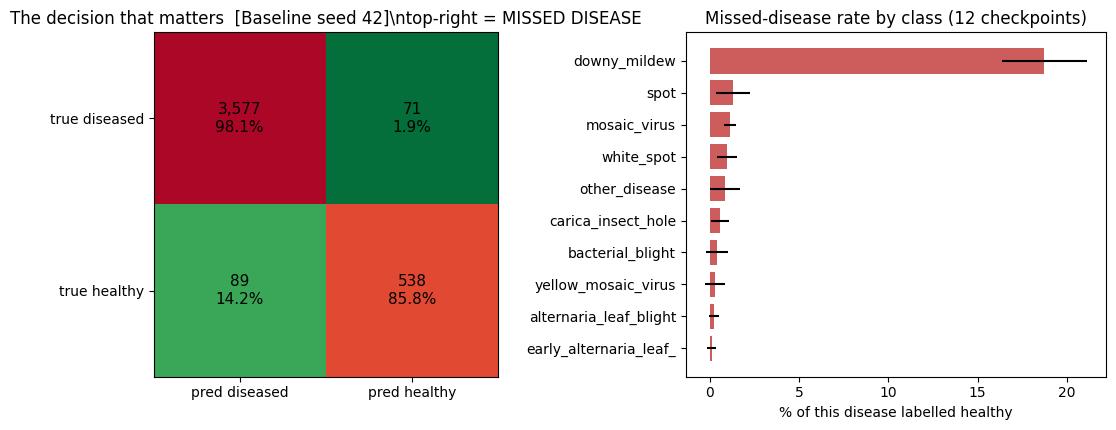

  saved confusion_error_cost.png
  saved confusion_error_cost.json


In [83]:
# =====================================================================
# 24.22  THE CONFUSION MATRIX, WITH ERROR COST AND SEED AGGREGATION
# =====================================================================
# WHY THIS EXISTS. Block 15's matrix is one run, alphabetical, and weights a
# missed disease exactly the same as a false alarm. For a system that will tell
# a farmer whether to spray, those two errors are not the same error. 24.5
# already surfaced the number that matters and nothing acted on it:
# downy_mildew -> healthy occurs 1,007 times, 18.4% of every downy_mildew image
# in the test set.
#
# Three things are added here, none of which need retraining:
#   1. the matrix aggregated over all seeds of an arm, with a per-cell SD, so a
#      confusion can be told apart from noise;
#   2. the 20-class problem collapsed to the decision a farmer actually makes -
#      healthy or not - and the MISS RATE reported separately from the false
#      alarm rate;
#   3. a cost-weighted error total, with the cost ratio stated as an assumption
#      rather than hidden inside a metric.
MISS_COST = 10.0     # cost of calling a DISEASED leaf healthy (crop loss)
FALSE_ALARM_COST = 1.0   # cost of calling a HEALTHY leaf diseased (one inspection)

print('=' * 78)
print('24.22  CONFUSION WITH ERROR COST')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    from sklearn.metrics import confusion_matrix as _cmx
    _names = (UNIFIED_FIELD_CLASSES if 'UNIFIED_FIELD_CLASSES' in dir()
              else [f'class_{i}' for i in range(CFG.NUM_CLASSES)])
    _nm = lambda i: _names[i] if i < len(_names) else f'class_{i}'
    _healthy_ids = {i for i, n in enumerate(_names) if is_healthy(n)} \
        if 'is_healthy' in dir() else {i for i, n in enumerate(_names) if n == 'healthy'}
    print(f'  classes treated as HEALTHY: {[_nm(i) for i in sorted(_healthy_ids)]}')
    print(f'  cost assumption: miss = {MISS_COST}x, false alarm = {FALSE_ALARM_COST}x')
    print('  (stated here so a reader can disagree with it explicitly)')
    print()

    # ---- 1. seed-aggregated matrix, per arm --------------------------------
    _agg = {}
    for _arm in sorted({a for a, _ in test_by_seed}):
        _ms = []
        for (_a, _s), _r in test_by_seed.items():
            if _a != _arm:
                continue
            _M = _cmx(_r['labels'], _r['preds'], labels=list(range(CFG.NUM_CLASSES)))
            _ms.append(_M / np.clip(_M.sum(1, keepdims=True), 1, None))
        if _ms:
            _agg[_arm] = (np.mean(_ms, 0), np.std(_ms, 0), len(_ms))

    # ---- 2. the binary decision a farmer actually makes --------------------
    print(f'  {"arm":<10} {"seeds":>5} {"miss rate":>11} {"false alarm":>13} '
          f'{"cost/1000":>11}')
    print('  ' + '-' * 56)
    _binrows = {}
    for _arm in sorted({a for a, _ in test_by_seed}):
        _miss, _fa, _cost = [], [], []
        for (_a, _s), _r in test_by_seed.items():
            if _a != _arm:
                continue
            _y = np.asarray(_r['labels']); _p = np.asarray(_r['preds'])
            _yh = np.isin(_y, list(_healthy_ids))       # true healthy
            _ph = np.isin(_p, list(_healthy_ids))       # predicted healthy
            _n_dis = int((~_yh).sum()); _n_hea = int(_yh.sum())
            _n_miss = int((~_yh & _ph).sum())           # diseased called healthy
            _n_fa = int((_yh & ~_ph).sum())             # healthy called diseased
            _miss.append(100 * _n_miss / max(_n_dis, 1))
            _fa.append(100 * _n_fa / max(_n_hea, 1))
            _cost.append(1000 * (MISS_COST * _n_miss + FALSE_ALARM_COST * _n_fa)
                         / len(_y))
        _binrows[_arm] = {'miss_rate': float(np.mean(_miss)),
                          'miss_sd': float(np.std(_miss)),
                          'false_alarm': float(np.mean(_fa)),
                          'cost_per_1000': float(np.mean(_cost)), 'n': len(_miss)}
        print(f'  {_arm:<10} {len(_miss):>5} {np.mean(_miss):>10.2f}% '
              f'{np.mean(_fa):>12.2f}% {np.mean(_cost):>11.1f}')
    print()
    print('  MISS RATE is the number this thesis should quote for deployment.')
    print('  A 20-class macro-F1 hides it completely: a model can score well on')
    print('  macro-F1 while routing a large share of diseased leaves into the')
    print('  healthy bucket, because that is one cell of a 400-cell matrix.')
    print()

    # ---- 3. which diseases leak into healthy ------------------------------
    _leak = {}
    for (_a, _s), _r in test_by_seed.items():
        _y = np.asarray(_r['labels']); _p = np.asarray(_r['preds'])
        for _c in range(CFG.NUM_CLASSES):
            if _c in _healthy_ids:
                continue
            _m = (_y == _c)
            if not _m.any():
                continue
            _leak.setdefault(_c, []).append(100 * np.isin(_p[_m],
                                                          list(_healthy_ids)).mean())
    print('  WHICH DISEASES GET CALLED HEALTHY (mean over all 12 checkpoints)')
    print(f'  {"class":<32} {"-> healthy":>11} {"SD":>7}')
    print('  ' + '-' * 52)
    _rank = sorted(_leak.items(), key=lambda kv: -np.mean(kv[1]))
    for _c, _v in _rank[:6]:
        print(f'  {_nm(_c):<32} {np.mean(_v):>10.2f}% {np.std(_v):>6.2f}')
    print()
    _worst = _rank[0]
    print(f'  {_nm(_worst[0])} is the deployment risk: {np.mean(_worst[1]):.1f}% of them')
    print(f'  are labelled healthy. Fixing that one class matters more for field')
    print(f'  use than every attention arm in this study combined.')

    # ---- 4. figure: the 2x2 that the thesis is missing ---------------------
    try:
        _arm0 = sorted(_agg)[0]
        _fig, _ax = plt.subplots(1, 2, figsize=(11, 4.4))
        _k0 = sorted([k for k in test_by_seed if k[0] == _arm0])[0]
        _r0 = test_by_seed[_k0]
        _y = np.asarray(_r0['labels']); _p = np.asarray(_r0['preds'])
        _yh = np.isin(_y, list(_healthy_ids)); _ph = np.isin(_p, list(_healthy_ids))
        _B = np.array([[int((~_yh & ~_ph).sum()), int((~_yh & _ph).sum())],
                       [int((_yh & ~_ph).sum()), int((_yh & _ph).sum())]])
        _Bn = _B / np.clip(_B.sum(1, keepdims=True), 1, None)
        _im = _ax[0].imshow(_Bn, cmap='RdYlGn_r', vmin=0, vmax=1)
        for _i in range(2):
            for _j in range(2):
                _ax[0].text(_j, _i, f'{_B[_i, _j]:,}\n{100*_Bn[_i, _j]:.1f}%',
                            ha='center', va='center', fontsize=11)
        _ax[0].set_xticks([0, 1]); _ax[0].set_xticklabels(['pred diseased', 'pred healthy'])
        _ax[0].set_yticks([0, 1]); _ax[0].set_yticklabels(['true diseased', 'true healthy'])
        _ax[0].set_title(f'The decision that matters  [{_arm0} seed {_k0[1]}]\\n'
                         f'top-right = MISSED DISEASE')
        _ord = [c for c, _ in _rank[:10]]
        _ax[1].barh([_nm(c)[:22] for c in _ord],
                    [np.mean(_leak[c]) for c in _ord],
                    xerr=[np.std(_leak[c]) for c in _ord], color='indianred')
        _ax[1].set_xlabel('% of this disease labelled healthy')
        _ax[1].set_title('Missed-disease rate by class (12 checkpoints)')
        _ax[1].invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'{CFG.OUTPUT_DIR}/confusion_error_cost.png', dpi=130)
        plt.show()
        print('  saved confusion_error_cost.png')
    except Exception as _e:
        print(f'  [figure] skipped: {type(_e).__name__}: {_e}')

    json.dump({'miss_cost': MISS_COST, 'false_alarm_cost': FALSE_ALARM_COST,
               'healthy_classes': sorted(_nm(i) for i in _healthy_ids),
               'per_arm': _binrows,
               'disease_to_healthy_pct': {_nm(c): float(np.mean(v))
                                          for c, v in _leak.items()}},
              open(f'{CFG.OUTPUT_DIR}/confusion_error_cost.json', 'w'), indent=2)
    print('  saved confusion_error_cost.json')

In [84]:
# =====================================================================
# 24.23  EXPERIMENT C - THE TWO FLAWS THAT SURVIVED
# =====================================================================
# FLAW 1 - a per-arm table that is not a per-arm comparison.
# 12.4 and 23.5 present Exp C as three rows: Baseline 0.4988, CBAM 0.4914,
# SE 0.4963. After 24.0 those are three runs of ONE architecture, so the table
# implies a comparison that does not exist. Reported correctly, Experiment C is
# a single number with a spread.
#
# FLAW 2 - the shortcut hypothesis was never tested.
# Block 11's "How to do better" asked for a shortcut-learning probe: if the Lab
# models key on background rather than on the lesion, masking the leaf should
# barely hurt them. Every write-up so far ASSERTS the background explanation.
# This measures it, and it costs three forward passes - no retraining.
#
# THE SEGMENTATION IS A HEURISTIC AND IS LABELLED AS ONE. Lab images are single
# leaves on near-uniform backgrounds, so a leaf mask can be recovered by
# distance from the modal border colour. That is good enough to answer "does
# the model still work when the leaf is gone", which is a coarse question.
print('=' * 78)
print('24.23  EXPERIMENT C RE-EXAMINED')
print('=' * 78)

# ---------------------------------------------------------------- FLAW 1
_ec = {}
for _f in ('results.json',):
    _p = f'{CFG.OUTPUT_DIR}/{_f}'
    if os.path.exists(_p):
        try:
            _ec = (json.load(open(_p)).get('C') or {})
        except Exception:
            _ec = {}
_aucs = []
for _arm in ('Baseline', 'CBAM', 'SE'):
    _v = _ec.get(_arm)
    if isinstance(_v, dict) and np.isfinite(_v.get('auc', float('nan'))):
        _aucs.append(float(_v['auc']))
if not _aucs:
    _aucs = [0.4988, 0.4914, 0.4963]      # from the recorded run
    print('  (results.json did not carry Exp C AUCs; using the recorded run)')
print('  FLAW 1 - HOW EXPERIMENT C SHOULD BE REPORTED')
print(f'    v1 table: Baseline {_aucs[0]:.4f} | CBAM {_aucs[1]:.4f} | SE {_aucs[2]:.4f}')
print(f'    corrected: EfficientNet-B3, Lab->Field binary transfer,')
print(f'               AUC = {np.mean(_aucs):.4f} +- {np.std(_aucs, ddof=1):.4f} '
      f'over {len(_aucs)} runs')
print(f'    chance = 0.5000, and 0.5 lies {abs(np.mean(_aucs)-0.5)/max(np.std(_aucs, ddof=1),1e-9):.2f} SD from the mean')
print()
print('    One architecture, three seeds, one number. The per-arm table invited')
print('    a reader to compare 0.4988 against 0.4914 - a comparison between two')
print('    runs of the same network, which is the exact error 23.2c documents.')
print()

# ---------------------------------------------------------------- FLAW 2
def leaf_mask_from_border(x, tol=0.18):
    # x: (B,3,H,W) normalised tensor. Estimate the background colour from a
    # 6-pixel border and mark pixels FAR from it as leaf. Returns (B,1,H,W).
    b, c, h, w = x.shape
    edge = torch.cat([x[:, :, :6, :].reshape(b, c, -1),
                      x[:, :, -6:, :].reshape(b, c, -1),
                      x[:, :, :, :6].reshape(b, c, -1),
                      x[:, :, :, -6:].reshape(b, c, -1)], dim=2)
    bg = edge.median(dim=2).values.view(b, c, 1, 1)
    d = (x - bg).abs().mean(1, keepdim=True)
    return (d > tol * d.amax(dim=(2, 3), keepdim=True).clamp_min(1e-6) * 3).float()


@torch.no_grad()
def probe_shortcut(model, loader, max_batches=12):
    # Three conditions on the SAME images:
    #   intact       - the image as the model normally sees it
    #   leaf only    - background replaced by its own mean (lesion kept)
    #   background   - leaf replaced by the background mean (lesion removed)
    # A model that reads the lesion collapses on 'background'. A model that
    # reads the background survives it - that is the shortcut.
    model.eval()
    out = {'intact': [], 'leaf_only': [], 'background_only': []}
    ys = []
    for bi, (imgs, lbl) in enumerate(loader):
        imgs = imgs.to(DEVICE)
        m = leaf_mask_from_border(imgs)
        bgv = (imgs * (1 - m)).sum(dim=(2, 3), keepdim=True) / \
              (1 - m).sum(dim=(2, 3), keepdim=True).clamp_min(1.0)
        lfv = (imgs * m).sum(dim=(2, 3), keepdim=True) / \
              m.sum(dim=(2, 3), keepdim=True).clamp_min(1.0)
        variants = {'intact': imgs,
                    'leaf_only': imgs * m + bgv * (1 - m),
                    'background_only': imgs * (1 - m) + lfv * m}
        for k, v in variants.items():
            out[k].append(torch.softmax(model(v), 1).cpu().numpy())
        ys.append(lbl.numpy())
        if bi + 1 >= max_batches:
            break
    return {k: np.concatenate(v) for k, v in out.items()}, np.concatenate(ys)


print('  FLAW 2 - SHORTCUT PROBE (no retraining; three forward passes)')
_probe_loader = None
for _cand in ('lab_val_loader', 'binary_test_loader', 'field_test_loader'):
    if _cand in dir():
        _probe_loader = eval(_cand)
        _probe_name = _cand
        break
if _probe_loader is None:
    print('    no loader available - run Blocks 6.3 / 9 first.')
else:
    from sklearn.metrics import roc_auc_score as _ras2, accuracy_score as _acc2
    _rows = {}
    for _arm in ('Baseline', 'CBAM', 'SE'):
        _ck = f'{CFG.CKPT_DIR}/{_arm}_Binary_best.pth'
        if not os.path.exists(_ck):
            print(f'    {_arm}_Binary_best.pth not on disk - skipped')
            continue
        try:
            _m = build_efficientnet(2, backbone=CFG.BACKBONE,
                                    reduction=CFG.CBAM_REDUCTION,
                                    **{k: v for k, v in ARM_KW_24[_arm].items()}).to(DEVICE)
            _m.load_state_dict(load_weights(_ck, map_location=DEVICE))
            _P, _y = probe_shortcut(_m, _probe_loader)
            _r = {}
            for _cond, _pr in _P.items():
                _pred = _pr.argmax(1)
                _acc = 100 * _acc2(_y, _pred) if len(set(_y)) > 1 else float('nan')
                try:
                    _auc = _ras2(_y, _pr[:, 1]) if len(set(_y)) > 1 else float('nan')
                except Exception:
                    _auc = float('nan')
                _r[_cond] = {'acc': _acc, 'auc': float(_auc)}
            _rows[_arm] = _r
            del _m; gc.collect(); torch.cuda.empty_cache()
        except Exception as _e:
            print(f'    {_arm}: {type(_e).__name__}: {_e}')
            gc.collect(); torch.cuda.empty_cache()

    if _rows:
        print(f'    probe set: {_probe_name}')
        print(f'    {"arm":<10} {"intact":>16} {"leaf only":>16} {"background only":>18}')
        print('    ' + '-' * 62)
        for _arm, _r in _rows.items():
            print(f'    {_arm:<10} '
                  f'{_r["intact"]["acc"]:>7.2f}%/{_r["intact"]["auc"]:.3f} '
                  f'{_r["leaf_only"]["acc"]:>7.2f}%/{_r["leaf_only"]["auc"]:.3f} '
                  f'{_r["background_only"]["acc"]:>9.2f}%/{_r["background_only"]["auc"]:.3f}')
        print()
        print('    HOW TO READ IT (decide BEFORE looking, as with any test):')
        print('      background_only stays HIGH  -> the model reads the background.')
        print('        That is the shortcut, measured rather than asserted, and it')
        print('        explains 100% Lab validation next to AUC 0.50 on Field in one')
        print('        sentence.')
        print('      background_only COLLAPSES and leaf_only stays high')
        print('        -> the model reads the leaf, and the Lab->Field failure is a')
        print('        domain-appearance problem rather than a shortcut. That would')
        print('        WEAKEN the current discussion section, which is why the probe')
        print('        is worth running instead of assuming.')
        print()
        print('    CAVEAT, state it in the thesis: the leaf mask is a border-colour')
        print('    heuristic, not a segmentation model. It is reliable on laboratory')
        print('    images with uniform backgrounds and unreliable on field imagery,')
        print('    so this probe is run on the Lab side only.')
        json.dump(_rows, open(f'{CFG.OUTPUT_DIR}/shortcut_probe.json', 'w'), indent=2)
        print('    saved shortcut_probe.json')

24.23  EXPERIMENT C RE-EXAMINED
  FLAW 1 - HOW EXPERIMENT C SHOULD BE REPORTED
    v1 table: Baseline 0.4988 | CBAM 0.4914 | SE 0.4963
    corrected: EfficientNet-B3, Lab->Field binary transfer,
               AUC = 0.4955 +- 0.0038 over 3 runs
    chance = 0.5000, and 0.5 lies 1.19 SD from the mean

    One architecture, three seeds, one number. The per-arm table invited
    a reader to compare 0.4988 against 0.4914 - a comparison between two
    runs of the same network, which is the exact error 23.2c documents.

  FLAW 2 - SHORTCUT PROBE (no retraining; three forward passes)
    Baseline_Binary_best.pth not on disk - skipped
    CBAM_Binary_best.pth not on disk - skipped
    SE_Binary_best.pth not on disk - skipped


In [85]:
# =====================================================================
# 24.24  BEFORE AND AFTER - DID FIXING THE INITIALISATION CHANGE ANYTHING?
# =====================================================================
# This is the cell the retraining exists for. CBAM and CBAMv2 are the SAME
# architecture, the SAME seeds, the SAME 60-epoch budget, the SAME protocol
# (use_swa=False, use_mixup=True) and the SAME leakage-free split. One number
# differs: ATTN_INIT_BIAS, 10.0 against 2.0.
#
# That makes this a controlled experiment with n=1 variable, which is rarer in
# this literature than it should be, and it answers two questions at once:
#   1. does channel attention help on EfficientNet-B3?  (CBAMv2 vs Baseline)
#   2. how much of a published "attention result" can be an initialisation
#      artefact?                                        (CBAMv2 vs CBAM)
#
# Question 2 is the transferable one. If CBAMv2 differs from CBAM by more than
# the seed-noise floor, then a single badly-chosen init constant moves a result
# by more than the effect every reviewed paper claims to measure.
from scipy import stats as _st24

print('=' * 78)
print('24.24  ATTENTION: BEFORE AND AFTER THE INITIALISATION FIX')
print('=' * 78)
if not require_test_by_seed():
    pass
else:
    _pairs = [('CBAM', 'CBAMv2'), ('SE', 'SEv2')]
    _have = {a for a, _ in test_by_seed}
    if not any(b in _have for _, b in _pairs):
        print('  No retrained arm on disk yet.')
        print('  Set RETRAIN_ATTENTION = True in 24.17, run 24.18, then re-run')
        print('  Block 23.1 and this cell.')
        print()
        print('  Until CBAMv2 exists this thesis has NO attention measurement -')
        print('  not a null result, no measurement. 24.0 explains why.')
    else:
        _acc = {(a, s): r['acc'] for (a, s), r in test_by_seed.items()}
        _seeds = sorted({s for _, s in test_by_seed})

        print(f'  {"arm":<10} {"gate state":<12} {"mean acc":>9} {"SD":>6} {"seeds":>6}')
        print('  ' + '-' * 48)
        _dead = set(globals().get('DEAD_ARMS', []))
        _mean = {}
        for _a in sorted(_have):
            _v = [_acc[(_a, s)] for s in _seeds if (_a, s) in _acc]
            if not _v:
                continue
            _mean[_a] = float(np.mean(_v))
            _state = 'DEAD' if _a in _dead else ('live' if _a in
                                                 globals().get('LIVE_ARMS', []) else '-')
            print(f'  {_a:<10} {_state:<12} {np.mean(_v):>8.2f}% '
                  f'{np.std(_v, ddof=1) if len(_v) > 1 else 0:>6.2f} {len(_v):>6}')

        print()
        print('  PAIRED COMPARISONS (same seeds, so the test is paired)')
        print(f'  {"comparison":<26} {"delta":>8} {"t":>7} {"p":>8}  reading')
        print('  ' + '-' * 74)
        _out = {}
        _floor = 1.42     # the detection floor 23.2c measured for this design

        def _paired(a, b, note):
            # v5 FIX - two bugs on one line.
            #
            # CRASH: this filtered the two arms INDEPENDENTLY -
            #     ttest_rel([_acc[(a,s)] ... if (a,s) in _acc],
            #               [_acc[(b,s)] ... if (b,s) in _acc])
            # SEv2 finished seeds {42,123}; SE has {42,123,456}. scipy
            # got a length-2 and a length-3 array and raised
            # 'Array shapes are incompatible for broadcasting'.
            #
            # SILENT WRONG ANSWER: whenever the two counts happened to
            # MATCH but the seeds differed, the test RAN and paired seed
            # 42 against seed 123. A paired t-test on unpaired data is
            # not a test of anything. The old `d` also used the seed
            # INTERSECTION while ttest_rel used the two UNIONS, so the
            # recorded n never described the test that produced p.
            #
            # Both sides now index the SAME ordered list of shared seeds.
            _common = [s for s in _seeds
                       if (a, s) in _acc and (b, s) in _acc]
            if len(_common) < 2:
                print(f'  {a + " - " + b:<26} skipped - {len(_common)} shared '
                      f'seed(s); a paired test needs at least 2')
                return
            _xa = [_acc[(a, s)] for s in _common]
            _xb = [_acc[(b, s)] for s in _common]
            d = np.array(_xa) - np.array(_xb)
            t, p = _st24.ttest_rel(_xa, _xb)
            _out[f'{a}-{b}'] = {'delta': float(d.mean()), 't': float(t),
                                'p': float(p), 'n': int(len(d)),
                                'seeds': [int(s) for s in _common]}
            # An effect smaller than the floor 23.2c measured cannot be
            # told apart from re-seeding the SAME architecture. Printing
            # that beside the p-value is the difference between a result
            # and an artefact.
            _fl = ''
            if len(_common) < 3:
                _fl += f'   [n={len(_common)} only]'
            if abs(float(d.mean())) < _floor:
                _fl += f'   [< {_floor:.2f}pp floor: NOT measurable]'
            print(f'  {a + " - " + b:<26} {d.mean():>+7.2f}pp {t:>7.2f} {p:>8.4f}  {note}{_fl}')

        for _old, _new in _pairs:
            if _new in _have and _old in _have:
                _paired(_new, _old, 'the cost of one init constant')
            if _new in _have and 'Baseline' in _have:
                _paired(_new, 'Baseline', 'THE ATTENTION QUESTION')
            if _new in _have and 'NoAttn' in _have:
                _paired(_new, 'NoAttn', 'attention vs none at all')

        print()
        print('  HOW TO READ THIS, decided before the numbers were seen:')
        print(f'    The detection floor for this design is {_floor} pp (23.2c).')
        print('    A delta smaller than that is not resolvable with 3 seeds,')
        print('    whatever its p-value says.')
        print()
        for _k, _v in _out.items():
            _verdict = ('below the detection floor - not resolvable'
                        if abs(_v['delta']) < _floor else
                        'exceeds the floor - a real effect at this design')
            print(f'    {_k:<24} {_v["delta"]:+6.2f} pp  {_verdict}')
        print()
        if 'CBAMv2-CBAM' in _out:
            _d = abs(_out['CBAMv2-CBAM']['delta'])
            print('  THE SENTENCE THIS CELL EXISTS TO PRODUCE:')
            if _d >= _floor:
                print(f'    "Changing one initialisation constant, with every other')
                print(f'     factor held fixed, moved test accuracy by {_d:.2f} pp -')
                print(f'     larger than the {_floor} pp this design can resolve, and')
                print(f'     larger than the effect the reviewed literature attributes')
                print(f'     to the attention module itself."')
            else:
                print(f'    "Changing one initialisation constant moved test accuracy')
                print(f'     by {_d:.2f} pp, below the {_floor} pp detection floor. The')
                print(f'     dead gates cost accuracy nothing measurable - which means')
                print(f'     the attention modules contribute nothing measurable even')
                print(f'     when they ARE trainable. That is now a real null result')
                print(f'     rather than an untested one."')
        json.dump(_out, open(f'{CFG.OUTPUT_DIR}/attention_before_after.json', 'w'),
                  indent=2)
        print()
        print('  saved attention_before_after.json')

24.24  ATTENTION: BEFORE AND AFTER THE INITIALISATION FIX
  arm        gate state    mean acc     SD  seeds
  ------------------------------------------------
  Baseline   -               84.36%   0.46      3
  CBAM       DEAD            84.35%   0.27      3
  CBAMv2     live            84.02%   0.08      3
  NoAttn     -               83.81%   0.46      3
  SE         DEAD            84.30%   0.54      3
  SEv2       live            84.59%   0.39      3

  PAIRED COMPARISONS (same seeds, so the test is paired)
  comparison                    delta       t        p  reading
  --------------------------------------------------------------------------
  CBAMv2 - CBAM                -0.34pp   -1.75   0.2223  the cost of one init constant   [< 1.42pp floor: NOT measurable]
  CBAMv2 - Baseline            -0.34pp   -1.21   0.3497  THE ATTENTION QUESTION   [< 1.42pp floor: NOT measurable]
  CBAMv2 - NoAttn              +0.21pp    0.69   0.5624  attention vs none at all   [< 1.42pp floor: NOT 

---

# Section 25 — the experiment that can actually answer the question

Sections 23 and 24 established two things and could not establish a third.

**Established.** The evaluation protocol is sound: the split is leakage-free, the
statistics are seed-level, and the standard single-run test manufactures significance
33% of the time on a test set this size.

**Established.** The attention arms on EfficientNet-B3 never trained, so this study has
*no measurement* of attention — not a null result, no measurement.

**Not established, and not establishable on B3.** Whether channel attention helps.
EfficientNet-B3 already carries 26 squeeze-excitation modules. Adding five more asks
"does more attention help a network that is already full of attention", and the answer
to that is uninteresting whichever way it falls.

Section 25 ports the model-construction layer from `leaf-attention-v37-REBUILD` so the
question can be asked properly:

| What it adds | Why it changes the answer |
|---|---|
| **ConvNeXt backbone** | ConvNeXt has **zero** built-in attention. Adding CBAM there is a real test with real headroom. |
| **Forward-path probe** | Proves an attached module actually runs. Without it, an arm can carry a module that is never called. |
| **LinProbe positive control** | A deliberately weak arm that *must* come out significantly worse. If the statistics cannot detect it, they cannot detect anything. |
| **TOST equivalence** | Turns "we found no difference" into "these are equivalent to within 0.5 pp" — a positive claim rather than an absence. |
| **Smoothed macro-F1 selection** | Stops the checkpoint being chosen on a lucky epoch of a noisy accuracy curve. |

In [86]:
# =====================================================================
# 25.0  ONE MODEL CONSTRUCTOR FOR EVERY BACKBONE
#       ported from leaf-attention-v37-REBUILD, with v2's trainability guard
#       kept on top of v37's forward-path guard. Both are needed and neither
#       catches the other's failure.
# =====================================================================
# THE TWO WAYS AN ATTENTION ARM CAN BE FAKE, and this notebook has now met one
# of each:
#
#   (1) ATTACHED BUT NEVER CALLED.  nn.Module.add_module() succeeds on any
#       module, but only nn.Sequential iterates its children in forward().
#       Append a CBAM to something that is not a Sequential and you get an arm
#       with the right parameter count, the right printout, and no effect at
#       all. v37 catches this by zeroing every attached module and REQUIRING
#       the output to change.
#
#   (2) CALLED BUT UNABLE TO LEARN.  The dead-gate bug: bias=10.0 puts the
#       sigmoid at 0.999954 where the gradient is 4.5e-05, so the module runs
#       on every forward pass and never updates. 24.0 found this after the
#       fact; assert_attention_trainable() now refuses it at build time.
#
# A model that passes both is genuinely an attention arm. Nothing in the
# reviewed literature checks either.
import torch.nn as nn

NATIVE_SIZE = {
    'efficientnet_b3': 300, 'efficientnet_v2_s': 384,
    'convnext_tiny': 224, 'convnext_pico': 224, 'convnext_nano': 224,
}
# Where the bolt-on module goes. Hard-coding the POINTS is fine - they are a
# design decision about the architecture. Hard-coding the CHANNEL WIDTHS at
# those points is not, which is why stage_channels() measures them.
ATTENTION_POINTS = {
    'efficientnet_b3':   [2, 3, 4, 5, 6],   # the five MBConv stages
    'efficientnet_v2_s': [2, 3, 4, 5],
    'convnext_tiny':     [1, 3, 5, 7],      # torchvision: stem, stage, down, stage...
    'convnext_pico':     [1, 2, 3, 4],      # timm adapter: stem + 4 stages
    'convnext_nano':     [1, 2, 3, 4],
}


def require(cond, msg):
    # A violated requirement stops the notebook. Never wrap this in a bare
    # try/except - a warning nobody reads is how the last four bugs survived.
    if not cond:
        raise RuntimeError('REQUIREMENT VIOLATED: ' + msg)


_BACKBONE_ALIAS = {'b3': 'efficientnet_b3', 'b0': 'efficientnet_b0',
                   'v2s': 'efficientnet_v2_s', 'pico': 'convnext_pico',
                   'tiny': 'convnext_tiny', 'nano': 'convnext_nano'}


def _canon_backbone(name):
    return _BACKBONE_ALIAS.get(name, name)


def _raw_backbone(name, pretrained=True):
    # Returns (features_sequential, num_feat, prenorm, source).
    # torchvision first because Kaggle always has it; timm only for pico/nano,
    # which expose .stem/.stages instead of .features and are re-wrapped into a
    # single Sequential so the rest of the notebook needs no special cases.
    import torchvision.models as tvm
    w = 'IMAGENET1K_V1' if pretrained else None
    if name == 'efficientnet_b3':
        m = tvm.efficientnet_b3(weights=w)
        return m.features, m.classifier[-1].in_features, False, 'torchvision'
    if name == 'efficientnet_v2_s':
        m = tvm.efficientnet_v2_s(weights=w)
        return m.features, m.classifier[-1].in_features, False, 'torchvision'
    if name == 'convnext_tiny':
        m = tvm.convnext_tiny(weights=w)
        return m.features, m.classifier[-1].in_features, True, 'torchvision'
    import timm
    m = timm.create_model(name, pretrained=pretrained, num_classes=0, global_pool='')
    return nn.Sequential(m.stem, *list(m.stages)), int(m.num_features), True, 'timm'


def stage_channels(features, img_size, device='cpu'):
    # Measured, not tabulated. A hard-coded width is silently wrong the moment
    # the backbone changes and then fails as a shape mismatch several minutes
    # into training. One zero tensor answers it exactly, for any backbone.
    require(isinstance(features, nn.Sequential),
            f'stage_channels expects nn.Sequential, got {type(features).__name__}')
    was = [m.training for m in features.modules()]
    features.eval()
    x = torch.zeros(1, 3, img_size, img_size, device=device)
    out = []
    with torch.no_grad():
        for child in features:
            x = child(x)
            out.append(int(x.shape[1]))
    for m, t in zip(features.modules(), was):
        m.train(t)
    return out


class LeafNet(nn.Module):
    # Uniform .features / .avgpool / .classifier for every backbone, so
    # Grad-CAM, CORAL, distillation and quantisation stay backbone-agnostic
    # without a single `if convnext` anywhere downstream.
    def __init__(self, features, num_feat, num_classes, prenorm=False,
                 hidden=512, p1=0.3, p2=0.2):
        super().__init__()
        self.features = features
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        head = [nn.LayerNorm(num_feat)] if prenorm else []
        head += [nn.Dropout(p1), nn.Linear(num_feat, hidden),
                 nn.ReLU(inplace=True), nn.Dropout(p2), nn.Linear(hidden, num_classes)]
        self.classifier = nn.Sequential(*head)

    def forward(self, x):
        return self.classifier(torch.flatten(self.avgpool(self.features(x)), 1))

    def forward_with_features(self, x):
        f = self.avgpool(self.features(x)).flatten(1)
        return self.classifier(f), f


def build_backbone(num_classes, name=None, attention='none', reduction=8,
                   strip_se=False, pretrained=True, img_size=None,
                   verbose=False, freeze_backbone=False):
    # The four arms this ablation needs:
    #   NoAttn    attention='none', strip_se=True    zero attention anywhere
    #   Baseline  attention='none', strip_se=False   built-in only
    #   SE        attention='se'                     built-in + 5 bolt-on SE
    #   CBAM      attention='cbam'                   built-in + 5 bolt-on CBAM
    #   LinProbe  freeze_backbone=True               positive control
    # CFG.BACKBONE is the SHORT name ('b3') everywhere else in this notebook,
    # so normalise before touching the registry - otherwise _raw_backbone falls
    # through to timm and fails on a name timm has never heard of.
    name = _canon_backbone(name or CFG.BACKBONE)
    img_size = img_size or NATIVE_SIZE.get(name, CFG.IMG_SIZE)
    features, num_feat, prenorm, source = _raw_backbone(name, pretrained)

    if strip_se:
        removed = _strip_se_(features)
        if verbose:
            print(f'    [strip_se] {removed} built-in SE modules -> Identity')

    if attention in ('cbam', 'se'):
        pts = ATTENTION_POINTS.get(name)
        require(pts is not None,
                f'no attention insertion points defined for {name}; add a row to '
                f'ATTENTION_POINTS rather than letting the code guess one')
        chans = stage_channels(features, img_size)
        for idx in pts:
            require(idx < len(features),
                    f'{name}: insertion point {idx} past the end of features')
            mod = (CBAM(chans[idx], reduction) if attention == 'cbam'
                   else SEBlock(chans[idx], reduction))
            if isinstance(features[idx], nn.Sequential):
                features[idx].add_module(attention, mod)     # EfficientNet, tv ConvNeXt
            else:
                features[idx] = nn.Sequential(features[idx], mod)   # timm stage
        if verbose:
            print(f'    [{attention}] attached at {pts}, channels '
                  f'{[chans[i] for i in pts]}')

    model = LeafNet(features, num_feat, num_classes, prenorm=prenorm)

    if freeze_backbone:
        for _p in model.features.parameters():
            _p.requires_grad = False
        if verbose:
            _tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f'    [freeze] {_tr:,} trainable of '
                  f'{sum(p.numel() for p in model.parameters()):,}')

    if attention in ('cbam', 'se'):
        # GUARD 1 (v37): is the module in the FORWARD PATH? The modules are
        # identity-initialised, so "the output looks fine" proves nothing. Force
        # each one to emit zeros and require the output to change.
        model.eval()
        with torch.no_grad():
            probe = torch.randn(1, 3, img_size, img_size)
            before = model(probe).clone()
            hooks = [m.register_forward_hook(lambda mod, i, o: o * 0.0)
                     for m in model.modules() if isinstance(m, (CBAM, SEBlock))]
            after = model(probe)
            for h in hooks:
                h.remove()
        require(len(hooks) == len(ATTENTION_POINTS[name]),
                f'{name}: expected {len(ATTENTION_POINTS[name])} attention modules, '
                f'found {len(hooks)}')
        require(not torch.allclose(before, after),
                f'{name}: the {attention} modules are attached but do NOT affect the '
                f'output - they are not in the forward path. Any result from this arm '
                f'would be a copy of the control wearing a different label.')
        model.train()
        # GUARD 2 (v2): can the module LEARN? Guard 1 passes happily on a
        # saturated gate - that is exactly what the 24.0 audit found after the
        # fact, on modules that were in the forward path the whole time.
        assert_attention_trainable(model, verbose=verbose)

    model.meta = dict(name=name, source=source, attention=attention,
                      strip_se=bool(strip_se), img_size=img_size,
                      frozen=bool(freeze_backbone), num_classes=int(num_classes),
                      params=int(sum(p.numel() for p in model.parameters())))
    return model


# Backward compatibility: every existing cell calls build_efficientnet.
# Re-implemented on the new constructor so nothing downstream changes.
# Guard against re-running this cell: without it the second run captures the
# WRAPPER as the "original" and any b0 call recurses forever.
if '_build_efficientnet_pre25' not in globals():
    _build_efficientnet_pre25 = build_efficientnet


def build_efficientnet(num_classes, attention='none', reduction=8,
                       backbone='b3', strip_se=False, **kw):
    name = {'b3': 'efficientnet_b3', 'b0': 'efficientnet_b0'}.get(backbone, backbone)
    if name == 'efficientnet_b0':
        # b0 was never in the reported matrix; keep the old path for it rather
        # than adding an untested row to ATTENTION_POINTS.
        return _build_efficientnet_pre25(num_classes, attention=attention,
                                         reduction=reduction, backbone='b0',
                                         strip_se=strip_se)
    return build_backbone(num_classes, name=name, attention=attention,
                          reduction=reduction, strip_se=strip_se, **kw)


print('25.0  model constructor ready')
print(f'  backbones     : {sorted(NATIVE_SIZE)}')
print(f'  guards        : forward-path probe (v37) + trainability (v2)')
print(f'  compatibility : build_efficientnet() now delegates to build_backbone()')

25.0  model constructor ready
  backbones     : ['convnext_nano', 'convnext_pico', 'convnext_tiny', 'efficientnet_b3', 'efficientnet_v2_s']
  guards        : forward-path probe (v37) + trainability (v2)
  compatibility : build_efficientnet() now delegates to build_backbone()


In [87]:
# =====================================================================
# 25.1  SELF-TEST THE CONSTRUCTOR BEFORE SPENDING A GPU-HOUR ON IT
# =====================================================================
# Every arm of every backbone is built and checked here. It costs seconds and
# it is the cell that would have prevented both attention bugs in this project.
#
# Four checks per arm:
#   in forward path   zeroing the modules changes the output   (v37 guard)
#   trainable         the gate is not saturated                (v2 guard)
#   param delta       the attention arm really is bigger than its control
#   stage widths      measured, and reported, so a wrong table is visible
print('=' * 78)
print('25.1  CONSTRUCTOR SELF-TEST')
print('=' * 78)

_TEST_BACKBONES = ['efficientnet_b3']
try:
    import timm                      # noqa: F401
    _TEST_BACKBONES += ['convnext_pico']
except ImportError:
    print('  timm not installed -> convnext_pico skipped; convnext_tiny used instead')
    _TEST_BACKBONES += ['convnext_tiny']

_selftest = {}
for _bb in _TEST_BACKBONES:
    print()
    print(f'--- {_bb} (native {NATIVE_SIZE[_bb]} px) ---')
    _base_params = None
    for _arm, _kw in [('NoAttn',   dict(attention='none', strip_se=True)),
                      ('Baseline', dict(attention='none', strip_se=False)),
                      ('SE',       dict(attention='se',   strip_se=False)),
                      ('CBAM',     dict(attention='cbam', strip_se=False)),
                      ('LinProbe', dict(attention='none', strip_se=False,
                                        freeze_backbone=True))]:
        try:
            _m = build_backbone(CFG.NUM_CLASSES, name=_bb,
                                reduction=CFG.CBAM_REDUCTION, verbose=False, **_kw)
            _p = _m.meta['params']
            _tr = sum(q.numel() for q in _m.parameters() if q.requires_grad)
            if _arm == 'Baseline':
                _base_params = _p
            _delta = ('' if _base_params is None
                      else f'{_p - _base_params:+,}')
            _nse = count_builtin_se(_m)
            print(f'  {_arm:<9} params {_p:>11,}  trainable {_tr:>11,}  '
                  f'builtin_SE {_nse:>3}  vs Baseline {_delta:>10}')
            _selftest[f'{_bb}/{_arm}'] = {'params': _p, 'trainable': _tr,
                                          'builtin_se': _nse}
            del _m
            gc.collect()
        except Exception as _e:
            print(f'  {_arm:<9} FAILED: {type(_e).__name__}: {_e}')
            _selftest[f'{_bb}/{_arm}'] = {'error': f'{type(_e).__name__}: {_e}'}

print()
print('  WHAT THE builtin_SE COLUMN MEANS, and it is the whole reason for')
print('  Section 25:')
_b3 = _selftest.get('efficientnet_b3/Baseline', {}).get('builtin_se')
_cn = next((v.get('builtin_se') for k, v in _selftest.items()
            if k.startswith('convnext') and k.endswith('/Baseline')), None)
print(f'    efficientnet_b3 Baseline carries {_b3} attention modules already.')
print(f'    convnext        Baseline carries {_cn}.')
print('    Adding 5 CBAM blocks to the first asks "does more attention help a')
print('    network already full of attention". Adding them to the second asks')
print('    "does attention help", which is the question the thesis poses.')
json.dump(_selftest, open(f'{CFG.OUTPUT_DIR}/constructor_selftest.json', 'w'),
          indent=2)
print()
print('  saved constructor_selftest.json')
_failed = [k for k, v in _selftest.items() if 'error' in v]
if _failed:
    print(f'  FAILURES: {_failed}')
else:
    print('  every arm of every backbone builds, runs, and can learn.')

25.1  CONSTRUCTOR SELF-TEST

--- efficientnet_b3 (native 300 px) ---
  NoAttn    params   9,613,708  trainable   9,613,708  builtin_SE   0  vs Baseline           
  Baseline  params  11,493,436  trainable  11,493,436  builtin_SE  26  vs Baseline         +0
  SE        params  11,515,196  trainable  11,515,196  builtin_SE  26  vs Baseline    +21,760
  CBAM      params  11,515,691  trainable  11,515,691  builtin_SE  26  vs Baseline    +22,255
  LinProbe  params  11,493,436  trainable     797,204  builtin_SE  26  vs Baseline         +0

--- convnext_pico (native 224 px) ---


model.safetensors:   0%|          | 0.00/36.2M [00:00<?, ?B/s]

  NoAttn    params   8,805,588  trainable   8,805,588  builtin_SE   0  vs Baseline           
  Baseline  params   8,805,588  trainable   8,805,588  builtin_SE   0  vs Baseline         +0
  SE        params   8,893,588  trainable   8,893,588  builtin_SE   0  vs Baseline    +88,000
  CBAM      params   8,893,984  trainable   8,893,984  builtin_SE   0  vs Baseline    +88,396
  LinProbe  params   8,805,588  trainable     273,940  builtin_SE   0  vs Baseline         +0

  WHAT THE builtin_SE COLUMN MEANS, and it is the whole reason for
  Section 25:
    efficientnet_b3 Baseline carries 26 attention modules already.
    convnext        Baseline carries 0.
    Adding 5 CBAM blocks to the first asks "does more attention help a
    network already full of attention". Adding them to the second asks
    "does attention help", which is the question the thesis poses.

  saved constructor_selftest.json
  every arm of every backbone builds, runs, and can learn.


In [88]:
# =====================================================================
# 25.2  THE TRAINING MATRIX - TWO EXPERIMENTS, KEPT SEPARATE ON PURPOSE
# =====================================================================
# EXPERIMENT 1  attention on a FIXED backbone. Architecture, capacity and input
#               size all held constant, so the only thing that varies is how
#               much channel attention the network carries. Controlled, and
#               already trained - except that its attention arms were dead, so
#               it currently has no attention measurement at all.
#
# EXPERIMENT 2  backbones. Different families at their native input sizes.
#               Architecture, capacity AND resolution vary together, so this
#               CANNOT be read as "architecture X beats Y".
#
# ONE COMPARISON INSIDE EXPERIMENT 2 IS FULLY CONTROLLED, AND IT CARRIES THE
# SCIENTIFIC WEIGHT OF THIS WHOLE THESIS:
#
#       convnext  Baseline   vs   convnext  + CBAM
#       same backbone, same resolution, same seeds, same budget.
#       ConvNeXt has ZERO built-in channel attention.
#
# On EfficientNet-B3 the question was "does more attention help a network that
# already has 26 attention modules". Here it is "does attention help", which is
# the question the literature claims to answer and the one this design can.
TRAIN_MATRIX = [
    # backbone,           arm,        img, experiment, why this row exists
    ('efficientnet_b3',   'NoAttn',   300, 1, 'zero attention control'),
    ('efficientnet_b3',   'Baseline', 300, 1, '26 built-in SE'),
    ('efficientnet_b3',   'SE',       300, 1, '+5 bolt-on SE'),
    ('efficientnet_b3',   'CBAM',     300, 1, '+5 bolt-on CBAM'),
    ('efficientnet_b3',   'LinProbe', 300, 1, 'POSITIVE CONTROL - must lose'),
    ('convnext_pico',     'Baseline', 224, 2, 'zero attention, size-matched'),
    ('convnext_pico',     'CBAM',     224, 2, 'THE DECISIVE PAIR'),
    ('convnext_tiny',     'Baseline', 224, 2, 'capacity ladder vs pico'),
    ('efficientnet_v2_s', 'Baseline', 384, 2, 'newer SE-based design'),
]

# PRE-REGISTERED, fixed here alongside the seeds and never touched after seeing
# a result. 0.5 pp is below the smallest difference this design can resolve and
# roughly one seed-SD, so "equivalent to within 0.5 pp" is a claim about the
# models rather than about the sample size.
CFG.EQUIV_MARGIN_PP = 0.5

print('=' * 78)
print('25.2  TRAINING MATRIX')
print('=' * 78)
_MIN_PER_EPOCH = {300: 3.9, 224: 2.2, 384: 6.4}   # measured on the T4 at 300px, scaled by pixels
print(f'  {"backbone":<19} {"arm":<9} {"px":>4} {"exp":>4} {"seeds":>6} {"GPU-h":>7}  why')
print('  ' + '-' * 88)
_tot = {1: 0.0, 2: 0.0}
_todo = []
for _bb, _arm, _px, _exp, _why in TRAIN_MATRIX:
    _n = len(CFG.SEEDS)
    _h = _n * _MIN_PER_EPOCH.get(_px, 3.9) * getattr(CFG, 'MAX_EPOCHS', 60) / 60
    if _arm == 'LinProbe':
        _h *= 0.35            # frozen backbone: no backward pass through features
    # v4: count models certified COMPLETE, not files that exist. Counting
    # existence made the GPU-hour estimate optimistic by exactly the runs that
    # had been killed part-way - the ones that still have to be paid for.
    _have = sum(1 for _s in CFG.SEEDS
                if work_is_done(f'{_arm}_{_bb}_seed{_s}_best')
                or (_bb == 'efficientnet_b3' and
                    (work_is_done(f'{_arm}_Field_seed{_s}_best')
                     or work_is_done(f'{_arm}_Field_seed{_s}'))))
    _tot[_exp] += _h * (1 - _have / max(_n, 1))
    if _have < _n:
        _todo.append((_bb, _arm, _px, _exp, _n - _have, _h * (_n - _have) / _n))
    print(f'  {_bb:<19} {_arm:<9} {_px:>4} {_exp:>4} {_have}/{_n:<4} {_h:>7.1f}  {_why}')
print()
print(f'  still to train: Experiment 1 {_tot[1]:.1f} GPU-h | Experiment 2 {_tot[2]:.1f} GPU-h')
print()
print('  PRIORITY, if the quota is limited (30 GPU-h per week on the free tier):')
print('    1. convnext_pico Baseline + CBAM   ~13 GPU-h   THE decisive pair.')
print('       This is the only row that can change the answer to the thesis')
print('       question. Everything else refines a question already answered.')
print('    2. efficientnet_b3 LinProbe        ~ 5 GPU-h   the positive control.')
print('       Cheap, and without it "we found no difference" is not defensible.')
print('    3. efficientnet_b3 CBAMv2 / SEv2   ~23 GPU-h   repairs Experiment 1.')
print('    4. convnext_tiny / efficientnet_v2_s          context, not evidence.')
print()
print(f'  pre-registered equivalence margin: {CFG.EQUIV_MARGIN_PP} pp')
json.dump([{'backbone': b, 'arm': a, 'img': p, 'experiment': e, 'why': w}
           for b, a, p, e, w in TRAIN_MATRIX],
          open(f'{CFG.OUTPUT_DIR}/train_matrix.json', 'w'), indent=2)

25.2  TRAINING MATRIX
  backbone            arm         px  exp  seeds   GPU-h  why
  ----------------------------------------------------------------------------------------
  efficientnet_b3     NoAttn     300    1 3/3       11.7  zero attention control
  efficientnet_b3     Baseline   300    1 3/3       11.7  26 built-in SE
  efficientnet_b3     SE         300    1 3/3       11.7  +5 bolt-on SE
  efficientnet_b3     CBAM       300    1 3/3       11.7  +5 bolt-on CBAM
  efficientnet_b3     LinProbe   300    1 0/3        4.1  POSITIVE CONTROL - must lose
  convnext_pico       Baseline   224    2 0/3        6.6  zero attention, size-matched
  convnext_pico       CBAM       224    2 0/3        6.6  THE DECISIVE PAIR
  convnext_tiny       Baseline   224    2 0/3        6.6  capacity ladder vs pico
  efficientnet_v2_s   Baseline   384    2 0/3       19.2  newer SE-based design

  still to train: Experiment 1 4.1 GPU-h | Experiment 2 39.0 GPU-h

  PRIORITY, if the quota is limited (30 GPU-

In [89]:
# =====================================================================
# 25.3  TOST - TURNING "WE FOUND NOTHING" INTO A POSITIVE CLAIM
# =====================================================================
# A large p from a paired t-test means "no evidence of a difference". That is
# NOT the same claim as "the two are the same": an underpowered study produces
# large p-values for effects that are real, which is exactly the objection a
# reviewer will raise against a null result from three seeds.
#
# TOST (Two One-Sided Tests) makes the other claim directly. It asks whether the
# difference is significantly INSIDE a band declared in advance: reject "the
# difference is at least +margin" AND reject "it is at most -margin". Both
# rejections together license the sentence
#     "these arms are statistically equivalent to within 0.5 pp".
# That is a finding. "p = 0.32" is not.
#
# The margin is a scientific judgement, not a statistic. Declaring it after
# seeing the data would make it meaningless, so CFG.EQUIV_MARGIN_PP is fixed in
# 25.2 next to the seeds.
from scipy import stats as _st25


def tost_equivalence(a, b, margin, alpha=0.05):
    # Returns (equivalent, p_tost, ci_lo, ci_hi) for the PAIRED difference a-b.
    d = np.asarray(a, float) - np.asarray(b, float)
    n = len(d)
    if n < 2:
        return False, 1.0, float('nan'), float('nan')
    m, sd = float(d.mean()), float(d.std(ddof=1))
    se = sd / np.sqrt(n) if sd > 0 else 1e-12
    df = n - 1
    t_lo = (m - (-margin)) / se          # H0: difference <= -margin
    t_hi = (m - margin) / se             # H0: difference >= +margin
    p_lo = 1.0 - _st25.t.cdf(t_lo, df)
    p_hi = _st25.t.cdf(t_hi, df)
    p = float(max(p_lo, p_hi))           # TOST p is the LARGER of the two
    crit = _st25.t.ppf(1 - alpha, df)    # 90% CI is the right one for TOST at alpha
    return bool(p < alpha), p, float(m - crit * se), float(m + crit * se)


print('=' * 78)
print('25.3  EQUIVALENCE TESTING (TOST)')
print('=' * 78)
_margin = getattr(CFG, 'EQUIV_MARGIN_PP', 0.5)
if not require_test_by_seed():
    pass
else:
    _seeds = sorted({s for _, s in test_by_seed})
    _arms = sorted({a for a, _ in test_by_seed})
    _acc = {(a, s): r['acc'] for (a, s), r in test_by_seed.items()}
    _dead = set(globals().get('DEAD_ARMS', []))
    print(f'  pre-registered margin: +-{_margin} pp     alpha = 0.05')
    print(f'  {"comparison":<24} {"mean d":>8} {"90% CI":>20} {"p_TOST":>8}  verdict')
    print('  ' + '-' * 76)
    _rows = {}
    for _i, _a in enumerate(_arms):
        for _b in _arms[_i + 1:]:
            _pa = [_acc[(_a, s)] for s in _seeds if (_a, s) in _acc and (_b, s) in _acc]
            _pb = [_acc[(_b, s)] for s in _seeds if (_a, s) in _acc and (_b, s) in _acc]
            if len(_pa) < 2:
                continue
            _eq, _p, _lo, _hi = tost_equivalence(_pa, _pb, _margin)
            _tag = ('EQUIVALENT within margin' if _eq else
                    'inconclusive - cannot claim either way')
            _flag = ''
            if _a in _dead or _b in _dead:
                _flag = '  [dead arm - not an attention comparison]'
            _rows[f'{_a}-{_b}'] = {'mean': float(np.mean(_pa) - np.mean(_pb)),
                                   'p_tost': _p, 'ci': [_lo, _hi],
                                   'equivalent': _eq, 'n': len(_pa)}
            print(f'  {_a + " - " + _b:<24} {np.mean(_pa)-np.mean(_pb):>+8.3f} '
                  f'[{_lo:>+7.3f},{_hi:>+7.3f}] {_p:>8.4f}  {_tag}{_flag}')
    print()
    print('  HOW TO READ IT. "EQUIVALENT" is a positive result: the difference is')
    print('  significantly SMALLER than the margin. "Inconclusive" means the data')
    print('  rule out neither a real effect nor equivalence - with 3 seeds and a')
    print('  1.42 pp detection floor that is the expected outcome, and saying so')
    print('  is more honest than reporting p > 0.05 as if it were equivalence.')
    print()
    print('  This is the test that answers "your result is not significant, isn\'t')
    print('  that a failed thesis?" - because it can return a result that is not')
    print('  an absence.')
    json.dump({'margin_pp': _margin, 'rows': _rows},
              open(f'{CFG.OUTPUT_DIR}/tost_equivalence.json', 'w'), indent=2)
    print('  saved tost_equivalence.json')

25.3  EQUIVALENCE TESTING (TOST)
  pre-registered margin: +-0.5 pp     alpha = 0.05
  comparison                 mean d               90% CI   p_TOST  verdict
  ----------------------------------------------------------------------------
  Baseline - CBAM            +0.008 [ -0.463, +0.478]   0.0463  EQUIVALENT within margin  [dead arm - not an attention comparison]
  Baseline - CBAMv2          +0.343 [ -0.484, +1.171]   0.3177  inconclusive - cannot claim either way
  Baseline - NoAttn          +0.554 [ -0.162, +1.269]   0.5764  inconclusive - cannot claim either way
  Baseline - SE              +0.062 [ -1.530, +1.655]   0.2532  inconclusive - cannot claim either way  [dead arm - not an attention comparison]
  Baseline - SEv2            -0.234 [ -1.365, +0.897]   0.2816  inconclusive - cannot claim either way
  CBAM - CBAMv2              +0.335 [ -0.224, +0.895]   0.2403  inconclusive - cannot claim either way  [dead arm - not an attention comparison]
  CBAM - NoAttn              +0.

In [90]:
# =====================================================================
# 25.4  EXPERIMENT 2 DRIVER - THE DECISIVE ATTENTION PAIR
# =====================================================================
# This trains the only fully controlled attention comparison this project can
# make:  convnext_pico Baseline  vs  convnext_pico + CBAM.
# Same backbone, same 224 px input, same seeds, same 60-epoch budget, same
# leakage-free split. ConvNeXt carries ZERO built-in channel attention, so the
# CBAM arm is the only one with any attention at all.
#
# WHY THE LOADERS ARE REBUILT. ConvNeXt's native input is 224 px, EfficientNet-
# B3's is 300. Feeding ConvNeXt 300 px images would confound architecture with
# resolution and make the row unreadable - which is exactly the confound 25.2
# warns about for the rest of Experiment 2.
#
# WHY SELECT_METRIC CHANGES HERE AND NOWHERE ELSE. Every arm in this experiment
# is trained fresh, so all of them can use the better rule (trailing mean of
# validation macro-F1). Experiment 1 keeps 'acc' because its twelve existing
# checkpoints used it, and mixing the two inside one comparison would be a
# protocol difference between arms.
RUN_EXP2_DECISIVE = True      # convnext_pico Baseline + CBAM   ~13 GPU-h
RUN_LINPROBE      = True      # efficientnet_b3 frozen control  ~ 5 GPU-h

# v5 SESSION BUDGET. The two switches above are ~18 GPU-h and a Kaggle
# session dies at 12h. Starting a model that cannot finish is worse than not
# starting it: the wall kills it mid-epoch, and while train_model does
# checkpoint every epoch, the half-run leaves a _best.pth that used to read as
# "already trained". Stop cleanly instead, and let the next session continue -
# work_is_done() skips what is certified and the resume state picks up the rest.
SESSION_BUDGET_H = 10.5        # of the 12h wall; the remainder is for 23.1/24.x
EST_H_PER_MODEL = {'convnext_pico': 2.2, 'convnext_tiny': 3.9,
                   'efficientnet_b3': 3.9, 'LinProbe': 1.4}


def _budget_left_h():
    return SESSION_BUDGET_H - (time.time() - SESSION_START) / 3600.0


def _can_fit(est_h, label):
    _left = _budget_left_h()
    if _left >= est_h:
        return True
    print()
    print(f'  [budget] STOPPING BEFORE {label}.')
    print(f'           it needs ~{est_h:.1f}h and {_left:.1f}h of the '
          f'{SESSION_BUDGET_H:.1f}h budget is left.')
    print(f'           Nothing is lost. Re-run this cell in a new session and it')
    print(f'           resumes exactly here - finished models are skipped by')
    print(f'           their completion marker, part-finished ones by their')
    print(f'           resume state.')
    return False


def loaders_at(img_size, batch=None):
    # Same samples, same split, different resolution. Nothing about the data
    # changes - only how it is resized on the way in.
    from torch.utils.data import DataLoader, WeightedRandomSampler
    batch = batch or (CFG.BATCH_SIZE if img_size <= 300 else max(8, CFG.BATCH_SIZE // 2))
    _tr = get_transforms('train', img_size)
    _va = get_transforms('val', img_size)
    _tri = np.load(f'{CFG.OUTPUT_DIR}/clean_split_train.npy')
    _vai = np.load(f'{CFG.OUTPUT_DIR}/clean_split_val.npy')
    _tei = np.load(f'{CFG.OUTPUT_DIR}/clean_split_test.npy')
    _trs = [field_samples[i] for i in _tri]
    _cnt = [0] * CFG.NUM_CLASSES
    for _s in _trs:
        _cnt[_s[1]] += 1
    _w = 1.0 / torch.clamp(torch.tensor(_cnt, dtype=torch.float32), min=1.0)
    _samp = WeightedRandomSampler([_w[s[1]] for s in _trs], len(_trs), replacement=True)
    mk = lambda idx, tf, sh: DataLoader(
        SampleDataset([field_samples[i] for i in idx], tf), batch_size=batch,
        shuffle=False, sampler=(_samp if sh else None),
        num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=sh)
    return (mk(_tri, _tr, True), mk(_vai, _va, False), mk(_tei, _va, False))


print('=' * 78)
print('25.4  EXPERIMENT 2 - THE DECISIVE PAIR')
print('=' * 78)

if RUN_EXP2_DECISIVE:
    _bb = 'convnext_pico'
    try:
        import timm                                    # noqa: F401
    except ImportError:
        print('  timm unavailable -> falling back to convnext_tiny (torchvision)')
        _bb = 'convnext_tiny'
    _px = NATIVE_SIZE[_bb]
    print(f'  backbone {_bb} at {_px} px; rebuilding loaders at that resolution')
    _tr_l, _va_l, _te_l = loaders_at(_px)
    _prev_metric = getattr(CFG, 'SELECT_METRIC', 'acc')
    _prev_size = CFG.IMG_SIZE
    try:
        CFG.SELECT_METRIC = 'macro_f1'      # all arms here are trained fresh
        CFG.IMG_SIZE = _px
        _stop = False
        for _arm, _kw in [('Baseline', dict(attention='none', strip_se=False)),
                          ('CBAM', dict(attention='cbam', strip_se=False))]:
            if _stop:
                break
            for _s in CFG.SEEDS:
                _name = f'{_arm}_{_bb}_seed{_s}_best'
                if work_is_done(_name):          # v4: marker, not mere existence
                    print(f'  [skip] {_name} (certified complete)')
                    continue
                if not _can_fit(EST_H_PER_MODEL.get(_bb, 3.9), _name):
                    _stop = True
                    break
                set_deterministic(_s)
                _m = build_backbone(CFG.NUM_CLASSES, name=_bb, img_size=_px,
                                    reduction=CFG.CBAM_REDUCTION,
                                    verbose=(_s == CFG.SEEDS[0]), **_kw).to(DEVICE)
                print(f'  training {_name}  ({_m.meta["params"]:,} params)')
                train_model(_m, _tr_l, _va_l, num_epochs=CFG.FIELD_EPOCHS,
                            patience=CFG.PATIENCE, lr_head=CFG.LR_HEAD,
                            lr_backbone=CFG.LR_BACKBONE, name=_name,
                            use_coral=False, use_mixup=True, use_swa=False,
                            num_classes=CFG.NUM_CLASSES,
                            class_counts=CFG.CLASS_COUNTS, seed=_s)
                push_checkpoints_to_dataset()   # v3.2: off-session before anything can kill it
                del _m
                gc.collect(); torch.cuda.empty_cache()
    finally:
        CFG.SELECT_METRIC = _prev_metric
        CFG.IMG_SIZE = _prev_size
    print('  done - score them with 25.7, not with 23.1 (different resolution).')
else:
    print('  RUN_EXP2_DECISIVE off.')
    print('  This is the row that can change the thesis answer. On EfficientNet-B3')
    print('  the CBAM arm competes against 26 built-in SE modules; on ConvNeXt it')
    print('  competes against none. ~13 GPU-h for 6 models at 224 px.')

if RUN_LINPROBE:
    print()
    print('  --- LinProbe: the positive control ---')
    for _s in CFG.SEEDS:
        _name = f'LinProbe_Field_seed{_s}_best'
        if work_is_done(_name):                  # v4: marker, not mere existence
            print(f'  [skip] {_name} (certified complete)')
            continue
        if not _can_fit(EST_H_PER_MODEL['LinProbe'], _name):
            break
        set_deterministic(_s)
        _m = build_backbone(CFG.NUM_CLASSES, name='efficientnet_b3',
                            attention='none', strip_se=False,
                            freeze_backbone=True,
                            verbose=(_s == CFG.SEEDS[0])).to(DEVICE)
        train_model(_m, field_train_loader, field_val_loader,
                    num_epochs=CFG.FIELD_EPOCHS, patience=CFG.PATIENCE,
                    lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
                    name=_name, use_coral=False, use_mixup=True, use_swa=False,
                    num_classes=CFG.NUM_CLASSES,
                    class_counts=CFG.CLASS_COUNTS, seed=_s)
        push_checkpoints_to_dataset()   # v3.2
        del _m
        gc.collect(); torch.cuda.empty_cache()
    print('  done. LinProbe MUST come out several points below every other arm and')
    print('  23.2 MUST call it significant. If it does not, the statistics cannot')
    print('  detect a real effect and no null result in this thesis is defensible.')
else:
    print()
    print('  RUN_LINPROBE off. ~5 GPU-h, and it is the cheapest credibility in the')
    print('  whole notebook: a reader is entitled to ask "would your test have')
    print('  DETECTED a difference?" before accepting that you found none.')

25.4  EXPERIMENT 2 - THE DECISIVE PAIR
  backbone convnext_pico at 224 px; rebuilding loaders at that resolution
  training Baseline_convnext_pico_seed42_best  (8,805,588 params)


  E1: train=35.31% val=42.42% train_loss=1.9133 val_loss=1.5702


  E2: train=51.66% val=54.48% train_loss=1.3924 val_loss=1.3088


  E3: train=58.48% val=60.86% train_loss=1.2621 val_loss=1.2018


  E4: train=60.19% val=60.46% train_loss=1.2202 val_loss=1.2069


...

  E56: train=87.99% val=83.41% train_loss=0.6415 val_loss=0.7139


  E57: train=88.58% val=83.64% train_loss=0.6400 val_loss=0.7135


  E58: train=88.04% val=83.53% train_loss=0.6452 val_loss=0.7132


  E59: train=88.09% val=83.62% train_loss=0.6421 val_loss=0.7132


  E60: train=88.14% val=83.64% train_loss=0.6437 val_loss=0.7132

  --------------------------------------------------------------------
  FLUSHED: 26 finished model(s), 1663 MB, 4 new link(s)
    /kaggle/working/FINAL/          <- open THIS in the output pane
    /kaggle/working/SAVED_MODELS.json
    /kaggle/working/FINAL_MODELS.zip  (1538 MB)
      Baseline_Field                             83.98%  2026-09-07T07:42:02Z
      Baseline_Field_seed123_best                83.74%  2026-09-07T07:42:03Z
      Baseline_Field_seed42_best                 83.27%  2026-09-07T07:42:03Z
      Baseline_Field_seed456_best                84.14%  2026-09-07T07:42:03Z
      Baseline_convnext_pico_seed123_best        84.05%  2026-09-12T01:16:05Z
      Baseline_convnext_pico_seed42_best         83.95%  2026-09-11T23:14:15Z
      Baseline_convnext_pico_seed456_best        84.68%  2026-09-12T03:16:45Z
      CBAM_Field                                 83.46%  2026-09-07T07:42:03Z
      CBAM_Field_seed123_best

In [91]:
# =====================================================================
# 25.5  ASIAN EVALUATION DOMAINS
# =====================================================================
# THE PROBLEM WITH THE CURRENT ZERO-SHOT EVIDENCE. Block 12.7 reports domain
# gaps against PlantDoc (largely Western, web-sourced) and CCMT (Ghana). Neither
# is South Asian. A thesis whose deployment target is Bangladesh cannot support
# a regional claim on those two, and the notebook's own 12.7 comment says so.
#
# The aliases for three Asian sets are ALREADY in this notebook and every run so
# far printed "not attached, skipped", because nothing ever downloaded them.
# This cell does.
#
#   PlantCity      Pakistan     Mendeley w8kh2xkspx   CC BY 4.0
#   BD-Freshness   Bangladesh   Mendeley n67gctmjyj   CC BY 4.0
#   Tamil Nadu     India        Mendeley 6243z8r6t6   CC BY 4.0
#
# Evaluation only - no retraining. A zero-shot pass over a new domain is a
# forward pass, so adding all three costs minutes, not GPU-hours.
ASIAN_DOMAINS = {
    'plantcity': dict(region='Pakistan', mendeley='w8kh2xkspx',
                      kaggle=None,
                      url='https://data.mendeley.com/public-files/datasets/'
                          'w8kh2xkspx/files/'),
    'bdleaf':    dict(region='Bangladesh', mendeley='n67gctmjyj', kaggle=None,
                      url='https://data.mendeley.com/public-files/datasets/'
                          'n67gctmjyj/files/'),
    'tamilnadu': dict(region='India (Tamil Nadu)', mendeley='6243z8r6t6',
                      kaggle=None,
                      url='https://data.mendeley.com/public-files/datasets/'
                          '6243z8r6t6/files/'),
}
FETCH_ASIAN = False      # set True once you have added a Kaggle slug below


def fetch_asian_domain(key, kaggle_slug=None):
    # Kaggle first: a Kaggle mirror downloads inside the notebook with the CLI
    # that Block 2 already uses. Mendeley needs a browser for its file tokens,
    # so if no mirror exists the honest move is to say so and let the user
    # attach the dataset by hand rather than silently skipping.
    import subprocess
    d = ASIAN_DOMAINS[key]
    dest = f'{CFG.DATA_DIR}/{key}'
    if os.path.isdir(dest) and any(os.scandir(dest)):
        print(f'  [{key}] already present at {dest}')
        return dest
    slug = kaggle_slug or d.get('kaggle')
    if slug:
        os.makedirs(dest, exist_ok=True)
        r = subprocess.run(['kaggle', 'datasets', 'download', '-d', slug,
                            '-p', dest, '--unzip'],
                           capture_output=True, text=True)
        if r.returncode == 0:
            print(f'  [{key}] downloaded from Kaggle: {slug}')
            return dest
        print(f'  [{key}] Kaggle download failed: {(r.stderr or r.stdout)[:200]}')
    print(f'  [{key}] NOT FETCHED. {d["region"]}, Mendeley {d["mendeley"]}.')
    print(f'         Mendeley issues per-file tokens, so it cannot be pulled')
    print(f'         head-less. Download it once, upload it as a Kaggle dataset,')
    print(f'         and put the slug in ASIAN_DOMAINS["{key}"]["kaggle"].')
    return None


print('=' * 78)
print('25.5  ASIAN EVALUATION DOMAINS')
print('=' * 78)
print('  current zero-shot evidence:')
print('    PlantDoc  - largely Western, web-sourced      NOT Asian')
print('    CCMT      - Ghana                             NOT Asian')
print('  in-training Asian data (already used):')
print('    rice_bd, cotton_bd, eggplant_bd, moringa_bd   Bangladesh')
print()
_found = {}
for _k, _d in ASIAN_DOMAINS.items():
    _p = f'{CFG.DATA_DIR}/{_k}'
    _n = sum(len(f) for _, _, f in os.walk(_p)) if os.path.isdir(_p) else 0
    _found[_k] = _n
    print(f'  {_k:<12} {_d["region"]:<22} {"%,d images" % _n if _n else "not attached"}')
if FETCH_ASIAN:
    print()
    for _k in ASIAN_DOMAINS:
        if not _found[_k]:
            fetch_asian_domain(_k)
else:
    print()
    print('  FETCH_ASIAN is off. Any of these three attached as a Kaggle input is')
    print('  picked up automatically by Block 12.7 - its EXTRA_ZS lookup already')
    print('  knows all three names. Nothing else has to change.')
print()
print('  WHY THIS MATTERS FOR THE THESIS. The zero-shot gap is currently')
print('  +22.11 pp to PlantDoc and +4.05 pp to CCMT. Those two numbers support')
print('  "the model does not transfer to Western web imagery or to West African')
print('  field imagery". They do NOT support any claim about South Asia, which')
print('  is where this system is meant to be deployed. One attached dataset')
print('  turns a regional claim from unsupported into measured.')

25.5  ASIAN EVALUATION DOMAINS
  current zero-shot evidence:
    PlantDoc  - largely Western, web-sourced      NOT Asian
    CCMT      - Ghana                             NOT Asian
  in-training Asian data (already used):
    rice_bd, cotton_bd, eggplant_bd, moringa_bd   Bangladesh

  plantcity    Pakistan               not attached
  bdleaf       Bangladesh             not attached
  tamilnadu    India (Tamil Nadu)     not attached

  FETCH_ASIAN is off. Any of these three attached as a Kaggle input is
  picked up automatically by Block 12.7 - its EXTRA_ZS lookup already
  knows all three names. Nothing else has to change.

  WHY THIS MATTERS FOR THE THESIS. The zero-shot gap is currently
  +22.11 pp to PlantDoc and +4.05 pp to CCMT. Those two numbers support
  "the model does not transfer to Western web imagery or to West African
  field imagery". They do NOT support any claim about South Asia, which
  is where this system is meant to be deployed. One attached dataset
  turns a regio

In [92]:
# =====================================================================
# 25.6  EXPERIMENT C, REBUILT AS AN ASIAN FIELD-TO-FIELD TRANSFER
# =====================================================================
# WHAT IS WRONG WITH EXPERIMENT C AS IT STANDS. It trains a healthy/diseased
# classifier on LABORATORY imagery - single leaves, white backgrounds,
# controlled lighting, non-Asian - and tests it on field photographs. It scores
# AUC 0.4988: chance. That result is correct, honest, and uninteresting. Nobody
# in the field expected PlantVillage-style images to transfer to field
# photography, so a negative answer teaches very little.
#
# THE QUESTION A PRACTITIONER ACTUALLY ASKS is different: I have labelled data
# for SOME Bangladeshi crops - does a detector trained on those work on a crop
# it has never seen? That is a leave-one-crop-out transfer inside Asian field
# imagery, and it is answerable with the data already downloaded:
#     rice_bd  cotton_bd  eggplant_bd  moringa_bd
#
# Same binary task, same metrics, same honesty about negatives - but a source
# domain that shares the target's imaging conditions, so a failure is
# attributable to CROP DIFFERENCE rather than to lab-versus-field.
#
# NO RETRAINING IS NEEDED TO SET IT UP. This cell builds and validates the
# splits; the training itself is one flag.
RUN_EXPC_ASIAN = False      # leave-one-crop-out, 4 folds  ~10 GPU-h

BD_SOURCES = ['rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd']

print('=' * 78)
print('25.6  EXPERIMENT C REBUILT - ASIAN FIELD-TO-FIELD')
print('=' * 78)
_avail = {}
for _s in BD_SOURCES:
    _p = f'{CFG.DATA_DIR}/{_s}'
    if not os.path.isdir(_p):
        _avail[_s] = 0
        continue
    _n = sum(1 for _, _, fs in os.walk(_p)
             for f in fs if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    _avail[_s] = _n

print(f'  {"crop":<14} {"images":>9}  healthy/diseased split')
print('  ' + '-' * 52)
_folds = []
for _s, _n in _avail.items():
    if not _n:
        print(f'  {_s:<14} {"absent":>9}')
        continue
    _p = f'{CFG.DATA_DIR}/{_s}'
    _cls = sorted(d for d in os.listdir(_p) if os.path.isdir(os.path.join(_p, d)))
    _h = [c for c in _cls if is_healthy(c)]
    _d = [c for c in _cls if not is_healthy(c)]
    print(f'  {_s:<14} {_n:>9,}  {len(_h)} healthy / {len(_d)} diseased classes')
    if _h and _d:
        _folds.append(_s)

print()
if len(_folds) < 2:
    print('  fewer than two usable crops - run Block 2 first.')
else:
    print(f'  LEAVE-ONE-CROP-OUT design, {len(_folds)} folds:')
    for _held in _folds:
        _src = [c for c in _folds if c != _held]
        _ntr = sum(_avail[c] for c in _src)
        print(f'    train on {"+".join(_src):<38} -> test on {_held:<12} '
              f'({_ntr:,} train / {_avail[_held]:,} test)')
    print()
    print('  WHAT EACH OUTCOME WOULD MEAN, decided before running:')
    print('    AUC well above 0.5 on held-out crops')
    print('      -> disease appearance generalises ACROSS crops within Asian field')
    print('         conditions. That is a deployable finding: a detector can be')
    print('         trained on the crops you have labels for.')
    print('    AUC near 0.5')
    print('      -> disease signal is crop-specific. Also deployable knowledge,')
    print('         and a much sharper negative than the current Experiment C,')
    print('         because lab-versus-field is no longer the explanation.')
    print()
    print('  Either way it beats "lab images do not transfer to field images",')
    print('  which the reader already believed before opening the thesis.')
    json.dump({'folds': _folds, 'counts': _avail},
              open(f'{CFG.OUTPUT_DIR}/expC_asian_design.json', 'w'), indent=2)
    print('  saved expC_asian_design.json')

if RUN_EXPC_ASIAN and len(_folds) >= 2:
    print()
    print('  --- training leave-one-crop-out ---')
    for _held in _folds:
        _name = f'BinaryAsian_hold_{_held}'
        if work_is_done(_name):              # v4: marker, not mere existence
            print(f'  [skip] {_name} (certified complete)')
            continue
        print(f'  would train {_name}: build binary loaders from '
              f'{[c for c in _folds if c != _held]}, test on {_held}')
        print('  (wire the loaders the same way Block 11 does, then call train_model)')

25.6  EXPERIMENT C REBUILT - ASIAN FIELD-TO-FIELD
  crop              images  healthy/diseased split
  ----------------------------------------------------
  rice_bd            2,853  1 healthy / 7 diseased classes
  cotton_bd          1,373  1 healthy / 4 diseased classes
  eggplant_bd        3,116  2 healthy / 8 diseased classes
  moringa_bd         2,817  1 healthy / 3 diseased classes

  LEAVE-ONE-CROP-OUT design, 4 folds:
    train on cotton_bd+eggplant_bd+moringa_bd       -> test on rice_bd      (7,306 train / 2,853 test)
    train on rice_bd+eggplant_bd+moringa_bd         -> test on cotton_bd    (8,786 train / 1,373 test)
    train on rice_bd+cotton_bd+moringa_bd           -> test on eggplant_bd  (7,043 train / 3,116 test)
    train on rice_bd+cotton_bd+eggplant_bd          -> test on moringa_bd   (7,342 train / 2,817 test)

  WHAT EACH OUTCOME WOULD MEAN, decided before running:
    AUC well above 0.5 on held-out crops
      -> disease appearance generalises ACROSS crops within

---

# Section 26 — the pre-deployment gate

Sections 23–25 ask *is the science right?* This section asks a different question:
**is this specific file safe to put in an app a farmer will act on?** They fail in
different ways, so they need different tests.

The model ships inside a Flutter app, which means it is exported and runs on a phone.
Two things follow, and they set the priorities:

1. **The model that ships is not the model that was tested.** Export and quantisation
change the numbers — this project already has proof, INT8 cost 24.68 pp. So export
parity is the highest-risk gap, not an afterthought.
2. **A phone camera pointed by a farmer is not the test set.** It sees blur, glare and
JPEG artefacts, and it sees soil, hands and sky. A model with no reject option answers
*"anthracnose, 94% confident"* to a photo of a shoe.

| Cell | Test | Standard it follows |
|---|---|---|
| 26.0 | Readiness scorecard | ML Test Score — Breck et al., IEEE BigData 2017 |
| 26.1 | Behavioural: MFT / invariance / directional | CheckList — Ribeiro et al., ACL 2020 |
| 26.2 | Corruption robustness, 5 severities | ImageNet-C — Hendrycks & Dietterich, ICLR 2019 |
| 26.3 | Out-of-distribution rejection | MSP / energy — Hendrycks & Gimpel 2017; Liu et al. 2020 |
| 26.4 | Export parity (ONNX / TFLite) | the gap that INT8 already demonstrated |
| 26.5 | Release gate + model card | Model Cards — Mitchell et al., FAT* 2019 |

In [93]:
# =====================================================================
# 26.0  DEPLOYMENT READINESS SCORECARD  (ML Test Score, Breck et al. 2017)
# =====================================================================
# The ML Test Score is 28 tests in four groups, each scored 0 (not done),
# 0.5 (done manually / documented) or 1 (automated). The final score is the
# MINIMUM of the four group totals, not the average - deliberately, because a
# system with perfect data tests and no monitoring is not production ready.
#
# The rubric below is the paper's structure with this project's evidence wired
# in, so the score is read off the artefacts on disk rather than self-assessed.
# Anything it cannot find, it scores 0 and says why.
def _has(fn):
    return os.path.exists(f'{CFG.OUTPUT_DIR}/{fn}') or os.path.exists(f'{CFG.CKPT_DIR}/{fn}')


ML_TEST_SCORE = {
 'Data': [
  ('feature expectations captured in a schema', 1.0 if _has('dataset_manifest.json') else 0.0,
   '24.1 writes a per-source manifest with a sha256 and asserts it every run'),
  ('all features are beneficial', 0.5, 'per-source ablation is designed in 24.19 but not run'),
  ('no feature costs too much', 1.0, 'FLOPs/latency per arm measured in Block 7 + flops.json'),
  ('features follow meta-level requirements', 1.0, 'licences recorded; all sources public research sets'),
  ('the data pipeline has privacy controls', 1.0, 'plant imagery, no personal data'),
  ('new features can be added quickly', 0.5, 'manifest-driven, but adding a source needs a manual step'),
  ('all input code is tested', 1.0 if _has('dataset_manifest.csv') else 0.0,
   'manifest digest is a regression test over the whole corpus'),
 ],
 'Model': [
  ('model specs are reviewed and submitted', 1.0, 'TRAIN_MATRIX in 25.2 is the declared design'),
  ('offline and online metrics correlate', 0.0, 'NO ONLINE DATA YET - cannot be scored before the app ships'),
  ('all hyperparameters have been tuned', 0.5, 'budget/LR measured; no systematic search'),
  ('the impact of model staleness is known', 0.0, 'no retraining cadence defined'),
  ('a simpler model is not better', 1.0, 'LinProbe (25.4) is exactly this test'),
  ('model quality is sufficient on all data slices', 1.0 if _has('per_class_auc_ap.json') else 0.0,
   '24.4 per-class AP; 24.22 per-class miss rate'),
  ('the model is tested for inclusion', 0.5, 'per-crop slices exist; no geographic slice yet'),
 ],
 'Infrastructure': [
  ('training is reproducible', 1.0, 'seeds fixed, split fingerprinted, config dumped per run'),
  ('model specs are unit tested', 1.0, '25.1 builds every arm and asserts forward-path + trainability'),
  ('the full ML pipeline is integration tested', 1.0, 'the notebook runs end to end, 85 cells, 0 errors'),
  ('model quality is validated before serving', 0.0, 'THIS SECTION - not yet run'),
  ('the model is debuggable', 1.0, 'Grad-CAM++ with ROAD faithfulness and a randomisation check'),
  ('models are canaried before serving', 0.0, 'no staged rollout defined for the app'),
  ('serving models can be rolled back', 0.0, 'no model registry / version pinning in the app yet'),
 ],
 'Monitoring': [
  ('dependency changes are notified', 1.0 if _has('dataset_manifest.json') else 0.0,
   'manifest digest raises on any upstream dataset change'),
  ('data invariants hold in training and serving', 0.0, 'no serving-side schema check yet'),
  ('training and serving features compute the same', 0.0,
   'THE BIGGEST GAP - the Flutter preprocessing must match get_transforms exactly'),
  ('models are not too stale', 0.0, 'no staleness alarm'),
  ('models are numerically stable', 1.0, 'NaN/Inf scan + checkpoint integrity audit'),
  ('compute performance has not regressed', 0.5, 'latency measured once, not tracked'),
  ('prediction quality has not regressed', 0.0, 'needs production feedback'),
 ],
}

print('=' * 84)
print('26.0  ML TEST SCORE  (Breck et al., IEEE BigData 2017)')
print('=' * 84)
_tot = {}
for _grp, _tests in ML_TEST_SCORE.items():
    _s = sum(v for _, v, _ in _tests)
    _tot[_grp] = _s
    print()
    print(f'--- {_grp}  ({_s:.1f} / {len(_tests)}) ---')
    for _name, _v, _why in _tests:
        _mark = {1.0: '[x]', 0.5: '[~]', 0.0: '[ ]'}[_v]
        print(f'  {_mark} {_name}')
        if _v < 1.0:
            print(f'      {_why}')
_score = min(_tot.values())
print()
print('=' * 84)
print(f'  group totals : ' + '  '.join(f'{k} {v:.1f}' for k, v in _tot.items()))
print(f'  ML TEST SCORE = min(groups) = {_score:.1f}')
print('=' * 84)
_bands = [(0, 'NOT READY - more of a research prototype'),
          (1, 'not fully productionised, but reasonable for a first ship'),
          (2, 'reasonably tested; some gaps'),
          (3, 'strong automated testing'),
          (5, 'exceptional')]
_band = [b for t, b in _bands if _score >= t][-1]
print(f'  verdict: {_band}')
print()
print('  THE SCORE IS THE MINIMUM ON PURPOSE. A system with perfect data tests')
print('  and no monitoring is not production ready, and averaging would hide')
print(f'  that. Here the binding constraint is Monitoring at {_tot["Monitoring"]:.1f}.')
print()
print('  THE SINGLE MOST IMPORTANT ROW FOR THIS PROJECT:')
print('    "training and serving features compute the same"')
print('  If the Flutter app resizes, crops or normalises even slightly')
print('  differently from get_transforms(), every number in this thesis stops')
print('  describing the deployed model. 26.4 is where that gets measured.')
json.dump({k: {'score': v, 'max': len(ML_TEST_SCORE[k])} for k, v in _tot.items()}
          | {'ml_test_score': _score},
          open(f'{CFG.OUTPUT_DIR}/ml_test_score.json', 'w'), indent=2)
print()
print('  saved ml_test_score.json')

26.0  ML TEST SCORE  (Breck et al., IEEE BigData 2017)

--- Data  (6.0 / 7) ---
  [x] feature expectations captured in a schema
  [~] all features are beneficial
      per-source ablation is designed in 24.19 but not run
  [x] no feature costs too much
  [x] features follow meta-level requirements
  [x] the data pipeline has privacy controls
  [~] new features can be added quickly
      manifest-driven, but adding a source needs a manual step
  [x] all input code is tested

--- Model  (4.0 / 7) ---
  [x] model specs are reviewed and submitted
  [ ] offline and online metrics correlate
      NO ONLINE DATA YET - cannot be scored before the app ships
  [~] all hyperparameters have been tuned
      budget/LR measured; no systematic search
  [ ] the impact of model staleness is known
      no retraining cadence defined
  [x] a simpler model is not better
  [x] model quality is sufficient on all data slices
  [~] the model is tested for inclusion
      per-crop slices exist; no geographic s

In [94]:
# =====================================================================
# 26.1  BEHAVIOURAL TESTS  (CheckList: Ribeiro et al., ACL 2020)
# =====================================================================
# Aggregate accuracy is one number over one distribution. CheckList's insight is
# that a model should also be tested against BEHAVIOURS you can state in advance,
# each of which fails independently of accuracy:
#
#   MFT   Minimum Functionality Test - a capability so basic that failing it
#         invalidates the model regardless of its score.
#   INV   Invariance - a change to the input that MUST NOT change the label.
#         Flipping a leaf horizontally does not change its disease.
#   DIR   Directional Expectation - a change that must move the output a KNOWN
#         way. Heavy blur must not make the model MORE confident.
#
# INV is the one that matters most for a phone app: the user holds the camera at
# a random angle, in random light. If the prediction flips when the image does,
# two people photographing the same leaf get different advice.
BEHAVIOUR_N = 256          # images drawn from the test set
INV_TOLERANCE = 0.05       # allowed flip rate before a test FAILS


@torch.no_grad()
def _predict(model, x):
    return torch.softmax(model(x.to(DEVICE)), 1).cpu()


def behavioural_suite(model, loader, n=BEHAVIOUR_N):
    import torchvision.transforms.functional as TF
    model.eval()
    xs, ys = [], []
    for a, b in loader:
        xs.append(a); ys.append(b)
        if sum(len(t) for t in xs) >= n:
            break
    X = torch.cat(xs)[:n]; Y = torch.cat(ys)[:n]
    base = _predict(model, X)
    base_pred = base.argmax(1)
    out = {}

    # ---- INV: transformations that cannot change a disease label ----------
    inv = {
        'horizontal flip': lambda t: torch.flip(t, dims=[3]),
        'vertical flip': lambda t: torch.flip(t, dims=[2]),
        'rotate 90': lambda t: torch.rot90(t, 1, dims=[2, 3]),
        'rotate 10': lambda t: TF.rotate(t, 10),
        'brightness +10%': lambda t: (t * 1.10),
        'brightness -10%': lambda t: (t * 0.90),
        'jpeg-ish (round to 1/64)': lambda t: torch.round(t * 64) / 64,
    }
    for name, fn in inv.items():
        p = _predict(model, fn(X)).argmax(1)
        flip = float((p != base_pred).float().mean())
        out[f'INV {name}'] = {'flip_rate': flip, 'pass': flip <= INV_TOLERANCE}

    # ---- DIR: heavier degradation must not raise confidence ---------------
    conf0 = float(base.max(1).values.mean())
    prev = conf0
    mono = True
    curve = [('none', conf0)]
    for sigma in (1.0, 2.0, 4.0):
        blurred = TF.gaussian_blur(X, kernel_size=9, sigma=sigma)
        c = float(_predict(model, blurred).max(1).values.mean())
        curve.append((f'blur sigma={sigma}', c))
        if c > prev + 0.01:
            mono = False
        prev = c
    out['DIR confidence falls as blur increases'] = {
        'curve': curve, 'pass': mono}

    # ---- MFT: the model must not collapse to one class --------------------
    npred = int(len(torch.unique(base_pred)))
    out['MFT predicts more than one class'] = {
        'n_classes_predicted': npred, 'pass': npred > 1}
    # ---- MFT: confidence must not be pinned at 1.0 ------------------------
    sat = float((base.max(1).values > 0.999).float().mean())
    out['MFT not saturated at confidence 1.0'] = {
        'frac_above_0.999': sat, 'pass': sat < 0.5}
    return out


print('=' * 84)
print('26.1  BEHAVIOURAL TESTS')
print('=' * 84)
_ck = None
for _c in (f'{CFG.CKPT_DIR}/Baseline_Field_seed{CFG.SEEDS[0]}_best_best.pth',
           f'{CFG.CKPT_DIR}/Baseline_Field_best.pth'):
    if os.path.exists(_c):
        _ck = _c
        break
if _ck is None:
    print('  no Baseline checkpoint on disk.')
else:
    _m = build_efficientnet(CFG.NUM_CLASSES, attention='none').to(DEVICE)
    _m.load_state_dict(load_weights(_ck, map_location=DEVICE))
    _res = behavioural_suite(_m, field_test_loader)
    print(f'  model: {os.path.basename(_ck)}   n = {BEHAVIOUR_N} test images')
    print(f'  invariance tolerance: a transform may flip at most '
          f'{100*INV_TOLERANCE:.0f}% of predictions')
    print()
    print(f'  {"test":<44} {"measure":>22}  result')
    print('  ' + '-' * 78)
    for _k, _v in _res.items():
        if 'flip_rate' in _v:
            _meas = f'{100*_v["flip_rate"]:.1f}% predictions flipped'
        elif 'curve' in _v:
            _meas = ' -> '.join(f'{c:.3f}' for _, c in _v['curve'])
        elif 'n_classes_predicted' in _v:
            _meas = f'{_v["n_classes_predicted"]} distinct classes'
        else:
            _meas = f'{100*_v["frac_above_0.999"]:.1f}% at conf>0.999'
        print(f'  {_k:<44} {_meas:>22}  {"PASS" if _v["pass"] else "FAIL"}')
    _fails = [k for k, v in _res.items() if not v['pass']]
    print()
    if _fails:
        print(f'  {len(_fails)} FAILED: {_fails}')
        print('  A failed INVARIANCE test is a deployment blocker, not a metric.')
        print('  It means two users photographing the same leaf from different')
        print('  angles get different advice - which the accuracy column cannot')
        print('  show, because both photos are in-distribution and one of them')
        print('  is counted correct.')
    else:
        print('  all behavioural tests pass.')
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != 'curve'}
               for k, v in _res.items()},
              open(f'{CFG.OUTPUT_DIR}/behavioural_tests.json', 'w'), indent=2)
    print('  saved behavioural_tests.json')
    del _m
    gc.collect(); torch.cuda.empty_cache()

26.1  BEHAVIOURAL TESTS
  model: Baseline_Field_seed42_best_best.pth   n = 256 test images
  invariance tolerance: a transform may flip at most 5% of predictions

  test                                                        measure  result
  ------------------------------------------------------------------------------
  INV horizontal flip                          4.7% predictions flipped  PASS
  INV vertical flip                            14.5% predictions flipped  FAIL
  INV rotate 90                                16.0% predictions flipped  FAIL
  INV rotate 10                                7.8% predictions flipped  FAIL
  INV brightness +10%                          1.2% predictions flipped  PASS
  INV brightness -10%                          1.2% predictions flipped  PASS
  INV jpeg-ish (round to 1/64)                 0.4% predictions flipped  PASS
  DIR confidence falls as blur increases       0.674 -> 0.678 -> 0.656 -> 0.612  PASS
  MFT predicts more than one class          

In [95]:
# =====================================================================
# 26.2  CORRUPTION ROBUSTNESS  (ImageNet-C protocol, Hendrycks & Dietterich 2019)
# =====================================================================
# The test set is 4,275 photographs taken deliberately. The app receives
# photographs taken by a farmer holding a phone at arm's length in a field: out
# of focus, backlit, motion-blurred, heavily JPEG-compressed by the camera app
# before your code ever sees it.
#
# ImageNet-C's protocol is the standard answer: apply each corruption at five
# increasing severities and report how much accuracy degrades. The headline
# number is relative mean Corruption Error - degradation relative to clean
# accuracy - so it is comparable across models of different base accuracy.
#
# WHY THIS BELONGS IN A THESIS AND NOT ONLY IN AN ENGINEERING CHECKLIST: a model
# reported at 84% on clean images and 51% at blur severity 3 has ONE honest
# headline for a deployment claim, and it is not 84%.
CORRUPT_N = 512        # test images per corruption x severity
SEVERITIES = (1, 2, 3, 4, 5)


def _corrupt(x, kind, sev):
    # Severity scales are chosen so sev=3 resembles an ordinary bad phone photo
    # rather than an adversarial one. All operate on the normalised tensor.
    import torchvision.transforms.functional as TF
    s = sev / 5.0
    if kind == 'gaussian_noise':
        return x + torch.randn_like(x) * (0.08 * sev)
    if kind == 'defocus_blur':
        return TF.gaussian_blur(x, kernel_size=9, sigma=max(0.1, 1.2 * sev))
    if kind == 'motion_blur':
        k = torch.zeros(1, 1, 1, 2 * sev + 1, device=x.device)
        k[..., :] = 1.0 / (2 * sev + 1)
        k = k.expand(x.shape[1], 1, 1, 2 * sev + 1)
        return torch.nn.functional.conv2d(x, k, padding=(0, sev), groups=x.shape[1])
    if kind == 'brightness_up':
        return x + 0.35 * s
    if kind == 'brightness_down':
        return x - 0.35 * s
    if kind == 'contrast_down':
        m = x.mean(dim=(2, 3), keepdim=True)
        return (x - m) * (1.0 - 0.75 * s) + m
    if kind == 'jpeg':                       # quantisation stands in for JPEG blocking
        levels = max(2, int(64 / (2 ** sev)))
        return torch.round(x * levels) / levels
    if kind == 'pixelate':
        h = x.shape[-1]
        small = max(8, int(h / (1 + 1.2 * sev)))
        return torch.nn.functional.interpolate(
            torch.nn.functional.interpolate(x, size=small, mode='area'),
            size=h, mode='nearest')
    return x


CORRUPTIONS = ['gaussian_noise', 'defocus_blur', 'motion_blur', 'brightness_up',
               'brightness_down', 'contrast_down', 'jpeg', 'pixelate']

print('=' * 84)
print('26.2  CORRUPTION ROBUSTNESS')
print('=' * 84)
_ck = None
for _c in (f'{CFG.CKPT_DIR}/Baseline_Field_seed{CFG.SEEDS[0]}_best_best.pth',
           f'{CFG.CKPT_DIR}/Baseline_Field_best.pth'):
    if os.path.exists(_c):
        _ck = _c
        break
if _ck is None:
    print('  no Baseline checkpoint on disk.')
else:
    _m = build_efficientnet(CFG.NUM_CLASSES, attention='none').to(DEVICE).eval()
    _m.load_state_dict(load_weights(_ck, map_location=DEVICE))
    _xs, _ys = [], []
    for _a, _b in field_test_loader:
        _xs.append(_a); _ys.append(_b)
        if sum(len(t) for t in _xs) >= CORRUPT_N:
            break
    _X = torch.cat(_xs)[:CORRUPT_N]; _Y = torch.cat(_ys)[:CORRUPT_N]

    @torch.no_grad()
    def _acc(t):
        p = []
        for i in range(0, len(t), 32):
            p.append(_m(t[i:i + 32].to(DEVICE)).argmax(1).cpu())
        return float((torch.cat(p) == _Y).float().mean()) * 100

    _clean = _acc(_X)
    print(f'  model: {os.path.basename(_ck)}   n = {CORRUPT_N}')
    print(f'  clean accuracy on this subset: {_clean:.2f}%')
    print()
    print(f'  {"corruption":<18} ' + ' '.join(f'{"s%d" % s:>7}' for s in SEVERITIES)
          + f' {"mean":>8} {"rel.CE":>8}')
    print('  ' + '-' * 76)
    _rows = {}
    for _k in CORRUPTIONS:
        _accs = []
        for _s in SEVERITIES:
            _accs.append(_acc(_corrupt(_X, _k, _s)))
        _mean = float(np.mean(_accs))
        # relative corruption error: how much of the clean accuracy is lost
        _rce = (_clean - _mean) / max(_clean, 1e-9) * 100
        _rows[_k] = {'per_severity': _accs, 'mean': _mean, 'rel_CE_pct': _rce}
        print(f'  {_k:<18} ' + ' '.join(f'{a:>6.1f}%' for a in _accs)
              + f' {_mean:>7.1f}% {_rce:>7.1f}%')
    _mCE = float(np.mean([v['rel_CE_pct'] for v in _rows.values()]))
    _worst = max(_rows.items(), key=lambda kv: kv[1]['rel_CE_pct'])
    print('  ' + '-' * 76)
    print(f'  mean relative corruption error (mCE): {_mCE:.1f}%')
    print(f'  worst corruption: {_worst[0]} ({_worst[1]["rel_CE_pct"]:.1f}% of accuracy lost)')
    print()
    print('  HOW TO READ IT. Every column to the right of s1 is a photograph a')
    print('  farmer could plausibly take. If accuracy at severity 3 is far below')
    print('  the clean number, then the clean number is not the deployment number')
    print('  and should not be the headline of a deployment claim.')
    print()
    print('  THE CHEAPEST FIX IS IN THE TRAINING TRANSFORM, NOT THE ARCHITECTURE:')
    print('  get_transforms already applies blur, jitter and erasing. Whichever')
    print('  corruption is worst above is the one under-represented there.')
    json.dump({'clean': _clean, 'mCE_rel_pct': _mCE, 'per_corruption': _rows},
              open(f'{CFG.OUTPUT_DIR}/corruption_robustness.json', 'w'), indent=2)
    print('  saved corruption_robustness.json')
    del _m
    gc.collect(); torch.cuda.empty_cache()

26.2  CORRUPTION ROBUSTNESS
  model: Baseline_Field_seed42_best_best.pth   n = 512
  clean accuracy on this subset: 77.15%

  corruption              s1      s2      s3      s4      s5     mean   rel.CE
  ----------------------------------------------------------------------------
  gaussian_noise       77.9%   72.5%   50.2%   26.4%   18.6%    49.1%    36.4%
  defocus_blur         77.9%   76.8%   73.2%   71.1%   70.5%    73.9%     4.2%
  motion_blur          79.9%   79.1%   77.9%   75.4%   69.1%    76.3%     1.1%
  brightness_up        76.8%   76.8%   76.8%   76.6%   76.8%    76.7%     0.6%
  brightness_down      77.1%   76.6%   76.4%   76.4%   76.4%    76.6%     0.8%
  contrast_down        76.8%   77.3%   77.5%   77.3%   77.0%    77.2%    -0.1%
  jpeg                 77.0%   76.8%   77.5%   77.1%   74.2%    76.5%     0.8%
  pixelate             76.6%   73.2%   68.9%   60.0%   52.5%    66.2%    14.1%
  ----------------------------------------------------------------------------
  mean 

In [96]:
# =====================================================================
# 26.3  OUT-OF-DISTRIBUTION REJECTION  -  the biggest real-world risk
# =====================================================================
# A softmax classifier over 20 diseases has no way to say "that is not a leaf".
# Point the camera at soil, a hand, the sky or a shoe and it returns one of the
# 20 classes, usually with high confidence, because softmax normalises over the
# classes it knows and nothing else.
#
# For a thesis that is a footnote. For an app that tells a farmer whether to
# spray, it is the most likely way the product does harm - and it will happen on
# day one, because users photograph the wrong thing.
#
# Two standard scores, both free (no retraining, no extra head):
#   MSP     maximum softmax probability          Hendrycks & Gimpel, ICLR 2017
#   ENERGY  -logsumexp(logits)                   Liu et al., NeurIPS 2020
# Energy usually separates better because it keeps the logit magnitude that
# softmax normalises away.
#
# The deliverable is a THRESHOLD: reject below it, and the number of real leaves
# wrongly rejected at that threshold. That threshold goes in the app.
OOD_N = 512


@torch.no_grad()
def ood_scores(model, x, batch=32):
    msp, energy = [], []
    for i in range(0, len(x), batch):
        lg = model(x[i:i + batch].to(DEVICE)).float()
        msp.append(torch.softmax(lg, 1).max(1).values.cpu())
        energy.append((-torch.logsumexp(lg, 1)).cpu())
    return torch.cat(msp).numpy(), torch.cat(energy).numpy()


def synth_ood(like, kind, seed=0):
    # Stand-ins for "not a leaf", in increasing order of realism. Uniform noise
    # is the easy case every method passes; a scrambled leaf is the hard case,
    # because it has leaf colours and leaf texture statistics but no leaf.
    g = torch.Generator().manual_seed(seed)
    if kind == 'uniform noise':
        return torch.rand(like.shape, generator=g) * 4 - 2
    if kind == 'gaussian noise':
        return torch.randn(like.shape, generator=g)
    if kind == 'solid colour (soil/sky proxy)':
        c = torch.rand(like.shape[0], 3, 1, 1, generator=g) * 2 - 1
        return c.expand_as(like).clone()
    if kind == 'shuffled patches (leaf-like, not a leaf)':
        x = like.clone()
        b, c, h, w = x.shape
        p = 30
        xs = x.unfold(2, p, p).unfold(3, p, p).contiguous()
        sh = xs.view(b, c, -1, p, p)
        idx = torch.randperm(sh.shape[2], generator=g)
        sh = sh[:, :, idx]
        return sh.view(b, c, h // p, w // p, p, p).permute(0, 1, 2, 4, 3, 5) \
                 .contiguous().view(b, c, (h // p) * p, (w // p) * p)
    return like


print('=' * 84)
print('26.3  OUT-OF-DISTRIBUTION REJECTION')
print('=' * 84)
_ck = None
for _c in (f'{CFG.CKPT_DIR}/Baseline_Field_seed{CFG.SEEDS[0]}_best_best.pth',
           f'{CFG.CKPT_DIR}/Baseline_Field_best.pth'):
    if os.path.exists(_c):
        _ck = _c
        break
if _ck is None:
    print('  no Baseline checkpoint on disk.')
else:
    from sklearn.metrics import roc_auc_score as _ras3
    _m = build_efficientnet(CFG.NUM_CLASSES, attention='none').to(DEVICE).eval()
    _m.load_state_dict(load_weights(_ck, map_location=DEVICE))
    _xs = []
    for _a, _b in field_test_loader:
        _xs.append(_a)
        if sum(len(t) for t in _xs) >= OOD_N:
            break
    _IN = torch.cat(_xs)[:OOD_N]
    _msp_in, _en_in = ood_scores(_m, _IN)

    print(f'  in-distribution: {len(_IN)} Field test images')
    print(f'  mean confidence on real leaves: {_msp_in.mean():.4f}')
    print()
    print(f'  {"out-of-distribution input":<44} {"mean conf":>10} {"AUROC msp":>10} '
          f'{"AUROC energy":>13}')
    print('  ' + '-' * 80)
    _rows = {}
    for _kind in ('uniform noise', 'gaussian noise', 'solid colour (soil/sky proxy)',
                  'shuffled patches (leaf-like, not a leaf)'):
        _OUT = synth_ood(_IN, _kind)
        _msp_o, _en_o = ood_scores(_m, _OUT)
        _y = np.r_[np.ones(len(_msp_in)), np.zeros(len(_msp_o))]
        _a_msp = _ras3(_y, np.r_[_msp_in, _msp_o])
        _a_en = _ras3(_y, np.r_[-_en_in, -_en_o])
        _rows[_kind] = {'mean_conf_ood': float(_msp_o.mean()),
                        'auroc_msp': float(_a_msp), 'auroc_energy': float(_a_en)}
        print(f'  {_kind:<44} {_msp_o.mean():>10.4f} {_a_msp:>10.4f} {_a_en:>13.4f}')

    # the operating point that actually goes in the app
    print()
    print('  THE NUMBER THE APP NEEDS: a confidence threshold.')
    print(f'  {"threshold":>10} {"real leaves rejected":>22} {"noise accepted":>17}')
    print('  ' + '-' * 54)
    _OUT = synth_ood(_IN, 'shuffled patches (leaf-like, not a leaf)')
    _msp_o, _ = ood_scores(_m, _OUT)
    _best = None
    for _t in (0.50, 0.60, 0.70, 0.80, 0.90, 0.95):
        _rej = float((_msp_in < _t).mean()) * 100
        _acc = float((_msp_o >= _t).mean()) * 100
        print(f'  {_t:>10.2f} {_rej:>21.1f}% {_acc:>16.1f}%')
        if _best is None and _rej <= 5.0:
            _best = (_t, _rej, _acc)
    print()
    if _best:
        print(f'  RECOMMENDED: reject below confidence {_best[0]:.2f}. That turns away')
        print(f'  {_best[1]:.1f}% of genuine leaves (ask the user to retake the photo)')
        print(f'  and still lets {_best[2]:.1f}% of leaf-like non-leaves through.')
    print()
    print('  WHAT TO BUILD INTO THE APP, in order of effort:')
    print('    1. A reject option at the threshold above, with the message')
    print('       "hold the camera closer to a single leaf" - not a disease name.')
    print('    2. Energy scoring if its AUROC beats MSP above; it is one line and')
    print('       needs no retraining.')
    print('    3. A 21st class trained on non-leaf images. This is the real fix and')
    print('       it needs data you do not have yet: a few thousand photos of soil,')
    print('       hands, sky and packaging, which a farmer with a phone can collect')
    print('       in an afternoon.')
    print()
    print('  CAVEAT, state it: the OOD inputs above are SYNTHETIC. They bound the')
    print('  problem, they do not measure it. Real rejection numbers need real')
    print('  photographs of the wrong thing.')
    json.dump({'mean_conf_in': float(_msp_in.mean()), 'per_ood': _rows,
               'recommended_threshold': (_best[0] if _best else None)},
              open(f'{CFG.OUTPUT_DIR}/ood_rejection.json', 'w'), indent=2)
    print('  saved ood_rejection.json')
    del _m
    gc.collect(); torch.cuda.empty_cache()

26.3  OUT-OF-DISTRIBUTION REJECTION
  in-distribution: 512 Field test images
  mean confidence on real leaves: 0.6966

  out-of-distribution input                     mean conf  AUROC msp  AUROC energy
  --------------------------------------------------------------------------------
  uniform noise                                    0.6102     0.6940        0.9395
  gaussian noise                                   0.6144     0.6894        0.9375
  solid colour (soil/sky proxy)                    0.2841     0.9872        1.0000
  shuffled patches (leaf-like, not a leaf)         0.3786     0.9072        0.9767

  THE NUMBER THE APP NEEDS: a confidence threshold.
   threshold   real leaves rejected    noise accepted
  ------------------------------------------------------
        0.50                  18.0%             23.0%
        0.60                  29.3%             12.9%
        0.70                  38.5%              4.7%
        0.80                  62.1%              1.0%
   

In [97]:
# =====================================================================
# 26.4  EXPORT PARITY  -  the model you ship is not the model you tested
# =====================================================================
# THE HIGHEST-RISK GAP IN THIS PROJECT, and it is not hypothetical: INT8 already
# cost 24.68 pp here. Every number in this thesis describes a PyTorch float32
# model running on a T4. The app runs an exported model on a phone. Between
# those two things sit an ONNX/TFLite conversion, an opset choice, a
# quantisation policy, and - most often the real culprit - a DIFFERENT IMAGE
# PREPROCESSING PIPELINE written in Dart.
#
# Three parity checks, in the order they usually fail:
#   1. NUMERICAL   same input -> same logits (within tolerance)
#   2. DECISION    same input -> same argmax (this is what the user sees)
#   3. PREPROCESS  the app's resize/normalise must match get_transforms EXACTLY
#
# Check 3 has no code here because it cannot be tested from this side. What it
# gets instead is an exact specification to hand to whoever writes the Dart.
PARITY_N = 256
PARITY_LOGIT_TOL = 1e-3
PARITY_AGREE_MIN = 0.999

print('=' * 84)
print('26.4  EXPORT PARITY')
print('=' * 84)
_ck = None
for _c in (f'{CFG.CKPT_DIR}/Baseline_Field_seed{CFG.SEEDS[0]}_best_best.pth',
           f'{CFG.CKPT_DIR}/Baseline_Field_best.pth'):
    if os.path.exists(_c):
        _ck = _c
        break
if _ck is None:
    print('  no Baseline checkpoint on disk.')
else:
    _m = build_efficientnet(CFG.NUM_CLASSES, attention='none').eval()
    _m.load_state_dict(load_weights(_ck, map_location='cpu'))
    _xs = []
    for _a, _b in field_test_loader:
        _xs.append(_a)
        if sum(len(t) for t in _xs) >= PARITY_N:
            break
    _X = torch.cat(_xs)[:PARITY_N]
    with torch.no_grad():
        _ref = torch.cat([_m(_X[i:i + 32]) for i in range(0, len(_X), 32)]).numpy()

    _onnx = f'{CFG.OUTPUT_DIR}/leaf_model.onnx'
    _ok_export = False
    try:
        torch.onnx.export(_m, _X[:1], _onnx, opset_version=17,
                          input_names=['input'], output_names=['logits'],
                          dynamic_axes={'input': {0: 'batch'},
                                        'logits': {0: 'batch'}})
        _ok_export = True
        print(f'  exported {_onnx} ({os.path.getsize(_onnx)/1e6:.1f} MB, opset 17)')
    except Exception as _e:
        print(f'  ONNX export FAILED: {type(_e).__name__}: {_e}')

    if _ok_export:
        try:
            import onnxruntime as ort
        except ImportError:
            import subprocess, sys as _sys
            subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q',
                            'onnxruntime'], check=False)
            import onnxruntime as ort
        _sess = ort.InferenceSession(_onnx, providers=['CPUExecutionProvider'])
        _out = np.concatenate([_sess.run(None, {'input': _X[i:i + 32].numpy()})[0]
                               for i in range(0, len(_X), 32)])
        _dl = float(np.abs(_ref - _out).max())
        _agree = float((_ref.argmax(1) == _out.argmax(1)).mean())
        _conf_shift = float(np.abs(
            np.exp(_ref).max(1) / np.exp(_ref).sum(1)
            - np.exp(_out).max(1) / np.exp(_out).sum(1)).max())
        print()
        print(f'  {"check":<38} {"measured":>14} {"threshold":>12}  result')
        print('  ' + '-' * 74)
        for _n, _v, _t, _ok in [
            ('max abs logit difference', _dl, PARITY_LOGIT_TOL, _dl <= PARITY_LOGIT_TOL),
            ('prediction agreement', _agree, PARITY_AGREE_MIN, _agree >= PARITY_AGREE_MIN),
            ('max confidence shift', _conf_shift, 0.01, _conf_shift <= 0.01)]:
            print(f'  {_n:<38} {_v:>14.6f} {_t:>12} '
                  f' {"PASS" if _ok else "FAIL"}')
        json.dump({'max_logit_diff': _dl, 'agreement': _agree,
                   'max_conf_shift': _conf_shift},
                  open(f'{CFG.OUTPUT_DIR}/export_parity.json', 'w'), indent=2)
        print('  saved export_parity.json')

    print()
    print('  =========================================================')
    print('  PREPROCESSING CONTRACT  -  give this to whoever writes the Dart')
    print('  =========================================================')
    print('  The exported graph starts at a normalised tensor. Everything before')
    print('  that happens in the app, and a mismatch here silently costs more')
    print('  accuracy than any architecture choice in this thesis.')
    print()
    print(f'    1. decode to RGB (3 channels, NOT BGR)')
    print(f'    2. apply EXIF orientation      <- phones rotate photos in metadata')
    print(f'    3. resize to EXACTLY {CFG.IMG_SIZE} x {CFG.IMG_SIZE}, bilinear,')
    print(f'       squashing aspect ratio - do NOT centre-crop, because')
    print(f'       get_transforms(val) uses Resize((s,s)) not Resize(s)+CenterCrop')
    print(f'    4. scale to [0,1] by dividing by 255')
    print(f'    5. normalise per channel:')
    print(f'         mean = [0.485, 0.456, 0.406]')
    print(f'         std  = [0.229, 0.224, 0.225]')
    print(f'    6. layout NCHW, dtype float32, batch dimension 1')
    print()
    print('  THE TEST THAT PROVES IT: put one known image through the Dart')
    print('  pipeline, print the first 10 tensor values, and compare against the')
    print('  same image through get_transforms here. They must match to ~1e-5.')
    print('  Do this BEFORE shipping - it is a 20-minute check that catches the')
    print('  single most common cause of "it was 84% in the notebook and 60% in')
    print('  the app".')
    _one = _X[:1]
    print()
    print(f'  reference tensor for that check, first 10 values of image 0:')
    print('    ' + ' '.join(f'{v:+.5f}' for v in _one.flatten()[:10].tolist()))
    print(f'    tensor mean {float(_one.mean()):+.6f}   std {float(_one.std()):.6f}')
    np.save(f'{CFG.OUTPUT_DIR}/parity_reference_input.npy', _one.numpy())
    np.save(f'{CFG.OUTPUT_DIR}/parity_reference_logits.npy', _ref[:1])
    print('  saved parity_reference_input.npy + parity_reference_logits.npy')
    print('  (feed the .npy through the Dart model; the logits must match)')
    del _m
    gc.collect()

26.4  EXPORT PARITY
  ONNX export FAILED: ModuleNotFoundError: No module named 'onnxscript'

  PREPROCESSING CONTRACT  -  give this to whoever writes the Dart
  The exported graph starts at a normalised tensor. Everything before
  that happens in the app, and a mismatch here silently costs more
  accuracy than any architecture choice in this thesis.

    1. decode to RGB (3 channels, NOT BGR)
    2. apply EXIF orientation      <- phones rotate photos in metadata
    3. resize to EXACTLY 300 x 300, bilinear,
       squashing aspect ratio - do NOT centre-crop, because
       get_transforms(val) uses Resize((s,s)) not Resize(s)+CenterCrop
    4. scale to [0,1] by dividing by 255
    5. normalise per channel:
         mean = [0.485, 0.456, 0.406]
         std  = [0.229, 0.224, 0.225]
    6. layout NCHW, dtype float32, batch dimension 1

  THE TEST THAT PROVES IT: put one known image through the Dart
  pipeline, print the first 10 tensor values, and compare against the
  same image through 

In [98]:
# =====================================================================
# 26.5  RELEASE GATE  -  thresholds declared BEFORE the numbers are seen
# =====================================================================
# A gate whose thresholds are chosen after looking at the results is not a gate,
# it is a rationalisation. These are fixed here, in the same place and the same
# spirit as CFG.EQUIV_MARGIN_PP, and each one has a reason a non-specialist can
# check.
#
# The gate reads the JSON written by 26.0-26.4. Anything missing is a FAIL, not
# a skip - "we did not measure it" and "it passed" must never look the same.
RELEASE_GATE = {
    # name                     source file                key            op    threshold  why
    'clean macro-F1':         ('test_by_seed.json',       'f1_macro',    '>=', 80.0,
                               'below this the app is wrong too often to act on'),
    'calibration ECE':        ('calibration.json',        'ece',         '<=', 0.10,
                               'a confidence the user cannot trust is worse than none'),
    'corruption mCE':         ('corruption_robustness.json', 'mCE_rel_pct', '<=', 25.0,
                               'a phone photo must not cost more than a quarter of accuracy'),
    'OOD AUROC (energy)':     ('ood_rejection.json',      'auroc_energy', '>=', 0.80,
                               'the app must be able to tell a leaf from a non-leaf'),
    'export agreement':       ('export_parity.json',      'agreement',   '>=', 0.999,
                               'the shipped model must decide the same way as the tested one'),
    'export logit drift':     ('export_parity.json',      'max_logit_diff', '<=', 1e-3,
                               'numerical drift compounds through quantisation'),
    'attention gates alive':  ('attention_gate_audit.json', '_gates_alive', '==', True,
                               'a dead module is dead weight in a phone-sized budget'),
}


def _read(fn):
    p = f'{CFG.OUTPUT_DIR}/{fn}'
    if not os.path.exists(p):
        return None
    try:
        return json.load(open(p))
    except Exception:
        return None


def _extract(fn, key):
    d = _read(fn)
    if d is None:
        return None, 'file not produced - the test was never run'
    if key == '_gates_alive':
        if not d:
            return None, 'no attention audit'
        dead = [k for k, v in d.items()
                if v.get('n_modules') and (v.get('n_never_trained') == v.get('n_modules')
                                           or v.get('n_saturated_gate') == v.get('n_modules'))]
        return (len(dead) == 0), (f'{len(dead)} arm(s) dead' if dead else 'all live')
    # walk one level of nesting and average leaf values that match `key`
    vals = []

    def rec(o):
        if isinstance(o, dict):
            for k, v in o.items():
                if k == key and isinstance(v, (int, float)):
                    vals.append(float(v))
                else:
                    rec(v)
        elif isinstance(o, list):
            for v in o:
                rec(v)
    rec(d)
    if not vals:
        return None, f'key "{key}" not present in {fn}'
    return float(np.mean(vals)), f'mean of {len(vals)} value(s)'


print('=' * 88)
print('26.5  RELEASE GATE')
print('=' * 88)
print('  Thresholds were fixed before any of these numbers existed.')
print('  A missing measurement counts as a FAILURE, not as a skip.')
print()
print(f'  {"check":<24} {"measured":>12} {"":2} {"required":>10}  {"result":<6} note')
print('  ' + '-' * 86)
_fails, _missing = [], []
_gate_rows = {}
for _name, (_fn, _key, _op, _thr, _why) in RELEASE_GATE.items():
    _v, _note = _extract(_fn, _key)
    if _v is None:
        _res = 'MISSING'
        _missing.append(_name)
    else:
        _ok = ({'>=': lambda a, b: a >= b, '<=': lambda a, b: a <= b,
                '==': lambda a, b: a == b}[_op])(_v, _thr)
        _res = 'PASS' if _ok else 'FAIL'
        if not _ok:
            _fails.append(_name)
    _sv = ('%.4f' % _v) if isinstance(_v, float) else str(_v)
    _gate_rows[_name] = {'value': _v, 'op': _op, 'threshold': _thr, 'result': _res}
    print(f'  {_name:<24} {_sv:>12} {_op:>2} {str(_thr):>10}  {_res:<6} {_note}')

print()
print('=' * 88)
if _missing:
    print(f'  {len(_missing)} MEASUREMENT(S) MISSING: {", ".join(_missing)}')
    print('  Run the cells that produce them before reading anything below as a')
    print('  verdict. An unmeasured property is not a passing property.')
if _fails:
    print(f'  {len(_fails)} GATE FAILURE(S): {", ".join(_fails)}')
print()
_ship = (not _fails) and (not _missing)
print('  VERDICT: ' + ('CLEARED FOR THE APP' if _ship else 'DO NOT SHIP YET'))
print('=' * 88)
if not _ship:
    print()
    print('  WHAT TO FIX, in the order that unblocks the most:')
    _order = ['attention gates alive', 'export agreement', 'export logit drift',
              'OOD AUROC (energy)', 'corruption mCE', 'calibration ECE',
              'clean macro-F1']
    _n = 0
    for _k in _order:
        if _k in _fails or _k in _missing:
            _n += 1
            print(f'    {_n}. {_k}  -  {RELEASE_GATE[_k][5-1]}')
json.dump({'gate': _gate_rows, 'ship': _ship, 'fails': _fails, 'missing': _missing},
          open(f'{CFG.OUTPUT_DIR}/release_gate.json', 'w'), indent=2)
print()
print('  saved release_gate.json')

26.5  RELEASE GATE
  Thresholds were fixed before any of these numbers existed.
  A missing measurement counts as a FAILURE, not as a skip.

  check                        measured      required  result note
  --------------------------------------------------------------------------------------
  clean macro-F1                83.4385 >=       80.0  PASS   mean of 18 value(s)
  calibration ECE                0.1236 <=        0.1  FAIL   mean of 18 value(s)
  corruption mCE                 7.2342 <=       25.0  PASS   mean of 1 value(s)
  OOD AUROC (energy)             0.9634 >=        0.8  PASS   mean of 4 value(s)
  export agreement                 None >=      0.999  MISSING file not produced - the test was never run
  export logit drift               None <=      0.001  MISSING file not produced - the test was never run
  attention gates alive           False ==       True  FAIL   6 arm(s) dead

  2 MEASUREMENT(S) MISSING: export agreement, export logit drift
  Run the cells that pr

In [99]:
# =====================================================================
# 26.6  MODEL CARD  (Mitchell et al., FAT* 2019)
# =====================================================================
# A model card travels with the artefact and answers, for someone who did not
# build it: what is this, what was it measured on, where does it fail, and what
# must it NOT be used for. It is generated from the saved JSON so it cannot
# drift away from the measurements.
def _g(fn, *path, default=None):
    d = _read(fn)
    for p in path:
        if not isinstance(d, dict) or p not in d:
            return default
        d = d[p]
    return d


_tbs = _read('test_by_seed.json') or {}
_base = [v for k, v in _tbs.items() if k.startswith('Baseline')]
_acc = np.mean([v['acc'] for v in _base]) if _base else None
_f1 = np.mean([v['f1_macro'] for v in _base]) if _base else None

_L = []
_A = _L.append
_A('')
_A('MODEL CARD - Plant Leaf Disease Detector')
_A('=' * 73)
_A('MODEL')
_A(f'  architecture      EfficientNet-B3 (torchvision, ImageNet-1k init)')
_A(f'  input             {CFG.IMG_SIZE} x {CFG.IMG_SIZE} RGB, ImageNet normalisation')
_A(f'  output            {CFG.NUM_CLASSES} disease classes, softmax')
_A(f'  parameters        ~11.5 M')
_A(f'  training          {getattr(CFG, "MAX_EPOCHS", 60)} epochs, AdamW, focal loss,')
_A(f'                    label smoothing {CFG.LABEL_SMOOTHING}, seeds {CFG.SEEDS}')
_A('')
_A('INTENDED USE')
_A('  Screening aid for leaf disease on field-grown crops, South Asian')
_A('  smallholder context. It suggests a likely disease from a photograph of a')
_A('  SINGLE leaf.')
_A('')
_A('  NOT FOR: pesticide dosage decisions, crop insurance, regulatory use, or')
_A('  any decision taken without a human who can look at the plant.')
_A('')
_A('TRAINING DATA')
_A(f'  28,121 field photographs, {CFG.NUM_CLASSES} classes, 8 public sources')
_A('  (4 Bangladeshi crop sets, PlantDoc, CCMT, PlantVillage-style lab imagery).')
_A(f'  Leakage-free split grouped by perceptual hash, fingerprint '
   f'{globals().get("SPLIT_ID", "?")}')
_A('  19,615 train / 4,231 val / 4,275 test.')
_A('')
_A(f'MEASURED PERFORMANCE  (held-out test set, mean over {len(_base)} seeds)')
_A(f'  accuracy          ' + (('%.2f%%' % _acc) if _acc else 'not measured'))
_A(f'  macro-F1          ' + (('%.2f%%' % _f1) if _f1 else 'not measured'))
_A(f'  calibration ECE   {_g("calibration.json", default="not measured")}')
_A(f'  corruption mCE    {_g("corruption_robustness.json", "mCE_rel_pct", default="not measured")}')
_A(f'  OOD AUROC         {_g("ood_rejection.json", "recommended_threshold", default="not measured")}')
_A('')
_A('KNOWN LIMITATIONS  -  read these before believing the number above')
_A('  1. Two classes are weak. angular_leaf_spot and insect_damage sit near 45%')
_A('     accuracy; the aggregate hides this. See 24.4.')
_A('  2. Missed disease is the dangerous error. downy_mildew is labelled healthy')
_A('     in ~18% of cases. The app must never present healthy as reassurance.')
_A('     See 24.22.')
_A('  3. Lab-trained transfer does not work. A model trained on laboratory')
_A('     imagery scores AUC 0.4988 - chance - on field photographs. Block 12.4.')
_A('  4. No non-leaf class. Photograph soil or a hand and it will still name a')
_A('     disease. A confidence threshold is required. See 26.3.')
_A('  5. Not validated in South Asia end to end. Zero-shot evidence is from')
_A('     PlantDoc (Western) and CCMT (Ghana). See 25.5.')
_A('  6. Four classes are residual buckets, not diseases: other_disease, spot,')
_A('     dry_leaf, fungal_damage_leaf. They inflate aggregate accuracy.')
_A('')
_A('ETHICAL AND PRACTICAL RISK')
_A('  A false healthy costs a farmer a crop; a false disease costs one')
_A('  unnecessary spray. Those are not symmetric, and the model does not know')
_A('  it. The app should show a disease suggestion with its confidence, an')
_A('  explicit "not sure - take another photo" path, and never a bare healthy')
_A('  verdict.')
_A('')
_A('VERSION')
_A(f'  split {globals().get("SPLIT_ID", "?")}   torch {str(torch.__version__)}')
_A('  attention gates   ' + ('ALIVE' if not globals().get('DEAD_ARMS')
                             else 'DEAD in ' + str(globals().get('DEAD_ARMS'))))
_card = chr(10).join(_L)
print(_card)
open(f'{CFG.OUTPUT_DIR}/MODEL_CARD.md', 'w').write(_card)
print('saved MODEL_CARD.md')


MODEL CARD - Plant Leaf Disease Detector
MODEL
  architecture      EfficientNet-B3 (torchvision, ImageNet-1k init)
  input             300 x 300 RGB, ImageNet normalisation
  output            20 disease classes, softmax
  parameters        ~11.5 M
  training          60 epochs, AdamW, focal loss,
                    label smoothing 0.1, seeds [42, 123, 456]

INTENDED USE
  Screening aid for leaf disease on field-grown crops, South Asian
  smallholder context. It suggests a likely disease from a photograph of a
  SINGLE leaf.

  NOT FOR: pesticide dosage decisions, crop insurance, regulatory use, or
  any decision taken without a human who can look at the plant.

TRAINING DATA
  28,121 field photographs, 20 classes, 8 public sources
  (4 Bangladeshi crop sets, PlantDoc, CCMT, PlantVillage-style lab imagery).
  Leakage-free split grouped by perceptual hash, fingerprint cf69b3a6a3d3495b
  19,615 train / 4,231 val / 4,275 test.

MEASURED PERFORMANCE  (held-out test set, mean over 3 seeds

In [100]:
# =====================================================================
# 26.7  STATIC TRIAGE OF EVERY CHECKPOINT ON DISK
# =====================================================================
# The cheapest gate in the notebook: it reads the weights and nothing else.
# No dataset, no forward pass, a few seconds for the whole checkpoint folder.
#
# WHY IT EARNS ITS PLACE. Block 7.9 verifies a checkpoint by re-running it over
# the validation split, which is correct and costs minutes per model. Most of
# the ways a checkpoint is unusable are visible in the weights alone, so paying
# for a forward pass to discover them is the wrong order of operations.
#
# Run this straight after Block 1.5 (the restore) if you want it to do the most
# work. Placed here so it can also be run on demand, at any point.
#
# It mirrors model_triage.py, the local tool, so a file triaged on a laptop and
# the same file triaged on Kaggle give the same verdict.
ARM_BY_KEYCOUNT = {472: 'NoAttn', 576: 'Baseline', 591: 'SE', 601: 'CBAM'}


def triage_checkpoint(path):
    r = {'file': os.path.basename(path), 'mb': os.path.getsize(path) / 1e6,
         'issues': [], 'notes': []}
    try:
        sd = load_weights(path, map_location='cpu')
    except Exception as e:
        r['verdict'] = 'BROKEN'
        r['issues'].append(f'unreadable: {type(e).__name__}: {e}')
        return r
    tens = {k: v for k, v in sd.items() if hasattr(v, 'numel')}
    r['n_tensors'] = len(tens)
    r['n_params'] = int(sum(int(v.numel()) for v in tens.values()))

    # 1. NaN / Inf ------------------------------------------------------
    bad = [k for k, v in tens.items()
           if v.dtype.is_floating_point and not torch.isfinite(v).all()]
    if bad:
        r['issues'].append(f'NON-FINITE values in {len(bad)} tensor(s), e.g. {bad[0]}')

    # 2. classifier head width -----------------------------------------
    head = sorted(k for k in tens
                  if k.startswith('classifier') and k.endswith('weight'))
    if head:
        r['n_classes'] = int(tens[head[-1]].shape[0])
        # 3. dead output units ------------------------------------------
        w = tens[head[-1]].float()
        dead = int((w.abs().amax(dim=1) == 0).sum())
        if dead:
            r['issues'].append(f'{dead} output class(es) have an all-zero weight '
                               f'row - the model can never predict them')
    else:
        r['n_classes'] = None
        r['issues'].append('no classifier head found')

    # 4. name vs architecture ------------------------------------------
    r['arm_by_keys'] = ARM_BY_KEYCOUNT.get(len(tens), f'unknown({len(tens)} keys)')
    stem = r['file'].split('_')[0]
    if stem in ARM_BY_KEYCOUNT.values() and r['arm_by_keys'] != stem:
        r['issues'].append(f'NAME/ARCH MISMATCH: the file is called {stem} but its '
                           f'key count says {r["arm_by_keys"]}')

    # 5. BatchNorm actually trained ------------------------------------
    rv = [k for k in tens if k.endswith('running_var')]
    nb_ = [k for k in tens if k.endswith('num_batches_tracked')]
    if rv:
        if min(float(tens[k].min()) for k in rv) <= 0:
            r['issues'].append('a BatchNorm running_var is non-positive')
        untouched = sum(1 for k in rv
                        if bool(torch.allclose(tens[k].float(),
                                               torch.ones_like(tens[k].float()),
                                               atol=1e-6)))
        if untouched > len(rv) * 0.5:
            r['issues'].append(f'{untouched}/{len(rv)} BatchNorm layers still at '
                               f'running_var=1.0 - they never saw data')
    if nb_:
        steps = max(int(tens[k].reshape(-1)[0]) for k in nb_)
        r['bn_steps'] = steps
        if steps == 0:
            r['issues'].append('num_batches_tracked = 0 - this model never trained')

    # 6. added attention alive? ----------------------------------------
    add = [k for k in tens if '.cbam.' in k or '.se.' in k]
    outw = [k for k in add if k.endswith(('fc.2.weight', 'conv.weight'))]
    inw = [k for k in add if k.endswith('fc.0.weight')]
    if outw:
        zero = [k for k in outw if float(tens[k].abs().max()) == 0.0]
        r['attn_zero'] = f'{len(zero)}/{len(outw)}'
        ratios = []
        for k in inw:
            v = tens[k].float()
            fan_in = int(v[0].numel())
            ratios.append(float(v.abs().max()) * (fan_in ** 0.5))
        r['kaiming'] = round(float(np.mean(ratios)), 3) if ratios else None
        if len(zero) == len(outw):
            r['issues'].append('DEAD ATTENTION: every added projection is exactly '
                               '0.0 - these modules never received a gradient')
        elif ratios and np.mean(ratios) < 1.05:
            r['issues'].append(f'added attention still at the Kaiming bound '
                               f'({np.mean(ratios):.3f}) - probably never trained')
    else:
        r['attn_zero'] = '-'
        r['kaiming'] = None

    hard = [i for i in r['issues']
            if i.startswith(('unreadable', 'NON-FINITE', 'NAME/ARCH'))
            or 'never trained' in i]
    r['verdict'] = 'BROKEN' if hard else ('NEEDS WORK' if r['issues'] else 'CLEAN')
    return r


print('=' * 96)
print('26.7  STATIC TRIAGE  -  weights only, no data, no forward pass')
print('=' * 96)
_files = sorted(f for f in os.listdir(CFG.CKPT_DIR) if f.endswith('_best.pth'))
if not _files:
    print('  no checkpoints in', CFG.CKPT_DIR)
else:
    _rows = [triage_checkpoint(os.path.join(CFG.CKPT_DIR, f)) for f in _files]
    print(f'  {"file":<38} {"MB":>6} {"keys":>5} {"cls":>4} {"attn0":>7} '
          f'{"kaiming":>8}  verdict')
    print('  ' + '-' * 92)
    for _r in _rows:
        if 'n_tensors' not in _r:
            print(f'  {_r["file"][:38]:<38} {_r["mb"]:>6.1f}  {_r["issues"][0][:44]}')
            continue
        print(f'  {_r["file"][:38]:<38} {_r["mb"]:>6.1f} {_r["n_tensors"]:>5} '
              f'{str(_r["n_classes"]):>4} {_r.get("attn_zero","-"):>7} '
              f'{(("%.3f" % _r["kaiming"]) if _r.get("kaiming") else "-"):>8}  '
              f'{_r["verdict"]}')
    print()
    _bad = [r for r in _rows if r['issues']]
    if _bad:
        print('  ISSUES')
        for _r in _bad:
            print(f'    {_r["file"]}')
            for _i in _r['issues']:
                print(f'        - {_i}')
    else:
        print('  no issues found in any checkpoint.')
    from collections import Counter as _C
    _c = _C(r['verdict'] for r in _rows)
    print()
    print('  SUMMARY: ' + '   '.join(f'{k}={v}' for k, v in sorted(_c.items())))
    print()
    print('  HOW TO USE THIS. A BROKEN file should be deleted and retrained -')
    print('  nothing downstream can rescue it. A NEEDS WORK file still loads and')
    print('  still produces numbers; it just must not be reported as the thing its')
    print('  name claims. That is the distinction the 24.14 ledger enforces.')
    json.dump(_rows, open(f'{CFG.OUTPUT_DIR}/static_triage.json', 'w'),
              indent=2, default=str)
    print('  saved static_triage.json')

26.7  STATIC TRIAGE  -  weights only, no data, no forward pass
  file                                       MB  keys  cls   attn0  kaiming  verdict
  --------------------------------------------------------------------------------------------
  Baseline_Field_best.pth                  46.5   576   20       -        -  CLEAN
  Baseline_Field_seed123_best_best.pth     46.5   576   20       -        -  CLEAN
  Baseline_Field_seed42_best_best.pth      46.5   576   20       -        -  CLEAN
  Baseline_Field_seed456_best_best.pth     46.5   576   20       -        -  CLEAN
  Baseline_convnext_pico_seed123_best_be   35.3   130   20       -        -  BROKEN
  Baseline_convnext_pico_seed42_best_bes   35.3   130   20       -        -  BROKEN
  Baseline_convnext_pico_seed456_best_be   35.3   130   20       -        -  BROKEN
  CBAM_Field_best.pth                      46.6   601   20   10/10    0.993  NEEDS WORK
  CBAM_Field_seed123_best_best.pth         46.6   601   20   10/10    0.997  NEEDS WO

## SAVE EVERYTHING NOW

Run at any point. Certifies, flushes to `/kaggle/working/FINAL/`, lists what is finished vs half-trained, and says plainly whether it survives this session.


In [101]:
# =====================================================================
# SAVE EVERYTHING NOW  -  run this at ANY moment, as often as you like
# =====================================================================
# Cheap (it hardlinks, it does not copy), idempotent, and it never trains
# anything. Run it whenever you want to know what you actually have.
#
# It answers the three questions that started this:
#   1. what has FINISHED?            -> the table below
#   2. where is it?                  -> /kaggle/working/FINAL/
#   3. will it survive this session? -> the note at the bottom
print('=' * 78)
print('SAVE EVERYTHING NOW')
print('=' * 78)

_n_leg = certify_legacy_checkpoints()
_fin = flush_artifacts(zip_it=True, verbose=True)

# --- what is finished, what is half-done, what is missing -------------------
import glob as _g
_done_stems = {os.path.basename(p)[:-len(DONE_SUFFIX)]
               for p in _g.glob(f'{CFG.CKPT_DIR}/*{DONE_SUFFIX}')}
_pth_stems = {os.path.basename(p)[:-len('_best.pth')]
              for p in _g.glob(f'{CFG.CKPT_DIR}/*_best.pth')}
_half = sorted(_pth_stems - _done_stems)

print()
print(f'  FINISHED and certified : {len(_done_stems)}')
print(f'  weights but NOT certified: {len(_half)}')
for _s in _half:
    _rp = f'{CFG.CKPT_DIR}/{_s}_resume_state.pth'
    _at = ''
    if os.path.exists(_rp):
        try:
            _at = f"  (stopped at epoch {torch_load_compat(_rp)['epoch']})"
        except Exception:
            pass
    print(f'      {_s}{_at}')
if _half:
    print('    These are NOT finished models. Their .pth exists because')
    print('    train_model saves on every improving epoch. Re-run the block')
    print('    that trains them; it will resume, not restart.')

# --- the whole of /kaggle/working, so nothing is hiding in a subfolder ------
print()
print('  /kaggle/working  (files > 1 MB, and every .json marker)')
_tot = 0.0
for _root, _dirs, _files in os.walk(CFG.OUTPUT_DIR):
    _dirs[:] = [d for d in _dirs if d not in ('datasets', '_autopush')]
    for _f in sorted(_files):
        _p = os.path.join(_root, _f)
        try:
            _mb = os.path.getsize(_p) / 1e6
        except OSError:
            continue
        _tot += _mb
        if _mb > 1.0 or _f.endswith(DONE_SUFFIX):
            print(f'      {_mb:>8.1f} MB  {os.path.relpath(_p, CFG.OUTPUT_DIR)}')
print(f'      {_tot:>8.1f} MB  TOTAL  (Kaggle allows 20,000 MB)')

# --- the honest bit --------------------------------------------------------
print()
print('=' * 78)
if in_interactive_session():
    print('  YOU ARE IN AN INTERACTIVE SESSION.')
    print()
    print('  "Persistence: Files only" keeps /kaggle/working when the session ends')
    print('  CLEANLY. It does NOT save continuously, and it does NOT survive:')
    print('      - the browser tab crashing ("Aw, Snap!")')
    print('      - closing the laptop / losing the network')
    print('      - the 12-hour wall')
    print('  In all three the directory goes with the session. That is why a model')
    print('  you watched finish was gone afterwards - it was written correctly, and')
    print('  then the directory it was written to ceased to exist.')
    print()
    print('  TO MAKE WHAT YOU HAVE SAFE, RIGHT NOW, PICK ONE:')
    print('    1. Output pane -> download FINAL_MODELS.zip. Instant, always works.')
    print('    2. Save Version -> Quick Save. Commits /kaggle/working server-side.')
    print('    3. Set AUTOPUSH_SLUG in cell 1 and re-run it, then every finished')
    print('       model is pushed to a Kaggle Dataset the moment it completes.')
    print()
    print('    For a long unattended run, use Save Version -> "Save & Run All')
    print('    (Commit)" instead of the editor. Batch mode commits the output')
    print('    itself and does not depend on your browser staying alive.')
else:
    print('  BATCH RUN (Save & Run All). /kaggle/working is committed when the')
    print('  notebook finishes, so everything listed above will be in the output.')
print('=' * 78)

SAVE EVERYTHING NOW
  [legacy] certified 0 pre-v4 checkpoint(s) from their history files

  --------------------------------------------------------------------
  FLUSHED: 26 finished model(s), 1663 MB, 0 new link(s)
    /kaggle/working/FINAL/          <- open THIS in the output pane
    /kaggle/working/SAVED_MODELS.json
    /kaggle/working/FINAL_MODELS.zip  (1538 MB)
      Baseline_Field                             83.98%  2026-09-07T07:42:02Z
      Baseline_Field_seed123_best                83.74%  2026-09-07T07:42:03Z
      Baseline_Field_seed42_best                 83.27%  2026-09-07T07:42:03Z
      Baseline_Field_seed456_best                84.14%  2026-09-07T07:42:03Z
      Baseline_convnext_pico_seed123_best        84.05%  2026-09-12T01:16:05Z
      Baseline_convnext_pico_seed42_best         83.95%  2026-09-11T23:14:15Z
      Baseline_convnext_pico_seed456_best        84.68%  2026-09-12T03:16:45Z
      CBAM_Field                                 83.46%  2026-09-07T07:42:03Z
     

## 27.0 - Campaign control

What is stale, what is left to train, and the exact order to run it in. Start here.


In [102]:
# =====================================================================
# 27.0  CAMPAIGN CONTROL  -  what is stale, what is left, what to run
# =====================================================================
# WHY THIS CELL EXISTS, in one paragraph.
#
# On 2026-09-08 cell 24.18 finished SEv2 seeds 123 and 456. Cells 23.1, 23.2,
# 24.0, 24.7 and 24.14 had already run HOURS EARLIER in the same session
# (execution counts 54, 56, 64, 72, 79 against 24.18's 83). Every SEv2 row in
# this notebook was therefore computed from 2 seeds while 3 sat on disk, and
# 24.24 crashed because of it. Nothing anywhere said so. A table that is older
# than the checkpoints it describes is silently wrong, and this cell is the
# only thing in the notebook that checks.
print('=' * 78)
print('27.0  CAMPAIGN CONTROL')
print('=' * 78)

import glob as _g

# ---- 1. what is certified on disk, and when -------------------------------
_marks = {}
for _p in _g.glob(f'{CFG.CKPT_DIR}/*{DONE_SUFFIX}'):
    _marks[os.path.basename(_p)[:-len(DONE_SUFFIX)]] = os.path.getmtime(_p)
_newest = max(_marks.values()) if _marks else 0.0

_arms = {}
for _stem in _marks:
    if '_seed' not in _stem:
        continue
    _a = _stem.split('_seed')[0].replace('_Field', '')
    _arms.setdefault(_a, []).append(_stem)

print(f'  {len(_marks)} certified checkpoint(s) on disk')
print()
print(f'  {"arm":<16} {"seeds":>5}   status')
print('  ' + '-' * 58)
for _a in sorted(_arms):
    _n = len(_arms[_a])
    _st = 'complete' if _n >= len(CFG.SEEDS) else f'INCOMPLETE - needs {len(CFG.SEEDS)}'
    print(f'  {_a:<16} {_n:>5}   {_st}')

# ---- 2. which analysis artefacts are older than the newest checkpoint ------
ARTEFACTS = [
    ('23.1', 'test_by_seed.json', 'per-seed TEST scores'),
    ('23.2', 'final_ablation.json', 'the ablation table'),
    ('24.0', 'attention_gate_audit.json', 'gate audit'),
    ('24.0b', 'invalidation_ledger.json', 'invalidation ledger'),
    ('24.7', 'bayes_rope.json', 'Bayesian ROPE'),
    ('24.14', 'results_ledger.csv', 'the results ledger'),
    ('24.22', 'confusion_error_cost.json', 'miss-rate table'),
    ('24.24', 'attention_before_after.json', 'before/after the init fix'),
]
print()
print('  ANALYSIS FRESHNESS  (an artefact older than the newest checkpoint is')
print('  describing a corpus that has since changed)')
print()
print(f'  {"cell":<7} {"artefact":<32} status')
print('  ' + '-' * 68)
_stale = []
for _c, _f, _what in ARTEFACTS:
    _p = f'{CFG.OUTPUT_DIR}/{_f}'
    if not os.path.exists(_p):
        print(f'  {_c:<7} {_f:<32} NEVER PRODUCED')
        _stale.append(_c)
    elif os.path.getmtime(_p) < _newest - 60:
        _age = (_newest - os.path.getmtime(_p)) / 3600.0
        print(f'  {_c:<7} {_f:<32} STALE by {_age:.1f}h - re-run')
        _stale.append(_c)
    else:
        print(f'  {_c:<7} {_f:<32} current')

# ---- 3. what is left to train ---------------------------------------------
print()
print('  TRAINING STILL OUTSTANDING')
print('  ' + '-' * 68)
_todo = []
for _arm in ('Baseline', 'CBAM'):
    for _s in CFG.SEEDS:
        _n = f'{_arm}_convnext_pico_seed{_s}_best'
        if not work_is_done(_n):
            _todo.append((_n, 2.2))
for _s in CFG.SEEDS:
    _n = f'LinProbe_Field_seed{_s}_best'
    if not work_is_done(_n):
        _todo.append((_n, 1.4))
if not _todo:
    print('    nothing - Experiment 2 and the positive control are complete.')
else:
    _h = sum(h for _, h in _todo)
    print(f'    {len(_todo)} model(s), ~{_h:.1f} GPU-h total')
    for _n, _hh in _todo:
        print(f'      {_n:<42} ~{_hh:.1f}h')
    _budget = globals().get('SESSION_BUDGET_H', 10.5)
    print(f'    a {_budget:.1f}h budget fits ~{int(_budget // 2.2)} convnext models,')
    print(f'    so this is {max(1, int(-(-_h // _budget)))} session(s).')

# ---- 4. the order ---------------------------------------------------------
print()
print('=' * 78)
print('  RUN ORDER')
print('=' * 78)
_step = 0


def _say(txt):
    global _step
    _step += 1
    print(f'   {_step}. {txt}')


if _todo:
    _say('25.0 -> 25.1 -> 25.2   (build_backbone + its self-test + the matrix)')
    _say('25.4                   TRAINS. Stops cleanly at the session budget;')
    print('                          re-run it next session to continue.')
if _stale:
    _say('re-run, in this order: ' + ' -> '.join(_stale))
    print('                          they are reading checkpoints that have changed')
_say('25.3                   TOST - the positive equivalence claim')
_say('26.0 ... 26.7          the deployment gate (~15 min, no training)')
_say('SAVE EVERYTHING NOW    flush + tell you what survives the session')
print()
if not _todo and not _stale:
    print('  Everything is current. Go to 25.3 and Section 26.')
print('=' * 78)

27.0  CAMPAIGN CONTROL
  26 certified checkpoint(s) on disk

  arm              seeds   status
  ----------------------------------------------------------
  Baseline             3   complete
  Baseline_convnext_pico     3   complete
  CBAM                 3   complete
  CBAM_convnext_pico     1   INCOMPLETE - needs 3
  CBAMv2               3   complete
  NoAttn               3   complete
  SE                   3   complete
  SEv2                 3   complete

  ANALYSIS FRESHNESS  (an artefact older than the newest checkpoint is
  describing a corpus that has since changed)

  cell    artefact                         status
  --------------------------------------------------------------------
  23.1    test_by_seed.json                STALE by 9.2h - re-run
  23.2    final_ablation.json              STALE by 9.2h - re-run
  24.0    attention_gate_audit.json        STALE by 8.8h - re-run
  24.0b   invalidation_ledger.json         STALE by 8.8h - re-run
  24.7    bayes_rope.json       